# Gamma-Ray Reconstruction with a Conditional Normalizing Flow

This notebook trains a **conditional normalizing flow** (using [nflows](https://github.com/bayesiains/nflows))
to reconstruct the properties of gamma-ray air showers measured by a water-Cherenkov detector array.

### What this notebook does
1. Loads simulated gamma-ray events from a [ROOT](https://root.cern/) file (`gamma3201.root`) via [uproot](https://uproot.readthedocs.io/).
2. Optionally loads tank-zone weighting from `tanks.csv`.
3. Encodes the variable-length hit collection for each event with a **DeepSets / permutation-invariant** encoder.
4. Conditions a **masked autoregressive flow** (MAF) on that encoding to learn the full joint posterior
   `p(coreX, coreY, zenith, azimuth, logEnergy, Xmax | hits)`.
5. Evaluates point predictions, uncertainties, and provides an inference function.

### Physics background
When a high-energy gamma ray enters Earth's atmosphere it produces an extensive air shower (EAS) of secondary particles.
Ground-level water-Cherenkov detectors record photomultiplier (PMT) hit positions `(x, y)`, arrival times, and charge.
From this information we want to infer the shower **core position**, **arrival direction** (zenith/azimuth angles),
primary **energy** (log₁₀), and **depth of shower maximum** (Xmax).

A normalizing flow is ideal here because it provides a full **posterior distribution** over all six parameters,
capturing correlations and asymmetric uncertainties that a point-estimator cannot.

---
> **Colab usage:** Upload `gamma3201.root` (and optionally `tanks.csv`) to the Colab session
> file browser **before** running the data-loading cells.  All other dependencies are installed
> in the setup section below.


## 1. Environment Setup

Install and import all required packages.

In [ ]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('uproot', 'awkward', 'vector')
pip_install('nflows')                                # normalizing flows
pip_install('tqdm', 'scikit-learn')

print('Installation complete.')

Installation complete.


In [ ]:
import os, sys, warnings, math, time, json, shutil
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

import uproot
import awkward as ak

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
from tqdm.auto import tqdm
try:
    from nflows.flows import Flow
    from nflows.distributions import StandardNormal
    from nflows.transforms import (
        CompositeTransform,
        MaskedAffineAutoregressiveTransform,
        RandomPermutation,
        ActNorm,
    )
    NFLOWS_OK = True
    print('nflows loaded successfully.')
except ImportError as e:
    NFLOWS_OK = False
    warnings.warn(f'nflows not available: {e}.  Model cell will raise an error.')

from nflows.distributions.normal import StandardNormal

from nflows.transforms.base import CompositeTransform

from nflows.transforms.permutations import RandomPermutation

from nflows.transforms.normalization import ActNorm

from nflows.transforms.autoregressive import (
    MaskedAffineAutoregressiveTransform,
)

### en cpu iria extremadamente lento
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')


nflows loaded successfully.
PyTorch device: cuda
PyTorch version: 2.11.0+cu128


## 2. Configuration

Centralised configuration dictionary.  Adjust paths and branch names here
if your ROOT file uses different names (the inspection cell below will help).


In [ ]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

MOUNT_GOOGLE_DRIVE = True
mount_point = '/content/gdrive/'

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    drive.mount(mount_point)
    DATADIR = f'{mount_point}/MyDrive/TFM/'
else:
    DATADIR = './'

print(f'DATADIR = {DATADIR}')

ARTIFACT_DIR = Path(DATADIR) / 'gamma_flow_outputs'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

print(f'ARTIFACT_DIR = {ARTIFACT_DIR}')
print(f'RUN_ID = {RUN_ID}')


CFG = dict(

    root_file        = str(Path(DATADIR) / 'gamma3201.root'),
    tanks_csv        = str(Path(DATADIR) / 'tanks.csv'),
    checkpoint_path  = str(ARTIFACT_DIR / 'best_flow_model_trig_angles.pt'),
    artifact_dir     = str(ARTIFACT_DIR),
    run_id           = RUN_ID,
    save_artifacts   = True,
    save_preprocessed_arrays = False,
    tree_name        = None,

    # IMPORTANTE:
    # - mc.* SOLO se usa como target o para cortes de calidad sobre el target.
    # - rec.* SOLO se usa para cortes de calidad o comparación final.
    # - NUNCA usar rec.* ni mc.* como entrada de la red.
    branches = dict(
        eventID      = 'event.eventID',
        runID        = 'event.runID',

        hit_x        = 'event.hit.xPMT',
        hit_y        = 'event.hit.yPMT',
        hit_z        = 'event.hit.zPMT',
        hit_time     = 'event.hit.time',
        hit_charge   = 'event.hit.charge',
        hit_tankId   = 'event.hit.tankId',

        nHit         = 'event.nHit',

        mc_coreX     = 'mc.coreX',
        mc_coreY     = 'mc.coreY',
        mc_zenith    = 'mc.zenithAngle',
        mc_azimuth   = 'mc.azimuthAngle',
        mc_logE      = 'mc.logEnergy',

        rec_energy   = 'rec.LHLatDistFitEnergy',
        plane_status = 'planeFit2.status',
        core_status  = 'rec.coreFitStatus',
    ),

    ## CORTES PATRICIA Y GUILLERMO
    enable_event_cuts = True,
    event_cuts = [
        ('nHit',         '>',  30),
        ('mc_zenith',    '>',   0),
        ('mc_zenith',    '<',  np.deg2rad(15.0)),
        ('rec_energy',   '>',   0),
        ('plane_status', '==',  0),
        ('core_status',  '==',  0),
    ],

    enable_target_quality_cuts = True,
    target_quality_cuts = dict(
        core_abs_max = 2_000.0,
        loge_min     = 0.0,
        loge_max     = 10.0,
        zenith_min   = 0.0,
        zenith_max   = np.deg2rad(15.0),
        azimuth_min  = -np.pi,
        azimuth_max  =  np.pi,
    ),

    ## Z = 0,06 SOLO DETECTORES SUPERIORES
    enable_hit_z_filter = True,
    hit_z_value         = 0.06,
    hit_z_atol          = 1e-6,

    uproot_step_size = '100 MB',
    progress_update_every_chunks = 1,

    ## FEATURES POR HIT
    # Features previstas por hit:
    # [x, y, time_rel, dt_hit, log_charge, charge_fraction, dx, dy, tank_zone_area_norm]
    #
    # Todas salen SOLO de hits y geometría del detector.
    # No usan reconstrucciones rec.* ni valores true mc.* como entrada.

    use_time_relative       = True,   #### USA t - t0 PARA CONSERVAR SOLO LA ESTRUCTURA TEMPORAL DEL EVENTO ####

    use_delta_time_hits     = True,   #### AÑADE dt ENTRE HITS CONSECUTIVOS PARA CAPTURAR LA FORMA DEL FRENTE DE LA CASCADA ####

    use_log_charge          = True,   #### USA log10(charge) ####

    use_charge_fraction     = True,   #### AÑADE charge_i / carga_total DEL EVENTO PARA MEDIR LA IMPORTANCIA RELATIVA DE CADA HIT ####

    use_charge_cm_relative  = True,   #### AÑADE dx Y dy RESPECTO AL CENTRO DE MASAS PONDERADO POR CARGA PARA DESCRIBIR LA GEOMETRÍA DEL EVENTO ####

    use_voronoi_weight_norm = False,  #### DESACTIVADO: EL VORONOI POR EVENTO NO MEJORÓ LOS RESULTADOS Y PUEDE AÑADIR RUIDO ####

    # ── Tank-zone weighting como FEATURE extra ────────────────────────────
    # Se usa tanks.csv para mapear cada tankId a una zona del detector.
    # La zona se convierte en área efectiva y se añade como feature por hit.
    # NO se multiplica la carga: sólo se añade una columna extra a la red.
    use_tank_weights       = True,
    multiplicative_weight  = False,
    zone_area_map = {
        1: 30.3378,
        2: 530.9163,
        3: 1238.8,
    },

    # ── REPRESENTACIÓN ANGULAR DE LOS TARGETS ─────────────────────────────
    # Zenith:
    #   Se entrena con sin(theta) en lugar de theta directamente.
    #   Para el rango 0º-15º esta transformación conserva bien la resolución
    #   angular y evita usar cos(theta), que quedaría muy comprimido cerca de 1.
    #
    # Azimuth:
    #   Se entrena simultáneamente con sin(phi) y cos(phi).
    #   Esto elimina la discontinuidad artificial entre -pi y +pi.
    #
    # Durante la evaluación:
    #   theta = arcsin(sin(theta))
    #   phi   = atan2(sin(phi), cos(phi))
    use_sin_zenith       = True,
    use_sincos_azimuth   = True,

    target_names = [
        'coreX',
        'coreY',
        'sinZenith',
        'sinAzimuth',
        'cosAzimuth',
        'logEnergy',
    ],

    # ── Explicit leakage guards ───────────────────────────────────────────
    # Mantener SIEMPRE en False.
    use_reco_core_features       = False,
    use_reco_direction_features = False,
    use_mc_truth_as_input       = False,

    # MÁXIMO DE HITS
    max_hits      = 1024,
    hit_selection = 'top_charge',

    max_events = 50000,

    strict_finite_check    = True,
    stop_on_nonfinite_loss = True,

    # CONJUNTOS DE ENTRENAMIENTO
    val_frac    = 0.10,
    test_frac   = 0.10,
    random_seed = 13,

    batch_size = 32,

    eval_batch_size   = 2,
    eval_n_samples    = 50,
    eval_sample_chunk = 10,
    eval_max_events   = None,

    bootstrap_n_iterations = 1000,
    bootstrap_ci_level     = 0.95,
    bootstrap_seed         = 123,

    epochs         = 50,
    lr             = 1e-3,
    lr_patience    = 8,
    early_stop     = 15,
    clip_grad_norm = 1.0,

    # ARQUITECTURA
    hit_embed_dim      = 64,
    encoder_hidden     = 128,
    encoder_out_dim    = 128,
    flow_n_transforms  = 8,
    flow_hidden_dim    = 256,

    # Targets usados por la red:
    #
    # [
    #   mc.coreX,
    #   mc.coreY,
    #   sin(mc.zenithAngle),
    #   sin(mc.azimuthAngle),
    #   cos(mc.azimuthAngle),
    #   mc.logEnergy
    # ]
    #
    # Los ángulos originales se siguen leyendo del ROOT en radianes.
    # La transformación trigonométrica se realiza al construir TARGETS.
    #
    # Xmax eliminado.
    n_target_dims = 6,
)


# Derived: number of hit input features
def n_hit_features(cfg: dict) -> int:
    """
    Features por hit previstas:

        1  xPMT
        2  yPMT
        3  time_rel
        4  dt_hit
        5  log_charge
        6  charge_fraction
        7  dx = xPMT - x_cm_charge
        8  dy = yPMT - y_cm_charge
        9  tank_zone_area_norm

    Opcional:
        - voronoi_weight_norm, si use_voronoi_weight_norm=True

    No incluye:
        - rec.*
        - mc.*
        - Xmax
        - zPMT como feature, porque zPMT se usa solo para filtrar PMT superior.
    """
    base = 0

    # Geometry
    base += 2  # x, y

    # Timing
    if cfg.get('use_time_relative', True):
        base += 1

    if cfg.get('use_delta_time_hits', True):
        base += 1

    # Charge
    if cfg.get('use_log_charge', True):
        base += 1

    if cfg.get('use_charge_fraction', True):
        base += 1

    # Relative geometry to charge center of mass
    if cfg.get('use_charge_cm_relative', True):
        base += 2  # dx, dy

    # Voronoi normalized weight
    if cfg.get('use_voronoi_weight_norm', False):
        base += 1

    # Tank-zone effective area as extra feature
    if cfg.get('use_tank_weights', False) and not cfg.get('multiplicative_weight', False):
        base += 1

    if cfg.get('use_reco_core_features', False):
        raise ValueError(
            "LEAKAGE: use_reco_core_features must remain False."
        )

    if cfg.get('use_reco_direction_features', False):
        raise ValueError(
            "LEAKAGE: use_reco_direction_features must remain False."
        )

    if cfg.get('use_mc_truth_as_input', False):
        raise ValueError(
            "LEAKAGE: use_mc_truth_as_input must remain False."
        )

    return base


print('Configuration loaded.')
print(f'  ROOT file       : {CFG["root_file"]}')
print(f'  Artifact dir    : {CFG["artifact_dir"]}')
print(f'  Checkpoint      : {CFG["checkpoint_path"]}')
print(f'  Hit features    : {n_hit_features(CFG)}')
print(f'  Target dims     : {CFG["n_target_dims"]}')
print(f'  Target names    : {CFG["target_names"]}')
print(f'  Max hits/evt    : {CFG["max_hits"]}')
print(f'  Hit selection   : {CFG["hit_selection"]}')
print(f'  Upper zPMT only : {CFG["enable_hit_z_filter"]} at z={CFG["hit_z_value"]}')
print(f'  Voronoi feature : {CFG["use_voronoi_weight_norm"]}')
print(f'  Tank-zone feat. : {CFG["use_tank_weights"] and not CFG["multiplicative_weight"]}')
print(f'  Multiplicative  : {CFG["multiplicative_weight"]}')
print(f'  sin(zenith)     : {CFG["use_sin_zenith"]}')
print(f'  sin/cos azimuth : {CFG["use_sincos_azimuth"]}')
print(f'  Reco core input : {CFG["use_reco_core_features"]}')
print(f'  Reco dir input  : {CFG["use_reco_direction_features"]}')
print(f'  MC input        : {CFG["use_mc_truth_as_input"]}')
print(f'  Batch size      : {CFG["batch_size"]}')
print(f'  Eval batch      : {CFG["eval_batch_size"]}')
print(f'  Eval samples    : {CFG["eval_n_samples"]}')
print(f'  Event cuts      : {CFG["enable_event_cuts"]}')
print(f'  Target cuts     : {CFG["enable_target_quality_cuts"]}')
print(f'  Step size       : {CFG["uproot_step_size"]}')
print(f'  Progress upd.   : every {CFG["progress_update_every_chunks"]} chunk(s)')
print(f'  Device          : {DEVICE}')
print(f'  Finite check    : {CFG["strict_finite_check"]}')

Mounted at /content/gdrive/
DATADIR = /content/gdrive//MyDrive/TFM/
ARTIFACT_DIR = /content/gdrive/MyDrive/TFM/gamma_flow_outputs
RUN_ID = 20260905_213340
Configuration loaded.
  ROOT file       : /content/gdrive/MyDrive/TFM/gamma3201.root
  Artifact dir    : /content/gdrive/MyDrive/TFM/gamma_flow_outputs
  Checkpoint      : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/best_flow_model_trig_angles.pt
  Hit features    : 9
  Target dims     : 6
  Target names    : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']
  Max hits/evt    : 1024
  Hit selection   : top_charge
  Upper zPMT only : True at z=0.06
  Voronoi feature : False
  Tank-zone feat. : True
  Multiplicative  : False
  sin(zenith)     : True
  sin/cos azimuth : True
  Reco core input : False
  Reco dir input  : False
  MC input        : False
  Batch size      : 32
  Eval batch      : 2
  Eval samples    : 50
  Event cuts      : True
  Target cuts     : True
  Step size       : 100 MB
  Progress upd.  

## 2b. Artifact Saving Helpers

Este fragmento implementa un sistema de gestión y almacenamiento de artefactos del entrenamiento. Su función es crear automáticamente las rutas donde se guardarán los resultados, permitir almacenar configuraciones en formato JSON y guardar objetos de Python mediante Joblib. Además, incorpora una función específica para guardar checkpoints de PyTorch, incluyendo los pesos aprendidos por la red, la configuración utilizada, el identificador de la ejecución y metadatos adicionales. De esta forma, los modelos entrenados, escaladores y otros elementos importantes pueden recuperarse posteriormente sin necesidad de repetir el entrenamiento. El sistema también evita la sobrescritura entre distintas ejecuciones mediante identificadores únicos y crea automáticamente las carpetas necesarias para almacenar todos los archivos generados.


In [ ]:
def artifact_path(filename: str, run_specific: bool = False) -> Path:
    """
    Return a path inside CFG['artifact_dir'].

    If run_specific=True, prefix the filename with CFG['run_id'] so multiple
    runs do not overwrite each other. Otherwise the file is a stable "latest"
    artifact, convenient for reloading.
    """
    out_dir = Path(CFG['artifact_dir'])
    out_dir.mkdir(parents=True, exist_ok=True)

    if run_specific:
        return out_dir / f"{CFG['run_id']}_{filename}"

    return out_dir / filename


def save_json(obj, path: Path) -> None:
    """Save JSON with a fallback for NumPy/Path values."""
    def default(o):
        if isinstance(o, Path):
            return str(o)

        if isinstance(o, (np.integer,)):
            return int(o)

        if isinstance(o, (np.floating,)):
            return float(o)

        if isinstance(o, np.ndarray):
            return o.tolist()

        if isinstance(o, torch.device):
            return str(o)

        return str(o)

    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, 'w') as f:
        json.dump(obj, f, indent=2, default=default)


def save_artifact(obj, filename: str, run_specific: bool = False):
    """Save a Python object with joblib if CFG['save_artifacts'] is True."""
    if not CFG.get('save_artifacts', True):
        return None

    path = artifact_path(
        filename,
        run_specific=run_specific,
    )

    path.parent.mkdir(parents=True, exist_ok=True)

    joblib.dump(obj, path)

    print(f'[saved] {path}')
    return path


def save_torch_checkpoint(
    model: nn.Module,
    filename: str = 'best_flow_model_trig_angles.pt',
    extra: Optional[dict] = None,
):
    """
    Save the current model weights to the artifact directory.

    The checkpoint stores:
        - model_state_dict
        - CFG
        - run_id
        - n_hit_features
        - n_target_dims
        - target_names
        - optional extra metadata

    IMPORTANT:
        target_names is stored explicitly because the angular representation
        now uses:

            [
                coreX,
                coreY,
                sinZenith,
                sinAzimuth,
                cosAzimuth,
                logEnergy
            ]

        This prevents ambiguity when the model is reloaded for inference.
    """
    if not CFG.get('save_artifacts', True):
        return None

    path = artifact_path(
        filename,
        run_specific=False,
    )

    path.parent.mkdir(parents=True, exist_ok=True)

    checkpoint = {
        'model_state_dict': model.state_dict(),

        # Full configuration used for this training
        'cfg': CFG,

        # Identification of the run
        'run_id': CFG.get('run_id', None),

        # Input dimensions
        'n_hit_features': n_hit_features(CFG),

        # Output dimensions
        'n_target_dims': CFG.get('n_target_dims', None),

        # Explicit target order
        'target_names': CFG.get('target_names', None),
    }

    if extra is not None:
        checkpoint['extra'] = extra

    torch.save(
        checkpoint,
        path,
    )

    print(f'[saved] {path}')
    return path


print('Artifact helpers ready.')
print(f'  Checkpoint target dims  : {CFG["n_target_dims"]}')
print(f'  Checkpoint target names : {CFG["target_names"]}')

Artifact helpers ready.
  Checkpoint target dims  : 6
  Checkpoint target names : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']


## 3. ROOT File Inspection

Run this cell to inspect the trees and branches available in `gamma3201.root`.
If your file uses different branch names, update `CFG['branches']` above.


In [ ]:
def inspect_root_file(path: str, max_branches: int = 80) -> Optional[str]:
    """
    Open `path` with uproot, print all trees and their branches.
    Returns the auto-detected tree name (first tree found).

    This version avoids uproot internal class names, because these changed
    across uproot releases and can trigger attribute errors in Colab.
    """
    if not Path(path).exists():
        print(f'[ERROR] File not found: {path}')
        print('  Check DATADIR/CFG["root_file"], or mount Google Drive first.')
        return None

    first_tree = None

    with uproot.open(path) as f:
        print(f'Opened: {path}')
        print(f'Keys in file: {list(f.keys())[:30]}\n')

        for key in f.keys():
            try:
                obj = f[key]
            except Exception as exc:
                print(f'[WARN] Could not open key {key}: {exc}')
                continue

            # Version-independent TTree test
            if not (hasattr(obj, 'branches') and hasattr(obj, 'num_entries')):
                continue

            if first_tree is None:
                first_tree = key.split(';')[0]  # strip cycle number

            branch_names = [b.name for b in obj.branches]

            print(f'Tree: {key}  ({obj.num_entries} entries)')
            print(f'  Branches ({len(branch_names)} total):')

            for b in branch_names[:max_branches]:
                print(f'    {b}')

            if len(branch_names) > max_branches:
                print(f'    ... ({len(branch_names) - max_branches} more)')

            print()

    return first_tree

detected_tree = inspect_root_file(CFG['root_file'])

if detected_tree is not None and CFG['tree_name'] is None:
    CFG['tree_name'] = detected_tree
    print(f'Auto-detected tree name: "{CFG["tree_name"]}"')
    print('  Update CFG["tree_name"] manually if this is incorrect.')

print(f'Current tree used: {CFG["tree_name"]}')


Opened: /content/gdrive/MyDrive/TFM/gamma3201.root
Keys in file: ['XCDF;1']

Tree: XCDF;1  (11478940 entries)
  Branches (174 total):
    event.eventID
    event.runID
    event.timeSliceID
    event.gpsSecond
    event.gpsNanosecond
    event.mjd
    event.secondOfDay
    event.nHit
    event.nCh
    event.nTank
    event.eventFlags
    event.triggerFlags
    event.gtcFlags
    event.hit.gridId
    event.hit.tankId
    event.hit.channelIsGood
    planeFit.uncertaintiesCalculated
    planeFit.Ndof
    planeFit.isFit
    planeFit.status
    SimEvent.particleId
    SimEvent.nGroundTrue
    SimEvent.nPondTrue
    SimEvent.nEMParticles
    SimEvent.nMuonParticles
    SimEvent.nHadronParticles
    SimEvent.nHit
    SimEvent.nTank
    SimEvent.nPE
    SimEvent.nPETimeSlots
    SimEvent.petrace.gridId
    SimEvent.petrace.tankId
    SimEvent.petrace.npe
    planeFit2.uncertaintiesCalculated
    planeFit2.Ndof
    planeFit2.isFit
    planeFit2.status
    SimpleServiceResult.status
    smc.NMuC

In [ ]:
def inspect_direction_branches(
    root_path: str,
    tree_name: Optional[str] = None,
    sample_entries: int = 20_000,
):
    """
    Busca e inspecciona todas las ramas potencialmente relacionadas con
    la reconstrucción angular dentro del ROOT.

    OBJETIVO:
        - Localizar las variables reales de dirección reconstruida.
        - Diferenciar verdad Monte Carlo (mc.*) de reconstrucción.
        - Identificar posibles ramas de:
              zenith
              azimuth
              theta
              phi
              direction
              angle
              planeFit
              planeFit2
              rec.*
        - Inspeccionar rangos y valores antes de elegir ninguna rama.

    IMPORTANTE:
        Esta celda NO modifica todavía las variables reconstruidas
        que se utilizarán en la comparación final.

        Si tree_name=None, el árbol se detecta automáticamente.
    """

    if not Path(root_path).exists():
        print(f'[ERROR] File not found: {root_path}')
        return None

    keywords = [
        'zenith',
        'azimuth',
        'theta',
        'phi',
        'direction',
        'angle',
        'plane',
    ]

    with uproot.open(root_path) as f:

        # ── DETECCIÓN AUTOMÁTICA DEL TREE ──────────────────────────────────
        # Si CFG['tree_name'] ha vuelto a None porque se ha ejecutado de nuevo
        # la celda de configuración, se busca automáticamente el primer TTree.
        if tree_name is None:

            print('[INFO] tree_name=None. Auto-detecting ROOT tree...')

            detected_tree = None

            for key in f.keys():

                try:
                    obj = f[key]

                except Exception:
                    continue

                # Version-independent TTree test
                if hasattr(obj, 'branches') and hasattr(obj, 'num_entries'):
                    detected_tree = key.split(';')[0]
                    break

            if detected_tree is None:
                print('[ERROR] No TTree found in ROOT file.')
                return None

            tree_name = detected_tree

            # Guardamos el resultado también en CFG
            CFG['tree_name'] = tree_name

            print(f'[INFO] Auto-detected tree: "{tree_name}"')


        # ── COMPROBAR QUE EL TREE EXISTE ───────────────────────────────────
        if tree_name not in f:

            # uproot puede mostrar las keys como XCDF;1 aunque el árbol
            # sea accesible mediante XCDF.
            available_keys = [
                key.split(';')[0]
                for key in f.keys()
            ]

            if tree_name not in available_keys:
                print(f'[ERROR] Tree "{tree_name}" not found.')
                print(f'Available trees/keys: {available_keys}')
                return None


        tree = f[tree_name]

        print()
        print('=' * 80)
        print('ROOT TREE')
        print('=' * 80)
        print(f'File    : {root_path}')
        print(f'Tree    : {tree_name}')
        print(f'Entries : {tree.num_entries}')
        print()


        # Obtener TODOS los nombres de ramas
        branch_names = list(tree.keys())


        # ── BUSCAR POSIBLES RAMAS ANGULARES ────────────────────────────────
        print('=' * 80)
        print('POSIBLES RAMAS RELACIONADAS CON DIRECCIÓN')
        print('=' * 80)

        candidate_branches = []

        for branch in branch_names:

            branch_lower = branch.lower()

            # Búsqueda general por palabras clave
            keyword_match = any(
                keyword in branch_lower
                for keyword in keywords
            )

            # Mostramos también todos los bloques planeFit y planeFit2.
            #
            # Estos bloques son especialmente interesantes porque la
            # reconstrucción angular convencional puede proceder del ajuste
            # temporal del frente de la cascada y no del mismo likelihood
            # empleado para core y energía.
            structural_match = (
                branch.startswith('planeFit.')
                or branch.startswith('planeFit2.')
                or (
                    branch.startswith('rec.')
                    and (
                        'angle' in branch_lower
                        or 'dir' in branch_lower
                        or 'theta' in branch_lower
                        or 'phi' in branch_lower
                        or 'zenith' in branch_lower
                        or 'azimuth' in branch_lower
                    )
                )
            )

            if keyword_match or structural_match:
                candidate_branches.append(branch)


        # Eliminar duplicados manteniendo el orden original
        candidate_branches = list(
            dict.fromkeys(candidate_branches)
        )


        if len(candidate_branches) == 0:

            print('  [NONE FOUND]')

        else:

            for branch in candidate_branches:
                print(f'  {branch}')


        print()
        print(f'Total candidatos encontrados: {len(candidate_branches)}')
        print()


        # ── AÑADIR VERDAD MONTE CARLO COMO REFERENCIA ─────────────────────
        reference_branches = [
            CFG['branches']['mc_zenith'],
            CFG['branches']['mc_azimuth'],
        ]

        branches_to_read = list(
            dict.fromkeys(
                reference_branches + candidate_branches
            )
        )


        # ── INSPECCIÓN NUMÉRICA ────────────────────────────────────────────
        print('=' * 80)
        print('INSPECCIÓN NUMÉRICA DE LOS CANDIDATOS')
        print('=' * 80)

        print(f'Máximo de eventos inspeccionados: {sample_entries}')
        print()


        for branch in branches_to_read:

            if branch not in tree:
                continue

            try:

                arr = tree[branch].array(
                    entry_start=0,
                    entry_stop=min(
                        sample_entries,
                        tree.num_entries,
                    ),
                    library='np',
                )

            except Exception as exc:

                print(f'[WARN] {branch}')
                print(f'       Could not read: {exc}')
                print()

                continue


            # Algunas ramas pueden contener arrays de tamaño variable.
            # Solo calculamos estadísticas simples para ramas numéricas
            # escalares o fácilmente convertibles a arrays 1D.
            try:

                arr = np.asarray(arr)

                if arr.dtype == object:

                    print(f'{branch}')
                    print('  Type  : object / variable-length')
                    print('  Skip scalar statistics')
                    print()

                    continue

                arr = arr.reshape(-1)

                finite = arr[
                    np.isfinite(arr)
                ]

            except Exception as exc:

                print(f'[WARN] {branch}')
                print(f'       Could not convert to numeric array: {exc}')
                print()

                continue


            if len(finite) == 0:

                print(f'{branch}')
                print('  No finite values found.')
                print()

                continue


            print(f'{branch}')

            print(f'  N finite : {len(finite)}')
            print(f'  min      : {np.min(finite):.8f}')
            print(f'  max      : {np.max(finite):.8f}')
            print(f'  mean     : {np.mean(finite):.8f}')
            print(f'  std      : {np.std(finite):.8f}')

            print(
                '  percentiles:',
                f'p01={np.percentile(finite, 1):.8f}',
                f'p16={np.percentile(finite, 16):.8f}',
                f'p50={np.percentile(finite, 50):.8f}',
                f'p84={np.percentile(finite, 84):.8f}',
                f'p99={np.percentile(finite, 99):.8f}',
            )

            print(
                '  first values:',
                np.array2string(
                    finite[:10],
                    precision=6,
                    separator=', ',
                )
            )

            print()


        print('=' * 80)
        print('REFERENCIA ESPERADA')
        print('=' * 80)

        print(
            'mc.zenithAngle contiene el ángulo cenital Monte Carlo '
            'utilizado como verdad.'
        )

        print(
            'Tras aplicar nuestros cortes, los eventos utilizados por la red '
            f'estarán entre 0 y {np.deg2rad(15.0):.6f} rad.'
        )

        print()

        print(
            'mc.azimuthAngle contiene el acimut Monte Carlo. '
            'Comprobaremos si utiliza [-pi,+pi] o [0,2pi].'
        )

        print()

        print(
            'NO seleccionaremos una rama reconstruida únicamente '
            'porque su nombre parezca correcto.'
        )

        print(
            'Primero comprobaremos rango, unidades y posteriormente '
            'su correlación evento a evento con la verdad Monte Carlo.'
        )

        print()

        print(f'Inspection finished using tree: "{tree_name}"')


    return tree_name


detected_direction_tree = inspect_direction_branches(
    root_path=CFG['root_file'],
    tree_name=CFG.get('tree_name', None),
    sample_entries=20_000,
)


if detected_direction_tree is not None:

    CFG['tree_name'] = detected_direction_tree

    print()
    print(f'CFG["tree_name"] = "{CFG["tree_name"]}"')


ROOT TREE
File    : /content/gdrive/MyDrive/TFM/gamma3201.root
Tree    : XCDF
Entries : 11478940

POSIBLES RAMAS RELACIONADAS CON DIRECCIÓN
  planeFit.uncertaintiesCalculated
  planeFit.Ndof
  planeFit.isFit
  planeFit.status
  planeFit2.uncertaintiesCalculated
  planeFit2.Ndof
  planeFit2.isFit
  planeFit2.status
  rec.angleFitStatus
  planeFit.theta
  planeFit.phi
  planeFit.referenceTime
  planeFit.angularUncertainty
  planeFit.timeUncertainty
  planeFit.angleDeviation
  planeFit.chiSq
  planeFit.tResi
  SimEvent.thetaTrue
  SimEvent.phiTrue
  planeFit2.theta
  planeFit2.phi
  planeFit2.referenceTime
  planeFit2.angularUncertainty
  planeFit2.timeUncertainty
  planeFit2.angleDeviation
  planeFit2.chiSq
  planeFit2.tResi
  rec.zenithAngle
  rec.azimuthAngle
  mc.zenithAngle
  mc.azimuthAngle
  mc.delAngle

Total candidatos encontrados: 32

INSPECCIÓN NUMÉRICA DE LOS CANDIDATOS
Máximo de eventos inspeccionados: 20000

mc.zenithAngle
  N finite : 20000
  min      : 0.00330000
  max   

In [ ]:
def validate_planefit2_direction(
    root_path: str,
    tree_name: Optional[str] = None,
    max_events: int = 200_000,
):
    """
    Valida qué representa exactamente la reconstrucción angular planeFit2.

    OBJETIVO:
        - Aplicar planeFit2.status == 0.
        - Comparar planeFit2.theta y planeFit2.phi con la verdad Monte Carlo.
        - Calcular manualmente la separación angular.
        - Compararla con mc.delAngle.
        - Determinar si mc.delAngle corresponde realmente a la resolución
          angular de planeFit2.

    IMPORTANTE:
        Esta función es únicamente de diagnóstico.
        NO modifica todavía CFG ni las ramas utilizadas por el entrenamiento.
    """

    if not Path(root_path).exists():
        print(f'[ERROR] File not found: {root_path}')
        return None

    with uproot.open(root_path) as f:

        # ── DETECCIÓN DEL TREE ─────────────────────────────────────────────
        if tree_name is None:

            detected_tree = None

            for key in f.keys():

                try:
                    obj = f[key]

                except Exception:
                    continue

                if hasattr(obj, 'branches') and hasattr(obj, 'num_entries'):
                    detected_tree = key.split(';')[0]
                    break

            if detected_tree is None:
                print('[ERROR] No TTree found.')
                return None

            tree_name = detected_tree


        tree = f[tree_name]


        # ── RAMAS NECESARIAS ───────────────────────────────────────────────
        branches = [
            'mc.zenithAngle',
            'mc.azimuthAngle',
            'mc.delAngle',

            'planeFit2.theta',
            'planeFit2.phi',
            'planeFit2.status',

            'event.nHit',

            'rec.LHLatDistFitEnergy',
            'rec.coreFitStatus',
        ]


        arrays = tree.arrays(
            branches,
            entry_start=0,
            entry_stop=min(
                max_events,
                tree.num_entries,
            ),
            library='np',
        )


        mc_theta = np.asarray(
            arrays['mc.zenithAngle'],
            dtype=np.float64,
        )

        mc_phi = np.asarray(
            arrays['mc.azimuthAngle'],
            dtype=np.float64,
        )

        mc_del_angle = np.asarray(
            arrays['mc.delAngle'],
            dtype=np.float64,
        )

        pf_theta = np.asarray(
            arrays['planeFit2.theta'],
            dtype=np.float64,
        )

        pf_phi = np.asarray(
            arrays['planeFit2.phi'],
            dtype=np.float64,
        )

        pf_status = np.asarray(
            arrays['planeFit2.status'],
        )

        n_hit = np.asarray(
            arrays['event.nHit'],
        )

        rec_energy = np.asarray(
            arrays['rec.LHLatDistFitEnergy'],
            dtype=np.float64,
        )

        core_status = np.asarray(
            arrays['rec.coreFitStatus'],
        )


        # ── MISMOS CORTES PRINCIPALES DEL TFM ──────────────────────────────
        #
        # Queremos estudiar exactamente la población relevante para nuestra
        # red y no todos los eventos contenidos en gamma3201.root.
        mask = (
            (n_hit > 30)
            &
            (mc_theta > 0.0)
            &
            (mc_theta < np.deg2rad(15.0))
            &
            (rec_energy > 0.0)
            &
            (pf_status == 0)
            &
            (core_status == 0)
            &
            np.isfinite(mc_theta)
            &
            np.isfinite(mc_phi)
            &
            np.isfinite(mc_del_angle)
            &
            np.isfinite(pf_theta)
            &
            np.isfinite(pf_phi)
        )


        mc_theta = mc_theta[mask]
        mc_phi = mc_phi[mask]
        mc_del_angle = mc_del_angle[mask]

        pf_theta = pf_theta[mask]
        pf_phi = pf_phi[mask]


        print('=' * 80)
        print('VALIDACIÓN DE LA RECONSTRUCCIÓN ANGULAR planeFit2')
        print('=' * 80)

        print(f'Eventos leídos        : {len(mask)}')
        print(f'Eventos tras cortes   : {np.sum(mask)}')
        print()


        # ── RANGOS TRAS LOS CORTES ─────────────────────────────────────────
        print('RANGOS ANGULARES')
        print('-' * 80)

        print(
            f'mc zenith       : '
            f'{np.min(mc_theta):.6f} -> {np.max(mc_theta):.6f} rad'
        )

        print(
            f'planeFit2 theta : '
            f'{np.min(pf_theta):.6f} -> {np.max(pf_theta):.6f} rad'
        )

        print()

        print(
            f'mc azimuth      : '
            f'{np.min(mc_phi):.6f} -> {np.max(mc_phi):.6f} rad'
        )

        print(
            f'planeFit2 phi   : '
            f'{np.min(pf_phi):.6f} -> {np.max(pf_phi):.6f} rad'
        )

        print()


        # ── SEPARACIÓN ANGULAR ─────────────────────────────────────────────
        #
        # Producto escalar entre dos vectores unitarios expresados mediante
        # ángulo cenital theta y acimut phi:
        #
        # cos(deltaPsi) =
        #     cos(theta_true) cos(theta_rec)
        #     +
        #     sin(theta_true) sin(theta_rec)
        #     cos(phi_true - phi_rec)
        #
        cos_delta = (
            np.cos(mc_theta) * np.cos(pf_theta)
            +
            np.sin(mc_theta)
            * np.sin(pf_theta)
            * np.cos(mc_phi - pf_phi)
        )

        # Evitar errores numéricos ligeramente fuera de [-1, 1]
        cos_delta = np.clip(
            cos_delta,
            -1.0,
            1.0,
        )

        delta_manual = np.arccos(
            cos_delta
        )


        # ── COMPARACIÓN CON mc.delAngle ────────────────────────────────────
        difference = (
            delta_manual
            -
            mc_del_angle
        )

        abs_difference = np.abs(
            difference
        )


        print('=' * 80)
        print('COMPARACIÓN CON mc.delAngle')
        print('=' * 80)

        print(
            f'<delta manual>       = '
            f'{np.mean(delta_manual):.8f} rad'
        )

        print(
            f'<mc.delAngle>         = '
            f'{np.mean(mc_del_angle):.8f} rad'
        )

        print()

        print(
            f'MAE entre ambos       = '
            f'{np.mean(abs_difference):.10f} rad'
        )

        print(
            f'Máxima diferencia     = '
            f'{np.max(abs_difference):.10f} rad'
        )

        print(
            f'Mediana diferencia    = '
            f'{np.median(abs_difference):.10f} rad'
        )

        print()


        # ── RESOLUCIÓN ANGULAR DE REFERENCIA ───────────────────────────────
        p50 = np.percentile(
            mc_del_angle,
            50,
        )

        p68 = np.percentile(
            mc_del_angle,
            68,
        )

        p95 = np.percentile(
            mc_del_angle,
            95,
        )


        print('=' * 80)
        print('RESOLUCIÓN ANGULAR planeFit2')
        print('=' * 80)

        print(
            f'Mediana deltaPsi = '
            f'{np.rad2deg(p50):.4f} deg '
            f'({p50:.6f} rad)'
        )

        print(
            f'P68 deltaPsi     = '
            f'{np.rad2deg(p68):.4f} deg '
            f'({p68:.6f} rad)'
        )

        print(
            f'P95 deltaPsi     = '
            f'{np.rad2deg(p95):.4f} deg '
            f'({p95:.6f} rad)'
        )

        print()


        # ── DIAGNÓSTICO FINAL ──────────────────────────────────────────────
        print('=' * 80)
        print('DIAGNÓSTICO')
        print('=' * 80)

        if np.mean(abs_difference) < 1e-4:

            print(
                '[OK] mc.delAngle coincide con la separación angular '
                'calculada a partir de planeFit2.'
            )

            print(
                '[OK] planeFit2.theta y planeFit2.phi pueden utilizarse '
                'como reconstrucción angular convencional.'
            )

        else:

            print(
                '[WARNING] mc.delAngle NO coincide exactamente con la '
                'separación angular calculada.'
            )

            print(
                'Será necesario estudiar la convención angular antes '
                'de utilizar planeFit2 como referencia.'
            )


        return {
            'n_events': int(np.sum(mask)),
            'mae_delangle_check_rad': float(
                np.mean(abs_difference)
            ),
            'max_delangle_check_rad': float(
                np.max(abs_difference)
            ),
            'median_deg': float(
                np.rad2deg(p50)
            ),
            'p68_deg': float(
                np.rad2deg(p68)
            ),
            'p95_deg': float(
                np.rad2deg(p95)
            ),
        }


direction_validation = validate_planefit2_direction(
    root_path=CFG['root_file'],
    tree_name=CFG.get('tree_name', None),
    max_events=200_000,
)

VALIDACIÓN DE LA RECONSTRUCCIÓN ANGULAR planeFit2
Eventos leídos        : 200000
Eventos tras cortes   : 1532

RANGOS ANGULARES
--------------------------------------------------------------------------------
mc zenith       : 0.006300 -> 0.261700 rad
planeFit2 theta : 0.000855 -> 0.709668 rad

mc azimuth      : -3.132400 -> 3.140600 rad
planeFit2 phi   : -3.135501 -> 3.135222 rad

COMPARACIÓN CON mc.delAngle
<delta manual>       = 0.01203773 rad
<mc.delAngle>         = 0.01203773 rad

MAE entre ambos       = 0.0000301146 rad
Máxima diferencia     = 0.0001004455 rad
Mediana diferencia    = 0.0000272820 rad

RESOLUCIÓN ANGULAR planeFit2
Mediana deltaPsi = 0.4641 deg (0.008100 rad)
P68 deltaPsi     = 0.6594 deg (0.011508 rad)
P95 deltaPsi     = 1.7077 deg (0.029805 rad)

DIAGNÓSTICO
[OK] mc.delAngle coincide con la separación angular calculada a partir de planeFit2.
[OK] planeFit2.theta y planeFit2.phi pueden utilizarse como reconstrucción angular convencional.


In [ ]:
def validate_branches(root_path: str, tree_name: str, branch_map: dict) -> dict:
    """
    Check that each branch in `branch_map` exists in the tree.
    Returns a dict mapping role -> (branch_name, found: bool).

    Leakage guard:
        - rec.* branches are only allowed for quality cuts.
        - mc.* branches are only allowed as targets / target-quality cuts.
        - Reconstructed angular variables are NOT included here.
        - Xmax must not be used in this version.

    IMPORTANT:
        planeFit2.theta
        planeFit2.phi
        mc.delAngle

        are NOT part of CFG["branches"] used during training.

        These variables will be loaded later in a completely separate
        evaluation block for the final angular comparison.
    """

    # ── OLD / FORBIDDEN ROLES ──────────────────────────────────────────────
    #
    # These roles belonged to previous configurations and must not appear
    # in the current training branch map.
    forbidden_roles = {
        'mc_Xmax',
        'rec_coreX',
        'rec_coreY',
        'rec_zenith',
        'rec_azimuth',
        'ref_zenith',
        'ref_azimuth',
        'ref_delAngle',
    }


    forbidden_present = forbidden_roles.intersection(
        set(branch_map.keys())
    )


    if forbidden_present:

        raise ValueError(
            'Forbidden / obsolete branches found in CFG["branches"]. '
            'Reconstructed angular references must remain outside the '
            'training branch map. '
            f'Found: {sorted(forbidden_present)}'
        )


    # ── ALLOWED QUALITY-CUT REFERENCES ─────────────────────────────────────
    #
    # These reconstructed quantities are allowed ONLY because they are
    # required by the quality cuts defined for the event sample.
    #
    # They must NEVER be used as network input features.
    allowed_cut_roles = {
        'rec_energy',
        'plane_status',
        'core_status',
    }


    # ── FILE CHECK ─────────────────────────────────────────────────────────
    if not Path(root_path).exists():

        print(
            '[WARN] ROOT file not found; '
            'skipping branch validation.'
        )

        return {}


    # ── OPEN ROOT ──────────────────────────────────────────────────────────
    with uproot.open(root_path) as f:

        if tree_name not in f:

            print(
                f'[ERROR] Tree "{tree_name}" '
                f'not found in {root_path}.'
            )

            return {}


        tree = f[tree_name]


        available = {
            b.name
            for b in tree.branches
        }


    # ── BRANCH VALIDATION ──────────────────────────────────────────────────
    results = {}

    print(
        f'Branch validation for tree "{tree_name}":'
    )

    all_ok = True


    for role, bname in branch_map.items():

        found = bname in available

        results[role] = (
            bname,
            found,
        )


        status = '  OK' if found else '  MISSING'


        print(
            f'  {status}  '
            f'{role:20s} -> "{bname}"'
        )


        if not found:
            all_ok = False


        # ── QUALITY-CUT WARNING ────────────────────────────────────────────
        #
        # These reconstructed branches are present only to define the
        # quality-selected event sample.
        if role in allowed_cut_roles:

            print(
                '         '
                '[QUALITY CUT ONLY - NOT NETWORK INPUT]'
            )


    # ── FINAL STATUS ───────────────────────────────────────────────────────
    if not all_ok:

        print()

        print(
            '[ACTION NEEDED] Some branches are missing.'
        )

        print(
            '  Update CFG["branches"] with the correct branch names '
            'from the ROOT inspection.'
        )


    else:

        print()

        print(
            'All branches found OK.'
        )


        print(
            'Training branch map contains no reconstructed '
            'angular reference variables.'
        )


    return results


if CFG['tree_name'] is not None:

    branch_status = validate_branches(
        CFG['root_file'],
        CFG['tree_name'],
        CFG['branches'],
    )


else:

    print(
        '[WARN] CFG["tree_name"] is None; '
        'run the ROOT inspection cell first.'
    )


Branch validation for tree "XCDF":
    OK  eventID              -> "event.eventID"
    OK  runID                -> "event.runID"
    OK  hit_x                -> "event.hit.xPMT"
    OK  hit_y                -> "event.hit.yPMT"
    OK  hit_z                -> "event.hit.zPMT"
    OK  hit_time             -> "event.hit.time"
    OK  hit_charge           -> "event.hit.charge"
    OK  hit_tankId           -> "event.hit.tankId"
    OK  nHit                 -> "event.nHit"
    OK  mc_coreX             -> "mc.coreX"
    OK  mc_coreY             -> "mc.coreY"
    OK  mc_zenith            -> "mc.zenithAngle"
    OK  mc_azimuth           -> "mc.azimuthAngle"
    OK  mc_logE              -> "mc.logEnergy"
    OK  rec_energy           -> "rec.LHLatDistFitEnergy"
         [QUALITY CUT ONLY - NOT NETWORK INPUT]
    OK  plane_status         -> "planeFit2.status"
         [QUALITY CUT ONLY - NOT NETWORK INPUT]
    OK  core_status          -> "rec.coreFitStatus"
         [QUALITY CUT ONLY - NOT NETWORK

## 4. Tank-Zone Weighting

If `tanks.csv` is available, each hit's tank ID is mapped to a zone (column index 4),
and the zone is converted to a physical PMT effective area (m²).

| Zone | Effective area (m²) |
|------|--------------------|
| 1    | 30.3378            |
| 2    | 530.9163           |
| 3    | 1238.8             |

This weight is either **appended as an extra feature** per hit, or used as a
**multiplicative factor on the charge** — controlled by `CFG['multiplicative_weight']`.


In [ ]:
# ── Voronoi helpers for per-event hit features ────────────────────────────
def polygon_area(vertices: np.ndarray) -> float:
    """
    Compute polygon area using the shoelace formula.
    """
    if vertices is None or len(vertices) < 3:
        return np.nan

    x = vertices[:, 0]
    y = vertices[:, 1]

    return 0.5 * np.abs(
        np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    )


def finite_voronoi_polygons_2d(points: np.ndarray, radius: Optional[float] = None):
    """
    Reconstruct finite Voronoi polygons in 2D.

    Returns
    -------
    regions : list
        One region per input point.
    vertices : ndarray
        Vertices of the finite Voronoi polygons.
    """
    try:
        from scipy.spatial import Voronoi
    except ImportError:
        raise ImportError(
            "scipy is required for Voronoi weights. Run this in Colab:\n"
            "!pip install scipy"
        )

    points = np.asarray(points, dtype=np.float64)

    if points.ndim != 2 or points.shape[1] != 2:
        raise ValueError("points must have shape (N, 2).")

    if len(points) < 4:
        raise ValueError("Need at least 4 points for a stable 2D Voronoi.")

    vor = Voronoi(points)

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = points.mean(axis=0)

    if radius is None:
        radius = np.ptp(points, axis=0).max() * 2.0

    all_ridges = {}

    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]

        if all(v >= 0 for v in vertices):
            new_regions.append(vertices)
            continue

        ridges = all_ridges.get(p1, [])
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1

            if v1 >= 0:
                continue

            tangent = points[p2] - points[p1]
            norm_tangent = np.linalg.norm(tangent)

            if norm_tangent == 0:
                continue

            tangent = tangent / norm_tangent
            normal = np.array([-tangent[1], tangent[0]])

            midpoint = points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, normal)) * normal

            far_point = vor.vertices[v2] + direction * radius

            new_vertices.append(far_point.tolist())
            new_region.append(len(new_vertices) - 1)

        if len(new_region) < 3:
            new_regions.append(new_region)
            continue

        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)

        angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)].tolist()

        new_regions.append(new_region)

    return new_regions, np.asarray(new_vertices)


def event_voronoi_weight_norm(
    x: np.ndarray,
    y: np.ndarray,
    clip_quantile: float = 0.95,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Compute per-event normalized Voronoi weights using only triggered hits.

    This is SAFE:
        - uses only xPMT/yPMT of the hits in the event
        - does NOT use rec.*
        - does NOT use mc.*
        - does NOT use true values

    Weight definition:
        area_i = Voronoi cell area for triggered hit i
        w_i = area_i / median(area_event)

    Then w_i is clipped to avoid huge boundary cells.

    If Voronoi fails or there are too few unique points, returns ones.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n = len(x)

    if n == 0:
        return np.zeros(0, dtype=np.float32)

    points = np.column_stack([x, y])

    finite_mask = np.isfinite(points).all(axis=1)
    if finite_mask.sum() < 4:
        return np.ones(n, dtype=np.float32)

    unique_points, inverse = np.unique(points[finite_mask], axis=0, return_inverse=True)

    if len(unique_points) < 4:
        return np.ones(n, dtype=np.float32)

    try:
        regions, vertices = finite_voronoi_polygons_2d(unique_points)
    except Exception:
        return np.ones(n, dtype=np.float32)

    areas_unique = np.full(len(unique_points), np.nan, dtype=np.float64)

    for i, region in enumerate(regions):
        if len(region) < 3:
            continue

        polygon = vertices[region]
        areas_unique[i] = polygon_area(polygon)

    valid = np.isfinite(areas_unique) & (areas_unique > eps)

    if valid.sum() < 4:
        return np.ones(n, dtype=np.float32)

    median_area = np.nanmedian(areas_unique[valid])
    if not np.isfinite(median_area) or median_area <= eps:
        return np.ones(n, dtype=np.float32)

    weights_unique = areas_unique / median_area

    upper = np.nanquantile(weights_unique[valid], clip_quantile)
    if not np.isfinite(upper) or upper <= 0:
        upper = 1.0

    weights_unique = np.clip(weights_unique, 0.0, upper)
    weights_unique = np.where(np.isfinite(weights_unique), weights_unique, 1.0)

    weights = np.ones(n, dtype=np.float64)
    weights[finite_mask] = weights_unique[inverse]

    return weights.astype(np.float32)

TANK_MAP = None
VORONOI_WEIGHT_MAP = None

CFG['use_tank_weights'] = False

print('[OK] Per-event Voronoi helpers ready.')
print('     No global tank-zone weights will be used.')
print('     voronoi_weight_norm will be computed inside each event from triggered hits only.')

[OK] Per-event Voronoi helpers ready.
     No global tank-zone weights will be used.
     voronoi_weight_norm will be computed inside each event from triggered hits only.


In [ ]:
# ── Load and validate tank-zone mapping ──────────────────────────────────
def load_tank_zone_map(
    csv_path: str,
    zone_area_map: dict,
) -> Optional[Dict[int, float]]:
    """
    Read tanks.csv and build a mapping {tank_id -> normalized_area}.

    CSV layout expected:
      column 0 : tank ID (int)
      column 4 : zone ID (1, 2, or 3)

    Returns
    -------
    dict {tank_id -> normalized_area}
    """

    ## COMPROBAR QUE EL FICHERO tanks.csv EXISTE ##
    if not Path(csv_path).exists():
        print(f'[INFO] tanks.csv not found at "{csv_path}". Tank-zone feature disabled.')
        return None

    ## LEER EL CSV DE TANQUES ##
    df = pd.read_csv(csv_path, header=None)

    ## COMPROBAR QUE EXISTEN AL MENOS 5 COLUMNAS ##
    if df.shape[1] < 5:
        print(f'[ERROR] tanks.csv has only {df.shape[1]} columns; expected >= 5.')
        return None

    ## QUEDARSE SOLO CON tankId Y zoneId ##
    df = df[[0, 4]].copy()
    df.columns = ['tank_id', 'zone']

    ## CONVERTIR A NUMÉRICO Y ELIMINAR FILAS INVÁLIDAS ##
    df['tank_id'] = pd.to_numeric(df['tank_id'], errors='coerce').astype('Int64')
    df['zone']    = pd.to_numeric(df['zone'], errors='coerce').astype('Int64')

    before = len(df)

    df = df.dropna(subset=['tank_id', 'zone'])

    after = len(df)

    if before != after:
        print(f'[WARN] Dropped {before-after} rows from tanks.csv due to non-numeric values.')

    ## CONVERTIR CADA ZONA EN SU ÁREA EFECTIVA ##
    df['area'] = df['zone'].map(zone_area_map)

    ## CALCULAR EL ÁREA MEDIA PARA NORMALIZAR ##
    median_area = np.nanmedian(list(zone_area_map.values()))

    ## RELLENAR ZONAS DESCONOCIDAS CON EL VALOR MEDIANO ##
    n_missing = df['area'].isna().sum()

    if n_missing:
        print(f'[WARN] {n_missing} tanks have unmapped zones.')
        df['area'] = df['area'].fillna(median_area)

    ## NORMALIZAR LAS ÁREAS PARA OBTENER VALORES DEL ORDEN DE LA UNIDAD ##
    ## ZONA 1 ≈ 0.057 ##
    ## ZONA 2 ≈ 1.000 ##
    ## ZONA 3 ≈ 2.333 ##
    df['area_norm'] = df['area'] / median_area

    ## CREAR EL DICCIONARIO tankId -> area_norm ##
    tank_map = dict(
        zip(
            df['tank_id'].astype(int),
            df['area_norm'].astype(float)
        )
    )

    print(
        f'Loaded tank-zone map: {len(tank_map)} tanks. '
        f'Areas normalized by median={median_area:.2f} m²'
    )

    return tank_map


TANK_MAP = None

## ACTIVAR LA FEATURE DEL ÁREA EFECTIVA DEL TANQUE ##
if CFG['use_tank_weights']:

    ## CARGAR EL MAPA tankId -> area_norm ##
    TANK_MAP = load_tank_zone_map(
        CFG['tanks_csv'],
        CFG['zone_area_map']
    )

    ## SI FALLA LA CARGA DESACTIVAR AUTOMÁTICAMENTE LA FEATURE ##
    if TANK_MAP is None:
        print('[INFO] Continuing without tank-zone feature.')
        CFG['use_tank_weights'] = False

    else:

        ## INFORMAR DEL NÚMERO DE TANQUES CARGADOS ##
        print(f'[OK] Tank-zone map has {len(TANK_MAP)} entries.')

## 5. Data Loading

The ROOT file can be structured in two ways:

- **Jagged (one row = one event):** Hit branches are variable-length arrays per event
  (awkward arrays). This is the primary loading path.
- **Flat (one row = one hit):** Hit branches are scalar per row; events must be
  reconstructed by grouping on `runID`+`eventID`. A pandas-based fallback handles this.

The code detects which layout is present automatically.


In [ ]:
# ── Determine ROOT tree layout (jagged vs flat) ───────────────────────────
def detect_layout(root_path: str, tree_name: str, hit_x_branch: str) -> str:
    """
    Detect whether hit branches are jagged or flat.
    Returns 'jagged', 'flat' or 'unknown'.
    """

    ## COMPROBAR SI EXISTE EL FICHERO ROOT ##
    if not Path(root_path).exists():
        return 'unknown'

    ## ABRIR EL ROOT Y LEER UNA PEQUEÑA MUESTRA DE LA RAMA DE HITS ##
    with uproot.open(root_path) as f:
        tree = f[tree_name]
        sample = tree[hit_x_branch].array(
            entry_stop=5,
            library='ak',
        )

        layout = ak.to_layout(sample)
        depth = getattr(layout, 'purelist_depth', 1)

        ## SI LA PROFUNDIDAD ES MAYOR O IGUAL A 2, LOS HITS ESTÁN EN FORMATO JAGGED ##
        if depth >= 2:
            return 'jagged'

        ## SI NO, EL FORMATO ES FLAT ##
        return 'flat'


def _scalar(value):
    """
    Convert an uproot/awkward/pandas scalar-like object to a Python float.
    """

    ## CONVERTIR VALORES DE UPROOT/AWKWARD A NUMPY ##
    try:
        arr = np.asarray(
            ak.to_numpy(value)
        )

    except Exception:
        arr = np.asarray(value)

    ## SI NO HAY DATOS, DEVOLVER NaN ##
    if arr.size == 0:
        return np.nan

    ## DEVOLVER EL PRIMER VALOR COMO FLOAT ##
    return float(
        arr.reshape(-1)[0]
    )


def _compare(value, op: str, threshold) -> bool:
    """
    Evaluate one scalar cut.
    """

    ## APLICAR EL OPERADOR DEL CORTE ##
    if op == '>':
        return value > threshold

    if op == '>=':
        return value >= threshold

    if op == '<':
        return value < threshold

    if op == '<=':
        return value <= threshold

    if op == '==':
        return value == threshold

    if op == '!=':
        return value != threshold

    ## SI EL OPERADOR NO EXISTE, LANZAR ERROR ##
    raise ValueError(
        f'Unsupported cut operator: {op}'
    )


def event_passes_cuts_ak(
    event,
    branches: dict,
    event_cuts: list,
) -> bool:
    """
    Return True if an awkward event record satisfies every configured cut.

    rec.* may be used here only for quality cuts.

    mc.* may be used here only for:
        - target-domain cuts
        - construction of the supervised targets

    IMPORTANT:
        mc.zenithAngle and mc.azimuthAngle are still read in their original
        angular representation.

        They will later be transformed into:

            sin(zenith)
            sin(azimuth)
            cos(azimuth)

        before being passed to the neural network as targets.

    Neither rec.* nor mc.* are used as neural-network inputs.
    """

    ## RECORRER TODOS LOS CORTES DEFINIDOS EN CFG ##
    for role, op, threshold in event_cuts:

        branch = branches[role]

        value = _scalar(
            event[branch]
        )

        ## SI EL VALOR NO ES FINITO O NO CUMPLE EL CORTE, RECHAZAR EL EVENTO ##
        if np.isnan(value) or not _compare(
            value,
            op,
            threshold,
        ):
            return False

    ## SI PASA TODOS LOS CORTES, ACEPTAR EL EVENTO ##
    return True


def filter_dataframe_rows(
    df: pd.DataFrame,
    branches: dict,
    cfg: dict,
) -> pd.DataFrame:
    """
    Apply event-level cuts and the per-hit zPMT cut to a flat hit-row DataFrame.

    Safe usage:
        - rec.* only for quality cuts.
        - mc.* only for cuts / target construction.
        - no rec.* or mc.* generated as input feature here.
        - reconstructed angular reference variables are not loaded here.
    """

    ## COPIA LÓGICA DEL DATAFRAME DE ENTRADA ##
    out = df

    ## APLICAR CORTES A NIVEL DE EVENTO ##
    if cfg.get('enable_event_cuts', False):

        for role, op, threshold in cfg['event_cuts']:

            branch = branches[role]

            if op == '>':
                out = out[
                    out[branch] > threshold
                ]

            elif op == '>=':
                out = out[
                    out[branch] >= threshold
                ]

            elif op == '<':
                out = out[
                    out[branch] < threshold
                ]

            elif op == '<=':
                out = out[
                    out[branch] <= threshold
                ]

            elif op == '==':
                out = out[
                    out[branch] == threshold
                ]

            elif op == '!=':
                out = out[
                    out[branch] != threshold
                ]

            else:
                raise ValueError(
                    f'Unsupported cut operator: {op}'
                )

    ## FILTRAR SOLO LOS PMTS SUPERIORES zPMT = 0.06 ##
    if cfg.get('enable_hit_z_filter', False):

        z_branch = branches['hit_z']

        out = out[
            np.isclose(
                out[z_branch].astype(float),
                cfg['hit_z_value'],
                atol=cfg['hit_z_atol'],
                rtol=0.0,
            )
        ]

    ## DEVOLVER EL DATAFRAME FILTRADO ##
    return out


def required_loader_branches(
    branches: dict,
    cfg: dict,
) -> List[str]:
    """
    Return the minimal branch list needed for loading, cuts and targets.

    Current model inputs are built only from hit-level detector information:

        - xPMT
        - yPMT
        - zPMT only for filtering upper PMT
        - time
        - charge
        - tankId if tank-zone feature is enabled

    Raw Monte Carlo quantities loaded for target construction:

        - mc.coreX
        - mc.coreY
        - mc.zenithAngle
        - mc.azimuthAngle
        - mc.logEnergy

    IMPORTANT:
        mc.zenithAngle and mc.azimuthAngle are loaded in their original
        representation but are NOT passed directly to the network.

        The final 6-dimensional target vector will later be constructed as:

            [
                coreX,
                coreY,
                sin(zenith),
                sin(azimuth),
                cos(azimuth),
                logEnergy
            ]

    Xmax is deliberately removed.

    rec.coreX / rec.coreY / rec.zenithAngle / rec.azimuthAngle are deliberately
    removed.

    planeFit2.theta / planeFit2.phi / mc.delAngle are NOT loaded here.
    They will be read later in a separate evaluation block exclusively for
    comparison with the conventional angular reconstruction.

    rec.LHLatDistFitEnergy, planeFit2.status and rec.coreFitStatus may remain
    only because they are required by the quality cuts.
    """

    ## RAMAS BÁSICAS NECESARIAS PARA IDENTIFICAR EVENTOS, HITS Y CONSTRUIR TARGETS ##
    keys = [
        branches['eventID'],
        branches['runID'],

        branches['hit_x'],
        branches['hit_y'],
        branches['hit_time'],
        branches['hit_charge'],

        branches['mc_coreX'],
        branches['mc_coreY'],

        ## ÁNGULOS MC ORIGINALES: SOLO PARA CORTES Y CONSTRUCCIÓN TRIGONOMÉTRICA DEL TARGET ##
        branches['mc_zenith'],
        branches['mc_azimuth'],

        branches['mc_logE'],
    ]


    ## CARGAR zPMT SI SE USA EL FILTRO DE PMTS SUPERIORES ##
    if cfg.get('enable_hit_z_filter', False):

        keys.append(
            branches['hit_z']
        )


    ## CARGAR tankId SI SE USA LA FEATURE DE ZONA/TANQUE ##
    ## ESTA RAMA ES NECESARIA PARA ASIGNAR tank_zone_area_norm A CADA HIT ##
    if cfg.get('use_tank_weights', False):

        if 'hit_tankId' not in branches:

            raise ValueError(
                'CFG["use_tank_weights"]=True pero falta '
                '"hit_tankId" en CFG["branches"].'
            )

        keys.append(
            branches['hit_tankId']
        )


    ## SI NO SE USA LA FEATURE, tankId PUEDE CARGARSE SOLO PARA DEBUG SI EXISTE ##
    elif 'hit_tankId' in branches:

        keys.append(
            branches['hit_tankId']
        )


    ## AÑADIR LAS RAMAS NECESARIAS PARA LOS CORTES DE CALIDAD ##
    if cfg.get('enable_event_cuts', False):

        for role, _, _ in cfg['event_cuts']:

            if role not in branches:

                raise KeyError(
                    f'Event cut role "{role}" '
                    'is not present in CFG["branches"].'
                )

            keys.append(
                branches[role]
            )


    ## GUARDAS EXPLÍCITAS CONTRA LEAKAGE ##
    ##
    ## ESTOS ROLES NO DEBEN APARECER EN CFG["branches"] DE ENTRENAMIENTO ##
    forbidden_roles = [
        'mc_Xmax',

        'rec_coreX',
        'rec_coreY',
        'rec_zenith',
        'rec_azimuth',

        ## REFERENCIAS ANGULARES CONVENCIONALES:
        ## SE CARGARÁN SOLO EN LA EVALUACIÓN FINAL ##
        'ref_zenith',
        'ref_azimuth',
        'ref_delAngle',
    ]


    ## IMPEDIR QUE SE CARGUEN RAMAS PROHIBIDAS COMO ROLES DEL CFG ##
    for role in forbidden_roles:

        if role in branches:

            raise ValueError(
                f'Forbidden branch role "{role}" found in CFG["branches"]. '
                'Remove it from CFG["branches"] before loading training data.'
            )


    ## IMPEDIR USO DE VARIABLES RECONSTRUIDAS COMO ENTRADA ##
    if cfg.get('use_reco_core_features', False):

        raise ValueError(
            'LEAKAGE: use_reco_core_features must be False.'
        )


    ## IMPEDIR USO DE DIRECCIÓN RECONSTRUIDA COMO ENTRADA ##
    if cfg.get('use_reco_direction_features', False):

        raise ValueError(
            'LEAKAGE: use_reco_direction_features must be False.'
        )


    ## IMPEDIR USO DE VERDAD MONTE CARLO COMO ENTRADA ##
    if cfg.get('use_mc_truth_as_input', False):

        raise ValueError(
            'LEAKAGE: use_mc_truth_as_input must be False.'
        )


    ## COMPROBAR REPRESENTACIÓN ANGULAR ESPERADA ##
    if not cfg.get('use_sin_zenith', False):

        raise ValueError(
            'Current model requires CFG["use_sin_zenith"]=True.'
        )


    if not cfg.get('use_sincos_azimuth', False):

        raise ValueError(
            'Current model requires CFG["use_sincos_azimuth"]=True.'
        )


    ## COMPROBAR QUE LA NUEVA SALIDA TIENE 6 DIMENSIONES ##
    if cfg.get('n_target_dims', None) != 6:

        raise ValueError(
            'Current trig-angle model requires n_target_dims = 6.'
        )


    ## ELIMINAR DUPLICADOS CONSERVANDO EL ORDEN ##
    return list(
        dict.fromkeys(keys)
    )


def check_required_branches(
    tree,
    keys: List[str],
) -> None:
    """
    Raise a helpful error if any requested loader/filter branch is missing.
    """

    ## OBTENER LAS RAMAS DISPONIBLES EN EL ÁRBOL ROOT ##
    available = {
        b.name
        for b in tree.branches
    }

    ## COMPROBAR QUÉ RAMAS PEDIDAS NO EXISTEN ##
    missing = [
        k
        for k in keys
        if k not in available
    ]

    ## SI FALTA ALGUNA RAMA, LANZAR ERROR EXPLICATIVO ##
    if missing:

        raise KeyError(
            'The following required branches are missing from the ROOT tree:\n'
            + '\n'.join(
                f'  - {m}'
                for m in missing
            )
            + '\nRun the inspection cell and update '
              'CFG["branches"] if the names differ.'
        )


## DETECTAR AUTOMÁTICAMENTE SI EL ROOT ES JAGGED O FLAT ##
if (
    CFG['tree_name'] is not None
    and
    Path(CFG['root_file']).exists()
):

    DATA_LAYOUT = detect_layout(
        CFG['root_file'],
        CFG['tree_name'],
        CFG['branches']['hit_x'],
    )

    print(
        f'Detected ROOT tree layout: {DATA_LAYOUT}'
    )


else:

    ## SI EL ROOT AÚN NO ESTÁ DISPONIBLE, ASUMIR FORMATO JAGGED POR DEFECTO ##
    DATA_LAYOUT = 'jagged'

    print(
        '[INFO] ROOT file not yet available; '
        f'defaulting layout to: {DATA_LAYOUT}'
    )

Detected ROOT tree layout: jagged


In [ ]:
# ── Primary loader: jagged layout ────────────────────────────────────────
def load_jagged(
    root_path: str,
    tree_name: str,
    branches: dict,
    cfg: dict,
    tank_map: Optional[dict] = None,
) -> Tuple[List[np.ndarray], np.ndarray, List[int], List[int]]:
    """
    Load events from a ROOT file where each row is one event and
    hit-level branches are variable-length awkward arrays.

    OPTIMIZACIÓN IMPORTANTE:
        Los cortes a nivel de evento se aplican de forma VECTORIZADA
        sobre cada chunk antes de entrar en el bucle Python.

        De esta forma, si un chunk contiene muchos eventos pero solo una
        pequeña fracción pasa los cortes, únicamente se procesan en Python
        los eventos seleccionados.

    TARGETS DE LA RED:
        [
            coreX,
            coreY,
            sin(zenith),
            sin(azimuth),
            cos(azimuth),
            logEnergy
        ]

    IMPORTANTE:
        - mc.zenithAngle y mc.azimuthAngle se leen del ROOT en radianes.
        - Los ángulos originales NO se pasan directamente a la red.
        - La transformación trigonométrica se realiza aquí.
        - planeFit2.theta / planeFit2.phi NO se cargan en entrenamiento.
        - mc.delAngle NO se carga en entrenamiento.
    """

    br = branches
    read_keys = required_loader_branches(
        br,
        cfg,
    )


    # ── GUARDAS CONTRA LEAKAGE ────────────────────────────────────────────

    ## COMPROBAR QUE NO SE USA rec.core COMO ENTRADA ##
    if cfg.get('use_reco_core_features', False):
        raise ValueError(
            'LEAKAGE: use_reco_core_features must be False.'
        )

    ## COMPROBAR QUE NO SE USA rec.direction COMO ENTRADA ##
    if cfg.get('use_reco_direction_features', False):
        raise ValueError(
            'LEAKAGE: use_reco_direction_features must be False.'
        )

    ## COMPROBAR QUE NO SE USA mc.* COMO ENTRADA ##
    if cfg.get('use_mc_truth_as_input', False):
        raise ValueError(
            'LEAKAGE: use_mc_truth_as_input must be False.'
        )


    # ── COMPROBAR REPRESENTACIÓN ANGULAR ──────────────────────────────────

    if not cfg.get('use_sin_zenith', False):
        raise ValueError(
            'Current model requires CFG["use_sin_zenith"]=True.'
        )

    if not cfg.get('use_sincos_azimuth', False):
        raise ValueError(
            'Current model requires CFG["use_sincos_azimuth"]=True.'
        )

    if cfg.get('n_target_dims', None) != 6:
        raise ValueError(
            'Current trig-angle model requires n_target_dims = 6.'
        )


    # ── COMPROBAR TANK MAP ────────────────────────────────────────────────

    ## SI SE ACTIVA LA FEATURE DE ZONA/TANQUE, DEBE EXISTIR tank_map ##
    if (
        cfg.get('use_tank_weights', False)
        and
        not cfg.get('multiplicative_weight', False)
    ):

        if tank_map is None:

            raise ValueError(
                'CFG["use_tank_weights"]=True but tank_map is None. '
                'Run load_tank_zone_map before calling load_jagged.'
            )


    ## VALOR POR DEFECTO PARA TANQUES NO ENCONTRADOS ##
    if tank_map is not None and len(tank_map) > 0:

        default_tank_weight = float(
            np.nanmedian(
                list(tank_map.values())
            )
        )

        if not np.isfinite(default_tank_weight):
            default_tank_weight = 1.0

    else:

        default_tank_weight = 1.0


    print(
        f'Loading from tree "{tree_name}" '
        f'in chunks of {cfg["uproot_step_size"]} ...'
    )

    print(
        'Event cuts will be applied vectorized before per-event processing.'
    )


    # ── CONTENEDORES ──────────────────────────────────────────────────────

    hit_arrays = []
    targets    = []
    event_ids  = []
    run_ids    = []


    # ── CONTADORES ────────────────────────────────────────────────────────

    n_entries_seen = 0
    n_pass_event_cuts = 0
    n_zero_after_z = 0
    n_nonfinite_hits = 0
    n_bad_targets = 0
    n_missing_tank_weights = 0
    n_chunks = 0

    eps = 1e-6


    # ── FUNCIÓN PARA APLICAR CORTES VECTORIZADOS ─────────────────────────

    def build_event_mask(data) -> np.ndarray:
        """
        Build one boolean event mask for the whole awkward chunk.

        This replaces the previous event-by-event Python cut evaluation.
        """

        n_events = len(data)

        mask = np.ones(
            n_events,
            dtype=bool,
        )


        ## SI LOS CORTES ESTÁN DESACTIVADOS, ACEPTAR TODO EL CHUNK ##
        if not cfg.get('enable_event_cuts', True):
            return mask


        ## APLICAR TODOS LOS CORTES CONFIGURADOS ##
        for role, op, threshold in cfg['event_cuts']:

            branch = br[role]


            try:

                values = ak.to_numpy(
                    data[branch]
                )

                values = np.asarray(
                    values
                ).reshape(-1)

            except Exception as exc:

                raise RuntimeError(
                    f'Could not read branch "{branch}" '
                    f'for vectorized event cut "{role}".'
                ) from exc


            ## COMPROBAR QUE LA RAMA ES ESCALAR POR EVENTO ##
            if len(values) != n_events:

                raise RuntimeError(
                    f'Event-cut branch "{branch}" returned '
                    f'{len(values)} values for {n_events} events.'
                )


            ## ELIMINAR AUTOMÁTICAMENTE NaN / INF ##
            finite = np.isfinite(
                values
            )


            ## APLICAR OPERADOR ##
            if op == '>':

                current = (
                    values > threshold
                )

            elif op == '>=':

                current = (
                    values >= threshold
                )

            elif op == '<':

                current = (
                    values < threshold
                )

            elif op == '<=':

                current = (
                    values <= threshold
                )

            elif op == '==':

                current = (
                    values == threshold
                )

            elif op == '!=':

                current = (
                    values != threshold
                )

            else:

                raise ValueError(
                    f'Unsupported cut operator: {op}'
                )


            mask &= (
                finite
                &
                current
            )


        return mask


    # ── LECTURA DEL ROOT ──────────────────────────────────────────────────

    with uproot.open(root_path) as f:

        tree = f[
            tree_name
        ]


        check_required_branches(
            tree,
            read_keys,
        )


        total_entries = int(
            getattr(
                tree,
                'num_entries',
                0,
            )
        )


        with tqdm(
            total=total_entries,
            desc='Scanning ROOT entries',
            unit='entry',
        ) as pbar:


            for data in tree.iterate(
                read_keys,
                library='ak',
                step_size=cfg['uproot_step_size'],
            ):

                n_chunk_raw = len(
                    data
                )

                n_chunks += 1
                n_entries_seen += n_chunk_raw


                # ── CORTES VECTORIZADOS DEL CHUNK ─────────────────────────
                #
                # ANTES:
                #     Se recorrían TODOS los eventos del chunk en Python.
                #
                # AHORA:
                #     Se construye una máscara NumPy una sola vez.
                #
                #     Solo los eventos que pasan:
                #
                #         nHit > 30
                #         0º < zenith < 15º
                #         rec_energy > 0
                #         planeFit2.status == 0
                #         rec.coreFitStatus == 0
                #
                #     llegan al bucle Python.

                event_mask = build_event_mask(
                    data
                )


                n_selected_chunk = int(
                    np.count_nonzero(
                        event_mask
                    )
                )


                n_pass_event_cuts += (
                    n_selected_chunk
                )


                ## FILTRAR TODO EL CHUNK DE UNA SOLA VEZ ##
                data_selected = data[
                    event_mask
                ]


                # ── PROCESAR SOLO EVENTOS QUE PASAN LOS CORTES ────────────

                for ev in data_selected:


                    # ── CONSTRUIR TARGETS MC ────────────────────────────────
                    #
                    # Se leen primero:
                    #
                    #       theta = mc.zenithAngle
                    #       phi   = mc.azimuthAngle
                    #
                    # y se construye:
                    #
                    # [
                    #     coreX,
                    #     coreY,
                    #     sin(theta),
                    #     sin(phi),
                    #     cos(phi),
                    #     logEnergy
                    # ]

                    try:

                        mc_coreX = _scalar(
                            ev[
                                br['mc_coreX']
                            ]
                        )

                        mc_coreY = _scalar(
                            ev[
                                br['mc_coreY']
                            ]
                        )

                        mc_zenith = _scalar(
                            ev[
                                br['mc_zenith']
                            ]
                        )

                        mc_azimuth = _scalar(
                            ev[
                                br['mc_azimuth']
                            ]
                        )

                        mc_logE = _scalar(
                            ev[
                                br['mc_logE']
                            ]
                        )


                        ## COMPROBAR VALORES MC ORIGINALES ##
                        raw_target_values = np.array(
                            [
                                mc_coreX,
                                mc_coreY,
                                mc_zenith,
                                mc_azimuth,
                                mc_logE,
                            ],
                            dtype=np.float64,
                        )


                        if np.any(
                            ~np.isfinite(
                                raw_target_values
                            )
                        ):

                            n_bad_targets += 1
                            continue


                        ## TRANSFORMACIÓN DEL ÁNGULO CENITAL ##
                        sin_zenith = np.sin(
                            mc_zenith
                        )


                        ## TRANSFORMACIÓN CIRCULAR DEL ACIMUT ##
                        sin_azimuth = np.sin(
                            mc_azimuth
                        )

                        cos_azimuth = np.cos(
                            mc_azimuth
                        )


                        ## VECTOR FINAL DE TARGETS ##
                        tgt = np.array(
                            [
                                mc_coreX,
                                mc_coreY,
                                sin_zenith,
                                sin_azimuth,
                                cos_azimuth,
                                mc_logE,
                            ],
                            dtype=np.float32,
                        )


                    except (
                        KeyError,
                        TypeError,
                        ValueError,
                    ):

                        n_bad_targets += 1
                        continue


                    ## DESCARTAR TARGETS NO FINITOS ##
                    if np.any(
                        ~np.isfinite(tgt)
                    ):

                        n_bad_targets += 1
                        continue


                    ## COMPROBAR DIMENSIÓN DEL TARGET ##
                    if tgt.shape[0] != cfg['n_target_dims']:

                        raise RuntimeError(
                            f'Target mismatch: target has '
                            f'{tgt.shape[0]} dimensions, '
                            f'but CFG["n_target_dims"]='
                            f'{cfg["n_target_dims"]}.'
                        )


                    # ── LEER ARRAYS DE HITS CRUDOS ─────────────────────────

                    try:

                        x = ak.to_numpy(
                            ev[
                                br['hit_x']
                            ]
                        ).astype(
                            np.float32
                        )

                        y = ak.to_numpy(
                            ev[
                                br['hit_y']
                            ]
                        ).astype(
                            np.float32
                        )

                        t = ak.to_numpy(
                            ev[
                                br['hit_time']
                            ]
                        ).astype(
                            np.float32
                        )

                        charge = ak.to_numpy(
                            ev[
                                br['hit_charge']
                            ]
                        ).astype(
                            np.float32
                        )


                    except (
                        KeyError,
                        TypeError,
                        ValueError,
                    ):

                        continue


                    # ── LEER tankId ────────────────────────────────────────

                    if (
                        cfg.get(
                            'use_tank_weights',
                            False,
                        )
                        and
                        not cfg.get(
                            'multiplicative_weight',
                            False,
                        )
                    ):

                        try:

                            tank_ids = ak.to_numpy(
                                ev[
                                    br['hit_tankId']
                                ]
                            ).astype(
                                np.int64
                            )

                        except (
                            KeyError,
                            TypeError,
                            ValueError,
                        ):

                            continue

                    else:

                        tank_ids = None


                    # ── FILTRAR SOLO PMTS SUPERIORES zPMT = 0.06 ──────────

                    if cfg.get(
                        'enable_hit_z_filter',
                        False,
                    ):

                        try:

                            z = ak.to_numpy(
                                ev[
                                    br['hit_z']
                                ]
                            ).astype(
                                np.float32
                            )


                            keep = np.isclose(
                                z,
                                cfg['hit_z_value'],
                                atol=cfg['hit_z_atol'],
                                rtol=0.0,
                            )


                        except (
                            KeyError,
                            TypeError,
                            ValueError,
                        ):

                            continue


                        x = x[
                            keep
                        ]

                        y = y[
                            keep
                        ]

                        t = t[
                            keep
                        ]

                        charge = charge[
                            keep
                        ]


                        ## APLICAR EL MISMO FILTRO A tankId ##
                        if tank_ids is not None:

                            tank_ids = tank_ids[
                                keep
                            ]


                    n_hits = len(
                        x
                    )


                    ## DESCARTAR EVENTOS SIN HITS TRAS FILTRO zPMT ##
                    if n_hits == 0:

                        n_zero_after_z += 1
                        continue


                    # ── FILTRAR HITS NO FINITOS ────────────────────────────

                    finite_hit_mask = (
                        np.isfinite(x)
                        &
                        np.isfinite(y)
                        &
                        np.isfinite(t)
                        &
                        np.isfinite(charge)
                    )


                    if not np.all(
                        finite_hit_mask
                    ):

                        n_nonfinite_hits += int(
                            (
                                ~finite_hit_mask
                            ).sum()
                        )


                        x = x[
                            finite_hit_mask
                        ]

                        y = y[
                            finite_hit_mask
                        ]

                        t = t[
                            finite_hit_mask
                        ]

                        charge = charge[
                            finite_hit_mask
                        ]


                        ## APLICAR EL MISMO FILTRO A tankId ##
                        if tank_ids is not None:

                            tank_ids = tank_ids[
                                finite_hit_mask
                            ]


                    n_hits = len(
                        x
                    )


                    ## DESCARTAR EVENTOS VACÍOS ##
                    if n_hits == 0:

                        n_zero_after_z += 1
                        continue


                    ## ASEGURAR CARGAS NO NEGATIVAS ##
                    charge = np.clip(
                        charge,
                        0.0,
                        None,
                    )


                    # ── FEATURES POR HIT ───────────────────────────────────

                    ## FEATURE 1/2: COORDENADAS DEL PMT ##
                    feat_x = x.astype(
                        np.float32
                    )

                    feat_y = y.astype(
                        np.float32
                    )


                    ## FEATURE 3: TIEMPO RELATIVO RESPECTO AL PRIMER HIT ##
                    t_min = np.min(
                        t
                    )

                    time_rel = (
                        t - t_min
                    ).astype(
                        np.float32
                    )


                    ## FEATURE 4: DIFERENCIA TEMPORAL ENTRE HITS ORDENADOS ##
                    order = np.argsort(
                        t
                    )

                    t_sorted = t[
                        order
                    ]


                    dt_sorted = np.empty_like(
                        t_sorted,
                        dtype=np.float32,
                    )

                    dt_sorted[0] = 0.0


                    if len(
                        t_sorted
                    ) > 1:

                        dt_sorted[1:] = np.diff(
                            t_sorted
                        ).astype(
                            np.float32
                        )


                    dt_hit = np.empty_like(
                        dt_sorted,
                        dtype=np.float32,
                    )

                    dt_hit[
                        order
                    ] = dt_sorted


                    ## FEATURE 5: CARGA EN ESCALA LOGARÍTMICA ##
                    log_charge = np.log1p(
                        charge
                    ).astype(
                        np.float32
                    )


                    ## FEATURE 6: FRACCIÓN DE CARGA ##
                    sum_charge = (
                        float(
                            np.sum(
                                charge
                            )
                        )
                        +
                        eps
                    )


                    charge_fraction = (
                        charge
                        /
                        sum_charge
                    ).astype(
                        np.float32
                    )


                    ## FEATURE 7/8: POSICIÓN RELATIVA AL CENTRO DE CARGA ##
                    x_cm = float(
                        np.sum(
                            x * charge
                        )
                        /
                        sum_charge
                    )


                    y_cm = float(
                        np.sum(
                            y * charge
                        )
                        /
                        sum_charge
                    )


                    dx = (
                        x - x_cm
                    ).astype(
                        np.float32
                    )

                    dy = (
                        y - y_cm
                    ).astype(
                        np.float32
                    )


                    ## LISTA BASE DE FEATURES ##
                    feats = [
                        feat_x,
                        feat_y,
                        time_rel,
                        dt_hit,
                        log_charge,
                        charge_fraction,
                        dx,
                        dy,
                    ]


                    # ── FEATURE OPCIONAL: VORONOI ──────────────────────────

                    if cfg.get(
                        'use_voronoi_weight_norm',
                        False,
                    ):

                        vor_w = event_voronoi_weight_norm(
                            x=x,
                            y=y,
                            clip_quantile=0.95,
                            eps=eps,
                        ).astype(
                            np.float32
                        )

                        feats.append(
                            vor_w
                        )


                    # ── FEATURE OPCIONAL: ZONA DEL TANQUE ──────────────────

                    if (
                        cfg.get(
                            'use_tank_weights',
                            False,
                        )
                        and
                        not cfg.get(
                            'multiplicative_weight',
                            False,
                        )
                    ):

                        tank_zone_area_norm = np.empty(
                            n_hits,
                            dtype=np.float32,
                        )


                        for j, tid in enumerate(
                            tank_ids
                        ):

                            tid_int = int(
                                tid
                            )


                            value = tank_map.get(
                                tid_int,
                                default_tank_weight,
                            )


                            if not np.isfinite(
                                value
                            ):

                                value = (
                                    default_tank_weight
                                )


                            if tid_int not in tank_map:

                                n_missing_tank_weights += 1


                            tank_zone_area_norm[
                                j
                            ] = float(
                                value
                            )


                        feats.append(
                            tank_zone_area_norm
                        )


                    # ── CREAR MATRIZ FINAL DE HITS ─────────────────────────

                    hit_mat = np.stack(
                        feats,
                        axis=1,
                    ).astype(
                        np.float32
                    )


                    ## COMPROBAR NÚMERO DE FEATURES ##
                    expected_features = n_hit_features(
                        cfg
                    )


                    if (
                        hit_mat.shape[1]
                        !=
                        expected_features
                    ):

                        raise RuntimeError(
                            f'Feature mismatch: hit_mat has '
                            f'{hit_mat.shape[1]} features, '
                            f'but n_hit_features(CFG)='
                            f'{expected_features}.'
                        )


                    ## COMPROBAR FEATURES FINITAS ##
                    if cfg.get(
                        'strict_finite_check',
                        True,
                    ):

                        if not np.all(
                            np.isfinite(
                                hit_mat
                            )
                        ):

                            continue


                    # ── GUARDAR EVENTO VÁLIDO ──────────────────────────────

                    hit_arrays.append(
                        hit_mat
                    )

                    targets.append(
                        tgt
                    )


                    ## GUARDAR eventID ##
                    try:

                        event_ids.append(
                            int(
                                _scalar(
                                    ev[
                                        br['eventID']
                                    ]
                                )
                            )
                        )

                    except (
                        KeyError,
                        TypeError,
                        ValueError,
                    ):

                        event_ids.append(
                            len(
                                event_ids
                            )
                        )


                    ## GUARDAR runID ##
                    try:

                        run_ids.append(
                            int(
                                _scalar(
                                    ev[
                                        br['runID']
                                    ]
                                )
                            )
                        )

                    except (
                        KeyError,
                        TypeError,
                        ValueError,
                    ):

                        run_ids.append(
                            -1
                        )


                    # ── PARAR AL LLEGAR A 50.000 EVENTOS VÁLIDOS ──────────

                    if (
                        cfg['max_events'] is not None
                        and
                        len(hit_arrays)
                        >=
                        cfg['max_events']
                    ):

                        break


                # ── ACTUALIZAR BARRA DE PROGRESO ──────────────────────────

                pbar.update(
                    n_chunk_raw
                )


                if (
                    n_chunks
                    %
                    cfg.get(
                        'progress_update_every_chunks',
                        1,
                    )
                    ==
                    0
                ):

                    acceptance = (
                        100.0
                        *
                        n_pass_event_cuts
                        /
                        max(
                            n_entries_seen,
                            1,
                        )
                    )


                    pbar.set_postfix(
                        scanned=n_entries_seen,
                        pass_cuts=n_pass_event_cuts,
                        valid=len(hit_arrays),
                        chunk_pass=n_selected_chunk,
                        acceptance=f'{acceptance:.3f}%',
                    )


                # ── PARAR LECTURA SI YA SE ALCANZÓ max_events ─────────────

                if (
                    cfg['max_events'] is not None
                    and
                    len(hit_arrays)
                    >=
                    cfg['max_events']
                ):

                    pbar.set_postfix(
                        scanned=n_entries_seen,
                        pass_cuts=n_pass_event_cuts,
                        valid=len(hit_arrays),
                        stopped='max_events',
                    )

                    break


    # ── COMPROBACIONES FINALES ────────────────────────────────────────────

    ## SI NO SE CARGA NINGÚN EVENTO, LANZAR ERROR ##
    if not targets:

        raise ValueError(
            '0 valid events after applying cuts. '
            'Check branch names, cut values, '
            'and the zPMT filter tolerance in CFG.'
        )


    ## CONVERTIR TARGETS A ARRAY FINAL ##
    targets = np.stack(
        targets,
        axis=0,
    ).astype(
        np.float32
    )


    ## COMPROBAR DIMENSIÓN FINAL ##
    if (
        targets.shape[1]
        !=
        cfg['n_target_dims']
    ):

        raise RuntimeError(
            f'Final target array has shape {targets.shape}, '
            f'but CFG["n_target_dims"]='
            f'{cfg["n_target_dims"]}.'
        )


    # ── RESUMEN FINAL DE CARGA ────────────────────────────────────────────

    acceptance_final = (
        100.0
        *
        n_pass_event_cuts
        /
        max(
            n_entries_seen,
            1,
        )
    )


    print()
    print('Filtering summary:')

    print(
        f'  ROOT entries scanned        : {n_entries_seen}'
    )

    print(
        f'  Events passing event cuts   : {n_pass_event_cuts}'
    )

    print(
        f'  Event-cut acceptance        : {acceptance_final:.4f} %'
    )

    print(
        f'  Events empty after zPMT cut : {n_zero_after_z}'
    )

    print(
        f'  Bad/nonfinite targets       : {n_bad_targets}'
    )

    print(
        f'  Nonfinite hit values removed: {n_nonfinite_hits}'
    )

    print(
        f'  Missing tank-zone weights   : {n_missing_tank_weights}'
    )

    print(
        f'  Valid events loaded         : {len(hit_arrays)}'
    )

    print(
        f'  Target shape                : {targets.shape}'
    )

    print(
        f'  Target names                : {cfg["target_names"]}'
    )

    print(
        f'  Hit feature dimension       : {hit_arrays[0].shape[1]}'
    )


    # ── COMPROBAR TARGETS ANGULARES ───────────────────────────────────────

    print()
    print('Angular target ranges:')

    print(
        f'  sinZenith  : '
        f'{targets[:, 2].min():.6f} '
        f'-> '
        f'{targets[:, 2].max():.6f}'
    )

    print(
        f'  sinAzimuth : '
        f'{targets[:, 3].min():.6f} '
        f'-> '
        f'{targets[:, 3].max():.6f}'
    )

    print(
        f'  cosAzimuth : '
        f'{targets[:, 4].min():.6f} '
        f'-> '
        f'{targets[:, 4].max():.6f}'
    )


    return (
        hit_arrays,
        targets,
        event_ids,
        run_ids,
    )

In [ ]:
# ── Fallback loader: flat layout ─────────────────────────────────────────
def load_flat(
    root_path: str,
    tree_name: str,
    branches: dict,
    cfg: dict,
    tank_map: Optional[dict] = None,
) -> Tuple[List[np.ndarray], np.ndarray, List[int], List[int]]:
    """
    Load events from a ROOT file where each row is one PMT hit (flat layout).
    Groups hits into events using (runID, eventID).

    TARGETS DE LA RED:
        [
            coreX,
            coreY,
            sin(zenith),
            sin(azimuth),
            cos(azimuth),
            logEnergy
        ]

    IMPORTANTE:
        - mc.zenithAngle y mc.azimuthAngle se leen del ROOT en radianes.
        - Los ángulos originales NO se pasan directamente a la red.
        - La transformación trigonométrica se realiza aquí.
        - planeFit2.theta / planeFit2.phi NO se cargan en entrenamiento.
        - mc.delAngle NO se carga en entrenamiento.
    """

    br = branches
    read_keys = required_loader_branches(br, cfg)

    ## COMPROBAR QUE NO SE USAN VARIABLES RECONSTRUIDAS COMO ENTRADA ##
    if cfg.get('use_reco_core_features', False):
        raise ValueError(
            'LEAKAGE: use_reco_core_features must be False.'
        )

    if cfg.get('use_reco_direction_features', False):
        raise ValueError(
            'LEAKAGE: use_reco_direction_features must be False.'
        )

    if cfg.get('use_mc_truth_as_input', False):
        raise ValueError(
            'LEAKAGE: use_mc_truth_as_input must be False.'
        )

    ## COMPROBAR QUE SE USA LA NUEVA REPRESENTACIÓN ANGULAR ##
    if not cfg.get('use_sin_zenith', False):
        raise ValueError(
            'Current model requires CFG["use_sin_zenith"]=True.'
        )

    if not cfg.get('use_sincos_azimuth', False):
        raise ValueError(
            'Current model requires CFG["use_sincos_azimuth"]=True.'
        )

    ## COMPROBAR QUE LA SALIDA TIENE 6 DIMENSIONES ##
    if cfg.get('n_target_dims', None) != 6:
        raise ValueError(
            'Current trig-angle model requires n_target_dims = 6.'
        )

    ## COMPROBAR QUE EXISTE EL MAPA DE TANQUES SI SE USA LA FEATURE DE ZONA ##
    if (
        cfg.get('use_tank_weights', False)
        and
        not cfg.get('multiplicative_weight', False)
    ):
        if tank_map is None:
            raise ValueError(
                'CFG["use_tank_weights"]=True but tank_map is None. '
                'Run load_tank_zone_map before calling load_flat.'
            )

    ## VALOR POR DEFECTO PARA TANQUES NO ENCONTRADOS ##
    if tank_map is not None and len(tank_map) > 0:

        default_tank_weight = float(
            np.nanmedian(
                list(tank_map.values())
            )
        )

        if not np.isfinite(default_tank_weight):
            default_tank_weight = 1.0

    else:
        default_tank_weight = 1.0

    print(
        f'Loading flat layout from tree "{tree_name}" '
        f'in chunks of {cfg["uproot_step_size"]} ...'
    )

    hit_arrays = []
    targets    = []
    event_ids  = []
    run_ids    = []

    group_cols = [
        br['runID'],
        br['eventID'],
    ]

    ## COLUMNAS MC ORIGINALES NECESARIAS PARA CONSTRUIR LOS TARGETS ##
    target_cols = [
        br['mc_coreX'],
        br['mc_coreY'],
        br['mc_zenith'],
        br['mc_azimuth'],
        br['mc_logE'],
    ]

    carry = None

    n_rows_seen = 0
    n_rows_after_filters = 0
    n_valid_events = 0
    n_bad_targets = 0
    n_empty_events = 0
    n_nonfinite_hits = 0
    n_missing_tank_weights = 0
    n_chunks = 0

    eps = 1e-6


    def process_group(run_id, ev_id, grp):
        """
        Build one event from a grouped flat hit DataFrame.

        The original Monte Carlo angular values are transformed here into
        the 6-dimensional target representation used by the network.
        """

        nonlocal hit_arrays, targets, event_ids, run_ids
        nonlocal n_valid_events, n_bad_targets, n_empty_events
        nonlocal n_nonfinite_hits, n_missing_tank_weights

        if grp is None or len(grp) == 0:
            n_empty_events += 1
            return


        # ── CONSTRUIR TARGETS MC ──────────────────────────────────────────
        #
        # Se leen primero los valores MC originales:
        #
        #       theta = mc.zenithAngle
        #       phi   = mc.azimuthAngle
        #
        # y después se construye:
        #
        # [
        #     coreX,
        #     coreY,
        #     sin(theta),
        #     sin(phi),
        #     cos(phi),
        #     logEnergy
        # ]
        #
        # Zenith:
        #   Se utiliza sin(theta) en el intervalo angular seleccionado
        #   de 0º a 15º.
        #
        # Azimuth:
        #   Se utilizan sin(phi) y cos(phi) conjuntamente para representar
        #   correctamente una variable periódica y eliminar la discontinuidad
        #   artificial existente entre -pi y +pi.
        #
        # Posteriormente se recuperarán los ángulos físicos mediante:
        #
        #       theta = arcsin(sin(theta))
        #
        #       phi = atan2(
        #           sin(phi),
        #           cos(phi)
        #       )
        #

        try:

            raw_target_values = (
                grp[target_cols]
                .iloc[0]
                .values
                .astype(np.float64)
            )

        except (KeyError, TypeError, ValueError):

            n_bad_targets += 1
            return


        ## COMPROBAR LOS VALORES MC ORIGINALES ##
        if np.any(~np.isfinite(raw_target_values)):

            n_bad_targets += 1
            return


        ## EXTRAER VARIABLES MC ORIGINALES ##
        mc_coreX = float(
            raw_target_values[0]
        )

        mc_coreY = float(
            raw_target_values[1]
        )

        mc_zenith = float(
            raw_target_values[2]
        )

        mc_azimuth = float(
            raw_target_values[3]
        )

        mc_logE = float(
            raw_target_values[4]
        )


        ## TRANSFORMACIÓN DEL ÁNGULO CENITAL ##
        sin_zenith = np.sin(
            mc_zenith
        )


        ## TRANSFORMACIÓN CIRCULAR DEL ACIMUT ##
        sin_azimuth = np.sin(
            mc_azimuth
        )

        cos_azimuth = np.cos(
            mc_azimuth
        )


        ## CONSTRUIR VECTOR FINAL DE 6 TARGETS ##
        tgt_vals = np.array(
            [
                mc_coreX,
                mc_coreY,
                sin_zenith,
                sin_azimuth,
                cos_azimuth,
                mc_logE,
            ],
            dtype=np.float32,
        )


        ## DESCARTAR EVENTOS CON TARGETS TRANSFORMADOS NO FINITOS ##
        if np.any(~np.isfinite(tgt_vals)):

            n_bad_targets += 1
            return


        ## COMPROBAR DIMENSIÓN DEL TARGET ##
        if tgt_vals.shape[0] != cfg['n_target_dims']:

            raise RuntimeError(
                f'Target mismatch: target has {tgt_vals.shape[0]} dimensions, '
                f'but CFG["n_target_dims"]={cfg["n_target_dims"]}.'
            )


        ## LEER ARRAYS DE HITS CRUDOS ##
        try:

            x = grp[
                br['hit_x']
            ].values.astype(np.float32)

            y = grp[
                br['hit_y']
            ].values.astype(np.float32)

            t_arr = grp[
                br['hit_time']
            ].values.astype(np.float32)

            charge = grp[
                br['hit_charge']
            ].values.astype(np.float32)

        except (KeyError, TypeError, ValueError):

            n_empty_events += 1
            return


        ## LEER tankId SI SE USA LA FEATURE DE ZONA/TANQUE ##
        if (
            cfg.get('use_tank_weights', False)
            and
            not cfg.get('multiplicative_weight', False)
        ):

            try:

                tank_ids = grp[
                    br['hit_tankId']
                ].values.astype(np.int64)

            except (KeyError, TypeError, ValueError):

                n_empty_events += 1
                return

        else:

            tank_ids = None


        n_hits = len(x)


        ## DESCARTAR EVENTOS SIN HITS ##
        if n_hits == 0:

            n_empty_events += 1
            return


        ## FILTRAR HITS CON VALORES NO FINITOS ##
        finite_hit_mask = (
            np.isfinite(x)
            &
            np.isfinite(y)
            &
            np.isfinite(t_arr)
            &
            np.isfinite(charge)
        )


        if not np.all(finite_hit_mask):

            n_nonfinite_hits += int(
                (~finite_hit_mask).sum()
            )

            x = x[
                finite_hit_mask
            ]

            y = y[
                finite_hit_mask
            ]

            t_arr = t_arr[
                finite_hit_mask
            ]

            charge = charge[
                finite_hit_mask
            ]


            ## APLICAR EL MISMO FILTRO A tankId ##
            if tank_ids is not None:

                tank_ids = tank_ids[
                    finite_hit_mask
                ]


        n_hits = len(x)


        ## DESCARTAR EVENTOS VACÍOS TRAS QUITAR HITS MALOS ##
        if n_hits == 0:

            n_empty_events += 1
            return


        ## ASEGURAR CARGAS NO NEGATIVAS ##
        charge = np.clip(
            charge,
            0.0,
            None,
        )


        ## FEATURE 1/2: COORDENADAS DEL PMT ##
        feat_x = x.astype(
            np.float32
        )

        feat_y = y.astype(
            np.float32
        )


        ## FEATURE 3: TIEMPO RELATIVO RESPECTO AL PRIMER HIT ##
        t_min = np.min(
            t_arr
        )

        time_rel = (
            t_arr - t_min
        ).astype(np.float32)


        ## FEATURE 4: DIFERENCIA TEMPORAL ENTRE HITS ORDENADOS POR TIEMPO ##
        order = np.argsort(
            t_arr
        )

        t_sorted = t_arr[
            order
        ]

        dt_sorted = np.empty_like(
            t_sorted,
            dtype=np.float32,
        )

        dt_sorted[0] = 0.0


        if len(t_sorted) > 1:

            dt_sorted[1:] = np.diff(
                t_sorted
            ).astype(np.float32)


        dt_hit = np.empty_like(
            dt_sorted,
            dtype=np.float32,
        )

        dt_hit[
            order
        ] = dt_sorted


        ## FEATURE 5: CARGA EN ESCALA LOGARÍTMICA ##
        log_charge = np.log1p(
            charge
        ).astype(np.float32)


        ## FEATURE 6: FRACCIÓN DE CARGA DEL HIT RESPECTO AL TOTAL DEL EVENTO ##
        sum_charge = (
            float(
                np.sum(charge)
            )
            +
            eps
        )

        charge_fraction = (
            charge / sum_charge
        ).astype(np.float32)


        ## FEATURE 7/8: POSICIÓN RELATIVA AL CENTRO DE MASAS DE CARGA ##
        x_cm = float(
            np.sum(
                x * charge
            )
            /
            sum_charge
        )

        y_cm = float(
            np.sum(
                y * charge
            )
            /
            sum_charge
        )


        dx = (
            x - x_cm
        ).astype(np.float32)

        dy = (
            y - y_cm
        ).astype(np.float32)


        ## LISTA BASE DE FEATURES ##
        feats = [
            feat_x,
            feat_y,
            time_rel,
            dt_hit,
            log_charge,
            charge_fraction,
            dx,
            dy,
        ]


        ## FEATURE OPCIONAL: PESO VORONOI POR EVENTO ##
        if cfg.get(
            'use_voronoi_weight_norm',
            False,
        ):

            vor_w = event_voronoi_weight_norm(
                x=x,
                y=y,
                clip_quantile=0.95,
                eps=eps,
            ).astype(np.float32)

            feats.append(
                vor_w
            )


        ## FEATURE OPCIONAL: ÁREA EFECTIVA NORMALIZADA DE LA ZONA DEL TANQUE ##
        if (
            cfg.get('use_tank_weights', False)
            and
            not cfg.get('multiplicative_weight', False)
        ):

            tank_zone_area_norm = np.empty(
                n_hits,
                dtype=np.float32,
            )


            for j, tid in enumerate(tank_ids):

                tid_int = int(
                    tid
                )

                value = tank_map.get(
                    tid_int,
                    default_tank_weight,
                )


                if not np.isfinite(value):

                    value = default_tank_weight


                if tid_int not in tank_map:

                    n_missing_tank_weights += 1


                tank_zone_area_norm[j] = float(
                    value
                )


            feats.append(
                tank_zone_area_norm
            )


        ## APILAR FEATURES EN MATRIZ (N_HITS, N_FEATURES) ##
        hit_mat = np.stack(
            feats,
            axis=1,
        ).astype(np.float32)


        ## COMPROBAR QUE EL NÚMERO DE FEATURES COINCIDE CON CFG ##
        expected_features = n_hit_features(
            cfg
        )


        if hit_mat.shape[1] != expected_features:

            raise RuntimeError(
                f'Feature mismatch: hit_mat has {hit_mat.shape[1]} features, '
                f'but n_hit_features(CFG)={expected_features}.'
            )


        ## COMPROBAR QUE TODAS LAS FEATURES SON FINITAS ##
        if cfg.get(
            'strict_finite_check',
            True,
        ):

            if not np.all(
                np.isfinite(hit_mat)
            ):
                return


        ## GUARDAR EVENTO VÁLIDO ##
        hit_arrays.append(
            hit_mat
        )

        targets.append(
            tgt_vals
        )

        event_ids.append(
            int(ev_id)
        )

        run_ids.append(
            int(run_id)
        )

        n_valid_events += 1


    # ── LECTURA DEL ROOT ──────────────────────────────────────────────────
    with uproot.open(root_path) as f:

        tree = f[
            tree_name
        ]

        check_required_branches(
            tree,
            read_keys,
        )

        total_entries = int(
            getattr(
                tree,
                'num_entries',
                0,
            )
        )


        with tqdm(
            total=total_entries,
            desc='Scanning ROOT hit rows',
            unit='row',
        ) as pbar:

            for df in tree.iterate(
                read_keys,
                library='pd',
                step_size=cfg['uproot_step_size'],
            ):

                n_raw = len(
                    df
                )

                n_chunks += 1
                n_rows_seen += n_raw


                ## UNIR EL EVENTO ARRASTRADO DEL CHUNK ANTERIOR ##
                if (
                    carry is not None
                    and
                    len(carry) > 0
                ):

                    df = pd.concat(
                        [
                            carry,
                            df,
                        ],
                        ignore_index=True,
                    )

                    carry = None


                ## APLICAR CORTES DE EVENTO Y FILTRO zPMT ##
                df = filter_dataframe_rows(
                    df,
                    br,
                    cfg,
                )

                n_rows_after_filters += len(
                    df
                )


                if not df.empty:

                    ## GUARDAR EL ÚLTIMO EVENTO POR SI CONTINÚA EN EL SIGUIENTE CHUNK ##
                    last_key = tuple(
                        df[group_cols]
                        .iloc[-1]
                        .values
                    )


                    is_last = (
                        (
                            df[group_cols[0]]
                            ==
                            last_key[0]
                        )
                        &
                        (
                            df[group_cols[1]]
                            ==
                            last_key[1]
                        )
                    )


                    carry = df[
                        is_last
                    ].copy()


                    df_process = df[
                        ~is_last
                    ]


                    ## PROCESAR GRUPOS COMPLETOS ##
                    for (
                        run_id,
                        ev_id,
                    ), grp in df_process.groupby(
                        group_cols
                    ):

                        process_group(
                            run_id,
                            ev_id,
                            grp,
                        )


                        if (
                            cfg['max_events'] is not None
                            and
                            len(hit_arrays) >= cfg['max_events']
                        ):
                            break


                pbar.update(
                    n_raw
                )


                ## ACTUALIZAR BARRA DE PROGRESO ##
                if (
                    n_chunks
                    %
                    cfg.get(
                        'progress_update_every_chunks',
                        1,
                    )
                    ==
                    0
                ):

                    pbar.set_postfix(
                        rows=n_rows_seen,
                        kept_rows=n_rows_after_filters,
                        valid_events=len(hit_arrays),
                        bad_tgt=n_bad_targets,
                        empty=n_empty_events,
                    )


                ## PARAR SI SE ALCANZA max_events ##
                if (
                    cfg['max_events'] is not None
                    and
                    len(hit_arrays) >= cfg['max_events']
                ):

                    pbar.set_postfix(
                        rows=n_rows_seen,
                        kept_rows=n_rows_after_filters,
                        valid_events=len(hit_arrays),
                        stopped='max_events',
                    )

                    break


        ## PROCESAR EL ÚLTIMO EVENTO ARRASTRADO ##
        if (
            carry is not None
            and
            len(carry) > 0
            and
            (
                cfg['max_events'] is None
                or
                len(hit_arrays) < cfg['max_events']
            )
        ):

            for (
                run_id,
                ev_id,
            ), grp in carry.groupby(
                group_cols
            ):

                process_group(
                    run_id,
                    ev_id,
                    grp,
                )


                if (
                    cfg['max_events'] is not None
                    and
                    len(hit_arrays) >= cfg['max_events']
                ):
                    break


    ## SI NO SE CARGA NINGÚN EVENTO, LANZAR ERROR ##
    if not targets:

        raise ValueError(
            '0 valid events after applying cuts. '
            'Check branch names, cut values, '
            'and the zPMT filter tolerance in CFG.'
        )


    ## CONVERTIR TARGETS A ARRAY FINAL ##
    targets = np.stack(
        targets,
        axis=0,
    ).astype(np.float32)


    ## COMPROBAR DIMENSIÓN FINAL DE LOS TARGETS ##
    if targets.shape[1] != cfg['n_target_dims']:

        raise RuntimeError(
            f'Final target array has shape {targets.shape}, '
            f'but CFG["n_target_dims"]={cfg["n_target_dims"]}.'
        )


    ## RESUMEN FINAL DE CARGA ##
    print('Filtering summary:')

    print(
        f'  Hit rows scanned            : {n_rows_seen}'
    )

    print(
        f'  Hit rows after all filters  : {n_rows_after_filters}'
    )

    print(
        f'  Empty events                : {n_empty_events}'
    )

    print(
        f'  Bad/nonfinite targets       : {n_bad_targets}'
    )

    print(
        f'  Nonfinite hit values removed: {n_nonfinite_hits}'
    )

    print(
        f'  Missing tank-zone weights   : {n_missing_tank_weights}'
    )

    print(
        f'  Valid events loaded         : {len(hit_arrays)}'
    )

    print(
        f'  Target shape                : {targets.shape}'
    )

    print(
        f'  Target names                : {cfg["target_names"]}'
    )

    print(
        f'  Hit feature dimension       : {hit_arrays[0].shape[1]}'
    )


    ## MOSTRAR RANGOS DE LOS TARGETS TRIGONOMÉTRICOS ##
    print()

    print(
        'Angular target ranges:'
    )

    print(
        f'  sinZenith  : '
        f'{targets[:, 2].min():.6f} -> {targets[:, 2].max():.6f}'
    )

    print(
        f'  sinAzimuth : '
        f'{targets[:, 3].min():.6f} -> {targets[:, 3].max():.6f}'
    )

    print(
        f'  cosAzimuth : '
        f'{targets[:, 4].min():.6f} -> {targets[:, 4].max():.6f}'
    )


    return (
        hit_arrays,
        targets,
        event_ids,
        run_ids,
    )

In [ ]:
## ACTIVAR LA CARGA DEL DATASET PREVIAMENTE GUARDADO ##
##
## IMPORTANTE:
## True obliga a intentar cargar primero:
##
## loaded_dataset_50000events_trig_angles.joblib
##
## evitando volver a recorrer el ROOT si el cache es compatible.
LOAD_PREVIOUS_DATASET = True

## MANTENER TAMBIÉN LA CONFIGURACIÓN SINCRONIZADA ##
CFG['load_previous_dataset'] = True

In [ ]:
# ── Unified data loader + fast cleaning/saving ────────────────────────────

def get_hit_feature_names(cfg: dict) -> List[str]:
    """
    Build the list of hit feature names in exactly the same order used by the loaders.
    """

    ## FEATURES BASE SIEMPRE ACTIVAS ##
    feature_names = [
        'xPMT',
        'yPMT',
        'time_rel',
        'dt_hit',
        'log_charge',
        'charge_fraction',
        'dx',
        'dy',
    ]

    ## FEATURE OPCIONAL: VORONOI POR EVENTO ##
    if cfg.get('use_voronoi_weight_norm', False):
        feature_names.append('voronoi_weight_norm')

    ## FEATURE OPCIONAL: ÁREA EFECTIVA NORMALIZADA DE LA ZONA DEL TANQUE ##
    if (
        cfg.get('use_tank_weights', False)
        and
        not cfg.get('multiplicative_weight', False)
    ):
        feature_names.append('tank_zone_area_norm')

    return feature_names


def get_target_names(cfg: dict) -> List[str]:
    """
    Return target names in exactly the same order used by the network.

    Current target representation:

        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]
    """

    target_names = cfg.get(
        'target_names',
        [
            'coreX',
            'coreY',
            'sinZenith',
            'sinAzimuth',
            'cosAzimuth',
            'logEnergy',
        ],
    )

    ## COMPROBAR QUE LOS TARGETS COINCIDEN CON LA CONFIGURACIÓN ACTUAL ##
    if len(target_names) != cfg.get('n_target_dims', 6):
        raise ValueError(
            f'Target name mismatch: {len(target_names)} names but '
            f'CFG["n_target_dims"]={cfg.get("n_target_dims", 6)}.'
        )

    return list(target_names)


def load_data(
    cfg: dict,
    tank_map: Optional[dict] = None,
) -> Tuple[List[np.ndarray], np.ndarray, List[int], List[int]]:
    """
    Entry-point: auto-select jagged or flat loader based on DATA_LAYOUT.
    """

    ## PREPARAR ARGUMENTOS COMUNES PARA AMBOS LOADERS ##
    loader_kwargs = dict(
        root_path=cfg['root_file'],
        tree_name=cfg['tree_name'],
        branches=cfg['branches'],
        cfg=cfg,
        tank_map=tank_map,
    )

    ## USAR LOADER FLAT SI EL ROOT TIENE UNA FILA POR HIT ##
    if DATA_LAYOUT == 'flat':
        print('[INFO] Using flat streaming loader.')
        return load_flat(**loader_kwargs)

    ## USAR LOADER JAGGED SI EL ROOT TIENE UNA FILA POR EVENTO ##
    print('[INFO] Using FAST jagged streaming loader.')
    return load_jagged(**loader_kwargs)


def target_passes_quality_cuts(tgt: np.ndarray, cfg: dict) -> bool:
    """
    Check physical/sanity target ranges.

    Current target order:

        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    IMPORTANT:
        The angular targets are stored in transformed form.

        For physical quality checks we reconstruct:

            zenith = arcsin(sinZenith)

            azimuth = atan2(
                sinAzimuth,
                cosAzimuth
            )

        The sin/cos azimuth pair is also checked to ensure that its norm
        remains compatible with a point on the unit circle.

    Xmax has been removed.
    """

    ## SI LOS CORTES DE TARGET ESTÁN DESACTIVADOS, ACEPTAR EL EVENTO ##
    if not cfg.get('enable_target_quality_cuts', True):
        return True

    q = cfg['target_quality_cuts']

    tgt = np.asarray(
        tgt,
        dtype=np.float32,
    )

    ## COMPROBAR QUE EL TARGET TIENE 6 DIMENSIONES ##
    if tgt.ndim != 1 or tgt.shape[-1] != 6:
        raise ValueError(
            'Expected 6 target dimensions '
            '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy], '
            f'but got shape {tgt.shape}.'
        )

    core_x = float(tgt[0])
    core_y = float(tgt[1])

    sin_zenith = float(tgt[2])

    sin_azimuth = float(tgt[3])
    cos_azimuth = float(tgt[4])

    loge = float(tgt[5])


    ## COMPROBAR QUE TODOS LOS TARGETS SON FINITOS ##
    if not np.all(np.isfinite(tgt)):
        return False


    # ── RECONSTRUIR ÁNGULOS FÍSICOS PARA LOS CORTES ──────────────────────

    ## EVITAR PEQUEÑOS ERRORES NUMÉRICOS FUERA DEL DOMINIO DE arcsin ##
    sin_zenith_clipped = np.clip(
        sin_zenith,
        -1.0,
        1.0,
    )

    zenith = float(
        np.arcsin(
            sin_zenith_clipped
        )
    )


    ## RECONSTRUIR ACIMUT CON LA REPRESENTACIÓN CIRCULAR ##
    azimuth = float(
        np.arctan2(
            sin_azimuth,
            cos_azimuth,
        )
    )


    ## NORMA DEL PAR sin(phi), cos(phi) ##
    azimuth_norm = float(
        np.sqrt(
            sin_azimuth ** 2
            +
            cos_azimuth ** 2
        )
    )


    ## COMPROBAR RANGOS FÍSICOS DE LOS TARGETS ##
    checks = [
        abs(core_x) <= q['core_abs_max'],
        abs(core_y) <= q['core_abs_max'],

        q['zenith_min'] <= zenith <= q['zenith_max'],

        q['azimuth_min'] <= azimuth <= q['azimuth_max'],

        q['loge_min'] <= loge <= q['loge_max'],

        ## LOS TARGETS TRUE DEBEN ESTAR SOBRE EL CÍRCULO UNITARIO ##
        np.isclose(
            azimuth_norm,
            1.0,
            atol=1e-4,
            rtol=0.0,
        ),
    ]

    return bool(
        all(checks)
    )


def clean_loaded_dataset(
    hit_arrays: List[np.ndarray],
    targets: np.ndarray,
    event_ids: List[int],
    run_ids: Optional[List[int]] = None,
    strict: bool = True,
) -> Tuple[List[np.ndarray], np.ndarray, List[int], List[int]]:
    """
    Remove non-finite numerical values before scaler fitting/training.
    """

    ## SI NO HAY run_ids, CREAR UNA LISTA POR DEFECTO ##
    if run_ids is None:
        run_ids = [-1] * len(event_ids)

    ## SI NO SE QUIERE LIMPIEZA ESTRICTA, DEVOLVER DIRECTAMENTE ##
    if not strict:
        return hit_arrays, targets, event_ids, run_ids

    cleaned_hits = []
    cleaned_targets = []
    cleaned_event_ids = []
    cleaned_run_ids = []

    n_drop_target = 0
    n_drop_empty = 0
    n_drop_quality = 0
    n_drop_hit_rows = 0
    n_drop_bad_hit_dim = 0
    n_drop_bad_target_dim = 0

    expected_hit_dim = n_hit_features(CFG)
    expected_target_dim = CFG.get('n_target_dims', 6)

    ## RECORRER EVENTO A EVENTO ##
    for hits, tgt, eid, rid in zip(
        hit_arrays,
        targets,
        event_ids,
        run_ids,
    ):

        hits = np.asarray(
            hits,
            dtype=np.float32,
        )

        tgt = np.asarray(
            tgt,
            dtype=np.float32,
        )

        ## COMPROBAR DIMENSIÓN DEL TARGET ##
        if (
            tgt.ndim != 1
            or
            tgt.shape[0] != expected_target_dim
        ):
            n_drop_bad_target_dim += 1
            continue

        ## COMPROBAR DIMENSIÓN DE FEATURES ##
        if (
            hits.ndim != 2
            or
            hits.shape[1] != expected_hit_dim
        ):
            n_drop_bad_hit_dim += 1
            continue

        ## DESCARTAR TARGETS NO FINITOS ##
        if not np.all(
            np.isfinite(tgt)
        ):
            n_drop_target += 1
            continue

        ## DESCARTAR TARGETS FUERA DE RANGO FÍSICO ##
        if not target_passes_quality_cuts(
            tgt,
            CFG,
        ):
            n_drop_quality += 1
            continue

        ## ELIMINAR FILAS DE HITS CON NaN O INF ##
        row_mask = np.all(
            np.isfinite(hits),
            axis=1,
        )

        n_bad_rows = int(
            (~row_mask).sum()
        )

        n_drop_hit_rows += n_bad_rows

        hits = hits[
            row_mask
        ]

        ## DESCARTAR EVENTOS SIN HITS RESTANTES ##
        if len(hits) == 0:
            n_drop_empty += 1
            continue

        cleaned_hits.append(
            hits
        )

        cleaned_targets.append(
            tgt
        )

        cleaned_event_ids.append(
            eid
        )

        cleaned_run_ids.append(
            rid
        )

    ## SI TODO SE ELIMINA, LANZAR ERROR ##
    if not cleaned_targets:
        raise ValueError(
            'All events were removed by finite-value cleaning. '
            'Inspect the ROOT branches for NaN/inf values or '
            'disable strict_finite_check temporarily.'
        )

    cleaned_targets = np.stack(
        cleaned_targets,
        axis=0,
    ).astype(np.float32)

    ## COMPROBAR DIMENSIÓN FINAL ##
    if cleaned_targets.shape[1] != expected_target_dim:
        raise RuntimeError(
            f'Cleaned target shape {cleaned_targets.shape} does not match '
            f'expected target dimension {expected_target_dim}.'
        )

    ## RESUMEN DE LIMPIEZA ##
    print('Finite-value cleaning summary:')

    print(
        f'  Events before cleaning       : {len(hit_arrays)}'
    )

    print(
        f'  Events after cleaning        : {len(cleaned_hits)}'
    )

    print(
        f'  Events dropped bad targets   : {n_drop_target}'
    )

    print(
        f'  Events dropped target cuts   : {n_drop_quality}'
    )

    print(
        f'  Events dropped empty hits    : {n_drop_empty}'
    )

    print(
        f'  Events dropped bad hit dim   : {n_drop_bad_hit_dim}'
    )

    print(
        f'  Events dropped bad target dim: {n_drop_bad_target_dim}'
    )

    print(
        f'  Non-finite hit rows dropped  : {n_drop_hit_rows}'
    )

    return (
        cleaned_hits,
        cleaned_targets,
        cleaned_event_ids,
        cleaned_run_ids,
    )


def print_dataset_numeric_summary(
    hit_arrays: List[np.ndarray],
    targets: np.ndarray,
) -> None:
    """
    Print finite/non-finite counts and rough ranges before scaling.
    """

    ## TOMAR UNA MUESTRA DE HITS PARA NO IMPRIMIR TODO EL DATASET ##
    max_rows = 200_000

    sampled = []
    rows = 0

    for h in hit_arrays:

        if rows >= max_rows:
            break

        take = min(
            len(h),
            max_rows - rows,
        )

        if take > 0:
            sampled.append(
                h[:take]
            )

            rows += take

    if not sampled:
        print(
            '[WARN] No hit rows available for numeric summary.'
        )
        return

    hit_sample = np.concatenate(
        sampled,
        axis=0,
    )

    ## NOMBRES DE FEATURES SEGÚN CFG ##
    feature_names = get_hit_feature_names(
        CFG
    )

    ## NOMBRES DE TARGETS SEGÚN CFG ##
    target_names = get_target_names(
        CFG
    )

    ## COMPROBAR DIMENSIÓN DE TARGETS ##
    if targets.shape[1] != len(target_names):
        raise RuntimeError(
            f'Target array has {targets.shape[1]} dimensions but '
            f'{len(target_names)} target names are configured.'
        )

    ## RESUMEN NUMÉRICO GENERAL ##
    print('Numeric summary before scaling:')

    print(
        f'  Hit sample rows             : {len(hit_sample)}'
    )

    print(
        f'  Hit feature dim             : {hit_sample.shape[1]}'
    )

    print(
        f'  Target dim                  : {targets.shape[1]}'
    )

    print(
        f'  Hit non-finite values       : '
        f'{np.size(hit_sample) - np.isfinite(hit_sample).sum()}'
    )

    print(
        f'  Target non-finite values    : '
        f'{np.size(targets) - np.isfinite(targets).sum()}'
    )


    hit_min = np.nanmin(
        hit_sample,
        axis=0,
    )

    hit_max = np.nanmax(
        hit_sample,
        axis=0,
    )


    ## RANGOS DE FEATURES ##
    print('  Hit feature ranges:')

    for i in range(
        hit_sample.shape[1]
    ):

        name = (
            feature_names[i]
            if i < len(feature_names)
            else f'feature_{i}'
        )

        print(
            f'    {i:02d} {name:22s}: '
            f'min={hit_min[i]: .6g}  '
            f'max={hit_max[i]: .6g}'
        )


    tgt_min = np.nanmin(
        targets,
        axis=0,
    )

    tgt_max = np.nanmax(
        targets,
        axis=0,
    )


    ## RANGOS DE TARGETS ##
    print('  Target ranges:')

    for i in range(
        targets.shape[1]
    ):

        name = (
            target_names[i]
            if i < len(target_names)
            else f'target_{i}'
        )

        print(
            f'    {i:02d} {name:22s}: '
            f'min={tgt_min[i]: .6g}  '
            f'max={tgt_max[i]: .6g}'
        )


    ## COMPROBACIONES ANGULARES ADICIONALES ##
    print()

    print('  Angular representation checks:')

    sin_zenith = targets[:, 2]
    sin_azimuth = targets[:, 3]
    cos_azimuth = targets[:, 4]

    azimuth_norm = np.sqrt(
        sin_azimuth ** 2
        +
        cos_azimuth ** 2
    )

    reconstructed_zenith = np.arcsin(
        np.clip(
            sin_zenith,
            -1.0,
            1.0,
        )
    )

    print(
        f'    Zenith reconstructed range : '
        f'{np.rad2deg(np.min(reconstructed_zenith)):.4f} '
        f'-> '
        f'{np.rad2deg(np.max(reconstructed_zenith)):.4f} deg'
    )

    print(
        f'    Azimuth vector norm        : '
        f'min={np.min(azimuth_norm):.6f}  '
        f'median={np.median(azimuth_norm):.6f}  '
        f'max={np.max(azimuth_norm):.6f}'
    )


def save_loaded_data_artifacts(
    hit_arrays: List[np.ndarray],
    targets: np.ndarray,
    event_ids: List[int],
    run_ids: Optional[List[int]] = None,
):
    """
    Save lightweight data-loading metadata, and optionally full arrays.
    """

    ## SALIR SI EL GUARDADO DE ARTEFACTOS ESTÁ DESACTIVADO ##
    if not CFG.get(
        'save_artifacts',
        True,
    ):
        return

    if run_ids is None:
        run_ids = [-1] * len(event_ids)

    hit_counts = np.array(
        [
            len(h)
            for h in hit_arrays
        ],
        dtype=np.int64,
    )

    ## NOMBRES DE FEATURES SEGÚN CFG ##
    feature_names = get_hit_feature_names(
        CFG
    )

    ## NOMBRES DE TARGETS SEGÚN CFG ##
    target_names = get_target_names(
        CFG
    )

    summary = {
        'cfg': CFG,

        'n_events': len(
            hit_arrays
        ),

        'target_names': target_names,
        'feature_names': feature_names,

        'target_shape': tuple(
            targets.shape
        ),

        'hit_feature_dim': (
            int(hit_arrays[0].shape[1])
            if len(hit_arrays)
            else None
        ),

        'expected_hit_feature_dim': int(
            n_hit_features(CFG)
        ),

        'expected_target_dim': int(
            CFG.get(
                'n_target_dims',
                6,
            )
        ),

        'hit_counts_min': (
            int(hit_counts.min())
            if len(hit_counts)
            else None
        ),

        'hit_counts_median': (
            float(
                np.median(hit_counts)
            )
            if len(hit_counts)
            else None
        ),

        'hit_counts_max': (
            int(hit_counts.max())
            if len(hit_counts)
            else None
        ),

        'target_min': np.nanmin(
            targets,
            axis=0,
        ),

        'target_max': np.nanmax(
            targets,
            axis=0,
        ),

        'event_ids_head': list(
            event_ids[:20]
        ),

        'run_ids_head': list(
            run_ids[:20]
        ),

        'angular_target_representation': {
            'zenith': 'sin(theta)',
            'azimuth': 'sin(phi), cos(phi)',
        },

        'xmax_removed': True,
        'uses_reco_as_input': False,
        'uses_mc_as_input': False,

        'uses_tank_zone_feature': bool(
            CFG.get('use_tank_weights', False)
            and
            not CFG.get('multiplicative_weight', False)
        ),

        'uses_voronoi_feature': bool(
            CFG.get(
                'use_voronoi_weight_norm',
                False,
            )
        ),
    }


    ## GUARDAR RESUMEN ESTABLE Y RESUMEN CON run_id ##
    save_artifact(
        summary,
        'data_loading_summary.joblib',
        run_specific=False,
    )

    save_artifact(
        summary,
        'data_loading_summary.joblib',
        run_specific=True,
    )


    ## OPCIONAL: GUARDAR ARRAYS COMPLETOS PREPROCESADOS ##
    if CFG.get(
        'save_preprocessed_arrays',
        False,
    ):

        path = artifact_path(
            'preprocessed_events_trig_angles.npz',
            run_specific=True,
        )

        np.savez_compressed(
            path,
            hit_arrays=np.array(
                hit_arrays,
                dtype=object,
            ),
            targets=targets,
            event_ids=np.array(event_ids),
            run_ids=np.array(run_ids),
            feature_names=np.array(
                feature_names,
                dtype=object,
            ),
            target_names=np.array(
                target_names,
                dtype=object,
            ),
        )

        print(
            f'[saved large optional artifact] {path}'
        )


def save_loaded_dataset_cache(
    hit_arrays: List[np.ndarray],
    targets: np.ndarray,
    event_ids: List[int],
    run_ids: List[int],
    filename: Optional[str] = None,
):
    """
    Save the fully loaded dataset so the ROOT file does not need to be scanned again.

    IMPORTANT:
        The cache stores TARGET_NAMES explicitly so old datasets with another
        angular representation cannot be accidentally reused.
    """

    ## DEFINIR NOMBRE DEL CACHE SI NO SE PASA UNO ##
    if filename is None:

        filename = (
            f'loaded_dataset_{len(hit_arrays)}events_'
            'trig_angles.joblib'
        )

    path = artifact_path(
        filename,
        run_specific=False,
    )

    ## NOMBRES DE FEATURES SEGÚN CFG ##
    feature_names = get_hit_feature_names(
        CFG
    )

    ## NOMBRES DE TARGETS SEGÚN CFG ##
    target_names = get_target_names(
        CFG
    )

    dataset_dict = {
        'HIT_ARRAYS': hit_arrays,
        'TARGETS': targets,

        'EVENT_IDS': np.array(
            event_ids
        ),

        'RUN_IDS': np.array(
            run_ids
        ),

        'CFG': CFG,

        'N_EVENTS': len(
            hit_arrays
        ),

        'N_TARGETS': int(
            targets.shape[1]
        ),

        'N_FEATURES': int(
            hit_arrays[0].shape[1]
        ),

        'FEATURE_NAMES': feature_names,
        'TARGET_NAMES': target_names,

        'ANGULAR_TARGET_REPRESENTATION': {
            'zenith': 'sin(theta)',
            'azimuth': 'sin(phi), cos(phi)',
        },

        'xmax_removed': True,

        'uses_reco_as_input': False,
        'uses_mc_as_input': False,

        'uses_tank_zone_feature': bool(
            CFG.get('use_tank_weights', False)
            and
            not CFG.get('multiplicative_weight', False)
        ),

        'uses_voronoi_feature': bool(
            CFG.get(
                'use_voronoi_weight_norm',
                False,
            )
        ),
    }


    ## GUARDAR CACHE COMPLETO ##
    joblib.dump(
        dataset_dict,
        path,
    )

    print()
    print(
        '[saved full loaded dataset cache]'
    )

    print(
        f'  Path     : {path}'
    )

    print(
        f'  Events   : {len(hit_arrays)}'
    )

    print(
        f'  Features : {hit_arrays[0].shape[1]}'
    )

    print(
        f'  Targets  : {targets.shape[1]}'
    )

    print(
        f'  Names    : {target_names}'
    )

    return path


def try_load_loaded_dataset_cache(
    filename: str,
):
    """
    Try to reload an already-built dataset cache.

    The cache is accepted only if:
        - feature dimension matches
        - target dimension matches
        - target names match exactly
        - angular representation matches the current trig-angle model
    """

    path = artifact_path(
        filename,
        run_specific=False,
    )


    ## COMPROBAR SI EXISTE EL CACHE ##
    if not path.exists():

        print(
            f'[INFO] Dataset cache not found: {path}'
        )

        return None


    print(
        '[loading full loaded dataset cache]'
    )

    print(
        f'  Path: {path}'
    )


    dataset_dict = joblib.load(
        path
    )


    hit_arrays = dataset_dict[
        'HIT_ARRAYS'
    ]

    targets = dataset_dict[
        'TARGETS'
    ]

    event_ids = list(
        dataset_dict[
            'EVENT_IDS'
        ]
    )

    run_ids = list(
        dataset_dict[
            'RUN_IDS'
        ]
    )


    # ── COMPROBAR FEATURES ────────────────────────────────────────────────

    cached_n_features = int(
        dataset_dict.get(
            'N_FEATURES',
            hit_arrays[0].shape[1],
        )
    )

    expected_n_features = int(
        n_hit_features(CFG)
    )


    if cached_n_features != expected_n_features:

        print(
            '[WARN] Dataset cache feature dimension '
            'does not match current CFG.'
        )

        print(
            f'       Cache features   : {cached_n_features}'
        )

        print(
            f'       Expected features: {expected_n_features}'
        )

        print(
            '       Ignoring cache and reloading from ROOT.'
        )

        return None


    # ── COMPROBAR DIMENSIÓN DE TARGETS ───────────────────────────────────

    cached_n_targets = int(
        dataset_dict.get(
            'N_TARGETS',
            targets.shape[1],
        )
    )

    expected_n_targets = int(
        CFG.get(
            'n_target_dims',
            6,
        )
    )


    if cached_n_targets != expected_n_targets:

        print(
            '[WARN] Dataset cache target dimension '
            'does not match current CFG.'
        )

        print(
            f'       Cache targets   : {cached_n_targets}'
        )

        print(
            f'       Expected targets: {expected_n_targets}'
        )

        print(
            '       Ignoring cache and reloading from ROOT.'
        )

        return None


    # ── COMPROBAR SIGNIFICADO / ORDEN DE TARGETS ─────────────────────────

    cached_target_names = list(
        dataset_dict.get(
            'TARGET_NAMES',
            [],
        )
    )

    expected_target_names = get_target_names(
        CFG
    )


    if cached_target_names != expected_target_names:

        print(
            '[WARN] Dataset cache target names / representation '
            'do not match current CFG.'
        )

        print(
            f'       Cache target names   : {cached_target_names}'
        )

        print(
            f'       Expected target names: {expected_target_names}'
        )

        print(
            '       Ignoring cache and reloading from ROOT.'
        )

        return None


    ## COMPROBAR FORMA REAL DEL ARRAY ##
    if (
        targets.ndim != 2
        or
        targets.shape[1] != expected_n_targets
    ):

        print(
            '[WARN] Cached TARGETS array has unexpected shape.'
        )

        print(
            f'       TARGETS shape: {targets.shape}'
        )

        print(
            '       Ignoring cache and reloading from ROOT.'
        )

        return None


    print(
        f'  Loaded events  : {len(hit_arrays)}'
    )

    print(
        f'  Target shape   : {targets.shape}'
    )

    print(
        f'  Target names   : {cached_target_names}'
    )

    print(
        f'  Hit feature dim: {hit_arrays[0].shape[1]}'
    )

    print(
        '  Angular targets: sin(theta), sin(phi), cos(phi)'
    )


    return (
        hit_arrays,
        targets,
        event_ids,
        run_ids,
    )


# ── Run loader or reload cache ────────────────────────────────────────────

## ACTIVAR O NO LA CARGA DE UN DATASET PREVIAMENTE GUARDADO ##
LOAD_PREVIOUS_DATASET = CFG.get(
    'load_previous_dataset',
    False,
)


## DEFINIR NOMBRE DEL CACHE SEGÚN max_events ##
##
## SE USA UN NOMBRE DISTINTO AL MODELO ANTERIOR PARA EVITAR CARGAR
## ACCIDENTALMENTE EL DATASET CON LOS TARGETS ANGULARES DIRECTOS.
if CFG.get(
    'max_events',
    None,
) is not None:

    DEFAULT_CACHE_NAME = (
        f'loaded_dataset_{CFG["max_events"]}events_'
        'trig_angles.joblib'
    )

else:

    DEFAULT_CACHE_NAME = (
        'loaded_dataset_all_events_'
        'trig_angles.joblib'
    )


## INTENTAR CARGAR CACHE SI ESTÁ ACTIVADO ##
if LOAD_PREVIOUS_DATASET:

    cached = try_load_loaded_dataset_cache(
        DEFAULT_CACHE_NAME
    )

else:

    cached = None


## SI EXISTE CACHE COMPATIBLE, USARLO ##
if cached is not None:

    (
        HIT_ARRAYS,
        TARGETS,
        EVENT_IDS,
        RUN_IDS,
    ) = cached


    print_dataset_numeric_summary(
        HIT_ARRAYS,
        TARGETS,
    )


    print()
    print('Dataset summary:')

    print(
        f'  Events            : {len(HIT_ARRAYS)}'
    )

    print(
        f'  Target shape      : {TARGETS.shape}'
    )


    hit_counts = [
        h.shape[0]
        for h in HIT_ARRAYS
    ]


    print(
        f'  Hits per event    : '
        f'min={min(hit_counts)}, '
        f'median={int(np.median(hit_counts))}, '
        f'max={max(hit_counts)}'
    )

    print(
        f'  Hit feature dim   : {HIT_ARRAYS[0].shape[1]}'
    )

    print(
        f'  Expected hit dim  : {n_hit_features(CFG)}'
    )

    print(
        f'  Target dim        : {TARGETS.shape[1]}'
    )

    print(
        f'  Expected tgt dim  : {CFG["n_target_dims"]}'
    )

    print(
        f'  Feature names     : {get_hit_feature_names(CFG)}'
    )

    print(
        f'  Target names      : {get_target_names(CFG)}'
    )

    print(
        '  Angular targets   : sin(theta), sin(phi), cos(phi)'
    )

    print(
        '  Xmax removed      : True'
    )

    print(
        '  Reco as input     : False'
    )

    print(
        '  MC as input       : False'
    )


else:

    ## SI NO HAY CACHE, CARGAR DESDE ROOT ##
    if (
        Path(CFG['root_file']).exists()
        and
        CFG['tree_name'] is not None
    ):

        (
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
        ) = load_data(
            CFG,
            TANK_MAP,
        )


        (
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
        ) = clean_loaded_dataset(
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
            strict=CFG['strict_finite_check'],
        )


        print_dataset_numeric_summary(
            HIT_ARRAYS,
            TARGETS,
        )


        print()
        print('Dataset summary:')

        print(
            f'  Events            : {len(HIT_ARRAYS)}'
        )

        print(
            f'  Target shape      : {TARGETS.shape}'
        )


        hit_counts = [
            h.shape[0]
            for h in HIT_ARRAYS
        ]


        print(
            f'  Hits per event    : '
            f'min={min(hit_counts)}, '
            f'median={int(np.median(hit_counts))}, '
            f'max={max(hit_counts)}'
        )

        print(
            f'  Hit feature dim   : {HIT_ARRAYS[0].shape[1]}'
        )

        print(
            f'  Expected hit dim  : {n_hit_features(CFG)}'
        )

        print(
            f'  Target dim        : {TARGETS.shape[1]}'
        )

        print(
            f'  Expected tgt dim  : {CFG["n_target_dims"]}'
        )

        print(
            f'  Feature names     : {get_hit_feature_names(CFG)}'
        )

        print(
            f'  Target names      : {get_target_names(CFG)}'
        )

        print(
            '  Angular targets   : sin(theta), sin(phi), cos(phi)'
        )

        print(
            '  Xmax removed      : True'
        )

        print(
            '  Reco as input     : False'
        )

        print(
            '  MC as input       : False'
        )


        save_loaded_data_artifacts(
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
        )


        ## GUARDAR CACHE DEL DATASET CARGADO ##
        if CFG.get(
            'save_loaded_dataset_cache',
            True,
        ):

            save_loaded_dataset_cache(
                HIT_ARRAYS,
                TARGETS,
                EVENT_IDS,
                RUN_IDS,
                filename=DEFAULT_CACHE_NAME,
            )


    else:

        # ── DATOS SINTÉTICOS DE PRUEBA ────────────────────────────────────
        #
        # Se generan targets sintéticos compatibles con la nueva
        # representación trigonométrica para que los cortes físicos
        # continúen teniendo sentido.
        print(
            '[INFO] ROOT file not available — '
            'creating synthetic dummy data for demonstration.'
        )

        np.random.seed(
            42
        )

        N_DEMO = 2000
        N_FEAT = n_hit_features(
            CFG
        )

        N_TGT = CFG.get(
            'n_target_dims',
            6,
        )


        HIT_ARRAYS = [
            np.random.randn(
                np.random.randint(
                    4,
                    30,
                ),
                N_FEAT,
            ).astype(np.float32)

            for _ in range(N_DEMO)
        ]


        ## GENERAR VARIABLES FÍSICAS SINTÉTICAS ##
        demo_coreX = np.random.uniform(
            -800.0,
            800.0,
            size=N_DEMO,
        )

        demo_coreY = np.random.uniform(
            -800.0,
            800.0,
            size=N_DEMO,
        )

        demo_zenith = np.random.uniform(
            np.deg2rad(0.1),
            np.deg2rad(14.9),
            size=N_DEMO,
        )

        demo_azimuth = np.random.uniform(
            -np.pi,
            np.pi,
            size=N_DEMO,
        )

        demo_logE = np.random.uniform(
            1.5,
            6.0,
            size=N_DEMO,
        )


        ## CONSTRUIR LOS 6 TARGETS TRIGONOMÉTRICOS ##
        TARGETS = np.column_stack(
            [
                demo_coreX,
                demo_coreY,
                np.sin(
                    demo_zenith
                ),
                np.sin(
                    demo_azimuth
                ),
                np.cos(
                    demo_azimuth
                ),
                demo_logE,
            ]
        ).astype(np.float32)


        EVENT_IDS = list(
            range(N_DEMO)
        )

        RUN_IDS = [
            -1
        ] * N_DEMO


        (
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
        ) = clean_loaded_dataset(
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
            strict=CFG['strict_finite_check'],
        )


        print_dataset_numeric_summary(
            HIT_ARRAYS,
            TARGETS,
        )


        print(
            f'  Synthetic events  : {len(HIT_ARRAYS)}'
        )

        print(
            f'  Hit feature dim   : {N_FEAT}'
        )

        print(
            f'  Target dim        : {N_TGT}'
        )

        print(
            f'  Feature names     : {get_hit_feature_names(CFG)}'
        )

        print(
            f'  Target names      : {get_target_names(CFG)}'
        )

        print(
            '  Angular targets   : sin(theta), sin(phi), cos(phi)'
        )

        print(
            '  Xmax removed      : True'
        )


        save_loaded_data_artifacts(
            HIT_ARRAYS,
            TARGETS,
            EVENT_IDS,
            RUN_IDS,
        )

[loading full loaded dataset cache]
  Path: /content/gdrive/MyDrive/TFM/gamma_flow_outputs/loaded_dataset_50000events_trig_angles.joblib
  Loaded events  : 50000
  Target shape   : (50000, 6)
  Target names   : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']
  Hit feature dim: 8
  Angular targets: sin(theta), sin(phi), cos(phi)
Numeric summary before scaling:
  Hit sample rows             : 200000
  Hit feature dim             : 8
  Target dim                  : 6
  Hit non-finite values       : 0
  Target non-finite values    : 0
  Hit feature ranges:
    00 xPMT                  : min=-548.415  max= 548.415
    01 yPMT                  : min=-556.828  max= 556.828
    02 time_rel              : min= 0  max= 9212.3
    03 dt_hit                : min= 0  max= 6461.9
    04 log_charge            : min= 0.500775  max= 14.5769
    05 charge_fraction       : min= 2.06486e-07  max= 0.99396
    06 dx                    : min=-889.602  max= 950.039
    07 dy          

In [ ]:
# ── Recover physical variables from trig-angle targets ───────────────────
def targets_to_physical(
    targets: np.ndarray,
) -> np.ndarray:
    """
    Convert the 6-dimensional trig-angle representation used by the network
    into the original physical variables.

    INPUT TARGET ORDER:
        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    OUTPUT PHYSICAL ORDER:
        [
            coreX,
            coreY,
            zenithAngle,
            azimuthAngle,
            logEnergy
        ]

    Angular reconstruction:
        zenithAngle = arcsin(sinZenith)

        azimuthAngle = atan2(
            sinAzimuth,
            cosAzimuth
        )

    Units:
        - coreX / coreY    : m
        - zenithAngle      : rad
        - azimuthAngle     : rad
        - logEnergy        : log10(E)
    """

    ## CONVERTIR A ARRAY NUMPY ##
    arr = np.asarray(
        targets,
        dtype=np.float64,
    )


    ## PERMITIR TANTO UN SOLO EVENTO COMO UN ARRAY DE EVENTOS ##
    single_event = False

    if arr.ndim == 1:

        arr = arr[None, :]
        single_event = True


    ## COMPROBAR DIMENSIÓN ##
    if arr.ndim != 2 or arr.shape[1] != 6:

        raise ValueError(
            'Expected target shape (N, 6) or (6,), with order '
            '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]. '
            f'Got shape {arr.shape}.'
        )


    ## EXTRAER VARIABLES ##
    core_x = arr[:, 0]
    core_y = arr[:, 1]

    sin_zenith = arr[:, 2]

    sin_azimuth = arr[:, 3]
    cos_azimuth = arr[:, 4]

    log_energy = arr[:, 5]


    # ── RECONSTRUIR ÁNGULO CENITAL ────────────────────────────────────────

    ## EVITAR PEQUEÑOS ERRORES NUMÉRICOS FUERA DEL DOMINIO DE arcsin ##
    sin_zenith_clipped = np.clip(
        sin_zenith,
        -1.0,
        1.0,
    )


    zenith = np.arcsin(
        sin_zenith_clipped
    )


    # ── RECONSTRUIR ACIMUT ────────────────────────────────────────────────

    ## NORMALIZAR EL PAR sin(phi), cos(phi) ##
    ##
    ## En los targets true la norma es exactamente 1.
    ## En las predicciones de la red puede desviarse ligeramente.
    azimuth_norm = np.sqrt(
        sin_azimuth ** 2
        +
        cos_azimuth ** 2
    )


    ## EVITAR DIVISIÓN ENTRE CERO ##
    azimuth_norm_safe = np.where(
        azimuth_norm > 1e-12,
        azimuth_norm,
        1.0,
    )


    sin_azimuth_norm = (
        sin_azimuth
        /
        azimuth_norm_safe
    )

    cos_azimuth_norm = (
        cos_azimuth
        /
        azimuth_norm_safe
    )


    ## RECUPERAR ÁNGULO EN EL INTERVALO [-pi, +pi] ##
    azimuth = np.arctan2(
        sin_azimuth_norm,
        cos_azimuth_norm,
    )


    # ── CREAR ARRAY DE VARIABLES FÍSICAS ──────────────────────────────────

    physical = np.column_stack(
        [
            core_x,
            core_y,
            zenith,
            azimuth,
            log_energy,
        ]
    ).astype(
        np.float32
    )


    ## SI ENTRÓ UN ÚNICO EVENTO, DEVOLVER UN VECTOR ##
    if single_event:

        return physical[0]


    return physical


# ── Names of reconstructed physical variables ────────────────────────────
PHYSICAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


# ── Convert current Monte Carlo targets back to physical variables ───────
TARGETS_PHYSICAL = targets_to_physical(
    TARGETS
)


print('Physical target representation ready.')

print(
    f'  Input trig target shape : {TARGETS.shape}'
)

print(
    f'  Physical target shape   : {TARGETS_PHYSICAL.shape}'
)

print(
    f'  Physical target names   : {PHYSICAL_TARGET_NAMES}'
)


# ── Physical ranges ──────────────────────────────────────────────────────
print()
print('Physical variable ranges:')

print(
    f'  coreX        : '
    f'{TARGETS_PHYSICAL[:, 0].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 0].max():.4f} m'
)

print(
    f'  coreY        : '
    f'{TARGETS_PHYSICAL[:, 1].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 1].max():.4f} m'
)

print(
    f'  zenithAngle  : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2].min()):.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2].max()):.4f} deg'
)

print(
    f'  azimuthAngle : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3].min()):.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3].max()):.4f} deg'
)

print(
    f'  logEnergy    : '
    f'{TARGETS_PHYSICAL[:, 4].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 4].max():.4f}'
)

Physical target representation ready.
  Input trig target shape : (50000, 6)
  Physical target shape   : (50000, 5)
  Physical target names   : ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']

Physical variable ranges:
  coreX        : -910.6900 -> 876.2400 m
  coreY        : -818.2900 -> 855.1200 m
  zenithAngle  : 0.1203 -> 14.9943 deg
  azimuthAngle : -179.9832 -> 179.9775 deg
  logEnergy    : 1.5000 -> 5.9970


Physical target representation ready.
  Input trig target shape : (50000, 6)
  Physical target shape   : (50000, 5)
  Physical target names   : ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']

Physical variable ranges:
  coreX        : -910.6900 -> 876.2400 m
  coreY        : -818.2900 -> 855.1200 m
  zenithAngle  : 0.1203 -> 14.9943 deg
  azimuthAngle : -179.9832 -> 179.9775 deg
  logEnergy    : 1.5000 -> 5.9970

Angular representation checks:
  Azimuth vector norm : min=1.000000  median=1.000000  max=1.000000
  Zenith physical     : 0.1203 -> 14.9943 deg
  Azimuth physical    : -179.9832 -> 179.9775 deg


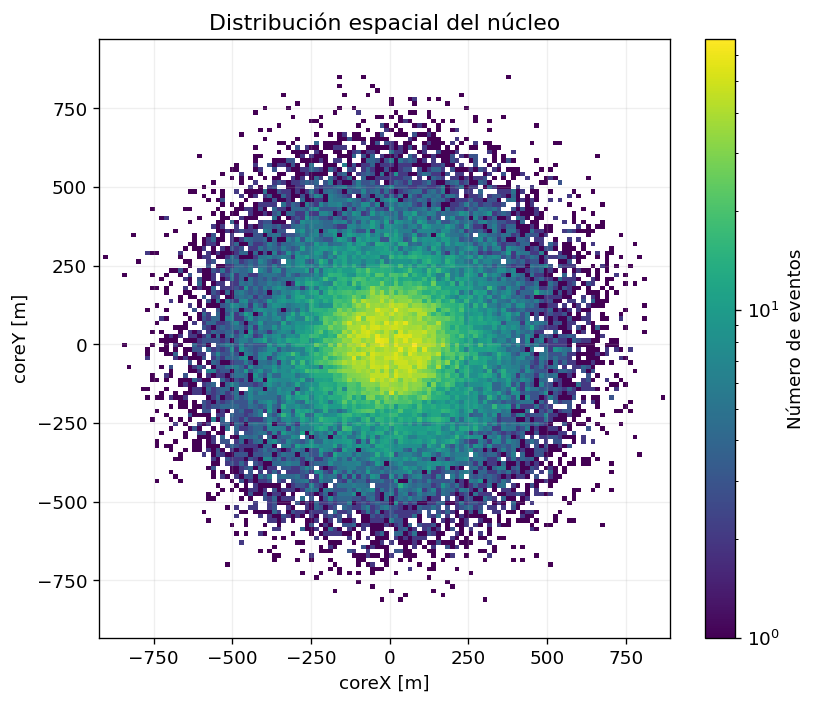

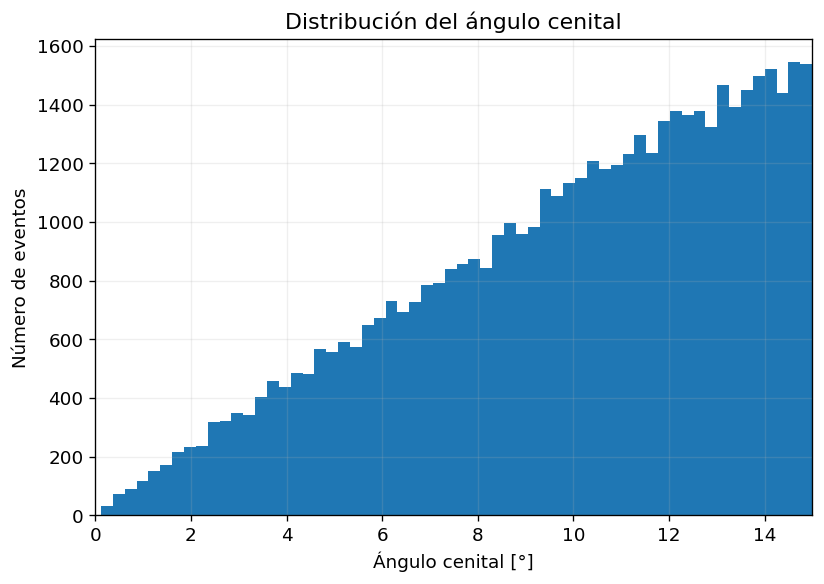

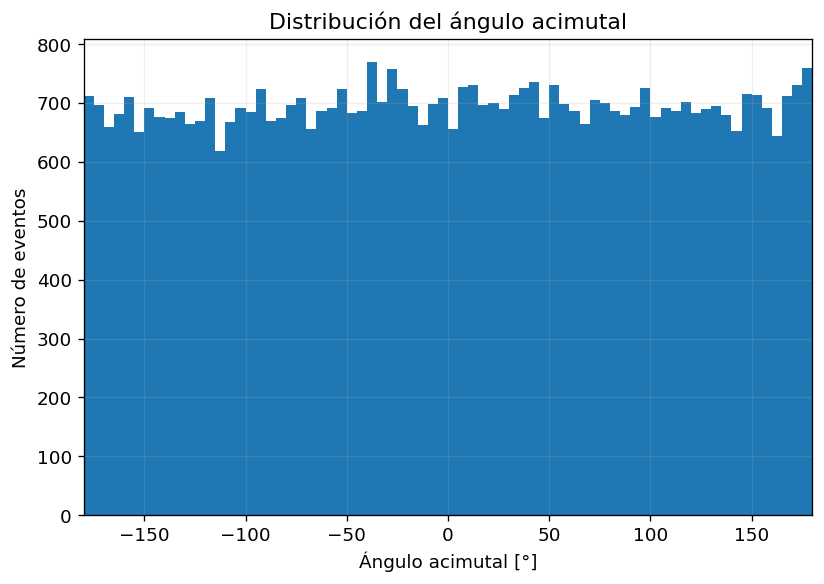

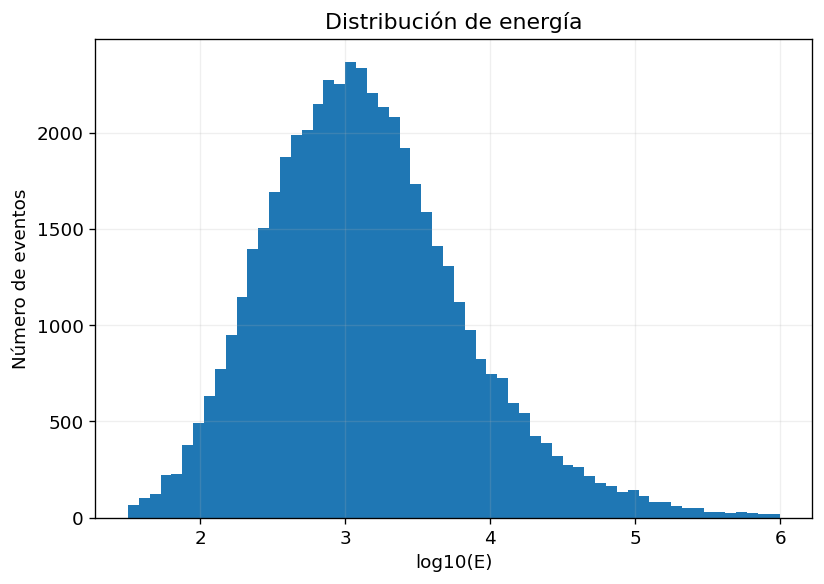

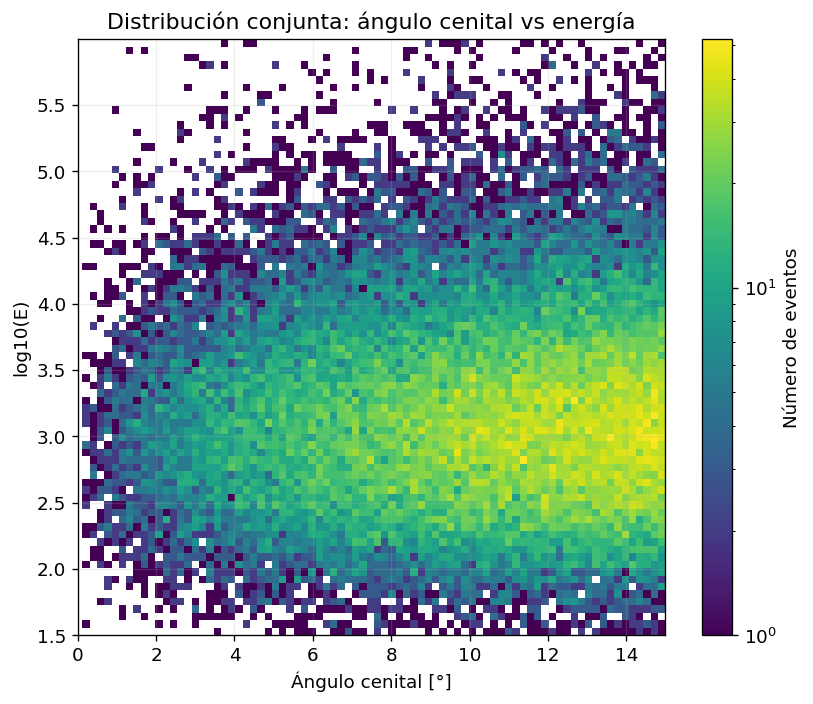


Physical-variable plots generated correctly.
  coreX/coreY     -> spatial distribution
  zenithAngle     -> reconstructed with arcsin(sinZenith)
  azimuthAngle    -> reconstructed with atan2(sinAzimuth, cosAzimuth)
  logEnergy       -> unchanged physical target


In [ ]:
# ── Recover and plot physical variables from trig-angle targets ──────────

from matplotlib.colors import LogNorm


def targets_to_physical(
    targets: np.ndarray,
) -> np.ndarray:
    """
    Convert the 6-dimensional trig-angle representation used by the network
    into the original physical variables.

    INPUT TARGET ORDER:
        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    OUTPUT PHYSICAL ORDER:
        [
            coreX,
            coreY,
            zenithAngle,
            azimuthAngle,
            logEnergy
        ]

    Angular reconstruction:
        zenithAngle = arcsin(sinZenith)

        azimuthAngle = atan2(
            sinAzimuth,
            cosAzimuth
        )

    Units:
        - coreX / coreY : m
        - zenithAngle   : rad
        - azimuthAngle  : rad
        - logEnergy     : log10(E)
    """

    ## CONVERTIR A ARRAY NUMPY ##
    arr = np.asarray(
        targets,
        dtype=np.float64,
    )


    ## PERMITIR TANTO UN SOLO EVENTO COMO UN ARRAY DE EVENTOS ##
    single_event = False

    if arr.ndim == 1:

        arr = arr[None, :]
        single_event = True


    ## COMPROBAR DIMENSIÓN ##
    if arr.ndim != 2 or arr.shape[1] != 6:

        raise ValueError(
            'Expected target shape (N, 6) or (6,), with order '
            '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]. '
            f'Got shape {arr.shape}.'
        )


    # ── EXTRAER VARIABLES ─────────────────────────────────────────────────

    core_x = arr[:, 0]
    core_y = arr[:, 1]

    sin_zenith = arr[:, 2]

    sin_azimuth = arr[:, 3]
    cos_azimuth = arr[:, 4]

    log_energy = arr[:, 5]


    # ── RECONSTRUIR ÁNGULO CENITAL ────────────────────────────────────────

    ## EVITAR PEQUEÑOS ERRORES NUMÉRICOS FUERA DEL DOMINIO DE arcsin ##
    sin_zenith_clipped = np.clip(
        sin_zenith,
        -1.0,
        1.0,
    )


    ## RECUPERAR EL ÁNGULO CENITAL EN RADIANES ##
    zenith = np.arcsin(
        sin_zenith_clipped
    )


    # ── RECONSTRUIR ACIMUT ────────────────────────────────────────────────

    ## CALCULAR LA NORMA DEL VECTOR CIRCULAR ##
    ##
    ## Para los targets Monte Carlo:
    ##
    ##     sqrt(sin²(phi) + cos²(phi)) = 1
    ##
    ## En las predicciones de la red puede existir una pequeña desviación,
    ## por lo que se normaliza antes de recuperar el ángulo.
    azimuth_norm = np.sqrt(
        sin_azimuth ** 2
        +
        cos_azimuth ** 2
    )


    ## EVITAR DIVISIÓN ENTRE CERO ##
    azimuth_norm_safe = np.where(
        azimuth_norm > 1e-12,
        azimuth_norm,
        1.0,
    )


    ## NORMALIZAR COMPONENTE SENO ##
    sin_azimuth_norm = (
        sin_azimuth
        /
        azimuth_norm_safe
    )


    ## NORMALIZAR COMPONENTE COSENO ##
    cos_azimuth_norm = (
        cos_azimuth
        /
        azimuth_norm_safe
    )


    ## RECUPERAR ACIMUT EN EL INTERVALO [-pi, +pi] ##
    azimuth = np.arctan2(
        sin_azimuth_norm,
        cos_azimuth_norm,
    )


    # ── CREAR ARRAY DE VARIABLES FÍSICAS ──────────────────────────────────

    physical = np.column_stack(
        [
            core_x,
            core_y,
            zenith,
            azimuth,
            log_energy,
        ]
    ).astype(
        np.float32
    )


    ## SI ENTRÓ UN ÚNICO EVENTO, DEVOLVER UN VECTOR ##
    if single_event:

        return physical[0]


    return physical


# ── Names of reconstructed physical variables ────────────────────────────

PHYSICAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


# ── Convert current Monte Carlo targets back to physical variables ───────

TARGETS_PHYSICAL = targets_to_physical(
    TARGETS
)


# ── General information ──────────────────────────────────────────────────

print('Physical target representation ready.')

print(
    f'  Input trig target shape : {TARGETS.shape}'
)

print(
    f'  Physical target shape   : {TARGETS_PHYSICAL.shape}'
)

print(
    f'  Physical target names   : {PHYSICAL_TARGET_NAMES}'
)


# ── Physical ranges ──────────────────────────────────────────────────────

print()
print('Physical variable ranges:')


## RANGO DE coreX ##
print(
    f'  coreX        : '
    f'{TARGETS_PHYSICAL[:, 0].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 0].max():.4f} m'
)


## RANGO DE coreY ##
print(
    f'  coreY        : '
    f'{TARGETS_PHYSICAL[:, 1].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 1].max():.4f} m'
)


## RANGO DEL ÁNGULO CENITAL ##
print(
    f'  zenithAngle  : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2].min()):.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2].max()):.4f} deg'
)


## RANGO DEL ACIMUT ##
print(
    f'  azimuthAngle : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3].min()):.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3].max()):.4f} deg'
)


## RANGO DE ENERGÍA ##
print(
    f'  logEnergy    : '
    f'{TARGETS_PHYSICAL[:, 4].min():.4f} '
    f'-> '
    f'{TARGETS_PHYSICAL[:, 4].max():.4f}'
)


# ── Angular representation checks ────────────────────────────────────────

print()
print('Angular representation checks:')


## NORMA DEL VECTOR ACIMUTAL ORIGINAL ##
azimuth_vector_norm = np.sqrt(
    TARGETS[:, 3] ** 2
    +
    TARGETS[:, 4] ** 2
)


print(
    f'  Azimuth vector norm : '
    f'min={azimuth_vector_norm.min():.6f}  '
    f'median={np.median(azimuth_vector_norm):.6f}  '
    f'max={azimuth_vector_norm.max():.6f}'
)


## COMPROBAR QUE EL CENIT RECONSTRUIDO RESPETA EL DOMINIO ##
print(
    f'  Zenith physical     : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2]).min():.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 2]).max():.4f} deg'
)


## COMPROBAR QUE EL ACIMUT CUBRE EL DOMINIO CIRCULAR ##
print(
    f'  Azimuth physical    : '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3]).min():.4f} '
    f'-> '
    f'{np.rad2deg(TARGETS_PHYSICAL[:, 3]).max():.4f} deg'
)


# ── Plot physical variables ──────────────────────────────────────────────


# ── FIGURA 1: DISTRIBUCIÓN ESPACIAL DEL CORE ─────────────────────────────

plt.figure(
    figsize=(7, 6)
)


plt.hist2d(
    TARGETS_PHYSICAL[:, 0],
    TARGETS_PHYSICAL[:, 1],
    bins=120,
    norm=LogNorm(),
)


plt.colorbar(
    label='Número de eventos'
)


plt.xlabel(
    'coreX [m]'
)


plt.ylabel(
    'coreY [m]'
)


plt.title(
    'Distribución espacial del núcleo'
)


plt.axis(
    'equal'
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# ── FIGURA 2: DISTRIBUCIÓN DEL ÁNGULO CENITAL ────────────────────────────

plt.figure(
    figsize=(7, 5)
)


zenith_deg = np.rad2deg(
    TARGETS_PHYSICAL[:, 2]
)


plt.hist(
    zenith_deg,
    bins=60,
)


plt.xlabel(
    'Ángulo cenital [°]'
)


plt.ylabel(
    'Número de eventos'
)


plt.title(
    'Distribución del ángulo cenital'
)


plt.xlim(
    0,
    15,
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# ── FIGURA 3: DISTRIBUCIÓN DEL ACIMUT ────────────────────────────────────

plt.figure(
    figsize=(7, 5)
)


azimuth_deg = np.rad2deg(
    TARGETS_PHYSICAL[:, 3]
)


plt.hist(
    azimuth_deg,
    bins=72,
)


plt.xlabel(
    'Ángulo acimutal [°]'
)


plt.ylabel(
    'Número de eventos'
)


plt.title(
    'Distribución del ángulo acimutal'
)


plt.xlim(
    -180,
    180,
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# ── FIGURA 4: DISTRIBUCIÓN DE ENERGÍA ────────────────────────────────────

plt.figure(
    figsize=(7, 5)
)


plt.hist(
    TARGETS_PHYSICAL[:, 4],
    bins=60,
)


plt.xlabel(
    'log10(E)'
)


plt.ylabel(
    'Número de eventos'
)


plt.title(
    'Distribución de energía'
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# ── FIGURA 5: ÁNGULO CENITAL VS ENERGÍA ─────────────────────────────────

plt.figure(
    figsize=(7, 6)
)


plt.hist2d(
    zenith_deg,
    TARGETS_PHYSICAL[:, 4],
    bins=80,
    norm=LogNorm(),
)


plt.colorbar(
    label='Número de eventos'
)


plt.xlabel(
    'Ángulo cenital [°]'
)


plt.ylabel(
    'log10(E)'
)


plt.title(
    'Distribución conjunta: ángulo cenital vs energía'
)


plt.xlim(
    0,
    15,
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# ── Final confirmation ───────────────────────────────────────────────────

print()
print('Physical-variable plots generated correctly.')

print(
    '  coreX/coreY     -> spatial distribution'
)

print(
    '  zenithAngle     -> reconstructed with arcsin(sinZenith)'
)

print(
    '  azimuthAngle    -> reconstructed with atan2(sinAzimuth, cosAzimuth)'
)

print(
    '  logEnergy       -> unchanged physical target'
)

In [ ]:
###############################################################################
## EVALUACIÓN DE REFERENCIA MEDIANTE RECONSTRUCCIONES CONVENCIONALES
##
## UBICACIÓN EN EL NOTEBOOK:
##
## Ejecutar esta celda inmediatamente después de cargar y limpiar:
##
##     HIT_ARRAYS
##     TARGETS
##     EVENT_IDS
##     RUN_IDS
##
## y después de haber definido:
##
##     targets_to_physical()
##
## pero antes de:
##
##     - dividir los eventos en entrenamiento, validación y prueba;
##     - ajustar los StandardScaler;
##     - construir la arquitectura;
##     - entrenar el modelo.
##
## OBJETIVO:
##
## Evaluar las reconstrucciones convencionales disponibles en el fichero ROOT
## frente a los valores verdaderos de la simulación Monte Carlo.
##
## Las reconstrucciones convencionales NO se utilizan como entradas de la red.
## Se almacenan únicamente como baseline para compararlas posteriormente con
## DeepSets + Conditional Normalizing Flow sobre los mismos eventos de test.
##
## IMPORTANTE:
##
## La red utiliza internamente seis targets:
##
##     [
##         coreX,
##         coreY,
##         sinZenith,
##         sinAzimuth,
##         cosAzimuth,
##         logEnergy
##     ]
##
## Para la comparación física se recuperan las cinco variables originales:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
##
## PARAMETRIZACIÓN ANGULAR INTERNA:
##
##     zenithAngle  -> sinZenith
##
##     azimuthAngle -> sinAzimuth, cosAzimuth
##
## El cénit NO utiliza cosZenith en la representación interna actual.
## El acimut sí utiliza seno y coseno para evitar la discontinuidad
## asociada a la periodicidad angular.
##
## RECONSTRUCCIÓN ANGULAR CONVENCIONAL:
##
##     planeFit2.theta
##     planeFit2.phi
##
## Estas ramas fueron validadas previamente comprobando que la separación
## angular calculada reproduce mc.delAngle con diferencias despreciables.
##
## NO SE UTILIZAN DURANTE EL ENTRENAMIENTO.
##
## RESULTADOS GENERADOS:
##
##     - BASELINE_TEMPLATE_POINT
##     - BASELINE_TEMPLATE_AVAILABLE
##     - BASELINE_TEMPLATE_DF
##     - BASELINE_METRICS_BY_TARGET
##     - BASELINE_PHYSICAL_METRICS
##
## ARCHIVOS GUARDADOS:
##
##     - conventional_baseline_events.csv
##     - conventional_baseline_arrays.npz
##     - conventional_baseline_metrics_by_target.csv
##     - conventional_baseline_physical_metrics.csv
##     - conventional_baseline_distributions.png
##     - conventional_baseline_truth_vs_reco.png
##     - conventional_baseline_vs_energy.png
###############################################################################


###############################################################################
## 1. IMPORTACIONES
###############################################################################

from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

from tqdm.auto import tqdm


###############################################################################
## 2. COMPROBACIÓN DE VARIABLES NECESARIAS
###############################################################################

REQUIRED_BASELINE_GLOBALS = [
    "CFG",
    "TARGETS",
    "EVENT_IDS",
    "RUN_IDS",
    "targets_to_physical",
]


MISSING_BASELINE_GLOBALS = [
    variable_name
    for variable_name in REQUIRED_BASELINE_GLOBALS
    if variable_name not in globals()
]


if MISSING_BASELINE_GLOBALS:

    raise NameError(
        "No puede ejecutarse el baseline porque faltan "
        "las siguientes variables o funciones:\n"
        + "\n".join(
            f"  - {variable_name}"
            for variable_name in MISSING_BASELINE_GLOBALS
        )
    )


if not Path(CFG["root_file"]).exists():

    raise FileNotFoundError(
        "No se ha encontrado el fichero ROOT necesario para leer "
        "las reconstrucciones convencionales:\n"
        f'{CFG["root_file"]}'
    )


if CFG.get("tree_name", None) is None:

    raise ValueError(
        'CFG["tree_name"] es None. Debe ejecutarse primero la inspección '
        "y detección del árbol ROOT."
    )


###############################################################################
## 3. DEFINICIÓN DE LOS TARGETS FÍSICOS PARA EL BASELINE
##
## REPRESENTACIÓN INTERNA DE LA RED:
##
##     [
##         coreX,
##         coreY,
##         sinZenith,
##         sinAzimuth,
##         cosAzimuth,
##         logEnergy
##     ]
##
## REPRESENTACIÓN FÍSICA PARA LA COMPARACIÓN:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
###############################################################################

BASELINE_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


BASELINE_TARGET_UNITS = [
    "m",
    "m",
    "rad",
    "rad",
    "log10(E)",
]


BASELINE_TARGET_LABELS = {
    "coreX": r"$x_{\mathrm{core}}$",
    "coreY": r"$y_{\mathrm{core}}$",
    "zenithAngle": r"$\theta$",
    "azimuthAngle": r"$\phi$",
    "logEnergy": r"$\log_{10}(E)$",
}


## COPIA DE LOS TARGETS INTERNOS DE LA RED ##
TARGETS_INTERNAL_BASELINE = np.asarray(
    TARGETS,
    dtype=np.float64,
)


if TARGETS_INTERNAL_BASELINE.ndim != 2:

    raise ValueError(
        "TARGETS debe ser una matriz bidimensional. "
        f"Forma recibida: {TARGETS_INTERNAL_BASELINE.shape}"
    )


## COMPROBAR QUE SE USA LA NUEVA REPRESENTACIÓN DE SEIS TARGETS ##
if TARGETS_INTERNAL_BASELINE.shape[1] != 6:

    raise ValueError(
        "El baseline actual requiere la representación interna de seis targets:\n"
        "\n"
        "    [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]\n"
        "\n"
        f"Forma recibida: {TARGETS_INTERNAL_BASELINE.shape}"
    )


## RECUPERAR LAS CINCO VARIABLES FÍSICAS ORIGINALES ##
BASELINE_TARGETS_TRUE = targets_to_physical(
    TARGETS_INTERNAL_BASELINE
).astype(
    np.float64
)


if BASELINE_TARGETS_TRUE.shape[1] != len(BASELINE_TARGET_NAMES):

    raise ValueError(
        "La conversión a variables físicas no ha producido las cinco "
        "magnitudes esperadas.\n"
        f"Forma obtenida: {BASELINE_TARGETS_TRUE.shape}\n"
        f"Targets físicos esperados: {BASELINE_TARGET_NAMES}"
    )


if len(EVENT_IDS) != len(BASELINE_TARGETS_TRUE):

    raise ValueError(
        "EVENT_IDS y TARGETS no tienen la misma longitud.\n"
        f"EVENT_IDS: {len(EVENT_IDS)}\n"
        f"TARGETS  : {len(BASELINE_TARGETS_TRUE)}"
    )


if len(RUN_IDS) != len(BASELINE_TARGETS_TRUE):

    raise ValueError(
        "RUN_IDS y TARGETS no tienen la misma longitud.\n"
        f"RUN_IDS: {len(RUN_IDS)}\n"
        f"TARGETS: {len(BASELINE_TARGETS_TRUE)}"
    )


print()
print("============================================================")
print(" TARGETS FÍSICOS UTILIZADOS PARA EL BASELINE")
print("============================================================")
print()

print(
    f"  Targets internos : {TARGETS_INTERNAL_BASELINE.shape}"
)

print(
    f"  Targets físicos  : {BASELINE_TARGETS_TRUE.shape}"
)

print(
    f"  Variables        : {BASELINE_TARGET_NAMES}"
)

print(
    "  Zenith           : "
    f"{np.rad2deg(BASELINE_TARGETS_TRUE[:, 2]).min():.4f} "
    "-> "
    f"{np.rad2deg(BASELINE_TARGETS_TRUE[:, 2]).max():.4f} deg"
)

print(
    "  Azimuth          : "
    f"{np.rad2deg(BASELINE_TARGETS_TRUE[:, 3]).min():.4f} "
    "-> "
    f"{np.rad2deg(BASELINE_TARGETS_TRUE[:, 3]).max():.4f} deg"
)


###############################################################################
## 4. FUNCIONES AUXILIARES PARA LOCALIZAR RAMAS
###############################################################################

def normalize_uproot_branch_name(branch_name: str) -> str:
    """
    Elimina el posible sufijo ';1' añadido por ROOT/uproot.
    """

    return str(branch_name).split(";")[0]


def get_available_branches(tree) -> set:
    """
    Devuelve los nombres de las ramas disponibles sin ciclos ROOT.
    """

    return {
        normalize_uproot_branch_name(branch_name)
        for branch_name in tree.keys()
    }


def select_first_existing_branch(
    available_branches: set,
    candidates: Sequence[str],
    role: str,
    required: bool = True,
) -> Optional[str]:
    """
    Selecciona la primera rama existente entre varios nombres candidatos.
    """

    for candidate in candidates:

        if candidate in available_branches:
            return candidate


    if required:

        raise KeyError(
            f"No se encontró ninguna rama compatible para '{role}'.\n"
            "Candidatos comprobados:\n"
            + "\n".join(
                f"  - {candidate}"
                for candidate in candidates
            )
        )


    print(
        f"[WARN] No se encontró una rama para '{role}'. "
        "Esta magnitud quedará marcada como no disponible."
    )

    return None


###############################################################################
## 5. LOCALIZACIÓN DE LAS RAMAS DE RECONSTRUCCIÓN CONVENCIONAL
##
## CORE Y ENERGÍA:
##
##     Se utilizan las reconstrucciones convencionales almacenadas en rec.*
##
## DIRECCIÓN:
##
##     Se utilizan EXPLÍCITAMENTE:
##
##         planeFit2.theta
##         planeFit2.phi
##
##     Estas ramas fueron validadas previamente frente a mc.delAngle.
##
## IMPORTANTE:
##
##     rec.zenithAngle y rec.azimuthAngle NO se utilizan porque se comprobó
##     que contienen valores nulos en los eventos inspeccionados.
###############################################################################

with uproot.open(
    CFG["root_file"]
) as root_file:

    tree = root_file[
        CFG["tree_name"]
    ]

    available_branches = get_available_branches(
        tree
    )


BRANCH_RUN_ID = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG["branches"].get(
            "runID",
            "event.runID",
        ),
        "event.runID",
        "runID",
    ],
    role="runID",
)


BRANCH_EVENT_ID = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG["branches"].get(
            "eventID",
            "event.eventID",
        ),
        "event.eventID",
        "eventID",
    ],
    role="eventID",
)


BRANCH_TEMPLATE_CORE_X = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.coreX",
        "rec.coreFitX",
        "rec.coreFit.x",
        "rec.X",
    ],
    role="coreX reconstruido",
)


BRANCH_TEMPLATE_CORE_Y = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.coreY",
        "rec.coreFitY",
        "rec.coreFit.y",
        "rec.Y",
    ],
    role="coreY reconstruido",
)


## RECONSTRUCCIÓN ANGULAR CONVENCIONAL VALIDADA ##
BRANCH_TEMPLATE_ZENITH = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        "planeFit2.theta",
    ],
    role="ángulo cenital reconstruido mediante planeFit2",
    required=True,
)


BRANCH_TEMPLATE_AZIMUTH = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        "planeFit2.phi",
    ],
    role="ángulo acimutal reconstruido mediante planeFit2",
    required=True,
)


## mc.delAngle SE UTILIZA ÚNICAMENTE COMO VARIABLE DE CONTROL ##
BRANCH_MC_DEL_ANGLE = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        "mc.delAngle",
    ],
    role="separación angular Monte Carlo / planeFit2",
    required=False,
)


BRANCH_TEMPLATE_ENERGY = select_first_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG["branches"].get(
            "rec_energy",
            "rec.LHLatDistFitEnergy",
        ),
        "rec.LHLatDistFitEnergy",
        "rec.logEnergy",
        "rec.energy",
    ],
    role="energía reconstruida",
)


print()
print("============================================================")
print(" RAMAS UTILIZADAS PARA EL BASELINE CONVENCIONAL")
print("============================================================")
print()

print(
    f"  runID          : {BRANCH_RUN_ID}"
)

print(
    f"  eventID        : {BRANCH_EVENT_ID}"
)

print(
    f"  coreX          : {BRANCH_TEMPLATE_CORE_X}"
)

print(
    f"  coreY          : {BRANCH_TEMPLATE_CORE_Y}"
)

print(
    f"  zenithAngle    : {BRANCH_TEMPLATE_ZENITH}"
)

print(
    f"  azimuthAngle   : {BRANCH_TEMPLATE_AZIMUTH}"
)

print(
    f"  mc.delAngle    : {BRANCH_MC_DEL_ANGLE}"
)

print(
    f"  logEnergy      : {BRANCH_TEMPLATE_ENERGY}"
)

print()
print(
    "  [INFO] planeFit2.theta / planeFit2.phi se utilizan "
    "SOLO como referencia angular final."
)

print(
    "  [INFO] Ninguna reconstrucción convencional se utiliza "
    "como entrada de la red."
)


###############################################################################
## 6. TABLA DE IDENTIFICADORES DE LOS EVENTOS CARGADOS
##
## La columna baseline_order conserva el orden exacto de TARGETS.
###############################################################################

BASELINE_EVENT_IDS_DF = pd.DataFrame({
    "baseline_order": np.arange(
        len(BASELINE_TARGETS_TRUE),
        dtype=np.int64,
    ),

    "runID": np.asarray(
        RUN_IDS
    ),

    "eventID": np.asarray(
        EVENT_IDS
    ),
})


duplicate_loaded_ids = BASELINE_EVENT_IDS_DF.duplicated(
    subset=[
        "runID",
        "eventID",
    ],
    keep=False,
)


if duplicate_loaded_ids.any():

    duplicated_table = BASELINE_EVENT_IDS_DF.loc[
        duplicate_loaded_ids,
        [
            "runID",
            "eventID",
        ],
    ]

    raise ValueError(
        "Existen identificadores (runID, eventID) duplicados en el "
        "dataset cargado. No puede garantizarse una alineación inequívoca.\n"
        f"Primeros duplicados:\n{duplicated_table.head(10)}"
    )


###############################################################################
## 7. LECTURA DEL ROOT Y SELECCIÓN DE LOS EVENTOS CARGADOS
##
## No se carga todo el fichero simultáneamente.
##
## Se recorre por fragmentos y solo se conservan los eventos cuyo par
## (runID, eventID) se encuentra entre los 50.000 eventos seleccionados.
###############################################################################

branches_to_read = [
    BRANCH_RUN_ID,
    BRANCH_EVENT_ID,

    BRANCH_TEMPLATE_CORE_X,
    BRANCH_TEMPLATE_CORE_Y,

    BRANCH_TEMPLATE_ZENITH,
    BRANCH_TEMPLATE_AZIMUTH,

    BRANCH_TEMPLATE_ENERGY,
]


if BRANCH_MC_DEL_ANGLE is not None:

    branches_to_read.append(
        BRANCH_MC_DEL_ANGLE
    )


## ELIMINAR NOMBRES REPETIDOS MANTENIENDO EL ORDEN ##
branches_to_read = list(
    dict.fromkeys(
        branches_to_read
    )
)


loaded_event_key_index = pd.MultiIndex.from_frame(
    BASELINE_EVENT_IDS_DF[
        [
            "runID",
            "eventID",
        ]
    ]
)


baseline_chunks: List[pd.DataFrame] = []


with uproot.open(
    CFG["root_file"]
) as root_file:

    tree = root_file[
        CFG["tree_name"]
    ]


    iterator = tree.iterate(
        branches_to_read,
        step_size=CFG.get(
            "uproot_step_size",
            "100 MB",
        ),
        library="np",
    )


    for root_arrays in tqdm(
        iterator,
        desc="Leyendo reconstrucciones convencionales",
    ):

        chunk_run_ids = np.asarray(
            root_arrays[
                BRANCH_RUN_ID
            ]
        )


        chunk_event_ids = np.asarray(
            root_arrays[
                BRANCH_EVENT_ID
            ]
        )


        chunk_key_index = pd.MultiIndex.from_arrays(
            [
                chunk_run_ids,
                chunk_event_ids,
            ],
            names=[
                "runID",
                "eventID",
            ],
        )


        keep_chunk_mask = chunk_key_index.isin(
            loaded_event_key_index
        )


        if not np.any(
            keep_chunk_mask
        ):
            continue


        n_selected_chunk = int(
            np.sum(
                keep_chunk_mask
            )
        )


        chunk_dictionary = {

            "runID": chunk_run_ids[
                keep_chunk_mask
            ],

            "eventID": chunk_event_ids[
                keep_chunk_mask
            ],

            "template_coreX": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_CORE_X
                ]
            )[
                keep_chunk_mask
            ],

            "template_coreY": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_CORE_Y
                ]
            )[
                keep_chunk_mask
            ],

            "template_zenithAngle": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_ZENITH
                ]
            )[
                keep_chunk_mask
            ],

            "template_azimuthAngle": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_AZIMUTH
                ]
            )[
                keep_chunk_mask
            ],

            "template_logEnergy": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_ENERGY
                ]
            )[
                keep_chunk_mask
            ],
        }


        ## mc.delAngle ES OPCIONAL Y SOLO SE UTILIZA COMO CONTROL ##
        if BRANCH_MC_DEL_ANGLE is not None:

            chunk_dictionary[
                "mc_delAngle"
            ] = np.asarray(
                root_arrays[
                    BRANCH_MC_DEL_ANGLE
                ]
            )[
                keep_chunk_mask
            ]

        else:

            chunk_dictionary[
                "mc_delAngle"
            ] = np.full(
                n_selected_chunk,
                np.nan,
                dtype=np.float64,
            )


        baseline_chunks.append(
            pd.DataFrame(
                chunk_dictionary
            )
        )


if not baseline_chunks:

    raise RuntimeError(
        "No se encontró ninguna reconstrucción convencional para los "
        "eventos cargados. Comprueba runID, eventID y el árbol ROOT."
    )


BASELINE_TEMPLATE_RAW_DF = pd.concat(
    baseline_chunks,
    ignore_index=True,
)


###############################################################################
## 8. GESTIÓN DE DUPLICADOS DEL ROOT
###############################################################################

duplicate_root_ids = BASELINE_TEMPLATE_RAW_DF.duplicated(
    subset=[
        "runID",
        "eventID",
    ],
    keep=False,
)


if duplicate_root_ids.any():

    number_duplicate_rows = int(
        duplicate_root_ids.sum()
    )


    print()

    print(
        "[WARN] Se encontraron "
        f"{number_duplicate_rows} filas con identificadores duplicados "
        "en el ROOT."
    )

    print(
        "       Se conservará la primera aparición de cada evento."
    )


    BASELINE_TEMPLATE_RAW_DF = (
        BASELINE_TEMPLATE_RAW_DF
        .drop_duplicates(
            subset=[
                "runID",
                "eventID",
            ],
            keep="first",
        )
        .reset_index(
            drop=True
        )
    )


###############################################################################
## 9. ALINEACIÓN EXACTA CON TARGETS
###############################################################################

BASELINE_TEMPLATE_DF = BASELINE_EVENT_IDS_DF.merge(
    BASELINE_TEMPLATE_RAW_DF,
    on=[
        "runID",
        "eventID",
    ],
    how="left",
    validate="one_to_one",
)


BASELINE_TEMPLATE_DF = (
    BASELINE_TEMPLATE_DF
    .sort_values(
        "baseline_order"
    )
    .reset_index(
        drop=True
    )
)


if len(
    BASELINE_TEMPLATE_DF
) != len(
    BASELINE_TARGETS_TRUE
):

    raise RuntimeError(
        "La tabla del baseline alineada no conserva el número total "
        "de eventos cargados."
    )


###############################################################################
## 10. CONSTRUCCIÓN DE LA MATRIZ DE RECONSTRUCCIONES CONVENCIONALES
##
## IMPORTANTE:
##
## Esta matriz utiliza SIEMPRE las cinco variables FÍSICAS:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
##
## No utiliza la representación trigonométrica interna de la red.
###############################################################################

BASELINE_TEMPLATE_POINT = np.column_stack([

    BASELINE_TEMPLATE_DF[
        "template_coreX"
    ].to_numpy(
        dtype=np.float64
    ),

    BASELINE_TEMPLATE_DF[
        "template_coreY"
    ].to_numpy(
        dtype=np.float64
    ),

    BASELINE_TEMPLATE_DF[
        "template_zenithAngle"
    ].to_numpy(
        dtype=np.float64
    ),

    BASELINE_TEMPLATE_DF[
        "template_azimuthAngle"
    ].to_numpy(
        dtype=np.float64
    ),

    BASELINE_TEMPLATE_DF[
        "template_logEnergy"
    ].to_numpy(
        dtype=np.float64
    ),
])


if BASELINE_TEMPLATE_POINT.shape != BASELINE_TARGETS_TRUE.shape:

    raise ValueError(
        "La forma de BASELINE_TEMPLATE_POINT no coincide con los "
        "targets físicos Monte Carlo.\n"
        f"Baseline : {BASELINE_TEMPLATE_POINT.shape}\n"
        f"Monte Carlo: {BASELINE_TARGETS_TRUE.shape}"
    )


###############################################################################
## 11. DISPONIBILIDAD DE CADA VARIABLE
###############################################################################

BASELINE_TEMPLATE_AVAILABLE = np.isfinite(
    BASELINE_TEMPLATE_POINT
)


print()
print("============================================================")
print(" DISPONIBILIDAD DE RECONSTRUCCIONES CONVENCIONALES")
print("============================================================")
print()


for target_index, target_name in enumerate(
    BASELINE_TARGET_NAMES
):

    number_available = int(
        BASELINE_TEMPLATE_AVAILABLE[
            :,
            target_index,
        ].sum()
    )


    availability_percentage = (
        100.0
        *
        number_available
        /
        len(
            BASELINE_TEMPLATE_POINT
        )
    )


    print(
        f"  {target_name:<14}: "
        f"{number_available:>7} / "
        f"{len(BASELINE_TEMPLATE_POINT):>7} "
        f"({availability_percentage:6.2f} %)"
    )


###############################################################################
## 12. FUNCIONES PARA EL CÁLCULO DE ERRORES
###############################################################################

def wrapped_angular_residual(
    prediction: np.ndarray,
    truth: np.ndarray,
) -> np.ndarray:
    """
    Calcula el residuo de un ángulo periódico en [-pi, pi].
    """

    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )


    truth = np.asarray(
        truth,
        dtype=np.float64,
    )


    return np.arctan2(
        np.sin(
            prediction - truth
        ),
        np.cos(
            prediction - truth
        ),
    )


def spherical_angular_separation_degrees(
    zenith_prediction: np.ndarray,
    azimuth_prediction: np.ndarray,
    zenith_truth: np.ndarray,
    azimuth_truth: np.ndarray,
) -> np.ndarray:
    """
    Calcula la separación angular entre dos direcciones esféricas.

    Los ángulos de entrada se expresan en radianes.
    La separación angular se devuelve en grados.
    """

    zenith_prediction = np.asarray(
        zenith_prediction,
        dtype=np.float64,
    )


    azimuth_prediction = np.asarray(
        azimuth_prediction,
        dtype=np.float64,
    )


    zenith_truth = np.asarray(
        zenith_truth,
        dtype=np.float64,
    )


    azimuth_truth = np.asarray(
        azimuth_truth,
        dtype=np.float64,
    )


    cosine_separation = (
        np.cos(
            zenith_prediction
        )
        *
        np.cos(
            zenith_truth
        )
        +
        np.sin(
            zenith_prediction
        )
        *
        np.sin(
            zenith_truth
        )
        *
        np.cos(
            azimuth_prediction
            -
            azimuth_truth
        )
    )


    cosine_separation = np.clip(
        cosine_separation,
        -1.0,
        1.0,
    )


    return np.rad2deg(
        np.arccos(
            cosine_separation
        )
    )


def residual_metrics(
    residual: np.ndarray,
) -> Dict[str, float]:
    """
    Calcula métricas para un residuo con signo.
    """

    residual = np.asarray(
        residual,
        dtype=np.float64,
    )


    residual = residual[
        np.isfinite(
            residual
        )
    ]


    if residual.size == 0:

        return {
            "n_events": 0,
            "bias": np.nan,
            "std": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "median_abs_error": np.nan,
            "p68_abs_error": np.nan,
            "p95_abs_error": np.nan,
        }


    absolute_residual = np.abs(
        residual
    )


    return {

        "n_events": int(
            residual.size
        ),

        "bias": float(
            np.mean(
                residual
            )
        ),

        "std": float(
            np.std(
                residual
            )
        ),

        "mae": float(
            np.mean(
                absolute_residual
            )
        ),

        "rmse": float(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
        ),

        "median_abs_error": float(
            np.median(
                absolute_residual
            )
        ),

        "p68_abs_error": float(
            np.percentile(
                absolute_residual,
                68,
            )
        ),

        "p95_abs_error": float(
            np.percentile(
                absolute_residual,
                95,
            )
        ),
    }


def positive_error_metrics(
    error: np.ndarray,
) -> Dict[str, float]:
    """
    Calcula métricas para una magnitud de error siempre positiva.
    """

    error = np.asarray(
        error,
        dtype=np.float64,
    )


    error = error[
        np.isfinite(
            error
        )
    ]


    if error.size == 0:

        return {
            "n_events": 0,
            "mean": np.nan,
            "std": np.nan,
            "rmse": np.nan,
            "median": np.nan,
            "p68": np.nan,
            "p95": np.nan,
        }


    return {

        "n_events": int(
            error.size
        ),

        "mean": float(
            np.mean(
                error
            )
        ),

        "std": float(
            np.std(
                error
            )
        ),

        "rmse": float(
            np.sqrt(
                np.mean(
                    error ** 2
                )
            )
        ),

        "median": float(
            np.median(
                error
            )
        ),

        "p68": float(
            np.percentile(
                error,
                68,
            )
        ),

        "p95": float(
            np.percentile(
                error,
                95,
            )
        ),
    }


def calculate_binned_quantiles(
    x_values: np.ndarray,
    y_values: np.ndarray,
    number_bins: int = 10,
    minimum_events: int = 20,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Calcula percentiles 16, 50 y 84 de y en intervalos de x.
    """

    x_values = np.asarray(
        x_values,
        dtype=np.float64,
    )


    y_values = np.asarray(
        y_values,
        dtype=np.float64,
    )


    finite_mask = (
        np.isfinite(
            x_values
        )
        &
        np.isfinite(
            y_values
        )
    )


    x_values = x_values[
        finite_mask
    ]


    y_values = y_values[
        finite_mask
    ]


    if x_values.size == 0:

        empty_array = np.array(
            [],
            dtype=np.float64,
        )

        return (
            empty_array,
            empty_array,
            empty_array,
            empty_array,
            empty_array,
        )


    bin_edges = np.linspace(
        np.min(
            x_values
        ),
        np.max(
            x_values
        ),
        number_bins + 1,
    )


    bin_centers = 0.5 * (
        bin_edges[:-1]
        +
        bin_edges[1:]
    )


    selected_centers = []
    percentile_16 = []
    percentile_50 = []
    percentile_84 = []
    event_counts = []


    for bin_index, bin_center in enumerate(
        bin_centers
    ):

        lower_edge = bin_edges[
            bin_index
        ]


        upper_edge = bin_edges[
            bin_index + 1
        ]


        if bin_index == len(
            bin_centers
        ) - 1:

            bin_mask = (
                (x_values >= lower_edge)
                &
                (x_values <= upper_edge)
            )

        else:

            bin_mask = (
                (x_values >= lower_edge)
                &
                (x_values < upper_edge)
            )


        number_events = int(
            bin_mask.sum()
        )


        if number_events < minimum_events:
            continue


        q16, q50, q84 = np.percentile(
            y_values[
                bin_mask
            ],
            [
                16,
                50,
                84,
            ],
        )


        selected_centers.append(
            bin_center
        )


        percentile_16.append(
            q16
        )


        percentile_50.append(
            q50
        )


        percentile_84.append(
            q84
        )


        event_counts.append(
            number_events
        )


    return (

        np.asarray(
            selected_centers
        ),

        np.asarray(
            percentile_16
        ),

        np.asarray(
            percentile_50
        ),

        np.asarray(
            percentile_84
        ),

        np.asarray(
            event_counts
        ),
    )


###############################################################################
## 13. MÉTRICAS INDIVIDUALES POR TARGET
###############################################################################

baseline_target_metric_rows = []


for target_index, (
    target_name,
    target_unit,
) in enumerate(
    zip(
        BASELINE_TARGET_NAMES,
        BASELINE_TARGET_UNITS,
    )
):

    true_target = BASELINE_TARGETS_TRUE[
        :,
        target_index,
    ]


    template_target = BASELINE_TEMPLATE_POINT[
        :,
        target_index,
    ]


    valid_target_mask = (
        np.isfinite(
            true_target
        )
        &
        np.isfinite(
            template_target
        )
    )


    ## EL ACIMUT ES PERIÓDICO Y REQUIERE RESIDUO CIRCULAR ##
    if target_name == "azimuthAngle":

        target_residual = wrapped_angular_residual(

            template_target[
                valid_target_mask
            ],

            true_target[
                valid_target_mask
            ],
        )


    else:

        target_residual = (
            template_target[
                valid_target_mask
            ]
            -
            true_target[
                valid_target_mask
            ]
        )


    target_statistics = residual_metrics(
        target_residual
    )


    baseline_target_metric_rows.append({

        "variable": target_name,

        "unidad": target_unit,

        **target_statistics,
    })


BASELINE_METRICS_BY_TARGET = pd.DataFrame(
    baseline_target_metric_rows
)


print()
print("============================================================")
print(" MÉTRICAS CONVENCIONALES POR VARIABLE")
print("============================================================")
print()


display(
    BASELINE_METRICS_BY_TARGET.style.format({

        "bias": "{:.6g}",

        "std": "{:.6g}",

        "mae": "{:.6g}",

        "rmse": "{:.6g}",

        "median_abs_error": "{:.6g}",

        "p68_abs_error": "{:.6g}",

        "p95_abs_error": "{:.6g}",
    })
)


###############################################################################
## 14. MAGNITUDES FÍSICAS COMPUESTAS
###############################################################################

index_core_x = BASELINE_TARGET_NAMES.index(
    "coreX"
)


index_core_y = BASELINE_TARGET_NAMES.index(
    "coreY"
)


index_zenith = BASELINE_TARGET_NAMES.index(
    "zenithAngle"
)


index_azimuth = BASELINE_TARGET_NAMES.index(
    "azimuthAngle"
)


index_energy = BASELINE_TARGET_NAMES.index(
    "logEnergy"
)


# -------------------------------------------------------------------------
# Posición verdadera y reconstruida del núcleo.
# -------------------------------------------------------------------------

true_core_x = BASELINE_TARGETS_TRUE[
    :,
    index_core_x,
]


true_core_y = BASELINE_TARGETS_TRUE[
    :,
    index_core_y,
]


template_core_x = BASELINE_TEMPLATE_POINT[
    :,
    index_core_x,
]


template_core_y = BASELINE_TEMPLATE_POINT[
    :,
    index_core_y,
]


valid_core_mask = (
    np.isfinite(
        true_core_x
    )
    &
    np.isfinite(
        true_core_y
    )
    &
    np.isfinite(
        template_core_x
    )
    &
    np.isfinite(
        template_core_y
    )
)


true_core_radius = np.sqrt(
    true_core_x ** 2
    +
    true_core_y ** 2
)


template_core_radius = np.sqrt(
    template_core_x ** 2
    +
    template_core_y ** 2
)


template_core_spatial_error = np.full(
    len(
        BASELINE_TARGETS_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


template_core_spatial_error[
    valid_core_mask
] = np.sqrt(
    (
        template_core_x[
            valid_core_mask
        ]
        -
        true_core_x[
            valid_core_mask
        ]
    ) ** 2
    +
    (
        template_core_y[
            valid_core_mask
        ]
        -
        true_core_y[
            valid_core_mask
        ]
    ) ** 2
)


template_core_radial_residual = np.full(
    len(
        BASELINE_TARGETS_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


template_core_radial_residual[
    valid_core_mask
] = (
    template_core_radius[
        valid_core_mask
    ]
    -
    true_core_radius[
        valid_core_mask
    ]
)


# -------------------------------------------------------------------------
# Dirección verdadera y reconstruida mediante planeFit2.
# -------------------------------------------------------------------------

true_zenith = BASELINE_TARGETS_TRUE[
    :,
    index_zenith,
]


true_azimuth = BASELINE_TARGETS_TRUE[
    :,
    index_azimuth,
]


template_zenith = BASELINE_TEMPLATE_POINT[
    :,
    index_zenith,
]


template_azimuth = BASELINE_TEMPLATE_POINT[
    :,
    index_azimuth,
]


valid_direction_mask = (
    np.isfinite(
        true_zenith
    )
    &
    np.isfinite(
        true_azimuth
    )
    &
    np.isfinite(
        template_zenith
    )
    &
    np.isfinite(
        template_azimuth
    )
)


template_angular_error_deg = np.full(
    len(
        BASELINE_TARGETS_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


if np.any(
    valid_direction_mask
):

    template_angular_error_deg[
        valid_direction_mask
    ] = spherical_angular_separation_degrees(

        zenith_prediction=template_zenith[
            valid_direction_mask
        ],

        azimuth_prediction=template_azimuth[
            valid_direction_mask
        ],

        zenith_truth=true_zenith[
            valid_direction_mask
        ],

        azimuth_truth=true_azimuth[
            valid_direction_mask
        ],
    )


# -------------------------------------------------------------------------
# Comprobación opcional frente a mc.delAngle.
# -------------------------------------------------------------------------

if BRANCH_MC_DEL_ANGLE is not None:

    mc_del_angle_rad = BASELINE_TEMPLATE_DF[
        "mc_delAngle"
    ].to_numpy(
        dtype=np.float64
    )


    mc_del_angle_deg = np.rad2deg(
        mc_del_angle_rad
    )


    validation_delangle_mask = (
        valid_direction_mask
        &
        np.isfinite(
            mc_del_angle_deg
        )
    )


    if np.any(
        validation_delangle_mask
    ):

        delangle_difference_deg = np.abs(
            template_angular_error_deg[
                validation_delangle_mask
            ]
            -
            mc_del_angle_deg[
                validation_delangle_mask
            ]
        )


        print()
        print("============================================================")
        print(" VALIDACIÓN ANGULAR FRENTE A mc.delAngle")
        print("============================================================")
        print()

        print(
            "  Eventos comparados          : "
            f"{int(validation_delangle_mask.sum())}"
        )

        print(
            "  Diferencia media            : "
            f"{np.mean(delangle_difference_deg):.8f}°"
        )

        print(
            "  Diferencia mediana          : "
            f"{np.median(delangle_difference_deg):.8f}°"
        )

        print(
            "  Diferencia máxima           : "
            f"{np.max(delangle_difference_deg):.8f}°"
        )


# -------------------------------------------------------------------------
# Energía verdadera y reconstruida.
# -------------------------------------------------------------------------

true_log_energy = BASELINE_TARGETS_TRUE[
    :,
    index_energy,
]


template_log_energy = BASELINE_TEMPLATE_POINT[
    :,
    index_energy,
]


valid_energy_mask = (
    np.isfinite(
        true_log_energy
    )
    &
    np.isfinite(
        template_log_energy
    )
)


template_energy_residual = np.full(
    len(
        BASELINE_TARGETS_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


template_energy_residual[
    valid_energy_mask
] = (
    template_log_energy[
        valid_energy_mask
    ]
    -
    true_log_energy[
        valid_energy_mask
    ]
)


###############################################################################
## 15. TABLA DE MÉTRICAS FÍSICAS
###############################################################################

core_spatial_statistics = positive_error_metrics(
    template_core_spatial_error
)


core_radial_statistics = residual_metrics(
    template_core_radial_residual
)


angular_statistics = positive_error_metrics(
    template_angular_error_deg
)


energy_statistics = residual_metrics(
    template_energy_residual
)


BASELINE_PHYSICAL_METRICS = pd.DataFrame([

    {
        "magnitud": "Error espacial del núcleo",
        "unidad": "m",

        "n_events": core_spatial_statistics[
            "n_events"
        ],

        "bias": np.nan,

        "mean": core_spatial_statistics[
            "mean"
        ],

        "std": core_spatial_statistics[
            "std"
        ],

        "mae": np.nan,

        "rmse": core_spatial_statistics[
            "rmse"
        ],

        "median": core_spatial_statistics[
            "median"
        ],

        "p68": core_spatial_statistics[
            "p68"
        ],

        "p95": core_spatial_statistics[
            "p95"
        ],
    },


    {
        "magnitud": "Residuo del radio del núcleo",
        "unidad": "m",

        "n_events": core_radial_statistics[
            "n_events"
        ],

        "bias": core_radial_statistics[
            "bias"
        ],

        "mean": np.nan,

        "std": core_radial_statistics[
            "std"
        ],

        "mae": core_radial_statistics[
            "mae"
        ],

        "rmse": core_radial_statistics[
            "rmse"
        ],

        "median": core_radial_statistics[
            "median_abs_error"
        ],

        "p68": core_radial_statistics[
            "p68_abs_error"
        ],

        "p95": core_radial_statistics[
            "p95_abs_error"
        ],
    },


    {
        "magnitud": "Separación angular planeFit2",
        "unidad": "grados",

        "n_events": angular_statistics[
            "n_events"
        ],

        "bias": np.nan,

        "mean": angular_statistics[
            "mean"
        ],

        "std": angular_statistics[
            "std"
        ],

        "mae": np.nan,

        "rmse": angular_statistics[
            "rmse"
        ],

        "median": angular_statistics[
            "median"
        ],

        "p68": angular_statistics[
            "p68"
        ],

        "p95": angular_statistics[
            "p95"
        ],
    },


    {
        "magnitud": "Residuo de logEnergy",
        "unidad": "log10(E)",

        "n_events": energy_statistics[
            "n_events"
        ],

        "bias": energy_statistics[
            "bias"
        ],

        "mean": np.nan,

        "std": energy_statistics[
            "std"
        ],

        "mae": energy_statistics[
            "mae"
        ],

        "rmse": energy_statistics[
            "rmse"
        ],

        "median": energy_statistics[
            "median_abs_error"
        ],

        "p68": energy_statistics[
            "p68_abs_error"
        ],

        "p95": energy_statistics[
            "p95_abs_error"
        ],
    },
])


print()
print("============================================================")
print(" MÉTRICAS FÍSICAS DEL MÉTODO CONVENCIONAL")
print("============================================================")
print()


display(
    BASELINE_PHYSICAL_METRICS.style.format({

        "bias": "{:.6g}",

        "mean": "{:.6g}",

        "std": "{:.6g}",

        "mae": "{:.6g}",

        "rmse": "{:.6g}",

        "median": "{:.6g}",

        "p68": "{:.6g}",

        "p95": "{:.6g}",
    })
)


###############################################################################
## 16. INCORPORAR TRUE, RESIDUOS Y ERRORES A LA TABLA DE EVENTOS
###############################################################################

for target_index, target_name in enumerate(
    BASELINE_TARGET_NAMES
):

    BASELINE_TEMPLATE_DF[
        f"true_{target_name}"
    ] = BASELINE_TARGETS_TRUE[
        :,
        target_index,
    ]


BASELINE_TEMPLATE_DF[
    "true_coreRadius"
] = true_core_radius


BASELINE_TEMPLATE_DF[
    "template_coreRadius"
] = template_core_radius


BASELINE_TEMPLATE_DF[
    "template_coreSpatialError"
] = template_core_spatial_error


BASELINE_TEMPLATE_DF[
    "template_coreRadialResidual"
] = template_core_radial_residual


BASELINE_TEMPLATE_DF[
    "template_angularErrorDeg"
] = template_angular_error_deg


BASELINE_TEMPLATE_DF[
    "template_energyResidual"
] = template_energy_residual


BASELINE_TEMPLATE_DF[
    "template_core_available"
] = valid_core_mask


BASELINE_TEMPLATE_DF[
    "template_direction_available"
] = valid_direction_mask


BASELINE_TEMPLATE_DF[
    "template_energy_available"
] = valid_energy_mask


###############################################################################
## 17. GRÁFICA 1: DISTRIBUCIONES DE ERROR
###############################################################################

BASELINE_PLOT_DPI = CFG.get(
    "baseline_plot_dpi",
    150,
)


BASELINE_HISTOGRAM_BINS = CFG.get(
    "baseline_histogram_bins",
    70,
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


# -------------------------------------------------------------------------
# Error espacial del núcleo.
# -------------------------------------------------------------------------

finite_core_error = template_core_spatial_error[
    np.isfinite(
        template_core_spatial_error
    )
]


if finite_core_error.size > 0:

    core_plot_limit = np.percentile(
        finite_core_error,
        99,
    )


    core_plot_values = finite_core_error[
        finite_core_error
        <=
        core_plot_limit
    ]


    axes[0].hist(
        core_plot_values,
        bins=BASELINE_HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[0].axvline(
        np.median(
            finite_core_error
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Mediana = "
            f"{np.median(finite_core_error):.3f} m"
        ),
    )


axes[0].set_xlabel(
    "Error espacial del núcleo [m]"
)


axes[0].set_ylabel(
    "Densidad normalizada"
)


axes[0].set_title(
    "Reconstrucción del núcleo"
)


axes[0].grid(
    alpha=0.3
)


if finite_core_error.size > 0:

    axes[0].legend()


# -------------------------------------------------------------------------
# Separación angular.
# -------------------------------------------------------------------------

finite_angular_error = template_angular_error_deg[
    np.isfinite(
        template_angular_error_deg
    )
]


if finite_angular_error.size > 0:

    angular_plot_limit = np.percentile(
        finite_angular_error,
        99,
    )


    angular_plot_values = finite_angular_error[
        finite_angular_error
        <=
        angular_plot_limit
    ]


    axes[1].hist(
        angular_plot_values,
        bins=BASELINE_HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[1].axvline(
        np.median(
            finite_angular_error
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Mediana = "
            f"{np.median(finite_angular_error):.4f}°"
        ),
    )


    axes[1].axvline(
        np.percentile(
            finite_angular_error,
            68,
        ),
        linestyle=":",
        linewidth=1.5,
        label=(
            "P68 = "
            f"{np.percentile(finite_angular_error, 68):.4f}°"
        ),
    )


axes[1].set_xlabel(
    "Separación angular [°]"
)


axes[1].set_ylabel(
    "Densidad normalizada"
)


axes[1].set_title(
    "Reconstrucción de la dirección (planeFit2)"
)


axes[1].grid(
    alpha=0.3
)


if finite_angular_error.size > 0:

    axes[1].legend()


# -------------------------------------------------------------------------
# Residuo energético.
# -------------------------------------------------------------------------

finite_energy_residual = template_energy_residual[
    np.isfinite(
        template_energy_residual
    )
]


if finite_energy_residual.size > 0:

    energy_plot_limit = np.percentile(
        np.abs(
            finite_energy_residual
        ),
        99,
    )


    energy_plot_values = finite_energy_residual[
        np.abs(
            finite_energy_residual
        )
        <=
        energy_plot_limit
    ]


    axes[2].hist(
        energy_plot_values,
        bins=BASELINE_HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[2].axvline(
        0.0,
        linestyle=":",
        linewidth=1.2,
        label="Reconstrucción sin sesgo",
    )


    axes[2].axvline(
        np.mean(
            finite_energy_residual
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Sesgo = "
            f"{np.mean(finite_energy_residual):.4f}"
        ),
    )


axes[2].set_xlabel(
    r"$\log_{10}(E_{\mathrm{rec}})"
    r"-\log_{10}(E_{\mathrm{MC}})$"
)


axes[2].set_ylabel(
    "Densidad normalizada"
)


axes[2].set_title(
    "Reconstrucción de la energía"
)


axes[2].grid(
    alpha=0.3
)


if finite_energy_residual.size > 0:

    axes[2].legend()


plt.suptitle(
    "Distribuciones de error de las reconstrucciones convencionales",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


baseline_distribution_figure = plt.gcf()


plt.show()


###############################################################################
## 18. GRÁFICA 2: RECONSTRUIDO FRENTE A MONTE CARLO
###############################################################################

def plot_reconstructed_vs_truth(
    axis,
    true_values: np.ndarray,
    reconstructed_values: np.ndarray,
    x_label: str,
    y_label: str,
    title: str,
    number_bins: int = 15,
) -> None:
    """
    Dibuja la mediana reconstruida y el intervalo p16-p84.
    """

    (
        bin_centers,
        q16,
        q50,
        q84,
        bin_counts,
    ) = calculate_binned_quantiles(

        x_values=true_values,

        y_values=reconstructed_values,

        number_bins=number_bins,

        minimum_events=20,
    )


    if bin_centers.size == 0:

        axis.text(
            0.5,
            0.5,
            "Datos insuficientes",
            horizontalalignment="center",
            verticalalignment="center",
            transform=axis.transAxes,
        )

        axis.set_title(
            title
        )

        return


    axis.errorbar(
        bin_centers,
        q50,
        yerr=[
            q50 - q16,
            q84 - q50,
        ],
        fmt="o-",
        markersize=4,
        capsize=3,
        linewidth=1.2,
        label="Reconstrucción convencional",
    )


    minimum_value = min(
        np.min(
            bin_centers
        ),
        np.min(
            q16
        ),
    )


    maximum_value = max(
        np.max(
            bin_centers
        ),
        np.max(
            q84
        ),
    )


    axis.plot(
        [
            minimum_value,
            maximum_value,
        ],
        [
            minimum_value,
            maximum_value,
        ],
        linestyle="--",
        linewidth=1.2,
        label="Reconstrucción ideal",
    )


    axis.set_xlabel(
        x_label
    )


    axis.set_ylabel(
        y_label
    )


    axis.set_title(
        title
    )


    axis.grid(
        alpha=0.3
    )


    axis.legend()


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


plot_reconstructed_vs_truth(

    axis=axes[0],

    true_values=true_core_radius[
        valid_core_mask
    ],

    reconstructed_values=template_core_radius[
        valid_core_mask
    ],

    x_label=r"$R_{\mathrm{MC}}$ [m]",

    y_label=r"$R_{\mathrm{rec}}$ [m]",

    title="Radio del núcleo",
)


## REPRESENTAR CENIT EN GRADOS PARA MAYOR LEGIBILIDAD ##
plot_reconstructed_vs_truth(

    axis=axes[1],

    true_values=np.rad2deg(
        true_zenith[
            valid_direction_mask
        ]
    ),

    reconstructed_values=np.rad2deg(
        template_zenith[
            valid_direction_mask
        ]
    ),

    x_label=r"$\theta_{\mathrm{MC}}$ [°]",

    y_label=r"$\theta_{\mathrm{rec}}$ [°]",

    title="Ángulo cenital (planeFit2)",
)


plot_reconstructed_vs_truth(

    axis=axes[2],

    true_values=true_log_energy[
        valid_energy_mask
    ],

    reconstructed_values=template_log_energy[
        valid_energy_mask
    ],

    x_label=r"$\log_{10}(E_{\mathrm{MC}})$",

    y_label=r"$\log_{10}(E_{\mathrm{rec}})$",

    title="Energía",
)


plt.suptitle(
    "Reconstrucciones convencionales frente a Monte Carlo",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


baseline_truth_reco_figure = plt.gcf()


plt.show()


###############################################################################
## 19. GRÁFICA 3: RENDIMIENTO EN FUNCIÓN DE LA ENERGÍA
###############################################################################

BASELINE_NUMBER_ENERGY_BINS = CFG.get(
    "baseline_number_energy_bins",
    10,
)


(
    core_energy_centers,
    core_energy_q16,
    core_energy_q50,
    core_energy_q84,
    core_energy_counts,
) = calculate_binned_quantiles(

    x_values=true_log_energy,

    y_values=template_core_spatial_error,

    number_bins=BASELINE_NUMBER_ENERGY_BINS,

    minimum_events=20,
)


(
    angular_energy_centers,
    angular_energy_q16,
    angular_energy_q50,
    angular_energy_q84,
    angular_energy_counts,
) = calculate_binned_quantiles(

    x_values=true_log_energy,

    y_values=template_angular_error_deg,

    number_bins=BASELINE_NUMBER_ENERGY_BINS,

    minimum_events=20,
)


(
    energy_error_centers,
    energy_error_q16,
    energy_error_q50,
    energy_error_q84,
    energy_error_counts,
) = calculate_binned_quantiles(

    x_values=true_log_energy,

    y_values=np.abs(
        template_energy_residual
    ),

    number_bins=BASELINE_NUMBER_ENERGY_BINS,

    minimum_events=20,
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


if core_energy_centers.size > 0:

    axes[0].plot(
        core_energy_centers,
        core_energy_q50,
        "o-",
        label="Mediana",
    )


    axes[0].fill_between(
        core_energy_centers,
        core_energy_q16,
        core_energy_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[0].set_xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


axes[0].set_ylabel(
    "Error espacial del núcleo [m]"
)


axes[0].set_title(
    "Resolución del núcleo"
)


axes[0].grid(
    alpha=0.3
)


if core_energy_centers.size > 0:

    axes[0].legend()


if angular_energy_centers.size > 0:

    axes[1].plot(
        angular_energy_centers,
        angular_energy_q50,
        "o-",
        label="Mediana",
    )


    axes[1].fill_between(
        angular_energy_centers,
        angular_energy_q16,
        angular_energy_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[1].set_xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


axes[1].set_ylabel(
    "Separación angular [°]"
)


axes[1].set_title(
    "Resolución angular planeFit2"
)


axes[1].grid(
    alpha=0.3
)


if angular_energy_centers.size > 0:

    axes[1].legend()


if energy_error_centers.size > 0:

    axes[2].plot(
        energy_error_centers,
        energy_error_q50,
        "o-",
        label="Mediana",
    )


    axes[2].fill_between(
        energy_error_centers,
        energy_error_q16,
        energy_error_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[2].set_xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


axes[2].set_ylabel(
    r"$|\log_{10}(E_{\mathrm{rec}})"
    r"-\log_{10}(E_{\mathrm{MC}})|$"
)


axes[2].set_title(
    "Resolución energética"
)


axes[2].grid(
    alpha=0.3
)


if energy_error_centers.size > 0:

    axes[2].legend()


plt.suptitle(
    "Rendimiento de las reconstrucciones convencionales frente a la energía",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


baseline_energy_figure = plt.gcf()


plt.show()


###############################################################################
## 20. GUARDADO DE RESULTADOS
###############################################################################

if CFG.get(
    "save_artifacts",
    True,
):

    baseline_output_directory = Path(
        CFG["artifact_dir"]
    )


    baseline_output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


    # ---------------------------------------------------------------------
    # Rutas de salida.
    # ---------------------------------------------------------------------

    baseline_events_path = (
        baseline_output_directory
        /
        "conventional_baseline_events.csv"
    )


    baseline_arrays_path = (
        baseline_output_directory
        /
        "conventional_baseline_arrays.npz"
    )


    baseline_target_metrics_path = (
        baseline_output_directory
        /
        "conventional_baseline_metrics_by_target.csv"
    )


    baseline_physical_metrics_path = (
        baseline_output_directory
        /
        "conventional_baseline_physical_metrics.csv"
    )


    baseline_distribution_figure_path = (
        baseline_output_directory
        /
        "conventional_baseline_distributions.png"
    )


    baseline_truth_reco_figure_path = (
        baseline_output_directory
        /
        "conventional_baseline_truth_vs_reco.png"
    )


    baseline_energy_figure_path = (
        baseline_output_directory
        /
        "conventional_baseline_vs_energy.png"
    )


    # ---------------------------------------------------------------------
    # Guardar tabla por evento.
    # ---------------------------------------------------------------------

    BASELINE_TEMPLATE_DF.to_csv(
        baseline_events_path,
        index=False,
    )


    # ---------------------------------------------------------------------
    # Guardar matrices NumPy.
    # ---------------------------------------------------------------------

    np.savez_compressed(

        baseline_arrays_path,


        target_names=np.asarray(
            BASELINE_TARGET_NAMES,
            dtype=str,
        ),


        target_units=np.asarray(
            BASELINE_TARGET_UNITS,
            dtype=str,
        ),


        ## TARGETS FÍSICOS DE CINCO DIMENSIONES ##
        targets_true=BASELINE_TARGETS_TRUE,


        ## TARGETS INTERNOS DE SEIS DIMENSIONES PARA TRAZABILIDAD ##
        targets_internal=TARGETS_INTERNAL_BASELINE,


        template_point=BASELINE_TEMPLATE_POINT,


        template_available=BASELINE_TEMPLATE_AVAILABLE,


        run_ids=np.asarray(
            RUN_IDS
        ),


        event_ids=np.asarray(
            EVENT_IDS
        ),


        core_spatial_error=template_core_spatial_error,


        core_radial_residual=template_core_radial_residual,


        angular_error_deg=template_angular_error_deg,


        energy_residual=template_energy_residual,
    )


    # ---------------------------------------------------------------------
    # Guardar métricas.
    # ---------------------------------------------------------------------

    BASELINE_METRICS_BY_TARGET.to_csv(
        baseline_target_metrics_path,
        index=False,
    )


    BASELINE_PHYSICAL_METRICS.to_csv(
        baseline_physical_metrics_path,
        index=False,
    )


    # ---------------------------------------------------------------------
    # Guardar figuras.
    # ---------------------------------------------------------------------

    baseline_distribution_figure.savefig(
        baseline_distribution_figure_path,
        dpi=BASELINE_PLOT_DPI,
        bbox_inches="tight",
    )


    baseline_truth_reco_figure.savefig(
        baseline_truth_reco_figure_path,
        dpi=BASELINE_PLOT_DPI,
        bbox_inches="tight",
    )


    baseline_energy_figure.savefig(
        baseline_energy_figure_path,
        dpi=BASELINE_PLOT_DPI,
        bbox_inches="tight",
    )


    print()
    print("============================================================")
    print(" BASELINE CONVENCIONAL GUARDADO CORRECTAMENTE")
    print("============================================================")
    print()

    print(
        f"  Eventos       : {baseline_events_path}"
    )

    print(
        f"  Arrays        : {baseline_arrays_path}"
    )

    print(
        f"  Métricas tgt. : {baseline_target_metrics_path}"
    )

    print(
        f"  Métricas fís. : {baseline_physical_metrics_path}"
    )

    print(
        f"  Figura errores: {baseline_distribution_figure_path}"
    )

    print(
        f"  Figura MC/reco: {baseline_truth_reco_figure_path}"
    )

    print(
        f"  Figura energía: {baseline_energy_figure_path}"
    )


###############################################################################
## 21. RESUMEN FINAL
###############################################################################

print()
print("============================================================")
print(" RESUMEN DEL BASELINE CONVENCIONAL")
print("============================================================")
print()

print(
    f"  Eventos cargados              : {len(BASELINE_TARGETS_TRUE)}"
)

print(
    f"  Eventos con core válido       : {int(valid_core_mask.sum())}"
)

print(
    f"  Eventos con dirección válida  : {int(valid_direction_mask.sum())}"
)

print(
    f"  Eventos con energía válida    : {int(valid_energy_mask.sum())}"
)

print()


if core_spatial_statistics[
    "n_events"
] > 0:

    print(
        "  Error núcleo, mediana        : "
        f'{core_spatial_statistics["median"]:.6g} m'
    )


    print(
        "  Error núcleo, percentil 68   : "
        f'{core_spatial_statistics["p68"]:.6g} m'
    )


if core_radial_statistics[
    "n_events"
] > 0:

    print(
        "  Residuo radial, sesgo        : "
        f'{core_radial_statistics["bias"]:.6g} m'
    )


    print(
        "  Residuo radial, MAE          : "
        f'{core_radial_statistics["mae"]:.6g} m'
    )


if angular_statistics[
    "n_events"
] > 0:

    print(
        "  Separación angular, mediana  : "
        f'{angular_statistics["median"]:.6g}°'
    )


    print(
        "  Separación angular, P68      : "
        f'{angular_statistics["p68"]:.6g}°'
    )


    print(
        "  Separación angular, P95      : "
        f'{angular_statistics["p95"]:.6g}°'
    )


if energy_statistics[
    "n_events"
] > 0:

    print(
        "  Sesgo energético             : "
        f'{energy_statistics["bias"]:.6g}'
    )


    print(
        "  Error energético absoluto    : "
        f'{energy_statistics["mae"]:.6g}'
    )


print()

print(
    "El baseline queda disponible en memoria mediante:\n"
    "\n"
    "    BASELINE_TEMPLATE_POINT\n"
    "    BASELINE_TEMPLATE_AVAILABLE\n"
    "    BASELINE_TEMPLATE_DF\n"
    "    BASELINE_METRICS_BY_TARGET\n"
    "    BASELINE_PHYSICAL_METRICS\n"
    "\n"
    "Después del entrenamiento podrán seleccionarse exactamente las filas "
    "del conjunto de test y compararlas con las predicciones físicas de la red."
)

print()

print(
    "IMPORTANTE:"
)

print(
    "  - La red se entrena con 6 targets internos."
)

print(
    "  - El baseline se evalúa con 5 variables físicas."
)

print(
    "  - La dirección convencional utiliza planeFit2.theta / planeFit2.phi."
)

print(
    "  - planeFit2 NO se utiliza como entrada de la red."
)

print(
    "  - mc.delAngle se utiliza únicamente para validar la separación angular."
)


 TARGETS FÍSICOS UTILIZADOS PARA EL BASELINE

  Targets internos : (50000, 6)
  Targets físicos  : (50000, 5)
  Variables        : ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']
  Zenith           : 0.1203 -> 14.9943 deg
  Azimuth          : -179.9832 -> 179.9775 deg

 RAMAS UTILIZADAS PARA EL BASELINE CONVENCIONAL

  runID          : event.runID
  eventID        : event.eventID
  coreX          : rec.coreX
  coreY          : rec.coreY
  zenithAngle    : planeFit2.theta
  azimuthAngle   : planeFit2.phi
  mc.delAngle    : mc.delAngle
  logEnergy      : rec.LHLatDistFitEnergy

  [INFO] planeFit2.theta / planeFit2.phi se utilizan SOLO como referencia angular final.
  [INFO] Ninguna reconstrucción convencional se utiliza como entrada de la red.


Leyendo reconstrucciones convencionales: 0it [00:00, ?it/s]

KeyboardInterrupt: 


 DATASET PARA EVALUACIÓN CONVENCIONAL

  Número de eventos válidos : 50,000
  Dirección convencional    : planeFit2.theta / planeFit2.phi
  Core convencional         : rec.coreX / rec.coreY
  Energía convencional      : rec.LHLatDistFitEnergy
  Reco como entrada red     : False

 RESUMEN GLOBAL DE LAS MÉTRICAS

                              Métrica        Valor
                    Número de eventos 50000.000000
           Error medio del núcleo [m]    12.487334
         Error mediano del núcleo [m]     7.877911
        Resolución del núcleo P68 [m]    12.306071
Percentil 95 del error del núcleo [m]    37.959038
         Sesgo del residuo radial [m]    -1.142592
         Desviación típica radial [m]    16.315518
           MAE del residuo radial [m]     8.457694
                     Sesgo energético     0.074409
                       MAE energético     0.142307
       Mediana del residuo energético     0.050414
         Desviación típica energética     0.185879
        Resolución ener

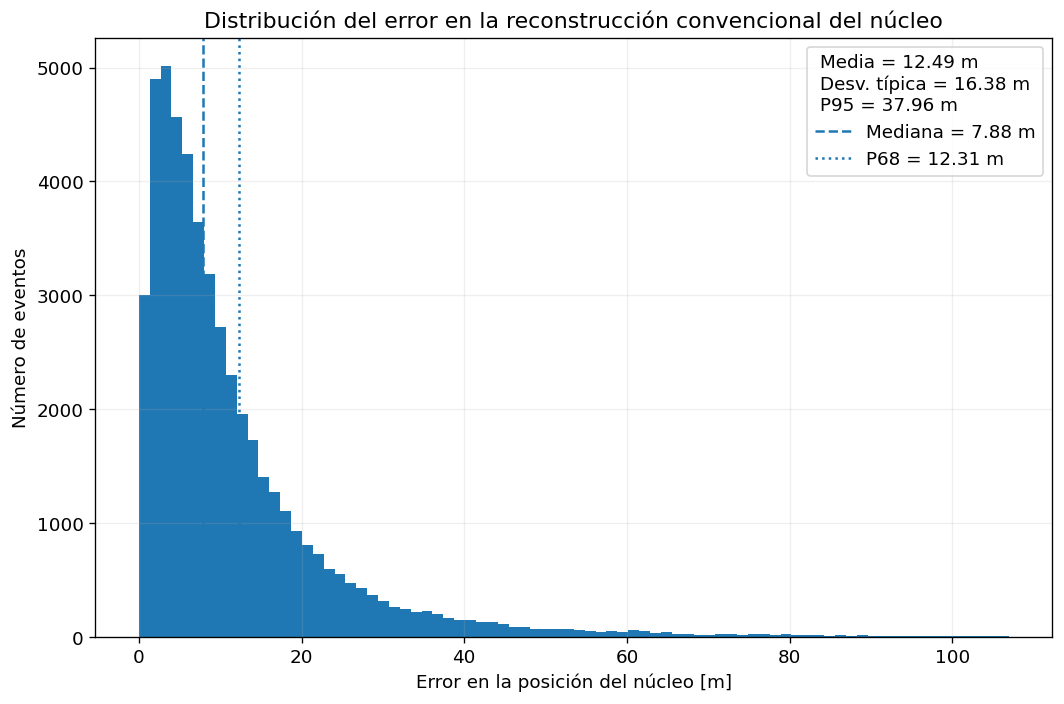

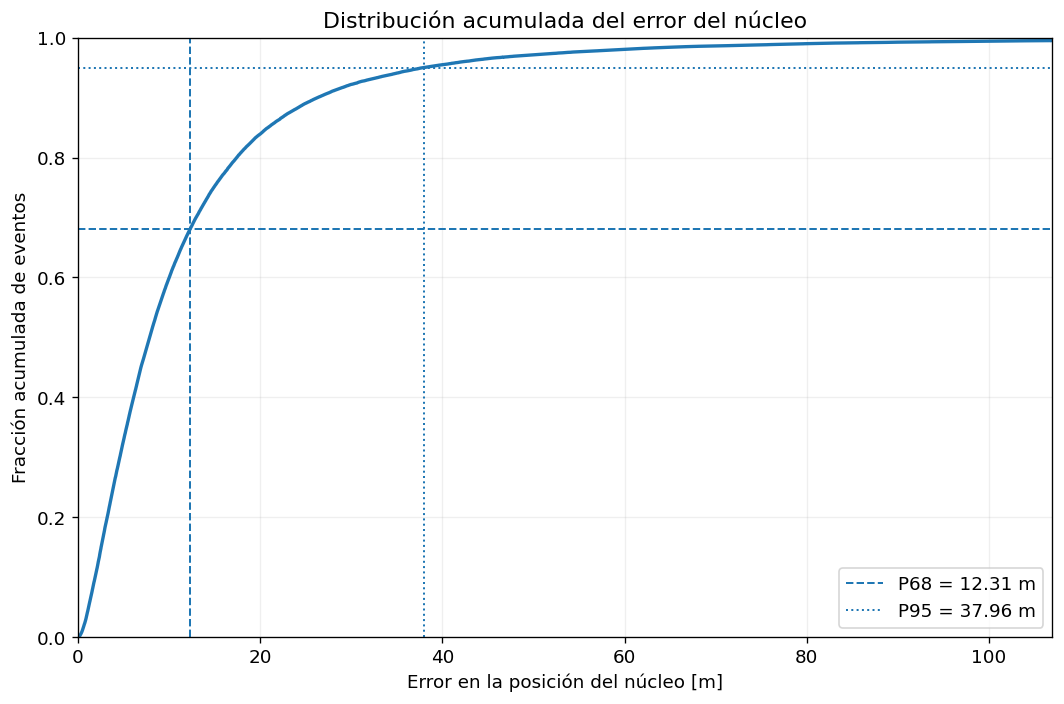

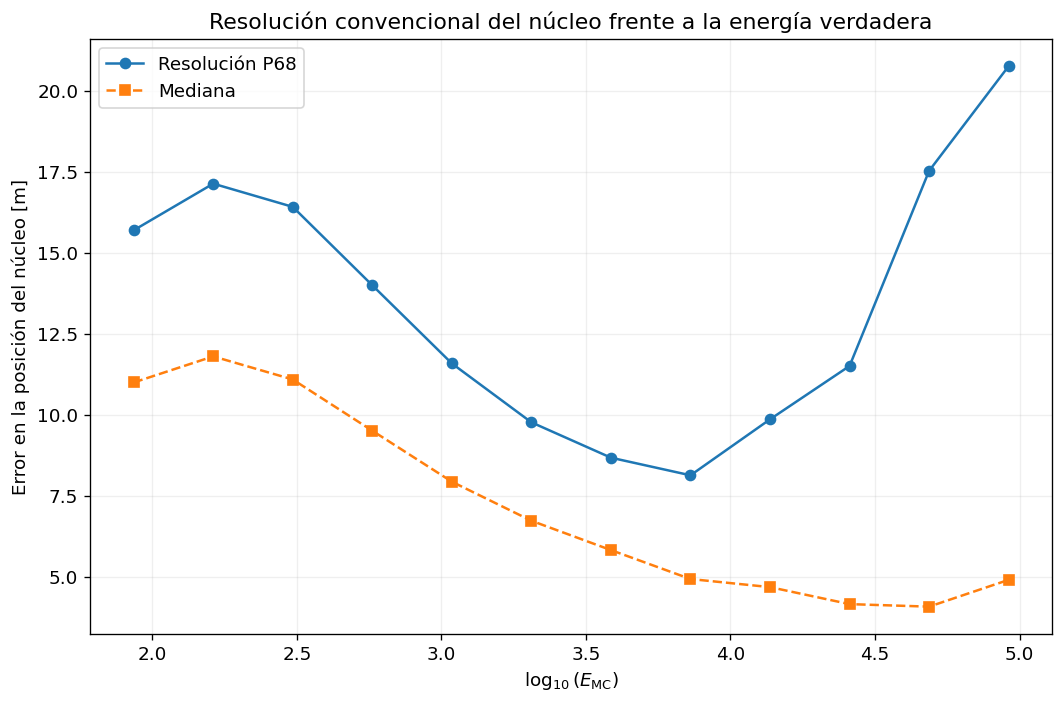

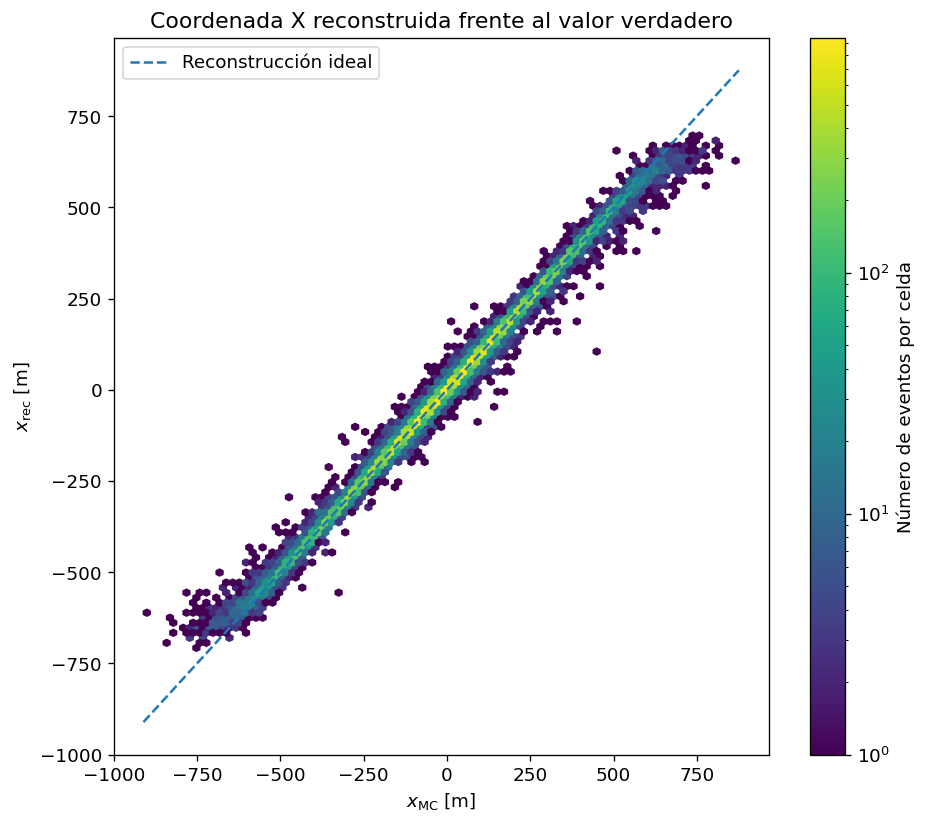

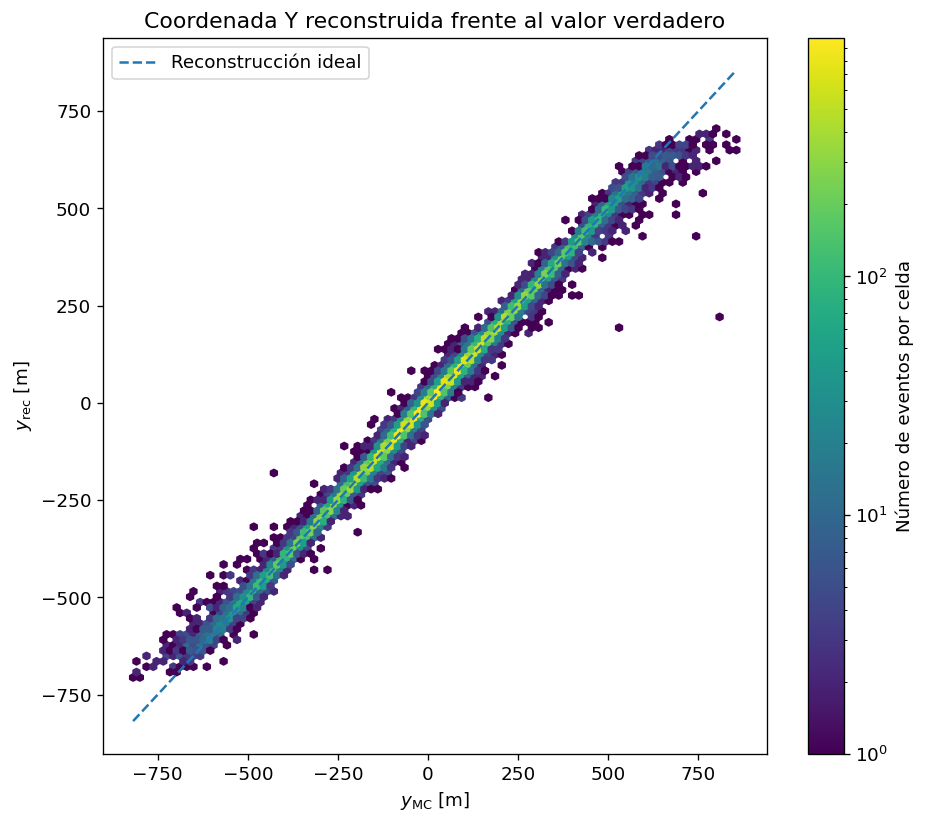

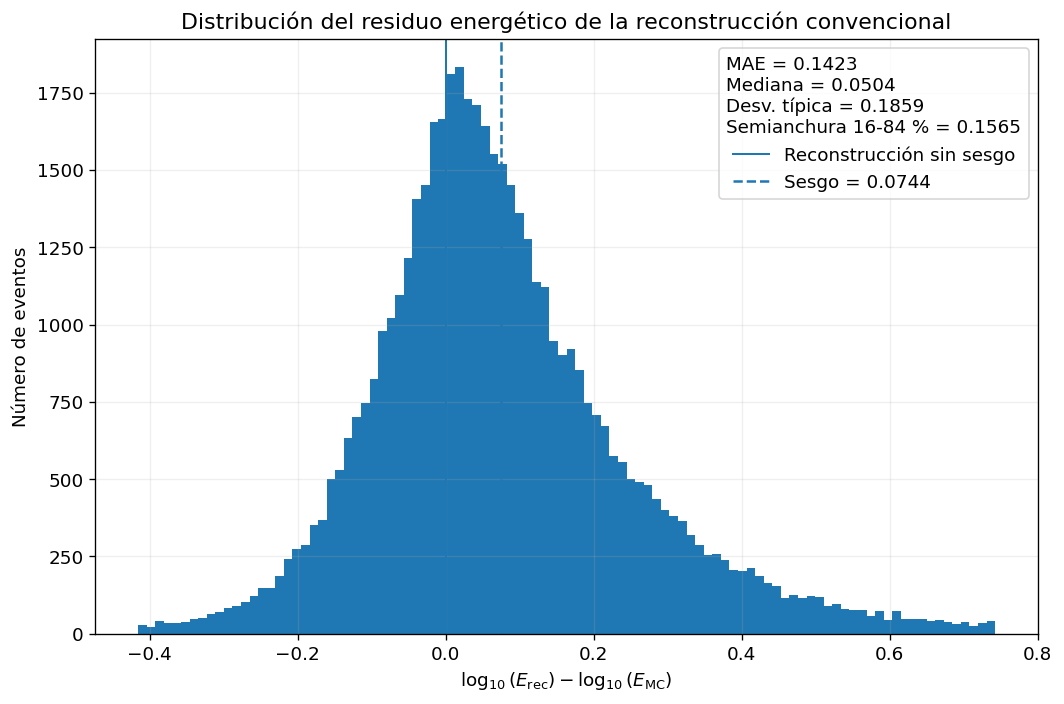

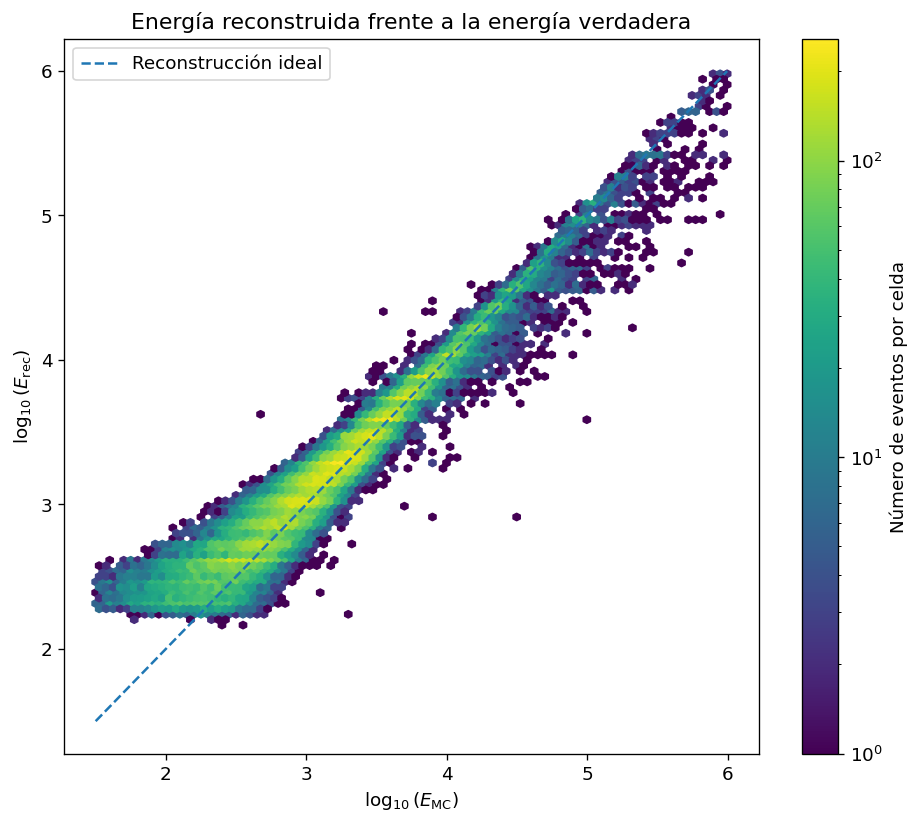

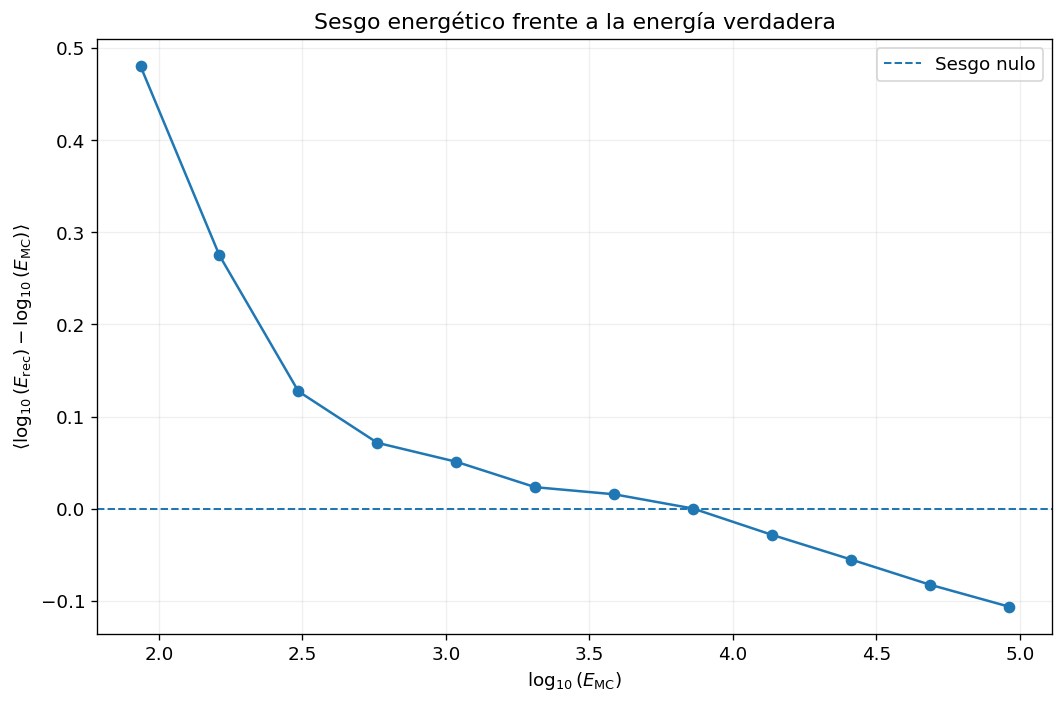

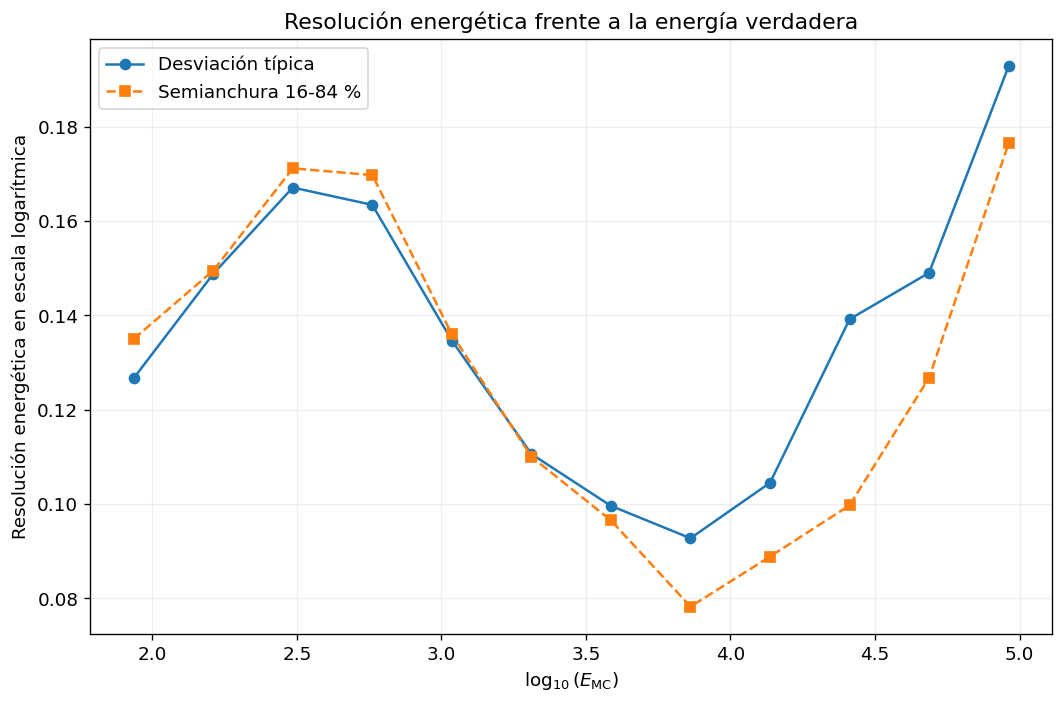

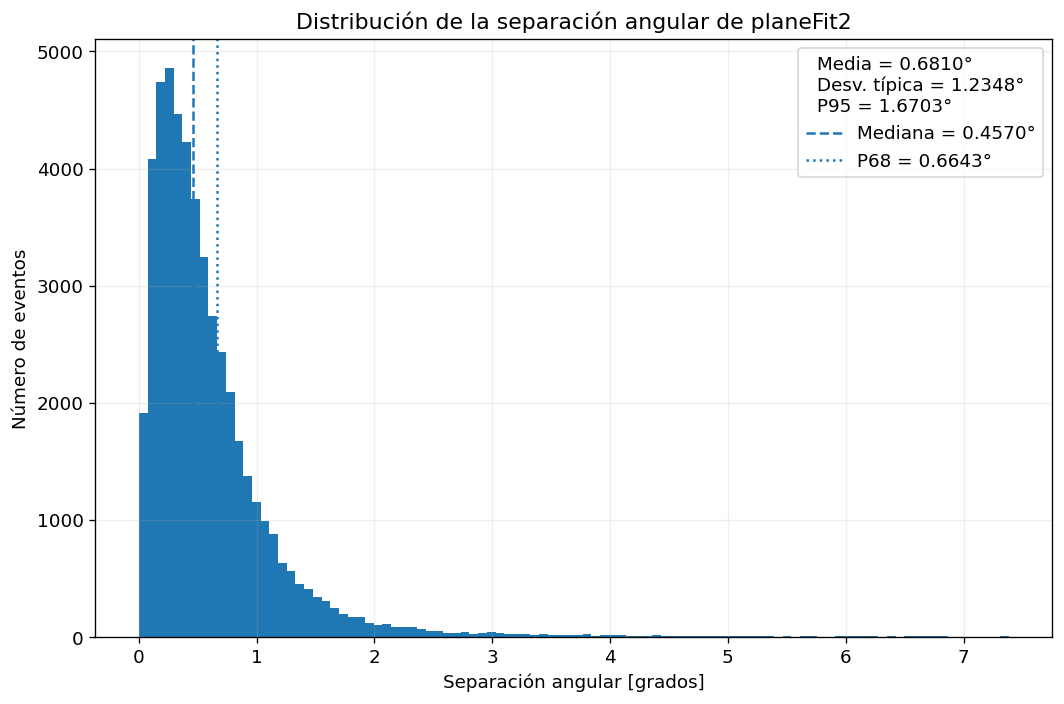

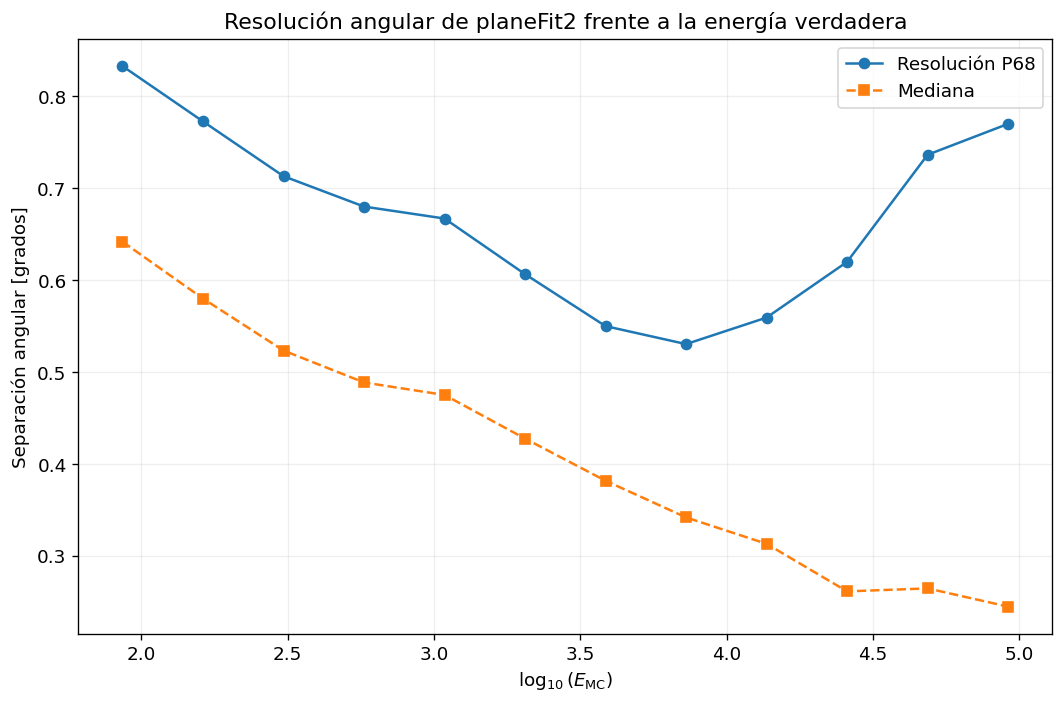


 EVALUACIÓN CONVENCIONAL FINALIZADA CORRECTAMENTE

  Eventos evaluados            : 50,000

  CORE
    Error medio                : 12.4873 m
    Mediana                    : 7.8779 m
    P68                        : 12.3061 m
    P95                        : 37.9590 m

  ENERGÍA
    Sesgo                      : 0.074409
    MAE                        : 0.142307
    Desviación típica          : 0.185879
    Semianchura 16-84 %        : 0.156542

  DIRECCIÓN - planeFit2
    Separación media           : 0.681025°
    Mediana                    : 0.457036°
    P68                        : 0.664306°
    P95                        : 1.670339°

  Directorio de resultados     : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/evaluacion_convencional
  Tabla resumen                : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/evaluacion_convencional/resumen_metricas_convencional.csv
  Métricas por energía         : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/evaluacion_convencional/metric

In [ ]:
# =============================================================================
# EVALUACIÓN COMPLETA DE LAS RECONSTRUCCIONES CONVENCIONALES
# =============================================================================
#
# Este bloque evalúa las reconstrucciones convencionales frente a los valores
# verdaderos proporcionados por la simulación Monte Carlo.
#
# IMPORTANTE:
#
# La red utiliza internamente seis targets:
#
#     [
#         coreX,
#         coreY,
#         sinZenith,
#         sinAzimuth,
#         cosAzimuth,
#         logEnergy
#     ]
#
# Sin embargo, este bloque trabaja EXCLUSIVAMENTE con las cinco variables
# físicas recuperadas:
#
#     [
#         coreX,
#         coreY,
#         zenithAngle,
#         azimuthAngle,
#         logEnergy
#     ]
#
# La reconstrucción angular convencional utilizada es:
#
#     planeFit2.theta
#     planeFit2.phi
#
# previamente validada frente a mc.delAngle.
#
# Estas variables NO se utilizan durante el entrenamiento de la red.
#
# FIGURAS GENERADAS:
#
# 1. Distribución del error de reconstrucción del núcleo.
# 2. Distribución acumulada del error del núcleo.
# 3. Resolución del núcleo frente a la energía verdadera.
# 4. Coordenada X reconstruida frente a coordenada X verdadera.
# 5. Coordenada Y reconstruida frente a coordenada Y verdadera.
# 6. Distribución del residuo energético.
# 7. Energía reconstruida frente a energía verdadera.
# 8. Sesgo energético frente a la energía verdadera.
# 9. Resolución energética frente a la energía verdadera.
# 10. Distribución de la separación angular.
# 11. Resolución angular frente a la energía verdadera.
#
# Además, se guarda:
#
# - Una tabla resumen global.
# - Una tabla de métricas por intervalos de energía.
#
# =============================================================================


# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =============================================================================
# 2. COMPROBACIÓN DE VARIABLES NECESARIAS
# =============================================================================

REQUIRED_EVALUATION_GLOBALS = [
    "CFG",
    "BASELINE_TEMPLATE_DF",
    "BASELINE_TARGETS_TRUE",
    "BASELINE_TEMPLATE_POINT",
]


MISSING_EVALUATION_GLOBALS = [
    variable_name
    for variable_name in REQUIRED_EVALUATION_GLOBALS
    if variable_name not in globals()
]


if MISSING_EVALUATION_GLOBALS:

    raise NameError(
        "No puede ejecutarse la evaluación porque faltan "
        "las siguientes variables:\n"
        + "\n".join(
            f"  - {variable_name}"
            for variable_name in MISSING_EVALUATION_GLOBALS
        )
        + "\n\nEjecuta primero la celda del baseline convencional."
    )


# =============================================================================
# 3. CONFIGURACIÓN GENERAL
# =============================================================================

## CARPETA DONDE SE GUARDARÁN FIGURAS Y TABLAS ##
OUTPUT_DIR = (
    Path(CFG["artifact_dir"])
    /
    "evaluacion_convencional"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


## NÚMERO DE INTERVALOS PARA ESTUDIAR LA DEPENDENCIA CON ENERGÍA ##
N_ENERGY_BINS = CFG.get(
    "baseline_number_energy_bins",
    12,
)


## MÍNIMO DE EVENTOS POR INTERVALO ##
MIN_EVENTS_PER_BIN = CFG.get(
    "baseline_min_events_per_bin",
    30,
)


## PERCENTIL UTILIZADO COMO DEFINICIÓN PRINCIPAL DE RESOLUCIÓN ##
RESOLUTION_PERCENTILE = 68.0


## RESOLUCIÓN DE LAS FIGURAS GUARDADAS ##
PLOT_DPI = CFG.get(
    "baseline_plot_dpi",
    300,
)


# =============================================================================
# 4. CONSTRUCCIÓN DEL DATAFRAME FÍSICO
# =============================================================================
#
# Se utiliza directamente BASELINE_TEMPLATE_DF, que ya está alineado mediante:
#
#     runID
#     eventID
#
# con los 50.000 eventos utilizados en el dataset.
#
# No se vuelve a leer el ROOT.
#
# =============================================================================

DF = BASELINE_TEMPLATE_DF.copy()


REQUIRED_COLUMNS = [
    "true_coreX",
    "true_coreY",
    "true_zenithAngle",
    "true_azimuthAngle",
    "true_logEnergy",

    "template_coreX",
    "template_coreY",
    "template_zenithAngle",
    "template_azimuthAngle",
    "template_logEnergy",
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in DF.columns
]


if missing_columns:

    raise KeyError(
        "Faltan columnas necesarias en BASELINE_TEMPLATE_DF:\n"
        + "\n".join(
            f"  - {column}"
            for column in missing_columns
        )
    )


## CREAR DATAFRAME DE TRABAJO ##
data = pd.DataFrame({

    "true_core_x":
        pd.to_numeric(
            DF["true_coreX"],
            errors="coerce",
        ),

    "true_core_y":
        pd.to_numeric(
            DF["true_coreY"],
            errors="coerce",
        ),

    "true_zenith":
        pd.to_numeric(
            DF["true_zenithAngle"],
            errors="coerce",
        ),

    "true_azimuth":
        pd.to_numeric(
            DF["true_azimuthAngle"],
            errors="coerce",
        ),

    "true_log_energy":
        pd.to_numeric(
            DF["true_logEnergy"],
            errors="coerce",
        ),

    "template_core_x":
        pd.to_numeric(
            DF["template_coreX"],
            errors="coerce",
        ),

    "template_core_y":
        pd.to_numeric(
            DF["template_coreY"],
            errors="coerce",
        ),

    "template_zenith":
        pd.to_numeric(
            DF["template_zenithAngle"],
            errors="coerce",
        ),

    "template_azimuth":
        pd.to_numeric(
            DF["template_azimuthAngle"],
            errors="coerce",
        ),

    "template_log_energy":
        pd.to_numeric(
            DF["template_logEnergy"],
            errors="coerce",
        ),
})


## CONSERVAR IDENTIFICADORES SI ESTÁN DISPONIBLES ##
if "runID" in DF.columns:

    data["runID"] = DF[
        "runID"
    ].to_numpy()


if "eventID" in DF.columns:

    data["eventID"] = DF[
        "eventID"
    ].to_numpy()


## SUSTITUIR INFINITOS POR NaN ##
data = data.replace(
    [
        np.inf,
        -np.inf,
    ],
    np.nan,
)


## ELIMINAR EVENTOS SIN ALGUNA DE LAS VARIABLES NECESARIAS ##
data = data.dropna(
    subset=[
        "true_core_x",
        "true_core_y",
        "true_zenith",
        "true_azimuth",
        "true_log_energy",

        "template_core_x",
        "template_core_y",
        "template_zenith",
        "template_azimuth",
        "template_log_energy",
    ]
).reset_index(
    drop=True
)


if len(data) == 0:

    raise ValueError(
        "No quedan eventos válidos después de eliminar NaN e infinitos."
    )


print()
print("============================================================")
print(" DATASET PARA EVALUACIÓN CONVENCIONAL")
print("============================================================")
print()

print(
    f"  Número de eventos válidos : {len(data):,}"
)

print(
    "  Dirección convencional    : planeFit2.theta / planeFit2.phi"
)

print(
    "  Core convencional         : rec.coreX / rec.coreY"
)

print(
    "  Energía convencional      : rec.LHLatDistFitEnergy"
)

print(
    "  Reco como entrada red     : False"
)


# =============================================================================
# 5. FUNCIONES AUXILIARES
# =============================================================================

def percentile_68(
    values: np.ndarray,
) -> float:
    """
    Devuelve el percentil 68 de una distribución.
    """

    values = np.asarray(
        values,
        dtype=float,
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if values.size == 0:
        return np.nan


    return float(
        np.percentile(
            values,
            RESOLUTION_PERCENTILE,
        )
    )


def robust_central_width(
    values: np.ndarray,
) -> float:
    """
    Calcula la semianchura del intervalo central 16-84 %.

    Se utiliza como estimador robusto de la dispersión de una distribución
    que puede no ser perfectamente gaussiana.
    """

    values = np.asarray(
        values,
        dtype=float,
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if values.size == 0:
        return np.nan


    p16, p84 = np.percentile(
        values,
        [
            16.0,
            84.0,
        ],
    )


    return float(
        (
            p84 - p16
        )
        /
        2.0
    )


def angular_separation(
    zenith_true: np.ndarray,
    azimuth_true: np.ndarray,
    zenith_reco: np.ndarray,
    azimuth_reco: np.ndarray,
) -> np.ndarray:
    """
    Calcula la separación angular entre la dirección verdadera y reconstruida.

    Todos los ángulos de entrada se expresan en radianes.

    La separación angular final se devuelve en grados.

    cos(psi) =
        cos(theta_true) cos(theta_reco)
        +
        sin(theta_true) sin(theta_reco)
        cos(phi_true - phi_reco)
    """

    zenith_true = np.asarray(
        zenith_true,
        dtype=float,
    )

    azimuth_true = np.asarray(
        azimuth_true,
        dtype=float,
    )

    zenith_reco = np.asarray(
        zenith_reco,
        dtype=float,
    )

    azimuth_reco = np.asarray(
        azimuth_reco,
        dtype=float,
    )


    cos_psi = (
        np.cos(
            zenith_true
        )
        *
        np.cos(
            zenith_reco
        )
        +
        np.sin(
            zenith_true
        )
        *
        np.sin(
            zenith_reco
        )
        *
        np.cos(
            azimuth_true
            -
            azimuth_reco
        )
    )


    ## EVITAR PEQUEÑOS ERRORES NUMÉRICOS FUERA DE [-1, 1] ##
    cos_psi = np.clip(
        cos_psi,
        -1.0,
        1.0,
    )


    return np.rad2deg(
        np.arccos(
            cos_psi
        )
    )


def save_figure(
    filename: str,
    dpi: Optional[int] = None,
) -> None:
    """
    Ajusta el diseño, guarda la figura y la muestra.
    """

    if dpi is None:

        dpi = PLOT_DPI


    plt.tight_layout()


    plt.savefig(
        OUTPUT_DIR
        /
        filename,
        dpi=dpi,
        bbox_inches="tight",
    )


    plt.show()


    plt.close()


def build_energy_bins(
    energy_values: np.ndarray,
    n_bins: int,
) -> np.ndarray:
    """
    Construye intervalos uniformes en log10(E).

    Se utilizan los percentiles 1 y 99 para evitar que unos pocos valores
    extremos condicionen excesivamente los límites.
    """

    energy_values = np.asarray(
        energy_values,
        dtype=float,
    )


    energy_values = energy_values[
        np.isfinite(
            energy_values
        )
    ]


    low, high = np.percentile(
        energy_values,
        [
            1.0,
            99.0,
        ],
    )


    return np.linspace(
        low,
        high,
        n_bins + 1,
    )


def binned_metrics(
    true_log_energy: np.ndarray,
    core_error: np.ndarray,
    energy_residual: np.ndarray,
    angular_error: np.ndarray,
    bin_edges: np.ndarray,
    min_events: int = 30,
) -> pd.DataFrame:
    """
    Calcula las métricas de reconstrucción por intervalos de energía verdadera.
    """

    rows = []


    for bin_index, (
        left,
        right,
    ) in enumerate(
        zip(
            bin_edges[:-1],
            bin_edges[1:],
        )
    ):

        ## INCLUIR EL EXTREMO SUPERIOR EN EL ÚLTIMO BIN ##
        if bin_index == len(
            bin_edges
        ) - 2:

            mask = (
                (true_log_energy >= left)
                &
                (true_log_energy <= right)
            )

        else:

            mask = (
                (true_log_energy >= left)
                &
                (true_log_energy < right)
            )


        n_events = int(
            np.sum(
                mask
            )
        )


        if n_events < min_events:
            continue


        core_values = core_error[
            mask
        ]


        energy_values = energy_residual[
            mask
        ]


        angular_values = angular_error[
            mask
        ]


        rows.append({

            "log_energy_left":
                left,

            "log_energy_right":
                right,

            "log_energy_center":
                0.5
                *
                (
                    left + right
                ),

            "n_events":
                n_events,


            # MÉTRICAS DEL NÚCLEO
            "core_mean_m":
                np.mean(
                    core_values
                ),

            "core_median_m":
                np.median(
                    core_values
                ),

            "core_p68_m":
                np.percentile(
                    core_values,
                    68.0,
                ),

            "core_p95_m":
                np.percentile(
                    core_values,
                    95.0,
                ),


            # MÉTRICAS ENERGÉTICAS
            "energy_bias":
                np.mean(
                    energy_values
                ),

            "energy_mae":
                np.mean(
                    np.abs(
                        energy_values
                    )
                ),

            "energy_median_residual":
                np.median(
                    energy_values
                ),

            "energy_std":
                np.std(
                    energy_values,
                    ddof=1,
                ),

            "energy_resolution_68":
                robust_central_width(
                    energy_values
                ),


            # MÉTRICAS ANGULARES
            "angular_mean_deg":
                np.mean(
                    angular_values
                ),

            "angular_median_deg":
                np.median(
                    angular_values
                ),

            "angular_p68_deg":
                np.percentile(
                    angular_values,
                    68.0,
                ),

            "angular_p95_deg":
                np.percentile(
                    angular_values,
                    95.0,
                ),
        })


    return pd.DataFrame(
        rows
    )


# =============================================================================
# 6. CÁLCULO DE LOS ERRORES DE RECONSTRUCCIÓN
# =============================================================================


# -------------------------------------------------------------------------
# 6.1. Residuos de las coordenadas del núcleo
# -------------------------------------------------------------------------

data[
    "core_residual_x"
] = (
    data[
        "template_core_x"
    ]
    -
    data[
        "true_core_x"
    ]
)


data[
    "core_residual_y"
] = (
    data[
        "template_core_y"
    ]
    -
    data[
        "true_core_y"
    ]
)


# -------------------------------------------------------------------------
# 6.2. Distancia euclídea entre núcleo reconstruido y verdadero
#
# d_core =
#
#     sqrt[
#         (x_rec - x_MC)^2
#         +
#         (y_rec - y_MC)^2
#     ]
# -------------------------------------------------------------------------

data[
    "core_error_m"
] = np.sqrt(
    data[
        "core_residual_x"
    ] ** 2
    +
    data[
        "core_residual_y"
    ] ** 2
)


# -------------------------------------------------------------------------
# 6.3. Radio verdadero y reconstruido del núcleo
# -------------------------------------------------------------------------

data[
    "true_core_radius"
] = np.sqrt(
    data[
        "true_core_x"
    ] ** 2
    +
    data[
        "true_core_y"
    ] ** 2
)


data[
    "template_core_radius"
] = np.sqrt(
    data[
        "template_core_x"
    ] ** 2
    +
    data[
        "template_core_y"
    ] ** 2
)


data[
    "core_radial_residual"
] = (
    data[
        "template_core_radius"
    ]
    -
    data[
        "true_core_radius"
    ]
)


# -------------------------------------------------------------------------
# 6.4. Residuo energético
#
# delta_E =
#
#     log10(E_rec)
#     -
#     log10(E_MC)
#
# Valor positivo  -> sobreestimación.
# Valor negativo  -> infraestimación.
# -------------------------------------------------------------------------

data[
    "energy_residual"
] = (
    data[
        "template_log_energy"
    ]
    -
    data[
        "true_log_energy"
    ]
)


# -------------------------------------------------------------------------
# 6.5. Separación angular
#
# La dirección convencional procede de:
#
#     planeFit2.theta
#     planeFit2.phi
# -------------------------------------------------------------------------

data[
    "angular_error_deg"
] = angular_separation(

    zenith_true=data[
        "true_zenith"
    ].to_numpy(),

    azimuth_true=data[
        "true_azimuth"
    ].to_numpy(),

    zenith_reco=data[
        "template_zenith"
    ].to_numpy(),

    azimuth_reco=data[
        "template_azimuth"
    ].to_numpy(),
)


# =============================================================================
# 7. MÉTRICAS GLOBALES
# =============================================================================

core_error = data[
    "core_error_m"
].to_numpy()


core_radial_residual = data[
    "core_radial_residual"
].to_numpy()


energy_residual = data[
    "energy_residual"
].to_numpy()


angular_error = data[
    "angular_error_deg"
].to_numpy()


## MÉTRICAS DEL CORE ##
core_mean = np.mean(
    core_error
)

core_median = np.median(
    core_error
)

core_std = np.std(
    core_error,
    ddof=1,
)

core_p68 = np.percentile(
    core_error,
    68.0,
)

core_p95 = np.percentile(
    core_error,
    95.0,
)


## MÉTRICAS DEL RESIDUO RADIAL ##
core_radial_bias = np.mean(
    core_radial_residual
)

core_radial_std = np.std(
    core_radial_residual,
    ddof=1,
)

core_radial_mae = np.mean(
    np.abs(
        core_radial_residual
    )
)


## MÉTRICAS DE ENERGÍA ##
energy_bias = np.mean(
    energy_residual
)

energy_mae = np.mean(
    np.abs(
        energy_residual
    )
)

energy_median = np.median(
    energy_residual
)

energy_std = np.std(
    energy_residual,
    ddof=1,
)

energy_resolution_68 = robust_central_width(
    energy_residual
)


## MÉTRICAS ANGULARES ##
angular_mean = np.mean(
    angular_error
)

angular_median = np.median(
    angular_error
)

angular_std = np.std(
    angular_error,
    ddof=1,
)

angular_p68 = np.percentile(
    angular_error,
    68.0,
)

angular_p95 = np.percentile(
    angular_error,
    95.0,
)


## TABLA RESUMEN ##
summary = pd.DataFrame({

    "Métrica": [

        "Número de eventos",

        "Error medio del núcleo [m]",
        "Error mediano del núcleo [m]",
        "Resolución del núcleo P68 [m]",
        "Percentil 95 del error del núcleo [m]",

        "Sesgo del residuo radial [m]",
        "Desviación típica radial [m]",
        "MAE del residuo radial [m]",

        "Sesgo energético",
        "MAE energético",
        "Mediana del residuo energético",
        "Desviación típica energética",
        "Resolución energética 16-84 %",

        "Separación angular media [grados]",
        "Separación angular mediana [grados]",
        "Resolución angular P68 [grados]",
        "Percentil 95 angular [grados]",
    ],


    "Valor": [

        len(
            data
        ),

        core_mean,
        core_median,
        core_p68,
        core_p95,

        core_radial_bias,
        core_radial_std,
        core_radial_mae,

        energy_bias,
        energy_mae,
        energy_median,
        energy_std,
        energy_resolution_68,

        angular_mean,
        angular_median,
        angular_p68,
        angular_p95,
    ],
})


summary.to_csv(
    OUTPUT_DIR
    /
    "resumen_metricas_convencional.csv",
    index=False,
)


print()
print("============================================================")
print(" RESUMEN GLOBAL DE LAS MÉTRICAS")
print("============================================================")
print()


print(
    summary.to_string(
        index=False
    )
)


# =============================================================================
# 8. MÉTRICAS POR INTERVALOS DE ENERGÍA
# =============================================================================

energy_bin_edges = build_energy_bins(

    data[
        "true_log_energy"
    ].to_numpy(),

    n_bins=N_ENERGY_BINS,
)


metrics_by_energy = binned_metrics(

    true_log_energy=data[
        "true_log_energy"
    ].to_numpy(),

    core_error=core_error,

    energy_residual=energy_residual,

    angular_error=angular_error,

    bin_edges=energy_bin_edges,

    min_events=MIN_EVENTS_PER_BIN,
)


metrics_by_energy.to_csv(
    OUTPUT_DIR
    /
    "metricas_convencionales_por_energia.csv",
    index=False,
)


print()
print("============================================================")
print(" MÉTRICAS POR INTERVALOS DE ENERGÍA")
print("============================================================")
print()


print(
    metrics_by_energy.to_string(
        index=False
    )
)


# =============================================================================
# 9. FIGURA 1: DISTRIBUCIÓN DEL ERROR DEL NÚCLEO
# =============================================================================

## LIMITAR VISUALMENTE AL PERCENTIL 99.5 ##
core_plot_limit = np.percentile(
    core_error,
    99.5,
)


plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.hist(
    core_error,
    bins=80,
    range=(
        0.0,
        core_plot_limit,
    ),
)


plt.axvline(
    core_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mediana = "
        f"{core_median:.2f} m"
    ),
)


plt.axvline(
    core_p68,
    linestyle=":",
    linewidth=1.5,
    label=(
        f"P68 = "
        f"{core_p68:.2f} m"
    ),
)


plt.xlabel(
    "Error en la posición del núcleo [m]"
)


plt.ylabel(
    "Número de eventos"
)


plt.title(
    "Distribución del error en la reconstrucción convencional del núcleo"
)


plt.legend(
    title=(
        f"Media = {core_mean:.2f} m\n"
        f"Desv. típica = {core_std:.2f} m\n"
        f"P95 = {core_p95:.2f} m"
    )
)


plt.grid(
    alpha=0.2
)


save_figure(
    "01_distribucion_error_nucleo_convencional.png"
)


# =============================================================================
# 10. FIGURA 2: DISTRIBUCIÓN ACUMULADA DEL ERROR DEL NÚCLEO
# =============================================================================

core_sorted = np.sort(
    core_error
)


core_cdf = (
    np.arange(
        1,
        len(
            core_sorted
        )
        +
        1
    )
    /
    len(
        core_sorted
    )
)


plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    core_sorted,
    core_cdf,
    linewidth=2,
)


plt.axhline(
    0.68,
    linestyle="--",
    linewidth=1.2,
)


plt.axvline(
    core_p68,
    linestyle="--",
    linewidth=1.2,
    label=(
        f"P68 = "
        f"{core_p68:.2f} m"
    ),
)


plt.axhline(
    0.95,
    linestyle=":",
    linewidth=1.2,
)


plt.axvline(
    core_p95,
    linestyle=":",
    linewidth=1.2,
    label=(
        f"P95 = "
        f"{core_p95:.2f} m"
    ),
)


plt.xlim(
    0.0,
    core_plot_limit,
)


plt.ylim(
    0.0,
    1.0,
)


plt.xlabel(
    "Error en la posición del núcleo [m]"
)


plt.ylabel(
    "Fracción acumulada de eventos"
)


plt.title(
    "Distribución acumulada del error del núcleo"
)


plt.legend()


plt.grid(
    alpha=0.2
)


save_figure(
    "02_cdf_error_nucleo_convencional.png"
)


# =============================================================================
# 11. FIGURA 3: RESOLUCIÓN DEL NÚCLEO FRENTE A LA ENERGÍA VERDADERA
# =============================================================================

plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "core_p68_m"
    ],

    marker="o",

    label="Resolución P68",
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "core_median_m"
    ],

    marker="s",

    linestyle="--",

    label="Mediana",
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    "Error en la posición del núcleo [m]"
)


plt.title(
    "Resolución convencional del núcleo frente a la energía verdadera"
)


plt.legend()


plt.grid(
    alpha=0.2
)


save_figure(
    "03_resolucion_nucleo_vs_energia_convencional.png"
)


# =============================================================================
# 12. FIGURA 4: COORDENADA X RECONSTRUIDA FRENTE A X VERDADERA
# =============================================================================

x_min = min(
    data[
        "true_core_x"
    ].min(),

    data[
        "template_core_x"
    ].min(),
)


x_max = max(
    data[
        "true_core_x"
    ].max(),

    data[
        "template_core_x"
    ].max(),
)


plt.figure(
    figsize=(
        8,
        7,
    )
)


plt.hexbin(
    data[
        "true_core_x"
    ],

    data[
        "template_core_x"
    ],

    gridsize=90,

    mincnt=1,

    bins="log",
)


plt.plot(
    [
        x_min,
        x_max,
    ],

    [
        x_min,
        x_max,
    ],

    linestyle="--",

    linewidth=1.5,

    label="Reconstrucción ideal",
)


plt.xlabel(
    r"$x_{\mathrm{MC}}$ [m]"
)


plt.ylabel(
    r"$x_{\mathrm{rec}}$ [m]"
)


plt.title(
    "Coordenada X reconstruida frente al valor verdadero"
)


plt.colorbar(
    label="Número de eventos por celda"
)


plt.legend()


save_figure(
    "04_core_x_convencional_vs_mc.png"
)


# =============================================================================
# 13. FIGURA 5: COORDENADA Y RECONSTRUIDA FRENTE A Y VERDADERA
# =============================================================================

y_min = min(
    data[
        "true_core_y"
    ].min(),

    data[
        "template_core_y"
    ].min(),
)


y_max = max(
    data[
        "true_core_y"
    ].max(),

    data[
        "template_core_y"
    ].max(),
)


plt.figure(
    figsize=(
        8,
        7,
    )
)


plt.hexbin(
    data[
        "true_core_y"
    ],

    data[
        "template_core_y"
    ],

    gridsize=90,

    mincnt=1,

    bins="log",
)


plt.plot(
    [
        y_min,
        y_max,
    ],

    [
        y_min,
        y_max,
    ],

    linestyle="--",

    linewidth=1.5,

    label="Reconstrucción ideal",
)


plt.xlabel(
    r"$y_{\mathrm{MC}}$ [m]"
)


plt.ylabel(
    r"$y_{\mathrm{rec}}$ [m]"
)


plt.title(
    "Coordenada Y reconstruida frente al valor verdadero"
)


plt.colorbar(
    label="Número de eventos por celda"
)


plt.legend()


save_figure(
    "05_core_y_convencional_vs_mc.png"
)


# =============================================================================
# 14. FIGURA 6: DISTRIBUCIÓN DEL RESIDUO ENERGÉTICO
# =============================================================================

energy_low, energy_high = np.percentile(
    energy_residual,
    [
        0.5,
        99.5,
    ],
)


plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.hist(
    energy_residual,
    bins=100,
    range=(
        energy_low,
        energy_high,
    ),
)


plt.axvline(
    0.0,
    linestyle="-",
    linewidth=1.2,
    label="Reconstrucción sin sesgo",
)


plt.axvline(
    energy_bias,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Sesgo = "
        f"{energy_bias:.4f}"
    ),
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{rec}})"
    r"-\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    "Número de eventos"
)


plt.title(
    "Distribución del residuo energético de la reconstrucción convencional"
)


plt.legend(
    title=(
        f"MAE = {energy_mae:.4f}\n"
        f"Mediana = {energy_median:.4f}\n"
        f"Desv. típica = {energy_std:.4f}\n"
        f"Semianchura 16-84 % = {energy_resolution_68:.4f}"
    )
)


plt.grid(
    alpha=0.2
)


save_figure(
    "06_distribucion_residuo_energia_convencional.png"
)


# =============================================================================
# 15. FIGURA 7: ENERGÍA RECONSTRUIDA FRENTE A ENERGÍA VERDADERA
# =============================================================================

energy_axis_min = min(
    data[
        "true_log_energy"
    ].min(),

    data[
        "template_log_energy"
    ].min(),
)


energy_axis_max = max(
    data[
        "true_log_energy"
    ].max(),

    data[
        "template_log_energy"
    ].max(),
)


plt.figure(
    figsize=(
        8,
        7,
    )
)


plt.hexbin(
    data[
        "true_log_energy"
    ],

    data[
        "template_log_energy"
    ],

    gridsize=90,

    mincnt=1,

    bins="log",
)


plt.plot(
    [
        energy_axis_min,
        energy_axis_max,
    ],

    [
        energy_axis_min,
        energy_axis_max,
    ],

    linestyle="--",

    linewidth=1.5,

    label="Reconstrucción ideal",
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    r"$\log_{10}(E_{\mathrm{rec}})$"
)


plt.title(
    "Energía reconstruida frente a la energía verdadera"
)


plt.colorbar(
    label="Número de eventos por celda"
)


plt.legend()


save_figure(
    "07_energia_convencional_vs_mc.png"
)


# =============================================================================
# 16. FIGURA 8: SESGO ENERGÉTICO FRENTE A LA ENERGÍA VERDADERA
# =============================================================================

plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "energy_bias"
    ],

    marker="o",
)


plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.2,
    label="Sesgo nulo",
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    r"$\langle"
    r"\log_{10}(E_{\mathrm{rec}})"
    r"-\log_{10}(E_{\mathrm{MC}})"
    r"\rangle$"
)


plt.title(
    "Sesgo energético frente a la energía verdadera"
)


plt.legend()


plt.grid(
    alpha=0.2
)


save_figure(
    "08_sesgo_energia_vs_energia_mc_convencional.png"
)


# =============================================================================
# 17. FIGURA 9: RESOLUCIÓN ENERGÉTICA FRENTE A LA ENERGÍA VERDADERA
# =============================================================================

plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "energy_std"
    ],

    marker="o",

    label="Desviación típica",
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "energy_resolution_68"
    ],

    marker="s",

    linestyle="--",

    label="Semianchura 16-84 %",
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    "Resolución energética en escala logarítmica"
)


plt.title(
    "Resolución energética frente a la energía verdadera"
)


plt.legend()


plt.grid(
    alpha=0.2
)


save_figure(
    "09_resolucion_energia_vs_energia_mc_convencional.png"
)


# =============================================================================
# 18. FIGURA 10: DISTRIBUCIÓN DE LA SEPARACIÓN ANGULAR
# =============================================================================

angular_plot_limit = np.percentile(
    angular_error,
    99.5,
)


plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.hist(
    angular_error,
    bins=100,
    range=(
        0.0,
        angular_plot_limit,
    ),
)


plt.axvline(
    angular_median,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mediana = "
        f"{angular_median:.4f}°"
    ),
)


plt.axvline(
    angular_p68,
    linestyle=":",
    linewidth=1.5,
    label=(
        f"P68 = "
        f"{angular_p68:.4f}°"
    ),
)


plt.xlabel(
    "Separación angular [grados]"
)


plt.ylabel(
    "Número de eventos"
)


plt.title(
    "Distribución de la separación angular de planeFit2"
)


plt.legend(
    title=(
        f"Media = {angular_mean:.4f}°\n"
        f"Desv. típica = {angular_std:.4f}°\n"
        f"P95 = {angular_p95:.4f}°"
    )
)


plt.grid(
    alpha=0.2
)


save_figure(
    "10_distribucion_error_angular_planefit2.png"
)


# =============================================================================
# 19. FIGURA 11: RESOLUCIÓN ANGULAR FRENTE A LA ENERGÍA VERDADERA
# =============================================================================

plt.figure(
    figsize=(
        9,
        6,
    )
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "angular_p68_deg"
    ],

    marker="o",

    label="Resolución P68",
)


plt.plot(
    metrics_by_energy[
        "log_energy_center"
    ],

    metrics_by_energy[
        "angular_median_deg"
    ],

    marker="s",

    linestyle="--",

    label="Mediana",
)


plt.xlabel(
    r"$\log_{10}(E_{\mathrm{MC}})$"
)


plt.ylabel(
    "Separación angular [grados]"
)


plt.title(
    "Resolución angular de planeFit2 frente a la energía verdadera"
)


plt.legend()


plt.grid(
    alpha=0.2
)


save_figure(
    "11_resolucion_angular_vs_energia_mc_planefit2.png"
)


# =============================================================================
# 20. GUARDAR DATAFRAME COMPLETO CON LOS ERRORES
# =============================================================================

evaluation_events_path = (
    OUTPUT_DIR
    /
    "eventos_evaluacion_convencional.csv"
)


data.to_csv(
    evaluation_events_path,
    index=False,
)


# =============================================================================
# 21. MENSAJE FINAL
# =============================================================================

print()
print("============================================================")
print(" EVALUACIÓN CONVENCIONAL FINALIZADA CORRECTAMENTE")
print("============================================================")
print()


print(
    f"  Eventos evaluados            : {len(data):,}"
)

print()


print(
    "  CORE"
)

print(
    f"    Error medio                : {core_mean:.4f} m"
)

print(
    f"    Mediana                    : {core_median:.4f} m"
)

print(
    f"    P68                        : {core_p68:.4f} m"
)

print(
    f"    P95                        : {core_p95:.4f} m"
)

print()


print(
    "  ENERGÍA"
)

print(
    f"    Sesgo                      : {energy_bias:.6f}"
)

print(
    f"    MAE                        : {energy_mae:.6f}"
)

print(
    f"    Desviación típica          : {energy_std:.6f}"
)

print(
    f"    Semianchura 16-84 %        : {energy_resolution_68:.6f}"
)

print()


print(
    "  DIRECCIÓN - planeFit2"
)

print(
    f"    Separación media           : {angular_mean:.6f}°"
)

print(
    f"    Mediana                    : {angular_median:.6f}°"
)

print(
    f"    P68                        : {angular_p68:.6f}°"
)

print(
    f"    P95                        : {angular_p95:.6f}°"
)

print()


print(
    f"  Directorio de resultados     : {OUTPUT_DIR.resolve()}"
)

print(
    f"  Tabla resumen                : "
    f"{OUTPUT_DIR / 'resumen_metricas_convencional.csv'}"
)

print(
    f"  Métricas por energía         : "
    f"{OUTPUT_DIR / 'metricas_convencionales_por_energia.csv'}"
)

print(
    f"  Eventos con errores          : "
    f"{evaluation_events_path}"
)

print()

print(
    "IMPORTANTE:"
)

print(
    "  - Los valores de dirección corresponden a planeFit2."
)

print(
    "  - Core y energía proceden de las reconstrucciones convencionales rec.*."
)

print(
    "  - Ninguna de estas reconstrucciones se utiliza durante el entrenamiento."
)

print(
    "  - La comparación posterior con la red debe realizarse sobre "
    "exactamente los mismos índices del conjunto de test."
)

texto en negrita 6. Dataset Construction

- Hit features and targets are **standardised** with `sklearn.StandardScaler` fit on the training set only.
- Each event's hit tensor is padded to `CFG['max_hits']` rows.
- If an event has more than `CFG['max_hits']` hits, `CFG['hit_selection']` chooses which hits to keep.
- Recommended starting point for high-multiplicity events: `max_hits=1024`, `hit_selection='top_charge'`, `batch_size=32`.
- A boolean **mask** records real vs. padded hits so the encoder ignores padding.
- The dataset is split into train / validation / test by event index.


In [ ]:
# ── Scalers ───────────────────────────────────────────────────────────────
def fit_scalers(
    hit_arrays: List[np.ndarray],
    targets: np.ndarray,
    train_idx: np.ndarray,
) -> Tuple[StandardScaler, StandardScaler]:
    """
    Fit StandardScaler on training data only.

    This avoids leakage:
        - hit_scaler is fitted only with hits from training events.
        - target_scaler is fitted only with targets from training events.
        - validation/test are never used to fit scalers.

    Current target representation:
        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    Returns
    -------
    hit_scaler, target_scaler
    """

    ## CONCATENAR SOLO LOS HITS DE TRAIN PARA AJUSTAR EL SCALER DE ENTRADAS ##
    train_hits = np.concatenate(
        [
            hit_arrays[i]
            for i in train_idx
        ],
        axis=0,
    )

    ## CONVERTIR TARGETS A ARRAY NUMPY ##
    targets = np.asarray(
        targets,
        dtype=np.float32,
    )

    ## DIMENSIONES ESPERADAS SEGÚN CFG ##
    expected_hit_dim = n_hit_features(
        CFG
    )

    expected_target_dim = CFG.get(
        'n_target_dims',
        6,
    )

    ## COMPROBAR DIMENSIÓN DE LAS FEATURES DE HIT ##
    if (
        train_hits.ndim != 2
        or
        train_hits.shape[1] != expected_hit_dim
    ):

        raise ValueError(
            f'Bad training hit shape {train_hits.shape}. '
            f'Expected (*, {expected_hit_dim}).'
        )

    ## COMPROBAR DIMENSIÓN DE LOS TARGETS ##
    if (
        targets.ndim != 2
        or
        targets.shape[1] != expected_target_dim
    ):

        raise ValueError(
            f'Bad target shape {targets.shape}. '
            f'Expected (*, {expected_target_dim}).'
        )

    ## COMPROBAR QUE EL MODELO ACTUAL UTILIZA 6 TARGETS ##
    if expected_target_dim != 6:

        raise ValueError(
            'Current trig-angle model requires n_target_dims = 6.'
        )

    ## COMPROBAR NOMBRES Y ORDEN DE LOS TARGETS ##
    expected_target_names = [
        'coreX',
        'coreY',
        'sinZenith',
        'sinAzimuth',
        'cosAzimuth',
        'logEnergy',
    ]

    configured_target_names = list(
        CFG.get(
            'target_names',
            [],
        )
    )

    if configured_target_names != expected_target_names:

        raise ValueError(
            'CFG["target_names"] does not match the expected trig-angle '
            'target order.\n'
            f'Configured: {configured_target_names}\n'
            f'Expected  : {expected_target_names}'
        )

    ## COMPROBAR QUE train_idx ES VÁLIDO ##
    train_idx = np.asarray(
        train_idx,
        dtype=np.int64,
    )

    if train_idx.ndim != 1:

        raise ValueError(
            f'train_idx must be one-dimensional. Got shape {train_idx.shape}.'
        )

    if len(train_idx) == 0:

        raise ValueError(
            'train_idx is empty. Cannot fit scalers.'
        )

    if (
        np.min(train_idx) < 0
        or
        np.max(train_idx) >= len(targets)
    ):

        raise IndexError(
            'train_idx contains indices outside the target array.'
        )

    ## COMPROBAR VALORES FINITOS ANTES DE AJUSTAR LOS SCALERS ##
    if not np.all(
        np.isfinite(
            train_hits
        )
    ):

        raise ValueError(
            'Non-finite values found in training hit features.'
        )

    if not np.all(
        np.isfinite(
            targets[
                train_idx
            ]
        )
    ):

        raise ValueError(
            'Non-finite values found in training targets.'
        )

    ## AJUSTAR SCALER DE ENTRADAS SOLO CON TRAIN ##
    hit_scaler = StandardScaler().fit(
        train_hits
    )

    ## AJUSTAR SCALER DE TARGETS SOLO CON TRAIN ##
    target_scaler = StandardScaler().fit(
        targets[
            train_idx
        ]
    )

    print('Scalers fitted on training data only.')

    print(
        f'  Hit scaler features : {hit_scaler.n_features_in_}'
    )

    print(
        f'  Target scaler dims  : {target_scaler.n_features_in_}'
    )

    print(
        f'  Target names        : {configured_target_names}'
    )

    return (
        hit_scaler,
        target_scaler,
    )


def select_hits(
    hit_mat: np.ndarray,
    max_hits: int,
    mode: str = 'top_charge',
    random_seed: Optional[int] = None,
) -> np.ndarray:
    """
    Select at most max_hits from an event.

    IMPORTANT:
        Selection must use physically meaningful columns BEFORE scaling.

    Fixed columns:
        0  xPMT
        1  yPMT
        2  time_rel
        3  dt_hit
        4  log_charge
        5  charge_fraction
        6  dx
        7  dy

    Optional columns after index 7:
        - voronoi_weight_norm, if enabled
        - tank_zone_area_norm, if enabled

    Modes
    -----
    top_charge
        Keep the highest-charge hits, using log_charge column.
    earliest_time
        Keep the earliest hits, using time_rel column.
    random
        Keep a deterministic random subset, using random_seed.
    first
        Keep the first max_hits rows.
    """

    ## ASEGURAR FORMATO NUMPY FLOAT32 ##
    hit_mat = np.asarray(
        hit_mat,
        dtype=np.float32,
    )

    ## COMPROBAR DIMENSIÓN ##
    if hit_mat.ndim != 2:

        raise ValueError(
            f'hit_mat must be 2D. Got shape {hit_mat.shape}.'
        )

    n_hits = len(
        hit_mat
    )

    ## SI EL EVENTO YA TIENE MENOS HITS QUE max_hits, NO RECORTAR ##
    if n_hits <= max_hits:

        return hit_mat

    mode = mode.lower()

    ## COLUMNAS FIJAS USADAS PARA SELECCIÓN ##
    time_col = 2
    log_charge_col = 4

    ## COMPROBAR QUE EXISTEN LAS COLUMNAS NECESARIAS ##
    if hit_mat.shape[1] <= log_charge_col:

        raise ValueError(
            'hit_mat does not contain the required fixed hit features.'
        )

    ## SELECCIONAR LOS HITS DE MAYOR CARGA ##
    if mode == 'top_charge':

        idx = np.argsort(
            -hit_mat[
                :,
                log_charge_col
            ]
        )[
            :max_hits
        ]

    ## SELECCIONAR LOS HITS MÁS TEMPRANOS ##
    elif mode == 'earliest_time':

        idx = np.argsort(
            hit_mat[
                :,
                time_col
            ]
        )[
            :max_hits
        ]

    ## SELECCIONAR UN SUBCONJUNTO ALEATORIO REPRODUCIBLE ##
    elif mode == 'random':

        rng = np.random.default_rng(
            random_seed
        )

        idx = rng.choice(
            n_hits,
            size=max_hits,
            replace=False,
        )

    ## QUEDARSE CON LOS PRIMEROS max_hits ##
    elif mode == 'first':

        idx = np.arange(
            max_hits
        )

    else:

        raise ValueError(
            f'Unknown hit_selection="{mode}". '
            'Use one of: top_charge, earliest_time, random, first.'
        )

    ## REORDENAR LOS HITS SELECCIONADOS POR time_rel ##
    ## ESTO DA UN ORDEN TEMPORAL ESTABLE Y FÍSICO AL TENSOR ##
    idx = idx[
        np.argsort(
            hit_mat[
                idx,
                time_col
            ]
        )
    ]

    return hit_mat[
        idx
    ]


def pad_hits(
    hit_mat: np.ndarray,
    max_hits: int,
    n_feat: int,
    hit_selection: str = 'top_charge',
    random_seed: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Select, pad, or truncate hit matrix to shape (max_hits, n_feat).

    Selection is done before scaling by the Dataset.

    Returns
    -------
    padded  : np.ndarray, shape (max_hits, n_feat)
    mask    : np.ndarray, shape (max_hits,), bool. True = real hit
    """

    ## ASEGURAR FORMATO NUMPY FLOAT32 ##
    hit_mat = np.asarray(
        hit_mat,
        dtype=np.float32,
    )

    ## COMPROBAR DIMENSIÓN DE ENTRADA ##
    if (
        hit_mat.ndim != 2
        or
        hit_mat.shape[1] != n_feat
    ):

        raise ValueError(
            f'Bad hit_mat shape {hit_mat.shape}. '
            f'Expected (*, {n_feat}).'
        )

    ## SELECCIONAR HITS ANTES DEL ESCALADO ##
    selected = select_hits(
        hit_mat,
        max_hits=max_hits,
        mode=hit_selection,
        random_seed=random_seed,
    )

    n_real = min(
        len(
            selected
        ),
        max_hits,
    )

    ## CREAR MATRIZ CON PADDING A CERO ##
    padded = np.zeros(
        (
            max_hits,
            n_feat,
        ),
        dtype=np.float32,
    )

    padded[
        :n_real
    ] = selected[
        :n_real
    ]

    ## CREAR MÁSCARA: TRUE PARA HITS REALES, FALSE PARA PADDING ##
    mask = np.zeros(
        max_hits,
        dtype=bool,
    )

    mask[
        :n_real
    ] = True

    return (
        padded,
        mask,
    )


# ── PyTorch Dataset ───────────────────────────────────────────────────────
class ShowerDataset(Dataset):
    """
    Dataset of gamma-ray air-shower events.

    Each item is a tuple:
        (hits, mask, target)

    where:
        hits   : torch.FloatTensor, shape (max_hits, n_feat), scaled
        mask   : torch.BoolTensor,  shape (max_hits,), True = real hit
        target : torch.FloatTensor, shape (6,), scaled

    Internal target order:
        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    IMPORTANT:
        The Dataset returns the INTERNAL transformed representation.

        Physical angles are recovered only during evaluation through:

            zenithAngle = arcsin(sinZenith)

            azimuthAngle = atan2(
                sinAzimuth,
                cosAzimuth
            )

    Hit feature order is controlled by:
        get_hit_feature_names(CFG)
    """

    def __init__(
        self,
        indices: np.ndarray,
        hit_arrays: List[np.ndarray],
        targets: np.ndarray,
        hit_scaler: StandardScaler,
        target_scaler: StandardScaler,
        max_hits: int,
        n_feat: int,
        hit_selection: str,
        random_seed: int = 42,
    ):

        ## GUARDAR ÍNDICES Y DATOS ##
        self.indices = np.asarray(
            indices,
            dtype=np.int64,
        )

        self.hit_arrays = hit_arrays

        self.targets = np.asarray(
            targets,
            dtype=np.float32,
        )

        self.hit_scaler = hit_scaler
        self.target_scaler = target_scaler

        self.max_hits = int(
            max_hits
        )

        self.n_feat = int(
            n_feat
        )

        self.hit_selection = str(
            hit_selection
        )

        self.random_seed = int(
            random_seed
        )

        ## DIMENSIÓN ESPERADA DE TARGET ##
        expected_target_dim = CFG.get(
            'n_target_dims',
            6,
        )

        ## COMPROBAR QUE SE USA EL MODELO ACTUAL DE 6 TARGETS ##
        if expected_target_dim != 6:

            raise ValueError(
                'Current trig-angle ShowerDataset requires '
                'CFG["n_target_dims"] = 6.'
            )

        ## COMPROBAR TARGETS ##
        if (
            self.targets.ndim != 2
            or
            self.targets.shape[1] != expected_target_dim
        ):

            raise ValueError(
                f'Bad targets shape {self.targets.shape}. '
                f'Expected (*, {expected_target_dim}).'
            )

        ## COMPROBAR NOMBRES Y ORDEN DE TARGETS ##
        expected_target_names = [
            'coreX',
            'coreY',
            'sinZenith',
            'sinAzimuth',
            'cosAzimuth',
            'logEnergy',
        ]

        configured_target_names = list(
            CFG.get(
                'target_names',
                [],
            )
        )

        if configured_target_names != expected_target_names:

            raise ValueError(
                'Unexpected target order in CFG["target_names"].\n'
                f'Configured: {configured_target_names}\n'
                f'Expected  : {expected_target_names}'
            )

        ## COMPROBAR QUE n_feat COINCIDE CON CFG ##
        expected_hit_dim = n_hit_features(
            CFG
        )

        if self.n_feat != expected_hit_dim:

            raise ValueError(
                f'Bad n_feat={self.n_feat}. '
                f'Expected n_hit_features(CFG)={expected_hit_dim}.'
            )

        ## COMPROBAR DIMENSIONES DE LOS SCALERS ##
        if int(
            self.hit_scaler.n_features_in_
        ) != self.n_feat:

            raise ValueError(
                'hit_scaler dimension does not match Dataset hit dimension.'
            )

        if int(
            self.target_scaler.n_features_in_
        ) != expected_target_dim:

            raise ValueError(
                'target_scaler dimension does not match the '
                '6-dimensional target representation.'
            )

        ## COMPROBAR ÍNDICES ##
        if self.indices.ndim != 1:

            raise ValueError(
                f'indices must be one-dimensional. '
                f'Got shape {self.indices.shape}.'
            )

        if len(
            self.indices
        ) == 0:

            raise ValueError(
                'ShowerDataset received an empty index array.'
            )

        if (
            np.min(
                self.indices
            ) < 0
            or
            np.max(
                self.indices
            ) >= len(
                self.targets
            )
        ):

            raise IndexError(
                'Dataset indices are outside the available event range.'
            )


    def __len__(self):

        ## NÚMERO DE EVENTOS DEL DATASET ##
        return len(
            self.indices
        )


    def __getitem__(
        self,
        idx,
    ):

        ## ÍNDICE REAL DEL EVENTO ##
        ev_idx = int(
            self.indices[
                idx
            ]
        )

        ## EXTRAER HITS CRUDOS DEL EVENTO ##
        raw_hits = np.asarray(
            self.hit_arrays[
                ev_idx
            ],
            dtype=np.float32,
        )

        ## COMPROBAR DIMENSIÓN DE LOS HITS ##
        if (
            raw_hits.ndim != 2
            or
            raw_hits.shape[1] != self.n_feat
        ):

            raise ValueError(
                f'Bad raw hit shape {raw_hits.shape} '
                f'for event index {ev_idx}. '
                f'Expected (*, {self.n_feat}).'
            )

        ## COMPROBAR VALORES FINITOS ##
        if not np.all(
            np.isfinite(
                raw_hits
            )
        ):

            raise ValueError(
                f'Non-finite hit values found for event index {ev_idx}.'
            )

        ## SELECCIONAR Y HACER PADDING ANTES DEL ESCALADO ##
        ##
        ## IMPORTANTE:
        ## top_charge Y earliest_time USAN COLUMNAS FÍSICAS SIN ESCALAR ##
        padded_raw, mask = pad_hits(
            raw_hits,
            self.max_hits,
            self.n_feat,
            hit_selection=self.hit_selection,
            random_seed=self.random_seed + ev_idx,
        )

        ## ESCALAR HITS CON EL SCALER AJUSTADO SOLO EN TRAIN ##
        padded_scaled = self.hit_scaler.transform(
            padded_raw
        ).astype(
            np.float32
        )

        ## EXTRAER TARGET INTERNO DE 6 DIMENSIONES ##
        tgt_raw = self.targets[
            ev_idx
            :
            ev_idx + 1
        ]

        ## COMPROBAR TARGET FINITO ##
        if not np.all(
            np.isfinite(
                tgt_raw
            )
        ):

            raise ValueError(
                f'Non-finite target values found for event index {ev_idx}.'
            )

        ## ESCALAR TARGET CON EL SCALER AJUSTADO SOLO EN TRAIN ##
        tgt_scaled = self.target_scaler.transform(
            tgt_raw
        )[
            0
        ].astype(
            np.float32
        )

        return (
            torch.from_numpy(
                padded_scaled
            ),

            torch.from_numpy(
                mask
            ),

            torch.from_numpy(
                tgt_scaled
            ),
        )

In [ ]:
# ── Train / val / test split + DataLoaders ────────────────────────────────
N_EVENTS = len(HIT_ARRAYS)
all_idx = np.arange(N_EVENTS)

expected_hit_dim = n_hit_features(CFG)
expected_target_dim = CFG.get('n_target_dims', 5)

## COMPROBAR DIMENSIÓN DE TARGETS ##
if TARGETS.ndim != 2 or TARGETS.shape[1] != expected_target_dim:
    raise ValueError(
        f'Bad TARGETS shape {TARGETS.shape}. '
        f'Expected (*, {expected_target_dim}).'
    )

## COMPROBAR QUE HAY EVENTOS CARGADOS ##
if len(HIT_ARRAYS) == 0:
    raise ValueError('HIT_ARRAYS is empty.')

## COMPROBAR DIMENSIÓN DE FEATURES DEL PRIMER EVENTO ##
if HIT_ARRAYS[0].ndim != 2 or HIT_ARRAYS[0].shape[1] != expected_hit_dim:
    raise ValueError(
        f'Bad HIT_ARRAYS[0] shape {HIT_ARRAYS[0].shape}. '
        f'Expected (*, {expected_hit_dim}).'
    )

## DIVIDIR PRIMERO TEST ##
train_val_idx, test_idx = train_test_split(
    all_idx,
    test_size=CFG['test_frac'],
    random_state=CFG['random_seed'],
)

## DIVIDIR DESPUÉS TRAIN Y VALIDATION ##
val_size_adjusted = CFG['val_frac'] / (1.0 - CFG['test_frac'])

train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=val_size_adjusted,
    random_state=CFG['random_seed'],
)

print(f'Split: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}')

## AJUSTAR SCALERS SOLO CON TRAIN ##
N_FEAT = expected_hit_dim
N_TARGETS = expected_target_dim

HIT_SCALER, TARGET_SCALER = fit_scalers(
    HIT_ARRAYS,
    TARGETS,
    train_idx,
)

## COMPROBAR SCALER DE HITS ##
if not np.all(np.isfinite(HIT_SCALER.mean_)) or not np.all(np.isfinite(HIT_SCALER.scale_)):
    raise ValueError('HIT_SCALER has non-finite parameters. Check hit feature values.')

## COMPROBAR SCALER DE TARGETS ##
if not np.all(np.isfinite(TARGET_SCALER.mean_)) or not np.all(np.isfinite(TARGET_SCALER.scale_)):
    raise ValueError('TARGET_SCALER has non-finite parameters. Check target values.')

## COMPROBAR DIMENSIÓN DEL SCALER DE HITS ##
if len(HIT_SCALER.mean_) != N_FEAT:
    raise ValueError(
        f'HIT_SCALER has {len(HIT_SCALER.mean_)} features, expected {N_FEAT}.'
    )

## COMPROBAR DIMENSIÓN DEL SCALER DE TARGETS ##
if len(TARGET_SCALER.mean_) != N_TARGETS:
    raise ValueError(
        f'TARGET_SCALER has {len(TARGET_SCALER.mean_)} targets, expected {N_TARGETS}.'
    )

## NOMBRES DE FEATURES SEGÚN CFG ##
## SI use_voronoi_weight_norm=False NO APARECE VORONOI ##
## SI use_tank_weights=True APARECE tank_zone_area_norm ##
HIT_FEATURE_NAMES = get_hit_feature_names(CFG)

if len(HIT_FEATURE_NAMES) != N_FEAT:
    raise ValueError(
        f'HIT_FEATURE_NAMES has {len(HIT_FEATURE_NAMES)} names, '
        f'but N_FEAT={N_FEAT}. Names={HIT_FEATURE_NAMES}'
    )

TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]

TARGET_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(eV)',
]

## IMPRIMIR RESUMEN DE SCALERS ##
print('Scaler summary:')
print('  Hit scaler:')
for i, name in enumerate(HIT_FEATURE_NAMES):
    print(
        f'    {i:02d} {name:22s}: '
        f'mean={HIT_SCALER.mean_[i]: .6g}  scale={HIT_SCALER.scale_[i]: .6g}'
    )

print('  Target scaler:')
for i, name in enumerate(TARGET_NAMES):
    print(
        f'    {i:02d} {name:22s}: '
        f'mean={TARGET_SCALER.mean_[i]: .6g}  scale={TARGET_SCALER.scale_[i]: .6g}'
    )

## ARGUMENTOS COMUNES PARA LOS DATASETS ##
dataset_kwargs = dict(
    hit_arrays=HIT_ARRAYS,
    targets=TARGETS,
    hit_scaler=HIT_SCALER,
    target_scaler=TARGET_SCALER,
    max_hits=CFG['max_hits'],
    n_feat=N_FEAT,
    hit_selection=CFG['hit_selection'],
    random_seed=CFG['random_seed'],
)

## CREAR DATASETS ##
train_ds = ShowerDataset(train_idx, **dataset_kwargs)
val_ds   = ShowerDataset(val_idx,   **dataset_kwargs)
test_ds  = ShowerDataset(test_idx,  **dataset_kwargs)

## CREAR DATALOADERS ##
train_loader = DataLoader(
    train_ds,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f'DataLoaders ready. Batches per epoch: {len(train_loader)}')

## COMPROBACIÓN RÁPIDA DE UN BATCH ##
sample_hits, sample_mask, sample_tgt = next(iter(train_loader))

print(f'  hits  : {sample_hits.shape}   (batch, max_hits, n_feat)')
print(f'  mask  : {sample_mask.shape}')
print(f'  target: {sample_tgt.shape}')
print(f'  hit_selection: {CFG["hit_selection"]}')
print(f'  feature names: {HIT_FEATURE_NAMES}')

print('Batch finite-value check:')
print(f'  hits finite    : {torch.isfinite(sample_hits).all().item()}')
print(f'  targets finite : {torch.isfinite(sample_tgt).all().item()}')
print(f'  hits min/max   : {sample_hits.min().item():.4g} / {sample_hits.max().item():.4g}')
print(f'  target min/max : {sample_tgt.min().item():.4g} / {sample_tgt.max().item():.4g}')

## COMPROBAR DIMENSIÓN DE FEATURES EN EL BATCH ##
if sample_hits.shape[-1] != N_FEAT:
    raise ValueError(
        f'Batch has hit feature dim {sample_hits.shape[-1]}, expected {N_FEAT}.'
    )

## COMPROBAR DIMENSIÓN DE TARGETS EN EL BATCH ##
if sample_tgt.shape[-1] != N_TARGETS:
    raise ValueError(
        f'Batch has target dim {sample_tgt.shape[-1]}, expected {N_TARGETS}.'
    )

## COMPROBAR VALORES FINITOS ##
if not torch.isfinite(sample_hits).all() or not torch.isfinite(sample_tgt).all():
    raise ValueError(
        'Non-finite values found in the first training batch after scaling. '
        'Inspect the finite-value cleaning summary above.'
    )


# ── Save preprocessing metadata needed to reload the trained model ───────

## GUARDAR METADATOS DE PREPROCESADO ##
PREPROCESSING_METADATA = {
    'cfg': CFG,
    'hit_scaler': HIT_SCALER,
    'target_scaler': TARGET_SCALER,
    'train_idx': train_idx,
    'val_idx': val_idx,
    'test_idx': test_idx,
    'event_ids': np.array(EVENT_IDS),
    'run_ids': np.array(RUN_IDS) if 'RUN_IDS' in globals() else np.full(len(EVENT_IDS), -1),
    'hit_feature_names': HIT_FEATURE_NAMES,
    'target_names': TARGET_NAMES,
    'target_units': TARGET_UNITS,
    'n_hit_features': N_FEAT,
    'n_target_dims': N_TARGETS,
    'xmax_removed': True,
    'uses_reco_as_input': False,
    'uses_mc_as_input': False,
    'uses_voronoi_feature': bool(CFG.get('use_voronoi_weight_norm', False)),
    'uses_tank_zone_feature': bool(
        CFG.get('use_tank_weights', False)
        and not CFG.get('multiplicative_weight', False)
    ),
}

save_artifact(PREPROCESSING_METADATA, 'preprocessing_metadata.joblib', run_specific=False)
save_artifact(PREPROCESSING_METADATA, 'preprocessing_metadata.joblib', run_specific=True)

Split: train=40000  val=5000  test=5000
Scalers fitted on training data only.
  Hit scaler features : 8
  Target scaler dims  : 6
  Target names        : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']
Scaler summary:
  Hit scaler:
    00 xPMT                  : mean= 0.673283  scale= 143.497
    01 yPMT                  : mean=-0.125855  scale= 143.492
    02 time_rel              : mean= 176.542  scale= 153.377
    03 dt_hit                : mean= 3.84156  scale= 24.6757
    04 log_charge            : mean= 1.53273  scale= 1.07385
    05 charge_fraction       : mean= 0.00679514  scale= 0.0290667
    06 dx                    : mean=-1.75209  scale= 138.074
    07 dy                    : mean= 0.374111  scale= 136.547
  Target scaler:
    00 coreX                 : mean=-0.96888  scale= 232.062
    01 coreY                 : mean= 1.52758  scale= 228.624
    02 zenithAngle           : mean= 0.171535  scale= 0.0611114
    03 azimuthAngle          : mean= 0.00189

PosixPath('/content/gdrive/MyDrive/TFM/gamma_flow_outputs/20260905_213340_preprocessing_metadata.joblib')

In [ ]:
###############################################################################
## EVALUACIÓN DEL MÉTODO DE PLANTILLAS SOBRE EL CONJUNTO DE TEST
##
## UBICACIÓN:
##
## Ejecutar esta celda después de haber creado:
##
##     train_idx
##     val_idx
##     test_idx
##
## y antes de:
##
##     - ajustar los escaladores;
##     - construir el modelo;
##     - entrenar la red.
##
## OBJETIVO:
##
## Evaluar las reconstrucciones convencionales disponibles en el fichero ROOT
## únicamente sobre el conjunto de test.
##
## De esta forma, después del entrenamiento, la red y el método de plantillas
## podrán compararse utilizando exactamente los mismos eventos.
##
## IMPORTANTE:
##
## Las ramas rec.* no se utilizan como entradas de la red neuronal.
## Únicamente se leen en este bloque para construir el método de referencia.
##
## DEFINICIÓN DEL RADIO:
##
##     R_true     = sqrt(coreX_true^2     + coreY_true^2)
##     R_template = sqrt(coreX_template^2 + coreY_template^2)
##
## RESIDUO RADIAL:
##
##     delta_R = R_template - R_true
##
## Interpretación:
##
##     delta_R > 0  -> el método reconstruye el núcleo más lejos del centro.
##     delta_R < 0  -> el método reconstruye el núcleo más cerca del centro.
##     delta_R ≈ 0  -> reconstrucción radial correcta.
###############################################################################


###############################################################################
## 1. IMPORTACIONES
###############################################################################

from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

from tqdm.auto import tqdm


###############################################################################
## 2. COMPROBACIÓN DE VARIABLES NECESARIAS
###############################################################################

REQUIRED_TEMPLATE_GLOBALS = [
    "CFG",
    "TARGETS",
    "EVENT_IDS",
    "RUN_IDS",
    "test_idx",
]


missing_template_globals = [
    variable_name
    for variable_name in REQUIRED_TEMPLATE_GLOBALS
    if variable_name not in globals()
]


if missing_template_globals:

    raise NameError(
        "No puede ejecutarse la evaluación de plantillas porque faltan:\n"
        + "\n".join(
            f"  - {variable_name}"
            for variable_name in missing_template_globals
        )
    )


root_path = Path(
    CFG["root_file"]
)


if not root_path.exists():

    raise FileNotFoundError(
        "No se ha encontrado el fichero ROOT:\n"
        f"{root_path}"
    )


if CFG.get("tree_name", None) is None:

    raise ValueError(
        'CFG["tree_name"] es None. Debe detectarse primero el árbol ROOT.'
    )


###############################################################################
## 3. DEFINICIÓN DEL ORDEN DE LOS TARGETS
##
## Debe coincidir exactamente con el orden utilizado durante la carga:
##
##     0 -> coreX
##     1 -> coreY
##     2 -> zenithAngle
##     3 -> azimuthAngle
##     4 -> logEnergy
###############################################################################

TEMPLATE_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


TEMPLATE_TARGET_UNITS = [
    "m",
    "m",
    "rad",
    "rad",
    "log10(E)",
]


TARGETS_ARRAY = np.asarray(
    TARGETS,
    dtype=np.float64,
)


TEST_IDX_ARRAY = np.asarray(
    test_idx,
    dtype=np.int64,
)


EVENT_IDS_ARRAY = np.asarray(
    EVENT_IDS
)


RUN_IDS_ARRAY = np.asarray(
    RUN_IDS
)


if TARGETS_ARRAY.ndim != 2:

    raise ValueError(
        "TARGETS debe ser bidimensional. "
        f"Forma recibida: {TARGETS_ARRAY.shape}"
    )


if TARGETS_ARRAY.shape[1] != 5:

    raise ValueError(
        "TARGETS debe contener cinco columnas en este orden:\n"
        f"{TEMPLATE_TARGET_NAMES}\n"
        f"Forma recibida: {TARGETS_ARRAY.shape}"
    )


if len(EVENT_IDS_ARRAY) != len(TARGETS_ARRAY):

    raise ValueError(
        "EVENT_IDS y TARGETS no tienen la misma longitud."
    )


if len(RUN_IDS_ARRAY) != len(TARGETS_ARRAY):

    raise ValueError(
        "RUN_IDS y TARGETS no tienen la misma longitud."
    )


if np.any(TEST_IDX_ARRAY < 0) or np.any(
    TEST_IDX_ARRAY >= len(TARGETS_ARRAY)
):

    raise IndexError(
        "test_idx contiene índices fuera del rango de TARGETS."
    )


###############################################################################
## 4. EXTRAER EXCLUSIVAMENTE EL CONJUNTO DE TEST
###############################################################################

TEMPLATE_TEST_TRUE = TARGETS_ARRAY[
    TEST_IDX_ARRAY
].copy()


TEMPLATE_TEST_EVENT_IDS = EVENT_IDS_ARRAY[
    TEST_IDX_ARRAY
].copy()


TEMPLATE_TEST_RUN_IDS = RUN_IDS_ARRAY[
    TEST_IDX_ARRAY
].copy()


TEMPLATE_TEST_GLOBAL_INDICES = TEST_IDX_ARRAY.copy()


print()
print("============================================================")
print(" CONJUNTO UTILIZADO PARA EVALUAR LAS PLANTILLAS")
print("============================================================")
print()
print(f"  Eventos totales cargados : {len(TARGETS_ARRAY)}")
print(f"  Eventos del conjunto test: {len(TEMPLATE_TEST_TRUE)}")
print()


###############################################################################
## 5. FUNCIONES AUXILIARES PARA LOCALIZAR RAMAS
###############################################################################

def normalize_branch_name(
    branch_name: str,
) -> str:
    """
    Elimina el posible sufijo de ciclo ROOT, por ejemplo ';1'.
    """

    return str(branch_name).split(";")[0]


def get_available_branches(
    tree,
) -> set:
    """
    Obtiene todos los nombres de ramas del árbol sin ciclos ROOT.
    """

    return {
        normalize_branch_name(branch_name)
        for branch_name in tree.keys()
    }


def select_existing_branch(
    available_branches: set,
    candidates: Sequence[str],
    description: str,
    required: bool = True,
) -> Optional[str]:
    """
    Devuelve la primera rama disponible entre una lista de candidatos.
    """

    candidates = [
        candidate
        for candidate in candidates
        if candidate is not None
    ]

    for candidate in candidates:

        if candidate in available_branches:
            return candidate

    if required:

        raise KeyError(
            f"No se encontró una rama para '{description}'.\n"
            "Ramas candidatas:\n"
            + "\n".join(
                f"  - {candidate}"
                for candidate in candidates
            )
        )

    print(
        f"[WARN] No se encontró una rama para '{description}'. "
        "La variable no podrá evaluarse."
    )

    return None


###############################################################################
## 6. DETECCIÓN DE LAS RAMAS DE RECONSTRUCCIÓN
###############################################################################

with uproot.open(
    CFG["root_file"]
) as root_file:

    tree = root_file[
        CFG["tree_name"]
    ]

    available_branches = get_available_branches(
        tree
    )


BRANCH_RUN_ID = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG.get(
            "branches",
            {},
        ).get(
            "runID",
            "event.runID",
        ),
        "event.runID",
        "runID",
    ],
    description="runID",
)


BRANCH_EVENT_ID = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG.get(
            "branches",
            {},
        ).get(
            "eventID",
            "event.eventID",
        ),
        "event.eventID",
        "eventID",
    ],
    description="eventID",
)


BRANCH_TEMPLATE_CORE_X = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.coreX",
        "rec.coreFitX",
        "rec.coreFit.x",
        "rec.X",
    ],
    description="coreX reconstruido",
)


BRANCH_TEMPLATE_CORE_Y = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.coreY",
        "rec.coreFitY",
        "rec.coreFit.y",
        "rec.Y",
    ],
    description="coreY reconstruido",
)


BRANCH_TEMPLATE_ZENITH = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.zenithAngle",
        "planeFit2.theta",
        "planeFit.theta",
        "rec.theta",
    ],
    description="zenithAngle reconstruido",
    required=False,
)


BRANCH_TEMPLATE_AZIMUTH = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        "rec.azimuthAngle",
        "planeFit2.phi",
        "planeFit.phi",
        "rec.phi",
    ],
    description="azimuthAngle reconstruido",
    required=False,
)


BRANCH_TEMPLATE_ENERGY = select_existing_branch(
    available_branches=available_branches,
    candidates=[
        CFG.get(
            "branches",
            {},
        ).get(
            "rec_energy",
            "rec.LHLatDistFitEnergy",
        ),
        "rec.LHLatDistFitEnergy",
        "rec.logEnergy",
        "rec.energy",
    ],
    description="energía reconstruida",
)


print("Ramas seleccionadas:")
print()
print(f"  runID        : {BRANCH_RUN_ID}")
print(f"  eventID      : {BRANCH_EVENT_ID}")
print(f"  coreX        : {BRANCH_TEMPLATE_CORE_X}")
print(f"  coreY        : {BRANCH_TEMPLATE_CORE_Y}")
print(f"  zenithAngle  : {BRANCH_TEMPLATE_ZENITH}")
print(f"  azimuthAngle : {BRANCH_TEMPLATE_AZIMUTH}")
print(f"  logEnergy    : {BRANCH_TEMPLATE_ENERGY}")
print()


###############################################################################
## 7. TABLA DE IDENTIFICADORES DEL CONJUNTO DE TEST
##
## test_order conserva el orden exacto de test_idx.
###############################################################################

TEMPLATE_TEST_IDS_DF = pd.DataFrame({
    "test_order": np.arange(
        len(TEST_IDX_ARRAY),
        dtype=np.int64,
    ),
    "global_index": TEMPLATE_TEST_GLOBAL_INDICES,
    "runID": TEMPLATE_TEST_RUN_IDS,
    "eventID": TEMPLATE_TEST_EVENT_IDS,
})


duplicated_test_ids = TEMPLATE_TEST_IDS_DF.duplicated(
    subset=[
        "runID",
        "eventID",
    ],
    keep=False,
)


if duplicated_test_ids.any():

    print(
        "[WARN] Existen identificadores duplicados en el conjunto test."
    )

    print(
        TEMPLATE_TEST_IDS_DF.loc[
            duplicated_test_ids,
            [
                "runID",
                "eventID",
            ],
        ].head(10)
    )

    raise ValueError(
        "No puede garantizarse una alineación inequívoca mediante "
        "(runID, eventID)."
    )


###############################################################################
## 8. PREPARAR LAS RAMAS QUE SE LEERÁN
###############################################################################

branches_to_read = [
    BRANCH_RUN_ID,
    BRANCH_EVENT_ID,
    BRANCH_TEMPLATE_CORE_X,
    BRANCH_TEMPLATE_CORE_Y,
    BRANCH_TEMPLATE_ENERGY,
]


if BRANCH_TEMPLATE_ZENITH is not None:

    branches_to_read.append(
        BRANCH_TEMPLATE_ZENITH
    )


if BRANCH_TEMPLATE_AZIMUTH is not None:

    branches_to_read.append(
        BRANCH_TEMPLATE_AZIMUTH
    )


branches_to_read = list(
    dict.fromkeys(
        branches_to_read
    )
)


###############################################################################
## 9. CREAR EL ÍNDICE DE EVENTOS DEL CONJUNTO DE TEST
###############################################################################

test_event_multiindex = pd.MultiIndex.from_frame(
    TEMPLATE_TEST_IDS_DF[
        [
            "runID",
            "eventID",
        ]
    ]
)


###############################################################################
## 10. LEER DEL ROOT ÚNICAMENTE LOS EVENTOS DE TEST
###############################################################################

template_test_chunks: List[pd.DataFrame] = []


with uproot.open(
    CFG["root_file"]
) as root_file:

    tree = root_file[
        CFG["tree_name"]
    ]

    root_iterator = tree.iterate(
        branches_to_read,
        step_size=CFG.get(
            "uproot_step_size",
            "100 MB",
        ),
        library="np",
    )

    for root_arrays in tqdm(
        root_iterator,
        desc="Leyendo plantillas del conjunto test",
    ):

        chunk_run_ids = np.asarray(
            root_arrays[
                BRANCH_RUN_ID
            ]
        )


        chunk_event_ids = np.asarray(
            root_arrays[
                BRANCH_EVENT_ID
            ]
        )


        chunk_multiindex = pd.MultiIndex.from_arrays(
            [
                chunk_run_ids,
                chunk_event_ids,
            ],
            names=[
                "runID",
                "eventID",
            ],
        )


        keep_mask = chunk_multiindex.isin(
            test_event_multiindex
        )


        if not np.any(keep_mask):
            continue


        number_selected = int(
            np.sum(keep_mask)
        )


        chunk_dictionary = {
            "runID": chunk_run_ids[
                keep_mask
            ],

            "eventID": chunk_event_ids[
                keep_mask
            ],

            "template_coreX": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_CORE_X
                ],
                dtype=np.float64,
            )[keep_mask],

            "template_coreY": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_CORE_Y
                ],
                dtype=np.float64,
            )[keep_mask],

            "template_logEnergy": np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_ENERGY
                ],
                dtype=np.float64,
            )[keep_mask],
        }


        if BRANCH_TEMPLATE_ZENITH is not None:

            chunk_dictionary[
                "template_zenithAngle"
            ] = np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_ZENITH
                ],
                dtype=np.float64,
            )[keep_mask]

        else:

            chunk_dictionary[
                "template_zenithAngle"
            ] = np.full(
                number_selected,
                np.nan,
                dtype=np.float64,
            )


        if BRANCH_TEMPLATE_AZIMUTH is not None:

            chunk_dictionary[
                "template_azimuthAngle"
            ] = np.asarray(
                root_arrays[
                    BRANCH_TEMPLATE_AZIMUTH
                ],
                dtype=np.float64,
            )[keep_mask]

        else:

            chunk_dictionary[
                "template_azimuthAngle"
            ] = np.full(
                number_selected,
                np.nan,
                dtype=np.float64,
            )


        template_test_chunks.append(
            pd.DataFrame(
                chunk_dictionary
            )
        )


if not template_test_chunks:

    raise RuntimeError(
        "No se encontró ninguna reconstrucción de plantillas "
        "para los eventos de test."
    )


TEMPLATE_TEST_RAW_DF = pd.concat(
    template_test_chunks,
    ignore_index=True,
)


###############################################################################
## 11. ELIMINAR POSIBLES DUPLICADOS DEL ROOT
###############################################################################

duplicated_root_ids = TEMPLATE_TEST_RAW_DF.duplicated(
    subset=[
        "runID",
        "eventID",
    ],
    keep=False,
)


if duplicated_root_ids.any():

    print(
        "[WARN] Se encontraron eventos duplicados en la lectura del ROOT."
    )

    print(
        "       Se conservará la primera aparición de cada evento."
    )


    TEMPLATE_TEST_RAW_DF = (
        TEMPLATE_TEST_RAW_DF
        .drop_duplicates(
            subset=[
                "runID",
                "eventID",
            ],
            keep="first",
        )
        .reset_index(drop=True)
    )


###############################################################################
## 12. ALINEAR LAS PLANTILLAS CON EL ORDEN DE test_idx
###############################################################################

TEMPLATE_TEST_DF = TEMPLATE_TEST_IDS_DF.merge(
    TEMPLATE_TEST_RAW_DF,
    on=[
        "runID",
        "eventID",
    ],
    how="left",
    validate="one_to_one",
)


TEMPLATE_TEST_DF = (
    TEMPLATE_TEST_DF
    .sort_values(
        "test_order"
    )
    .reset_index(
        drop=True
    )
)


if len(TEMPLATE_TEST_DF) != len(
    TEMPLATE_TEST_TRUE
):

    raise RuntimeError(
        "La tabla alineada no conserva el número de eventos de test."
    )


###############################################################################
## 13. CONSTRUIR LA MATRIZ DE RECONSTRUCCIONES POR PLANTILLAS
##
## El orden coincide exactamente con TEMPLATE_TEST_TRUE:
##
##     [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]
###############################################################################

TEMPLATE_TEST_POINT = np.column_stack([
    TEMPLATE_TEST_DF[
        "template_coreX"
    ].to_numpy(
        dtype=np.float64
    ),

    TEMPLATE_TEST_DF[
        "template_coreY"
    ].to_numpy(
        dtype=np.float64
    ),

    TEMPLATE_TEST_DF[
        "template_zenithAngle"
    ].to_numpy(
        dtype=np.float64
    ),

    TEMPLATE_TEST_DF[
        "template_azimuthAngle"
    ].to_numpy(
        dtype=np.float64
    ),

    TEMPLATE_TEST_DF[
        "template_logEnergy"
    ].to_numpy(
        dtype=np.float64
    ),
])


if TEMPLATE_TEST_POINT.shape != TEMPLATE_TEST_TRUE.shape:

    raise ValueError(
        "Las formas de plantillas y valores verdaderos no coinciden.\n"
        f"Plantillas: {TEMPLATE_TEST_POINT.shape}\n"
        f"True      : {TEMPLATE_TEST_TRUE.shape}"
    )


###############################################################################
## 14. DISPONIBILIDAD DE LAS RECONSTRUCCIONES
###############################################################################

TEMPLATE_TEST_AVAILABLE = np.isfinite(
    TEMPLATE_TEST_POINT
)


print()
print("============================================================")
print(" DISPONIBILIDAD DE LAS PLANTILLAS EN TEST")
print("============================================================")
print()


for target_index, target_name in enumerate(
    TEMPLATE_TARGET_NAMES
):

    number_available = int(
        TEMPLATE_TEST_AVAILABLE[
            :,
            target_index,
        ].sum()
    )

    percentage_available = (
        100.0
        * number_available
        / len(TEMPLATE_TEST_POINT)
    )

    print(
        f"  {target_name:<14}: "
        f"{number_available:>6} / "
        f"{len(TEMPLATE_TEST_POINT):>6} "
        f"({percentage_available:6.2f} %)"
    )


###############################################################################
## 15. FUNCIONES DE CÁLCULO DE MÉTRICAS
###############################################################################

def wrap_angular_residual(
    prediction: np.ndarray,
    truth: np.ndarray,
) -> np.ndarray:
    """
    Calcula el residuo de un ángulo periódico en [-pi, pi].
    """

    prediction = np.asarray(
        prediction,
        dtype=np.float64,
    )

    truth = np.asarray(
        truth,
        dtype=np.float64,
    )

    return np.arctan2(
        np.sin(
            prediction - truth
        ),
        np.cos(
            prediction - truth
        ),
    )


def angular_separation_degrees(
    zenith_prediction: np.ndarray,
    azimuth_prediction: np.ndarray,
    zenith_truth: np.ndarray,
    azimuth_truth: np.ndarray,
) -> np.ndarray:
    """
    Calcula la separación angular esférica.

    Entradas:
        radianes.

    Salida:
        grados.
    """

    cosine_separation = (
        np.cos(
            zenith_prediction
        )
        * np.cos(
            zenith_truth
        )
        +
        np.sin(
            zenith_prediction
        )
        * np.sin(
            zenith_truth
        )
        * np.cos(
            azimuth_prediction
            -
            azimuth_truth
        )
    )


    cosine_separation = np.clip(
        cosine_separation,
        -1.0,
        1.0,
    )


    return np.degrees(
        np.arccos(
            cosine_separation
        )
    )


def calculate_residual_metrics(
    residual: np.ndarray,
) -> Dict[str, float]:
    """
    Calcula métricas para un residuo con signo.
    """

    residual = np.asarray(
        residual,
        dtype=np.float64,
    )


    residual = residual[
        np.isfinite(
            residual
        )
    ]


    if residual.size == 0:

        return {
            "n_events": 0,
            "bias": np.nan,
            "std": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "median_abs_error": np.nan,
            "p68_abs_error": np.nan,
            "p95_abs_error": np.nan,
        }


    absolute_residual = np.abs(
        residual
    )


    return {
        "n_events": int(
            residual.size
        ),

        "bias": float(
            np.mean(
                residual
            )
        ),

        "std": float(
            np.std(
                residual
            )
        ),

        "mae": float(
            np.mean(
                absolute_residual
            )
        ),

        "rmse": float(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
        ),

        "median_abs_error": float(
            np.median(
                absolute_residual
            )
        ),

        "p68_abs_error": float(
            np.percentile(
                absolute_residual,
                68,
            )
        ),

        "p95_abs_error": float(
            np.percentile(
                absolute_residual,
                95,
            )
        ),
    }


def calculate_positive_error_metrics(
    error: np.ndarray,
) -> Dict[str, float]:
    """
    Calcula métricas para errores positivos.
    """

    error = np.asarray(
        error,
        dtype=np.float64,
    )


    error = error[
        np.isfinite(
            error
        )
    ]


    if error.size == 0:

        return {
            "n_events": 0,
            "mean": np.nan,
            "std": np.nan,
            "rmse": np.nan,
            "median": np.nan,
            "p68": np.nan,
            "p95": np.nan,
        }


    return {
        "n_events": int(
            error.size
        ),

        "mean": float(
            np.mean(
                error
            )
        ),

        "std": float(
            np.std(
                error
            )
        ),

        "rmse": float(
            np.sqrt(
                np.mean(
                    error ** 2
                )
            )
        ),

        "median": float(
            np.median(
                error
            )
        ),

        "p68": float(
            np.percentile(
                error,
                68,
            )
        ),

        "p95": float(
            np.percentile(
                error,
                95,
            )
        ),
    }


def calculate_binned_quantiles(
    x_values: np.ndarray,
    y_values: np.ndarray,
    number_bins: int = 10,
    minimum_events: int = 20,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Calcula los percentiles 16, 50 y 84 de y en intervalos de x.
    """

    x_values = np.asarray(
        x_values,
        dtype=np.float64,
    )

    y_values = np.asarray(
        y_values,
        dtype=np.float64,
    )


    finite_mask = (
        np.isfinite(
            x_values
        )
        &
        np.isfinite(
            y_values
        )
    )


    x_values = x_values[
        finite_mask
    ]

    y_values = y_values[
        finite_mask
    ]


    if x_values.size == 0:

        empty = np.array(
            [],
            dtype=np.float64,
        )

        return (
            empty,
            empty,
            empty,
            empty,
            empty,
        )


    bin_edges = np.linspace(
        np.min(
            x_values
        ),
        np.max(
            x_values
        ),
        number_bins + 1,
    )


    bin_centers = 0.5 * (
        bin_edges[:-1]
        +
        bin_edges[1:]
    )


    valid_centers = []
    q16_values = []
    q50_values = []
    q84_values = []
    event_counts = []


    for bin_number, bin_center in enumerate(
        bin_centers
    ):

        lower_edge = bin_edges[
            bin_number
        ]

        upper_edge = bin_edges[
            bin_number + 1
        ]


        if bin_number == len(
            bin_centers
        ) - 1:

            bin_mask = (
                (x_values >= lower_edge)
                &
                (x_values <= upper_edge)
            )

        else:

            bin_mask = (
                (x_values >= lower_edge)
                &
                (x_values < upper_edge)
            )


        number_events = int(
            np.sum(
                bin_mask
            )
        )


        if number_events < minimum_events:
            continue


        q16, q50, q84 = np.percentile(
            y_values[
                bin_mask
            ],
            [
                16,
                50,
                84,
            ],
        )


        valid_centers.append(
            bin_center
        )

        q16_values.append(
            q16
        )

        q50_values.append(
            q50
        )

        q84_values.append(
            q84
        )

        event_counts.append(
            number_events
        )


    return (
        np.asarray(
            valid_centers
        ),
        np.asarray(
            q16_values
        ),
        np.asarray(
            q50_values
        ),
        np.asarray(
            q84_values
        ),
        np.asarray(
            event_counts
        ),
    )


###############################################################################
## 16. EXTRAER CORE TRUE Y CORE TEMPLATE
###############################################################################

CORE_X_INDEX = TEMPLATE_TARGET_NAMES.index(
    "coreX"
)

CORE_Y_INDEX = TEMPLATE_TARGET_NAMES.index(
    "coreY"
)

ZENITH_INDEX = TEMPLATE_TARGET_NAMES.index(
    "zenithAngle"
)

AZIMUTH_INDEX = TEMPLATE_TARGET_NAMES.index(
    "azimuthAngle"
)

ENERGY_INDEX = TEMPLATE_TARGET_NAMES.index(
    "logEnergy"
)


CORE_X_TRUE_TEST = TEMPLATE_TEST_TRUE[
    :,
    CORE_X_INDEX,
]


CORE_Y_TRUE_TEST = TEMPLATE_TEST_TRUE[
    :,
    CORE_Y_INDEX,
]


CORE_X_TEMPLATE_TEST = TEMPLATE_TEST_POINT[
    :,
    CORE_X_INDEX,
]


CORE_Y_TEMPLATE_TEST = TEMPLATE_TEST_POINT[
    :,
    CORE_Y_INDEX,
]


###############################################################################
## 17. CALCULAR R_true Y R_template
##
## Aplicación directa del teorema de Pitágoras:
##
##     R = sqrt(x^2 + y^2)
###############################################################################

R_TRUE_TEST = np.sqrt(
    CORE_X_TRUE_TEST ** 2
    +
    CORE_Y_TRUE_TEST ** 2
)


R_TEMPLATE_TEST = np.sqrt(
    CORE_X_TEMPLATE_TEST ** 2
    +
    CORE_Y_TEMPLATE_TEST ** 2
)


###############################################################################
## 18. CALCULAR EL RESIDUO RADIAL
##
## Esta es la magnitud principal solicitada:
##
##     R_template - R_true
###############################################################################

TEMPLATE_TEST_RADIAL_RESIDUAL = (
    R_TEMPLATE_TEST
    -
    R_TRUE_TEST
)


###############################################################################
## 19. CALCULAR TAMBIÉN EL ERROR ESPACIAL DEL NÚCLEO
##
## Esta magnitud no es igual al residuo radial.
##
## Mide la distancia euclídea real entre el punto reconstruido y
## el punto Monte Carlo:
##
## sqrt[(x_template-x_true)^2 + (y_template-y_true)^2]
###############################################################################

TEMPLATE_TEST_CORE_DISTANCE_ERROR = np.sqrt(
    (
        CORE_X_TEMPLATE_TEST
        -
        CORE_X_TRUE_TEST
    ) ** 2
    +
    (
        CORE_Y_TEMPLATE_TEST
        -
        CORE_Y_TRUE_TEST
    ) ** 2
)


###############################################################################
## 20. MÁSCARAS DE VALIDEZ
###############################################################################

VALID_CORE_TEST_MASK = (
    np.isfinite(
        CORE_X_TRUE_TEST
    )
    &
    np.isfinite(
        CORE_Y_TRUE_TEST
    )
    &
    np.isfinite(
        CORE_X_TEMPLATE_TEST
    )
    &
    np.isfinite(
        CORE_Y_TEMPLATE_TEST
    )
)


ZENITH_TRUE_TEST = TEMPLATE_TEST_TRUE[
    :,
    ZENITH_INDEX,
]


AZIMUTH_TRUE_TEST = TEMPLATE_TEST_TRUE[
    :,
    AZIMUTH_INDEX,
]


ZENITH_TEMPLATE_TEST = TEMPLATE_TEST_POINT[
    :,
    ZENITH_INDEX,
]


AZIMUTH_TEMPLATE_TEST = TEMPLATE_TEST_POINT[
    :,
    AZIMUTH_INDEX,
]


VALID_DIRECTION_TEST_MASK = (
    np.isfinite(
        ZENITH_TRUE_TEST
    )
    &
    np.isfinite(
        AZIMUTH_TRUE_TEST
    )
    &
    np.isfinite(
        ZENITH_TEMPLATE_TEST
    )
    &
    np.isfinite(
        AZIMUTH_TEMPLATE_TEST
    )
)


LOG_ENERGY_TRUE_TEST = TEMPLATE_TEST_TRUE[
    :,
    ENERGY_INDEX,
]


LOG_ENERGY_TEMPLATE_TEST = TEMPLATE_TEST_POINT[
    :,
    ENERGY_INDEX,
]


VALID_ENERGY_TEST_MASK = (
    np.isfinite(
        LOG_ENERGY_TRUE_TEST
    )
    &
    np.isfinite(
        LOG_ENERGY_TEMPLATE_TEST
    )
)


###############################################################################
## 21. SEPARACIÓN ANGULAR
###############################################################################

TEMPLATE_TEST_ANGULAR_ERROR_DEG = np.full(
    len(
        TEMPLATE_TEST_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


if np.any(
    VALID_DIRECTION_TEST_MASK
):

    TEMPLATE_TEST_ANGULAR_ERROR_DEG[
        VALID_DIRECTION_TEST_MASK
    ] = angular_separation_degrees(
        zenith_prediction=ZENITH_TEMPLATE_TEST[
            VALID_DIRECTION_TEST_MASK
        ],

        azimuth_prediction=AZIMUTH_TEMPLATE_TEST[
            VALID_DIRECTION_TEST_MASK
        ],

        zenith_truth=ZENITH_TRUE_TEST[
            VALID_DIRECTION_TEST_MASK
        ],

        azimuth_truth=AZIMUTH_TRUE_TEST[
            VALID_DIRECTION_TEST_MASK
        ],
    )


###############################################################################
## 22. RESIDUO ENERGÉTICO
###############################################################################

TEMPLATE_TEST_ENERGY_RESIDUAL = np.full(
    len(
        TEMPLATE_TEST_TRUE
    ),
    np.nan,
    dtype=np.float64,
)


TEMPLATE_TEST_ENERGY_RESIDUAL[
    VALID_ENERGY_TEST_MASK
] = (
    LOG_ENERGY_TEMPLATE_TEST[
        VALID_ENERGY_TEST_MASK
    ]
    -
    LOG_ENERGY_TRUE_TEST[
        VALID_ENERGY_TEST_MASK
    ]
)


###############################################################################
## 23. MÉTRICAS DEL RESIDUO RADIAL
###############################################################################

RADIAL_TEMPLATE_METRICS = calculate_residual_metrics(
    TEMPLATE_TEST_RADIAL_RESIDUAL[
        VALID_CORE_TEST_MASK
    ]
)


CORE_DISTANCE_TEMPLATE_METRICS = (
    calculate_positive_error_metrics(
        TEMPLATE_TEST_CORE_DISTANCE_ERROR[
            VALID_CORE_TEST_MASK
        ]
    )
)


ANGULAR_TEMPLATE_METRICS = (
    calculate_positive_error_metrics(
        TEMPLATE_TEST_ANGULAR_ERROR_DEG[
            VALID_DIRECTION_TEST_MASK
        ]
    )
)


ENERGY_TEMPLATE_METRICS = calculate_residual_metrics(
    TEMPLATE_TEST_ENERGY_RESIDUAL[
        VALID_ENERGY_TEST_MASK
    ]
)


###############################################################################
## 24. MÉTRICAS INDIVIDUALES POR TARGET
###############################################################################

target_metric_rows = []


for target_index, (
    target_name,
    target_unit,
) in enumerate(
    zip(
        TEMPLATE_TARGET_NAMES,
        TEMPLATE_TARGET_UNITS,
    )
):

    true_values = TEMPLATE_TEST_TRUE[
        :,
        target_index,
    ]

    template_values = TEMPLATE_TEST_POINT[
        :,
        target_index,
    ]


    valid_target_mask = (
        np.isfinite(
            true_values
        )
        &
        np.isfinite(
            template_values
        )
    )


    if target_name == "azimuthAngle":

        target_residual = wrap_angular_residual(
            template_values[
                valid_target_mask
            ],
            true_values[
                valid_target_mask
            ],
        )

    else:

        target_residual = (
            template_values[
                valid_target_mask
            ]
            -
            true_values[
                valid_target_mask
            ]
        )


    target_metrics = calculate_residual_metrics(
        target_residual
    )


    target_metric_rows.append({
        "variable": target_name,
        "unidad": target_unit,
        **target_metrics,
    })


TEMPLATE_TEST_METRICS_BY_TARGET = pd.DataFrame(
    target_metric_rows
)


###############################################################################
## 25. TABLA DE MÉTRICAS FÍSICAS
###############################################################################

TEMPLATE_TEST_PHYSICAL_METRICS = pd.DataFrame([
    {
        "magnitud": "Rtemplate - Rtrue",
        "unidad": "m",
        "n_events": RADIAL_TEMPLATE_METRICS[
            "n_events"
        ],
        "bias": RADIAL_TEMPLATE_METRICS[
            "bias"
        ],
        "std": RADIAL_TEMPLATE_METRICS[
            "std"
        ],
        "mae": RADIAL_TEMPLATE_METRICS[
            "mae"
        ],
        "rmse": RADIAL_TEMPLATE_METRICS[
            "rmse"
        ],
        "median": RADIAL_TEMPLATE_METRICS[
            "median_abs_error"
        ],
        "p68": RADIAL_TEMPLATE_METRICS[
            "p68_abs_error"
        ],
        "p95": RADIAL_TEMPLATE_METRICS[
            "p95_abs_error"
        ],
    },
    {
        "magnitud": "Distancia entre core template y core true",
        "unidad": "m",
        "n_events": CORE_DISTANCE_TEMPLATE_METRICS[
            "n_events"
        ],
        "bias": np.nan,
        "std": CORE_DISTANCE_TEMPLATE_METRICS[
            "std"
        ],
        "mae": np.nan,
        "rmse": CORE_DISTANCE_TEMPLATE_METRICS[
            "rmse"
        ],
        "median": CORE_DISTANCE_TEMPLATE_METRICS[
            "median"
        ],
        "p68": CORE_DISTANCE_TEMPLATE_METRICS[
            "p68"
        ],
        "p95": CORE_DISTANCE_TEMPLATE_METRICS[
            "p95"
        ],
    },
    {
        "magnitud": "Separación angular",
        "unidad": "grados",
        "n_events": ANGULAR_TEMPLATE_METRICS[
            "n_events"
        ],
        "bias": np.nan,
        "std": ANGULAR_TEMPLATE_METRICS[
            "std"
        ],
        "mae": np.nan,
        "rmse": ANGULAR_TEMPLATE_METRICS[
            "rmse"
        ],
        "median": ANGULAR_TEMPLATE_METRICS[
            "median"
        ],
        "p68": ANGULAR_TEMPLATE_METRICS[
            "p68"
        ],
        "p95": ANGULAR_TEMPLATE_METRICS[
            "p95"
        ],
    },
    {
        "magnitud": "logEnergy template - logEnergy true",
        "unidad": "log10(E)",
        "n_events": ENERGY_TEMPLATE_METRICS[
            "n_events"
        ],
        "bias": ENERGY_TEMPLATE_METRICS[
            "bias"
        ],
        "std": ENERGY_TEMPLATE_METRICS[
            "std"
        ],
        "mae": ENERGY_TEMPLATE_METRICS[
            "mae"
        ],
        "rmse": ENERGY_TEMPLATE_METRICS[
            "rmse"
        ],
        "median": ENERGY_TEMPLATE_METRICS[
            "median_abs_error"
        ],
        "p68": ENERGY_TEMPLATE_METRICS[
            "p68_abs_error"
        ],
        "p95": ENERGY_TEMPLATE_METRICS[
            "p95_abs_error"
        ],
    },
])


print()
print("============================================================")
print(" MÉTRICAS POR VARIABLE")
print("============================================================")
print()


display(
    TEMPLATE_TEST_METRICS_BY_TARGET.style.format({
        "bias": "{:.6g}",
        "std": "{:.6g}",
        "mae": "{:.6g}",
        "rmse": "{:.6g}",
        "median_abs_error": "{:.6g}",
        "p68_abs_error": "{:.6g}",
        "p95_abs_error": "{:.6g}",
    })
)


print()
print("============================================================")
print(" MÉTRICAS FÍSICAS DEL MÉTODO DE PLANTILLAS")
print("============================================================")
print()


display(
    TEMPLATE_TEST_PHYSICAL_METRICS.style.format({
        "bias": "{:.6g}",
        "std": "{:.6g}",
        "mae": "{:.6g}",
        "rmse": "{:.6g}",
        "median": "{:.6g}",
        "p68": "{:.6g}",
        "p95": "{:.6g}",
    })
)


###############################################################################
## 26. AÑADIR LOS VALORES A LA TABLA DE EVENTOS
###############################################################################

for target_index, target_name in enumerate(
    TEMPLATE_TARGET_NAMES
):

    TEMPLATE_TEST_DF[
        f"true_{target_name}"
    ] = TEMPLATE_TEST_TRUE[
        :,
        target_index,
    ]


TEMPLATE_TEST_DF[
    "R_true"
] = R_TRUE_TEST


TEMPLATE_TEST_DF[
    "R_template"
] = R_TEMPLATE_TEST


TEMPLATE_TEST_DF[
    "R_template_minus_R_true"
] = TEMPLATE_TEST_RADIAL_RESIDUAL


TEMPLATE_TEST_DF[
    "core_distance_error"
] = TEMPLATE_TEST_CORE_DISTANCE_ERROR


TEMPLATE_TEST_DF[
    "angular_error_deg"
] = TEMPLATE_TEST_ANGULAR_ERROR_DEG


TEMPLATE_TEST_DF[
    "energy_residual"
] = TEMPLATE_TEST_ENERGY_RESIDUAL


TEMPLATE_TEST_DF[
    "valid_core"
] = VALID_CORE_TEST_MASK


TEMPLATE_TEST_DF[
    "valid_direction"
] = VALID_DIRECTION_TEST_MASK


TEMPLATE_TEST_DF[
    "valid_energy"
] = VALID_ENERGY_TEST_MASK


###############################################################################
## 27. FIGURA 1: DISTRIBUCIONES DE RESIDUOS
###############################################################################

PLOT_DPI = CFG.get(
    "template_plot_dpi",
    150,
)


HISTOGRAM_BINS = CFG.get(
    "template_histogram_bins",
    70,
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


# -------------------------------------------------------------------------
# Rtemplate - Rtrue.
# -------------------------------------------------------------------------

radial_values = TEMPLATE_TEST_RADIAL_RESIDUAL[
    VALID_CORE_TEST_MASK
]


if radial_values.size > 0:

    radial_limit = np.percentile(
        np.abs(
            radial_values
        ),
        99,
    )


    radial_plot_values = radial_values[
        np.abs(
            radial_values
        )
        <= radial_limit
    ]


    axes[0].hist(
        radial_plot_values,
        bins=HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[0].axvline(
        0.0,
        linestyle=":",
        linewidth=1.2,
        label="Residuo ideal",
    )


    axes[0].axvline(
        np.mean(
            radial_values
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Sesgo = "
            f"{np.mean(radial_values):.3f} m"
        ),
    )


axes[0].set_xlabel(
    r"$R_{\mathrm{template}}-R_{\mathrm{true}}$ [m]"
)

axes[0].set_ylabel(
    "Densidad normalizada"
)

axes[0].set_title(
    "Residuo radial del núcleo"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend()


# -------------------------------------------------------------------------
# Separación angular.
# -------------------------------------------------------------------------

angular_values = TEMPLATE_TEST_ANGULAR_ERROR_DEG[
    VALID_DIRECTION_TEST_MASK
]


if angular_values.size > 0:

    angular_limit = np.percentile(
        angular_values,
        99,
    )


    angular_plot_values = angular_values[
        angular_values
        <= angular_limit
    ]


    axes[1].hist(
        angular_plot_values,
        bins=HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[1].axvline(
        np.median(
            angular_values
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Mediana = "
            f"{np.median(angular_values):.4f}°"
        ),
    )


axes[1].set_xlabel(
    "Separación angular [°]"
)

axes[1].set_ylabel(
    "Densidad normalizada"
)

axes[1].set_title(
    "Error de dirección"
)

axes[1].grid(
    alpha=0.3
)

if angular_values.size > 0:

    axes[1].legend()


# -------------------------------------------------------------------------
# Energía.
# -------------------------------------------------------------------------

energy_values = TEMPLATE_TEST_ENERGY_RESIDUAL[
    VALID_ENERGY_TEST_MASK
]


if energy_values.size > 0:

    energy_limit = np.percentile(
        np.abs(
            energy_values
        ),
        99,
    )


    energy_plot_values = energy_values[
        np.abs(
            energy_values
        )
        <= energy_limit
    ]


    axes[2].hist(
        energy_plot_values,
        bins=HISTOGRAM_BINS,
        density=True,
        histtype="step",
        linewidth=2,
    )


    axes[2].axvline(
        0.0,
        linestyle=":",
        linewidth=1.2,
        label="Residuo ideal",
    )


    axes[2].axvline(
        np.mean(
            energy_values
        ),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Sesgo = "
            f"{np.mean(energy_values):.4f}"
        ),
    )


axes[2].set_xlabel(
    r"$\log_{10}(E_{\mathrm{template}})"
    r"-\log_{10}(E_{\mathrm{true}})$"
)

axes[2].set_ylabel(
    "Densidad normalizada"
)

axes[2].set_title(
    "Residuo energético"
)

axes[2].grid(
    alpha=0.3
)

axes[2].legend()


plt.suptitle(
    "Evaluación del método de plantillas sobre el conjunto de test",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


TEMPLATE_TEST_RESIDUALS_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 28. FIGURA 2: Rtemplate FRENTE A Rtrue
###############################################################################

(
    radius_bin_centers,
    radius_q16,
    radius_q50,
    radius_q84,
    radius_counts,
) = calculate_binned_quantiles(
    x_values=R_TRUE_TEST[
        VALID_CORE_TEST_MASK
    ],

    y_values=R_TEMPLATE_TEST[
        VALID_CORE_TEST_MASK
    ],

    number_bins=15,

    minimum_events=20,
)


fig, axis = plt.subplots(
    figsize=(
        8,
        6,
    )
)


if radius_bin_centers.size > 0:

    axis.errorbar(
        radius_bin_centers,
        radius_q50,
        yerr=[
            radius_q50
            -
            radius_q16,

            radius_q84
            -
            radius_q50,
        ],
        fmt="o-",
        markersize=4,
        capsize=3,
        linewidth=1.2,
        label="Método de plantillas",
    )


    radius_minimum = min(
        np.min(
            radius_bin_centers
        ),
        np.min(
            radius_q16
        ),
    )


    radius_maximum = max(
        np.max(
            radius_bin_centers
        ),
        np.max(
            radius_q84
        ),
    )


    axis.plot(
        [
            radius_minimum,
            radius_maximum,
        ],
        [
            radius_minimum,
            radius_maximum,
        ],
        linestyle="--",
        linewidth=1.2,
        label="Reconstrucción ideal",
    )


axis.set_xlabel(
    r"$R_{\mathrm{true}}$ [m]"
)

axis.set_ylabel(
    r"$R_{\mathrm{template}}$ [m]"
)

axis.set_title(
    "Radio reconstruido mediante el método de plantillas"
)

axis.grid(
    alpha=0.3
)

axis.legend()


plt.tight_layout()


TEMPLATE_TEST_RADIUS_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 29. FIGURA 3: RESIDUO RADIAL FRENTE A Rtrue
###############################################################################

(
    radial_residual_centers,
    radial_residual_q16,
    radial_residual_q50,
    radial_residual_q84,
    radial_residual_counts,
) = calculate_binned_quantiles(
    x_values=R_TRUE_TEST[
        VALID_CORE_TEST_MASK
    ],

    y_values=TEMPLATE_TEST_RADIAL_RESIDUAL[
        VALID_CORE_TEST_MASK
    ],

    number_bins=12,

    minimum_events=20,
)


fig, axis = plt.subplots(
    figsize=(
        8,
        6,
    )
)


if radial_residual_centers.size > 0:

    axis.plot(
        radial_residual_centers,
        radial_residual_q50,
        "o-",
        label="Mediana del residuo",
    )


    axis.fill_between(
        radial_residual_centers,
        radial_residual_q16,
        radial_residual_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axis.axhline(
    0.0,
    linestyle="--",
    linewidth=1.2,
    label="Residuo ideal",
)


axis.set_xlabel(
    r"$R_{\mathrm{true}}$ [m]"
)

axis.set_ylabel(
    r"$R_{\mathrm{template}}-R_{\mathrm{true}}$ [m]"
)

axis.set_title(
    "Residuo radial en función del radio verdadero"
)

axis.grid(
    alpha=0.3
)

axis.legend()


plt.tight_layout()


TEMPLATE_TEST_RADIAL_VS_RADIUS_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 30. FIGURA 4: RENDIMIENTO FRENTE A LA ENERGÍA
###############################################################################

NUMBER_ENERGY_BINS = CFG.get(
    "template_number_energy_bins",
    10,
)


(
    radial_energy_centers,
    radial_energy_q16,
    radial_energy_q50,
    radial_energy_q84,
    radial_energy_counts,
) = calculate_binned_quantiles(
    x_values=LOG_ENERGY_TRUE_TEST,
    y_values=TEMPLATE_TEST_RADIAL_RESIDUAL,
    number_bins=NUMBER_ENERGY_BINS,
    minimum_events=20,
)


(
    angular_energy_centers,
    angular_energy_q16,
    angular_energy_q50,
    angular_energy_q84,
    angular_energy_counts,
) = calculate_binned_quantiles(
    x_values=LOG_ENERGY_TRUE_TEST,
    y_values=TEMPLATE_TEST_ANGULAR_ERROR_DEG,
    number_bins=NUMBER_ENERGY_BINS,
    minimum_events=20,
)


(
    energy_error_centers,
    energy_error_q16,
    energy_error_q50,
    energy_error_q84,
    energy_error_counts,
) = calculate_binned_quantiles(
    x_values=LOG_ENERGY_TRUE_TEST,
    y_values=np.abs(
        TEMPLATE_TEST_ENERGY_RESIDUAL
    ),
    number_bins=NUMBER_ENERGY_BINS,
    minimum_events=20,
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


if radial_energy_centers.size > 0:

    axes[0].plot(
        radial_energy_centers,
        radial_energy_q50,
        "o-",
        label="Mediana",
    )


    axes[0].fill_between(
        radial_energy_centers,
        radial_energy_q16,
        radial_energy_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[0].axhline(
    0.0,
    linestyle="--",
    linewidth=1.2,
    label="Residuo ideal",
)


axes[0].set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}})$"
)

axes[0].set_ylabel(
    r"$R_{\mathrm{template}}-R_{\mathrm{true}}$ [m]"
)

axes[0].set_title(
    "Residuo radial"
)

axes[0].grid(
    alpha=0.3
)

axes[0].legend()


if angular_energy_centers.size > 0:

    axes[1].plot(
        angular_energy_centers,
        angular_energy_q50,
        "o-",
        label="Mediana",
    )


    axes[1].fill_between(
        angular_energy_centers,
        angular_energy_q16,
        angular_energy_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[1].set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}})$"
)

axes[1].set_ylabel(
    "Separación angular [°]"
)

axes[1].set_title(
    "Resolución angular"
)

axes[1].grid(
    alpha=0.3
)

if angular_energy_centers.size > 0:

    axes[1].legend()


if energy_error_centers.size > 0:

    axes[2].plot(
        energy_error_centers,
        energy_error_q50,
        "o-",
        label="Mediana",
    )


    axes[2].fill_between(
        energy_error_centers,
        energy_error_q16,
        energy_error_q84,
        alpha=0.2,
        label="Percentiles 16–84",
    )


axes[2].set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}})$"
)

axes[2].set_ylabel(
    r"$|\log_{10}(E_{\mathrm{template}})"
    r"-\log_{10}(E_{\mathrm{true}})|$"
)

axes[2].set_title(
    "Resolución energética"
)

axes[2].grid(
    alpha=0.3
)

if energy_error_centers.size > 0:

    axes[2].legend()


plt.suptitle(
    "Rendimiento del método de plantillas frente a la energía",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


TEMPLATE_TEST_VS_ENERGY_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 31. GUARDADO DE LOS RESULTADOS
###############################################################################

if CFG.get(
    "save_artifacts",
    True,
):

    output_directory = Path(
        CFG["artifact_dir"]
    )


    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


    events_output_path = (
        output_directory
        / "template_test_events.csv"
    )


    arrays_output_path = (
        output_directory
        / "template_test_arrays.npz"
    )


    metrics_target_output_path = (
        output_directory
        / "template_test_metrics_by_target.csv"
    )


    metrics_physical_output_path = (
        output_directory
        / "template_test_physical_metrics.csv"
    )


    residuals_figure_path = (
        output_directory
        / "template_test_residuals.png"
    )


    radius_figure_path = (
        output_directory
        / "template_test_Rtemplate_vs_Rtrue.png"
    )


    radial_vs_radius_figure_path = (
        output_directory
        / "template_test_radial_residual_vs_Rtrue.png"
    )


    energy_figure_path = (
        output_directory
        / "template_test_performance_vs_energy.png"
    )


    TEMPLATE_TEST_DF.to_csv(
        events_output_path,
        index=False,
    )


    TEMPLATE_TEST_METRICS_BY_TARGET.to_csv(
        metrics_target_output_path,
        index=False,
    )


    TEMPLATE_TEST_PHYSICAL_METRICS.to_csv(
        metrics_physical_output_path,
        index=False,
    )


    np.savez_compressed(
        arrays_output_path,

        test_idx=TEST_IDX_ARRAY,

        target_names=np.asarray(
            TEMPLATE_TARGET_NAMES,
            dtype=str,
        ),

        target_units=np.asarray(
            TEMPLATE_TARGET_UNITS,
            dtype=str,
        ),

        run_ids=TEMPLATE_TEST_RUN_IDS,

        event_ids=TEMPLATE_TEST_EVENT_IDS,

        true_values=TEMPLATE_TEST_TRUE,

        template_values=TEMPLATE_TEST_POINT,

        template_available=TEMPLATE_TEST_AVAILABLE,

        R_true=R_TRUE_TEST,

        R_template=R_TEMPLATE_TEST,

        radial_residual=(
            TEMPLATE_TEST_RADIAL_RESIDUAL
        ),

        core_distance_error=(
            TEMPLATE_TEST_CORE_DISTANCE_ERROR
        ),

        angular_error_deg=(
            TEMPLATE_TEST_ANGULAR_ERROR_DEG
        ),

        energy_residual=(
            TEMPLATE_TEST_ENERGY_RESIDUAL
        ),
    )


    TEMPLATE_TEST_RESIDUALS_FIGURE.savefig(
        residuals_figure_path,
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )


    TEMPLATE_TEST_RADIUS_FIGURE.savefig(
        radius_figure_path,
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )


    TEMPLATE_TEST_RADIAL_VS_RADIUS_FIGURE.savefig(
        radial_vs_radius_figure_path,
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )


    TEMPLATE_TEST_VS_ENERGY_FIGURE.savefig(
        energy_figure_path,
        dpi=PLOT_DPI,
        bbox_inches="tight",
    )


    print()
    print("============================================================")
    print(" RESULTADOS DE PLANTILLAS GUARDADOS")
    print("============================================================")
    print()
    print(f"  Eventos       : {events_output_path}")
    print(f"  Arrays        : {arrays_output_path}")
    print(f"  Métricas tgt. : {metrics_target_output_path}")
    print(f"  Métricas fís. : {metrics_physical_output_path}")
    print(f"  Residuos      : {residuals_figure_path}")
    print(f"  Rtemplate/Rtrue: {radius_figure_path}")
    print(f"  Residuo radial: {radial_vs_radius_figure_path}")
    print(f"  Frente energía: {energy_figure_path}")


###############################################################################
## 32. RESUMEN FINAL
###############################################################################

print()
print("============================================================")
print(" RESUMEN DEL MÉTODO DE PLANTILLAS SOBRE TEST")
print("============================================================")
print()
print(f"  Número de eventos test       : {len(TEMPLATE_TEST_TRUE)}")
print(f"  Eventos con core válido      : {int(VALID_CORE_TEST_MASK.sum())}")
print(f"  Eventos con dirección válida : {int(VALID_DIRECTION_TEST_MASK.sum())}")
print(f"  Eventos con energía válida   : {int(VALID_ENERGY_TEST_MASK.sum())}")
print()


if RADIAL_TEMPLATE_METRICS["n_events"] > 0:

    print(
        "  Sesgo Rtemplate-Rtrue       : "
        f'{RADIAL_TEMPLATE_METRICS["bias"]:.6g} m'
    )

    print(
        "  MAE Rtemplate-Rtrue         : "
        f'{RADIAL_TEMPLATE_METRICS["mae"]:.6g} m'
    )

    print(
        "  RMSE Rtemplate-Rtrue        : "
        f'{RADIAL_TEMPLATE_METRICS["rmse"]:.6g} m'
    )

    print(
        "  P68 |Rtemplate-Rtrue|       : "
        f'{RADIAL_TEMPLATE_METRICS["p68_abs_error"]:.6g} m'
    )


if CORE_DISTANCE_TEMPLATE_METRICS["n_events"] > 0:

    print(
        "  Distancia core mediana      : "
        f'{CORE_DISTANCE_TEMPLATE_METRICS["median"]:.6g} m'
    )

    print(
        "  Distancia core P68          : "
        f'{CORE_DISTANCE_TEMPLATE_METRICS["p68"]:.6g} m'
    )


if ANGULAR_TEMPLATE_METRICS["n_events"] > 0:

    print(
        "  Separación angular mediana  : "
        f'{ANGULAR_TEMPLATE_METRICS["median"]:.6g}°'
    )

    print(
        "  Separación angular P68      : "
        f'{ANGULAR_TEMPLATE_METRICS["p68"]:.6g}°'
    )


if ENERGY_TEMPLATE_METRICS["n_events"] > 0:

    print(
        "  Sesgo energético            : "
        f'{ENERGY_TEMPLATE_METRICS["bias"]:.6g}'
    )

    print(
        "  MAE energético              : "
        f'{ENERGY_TEMPLATE_METRICS["mae"]:.6g}'
    )


print()
print(
    "Variables disponibles para la comparación posterior con la red:\n"
    "\n"
    "    TEMPLATE_TEST_TRUE\n"
    "    TEMPLATE_TEST_POINT\n"
    "    TEMPLATE_TEST_DF\n"
    "    R_TRUE_TEST\n"
    "    R_TEMPLATE_TEST\n"
    "    TEMPLATE_TEST_RADIAL_RESIDUAL\n"
    "    TEMPLATE_TEST_CORE_DISTANCE_ERROR\n"
    "    TEMPLATE_TEST_ANGULAR_ERROR_DEG\n"
    "    TEMPLATE_TEST_ENERGY_RESIDUAL\n"
    "    TEMPLATE_TEST_METRICS_BY_TARGET\n"
    "    TEMPLATE_TEST_PHYSICAL_METRICS"
)

ValueError: TARGETS debe contener cinco columnas en este orden:
['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']
Forma recibida: (50000, 6)

In [ ]:
###############################################################################
## ANÁLISIS DE LA DISTRIBUCIÓN DEL SUBCONJUNTO DE DATOS
##
## UBICACIÓN EN EL NOTEBOOK:
##
## Ejecutar después de haber creado:
##
##     TARGETS
##     train_idx
##     val_idx
##     test_idx
##
## y antes de:
##
##     - ajustar los escaladores;
##     - construir el modelo;
##     - entrenar la red.
##
## OBJETIVO:
##
## 1. Caracterizar la distribución física de los 50 000 eventos seleccionados.
## 2. Verificar que el intervalo cenital se encuentra entre 0° y 15°.
## 3. Comprobar la cobertura espacial de los núcleos simulados.
## 4. Analizar la distribución energética y la multiplicidad de los eventos.
## 5. Comprobar que train, validation y test tienen distribuciones compatibles.
##
## IMPORTANTE:
##
## Este bloque comprueba la representatividad interna de los subconjuntos
## train/validation/test respecto a la muestra de 50 000 eventos.
##
## Para demostrar estrictamente que los 50 000 eventos representan a los
## millones de eventos originales sería necesario conservar, al menos, las
## distribuciones resumidas del conjunto completo después de aplicar los
## mismos cortes. Este bloque deja preparada una comparación opcional si
## dichas distribuciones se cargan posteriormente.
###############################################################################


###############################################################################
## 1. IMPORTACIONES
###############################################################################

from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp


###############################################################################
## 2. COMPROBACIÓN DE VARIABLES NECESARIAS
###############################################################################

REQUIRED_DISTRIBUTION_GLOBALS = [
    "CFG",
    "TARGETS",
    "train_idx",
    "val_idx",
    "test_idx",
]


missing_distribution_globals = [
    variable_name
    for variable_name in REQUIRED_DISTRIBUTION_GLOBALS
    if variable_name not in globals()
]


if missing_distribution_globals:

    raise NameError(
        "No puede ejecutarse el análisis de distribuciones porque faltan:\n"
        + "\n".join(
            f"  - {variable_name}"
            for variable_name in missing_distribution_globals
        )
    )


###############################################################################
## 3. CONFIGURACIÓN GENERAL
###############################################################################

DISTRIBUTION_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


DISTRIBUTION_TARGET_UNITS = [
    "m",
    "m",
    "grados",
    "grados",
    "log10(E)",
]


TARGETS_DISTRIBUTION = np.asarray(
    TARGETS,
    dtype=np.float64,
)


TRAIN_IDX_DISTRIBUTION = np.asarray(
    train_idx,
    dtype=np.int64,
)


VAL_IDX_DISTRIBUTION = np.asarray(
    val_idx,
    dtype=np.int64,
)


TEST_IDX_DISTRIBUTION = np.asarray(
    test_idx,
    dtype=np.int64,
)


if TARGETS_DISTRIBUTION.ndim != 2:

    raise ValueError(
        "TARGETS debe ser una matriz bidimensional. "
        f"Forma recibida: {TARGETS_DISTRIBUTION.shape}"
    )


if TARGETS_DISTRIBUTION.shape[1] != 5:

    raise ValueError(
        "TARGETS debe contener cinco columnas en el orden:\n"
        f"{DISTRIBUTION_TARGET_NAMES}\n"
        f"Forma recibida: {TARGETS_DISTRIBUTION.shape}"
    )


###############################################################################
## 4. COMPROBACIÓN DE LOS ÍNDICES
###############################################################################

N_EVENTS_DISTRIBUTION = len(
    TARGETS_DISTRIBUTION
)


for split_name, split_indices in [
    ("train", TRAIN_IDX_DISTRIBUTION),
    ("validation", VAL_IDX_DISTRIBUTION),
    ("test", TEST_IDX_DISTRIBUTION),
]:

    if np.any(split_indices < 0) or np.any(
        split_indices >= N_EVENTS_DISTRIBUTION
    ):

        raise IndexError(
            f"El conjunto {split_name} contiene índices fuera de rango."
        )


all_split_indices = np.concatenate([
    TRAIN_IDX_DISTRIBUTION,
    VAL_IDX_DISTRIBUTION,
    TEST_IDX_DISTRIBUTION,
])


if len(np.unique(all_split_indices)) != len(all_split_indices):

    raise ValueError(
        "Los subconjuntos train, validation y test contienen "
        "índices repetidos entre ellos."
    )


if len(all_split_indices) != N_EVENTS_DISTRIBUTION:

    print(
        "[WARN] La suma de train, validation y test no coincide con "
        "el número total de eventos."
    )

    print(
        f"       Total de eventos       : {N_EVENTS_DISTRIBUTION}"
    )

    print(
        f"       Eventos en los splits  : {len(all_split_indices)}"
    )


###############################################################################
## 5. EXTRAER LAS VARIABLES FÍSICAS
###############################################################################

CORE_X_ALL = TARGETS_DISTRIBUTION[:, 0]
CORE_Y_ALL = TARGETS_DISTRIBUTION[:, 1]

ZENITH_RAD_ALL = TARGETS_DISTRIBUTION[:, 2]
AZIMUTH_RAD_ALL = TARGETS_DISTRIBUTION[:, 3]

LOG_ENERGY_ALL = TARGETS_DISTRIBUTION[:, 4]


# Conversión angular a grados únicamente para representación e interpretación.

ZENITH_DEG_ALL = np.degrees(
    ZENITH_RAD_ALL
)


AZIMUTH_DEG_ALL = np.degrees(
    AZIMUTH_RAD_ALL
)


# Llevar el acimut al intervalo [0°, 360°).

AZIMUTH_DEG_WRAPPED_ALL = np.mod(
    AZIMUTH_DEG_ALL,
    360.0,
)


# Distancia radial del núcleo respecto al origen del detector.

CORE_R_ALL = np.sqrt(
    CORE_X_ALL ** 2
    +
    CORE_Y_ALL ** 2
)


###############################################################################
## 6. OBTENER EL NÚMERO DE HITS POR EVENTO
##
## Se prueban varias posibilidades porque el notebook puede haber guardado
## esta información con nombres diferentes.
##
## Prioridad:
##
## 1. N_HITS / NHITS / EVENT_NHITS.
## 2. Suma de una máscara de padding.
## 3. Longitud de cada array jagged de hits.
##
## Si ninguna opción existe, el análisis continúa sin nHit.
###############################################################################

def infer_event_nhits(
    number_events: int,
) -> Tuple[Optional[np.ndarray], str]:
    """
    Intenta recuperar la multiplicidad de impactos por evento.
    """

    direct_candidates = [
        "N_HITS",
        "NHITS",
        "EVENT_NHITS",
        "N_HIT",
        "EVENT_NHIT",
        "n_hits",
        "nHit_values",
    ]


    for candidate_name in direct_candidates:

        if candidate_name in globals():

            candidate_values = np.asarray(
                globals()[candidate_name]
            ).reshape(-1)


            if len(candidate_values) == number_events:

                return (
                    candidate_values.astype(np.float64),
                    candidate_name,
                )


    mask_candidates = [
        "MASKS",
        "HIT_MASKS",
        "EVENT_MASKS",
        "PAD_MASKS",
        "MASK_ARRAY",
    ]


    for candidate_name in mask_candidates:

        if candidate_name in globals():

            candidate_mask = np.asarray(
                globals()[candidate_name]
            )


            if (
                candidate_mask.ndim == 2
                and candidate_mask.shape[0] == number_events
            ):

                return (
                    candidate_mask.astype(bool).sum(axis=1).astype(
                        np.float64
                    ),
                    f"suma de {candidate_name}",
                )


    hit_array_candidates = [
        "HIT_ARRAYS",
        "HITS",
        "EVENT_HITS",
        "X_HITS",
    ]


    for candidate_name in hit_array_candidates:

        if candidate_name not in globals():
            continue


        candidate_hits = globals()[candidate_name]


        try:

            if len(candidate_hits) != number_events:
                continue


            # Array acolchado tridimensional: (eventos, max_hits, features).
            #
            # Si existe una máscara es preferible usarla, pero como no se
            # encontró anteriormente se intenta detectar filas no nulas.

            candidate_hits_array = np.asarray(
                candidate_hits
            )


            if (
                candidate_hits_array.ndim == 3
                and candidate_hits_array.shape[0] == number_events
            ):

                nonzero_hits = np.any(
                    np.isfinite(candidate_hits_array)
                    &
                    (candidate_hits_array != 0),
                    axis=2,
                )

                return (
                    nonzero_hits.sum(axis=1).astype(np.float64),
                    f"filas no nulas de {candidate_name}",
                )


        except Exception:
            pass


        # Lista o array jagged.

        try:

            lengths = np.asarray(
                [
                    len(event_hits)
                    for event_hits in candidate_hits
                ],
                dtype=np.float64,
            )


            if len(lengths) == number_events:

                return (
                    lengths,
                    f"longitudes de {candidate_name}",
                )


        except Exception:
            pass


    return None, "no disponible"


N_HITS_ALL, N_HITS_SOURCE = infer_event_nhits(
    N_EVENTS_DISTRIBUTION
)


print()
print("============================================================")
print(" INFORMACIÓN DEL CONJUNTO ANALIZADO")
print("============================================================")
print()
print(f"  Número total de eventos : {N_EVENTS_DISTRIBUTION}")
print(f"  Entrenamiento           : {len(TRAIN_IDX_DISTRIBUTION)}")
print(f"  Validación              : {len(VAL_IDX_DISTRIBUTION)}")
print(f"  Test                    : {len(TEST_IDX_DISTRIBUTION)}")
print(f"  Fuente de nHit          : {N_HITS_SOURCE}")
print()


###############################################################################
## 7. CREAR EL DATAFRAME GENERAL
###############################################################################

DISTRIBUTION_DATA_DF = pd.DataFrame({
    "coreX_m": CORE_X_ALL,
    "coreY_m": CORE_Y_ALL,
    "coreR_m": CORE_R_ALL,
    "zenith_deg": ZENITH_DEG_ALL,
    "azimuth_deg": AZIMUTH_DEG_WRAPPED_ALL,
    "logEnergy": LOG_ENERGY_ALL,
})


if N_HITS_ALL is not None:

    DISTRIBUTION_DATA_DF[
        "nHit"
    ] = N_HITS_ALL


split_labels = np.full(
    N_EVENTS_DISTRIBUTION,
    "sin_asignar",
    dtype=object,
)


split_labels[
    TRAIN_IDX_DISTRIBUTION
] = "Entrenamiento"


split_labels[
    VAL_IDX_DISTRIBUTION
] = "Validación"


split_labels[
    TEST_IDX_DISTRIBUTION
] = "Test"


DISTRIBUTION_DATA_DF[
    "subconjunto"
] = split_labels


###############################################################################
## 8. COMPROBACIONES DE CALIDAD BÁSICAS
###############################################################################

finite_counts = DISTRIBUTION_DATA_DF.select_dtypes(
    include=[np.number]
).apply(
    lambda column: np.isfinite(column).sum()
)


nonfinite_counts = (
    N_EVENTS_DISTRIBUTION
    -
    finite_counts
)


print("Valores no finitos por variable:")
print()

for variable_name, count in nonfinite_counts.items():

    print(
        f"  {variable_name:<15}: {int(count)}"
    )


ZENITH_OUTSIDE_MASK = (
    ~np.isfinite(ZENITH_DEG_ALL)
    |
    (ZENITH_DEG_ALL < 0.0)
    |
    (ZENITH_DEG_ALL > 15.0)
)


print()
print(
    "Eventos fuera del intervalo cenital [0°, 15°]: "
    f"{int(ZENITH_OUTSIDE_MASK.sum())}"
)


if np.any(ZENITH_OUTSIDE_MASK):

    print(
        "[WARN] Existen eventos fuera del intervalo cenital esperado."
    )


###############################################################################
## 9. TABLA ESTADÍSTICA DESCRIPTIVA
###############################################################################

def descriptive_statistics(
    values: np.ndarray,
    variable_name: str,
    unit: str,
    subset_name: str,
) -> Dict[str, float]:
    """
    Calcula un resumen estadístico de una variable.
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )


    values = values[
        np.isfinite(values)
    ]


    if len(values) == 0:

        return {
            "subconjunto": subset_name,
            "variable": variable_name,
            "unidad": unit,
            "n": 0,
            "media": np.nan,
            "desviacion_estandar": np.nan,
            "minimo": np.nan,
            "p01": np.nan,
            "p05": np.nan,
            "p16": np.nan,
            "mediana": np.nan,
            "p84": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "maximo": np.nan,
        }


    percentiles = np.percentile(
        values,
        [
            1,
            5,
            16,
            50,
            84,
            95,
            99,
        ],
    )


    return {
        "subconjunto": subset_name,
        "variable": variable_name,
        "unidad": unit,
        "n": int(len(values)),
        "media": float(np.mean(values)),
        "desviacion_estandar": float(np.std(values)),
        "minimo": float(np.min(values)),
        "p01": float(percentiles[0]),
        "p05": float(percentiles[1]),
        "p16": float(percentiles[2]),
        "mediana": float(percentiles[3]),
        "p84": float(percentiles[4]),
        "p95": float(percentiles[5]),
        "p99": float(percentiles[6]),
        "maximo": float(np.max(values)),
    }


distribution_variables = {
    "coreX": (
        CORE_X_ALL,
        "m",
    ),
    "coreY": (
        CORE_Y_ALL,
        "m",
    ),
    "coreR": (
        CORE_R_ALL,
        "m",
    ),
    "zenithAngle": (
        ZENITH_DEG_ALL,
        "grados",
    ),
    "azimuthAngle": (
        AZIMUTH_DEG_WRAPPED_ALL,
        "grados",
    ),
    "logEnergy": (
        LOG_ENERGY_ALL,
        "log10(E)",
    ),
}


if N_HITS_ALL is not None:

    distribution_variables[
        "nHit"
    ] = (
        N_HITS_ALL,
        "impactos",
    )


split_dictionary = {
    "Total": np.arange(
        N_EVENTS_DISTRIBUTION,
        dtype=np.int64,
    ),
    "Entrenamiento": TRAIN_IDX_DISTRIBUTION,
    "Validación": VAL_IDX_DISTRIBUTION,
    "Test": TEST_IDX_DISTRIBUTION,
}


statistics_rows = []


for subset_name, subset_indices in split_dictionary.items():

    for variable_name, (
        all_values,
        unit,
    ) in distribution_variables.items():

        statistics_rows.append(
            descriptive_statistics(
                values=all_values[
                    subset_indices
                ],
                variable_name=variable_name,
                unit=unit,
                subset_name=subset_name,
            )
        )


DISTRIBUTION_STATISTICS_DF = pd.DataFrame(
    statistics_rows
)


print()
print("============================================================")
print(" RESUMEN ESTADÍSTICO DEL CONJUNTO COMPLETO")
print("============================================================")
print()


display(
    DISTRIBUTION_STATISTICS_DF[
        DISTRIBUTION_STATISTICS_DF[
            "subconjunto"
        ] == "Total"
    ].style.format({
        "media": "{:.5g}",
        "desviacion_estandar": "{:.5g}",
        "minimo": "{:.5g}",
        "p01": "{:.5g}",
        "p05": "{:.5g}",
        "p16": "{:.5g}",
        "mediana": "{:.5g}",
        "p84": "{:.5g}",
        "p95": "{:.5g}",
        "p99": "{:.5g}",
        "maximo": "{:.5g}",
    })
)


###############################################################################
## 10. PRUEBAS DE KOLMOGÓROV–SMIRNOV ENTRE LOS SUBCONJUNTOS
##
## Hipótesis nula:
##
##     Las dos muestras proceden de la misma distribución.
##
## Interpretación:
##
##     p >= 0.05:
##         no se detectan diferencias estadísticamente significativas.
##
##     p < 0.05:
##         se detecta una diferencia estadística.
##
## ADVERTENCIA:
##
## Con muestras muy grandes, diferencias extremadamente pequeñas pueden dar
## valores p reducidos. Por eso se informa también del estadístico D, que mide
## el tamaño máximo de la diferencia acumulada entre ambas distribuciones.
###############################################################################

def clean_finite(
    values: np.ndarray,
) -> np.ndarray:
    """
    Elimina NaN e infinitos.
    """

    values = np.asarray(
        values,
        dtype=np.float64,
    )

    return values[
        np.isfinite(values)
    ]


ks_rows = []


split_pairs = [
    (
        "Entrenamiento",
        TRAIN_IDX_DISTRIBUTION,
        "Validación",
        VAL_IDX_DISTRIBUTION,
    ),
    (
        "Entrenamiento",
        TRAIN_IDX_DISTRIBUTION,
        "Test",
        TEST_IDX_DISTRIBUTION,
    ),
    (
        "Validación",
        VAL_IDX_DISTRIBUTION,
        "Test",
        TEST_IDX_DISTRIBUTION,
    ),
]


for variable_name, (
    all_values,
    unit,
) in distribution_variables.items():

    for (
        subset_a_name,
        subset_a_indices,
        subset_b_name,
        subset_b_indices,
    ) in split_pairs:

        values_a = clean_finite(
            all_values[
                subset_a_indices
            ]
        )


        values_b = clean_finite(
            all_values[
                subset_b_indices
            ]
        )


        if (
            len(values_a) == 0
            or len(values_b) == 0
        ):

            statistic_d = np.nan
            p_value = np.nan

        else:

            ks_result = ks_2samp(
                values_a,
                values_b,
                alternative="two-sided",
                method="auto",
            )

            statistic_d = float(
                ks_result.statistic
            )

            p_value = float(
                ks_result.pvalue
            )


        # Clasificación práctica basada principalmente en D.
        #
        # D < 0.02  -> diferencia muy pequeña.
        # D < 0.05  -> diferencia pequeña.
        # D >= 0.05 -> revisar.

        if not np.isfinite(statistic_d):

            practical_interpretation = "No evaluable"

        elif statistic_d < 0.02:

            practical_interpretation = "Distribuciones muy similares"

        elif statistic_d < 0.05:

            practical_interpretation = "Diferencia pequeña"

        else:

            practical_interpretation = "Revisar diferencia"


        ks_rows.append({
            "variable": variable_name,
            "unidad": unit,
            "comparacion": (
                f"{subset_a_name} vs {subset_b_name}"
            ),
            "n_a": len(values_a),
            "n_b": len(values_b),
            "KS_D": statistic_d,
            "p_value": p_value,
            "interpretacion_practica": practical_interpretation,
        })


DISTRIBUTION_KS_TESTS_DF = pd.DataFrame(
    ks_rows
)


print()
print("============================================================")
print(" COMPATIBILIDAD ENTRE TRAIN, VALIDACIÓN Y TEST")
print("============================================================")
print()


display(
    DISTRIBUTION_KS_TESTS_DF.style.format({
        "KS_D": "{:.5f}",
        "p_value": "{:.4g}",
    })
)


###############################################################################
## 11. FIGURA 1: DISTRIBUCIÓN GLOBAL DE LOS PARÁMETROS FÍSICOS
###############################################################################

DISTRIBUTION_BINS = CFG.get(
    "distribution_histogram_bins",
    60,
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        17,
        10,
    ),
)


axes = axes.ravel()


axes[0].hist(
    CORE_X_ALL[
        np.isfinite(CORE_X_ALL)
    ],
    bins=DISTRIBUTION_BINS,
    density=True,
    alpha=0.8,
)

axes[0].set_xlabel(
    r"$x_{\mathrm{core}}$ [m]"
)

axes[0].set_ylabel(
    "Densidad normalizada"
)

axes[0].set_title(
    "Distribución de coreX"
)

axes[0].grid(
    alpha=0.3
)


axes[1].hist(
    CORE_Y_ALL[
        np.isfinite(CORE_Y_ALL)
    ],
    bins=DISTRIBUTION_BINS,
    density=True,
    alpha=0.8,
)

axes[1].set_xlabel(
    r"$y_{\mathrm{core}}$ [m]"
)

axes[1].set_ylabel(
    "Densidad normalizada"
)

axes[1].set_title(
    "Distribución de coreY"
)

axes[1].grid(
    alpha=0.3
)


axes[2].hist(
    CORE_R_ALL[
        np.isfinite(CORE_R_ALL)
    ],
    bins=DISTRIBUTION_BINS,
    density=True,
    alpha=0.8,
)

axes[2].set_xlabel(
    r"$R_{\mathrm{core}}=\sqrt{x^2+y^2}$ [m]"
)

axes[2].set_ylabel(
    "Densidad normalizada"
)

axes[2].set_title(
    "Distribución radial del núcleo"
)

axes[2].grid(
    alpha=0.3
)


axes[3].hist(
    ZENITH_DEG_ALL[
        np.isfinite(ZENITH_DEG_ALL)
    ],
    bins=40,
    density=True,
    alpha=0.8,
)

axes[3].axvline(
    0.0,
    linestyle="--",
    linewidth=1.2,
    label="Límite inferior",
)

axes[3].axvline(
    15.0,
    linestyle="--",
    linewidth=1.2,
    label="Límite superior",
)

axes[3].set_xlabel(
    "Ángulo cenital [°]"
)

axes[3].set_ylabel(
    "Densidad normalizada"
)

axes[3].set_title(
    "Distribución del ángulo cenital"
)

axes[3].grid(
    alpha=0.3
)

axes[3].legend()


axes[4].hist(
    AZIMUTH_DEG_WRAPPED_ALL[
        np.isfinite(AZIMUTH_DEG_WRAPPED_ALL)
    ],
    bins=36,
    density=True,
    alpha=0.8,
)

axes[4].set_xlabel(
    "Ángulo acimutal [°]"
)

axes[4].set_ylabel(
    "Densidad normalizada"
)

axes[4].set_title(
    "Distribución del ángulo acimutal"
)

axes[4].grid(
    alpha=0.3
)


axes[5].hist(
    LOG_ENERGY_ALL[
        np.isfinite(LOG_ENERGY_ALL)
    ],
    bins=DISTRIBUTION_BINS,
    density=True,
    alpha=0.8,
)

axes[5].set_xlabel(
    r"$\log_{10}(E)$"
)

axes[5].set_ylabel(
    "Densidad normalizada"
)

axes[5].set_title(
    "Distribución de la energía"
)

axes[5].grid(
    alpha=0.3
)


plt.suptitle(
    "Distribución de los parámetros físicos de la muestra seleccionada",
    fontsize=16,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96,
    ]
)


DISTRIBUTION_GLOBAL_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 12. FIGURA 2: MAPA BIDIMENSIONAL DE LOS NÚCLEOS
###############################################################################

fig, axis = plt.subplots(
    figsize=(
        8,
        7,
    )
)


histogram_2d = axis.hist2d(
    CORE_X_ALL[
        np.isfinite(CORE_X_ALL)
        &
        np.isfinite(CORE_Y_ALL)
    ],
    CORE_Y_ALL[
        np.isfinite(CORE_X_ALL)
        &
        np.isfinite(CORE_Y_ALL)
    ],
    bins=80,
)


colorbar = plt.colorbar(
    histogram_2d[3],
    ax=axis,
)


colorbar.set_label(
    "Número de eventos"
)


axis.set_xlabel(
    r"$x_{\mathrm{core}}$ [m]"
)

axis.set_ylabel(
    r"$y_{\mathrm{core}}$ [m]"
)

axis.set_title(
    "Distribución espacial de los núcleos simulados"
)

axis.set_aspect(
    "equal",
    adjustable="box",
)

axis.grid(
    alpha=0.2
)


plt.tight_layout()


DISTRIBUTION_CORE_MAP_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 13. FIGURA 3: DISTRIBUCIÓN DE nHit
###############################################################################

DISTRIBUTION_NHIT_FIGURE = None


if N_HITS_ALL is not None:

    finite_nhits = N_HITS_ALL[
        np.isfinite(N_HITS_ALL)
    ]


    fig, axis = plt.subplots(
        figsize=(
            9,
            6,
        )
    )


    # Se limita visualmente al percentil 99,5 para evitar que unos pocos
    # eventos muy grandes oculten el comportamiento central.

    nhit_plot_upper = np.percentile(
        finite_nhits,
        99.5,
    )


    nhit_plot_values = finite_nhits[
        finite_nhits <= nhit_plot_upper
    ]


    axis.hist(
        nhit_plot_values,
        bins=70,
        density=True,
        alpha=0.8,
    )


    axis.axvline(
        np.median(finite_nhits),
        linestyle="--",
        linewidth=1.5,
        label=(
            "Mediana = "
            f"{np.median(finite_nhits):.0f}"
        ),
    )


    axis.axvline(
        CFG.get(
            "event_cuts",
            [("", "", 30)]
        )[0][2]
        if CFG.get("event_cuts")
        else 30,
        linestyle=":",
        linewidth=1.5,
        label="Corte mínimo configurado",
    )


    axis.set_xlabel(
        "Número de impactos por evento"
    )

    axis.set_ylabel(
        "Densidad normalizada"
    )

    axis.set_title(
        "Distribución de la multiplicidad de los eventos"
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


    plt.tight_layout()


    DISTRIBUTION_NHIT_FIGURE = plt.gcf()


    plt.show()


else:

    print()
    print(
        "[WARN] No se ha localizado un array fiable de nHit."
    )

    print(
        "       Se omite únicamente la gráfica de multiplicidad."
    )


###############################################################################
## 14. FIGURA 4: COMPARACIÓN DE TRAIN, VALIDACIÓN Y TEST
###############################################################################

comparison_variables = [
    (
        LOG_ENERGY_ALL,
        r"$\log_{10}(E)$",
        "Energía",
    ),
    (
        ZENITH_DEG_ALL,
        "Ángulo cenital [°]",
        "Ángulo cenital",
    ),
    (
        CORE_R_ALL,
        r"$R_{\mathrm{core}}$ [m]",
        "Radio del núcleo",
    ),
    (
        AZIMUTH_DEG_WRAPPED_ALL,
        "Ángulo acimutal [°]",
        "Ángulo acimutal",
    ),
]


if N_HITS_ALL is not None:

    comparison_variables.append(
        (
            N_HITS_ALL,
            "Número de impactos",
            "Multiplicidad",
        )
    )


number_comparison_variables = len(
    comparison_variables
)


number_columns = 2


number_rows = int(
    np.ceil(
        number_comparison_variables
        /
        number_columns
    )
)


fig, axes = plt.subplots(
    number_rows,
    number_columns,
    figsize=(
        15,
        5 * number_rows,
    ),
)


axes = np.atleast_1d(
    axes
).ravel()


for axis_index, (
    values,
    x_label,
    title,
) in enumerate(
    comparison_variables
):

    axis = axes[
        axis_index
    ]


    finite_total_values = clean_finite(
        values
    )


    shared_edges = np.histogram_bin_edges(
        finite_total_values,
        bins=50,
    )


    for subset_name, subset_indices in [
        (
            "Entrenamiento",
            TRAIN_IDX_DISTRIBUTION,
        ),
        (
            "Validación",
            VAL_IDX_DISTRIBUTION,
        ),
        (
            "Test",
            TEST_IDX_DISTRIBUTION,
        ),
    ]:

        subset_values = clean_finite(
            values[
                subset_indices
            ]
        )


        axis.hist(
            subset_values,
            bins=shared_edges,
            density=True,
            histtype="step",
            linewidth=1.8,
            label=subset_name,
        )


    axis.set_xlabel(
        x_label
    )

    axis.set_ylabel(
        "Densidad normalizada"
    )

    axis.set_title(
        title
    )

    axis.grid(
        alpha=0.3
    )

    axis.legend()


for unused_axis in axes[
    number_comparison_variables:
]:

    unused_axis.axis(
        "off"
    )


plt.suptitle(
    "Comparación de las distribuciones de entrenamiento, validación y test",
    fontsize=16,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.96,
    ]
)


DISTRIBUTION_SPLITS_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 15. FIGURA 5: DISTRIBUCIÓN ESPACIAL POR SUBCONJUNTO
###############################################################################

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5.5,
    ),
)


core_finite_mask = (
    np.isfinite(CORE_X_ALL)
    &
    np.isfinite(CORE_Y_ALL)
)


core_limit = np.nanpercentile(
    np.abs(
        np.concatenate([
            CORE_X_ALL[
                np.isfinite(CORE_X_ALL)
            ],
            CORE_Y_ALL[
                np.isfinite(CORE_Y_ALL)
            ],
        ])
    ),
    99.5,
)


for axis, (
    subset_name,
    subset_indices,
) in zip(
    axes,
    [
        (
            "Entrenamiento",
            TRAIN_IDX_DISTRIBUTION,
        ),
        (
            "Validación",
            VAL_IDX_DISTRIBUTION,
        ),
        (
            "Test",
            TEST_IDX_DISTRIBUTION,
        ),
    ],
):

    subset_valid = core_finite_mask[
        subset_indices
    ]


    subset_core_x = CORE_X_ALL[
        subset_indices
    ][
        subset_valid
    ]


    subset_core_y = CORE_Y_ALL[
        subset_indices
    ][
        subset_valid
    ]


    axis.hexbin(
        subset_core_x,
        subset_core_y,
        gridsize=55,
        mincnt=1,
    )


    axis.set_xlim(
        -core_limit,
        core_limit,
    )

    axis.set_ylim(
        -core_limit,
        core_limit,
    )

    axis.set_xlabel(
        r"$x_{\mathrm{core}}$ [m]"
    )

    axis.set_ylabel(
        r"$y_{\mathrm{core}}$ [m]"
    )

    axis.set_title(
        f"{subset_name}\n"
        f"n = {len(subset_indices)}"
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    axis.grid(
        alpha=0.2
    )


plt.suptitle(
    "Cobertura espacial de los subconjuntos",
    fontsize=16,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


DISTRIBUTION_SPATIAL_SPLITS_FIGURE = plt.gcf()


plt.show()


###############################################################################
## 16. TABLA DE OCUPACIÓN POR INTERVALOS
##
## Permite comprobar que no existen regiones físicas sin representación.
###############################################################################

def interval_occupancy_table(
    values: np.ndarray,
    variable_name: str,
    number_bins: int,
) -> pd.DataFrame:
    """
    Calcula el número y porcentaje de eventos por intervalo.
    """

    values = clean_finite(
        values
    )


    edges = np.linspace(
        np.min(values),
        np.max(values),
        number_bins + 1,
    )


    counts, _ = np.histogram(
        values,
        bins=edges,
    )


    rows = []


    for bin_index, count in enumerate(
        counts
    ):

        rows.append({
            "variable": variable_name,
            "bin": bin_index + 1,
            "limite_inferior": edges[
                bin_index
            ],
            "limite_superior": edges[
                bin_index + 1
            ],
            "n_eventos": int(count),
            "porcentaje": (
                100.0
                * count
                / len(values)
            ),
        })


    return pd.DataFrame(
        rows
    )


occupancy_tables = [
    interval_occupancy_table(
        LOG_ENERGY_ALL,
        "logEnergy",
        12,
    ),
    interval_occupancy_table(
        ZENITH_DEG_ALL,
        "zenithAngle",
        10,
    ),
    interval_occupancy_table(
        CORE_R_ALL,
        "coreR",
        12,
    ),
]


if N_HITS_ALL is not None:

    occupancy_tables.append(
        interval_occupancy_table(
            N_HITS_ALL,
            "nHit",
            12,
        )
    )


DISTRIBUTION_OCCUPANCY_DF = pd.concat(
    occupancy_tables,
    ignore_index=True,
)


print()
print("============================================================")
print(" OCUPACIÓN POR INTERVALOS")
print("============================================================")
print()


display(
    DISTRIBUTION_OCCUPANCY_DF.style.format({
        "limite_inferior": "{:.5g}",
        "limite_superior": "{:.5g}",
        "porcentaje": "{:.3f} %",
    })
)


###############################################################################
## 17. CRITERIOS AUTOMÁTICOS DE DIAGNÓSTICO
##
## Estos criterios no constituyen una demostración matemática absoluta,
## pero ayudan a detectar problemas evidentes en la selección.
###############################################################################

diagnostic_rows = []


# -------------------------------------------------------------------------
# Comprobación cenital.
# -------------------------------------------------------------------------

diagnostic_rows.append({
    "comprobacion": "Eventos dentro de 0°–15°",
    "valor": (
        100.0
        * np.mean(
            ~ZENITH_OUTSIDE_MASK
        )
    ),
    "unidad": "%",
    "criterio": "100 %",
    "resultado": (
        "Correcto"
        if not np.any(ZENITH_OUTSIDE_MASK)
        else "Revisar"
    ),
})


# -------------------------------------------------------------------------
# Comprobación de eventos por bin energético.
# -------------------------------------------------------------------------

energy_occupancy = DISTRIBUTION_OCCUPANCY_DF[
    DISTRIBUTION_OCCUPANCY_DF[
        "variable"
    ] == "logEnergy"
]


minimum_energy_bin_count = int(
    energy_occupancy[
        "n_eventos"
    ].min()
)


diagnostic_rows.append({
    "comprobacion": "Mínimo de eventos por bin energético",
    "valor": minimum_energy_bin_count,
    "unidad": "eventos",
    "criterio": ">= 100",
    "resultado": (
        "Correcto"
        if minimum_energy_bin_count >= 100
        else "Revisar"
    ),
})


# -------------------------------------------------------------------------
# Máxima diferencia KS entre los splits.
# -------------------------------------------------------------------------

maximum_ks_d = float(
    DISTRIBUTION_KS_TESTS_DF[
        "KS_D"
    ].max()
)


diagnostic_rows.append({
    "comprobacion": "Máxima diferencia KS entre splits",
    "valor": maximum_ks_d,
    "unidad": "D",
    "criterio": "< 0,05",
    "resultado": (
        "Correcto"
        if maximum_ks_d < 0.05
        else "Revisar"
    ),
})


# -------------------------------------------------------------------------
# Valores no finitos.
# -------------------------------------------------------------------------

total_nonfinite = int(
    nonfinite_counts.sum()
)


diagnostic_rows.append({
    "comprobacion": "Valores no finitos",
    "valor": total_nonfinite,
    "unidad": "valores",
    "criterio": "0",
    "resultado": (
        "Correcto"
        if total_nonfinite == 0
        else "Revisar"
    ),
})


DISTRIBUTION_DIAGNOSTIC_DF = pd.DataFrame(
    diagnostic_rows
)


print()
print("============================================================")
print(" DIAGNÓSTICO AUTOMÁTICO DE LA MUESTRA")
print("============================================================")
print()


display(
    DISTRIBUTION_DIAGNOSTIC_DF.style.format({
        "valor": "{:.6g}",
    })
)


###############################################################################
## 18. GUARDADO DE TABLAS Y FIGURAS
###############################################################################

if CFG.get(
    "save_artifacts",
    True,
):

    distribution_output_directory = Path(
        CFG["artifact_dir"]
    )


    distribution_output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


    # ---------------------------------------------------------------------
    # Rutas.
    # ---------------------------------------------------------------------

    distribution_events_path = (
        distribution_output_directory
        / "dataset_distribution_events.csv"
    )


    distribution_statistics_path = (
        distribution_output_directory
        / "dataset_distribution_statistics.csv"
    )


    distribution_ks_path = (
        distribution_output_directory
        / "dataset_distribution_ks_tests.csv"
    )


    distribution_occupancy_path = (
        distribution_output_directory
        / "dataset_distribution_occupancy.csv"
    )


    distribution_diagnostic_path = (
        distribution_output_directory
        / "dataset_distribution_diagnostic.csv"
    )


    distribution_global_figure_path = (
        distribution_output_directory
        / "dataset_distribution_global.png"
    )


    distribution_core_map_figure_path = (
        distribution_output_directory
        / "dataset_distribution_core_map.png"
    )


    distribution_splits_figure_path = (
        distribution_output_directory
        / "dataset_distribution_splits.png"
    )


    distribution_spatial_splits_figure_path = (
        distribution_output_directory
        / "dataset_distribution_spatial_splits.png"
    )


    distribution_nhit_figure_path = (
        distribution_output_directory
        / "dataset_distribution_nhit.png"
    )


    # ---------------------------------------------------------------------
    # Guardar tablas.
    # ---------------------------------------------------------------------

    DISTRIBUTION_DATA_DF.to_csv(
        distribution_events_path,
        index=False,
    )


    DISTRIBUTION_STATISTICS_DF.to_csv(
        distribution_statistics_path,
        index=False,
    )


    DISTRIBUTION_KS_TESTS_DF.to_csv(
        distribution_ks_path,
        index=False,
    )


    DISTRIBUTION_OCCUPANCY_DF.to_csv(
        distribution_occupancy_path,
        index=False,
    )


    DISTRIBUTION_DIAGNOSTIC_DF.to_csv(
        distribution_diagnostic_path,
        index=False,
    )


    # ---------------------------------------------------------------------
    # Guardar figuras.
    # ---------------------------------------------------------------------

    distribution_plot_dpi = CFG.get(
        "distribution_plot_dpi",
        160,
    )


    DISTRIBUTION_GLOBAL_FIGURE.savefig(
        distribution_global_figure_path,
        dpi=distribution_plot_dpi,
        bbox_inches="tight",
    )


    DISTRIBUTION_CORE_MAP_FIGURE.savefig(
        distribution_core_map_figure_path,
        dpi=distribution_plot_dpi,
        bbox_inches="tight",
    )


    DISTRIBUTION_SPLITS_FIGURE.savefig(
        distribution_splits_figure_path,
        dpi=distribution_plot_dpi,
        bbox_inches="tight",
    )


    DISTRIBUTION_SPATIAL_SPLITS_FIGURE.savefig(
        distribution_spatial_splits_figure_path,
        dpi=distribution_plot_dpi,
        bbox_inches="tight",
    )


    if DISTRIBUTION_NHIT_FIGURE is not None:

        DISTRIBUTION_NHIT_FIGURE.savefig(
            distribution_nhit_figure_path,
            dpi=distribution_plot_dpi,
            bbox_inches="tight",
        )


    print()
    print("============================================================")
    print(" RESULTADOS DE DISTRIBUCIÓN GUARDADOS")
    print("============================================================")
    print()
    print(f"  Eventos          : {distribution_events_path}")
    print(f"  Estadísticas     : {distribution_statistics_path}")
    print(f"  Pruebas KS       : {distribution_ks_path}")
    print(f"  Ocupación bins   : {distribution_occupancy_path}")
    print(f"  Diagnóstico      : {distribution_diagnostic_path}")
    print(f"  Distribuciones   : {distribution_global_figure_path}")
    print(f"  Mapa del núcleo  : {distribution_core_map_figure_path}")
    print(f"  Splits           : {distribution_splits_figure_path}")
    print(f"  Splits espaciales: {distribution_spatial_splits_figure_path}")

    if DISTRIBUTION_NHIT_FIGURE is not None:

        print(f"  nHit             : {distribution_nhit_figure_path}")


###############################################################################
## 19. RESUMEN FINAL
###############################################################################

print()
print("============================================================")
print(" RESUMEN DEL ANÁLISIS DE DISTRIBUCIONES")
print("============================================================")
print()
print(f"  Eventos analizados            : {N_EVENTS_DISTRIBUTION}")
print(
    "  Intervalo cenital observado  : "
    f"{np.nanmin(ZENITH_DEG_ALL):.4f}° – "
    f"{np.nanmax(ZENITH_DEG_ALL):.4f}°"
)
print(
    "  Intervalo energético         : "
    f"{np.nanmin(LOG_ENERGY_ALL):.4f} – "
    f"{np.nanmax(LOG_ENERGY_ALL):.4f}"
)
print(
    "  Radio máximo del núcleo      : "
    f"{np.nanmax(CORE_R_ALL):.3f} m"
)
print(
    "  Máximo estadístico KS        : "
    f"{maximum_ks_d:.5f}"
)
print()


if maximum_ks_d < 0.02:

    print(
        "Conclusión automática: los subconjuntos de entrenamiento, "
        "validación y test presentan distribuciones muy similares."
    )

elif maximum_ks_d < 0.05:

    print(
        "Conclusión automática: existen pequeñas diferencias entre "
        "los subconjuntos, pero no se observa una alteración importante "
        "de las distribuciones."
    )

else:

    print(
        "Conclusión automática: se han detectado diferencias que deben "
        "revisarse antes del entrenamiento."
    )


print()
print(
    "Variables disponibles para la redacción y evaluación posterior:\n"
    "\n"
    "    DISTRIBUTION_DATA_DF\n"
    "    DISTRIBUTION_STATISTICS_DF\n"
    "    DISTRIBUTION_KS_TESTS_DF\n"
    "    DISTRIBUTION_OCCUPANCY_DF\n"
    "    DISTRIBUTION_DIAGNOSTIC_DF\n"
)

ValueError: TARGETS debe contener cinco columnas en el orden:
['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']
Forma recibida: (50000, 6)

## 7. Model Architecture

The model has two components:

### DeepSets Hit Encoder
A **permutation-invariant** encoder based on the DeepSets architecture ([Zaheer et al., 2017](https://arxiv.org/abs/1703.06114)):

```
  for each hit:  h_i = phi(x_i)          # per-hit MLP
  aggregate:     z   = rho( sum_{i} h_i ) # masked sum-pooling → global MLP
```

The mask ensures padding tokens do not contribute to the pooled representation.

### Conditional Masked Autoregressive Flow (MAF)
A stack of `MaskedAffineAutoregressiveTransform` layers from **nflows**, each conditioned on `z`.
Random permutations between layers ensure all target dimensions interact.
ActNorm layers stabilise training.

The flow models: `log p(y | x_hits)` where `y ∈ ℝ⁶` is the normalised target vector.


In [ ]:
# ── ENCODER DE HITS MEDIANTE DEEPSETS ────────────────────────────────────

class HitEncoder(nn.Module):
    """
    Encoder DeepSets invariante a permutaciones.

    El encoder recibe un conjunto de hits de tamaño variable y genera
    un único vector de contexto por evento.

    Arquitectura
    ------------
    phi:
        Red neuronal aplicada individualmente a cada hit.

        Entrada:
            (B, H, n_feat)

        Salida:
            (B, H, embed_dim)

    agregación:
        Se calcula la media de los embeddings correspondientes
        únicamente a hits reales.

        Salida:
            (B, embed_dim)

    rho:
        Red neuronal aplicada al embedding agregado del evento.

        Salida:
            (B, out_dim)

    Entradas del modelo
    -------------------
    Únicamente se utilizan variables derivadas de los hits.

    No se utilizan variables rec.* ni mc.* como entradas.
    """

    def __init__(
        self,
        n_feat: int,
        embed_dim: int,
        hidden_dim: int,
        out_dim: int,
    ):
        """
        Parameters
        ----------
        n_feat
            Número de variables que contiene cada hit.

        embed_dim
            Dimensión del embedding individual de cada hit.

        hidden_dim
            Número de neuronas de las capas ocultas.

        out_dim
            Dimensión final del vector de contexto del evento.
        """

        super().__init__()

        # Guardamos el número esperado de variables por hit.
        #
        # Después se utilizará para comprobar que los datos
        # introducidos tienen la dimensión correcta.

        self.n_feat = int(
            n_feat
        )


        # phi procesa cada hit de forma independiente.
        #
        # No mezcla información entre hits.
        #
        # Cada fila del tensor de hits se transforma desde:
        #
        #     n_feat
        #
        # hasta:
        #
        #     embed_dim

        self.phi = nn.Sequential(

            # Primera transformación lineal.
            #
            # Cada hit pasa desde n_feat variables
            # hasta hidden_dim valores internos.

            nn.Linear(
                n_feat,
                hidden_dim,
            ),

            # LayerNorm normaliza cada representación interna.
            #
            # Ayuda a estabilizar el entrenamiento.

            nn.LayerNorm(
                hidden_dim
            ),

            # GELU introduce no linealidad.

            nn.GELU(),

            # Segunda capa lineal.

            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),

            # Segunda activación no lineal.

            nn.GELU(),

            # Capa final de phi.
            #
            # Produce el embedding individual de cada hit.

            nn.Linear(
                hidden_dim,
                embed_dim,
            ),
        )


        # rho procesa la representación agregada de todos los hits
        # correspondientes a un mismo evento.
        #
        # phi aprende características individuales de los hits.
        #
        # rho aprende características globales del evento.

        self.rho = nn.Sequential(

            # El embedding agregado entra con dimensión embed_dim.

            nn.Linear(
                embed_dim,
                hidden_dim,
            ),

            # Normalización de la representación interna.

            nn.LayerNorm(
                hidden_dim
            ),

            # Activación no lineal.

            nn.GELU(),

            # Capa final.
            #
            # Devuelve el vector de contexto del evento.

            nn.Linear(
                hidden_dim,
                out_dim,
            ),
        )


    def forward(
        self,
        hits: torch.Tensor,
        mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Ejecuta el encoder DeepSets.

        Parameters
        ----------
        hits
            Tensor de forma:

                (B, H, F)

            donde:

                B = número de eventos del batch
                H = número máximo de hits
                F = número de variables por hit

        mask
            Tensor booleano de forma:

                (B, H)

            True:
                hit real

            False:
                fila de padding

        Returns
        -------
        torch.Tensor
            Vector de contexto de forma:

                (B, out_dim)
        """

        # Comprobar que hits tiene tres dimensiones.

        if hits.ndim != 3:

            raise ValueError(
                f'hits must have shape (B, H, F), '
                f'got {tuple(hits.shape)}'
            )


        # Comprobar que mask tiene dos dimensiones.

        if mask.ndim != 2:

            raise ValueError(
                f'mask must have shape (B, H), '
                f'got {tuple(mask.shape)}'
            )


        # Extraer las dimensiones del tensor.

        B, H, F = hits.shape


        # Comprobar que el número de variables por hit
        # coincide con el esperado por el encoder.

        if F != self.n_feat:

            raise ValueError(
                f'Expected n_feat={self.n_feat}, got F={F}'
            )


        # Comprobar que la máscara coincide con:
        #
        #     número de eventos
        #     número máximo de hits

        if (
            mask.shape[0] != B
            or
            mask.shape[1] != H
        ):

            raise ValueError(
                f'Mask shape {tuple(mask.shape)} '
                f'incompatible with hits shape {tuple(hits.shape)}'
            )


        # Primero se reorganiza hits:
        #
        #     (B, H, F)
        #
        # pasa a:
        #
        #     (B × H, F)
        #
        # Esto permite aplicar phi como si todos los hits
        # fueran filas independientes.
        #
        # Después de aplicar phi:
        #
        #     (B × H, embed_dim)
        #
        # Finalmente se recupera:
        #
        #     (B, H, embed_dim)

        h = self.phi(
            hits.reshape(
                B * H,
                F,
            )
        ).reshape(
            B,
            H,
            -1,
        )


        # La máscara original tiene forma:
        #
        #     (B, H)
        #
        # mask.unsqueeze(-1) añade una dimensión:
        #
        #     (B, H, 1)
        #
        # Esto permite multiplicarla por h:
        #
        #     h.shape = (B, H, embed_dim)
        #
        # Los embeddings del padding se convierten en cero.

        h = (
            h
            *
            mask.unsqueeze(
                -1
            ).float()
        )


        # Contar cuántos hits reales tiene cada evento.
        #
        # mask.float():
        #
        #     True  → 1
        #     False → 0
        #
        # sum(dim=1):
        #
        #     suma sobre el eje de los hits
        #
        # keepdim=True:
        #
        #     conserva la forma (B, 1)
        #
        # clamp(min=1.0):
        #
        #     evita una división entre cero si un evento
        #     no contiene ningún hit real.

        n_real = (
            mask.float()
            .sum(
                dim=1,
                keepdim=True,
            )
            .clamp(
                min=1.0
            )
        )


        # Sumar los embeddings de todos los hits reales.
        #
        # h.sum(dim=1) produce:
        #
        #     (B, embed_dim)
        #
        # Después se divide por el número de hits reales.
        #
        # Se obtiene el embedding medio del evento:
        #
        #     agg.shape = (B, embed_dim)
        #
        # Esta operación es invariante al orden de los hits.

        agg = (
            h.sum(
                dim=1
            )
            /
            n_real
        )


        # rho transforma el embedding agregado del evento
        # en el vector de contexto final.
        #
        # Salida:
        #
        #     context.shape = (B, out_dim)

        return self.rho(
            agg
        )


# ── CONSTRUCCIÓN DEL NORMALIZING FLOW CONDICIONAL ────────────────────────

def build_flow(
    n_target: int,
    context_dim: int,
    n_transforms: int,
    hidden_dim: int,
) -> Flow:
    """
    Construye un Masked Autoregressive Flow condicionado
    por el vector producido por DeepSets.

    Parameters
    ----------
    n_target
        Número de variables objetivo INTERNAS del flow.

        En este modelo:

            coreX
            coreY
            sinZenith
            sinAzimuth
            cosAzimuth
            logEnergy

        Por tanto:

            n_target = 6

        IMPORTANTE:
            zenithAngle y azimuthAngle NO se modelan directamente.

            La representación física se recupera después de la inferencia:

                zenithAngle =
                    arcsin(sinZenith)

                azimuthAngle =
                    atan2(
                        sinAzimuth,
                        cosAzimuth
                    )

    context_dim
        Dimensión del vector de contexto producido por el encoder.

    n_transforms
        Número de bloques de transformación del flow.

        Cada bloque contiene:

            RandomPermutation
            ActNorm
            MaskedAffineAutoregressiveTransform

    hidden_dim
        Número de neuronas ocultas de la red MADE
        contenida dentro de cada MAF.

    Returns
    -------
    Flow
        Normalizing Flow condicionado.
    """

    # Comprobar que nflows está disponible.

    if not NFLOWS_OK:

        raise ImportError(
            'nflows is required for the normalizing flow. '
            'Run: pip install nflows'
        )


    # Comprobar que se reconstruyen exactamente seis targets internos.

    if n_target != 6:

        raise ValueError(
            f'Current trig-angle configuration expects n_target=6 '
            f'[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy], '
            f'got {n_target}.'
        )


    # Comprobar que el número de transformaciones es válido.

    if n_transforms <= 0:

        raise ValueError(
            f'n_transforms must be greater than zero, '
            f'got {n_transforms}.'
        )


    # Comprobar que las dimensiones internas son válidas.

    if context_dim <= 0:

        raise ValueError(
            f'context_dim must be greater than zero, '
            f'got {context_dim}.'
        )


    if hidden_dim <= 0:

        raise ValueError(
            f'hidden_dim must be greater than zero, '
            f'got {hidden_dim}.'
        )


    transform_list = []


    # Crear los bloques del flow.
    #
    # Si:
    #
    #     n_transforms = 8
    #
    # este bucle se ejecuta ocho veces.
    #
    # Cada vuelta añade tres transformaciones:
    #
    #     RandomPermutation
    #     ActNorm
    #     MaskedAffineAutoregressiveTransform

    for _ in range(
        n_transforms
    ):


        # TRANSFORMACIÓN 1: RANDOM PERMUTATION
        #
        # Cambia el orden interno de las variables objetivo.
        #
        # Esto permite que, entre diferentes bloques autoregresivos,
        # cambie qué variables condicionan a las demás.
        #
        # El orden físico/lógico de entrada y salida continúa siendo:
        #
        #     coreX
        #     coreY
        #     sinZenith
        #     sinAzimuth
        #     cosAzimuth
        #     logEnergy

        transform_list.append(
            RandomPermutation(
                features=n_target
            )
        )


        # TRANSFORMACIÓN 2: ACTNORM
        #
        # ActNorm aplica una transformación aprendible:
        #
        #     salida = escala × entrada + desplazamiento

        transform_list.append(
            ActNorm(
                features=n_target
            )
        )


        # TRANSFORMACIÓN 3: MASKED AFFINE AUTOREGRESSIVE TRANSFORM
        #
        # Esta transformación contiene una red MADE.
        #
        # MADE calcula los parámetros de escala y desplazamiento:
        #
        #     s
        #     t
        #
        # utilizados en una transformación afín invertible.
        #
        # Conceptualmente:
        #
        #     z = y × exp(s) + t
        #
        # donde:
        #
        #     y = targets escalados
        #     z = representación latente gaussiana
        #
        # Los parámetros s y t dependen:
        #
        #     - de las variables anteriores;
        #     - del contexto producido por DeepSets.

        transform_list.append(
            MaskedAffineAutoregressiveTransform(

                # Número de variables objetivo.

                features=n_target,

                # Número de neuronas ocultas de MADE.

                hidden_features=hidden_dim,

                # Dimensión del contexto generado por DeepSets.

                context_features=context_dim,

                # Número de bloques internos de MADE.

                num_blocks=2,

                # Activar conexiones residuales.

                use_residual_blocks=True,

                # Dropout desactivado.

                dropout_probability=0.0,

                # BatchNorm desactivado.
                #
                # El flow ya contiene ActNorm.

                use_batch_norm=False,
            )
        )


    # Construir el Normalizing Flow completo.
    #
    # CompositeTransform ejecuta secuencialmente:
    #
    #     Permutation
    #         ↓
    #     ActNorm
    #         ↓
    #     MAF
    #         ↓
    #     Permutation
    #         ↓
    #     ActNorm
    #         ↓
    #     MAF
    #         ↓
    #     ...
    #
    # La distribución base es:
    #
    #     z ~ N(0, I)
    #
    # con dimensión:
    #
    #     n_target = 6

    return Flow(
        transform=CompositeTransform(
            transform_list
        ),
        distribution=StandardNormal(
            shape=[
                n_target
            ]
        ),
    )


# ── MODELO COMPLETO: DEEPSETS + NORMALIZING FLOW ─────────────────────────

class GammaFlowModel(nn.Module):
    """
    Modelo completo de reconstrucción probabilística.

    Estructura
    ----------
    hits + mask
        ↓
    HitEncoder basado en DeepSets
        ↓
    vector de contexto del evento
        ↓
    Normalizing Flow condicionado
        ↓
    distribución conjunta INTERNA de:

        coreX
        coreY
        sinZenith
        sinAzimuth
        cosAzimuth
        logEnergy

    Estas seis variables constituyen únicamente la representación
    utilizada durante entrenamiento e inferencia.

    Las variables físicas finales son:

        coreX
        coreY
        zenithAngle
        azimuthAngle
        logEnergy

    y se recuperan posteriormente mediante:

        zenithAngle =
            arcsin(sinZenith)

        azimuthAngle =
            atan2(
                sinAzimuth,
                cosAzimuth
            )

    Durante entrenamiento:
        forward() devuelve la Negative Log-Likelihood media.

    Durante evaluación:
        log_prob() devuelve la log-probabilidad por evento.

    Durante inferencia:
        sample() genera muestras posteriores por evento.
    """

    def __init__(
        self,
        cfg: dict,
        n_feat: int,
    ):
        """
        Parameters
        ----------
        cfg
            Diccionario general de configuración.

        n_feat
            Número de variables de entrada por hit.
        """

        super().__init__()


        # Calcular el número de features esperado
        # a partir de la configuración.

        expected_n_feat = n_hit_features(
            cfg
        )


        # Recuperar el número de targets internos.
        #
        # La configuración trigonométrica actual utiliza 6.

        expected_n_target = cfg.get(
            'n_target_dims',
            6,
        )


        # Comprobar que el número de features introducido
        # coincide con la configuración.

        if n_feat != expected_n_feat:

            raise ValueError(
                f'n_feat={n_feat} but '
                f'n_hit_features(cfg)={expected_n_feat}.'
            )


        # Comprobar que el modelo reconstruye exactamente
        # seis variables internas.

        if expected_n_target != 6:

            raise ValueError(
                f'Expected cfg["n_target_dims"]=6 for the trig-angle model, '
                f'got {expected_n_target}.'
            )


        # Comprobar el orden exacto de los targets.

        expected_target_names = [
            'coreX',
            'coreY',
            'sinZenith',
            'sinAzimuth',
            'cosAzimuth',
            'logEnergy',
        ]


        configured_target_names = list(
            cfg.get(
                'target_names',
                [],
            )
        )


        if configured_target_names != expected_target_names:

            raise ValueError(
                'Unexpected target order in cfg["target_names"].\n'
                f'Configured: {configured_target_names}\n'
                f'Expected  : {expected_target_names}'
            )


        # Guardar dimensiones relevantes.

        self.n_feat = int(
            n_feat
        )


        self.n_target = int(
            expected_n_target
        )


        self.target_names = list(
            expected_target_names
        )


        # Crear el encoder DeepSets.
        #
        # Este encoder produce el vector de contexto
        # utilizado por el flow.

        self.encoder = HitEncoder(

            # Número de variables por hit.

            n_feat=n_feat,

            # Dimensión del embedding individual de cada hit.

            embed_dim=cfg[
                'hit_embed_dim'
            ],

            # Dimensión oculta del encoder.

            hidden_dim=cfg[
                'encoder_hidden'
            ],

            # Dimensión final del contexto del evento.

            out_dim=cfg[
                'encoder_out_dim'
            ],
        )


        # Crear el Normalizing Flow condicionado.

        self.flow = build_flow(

            # Número de parámetros internos reconstruidos.

            n_target=expected_n_target,

            # Dimensión del contexto generado por el encoder.

            context_dim=cfg[
                'encoder_out_dim'
            ],

            # Número de bloques MAF.

            n_transforms=cfg[
                'flow_n_transforms'
            ],

            # Dimensión oculta de cada MADE.

            hidden_dim=cfg[
                'flow_hidden_dim'
            ],
        )


    def forward(
        self,
        hits: torch.Tensor,
        mask: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """
        Calcula la pérdida utilizada durante el entrenamiento.

        Parameters
        ----------
        hits
            Tensor de forma:

                (B, H, F)

        mask
            Máscara de forma:

                (B, H)

        targets
            Targets INTERNOS escalados de forma:

                (B, 6)

            Orden:

                [
                    coreX,
                    coreY,
                    sinZenith,
                    sinAzimuth,
                    cosAzimuth,
                    logEnergy
                ]

        Returns
        -------
        torch.Tensor
            Negative Log-Likelihood media del batch.
        """

        # Comprobar las dimensiones de los targets.

        if (
            targets.ndim != 2
            or
            targets.shape[1] != self.n_target
        ):

            raise ValueError(
                f'Expected targets shape '
                f'(B, {self.n_target}), '
                f'got {tuple(targets.shape)}'
            )


        # Comprobar que los targets son finitos.

        if not torch.isfinite(
            targets
        ).all():

            raise ValueError(
                'Non-finite target values passed to GammaFlowModel.forward().'
            )


        # DeepSets resume los hits del evento
        # en un vector de contexto.

        context = self.encoder(
            hits,
            mask,
        )


        # Comprobar que el contexto es finito.

        if not torch.isfinite(
            context
        ).all():

            raise ValueError(
                'Non-finite values produced by HitEncoder.'
            )


        # Calcular la log-probabilidad de los targets
        # condicionada por el contexto.
        #
        # La salida tiene forma:
        #
        #     (B,)
        #
        # Es decir, una log-probabilidad por evento.

        log_prob = self.flow.log_prob(
            targets,
            context=context,
        )


        # Comprobar la salida del flow.

        if not torch.isfinite(
            log_prob
        ).all():

            raise ValueError(
                'Non-finite log-probability produced by Normalizing Flow.'
            )


        # Se cambia el signo porque el optimizador minimiza.
        #
        # Maximizar:
        #
        #     log p(targets | hits)
        #
        # equivale a minimizar:
        #
        #     -log p(targets | hits)
        #
        # mean() calcula la pérdida media del batch.

        return -log_prob.mean()


    def log_prob(
        self,
        hits: torch.Tensor,
        mask: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """
        Devuelve la log-probabilidad individual de cada evento.

        A diferencia de forward():

            - no cambia el signo;
            - no calcula la media.

        Targets:
            (B, 6)

        Returns
        -------
        torch.Tensor
            Tensor de forma:

                (B,)
        """

        # Comprobar la forma de los targets.

        if (
            targets.ndim != 2
            or
            targets.shape[1] != self.n_target
        ):

            raise ValueError(
                f'Expected targets shape '
                f'(B, {self.n_target}), '
                f'got {tuple(targets.shape)}'
            )


        # Obtener el contexto del evento.

        context = self.encoder(
            hits,
            mask,
        )


        # Devolver una log-probabilidad por evento.

        return self.flow.log_prob(
            targets,
            context=context,
        )


    def sample(
        self,
        hits: torch.Tensor,
        mask: torch.Tensor,
        n_samples: int = 100,
    ) -> torch.Tensor:
        """
        Genera muestras posteriores para cada evento.

        Parameters
        ----------
        hits
            Tensor de hits:

                (B, H, F)

        mask
            Máscara:

                (B, H)

        n_samples
            Número de muestras posteriores por evento.

        Returns
        -------
        torch.Tensor
            Tensor de forma:

                (n_samples, B, n_target)

            En este modelo:

                (n_samples, B, 6)

        Orden de la última dimensión:

            [
                coreX,
                coreY,
                sinZenith,
                sinAzimuth,
                cosAzimuth,
                logEnergy
            ]

        IMPORTANTE:
            Estas muestras continúan estando en la representación interna
            escalada del flow.

            Para obtener variables físicas:

                1. aplicar TARGET_SCALER.inverse_transform();
                2. aplicar targets_to_physical().
        """

        # Comprobar que se solicita al menos una muestra.

        if n_samples <= 0:

            raise ValueError(
                f'n_samples must be greater than zero, '
                f'got {n_samples}.'
            )


        # Generar el contexto de cada evento.

        context = self.encoder(
            hits,
            mask,
        )


        # Generar muestras condicionadas por el contexto.
        #
        # Dependiendo de la versión de nflows, la salida puede tener:
        #
        #     (B, n_samples, n_target)
        #
        # o:
        #
        #     (n_samples, B, n_target)

        samples = self.flow.sample(
            n_samples,
            context=context,
        )


        # Si nflows devuelve:
        #
        #     (B, n_samples, n_target)
        #
        # se reorganiza a:
        #
        #     (n_samples, B, n_target)

        if (
            samples.dim() == 3
            and
            samples.shape[0] == context.shape[0]
        ):

            samples = samples.permute(
                1,
                0,
                2,
            ).contiguous()


        # Si ya tiene:
        #
        #     (n_samples, B, n_target)
        #
        # se conserva.

        elif (
            samples.dim() == 3
            and
            samples.shape[1] == context.shape[0]
        ):

            samples = samples.contiguous()


        # Si la forma no coincide con ninguno de los formatos esperados,
        # se detiene la ejecución.

        else:

            raise RuntimeError(
                f'Unexpected sample shape from nflows: '
                f'{tuple(samples.shape)}'
            )


        # Comprobar que la última dimensión corresponde
        # a los seis targets internos.

        if samples.shape[-1] != self.n_target:

            raise RuntimeError(
                f'Expected sample target dim {self.n_target}, '
                f'got {samples.shape[-1]}'
            )


        # Comprobar muestras finitas.

        if not torch.isfinite(
            samples
        ).all():

            raise RuntimeError(
                'Normalizing Flow produced non-finite posterior samples.'
            )


        return samples


# ── COMPROBACIONES PREVIAS A LA CREACIÓN DEL MODELO ─────────────────────

# Comprobar que existen las variables necesarias.

required_global_names = [
    'CFG',
    'N_FEAT',
    'N_TARGETS',
    'DEVICE',
]


missing_global_names = [
    name
    for name in required_global_names
    if name not in globals()
]


if missing_global_names:

    raise NameError(
        'Faltan variables necesarias antes de crear el modelo: '
        +
        ', '.join(
            missing_global_names
        )
    )


# Comprobar que CFG contiene todas las claves necesarias.

required_cfg_keys = [
    'n_target_dims',
    'target_names',
    'hit_embed_dim',
    'encoder_hidden',
    'encoder_out_dim',
    'flow_n_transforms',
    'flow_hidden_dim',
]


missing_cfg_keys = [
    key
    for key in required_cfg_keys
    if key not in CFG
]


if missing_cfg_keys:

    raise KeyError(
        'Faltan claves necesarias en CFG: '
        +
        ', '.join(
            missing_cfg_keys
        )
    )


# ── COMPROBACIÓN FINAL DE LOS TARGETS ────────────────────────────────────

EXPECTED_MODEL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


if CFG[
    'n_target_dims'
] != 6:

    raise ValueError(
        'Current model requires CFG["n_target_dims"] = 6.'
    )


if N_TARGETS != 6:

    raise ValueError(
        f'N_TARGETS must be 6, got {N_TARGETS}.'
    )


if list(
    CFG[
        'target_names'
    ]
) != EXPECTED_MODEL_TARGET_NAMES:

    raise ValueError(
        'CFG["target_names"] has the wrong target order.\n'
        f'Configured: {CFG["target_names"]}\n'
        f'Expected  : {EXPECTED_MODEL_TARGET_NAMES}'
    )


# Mostrar la configuración principal antes de crear el modelo.

print()
print('Configuración principal del modelo:')


print(
    f'  N_FEAT               : {N_FEAT}'
)


print(
    f'  n_target_dims         : {CFG["n_target_dims"]}'
)


print(
    f'  target_names          : {CFG["target_names"]}'
)


print(
    f'  hit_embed_dim         : {CFG["hit_embed_dim"]}'
)


print(
    f'  encoder_hidden        : {CFG["encoder_hidden"]}'
)


print(
    f'  encoder_out_dim       : {CFG["encoder_out_dim"]}'
)


print(
    f'  flow_n_transforms     : {CFG["flow_n_transforms"]}'
)


print(
    f'  flow_hidden_dim       : {CFG["flow_hidden_dim"]}'
)


print(
    f'  DEVICE                : {DEVICE}'
)


# ── CREAR EL MODELO ──────────────────────────────────────────────────────

MODEL = GammaFlowModel(
    CFG,
    N_FEAT,
).to(
    DEVICE
)


# Contar únicamente los parámetros que serán entrenados.

n_params = sum(
    parameter.numel()
    for parameter in MODEL.parameters()
    if parameter.requires_grad
)


# ── COMPROBACIÓN RÁPIDA DE COHERENCIA DEL MODELO ────────────────────────

if MODEL.n_target != 6:

    raise RuntimeError(
        f'MODEL.n_target={MODEL.n_target}, expected 6.'
    )


if MODEL.n_feat != N_FEAT:

    raise RuntimeError(
        f'MODEL.n_feat={MODEL.n_feat}, expected {N_FEAT}.'
    )


# Mostrar un resumen final.

print(
    f'\nModel built. '
    f'Trainable parameters: {n_params:,}'
)


print(
    f'  n_feat       : {N_FEAT}'
)


print(
    f'  n_target     : {CFG["n_target_dims"]}'
)


print(
    '  target order : '
    '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]'
)


print(
    '  physical out : '
    '[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]'
)


print(
    '  zenith inv.  : arcsin(sinZenith)'
)


print(
    '  azimuth inv. : atan2(sinAzimuth, cosAzimuth)'
)


print(
    '  Xmax removed : True'
)


print(
    '  rec.* input  : False'
)


print(
    '  mc.* input   : False'
)


print(
    '  planeFit2 input: False'
)


print(
    '\nArquitectura completa:\n'
)


print(
    MODEL
)


Configuración principal del modelo:
  N_FEAT               : 8
  n_target_dims         : 6
  target_names          : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']
  hit_embed_dim         : 64
  encoder_hidden        : 128
  encoder_out_dim       : 128
  flow_n_transforms     : 8
  flow_hidden_dim       : 256
  DEVICE                : cuda

Model built. Trainable parameters: 2,988,288
  n_feat       : 8
  n_target     : 6
  target order : [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]
  physical out : [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]
  zenith inv.  : arcsin(sinZenith)
  azimuth inv. : atan2(sinAzimuth, cosAzimuth)
  Xmax removed : True
  rec.* input  : False
  mc.* input   : False
  planeFit2 input: False

Arquitectura completa:

GammaFlowModel(
  (encoder): HitEncoder(
    (phi): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2

## 8. Training

The model is trained by **minimising negative log-likelihood** (NLL) of the conditional flow.
Best validation loss checkpoint is saved to `CFG['checkpoint_path']`.


If you interrupt or skip training, the following training-history plot cell will now skip cleanly instead of raising `NameError: HISTORY is not defined`.  Evaluation still requires a trained model in memory or a loaded checkpoint.


1. Crea AdamW para actualizar los parámetros del modelo.
2. Crea un scheduler que reduce el learning rate.
3. Define una carga compatible de checkpoints.
4. Define herramientas para detectar NaN e infinitos.
5. Define cómo ejecutar una época.
6. Durante entrenamiento:
      - calcula la NLL;
      - calcula gradientes;
      - aplica gradient clipping;
      - actualiza los pesos.
7. Durante validación:
      - calcula la NLL;
      - no modifica el modelo.
8. Guarda el historial de pérdidas.
9. Guarda un checkpoint si mejora la validación.
10. Reduce el learning rate si se estanca.
11. Detiene el entrenamiento si deja de mejorar.
12. Restaura los mejores pesos.
13. Guarda historial, scalers, configuración, splits y metadatos.


In [ ]:
###############################################################################
## 1. CREACIÓN DEL OPTIMIZADOR ADAMW
###############################################################################

# AdamW es el algoritmo encargado de actualizar los pesos del modelo.
#
# Durante el entrenamiento:
#   1. El modelo calcula una pérdida.
#   2. PyTorch calcula cómo influye cada peso en dicha pérdida.
#   3. AdamW modifica los pesos para intentar reducir la pérdida.
#
# AdamW es una versión del optimizador Adam que aplica correctamente
# la regularización mediante weight decay.

optimizer = torch.optim.AdamW(

    # MODEL.parameters() devuelve todos los parámetros entrenables del modelo:
    # pesos, sesgos y parámetros internos tanto del encoder DeepSets
    # como de las transformaciones del Normalizing Flow.
    MODEL.parameters(),

    # Learning rate inicial.
    #
    # Controla cuánto se modifican los parámetros en cada actualización.
    #
    # Un valor demasiado grande puede provocar:
    #   - entrenamiento inestable;
    #   - oscilaciones;
    #   - aparición de NaN;
    #   - explosión de los pesos.
    #
    # Un valor demasiado pequeño puede provocar:
    #   - entrenamiento muy lento;
    #   - estancamiento;
    #   - dificultad para encontrar una buena solución.
    lr=CFG['lr'],

    # Weight decay o regularización L2 desacoplada.
    #
    # Penaliza suavemente que los pesos crezcan demasiado.
    # Esto ayuda a reducir el sobreajuste y mejora la estabilidad.
    #
    # 1e-5 significa:
    #
    #     1 × 10⁻⁵ = 0.00001
    weight_decay=1e-5,
)


###############################################################################
## 2. SCHEDULER PARA REDUCIR EL LEARNING RATE
###############################################################################

# ReduceLROnPlateau observa la pérdida de validación.
#
# Si la pérdida de validación deja de mejorar durante varias épocas,
# reduce automáticamente el learning rate.
#
# La idea es:
#
#   - al principio usar pasos relativamente grandes;
#   - después, cuando el modelo se aproxima a una buena solución,
#     usar pasos más pequeños para afinar los parámetros.

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    # El scheduler modifica el learning rate de este optimizador.
    optimizer,

    # mode='min' indica que el valor observado debe minimizarse.
    #
    # Esto es correcto porque observamos la validation loss:
    #
    #     menor pérdida = mejor modelo
    mode='min',

    # Cuando se activa la reducción:
    #
    #     nuevo_lr = lr_anterior × 0.5
    #
    # Por ejemplo:
    #
    #     0.001 → 0.0005
    #     0.0005 → 0.00025
    factor=0.5,

    # Número de épocas sin mejora que espera antes de reducir el learning rate.
    patience=CFG['lr_patience'],
)


###############################################################################
## 3. DEFINICIÓN DE LOS TARGETS INTERNOS DEL NUEVO MODELO
###############################################################################
#
# El Normalizing Flow NO trabaja directamente con:
#
#     zenithAngle
#     azimuthAngle
#
# La representación interna actual es:
#
#     [
#         coreX,
#         coreY,
#         sinZenith,
#         sinAzimuth,
#         cosAzimuth,
#         logEnergy
#     ]
#
# Por tanto:
#
#     n_target_dims = 6
#
###############################################################################

EXPECTED_TRAIN_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


EXPECTED_TRAIN_TARGET_UNITS = [
    'm',
    'm',
    'dimensionless',
    'dimensionless',
    'dimensionless',
    'log10(eV)',
]


PHYSICAL_OUTPUT_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


PHYSICAL_OUTPUT_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(eV)',
]


## COMPROBAR DIMENSIÓN DE LOS TARGETS ##
if CFG.get(
    'n_target_dims',
    None,
) != 6:

    raise ValueError(
        'Current trig-angle training requires CFG["n_target_dims"] = 6.'
    )


## COMPROBAR ORDEN DE LOS TARGETS ##
if list(
    CFG.get(
        'target_names',
        [],
    )
) != EXPECTED_TRAIN_TARGET_NAMES:

    raise ValueError(
        'CFG["target_names"] does not match the required trig-angle order.\n'
        f'Configured: {CFG.get("target_names", [])}\n'
        f'Expected  : {EXPECTED_TRAIN_TARGET_NAMES}'
    )


## COMPROBAR N_TARGETS SI YA EXISTE ##
if (
    'N_TARGETS' in globals()
    and
    N_TARGETS != 6
):

    raise ValueError(
        f'N_TARGETS={N_TARGETS}, but current model requires 6.'
    )


###############################################################################
## 4. CHECKPOINT ESPECÍFICO DEL NUEVO MODELO ANGULAR
###############################################################################
#
# Se utiliza un nombre distinto al modelo anterior para evitar sobrescribir
# accidentalmente el entrenamiento con zenith/azimuth directos.
#
###############################################################################

TRIG_CHECKPOINT_PATH = artifact_path(
    'best_flow_model_trig_angles.pt',
    run_specific=False,
)


CFG['checkpoint_path'] = str(
    TRIG_CHECKPOINT_PATH
)


print()
print(
    f'Checkpoint del nuevo modelo: {CFG["checkpoint_path"]}'
)


###############################################################################
## 5. FUNCIÓN PARA CARGAR CHECKPOINTS DE PYTORCH
###############################################################################

def safe_torch_load(
    path,
    map_location=None,
):
    """
    Carga un checkpoint completo de PyTorch.

    Esta función está diseñada para ser compatible con PyTorch >= 2.6.

    Parameters
    ----------
    path
        Ruta del archivo .pt que se quiere cargar.

    map_location
        Dispositivo donde deben cargarse los tensores.

        Por ejemplo:
            - 'cpu'
            - 'cuda'
            - DEVICE

    Returns
    -------
    Objeto guardado dentro del checkpoint.

    Puede contener:
        - pesos del modelo;
        - configuración;
        - scalers;
        - historial;
        - índices de train, validation y test;
        - nombres de variables;
        - metadatos.
    """

    ###########################################################################
    ## CARGAR CHECKPOINT COMPLETO
    ###########################################################################

    return torch.load(
        path,
        map_location=map_location,
        weights_only=False,
    )


###############################################################################
## 6. DIAGNÓSTICO DE TENSORES
###############################################################################

def tensor_diagnostics(
    name: str,
    x: torch.Tensor,
) -> str:
    """
    Devuelve un resumen de diagnóstico de un tensor.

    Esta función se utiliza cuando aparecen valores problemáticos como:

        - NaN;
        - +inf;
        - -inf.

    El resumen contiene:

        - nombre del tensor;
        - dimensiones;
        - número de valores no finitos;
        - mínimo de los valores finitos;
        - máximo de los valores finitos.
    """

    ###########################################################################
    ## SEPARAR EL TENSOR DEL GRAFO DE GRADIENTES
    ###########################################################################

    x_det = x.detach()


    ###########################################################################
    ## IDENTIFICAR LOS VALORES FINITOS
    ###########################################################################

    finite = torch.isfinite(
        x_det
    )


    ###########################################################################
    ## CONTAR EL NÚMERO TOTAL DE ELEMENTOS
    ###########################################################################

    n_total = x_det.numel()


    ###########################################################################
    ## CONTAR CUÁNTOS VALORES NO SON FINITOS
    ###########################################################################

    n_bad = (
        n_total
        -
        int(
            finite.sum().item()
        )
    )


    ###########################################################################
    ## CALCULAR MÍNIMO Y MÁXIMO SOLO CON VALORES FINITOS
    ###########################################################################

    if finite.any():

        x_fin = x_det[
            finite
        ]

        min_val = float(
            x_fin.min().cpu()
        )

        max_val = float(
            x_fin.max().cpu()
        )

    else:

        min_val = float(
            'nan'
        )

        max_val = float(
            'nan'
        )


    ###########################################################################
    ## CONSTRUIR EL MENSAJE DE DIAGNÓSTICO
    ###########################################################################

    return (
        f'{name}: shape={tuple(x_det.shape)}, '
        f'nonfinite={n_bad}/{n_total}, '
        f'finite_min={min_val:.4g}, '
        f'finite_max={max_val:.4g}'
    )


###############################################################################
## 7. COMPROBAR QUE LOS PESOS DEL MODELO SON FINITOS
###############################################################################

def check_model_parameters_finite(
    model: nn.Module,
) -> None:
    """
    Comprueba que todos los parámetros del modelo son finitos.

    Esta función se ejecuta después de optimizer.step().

    Si algún peso se convierte en NaN o infinito,
    se detiene el entrenamiento mediante FloatingPointError.
    """

    ###########################################################################
    ## LISTA DONDE SE GUARDARÁN LOS PARÁMETROS PROBLEMÁTICOS
    ###########################################################################

    bad = []


    ###########################################################################
    ## RECORRER TODOS LOS PARÁMETROS DEL MODELO
    ###########################################################################

    for name, p in model.named_parameters():

        if (
            p is not None
            and
            not torch.isfinite(
                p
            ).all()
        ):

            bad.append(
                name
            )


    ###########################################################################
    ## DETENER EL ENTRENAMIENTO SI EXISTEN PARÁMETROS NO FINITOS
    ###########################################################################

    if bad:

        raise FloatingPointError(
            'Non-finite model parameters detected after optimizer step: '
            +
            ', '.join(
                bad[:10]
            )
            +
            (
                ' ...'
                if len(bad) > 10
                else
                ''
            )
        )


###############################################################################
## 8. FUNCIÓN PARA EJECUTAR UNA ÉPOCA COMPLETA
###############################################################################

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[
        torch.optim.Optimizer
    ] = None,
    clip_norm: float = 1.0,
) -> float:
    """
    Ejecuta una época completa de entrenamiento o validación.

    La misma función puede utilizarse para ambas tareas.

    Se interpreta que estamos entrenando cuando optimizer no es None.

    Entrenamiento:
        - activa model.train();
        - calcula gradientes;
        - aplica gradient clipping;
        - actualiza los pesos.

    Validación:
        - activa model.eval();
        - desactiva los gradientes;
        - calcula la pérdida;
        - no modifica los pesos.

    El target utilizado por el modelo es:

        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]

    Returns
    -------
    float
        Pérdida NLL media de todos los eventos de la época.
    """

    ###########################################################################
    ## 8.1. DETECTAR SI ESTAMOS ENTRENANDO O VALIDANDO
    ###########################################################################

    training = (
        optimizer is not None
    )


    ###########################################################################
    ## 8.2. PONER EL MODELO EN EL MODO CORRECTO
    ###########################################################################

    if training:

        model.train()

    else:

        model.eval()


    ###########################################################################
    ## 8.3. INICIALIZAR ACUMULADORES
    ###########################################################################
    #
    # La pérdida que devuelve model() es la MEDIA del batch.
    #
    # Para obtener una media exacta por evento y no una media por batch,
    # se ponderará cada pérdida por el número de eventos del batch.
    #
    ###########################################################################

    total_loss_sum = 0.0

    total_events = 0

    n_batches = 0


    ###########################################################################
    ## 8.4. OBTENER LAS DIMENSIONES ESPERADAS
    ###########################################################################

    expected_n_feat = n_hit_features(
        CFG
    )


    expected_n_target = CFG.get(
        'n_target_dims',
        6,
    )


    if expected_n_target != 6:

        raise ValueError(
            'run_epoch requires the current 6-dimensional trig-angle target.'
        )


    ###########################################################################
    ## 8.5. ACTIVAR O DESACTIVAR EL CÁLCULO DE GRADIENTES
    ###########################################################################

    ctx = (
        torch.enable_grad()
        if training
        else
        torch.no_grad()
    )


    ###########################################################################
    ## 8.6. RECORRER TODOS LOS BATCHES DEL DATALOADER
    ###########################################################################

    with ctx:

        for batch_idx, (
            hits,
            mask,
            targets,
        ) in enumerate(
            loader
        ):


            ###################################################################
            ## 8.6.1. MOVER LOS DATOS AL DISPOSITIVO
            ###################################################################

            hits = hits.to(
                DEVICE,
                non_blocking=True,
            )


            mask = mask.to(
                DEVICE,
                non_blocking=True,
            )


            targets = targets.to(
                DEVICE,
                non_blocking=True,
            )


            ###################################################################
            ## 8.6.2. COMPROBAR LA FORMA DEL TENSOR DE HITS
            ###################################################################

            if (
                hits.ndim != 3
                or
                hits.shape[-1] != expected_n_feat
            ):

                raise ValueError(
                    f'Bad hits shape in batch {batch_idx}: '
                    f'{tuple(hits.shape)}. '
                    f'Expected (B, H, {expected_n_feat}).'
                )


            ###################################################################
            ## 8.6.3. COMPROBAR LA FORMA DE LA MÁSCARA
            ###################################################################

            if (
                mask.ndim != 2
                or
                mask.shape[0] != hits.shape[0]
                or
                mask.shape[1] != hits.shape[1]
            ):

                raise ValueError(
                    f'Bad mask shape in batch {batch_idx}: '
                    f'{tuple(mask.shape)} for hits {tuple(hits.shape)}.'
                )


            ###################################################################
            ## 8.6.4. COMPROBAR LA FORMA DE LOS TARGETS
            ###################################################################
            #
            # Ahora:
            #
            #     targets.shape = (B, 6)
            #
            # con orden:
            #
            #     coreX
            #     coreY
            #     sinZenith
            #     sinAzimuth
            #     cosAzimuth
            #     logEnergy
            #
            ###################################################################

            if (
                targets.ndim != 2
                or
                targets.shape[-1] != expected_n_target
            ):

                raise ValueError(
                    f'Bad targets shape in batch {batch_idx}: '
                    f'{tuple(targets.shape)}. '
                    f'Expected (B, {expected_n_target}).'
                )


            ###################################################################
            ## 8.6.5. COMPROBAR NaN E INFINITOS
            ###################################################################

            if (
                not torch.isfinite(
                    hits
                ).all()
                or
                not torch.isfinite(
                    targets
                ).all()
            ):

                raise ValueError(
                    f'Non-finite input found in batch {batch_idx}.\n'
                    +
                    tensor_diagnostics(
                        'hits',
                        hits,
                    )
                    +
                    '\n'
                    +
                    tensor_diagnostics(
                        'targets',
                        targets,
                    )
                )


            ###################################################################
            ## 8.6.6. BORRAR GRADIENTES ANTES DEL FORWARD
            ###################################################################
            #
            # PyTorch acumula gradientes por defecto.
            #
            # Se eliminan antes de calcular el nuevo batch.
            #
            ###################################################################

            if training:

                optimizer.zero_grad(
                    set_to_none=True
                )


            ###################################################################
            ## 8.6.7. CALCULAR LA PÉRDIDA NLL
            ###################################################################
            #
            # El modelo aprende:
            #
            # p(
            #   coreX,
            #   coreY,
            #   sinZenith,
            #   sinAzimuth,
            #   cosAzimuth,
            #   logEnergy
            #   | hits
            # )
            #
            ###################################################################

            loss = model(
                hits,
                mask,
                targets,
            )


            ###################################################################
            ## 8.6.8. COMPROBAR QUE LA PÉRDIDA ES FINITA
            ###################################################################

            if not torch.isfinite(
                loss
            ):

                msg = (
                    f'Non-finite loss in batch {batch_idx}: '
                    f'loss={loss.item()}.\n'
                    +
                    tensor_diagnostics(
                        'hits',
                        hits,
                    )
                    +
                    '\n'
                    +
                    tensor_diagnostics(
                        'targets',
                        targets,
                    )
                    +
                    '\n'
                    'Try these fixes in CFG: lower lr to 3e-4, '
                    'reduce flow_hidden_dim, reduce flow_n_transforms, '
                    'or temporarily reduce max_events for debugging.'
                )


                if CFG.get(
                    'stop_on_nonfinite_loss',
                    True,
                ):

                    raise FloatingPointError(
                        msg
                    )


                print(
                    '[WARN]',
                    msg,
                )

                continue


            ###################################################################
            ## 8.6.9. ACTUALIZAR LOS PESOS SOLO DURANTE ENTRENAMIENTO
            ###################################################################

            if training:


                ###############################################################
                ## BACKPROPAGATION
                ###############################################################

                loss.backward()


                ###############################################################
                ## GRADIENT CLIPPING
                ###############################################################

                if clip_norm > 0:

                    gradient_norm = nn.utils.clip_grad_norm_(
                        model.parameters(),
                        clip_norm,
                    )


                    ## COMPROBAR QUE LA NORMA DEL GRADIENTE ES FINITA ##
                    if not torch.isfinite(
                        gradient_norm
                    ):

                        raise FloatingPointError(
                            f'Non-finite gradient norm in batch {batch_idx}: '
                            f'{gradient_norm}'
                        )


                ###############################################################
                ## ACTUALIZAR LOS PESOS
                ###############################################################

                optimizer.step()


                ###############################################################
                ## COMPROBAR PESOS DESPUÉS DE LA ACTUALIZACIÓN
                ###############################################################

                check_model_parameters_finite(
                    model
                )


            ###################################################################
            ## 8.6.10. ACUMULAR LA PÉRDIDA PONDERADA POR EVENTOS
            ###################################################################

            batch_size_actual = int(
                hits.shape[0]
            )


            total_loss_sum += (
                loss.item()
                *
                batch_size_actual
            )


            total_events += (
                batch_size_actual
            )


            n_batches += 1


    ###########################################################################
    ## 8.7. COMPROBAR QUE SE PROCESÓ AL MENOS UN EVENTO
    ###########################################################################

    if total_events == 0:

        raise RuntimeError(
            'run_epoch processed zero valid events.'
        )


    ###########################################################################
    ## 8.8. DEVOLVER LA NLL MEDIA POR EVENTO
    ###########################################################################

    return (
        total_loss_sum
        /
        total_events
    )


###############################################################################
## 9. BUCLE COMPLETO DE ENTRENAMIENTO
###############################################################################

def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    optimizer: torch.optim.Optimizer,
    scheduler,
    checkpoint_path: str,
    early_stop: int,
    clip_norm: float,
) -> dict:
    """
    Ejecuta el entrenamiento completo del modelo.

    En cada época:

        1. Entrena sobre train_loader.
        2. Evalúa sobre val_loader.
        3. Guarda las pérdidas.
        4. Actualiza el scheduler.
        5. Guarda el mejor modelo.
        6. Aplica early stopping.
        7. Restaura el mejor checkpoint al terminar.

    El modelo reconstruye internamente:

        [
            coreX,
            coreY,
            sinZenith,
            sinAzimuth,
            cosAzimuth,
            logEnergy
        ]
    """

    ###########################################################################
    ## 9.1. CREAR EL HISTORIAL DEL ENTRENAMIENTO
    ###########################################################################

    history = {

        'train_loss': [],

        'val_loss': [],

        'lr': [],

        'epoch_time_seconds': [],
    }


    ###########################################################################
    ## 9.2. INICIALIZAR EL MEJOR VALOR DE VALIDACIÓN
    ###########################################################################

    best_val = float(
        'inf'
    )


    ###########################################################################
    ## 9.3. CONTADOR DE ÉPOCAS SIN MEJORA
    ###########################################################################

    no_improve = 0


    ###########################################################################
    ## 9.4. PREPARAR RUTA DEL CHECKPOINT
    ###########################################################################

    checkpoint_path = Path(
        checkpoint_path
    )


    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    ###########################################################################
    ## 9.5. RECORRER TODAS LAS ÉPOCAS
    ###########################################################################

    for epoch in range(
        1,
        epochs + 1,
    ):


        #######################################################################
        ## GUARDAR EL TIEMPO DE INICIO DE LA ÉPOCA
        #######################################################################

        t0 = time.time()


        #######################################################################
        ## 9.5.1. ENTRENAR UNA ÉPOCA COMPLETA
        #######################################################################

        train_loss = run_epoch(
            model,
            train_loader,
            optimizer=optimizer,
            clip_norm=clip_norm,
        )


        #######################################################################
        ## 9.5.2. VALIDAR UNA ÉPOCA COMPLETA
        #######################################################################

        val_loss = run_epoch(
            model,
            val_loader,
            optimizer=None,
            clip_norm=clip_norm,
        )


        #######################################################################
        ## CALCULAR EL TIEMPO TOTAL DE LA ÉPOCA
        #######################################################################

        elapsed = (
            time.time()
            -
            t0
        )


        #######################################################################
        ## 9.5.3. COMPROBAR QUE LAS PÉRDIDAS SON FINITAS
        #######################################################################

        if not np.isfinite(
            train_loss
        ):

            raise FloatingPointError(
                f'Training loss is non-finite: {train_loss}'
            )


        if not np.isfinite(
            val_loss
        ):

            raise FloatingPointError(
                f'Validation loss is non-finite: {val_loss}'
            )


        #######################################################################
        ## 9.5.4. GUARDAR EL HISTORIAL
        #######################################################################

        history[
            'train_loss'
        ].append(
            float(
                train_loss
            )
        )


        history[
            'val_loss'
        ].append(
            float(
                val_loss
            )
        )


        ## GUARDAR EL LR UTILIZADO DURANTE ESTA ÉPOCA ANTES DEL scheduler.step ##
        current_lr = float(
            optimizer.param_groups[
                0
            ][
                'lr'
            ]
        )


        history[
            'lr'
        ].append(
            current_lr
        )


        history[
            'epoch_time_seconds'
        ].append(
            float(
                elapsed
            )
        )


        #######################################################################
        ## 9.5.5. ACTUALIZAR EL SCHEDULER
        #######################################################################

        scheduler.step(
            val_loss
        )


        #######################################################################
        ## 9.5.6. COMPROBAR SI ES EL MEJOR MODELO
        #######################################################################

        if val_loss < best_val:

            best_val = float(
                val_loss
            )


            no_improve = 0


            ###################################################################
            ## CREAR EL CHECKPOINT DEL MEJOR MODELO
            ###################################################################

            checkpoint = {

                ###############################################################
                ## PESOS DEL MODELO
                ###############################################################

                'model_state_dict':
                    model.state_dict(),


                ###############################################################
                ## CONFIGURACIÓN COMPLETA
                ###############################################################

                'cfg':
                    CFG,


                ###############################################################
                ## HISTORIAL HASTA ESTA ÉPOCA
                ###############################################################

                'history':
                    history,


                ###############################################################
                ## INFORMACIÓN DE LA MEJOR ÉPOCA
                ###############################################################

                'best_val':
                    best_val,

                'best_epoch':
                    int(
                        epoch
                    ),


                ###############################################################
                ## SCALERS
                ###############################################################

                'hit_scaler':
                    HIT_SCALER,

                'target_scaler':
                    TARGET_SCALER,


                ###############################################################
                ## ÍNDICES DE LOS CONJUNTOS
                ###############################################################

                'train_idx':
                    train_idx,

                'val_idx':
                    val_idx,

                'test_idx':
                    test_idx,


                ###############################################################
                ## IDENTIFICADORES DE EVENTOS
                ###############################################################

                'event_ids':
                    np.array(
                        EVENT_IDS
                    ),


                'run_ids':
                    (
                        np.array(
                            RUN_IDS
                        )
                        if 'RUN_IDS' in globals()
                        else
                        np.full(
                            len(
                                EVENT_IDS
                            ),
                            -1,
                        )
                    ),


                ###############################################################
                ## NOMBRES DE LAS CARACTERÍSTICAS POR HIT
                ###############################################################

                'hit_feature_names':
                    (
                        HIT_FEATURE_NAMES
                        if 'HIT_FEATURE_NAMES' in globals()
                        else
                        get_hit_feature_names(
                            CFG
                        )
                    ),


                ###############################################################
                ## TARGETS INTERNOS DEL NORMALIZING FLOW
                ###############################################################

                'target_names':
                    EXPECTED_TRAIN_TARGET_NAMES,

                'target_units':
                    EXPECTED_TRAIN_TARGET_UNITS,


                ###############################################################
                ## VARIABLES FÍSICAS RECUPERADAS EN INFERENCIA
                ###############################################################

                'physical_target_names':
                    PHYSICAL_OUTPUT_NAMES,

                'physical_target_units':
                    PHYSICAL_OUTPUT_UNITS,


                ###############################################################
                ## REPRESENTACIÓN ANGULAR
                ###############################################################

                'angular_target_representation': {

                    'zenith':
                        'sin(theta)',

                    'azimuth':
                        'sin(phi), cos(phi)',

                    'zenith_inverse':
                        'arcsin(sinZenith)',

                    'azimuth_inverse':
                        'atan2(sinAzimuth, cosAzimuth)',
                },


                ###############################################################
                ## DIMENSIONES
                ###############################################################

                'n_hit_features':
                    n_hit_features(
                        CFG
                    ),

                'n_target_dims':
                    6,

                'n_physical_target_dims':
                    5,


                ###############################################################
                ## METADATOS DE LA FILOSOFÍA DEL MODELO
                ###############################################################

                'xmax_removed':
                    True,

                'uses_reco_as_input':
                    False,

                'uses_mc_as_input':
                    False,

                'uses_planefit_as_input':
                    False,


                ###############################################################
                ## METADATO DE VORONOI
                ###############################################################

                'uses_voronoi_feature':
                    bool(
                        CFG.get(
                            'use_voronoi_weight_norm',
                            False,
                        )
                    ),


                ###############################################################
                ## METADATO DE LA ZONA DEL TANQUE
                ###############################################################

                'uses_tank_zone_feature':
                    bool(
                        CFG.get(
                            'use_tank_weights',
                            False,
                        )
                        and
                        not CFG.get(
                            'multiplicative_weight',
                            False,
                        )
                    ),
            }


            ###################################################################
            ## GUARDAR EL CHECKPOINT PRINCIPAL
            ###################################################################

            torch.save(
                checkpoint,
                checkpoint_path,
            )


            ###################################################################
            ## GUARDAR COPIA ESPECÍFICA DEL RUN
            ###################################################################

            if CFG.get(
                'save_artifacts',
                True,
            ):

                torch.save(
                    checkpoint,

                    artifact_path(
                        'best_flow_model_trig_angles.pt',
                        run_specific=True,
                    ),
                )


            flag = '  [saved]'


        else:

            ###################################################################
            ## EL MODELO NO HA MEJORADO
            ###################################################################

            no_improve += 1

            flag = ''


        #######################################################################
        ## 9.5.7. MOSTRAR INFORMACIÓN DE LA ÉPOCA
        #######################################################################

        next_lr = float(
            optimizer.param_groups[
                0
            ][
                'lr'
            ]
        )


        print(
            f'Epoch {epoch:3d}/{epochs}  '
            f'train={train_loss:.4f}  '
            f'val={val_loss:.4f}  '
            f'lr={next_lr:.2e}  '
            f't={elapsed:.1f}s'
            f'{flag}'
        )


        #######################################################################
        ## 9.5.8. EARLY STOPPING
        #######################################################################

        if no_improve >= early_stop:

            print(
                f'Early stopping triggered after '
                f'{early_stop} epochs without improvement.'
            )

            break


    ###########################################################################
    ## 9.6. RESTAURAR LOS MEJORES PESOS
    ###########################################################################

    if checkpoint_path.exists():

        loaded = safe_torch_load(
            checkpoint_path,
            map_location=DEVICE,
        )


        #######################################################################
        ## COMPROBAR COMPATIBILIDAD DEL CHECKPOINT
        #######################################################################

        if (
            isinstance(
                loaded,
                dict,
            )
            and
            'n_target_dims' in loaded
        ):

            if int(
                loaded[
                    'n_target_dims'
                ]
            ) != 6:

                raise ValueError(
                    'The saved checkpoint is not compatible with the '
                    '6-dimensional trig-angle model.'
                )


        #######################################################################
        ## COMPATIBILIDAD CON DOS FORMATOS DE GUARDADO
        #######################################################################

        if (
            isinstance(
                loaded,
                dict,
            )
            and
            'model_state_dict' in loaded
        ):

            model.load_state_dict(
                loaded[
                    'model_state_dict'
                ]
            )

        else:

            model.load_state_dict(
                loaded
            )


        print(
            f'Restored best checkpoint '
            f'(val_loss={best_val:.4f}).'
        )


    ###########################################################################
    ## 9.7. GUARDAR INFORMACIÓN FINAL EN EL HISTORIAL
    ###########################################################################

    history[
        'best_val'
    ] = float(
        best_val
    )


    history[
        'epochs_completed'
    ] = len(
        history[
            'train_loss'
        ]
    )


    ###########################################################################
    ## 9.8. DEVOLVER EL HISTORIAL
    ###########################################################################

    return history


###############################################################################
## 10. LANZAR EL ENTRENAMIENTO
###############################################################################

print()
print("============================================================")
print(" INICIO DEL ENTRENAMIENTO")
print("============================================================")
print()

print(
    f'  Eventos train       : {len(train_idx)}'
)

print(
    f'  Eventos validation  : {len(val_idx)}'
)

print(
    f'  Targets internos    : {EXPECTED_TRAIN_TARGET_NAMES}'
)

print(
    f'  n_target_dims       : {CFG["n_target_dims"]}'
)

print(
    f'  Learning rate       : {CFG["lr"]}'
)

print(
    f'  Batch size          : {CFG["batch_size"]}'
)

print(
    f'  Épocas máximas      : {CFG["epochs"]}'
)

print(
    f'  Early stopping      : {CFG["early_stop"]}'
)

print(
    f'  Gradient clipping   : {CFG["clip_grad_norm"]}'
)

print(
    f'  Checkpoint          : {CFG["checkpoint_path"]}'
)

print()


HISTORY = train(

    # Modelo DeepSets + Normalizing Flow.

    model=MODEL,

    # DataLoader con los eventos de entrenamiento.

    train_loader=train_loader,

    # DataLoader con los eventos de validación.

    val_loader=val_loader,

    # Número máximo de épocas.

    epochs=CFG['epochs'],

    # Optimizador AdamW.

    optimizer=optimizer,

    # Scheduler ReduceLROnPlateau.

    scheduler=scheduler,

    # Ruta principal del mejor checkpoint.

    checkpoint_path=CFG['checkpoint_path'],

    # Número de épocas sin mejora antes de detenerse.

    early_stop=CFG['early_stop'],

    # Norma máxima para el gradient clipping.

    clip_norm=CFG['clip_grad_norm'],
)


###############################################################################
## 11. GUARDAR LOS RESULTADOS FINALES DEL ENTRENAMIENTO
###############################################################################

if CFG.get(
    'save_artifacts',
    True,
):


    ###########################################################################
    ## 11.1. GUARDAR EL HISTORIAL DEL ENTRENAMIENTO
    ###########################################################################

    save_artifact(
        HISTORY,
        'training_history_trig_angles.joblib',
        run_specific=False,
    )


    save_artifact(
        HISTORY,
        'training_history_trig_angles.joblib',
        run_specific=True,
    )


    ###########################################################################
    ## 11.2. CREAR EL CHECKPOINT COMPLETO FINAL
    ###########################################################################

    full_checkpoint = {

        #######################################################################
        ## PESOS DEL MEJOR MODELO
        #######################################################################

        'model_state_dict':
            MODEL.state_dict(),


        #######################################################################
        ## CONFIGURACIÓN
        #######################################################################

        'cfg':
            CFG,


        #######################################################################
        ## HISTORIAL COMPLETO
        #######################################################################

        'history':
            HISTORY,


        #######################################################################
        ## SCALERS
        #######################################################################

        'hit_scaler':
            HIT_SCALER,

        'target_scaler':
            TARGET_SCALER,


        #######################################################################
        ## SPLITS DE DATOS
        #######################################################################

        'train_idx':
            train_idx,

        'val_idx':
            val_idx,

        'test_idx':
            test_idx,


        #######################################################################
        ## IDENTIFICADORES
        #######################################################################

        'event_ids':
            np.array(
                EVENT_IDS
            ),


        'run_ids':
            (
                np.array(
                    RUN_IDS
                )
                if 'RUN_IDS' in globals()
                else
                np.full(
                    len(
                        EVENT_IDS
                    ),
                    -1,
                )
            ),


        #######################################################################
        ## NOMBRES DE FEATURES
        #######################################################################

        'hit_feature_names':
            (
                HIT_FEATURE_NAMES
                if 'HIT_FEATURE_NAMES' in globals()
                else
                get_hit_feature_names(
                    CFG
                )
            ),


        #######################################################################
        ## TARGETS INTERNOS DEL FLOW
        #######################################################################

        'target_names':
            EXPECTED_TRAIN_TARGET_NAMES,

        'target_units':
            EXPECTED_TRAIN_TARGET_UNITS,


        #######################################################################
        ## VARIABLES FÍSICAS OBTENIDAS TRAS LA TRANSFORMACIÓN INVERSA
        #######################################################################

        'physical_target_names':
            PHYSICAL_OUTPUT_NAMES,

        'physical_target_units':
            PHYSICAL_OUTPUT_UNITS,


        #######################################################################
        ## REPRESENTACIÓN ANGULAR
        #######################################################################

        'angular_target_representation': {

            'zenith':
                'sin(theta)',

            'azimuth':
                'sin(phi), cos(phi)',

            'zenith_inverse':
                'arcsin(sinZenith)',

            'azimuth_inverse':
                'atan2(sinAzimuth, cosAzimuth)',
        },


        #######################################################################
        ## DIMENSIONES DE ENTRADA Y SALIDA
        #######################################################################

        'n_hit_features':
            n_hit_features(
                CFG
            ),

        'n_target_dims':
            6,

        'n_physical_target_dims':
            5,


        #######################################################################
        ## METADATOS DEL MODELO
        #######################################################################

        'xmax_removed':
            True,

        'uses_reco_as_input':
            False,

        'uses_mc_as_input':
            False,

        'uses_planefit_as_input':
            False,


        #######################################################################
        ## FEATURES OPCIONALES
        #######################################################################

        'uses_voronoi_feature':
            bool(
                CFG.get(
                    'use_voronoi_weight_norm',
                    False,
                )
            ),


        'uses_tank_zone_feature':
            bool(
                CFG.get(
                    'use_tank_weights',
                    False,
                )
                and
                not CFG.get(
                    'multiplicative_weight',
                    False,
                )
            ),
    }


    ###########################################################################
    ## 11.3. GUARDAR CHECKPOINT FINAL ESTABLE
    ###########################################################################

    full_checkpoint_path = artifact_path(
        'full_training_checkpoint_trig_angles.pt',
        run_specific=False,
    )


    torch.save(
        full_checkpoint,
        full_checkpoint_path,
    )


    ###########################################################################
    ## 11.4. GUARDAR CHECKPOINT FINAL ESPECÍFICO DEL RUN
    ###########################################################################

    full_checkpoint_run_path = artifact_path(
        'full_training_checkpoint_trig_angles.pt',
        run_specific=True,
    )


    torch.save(
        full_checkpoint,
        full_checkpoint_run_path,
    )


    ###########################################################################
    ## 11.5. MOSTRAR LAS RUTAS GUARDADAS
    ###########################################################################

    print()
    print("============================================================")
    print(" ENTRENAMIENTO GUARDADO CORRECTAMENTE")
    print("============================================================")
    print()


    print(
        f'[saved] {full_checkpoint_path}'
    )


    print(
        f'[saved] {full_checkpoint_run_path}'
    )


###############################################################################
## 12. RESUMEN FINAL DEL ENTRENAMIENTO
###############################################################################

print()
print("============================================================")
print(" RESUMEN DEL ENTRENAMIENTO")
print("============================================================")
print()


print(
    f'  Épocas ejecutadas   : '
    f'{len(HISTORY["train_loss"])}'
)


print(
    f'  Mejor val loss      : '
    f'{min(HISTORY["val_loss"]):.6f}'
)


print(
    f'  Train loss final    : '
    f'{HISTORY["train_loss"][-1]:.6f}'
)


print(
    f'  Validation final    : '
    f'{HISTORY["val_loss"][-1]:.6f}'
)


print(
    f'  Learning rate final : '
    f'{optimizer.param_groups[0]["lr"]:.3e}'
)


print()
print(
    '  Targets internos:'
)


for i, name in enumerate(
    EXPECTED_TRAIN_TARGET_NAMES
):

    print(
        f'    {i}: {name}'
    )


print()
print(
    '  Variables físicas finales:'
)


for i, name in enumerate(
    PHYSICAL_OUTPUT_NAMES
):

    print(
        f'    {i}: {name}'
    )


print()

print(
    '  Zenith físico  = arcsin(sinZenith)'
)

print(
    '  Azimuth físico = atan2(sinAzimuth, cosAzimuth)'
)

print()

print(
    '  rec.* input      : False'
)

print(
    '  planeFit2 input  : False'
)

print(
    '  mc.* input       : False'
)

print(
    '  Xmax             : eliminado'
)

print()
print(
    'Entrenamiento finalizado correctamente.'
)


Checkpoint del nuevo modelo: /content/gdrive/MyDrive/TFM/gamma_flow_outputs/best_flow_model_trig_angles.pt

 INICIO DEL ENTRENAMIENTO

  Eventos train       : 40000
  Eventos validation  : 5000
  Targets internos    : ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']
  n_target_dims       : 6
  Learning rate       : 0.001
  Batch size          : 32
  Épocas máximas      : 50
  Early stopping      : 15
  Gradient clipping   : 1.0
  Checkpoint          : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/best_flow_model_trig_angles.pt

Epoch   1/50  train=1.0278  val=-1.2704  lr=1.00e-03  t=98.1s  [saved]
Epoch   2/50  train=-2.2646  val=-2.8897  lr=1.00e-03  t=89.3s  [saved]
Epoch   3/50  train=-3.3853  val=-4.2057  lr=1.00e-03  t=91.5s  [saved]
Epoch   4/50  train=-3.9441  val=-4.2075  lr=1.00e-03  t=89.7s  [saved]
Epoch   5/50  train=-4.3772  val=-4.1447  lr=1.00e-03  t=88.7s
Epoch   6/50  train=-4.5926  val=-4.8583  lr=1.00e-03  t=88.7s  [saved]
Epoch   7/50  trai

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# ── Load trained model checkpoint ────────────────────────────────────────
import torch
import numpy as np
from pathlib import Path


# ── CHECKPOINT DEL MODELO TRIGONOMÉTRICO ────────────────────────────────

checkpoint_path = Path(
    "/content/gdrive/MyDrive/TFM/gamma_flow_outputs/"
    "full_training_checkpoint_trig_angles.pt"
)


## COMPROBAR QUE EXISTE EL CHECKPOINT ##
if not checkpoint_path.exists():

    raise FileNotFoundError(
        f"Checkpoint not found:\n{checkpoint_path}"
    )


print(
    f"Loading checkpoint:\n{checkpoint_path}"
)


# ── CARGAR CHECKPOINT ────────────────────────────────────────────────────

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
    weights_only=False,
)


# ── Configuration and history ────────────────────────────────────────────

CFG = checkpoint[
    "cfg"
]


HISTORY = checkpoint[
    "history"
]


# ── Scalers ──────────────────────────────────────────────────────────────

HIT_SCALER = checkpoint[
    "hit_scaler"
]


TARGET_SCALER = checkpoint[
    "target_scaler"
]


# ── Dataset splits ───────────────────────────────────────────────────────

train_idx = np.asarray(
    checkpoint[
        "train_idx"
    ],
    dtype=np.int64,
)


val_idx = np.asarray(
    checkpoint[
        "val_idx"
    ],
    dtype=np.int64,
)


test_idx = np.asarray(
    checkpoint[
        "test_idx"
    ],
    dtype=np.int64,
)


# ── Event information ────────────────────────────────────────────────────

EVENT_IDS = np.asarray(
    checkpoint[
        "event_ids"
    ]
)


RUN_IDS = np.asarray(
    checkpoint.get(
        "run_ids",
        np.full(
            len(EVENT_IDS),
            -1,
        ),
    )
)


# ── Metadata ─────────────────────────────────────────────────────────────

HIT_FEATURE_NAMES = checkpoint.get(
    "hit_feature_names",
    get_hit_feature_names(
        CFG
    ),
)


TARGET_NAMES = checkpoint.get(
    "target_names",
    [
        "coreX",
        "coreY",
        "sinZenith",
        "sinAzimuth",
        "cosAzimuth",
        "logEnergy",
    ],
)


TARGET_UNITS = checkpoint.get(
    "target_units",
    [
        "m",
        "m",
        "dimensionless",
        "dimensionless",
        "dimensionless",
        "log10(eV)",
    ],
)


PHYSICAL_TARGET_NAMES = checkpoint.get(
    "physical_target_names",
    [
        "coreX",
        "coreY",
        "zenithAngle",
        "azimuthAngle",
        "logEnergy",
    ],
)


PHYSICAL_TARGET_UNITS = checkpoint.get(
    "physical_target_units",
    [
        "m",
        "m",
        "rad",
        "rad",
        "log10(eV)",
    ],
)


ANGULAR_TARGET_REPRESENTATION = checkpoint.get(
    "angular_target_representation",
    {
        "zenith":
            "sin(theta)",

        "azimuth":
            "sin(phi), cos(phi)",

        "zenith_inverse":
            "arcsin(sinZenith)",

        "azimuth_inverse":
            "atan2(sinAzimuth, cosAzimuth)",
    },
)


# ── Dimensiones ──────────────────────────────────────────────────────────

N_FEAT = int(
    checkpoint.get(
        "n_hit_features",
        n_hit_features(
            CFG
        ),
    )
)


N_TARGETS = int(
    checkpoint.get(
        "n_target_dims",
        CFG.get(
            "n_target_dims",
            6,
        ),
    )
)


N_PHYSICAL_TARGETS = int(
    checkpoint.get(
        "n_physical_target_dims",
        len(
            PHYSICAL_TARGET_NAMES
        ),
    )
)


# ── Sanity checks ────────────────────────────────────────────────────────

EXPECTED_TARGET_NAMES = [
    "coreX",
    "coreY",
    "sinZenith",
    "sinAzimuth",
    "cosAzimuth",
    "logEnergy",
]


EXPECTED_PHYSICAL_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


## COMPROBAR QUE EL CHECKPOINT ES DEL MODELO DE 6 TARGETS ##
if N_TARGETS != 6:

    raise ValueError(
        f"Checkpoint has N_TARGETS={N_TARGETS}. "
        "Expected 6 for the trig-angle model."
    )


## COMPROBAR ORDEN DE TARGETS INTERNOS ##
if list(
    TARGET_NAMES
) != EXPECTED_TARGET_NAMES:

    raise ValueError(
        "Checkpoint target order is incompatible with the current model.\n"
        f"Checkpoint: {TARGET_NAMES}\n"
        f"Expected  : {EXPECTED_TARGET_NAMES}"
    )


## COMPROBAR ORDEN DE VARIABLES FÍSICAS ##
if list(
    PHYSICAL_TARGET_NAMES
) != EXPECTED_PHYSICAL_TARGET_NAMES:

    raise ValueError(
        "Unexpected physical target order.\n"
        f"Checkpoint: {PHYSICAL_TARGET_NAMES}\n"
        f"Expected  : {EXPECTED_PHYSICAL_TARGET_NAMES}"
    )


## COMPROBAR DIMENSIONES DE NOMBRES Y UNIDADES ##
if len(
    TARGET_NAMES
) != N_TARGETS:

    raise ValueError(
        f"TARGET_NAMES has length {len(TARGET_NAMES)}, "
        f"expected {N_TARGETS}."
    )


if len(
    TARGET_UNITS
) != N_TARGETS:

    raise ValueError(
        f"TARGET_UNITS has length {len(TARGET_UNITS)}, "
        f"expected {N_TARGETS}."
    )


if len(
    PHYSICAL_TARGET_NAMES
) != N_PHYSICAL_TARGETS:

    raise ValueError(
        f"PHYSICAL_TARGET_NAMES has length "
        f"{len(PHYSICAL_TARGET_NAMES)}, "
        f"expected {N_PHYSICAL_TARGETS}."
    )


if len(
    PHYSICAL_TARGET_UNITS
) != N_PHYSICAL_TARGETS:

    raise ValueError(
        f"PHYSICAL_TARGET_UNITS has length "
        f"{len(PHYSICAL_TARGET_UNITS)}, "
        f"expected {N_PHYSICAL_TARGETS}."
    )


## COMPROBAR DIMENSIÓN DE FEATURES ##
if len(
    HIT_FEATURE_NAMES
) != N_FEAT:

    raise ValueError(
        f"HIT_FEATURE_NAMES has length "
        f"{len(HIT_FEATURE_NAMES)}, "
        f"expected {N_FEAT}."
    )


## COMPROBAR SCALER DE HITS ##
if hasattr(
    HIT_SCALER,
    "mean_",
):

    if len(
        HIT_SCALER.mean_
    ) != N_FEAT:

        raise ValueError(
            f"HIT_SCALER has "
            f"{len(HIT_SCALER.mean_)} features, "
            f"expected {N_FEAT}."
        )


## COMPROBAR SCALER DE TARGETS ##
if hasattr(
    TARGET_SCALER,
    "mean_",
):

    if len(
        TARGET_SCALER.mean_
    ) != N_TARGETS:

        raise ValueError(
            f"TARGET_SCALER has "
            f"{len(TARGET_SCALER.mean_)} targets, "
            f"expected {N_TARGETS}."
        )


## COMPROBAR CFG ##
if CFG.get(
    "n_target_dims",
    None,
) != 6:

    raise ValueError(
        'Checkpoint CFG does not contain n_target_dims = 6.'
    )


if list(
    CFG.get(
        "target_names",
        [],
    )
) != EXPECTED_TARGET_NAMES:

    raise ValueError(
        'Checkpoint CFG["target_names"] does not match '
        'the trig-angle representation.'
    )


# ── Rebuild model ────────────────────────────────────────────────────────

MODEL = GammaFlowModel(
    CFG,
    N_FEAT,
).to(
    DEVICE
)


# ── Load trained weights ─────────────────────────────────────────────────

MODEL.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


MODEL.eval()


# ── Comprobar modelo reconstruido ────────────────────────────────────────

if MODEL.n_target != N_TARGETS:

    raise ValueError(
        f"MODEL.n_target={MODEL.n_target}, "
        f"checkpoint expects {N_TARGETS}."
    )


if MODEL.n_feat != N_FEAT:

    raise ValueError(
        f"MODEL.n_feat={MODEL.n_feat}, "
        f"checkpoint expects {N_FEAT}."
    )


# ── Información de validación ────────────────────────────────────────────

if (
    "best_val"
    in checkpoint
):

    BEST_VAL_LOSS = float(
        checkpoint[
            "best_val"
        ]
    )


elif (
    isinstance(
        HISTORY,
        dict,
    )
    and
    "val_loss"
    in HISTORY
    and
    len(
        HISTORY[
            "val_loss"
        ]
    ) > 0
):

    BEST_VAL_LOSS = float(
        np.min(
            HISTORY[
                "val_loss"
            ]
        )
    )


else:

    BEST_VAL_LOSS = np.nan


if (
    isinstance(
        HISTORY,
        dict,
    )
    and
    "val_loss"
    in HISTORY
    and
    len(
        HISTORY[
            "val_loss"
        ]
    ) > 0
):

    LAST_VAL_LOSS = float(
        HISTORY[
            "val_loss"
        ][
            -1
        ]
    )


else:

    LAST_VAL_LOSS = np.nan


# ── Summary ──────────────────────────────────────────────────────────────

print()
print(
    "============================================================"
)

print(
    " MODELO TRIGONOMÉTRICO CARGADO CORRECTAMENTE"
)

print(
    "============================================================"
)

print()


print(
    f"Checkpoint            : {checkpoint_path}"
)


print(
    f"Device                : {DEVICE}"
)


print(
    f"Number of hit features: {N_FEAT}"
)


print(
    f"Internal targets      : {N_TARGETS}"
)


print(
    f"Physical variables    : {N_PHYSICAL_TARGETS}"
)


print(
    f"Train events          : {len(train_idx)}"
)


print(
    f"Validation events     : {len(val_idx)}"
)


print(
    f"Test events           : {len(test_idx)}"
)


print(
    f"Best val_loss         : {BEST_VAL_LOSS:.6f}"
)


print(
    f"Last val_loss         : {LAST_VAL_LOSS:.6f}"
)


print(
    f"Xmax removed          : "
    f"{checkpoint.get('xmax_removed', True)}"
)


print(
    f"Reco as input         : "
    f"{checkpoint.get('uses_reco_as_input', False)}"
)


print(
    f"planeFit2 as input    : "
    f"{checkpoint.get('uses_planefit_as_input', False)}"
)


print(
    f"MC as input           : "
    f"{checkpoint.get('uses_mc_as_input', False)}"
)


print(
    f"Voronoi feature       : "
    f"{checkpoint.get('uses_voronoi_feature', False)}"
)


print(
    f"Tank-zone feature     : "
    f"{checkpoint.get('uses_tank_zone_feature', False)}"
)


print()
print(
    "-------------------------------------"
)


# ── Target information ───────────────────────────────────────────────────

print(
    "Internal target names:"
)


for i, (
    name,
    unit,
) in enumerate(
    zip(
        TARGET_NAMES,
        TARGET_UNITS,
    )
):

    print(
        f"  {i:02d} "
        f"{name:15s} "
        f"[{unit}]"
    )


print()
print(
    "Physical output variables:"
)


for i, (
    name,
    unit,
) in enumerate(
    zip(
        PHYSICAL_TARGET_NAMES,
        PHYSICAL_TARGET_UNITS,
    )
):

    print(
        f"  {i:02d} "
        f"{name:15s} "
        f"[{unit}]"
    )


print()
print(
    "Angular reconstruction:"
)


print(
    f'  zenith  : '
    f'{ANGULAR_TARGET_REPRESENTATION.get("zenith_inverse", "arcsin(sinZenith)")}'
)


print(
    f'  azimuth : '
    f'{ANGULAR_TARGET_REPRESENTATION.get("azimuth_inverse", "atan2(sinAzimuth, cosAzimuth)")}'
)


# ── Hit feature information ──────────────────────────────────────────────

print()
print(
    "Hit feature names:"
)


for i, name in enumerate(
    HIT_FEATURE_NAMES
):

    print(
        f"  {i:02d} {name}"
    )


# ── Final model check ────────────────────────────────────────────────────

print()
print(
    "-------------------------------------"
)


print(
    f"Model n_feat   : {MODEL.n_feat}"
)


print(
    f"Model n_target : {MODEL.n_target}"
)


print(
    "Target order   : "
    "[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]"
)


print(
    "Physical order : "
    "[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]"
)


print()
print(
    "Model ready for inference."
)

Loading checkpoint:
/content/gdrive/MyDrive/TFM/gamma_flow_outputs/full_training_checkpoint_trig_angles.pt

 MODELO TRIGONOMÉTRICO CARGADO CORRECTAMENTE

Checkpoint            : /content/gdrive/MyDrive/TFM/gamma_flow_outputs/full_training_checkpoint_trig_angles.pt
Device                : cuda
Number of hit features: 8
Internal targets      : 6
Physical variables    : 5
Train events          : 40000
Validation events     : 5000
Test events           : 5000
Best val_loss         : -9.187610
Last val_loss         : -8.431589
Xmax removed          : True
Reco as input         : False
planeFit2 as input    : False
MC as input           : False
Voronoi feature       : False
Tank-zone feature     : False

-------------------------------------
Internal target names:
  00 coreX           [m]
  01 coreY           [m]
  02 sinZenith       [dimensionless]
  03 sinAzimuth      [dimensionless]
  04 cosAzimuth      [dimensionless]
  05 logEnergy       [log10(eV)]

Physical output variables:
  00 core

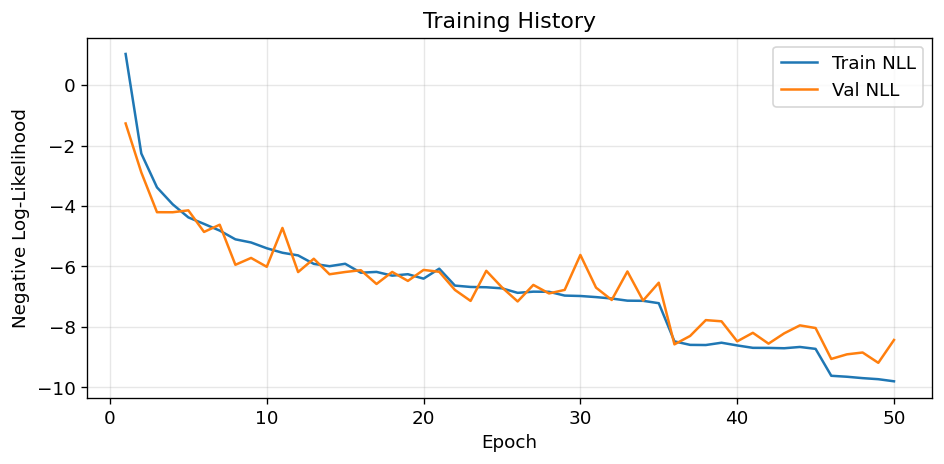

In [ ]:
# ── Plot training curves ──────────────────────────────────────────────────
# This cell is safe to run even if the training cell was skipped, interrupted,
# or if the HISTORY = train(...) line was temporarily commented out.
if 'HISTORY' not in globals():
    print(
        '[INFO] HISTORY is not defined. '
        'Run the training cell first, or skip this plot if you loaded a checkpoint manually.'
    )
elif not isinstance(HISTORY, dict) or len(HISTORY.get('train_loss', [])) == 0:
    print('[INFO] HISTORY exists but contains no training epochs to plot.')
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    epochs_range = range(1, len(HISTORY['train_loss']) + 1)
    ax.plot(epochs_range, HISTORY['train_loss'], label='Train NLL')
    ax.plot(epochs_range, HISTORY['val_loss'],   label='Val NLL')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Negative Log-Likelihood')
    ax.set_title('Training History')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Evaluation

Point predictions are obtained as the **mean of posterior samples** from the flow.
Uncertainties are reported as the **standard deviation** of samples.

Metrics are reported in **physical (unscaled) units** for interpretability.

Target variables:

| Index | Name        | Unit       |
|-------|-------------|------------|
| 0     | coreX       | m          |
| 1     | coreY       | m          |
| 2     | zenithAngle | rad        |
| 3     | azimuthAngle| rad        |
| 4     | logEnergy   | log₁₀(eV)  |
| 5     | Xmax        | g/cm²      |


In [ ]:
###############################################################################
## EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE TEST
##
## OBJETIVO:
##
## 1. Recorrer los eventos que pertenecen al conjunto de test.
## 2. Introducir sus hits en el modelo DeepSets + Normalizing Flow.
## 3. Generar varias reconstrucciones posibles para cada evento.
## 4. Transformar las predicciones escaladas al espacio trigonométrico.
## 5. Reconstruir las variables físicas angulares.
## 6. Calcular:
##      - media posterior;
##      - mediana posterior;
##      - desviación estándar;
##      - percentil 16;
##      - percentil 84.
## 7. Comparar las predicciones con los valores Monte Carlo verdaderos.
## 8. Guardar los resultados en archivos NPZ y CSV.
###############################################################################


# ── TARGETS INTERNOS DEL NORMALIZING FLOW ────────────────────────────────

## ORDEN EXACTO UTILIZADO DURANTE EL ENTRENAMIENTO ##
TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]

TARGET_UNITS = [
    'm',
    'm',
    'dimensionless',
    'dimensionless',
    'dimensionless',
    'log10(eV)',
]


# ── VARIABLES FÍSICAS RECONSTRUIDAS ──────────────────────────────────────

## DESPUÉS DE INVERTIR LA REPRESENTACIÓN TRIGONOMÉTRICA ##
PHYSICAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]

PHYSICAL_TARGET_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(eV)',
]


## DIMENSIONES ESPERADAS ##
N_INTERNAL_TARGETS = 6
N_PHYSICAL_TARGETS = 5


## COMPROBAR CONSISTENCIA CON EL CHECKPOINT ##
if len(TARGET_NAMES) != N_INTERNAL_TARGETS:
    raise ValueError(
        f'TARGET_NAMES has {len(TARGET_NAMES)} entries, '
        f'expected {N_INTERNAL_TARGETS}.'
    )

if len(PHYSICAL_TARGET_NAMES) != N_PHYSICAL_TARGETS:
    raise ValueError(
        f'PHYSICAL_TARGET_NAMES has {len(PHYSICAL_TARGET_NAMES)} entries, '
        f'expected {N_PHYSICAL_TARGETS}.'
    )

if hasattr(TARGET_SCALER, 'mean_') and len(TARGET_SCALER.mean_) != N_INTERNAL_TARGETS:
    raise ValueError(
        f'TARGET_SCALER has {len(TARGET_SCALER.mean_)} targets, '
        f'expected {N_INTERNAL_TARGETS}.'
    )


# ── CONFIGURACIÓN DE EVALUACIÓN ─────────────────────────────────────────

## NÚMERO TOTAL DE MUESTRAS POSTERIORES POR EVENTO ##
N_EVAL_SAMPLES = CFG.get('eval_n_samples', 50)

## NÚMERO DE EVENTOS PROCESADOS SIMULTÁNEAMENTE ##
EVAL_BATCH_SIZE = CFG.get('eval_batch_size', 2)

## NÚMERO DE MUESTRAS POSTERIORES GENERADAS POR CHUNK ##
EVAL_SAMPLE_CHUNK = CFG.get('eval_sample_chunk', 10)

## NÚMERO MÁXIMO DE EVENTOS A EVALUAR ##
## None = TODO EL CONJUNTO DE TEST ##
EVAL_MAX_EVENTS = CFG.get('eval_max_events', None)


# ── FUNCIONES ANGULARES ─────────────────────────────────────────────────

def wrap_angle_rad(angle: np.ndarray) -> np.ndarray:
    """
    Wrap angles to the interval [-pi, pi).
    """

    ## ENVOLVER EL ÁNGULO PARA RESPETAR LA PERIODICIDAD ##
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def circular_difference_rad(
    predicted: np.ndarray,
    true: np.ndarray,
) -> np.ndarray:
    """
    Signed circular difference predicted - true in [-pi, pi).
    """

    ## DIFERENCIA ANGULAR CIRCULAR ##
    return wrap_angle_rad(predicted - true)


def trig_to_physical(
    values: np.ndarray,
) -> np.ndarray:
    """
    Convert trig target representation:

        [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]

    into physical representation:

        [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]

    The function accepts arrays whose last dimension is 6.
    """

    values = np.asarray(values)

    ## COMPROBAR DIMENSIÓN ##
    if values.shape[-1] != N_INTERNAL_TARGETS:
        raise ValueError(
            f'Expected last dimension {N_INTERNAL_TARGETS}, '
            f'got {values.shape}.'
        )

    ## EXTRAER TARGETS ##
    core_x = values[..., 0]
    core_y = values[..., 1]

    sin_zenith = values[..., 2]

    sin_azimuth = values[..., 3]
    cos_azimuth = values[..., 4]

    log_energy = values[..., 5]


    ## RECONSTRUIR ZENITH ##
    ##
    ## EL FLOW PUEDE GENERAR PEQUEÑAS EXCURSIONES NUMÉRICAS
    ## FUERA DEL DOMINIO MATEMÁTICO [-1, 1] DE arcsin.
    ##
    ## ESTE CLIP ES ÚNICAMENTE MATEMÁTICO Y EVITA NaN.
    ## NO SE RECORTA EL ZENITH FINAL AL INTERVALO FÍSICO 0-15 grados,
    ## YA QUE HACERLO PODRÍA MEJORAR ARTIFICIALMENTE LAS MÉTRICAS.
    sin_zenith_safe = np.clip(
        sin_zenith,
        -1.0,
        1.0,
    )

    zenith = np.arcsin(
        sin_zenith_safe
    )


    ## RECONSTRUIR AZIMUT ##
    ## atan2 RESPETA AUTOMÁTICAMENTE LA PERIODICIDAD DEL ÁNGULO ##
    azimuth = np.arctan2(
        sin_azimuth,
        cos_azimuth,
    )


    ## CONSTRUIR ARRAY FÍSICO ##
    physical = np.stack(
        [
            core_x,
            core_y,
            zenith,
            azimuth,
            log_energy,
        ],
        axis=-1,
    )

    return physical


def circular_mean_rad(
    angles: np.ndarray,
    axis=0,
) -> np.ndarray:
    """
    Circular mean of angles in radians.
    """

    ## MEDIA CIRCULAR MEDIANTE VECTOR UNITARIO ##
    mean_sin = np.mean(
        np.sin(angles),
        axis=axis,
    )

    mean_cos = np.mean(
        np.cos(angles),
        axis=axis,
    )

    return np.arctan2(
        mean_sin,
        mean_cos,
    )


def circular_std_rad(
    angles: np.ndarray,
    axis=0,
) -> np.ndarray:
    """
    Circular standard deviation in radians.
    """

    ## LONGITUD DEL VECTOR RESULTANTE ##
    mean_sin = np.mean(
        np.sin(angles),
        axis=axis,
    )

    mean_cos = np.mean(
        np.cos(angles),
        axis=axis,
    )

    R = np.sqrt(
        mean_sin ** 2
        + mean_cos ** 2
    )

    ## EVITAR log(0) POR SEGURIDAD NUMÉRICA ##
    R = np.clip(
        R,
        1e-12,
        1.0,
    )

    return np.sqrt(
        -2.0 * np.log(R)
    )


def circular_posterior_statistics(
    angles: np.ndarray,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Calculate circular posterior statistics.

    Input shape:
        (n_samples, batch)

    Returns:
        mean
        median
        std
        q16
        q84

    All angles are returned in radians.
    """

    ## MEDIA CIRCULAR ##
    mean_angle = circular_mean_rad(
        angles,
        axis=0,
    )


    ## DESENVOLVER CADA POSTERIOR ALREDEDOR DE SU MEDIA CIRCULAR ##
    ## ESTO EVITA PROBLEMAS EN LA DISCONTINUIDAD -pi / +pi ##
    centered = circular_difference_rad(
        angles,
        mean_angle[None, :],
    )


    ## MEDIANA EN EL ESPACIO LOCAL DESENVUELTO ##
    median_offset = np.median(
        centered,
        axis=0,
    )

    median_angle = wrap_angle_rad(
        mean_angle
        + median_offset
    )


    ## PERCENTILES EN EL ESPACIO LOCAL ##
    q16_offset = np.percentile(
        centered,
        16,
        axis=0,
    )

    q84_offset = np.percentile(
        centered,
        84,
        axis=0,
    )


    q16_angle = wrap_angle_rad(
        mean_angle
        + q16_offset
    )

    q84_angle = wrap_angle_rad(
        mean_angle
        + q84_offset
    )


    ## DESVIACIÓN ESTÁNDAR CIRCULAR ##
    std_angle = circular_std_rad(
        angles,
        axis=0,
    )


    return (
        mean_angle,
        median_angle,
        std_angle,
        q16_angle,
        q84_angle,
    )


# ── CREAR DATALOADER DE EVALUACIÓN ──────────────────────────────────────

def make_eval_loader(
    test_ds,
    batch_size: int,
    max_events: Optional[int] = None,
) -> DataLoader:
    """
    Create a small-batch evaluation loader without rebuilding or reloading data.
    """

    ## USAR TODO EL TEST SI NO EXISTE LÍMITE ##
    if max_events is None:
        ds = test_ds

    else:

        ## LIMITAR EL NÚMERO DE EVENTOS ##
        n = min(
            max_events,
            len(test_ds),
        )

        ## NO SE RECONSTRUYE NI RECARGA EL DATASET ##
        ds = torch.utils.data.Subset(
            test_ds,
            np.arange(n),
        )


    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )


# ── FUNCIÓN PRINCIPAL DE EVALUACIÓN ─────────────────────────────────────

def evaluate_on_loader(
    model: nn.Module,
    loader: DataLoader,
    target_scaler: StandardScaler,
    n_samples: int = 50,
    sample_chunk_size: int = 10,
    keep_samples: bool = False,
) -> Tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    Optional[np.ndarray],
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """
    Memory-safe posterior evaluation.

    Internal Flow representation:
        [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]

    Returned physical representation:
        [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]

    Returns
    -------
    y_true
        (N, 5), physical Monte Carlo targets.

    y_pred
        (N, 5), posterior mean.

    y_std
        (N, 5), posterior standard deviation.

    y_samps
        Optional posterior samples in physical variables.

    y_median
        (N, 5), posterior median.

    y_q16
        (N, 5), posterior percentile 16.

    y_q84
        (N, 5), posterior percentile 84.
    """

    ## PONER EL MODELO EN MODO EVALUACIÓN ##
    model.eval()


    ## LISTAS DE RESULTADOS ##
    all_true = []
    all_pred = []
    all_median = []
    all_q16 = []
    all_q84 = []
    all_std = []

    all_samps = [] if keep_samples else None


    ## COMPROBAR DIMENSIÓN DEL SCALER ##
    if hasattr(target_scaler, 'mean_'):
        if len(target_scaler.mean_) != N_INTERNAL_TARGETS:
            raise ValueError(
                f'TARGET_SCALER has {len(target_scaler.mean_)} targets, '
                f'expected {N_INTERNAL_TARGETS}.'
            )


    ## LIMPIAR CACHE CUDA ANTES DE COMENZAR ##
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


    ## DESACTIVAR GRADIENTES DURANTE EVALUACIÓN ##
    with torch.no_grad():

        for hits, mask, targets in tqdm(
            loader,
            desc='Evaluating',
        ):

            ## MOVER ENTRADAS AL DISPOSITIVO ##
            hits = hits.to(
                DEVICE,
                non_blocking=False,
            )

            mask = mask.to(
                DEVICE,
                non_blocking=False,
            )


            # ── TARGET VERDADERO ──────────────────────────────────────────

            ## TARGET ESCALADO DEL DATASET ##
            tgt_scaled = targets.cpu().numpy()


            if (
                tgt_scaled.ndim != 2
                or tgt_scaled.shape[1] != N_INTERNAL_TARGETS
            ):

                raise ValueError(
                    f'Expected targets with {N_INTERNAL_TARGETS} columns, '
                    f'got {tgt_scaled.shape}.'
                )


            ## DESESCALAR LOS 6 TARGETS INTERNOS ##
            tgt_trig = target_scaler.inverse_transform(
                tgt_scaled
            )


            ## CONVERTIR A LAS 5 VARIABLES FÍSICAS ##
            tgt_phys = trig_to_physical(
                tgt_trig
            )


            all_true.append(
                tgt_phys
            )


            # ── MUESTREO POSTERIOR ────────────────────────────────────────

            batch_samps_phys = []

            remaining = n_samples


            while remaining > 0:

                ## NÚMERO DE MUESTRAS DEL CHUNK ACTUAL ##
                n_now = min(
                    sample_chunk_size,
                    remaining,
                )


                ## GENERAR MUESTRAS DEL FLOW ##
                ##
                ## FORMA ESPERADA:
                ##     (n_now, B, 6)
                ##
                samps_scaled = model.sample(
                    hits,
                    mask,
                    n_samples=n_now,
                ).detach().cpu().numpy()


                ## DIMENSIONES ##
                ns, B, d = samps_scaled.shape


                if d != N_INTERNAL_TARGETS:

                    raise ValueError(
                        f'Expected sample target dimension '
                        f'{N_INTERNAL_TARGETS}, got {d}.'
                    )


                ## DESESCALAR LOS 6 TARGETS INTERNOS ##
                samps_trig = target_scaler.inverse_transform(
                    samps_scaled.reshape(
                        ns * B,
                        d,
                    )
                ).reshape(
                    ns,
                    B,
                    d,
                )


                ## CONVERTIR CADA MUESTRA POSTERIOR AL ESPACIO FÍSICO ##
                ##
                ## MUY IMPORTANTE:
                ## LA TRANSFORMACIÓN ANGULAR SE REALIZA ANTES DE CALCULAR
                ## MEDIA, MEDIANA, STD Y PERCENTILES.
                ##
                samps_phys = trig_to_physical(
                    samps_trig
                )


                ## GUARDAR CHUNK ##
                batch_samps_phys.append(
                    samps_phys
                )


                ## ACTUALIZAR MUESTRAS RESTANTES ##
                remaining -= n_now


                ## LIBERAR ARRAYS TEMPORALES ##
                del samps_scaled
                del samps_trig


            ## UNIR TODOS LOS CHUNKS ##
            ##
            ## RESULTADO:
            ##     (n_samples, B, 5)
            ##
            batch_samps_phys = np.concatenate(
                batch_samps_phys,
                axis=0,
            )


            # ── ESTADÍSTICOS LINEALES ─────────────────────────────────────

            ## ÍNDICES DE VARIABLES FÍSICAS ##
            ix_coreX = 0
            ix_coreY = 1
            ix_zenith = 2
            ix_azimuth = 3
            ix_logE = 4


            ## RESERVAR MATRICES ##
            B = batch_samps_phys.shape[1]

            pred_mean = np.zeros(
                (B, N_PHYSICAL_TARGETS),
                dtype=np.float64,
            )

            pred_median = np.zeros_like(
                pred_mean
            )

            pred_std = np.zeros_like(
                pred_mean
            )

            pred_q16 = np.zeros_like(
                pred_mean
            )

            pred_q84 = np.zeros_like(
                pred_mean
            )


            ## CORE X, CORE Y, ZENITH Y ENERGÍA ##
            ## SON TRATADOS COMO VARIABLES LINEALES EN SU ESPACIO FÍSICO ##
            linear_indices = [
                ix_coreX,
                ix_coreY,
                ix_zenith,
                ix_logE,
            ]


            for i in linear_indices:

                values = batch_samps_phys[
                    :,
                    :,
                    i,
                ]

                pred_mean[:, i] = np.mean(
                    values,
                    axis=0,
                )

                pred_median[:, i] = np.median(
                    values,
                    axis=0,
                )

                pred_std[:, i] = np.std(
                    values,
                    axis=0,
                )

                pred_q16[:, i] = np.percentile(
                    values,
                    16,
                    axis=0,
                )

                pred_q84[:, i] = np.percentile(
                    values,
                    84,
                    axis=0,
                )


            # ── ESTADÍSTICOS CIRCULARES DEL AZIMUT ────────────────────────

            azimuth_samples = batch_samps_phys[
                :,
                :,
                ix_azimuth,
            ]


            (
                az_mean,
                az_median,
                az_std,
                az_q16,
                az_q84,
            ) = circular_posterior_statistics(
                azimuth_samples
            )


            pred_mean[:, ix_azimuth] = az_mean
            pred_median[:, ix_azimuth] = az_median
            pred_std[:, ix_azimuth] = az_std
            pred_q16[:, ix_azimuth] = az_q16
            pred_q84[:, ix_azimuth] = az_q84


            ## GUARDAR ESTADÍSTICOS DEL BATCH ##
            all_pred.append(
                pred_mean
            )

            all_median.append(
                pred_median
            )

            all_std.append(
                pred_std
            )

            all_q16.append(
                pred_q16
            )

            all_q84.append(
                pred_q84
            )


            ## GUARDAR MUESTRAS COMPLETAS SOLO SI SE SOLICITA ##
            if keep_samples:
                all_samps.append(
                    batch_samps_phys
                )


            ## LIBERAR MEMORIA ##
            del hits
            del mask
            del batch_samps_phys


    # ── CONCATENAR TODOS LOS BATCHES ─────────────────────────────────────

    y_true = np.concatenate(
        all_true,
        axis=0,
    )

    y_pred = np.concatenate(
        all_pred,
        axis=0,
    )

    y_median = np.concatenate(
        all_median,
        axis=0,
    )

    y_q16 = np.concatenate(
        all_q16,
        axis=0,
    )

    y_q84 = np.concatenate(
        all_q84,
        axis=0,
    )

    y_std = np.concatenate(
        all_std,
        axis=0,
    )


    ## CONCATENAR MUESTRAS COMPLETAS SI SE HAN SOLICITADO ##
    if keep_samples:

        y_samps = np.concatenate(
            all_samps,
            axis=1,
        )

    else:

        y_samps = None


    return (
        y_true,
        y_pred,
        y_std,
        y_samps,
        y_median,
        y_q16,
        y_q84,
    )


# ── COMPROBAR CHECKPOINT CARGADO ─────────────────────────────────────────

## SE UTILIZA checkpoint_path, QUE CORRESPONDE AL ARCHIVO
## QUE HEMOS CARGADO REALMENTE EN ESTA SESIÓN.
##
## NO DEPENDEMOS DE CFG['checkpoint_path'], YA QUE CFG PROCEDE DEL
## ENTRENAMIENTO Y PODRÍA CONTENER UNA RUTA ANTIGUA.

if 'checkpoint_path' not in globals():

    raise NameError(
        'checkpoint_path is not defined. '
        'Load the trained checkpoint before running evaluation.'
    )


checkpoint_path = Path(
    checkpoint_path
)


if checkpoint_path.exists():

    print(
        f'[INFO] Loaded checkpoint available at '
        f'{checkpoint_path}.'
    )

else:

    raise FileNotFoundError(
        f'Loaded checkpoint not found:\n'
        f'{checkpoint_path}'
    )


# ── COMPROBAR CONSISTENCIA DEL CONJUNTO DE TEST ──────────────────────────

## ES FUNDAMENTAL QUE test_ds CORRESPONDA EXACTAMENTE A LOS test_idx
## GUARDADOS DURANTE EL ENTRENAMIENTO.
##
## ESTO EVITA:
##
## - EVALUAR OTROS EVENTOS;
## - CAMBIAR EL ORDEN;
## - ASOCIAR PREDICCIONES A EVENT_IDS INCORRECTOS;
## - ALTERAR LA COMPARACIÓN CON EL MODELO ENTRENADO.

if 'test_idx' not in globals():

    raise NameError(
        'test_idx is not defined. '
        'The test indices must be restored from the trained checkpoint.'
    )


if 'test_ds' not in globals():

    raise NameError(
        'test_ds is not defined. '
        'Rebuild test_ds using the test_idx restored from the checkpoint.'
    )


checkpoint_test_indices = np.asarray(
    test_idx,
    dtype=np.int64,
)


## COMPROBAR NÚMERO DE EVENTOS ##
if len(test_ds) != len(checkpoint_test_indices):

    raise ValueError(
        f'test_ds contains {len(test_ds)} events but the checkpoint '
        f'contains {len(checkpoint_test_indices)} test indices.\n'
        'Rebuild test_ds using the test_idx stored in the checkpoint.'
    )


## SI test_ds ES UN SUBSET, COMPROBAR TAMBIÉN LOS ÍNDICES EXACTOS ##
if isinstance(
    test_ds,
    torch.utils.data.Subset,
):

    test_ds_indices = np.asarray(
        test_ds.indices,
        dtype=np.int64,
    )


    if not np.array_equal(
        test_ds_indices,
        checkpoint_test_indices,
    ):

        raise ValueError(
            'test_ds does not contain exactly the same test indices '
            'stored in the trained checkpoint.'
        )


print(
    f'[OK] Test dataset consistent with checkpoint: '
    f'{len(checkpoint_test_indices)} events.'
)


# ── CREAR DATALOADER DE EVALUACIÓN ──────────────────────────────────────

eval_loader = make_eval_loader(
    test_ds,
    batch_size=EVAL_BATCH_SIZE,
    max_events=EVAL_MAX_EVENTS,
)


# ── CONSERVAR ÍNDICES ORIGINALES ────────────────────────────────────────

if EVAL_MAX_EVENTS is None:

    EVAL_EVENT_INDICES = np.asarray(
        test_idx,
        dtype=np.int64,
    )

else:

    EVAL_EVENT_INDICES = np.asarray(
        test_idx,
        dtype=np.int64,
    )[
        :min(
            EVAL_MAX_EVENTS,
            len(test_idx),
        )
    ]


# ── EVALUAR MODELO ──────────────────────────────────────────────────────

Y_TRUE, Y_PRED, Y_STD, Y_SAMPS, Y_PRED_MEDIAN, Y_Q16, Y_Q84 = evaluate_on_loader(

    MODEL,

    eval_loader,

    TARGET_SCALER,

    n_samples=N_EVAL_SAMPLES,

    sample_chunk_size=EVAL_SAMPLE_CHUNK,

    keep_samples=False,
)


print(
    f'Test set: {len(Y_TRUE)} events evaluated.'
)

print(
    'Physical target order: '
    '[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]'
)

print(
    'Y_SAMPS is not stored by default to save memory. '
    'Use keep_samples=True only for small subsets.'
)


# ── COMPROBAR CORRESPONDENCIA ENTRE RESULTADOS E ÍNDICES ────────────────

if len(Y_TRUE) != len(EVAL_EVENT_INDICES):

    raise RuntimeError(
        f'Evaluation returned {len(Y_TRUE)} events but '
        f'EVAL_EVENT_INDICES contains {len(EVAL_EVENT_INDICES)} indices.'
    )


print(
    f'[OK] Predictions matched to {len(EVAL_EVENT_INDICES)} '
    f'original dataset indices.'
)


# ── COMPROBACIONES FINALES ──────────────────────────────────────────────

for arr_name, arr in [
    ('Y_TRUE', Y_TRUE),
    ('Y_PRED', Y_PRED),
    ('Y_STD', Y_STD),
    ('Y_PRED_MEDIAN', Y_PRED_MEDIAN),
    ('Y_Q16', Y_Q16),
    ('Y_Q84', Y_Q84),
]:

    if (
        arr.ndim != 2
        or arr.shape[1] != N_PHYSICAL_TARGETS
    ):

        raise ValueError(
            f'{arr_name} has shape {arr.shape}; '
            f'expected (*, {N_PHYSICAL_TARGETS}).'
        )

    if not np.all(
        np.isfinite(arr)
    ):

        raise ValueError(
            f'{arr_name} contains non-finite values.'
        )


print()
print('Evaluation physical ranges:')

print(
    f'  zenith true : '
    f'{np.rad2deg(Y_TRUE[:, 2]).min():.4f} -> '
    f'{np.rad2deg(Y_TRUE[:, 2]).max():.4f} deg'
)

print(
    f'  zenith pred : '
    f'{np.rad2deg(Y_PRED_MEDIAN[:, 2]).min():.4f} -> '
    f'{np.rad2deg(Y_PRED_MEDIAN[:, 2]).max():.4f} deg'
)

print(
    f'  azimuth true: '
    f'{np.rad2deg(Y_TRUE[:, 3]).min():.4f} -> '
    f'{np.rad2deg(Y_TRUE[:, 3]).max():.4f} deg'
)

print(
    f'  azimuth pred: '
    f'{np.rad2deg(Y_PRED_MEDIAN[:, 3]).min():.4f} -> '
    f'{np.rad2deg(Y_PRED_MEDIAN[:, 3]).max():.4f} deg'
)


# ── INFORMAR PREDICCIONES DE ZENITH FUERA DEL RANGO DE ENTRENAMIENTO ────

pred_zenith_deg = np.rad2deg(
    Y_PRED_MEDIAN[:, 2]
)


n_zenith_below_zero = int(
    np.sum(
        pred_zenith_deg < 0.0
    )
)

n_zenith_above_15 = int(
    np.sum(
        pred_zenith_deg > 15.0
    )
)


print()
print(
    'Zenith predictions outside training-domain limits:'
)

print(
    f'  zenith < 0 deg  : {n_zenith_below_zero}'
)

print(
    f'  zenith > 15 deg : {n_zenith_above_15}'
)

print(
    '  NOTE: predictions are NOT clipped to 0-15 deg during evaluation.'
)


# ── GUARDAR RESULTADOS NPZ ──────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    eval_path_latest = artifact_path(
        'evaluation_results_trig_angles.npz',
        run_specific=False,
    )

    eval_path_run = artifact_path(
        'evaluation_results_trig_angles.npz',
        run_specific=True,
    )


    ## CONTENIDO DEL NPZ ##
    eval_save_dict = dict(

        Y_TRUE=Y_TRUE,

        Y_PRED=Y_PRED,

        Y_STD=Y_STD,

        Y_PRED_MEDIAN=Y_PRED_MEDIAN,

        Y_Q16=Y_Q16,

        Y_Q84=Y_Q84,

        physical_target_names=np.array(
            PHYSICAL_TARGET_NAMES
        ),

        physical_target_units=np.array(
            PHYSICAL_TARGET_UNITS
        ),

        internal_target_names=np.array(
            TARGET_NAMES
        ),

        internal_target_units=np.array(
            TARGET_UNITS
        ),

        event_indices=np.asarray(
            EVAL_EVENT_INDICES
        ),

        cfg=np.array(
            [
                json.dumps(
                    CFG,
                    default=str,
                )
            ]
        ),

        xmax_removed=np.array(
            [True]
        ),

        trig_angle_representation=np.array(
            [True]
        ),
    )


    np.savez_compressed(
        eval_path_latest,
        **eval_save_dict,
    )

    np.savez_compressed(
        eval_path_run,
        **eval_save_dict,
    )


    print(
        f'[saved] {eval_path_latest}'
    )

    print(
        f'[saved] {eval_path_run}'
    )


# ── CREAR CSV CON UNA FILA POR EVENTO ───────────────────────────────────

def build_event_predictions_dataframe(
    event_indices: np.ndarray,
    y_true: np.ndarray,
    y_pred_mean: np.ndarray,
    y_std: np.ndarray,
    y_pred_median: Optional[np.ndarray] = None,
    y_q16: Optional[np.ndarray] = None,
    y_q84: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    """
    Build event-level prediction table.

    Physical target order:

        [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]

    The posterior median is used as the main point estimate when available.
    """

    event_indices = np.asarray(
        event_indices
    )


    ## USAR MEDIANA POSTERIOR COMO PREDICCIÓN PUNTUAL ##
    point = (
        y_pred_median
        if y_pred_median is not None
        else y_pred_mean
    )


    point_label = (
        'median'
        if y_pred_median is not None
        else 'mean'
    )


    ## ÍNDICES DE VARIABLES FÍSICAS ##
    ix_coreX = PHYSICAL_TARGET_NAMES.index(
        'coreX'
    )

    ix_coreY = PHYSICAL_TARGET_NAMES.index(
        'coreY'
    )

    ix_zenith = PHYSICAL_TARGET_NAMES.index(
        'zenithAngle'
    )

    ix_azimuth = PHYSICAL_TARGET_NAMES.index(
        'azimuthAngle'
    )

    ix_logE = PHYSICAL_TARGET_NAMES.index(
        'logEnergy'
    )


    ## COMPROBAR ARRAYS ##
    for arr_name, arr in [
        ('y_true', y_true),
        ('y_pred_mean', y_pred_mean),
        ('y_std', y_std),
        ('point', point),
    ]:

        if (
            arr.ndim != 2
            or arr.shape[1] != N_PHYSICAL_TARGETS
        ):

            raise ValueError(
                f'{arr_name} has shape {arr.shape}; '
                f'expected (*, {N_PHYSICAL_TARGETS}).'
            )


    ## COMPROBAR NÚMERO DE FILAS ##
    if len(event_indices) != len(y_true):

        raise ValueError(
            f'event_indices contains {len(event_indices)} entries but '
            f'y_true contains {len(y_true)} events.'
        )


    ## IDS ORIGINALES ##
    run_ids_arr = (
        np.asarray(RUN_IDS)
        if 'RUN_IDS' in globals()
        else np.full(
            len(EVENT_IDS),
            -1,
        )
    )

    event_ids_arr = np.asarray(
        EVENT_IDS
    )


    ## ENERGÍA ##
    pred_logE = point[
        :,
        ix_logE,
    ]

    true_logE = y_true[
        :,
        ix_logE,
    ]


    ## DIFERENCIA CIRCULAR DE AZIMUT ##
    delta_azimuth_rad = circular_difference_rad(
        point[:, ix_azimuth],
        y_true[:, ix_azimuth],
    )


    rows = {

        'runID':
            run_ids_arr[event_indices],

        'eventID':
            event_ids_arr[event_indices],

        'prediction_point':
            point_label,


        ## CORE ##
        'pred_coreX_m':
            point[:, ix_coreX],

        'pred_coreY_m':
            point[:, ix_coreY],


        ## ZENITH ##
        'pred_zenith_rad':
            point[:, ix_zenith],

        'pred_zenith_deg':
            np.rad2deg(
                point[:, ix_zenith]
            ),


        ## ELEVACIÓN ##
        'pred_elevation_rad':
            (np.pi / 2.0)
            - point[:, ix_zenith],

        'pred_elevation_deg':
            90.0
            - np.rad2deg(
                point[:, ix_zenith]
            ),


        ## AZIMUT ##
        'pred_azimuth_rad':
            point[:, ix_azimuth],

        'pred_azimuth_deg':
            np.rad2deg(
                point[:, ix_azimuth]
            ),


        ## ENERGÍA ##
        'pred_logEnergy':
            pred_logE,

        'pred_energy_eV':
            np.power(
                10.0,
                pred_logE,
            ),


        ## INCERTIDUMBRES ##
        'std_coreX_m':
            y_std[:, ix_coreX],

        'std_coreY_m':
            y_std[:, ix_coreY],

        'std_zenith_rad':
            y_std[:, ix_zenith],

        'std_zenith_deg':
            np.rad2deg(
                y_std[:, ix_zenith]
            ),

        'std_azimuth_rad':
            y_std[:, ix_azimuth],

        'std_azimuth_deg':
            np.rad2deg(
                y_std[:, ix_azimuth]
            ),

        'std_logEnergy':
            y_std[:, ix_logE],


        ## VERDAD MONTE CARLO ##
        'true_coreX_m':
            y_true[:, ix_coreX],

        'true_coreY_m':
            y_true[:, ix_coreY],

        'true_zenith_rad':
            y_true[:, ix_zenith],

        'true_zenith_deg':
            np.rad2deg(
                y_true[:, ix_zenith]
            ),

        'true_elevation_deg':
            90.0
            - np.rad2deg(
                y_true[:, ix_zenith]
            ),

        'true_azimuth_rad':
            y_true[:, ix_azimuth],

        'true_azimuth_deg':
            np.rad2deg(
                y_true[:, ix_azimuth]
            ),

        'true_logEnergy':
            true_logE,

        'true_energy_eV':
            np.power(
                10.0,
                true_logE,
            ),
    }


    # ── ERROR RADIAL DEL CORE ────────────────────────────────────────────

    rows[
        'core_radial_error_m'
    ] = np.sqrt(

        (
            rows['true_coreX_m']
            - rows['pred_coreX_m']
        ) ** 2

        +

        (
            rows['true_coreY_m']
            - rows['pred_coreY_m']
        ) ** 2
    )


    # ── RESIDUOS ─────────────────────────────────────────────────────────

    rows[
        'delta_coreX_m'
    ] = (
        rows['pred_coreX_m']
        - rows['true_coreX_m']
    )


    rows[
        'delta_coreY_m'
    ] = (
        rows['pred_coreY_m']
        - rows['true_coreY_m']
    )


    ## ZENITH NO TIENE DISCONTINUIDAD EN EL DOMINIO UTILIZADO ##
    rows[
        'delta_zenith_rad'
    ] = (
        rows['pred_zenith_rad']
        - rows['true_zenith_rad']
    )


    rows[
        'delta_zenith_deg'
    ] = np.rad2deg(
        rows['delta_zenith_rad']
    )


    ## AZIMUT DEBE USAR DIFERENCIA CIRCULAR ##
    rows[
        'delta_azimuth_rad'
    ] = delta_azimuth_rad


    rows[
        'delta_azimuth_deg'
    ] = np.rad2deg(
        delta_azimuth_rad
    )


    rows[
        'delta_logEnergy'
    ] = (
        rows['pred_logEnergy']
        - rows['true_logEnergy']
    )


    # ── SEPARACIÓN ANGULAR FÍSICA ────────────────────────────────────────

    ## PRODUCTO ESCALAR ENTRE LOS DOS VECTORES DIRECCIÓN ##
    cos_delta_psi = (

        np.cos(
            rows['true_zenith_rad']
        )
        *
        np.cos(
            rows['pred_zenith_rad']
        )

        +

        np.sin(
            rows['true_zenith_rad']
        )
        *
        np.sin(
            rows['pred_zenith_rad']
        )
        *
        np.cos(
            delta_azimuth_rad
        )
    )


    ## PROTEGER CONTRA ERRORES NUMÉRICOS ##
    cos_delta_psi = np.clip(
        cos_delta_psi,
        -1.0,
        1.0,
    )


    rows[
        'angular_separation_rad'
    ] = np.arccos(
        cos_delta_psi
    )


    rows[
        'angular_separation_deg'
    ] = np.rad2deg(
        rows[
            'angular_separation_rad'
        ]
    )


    # ── PERCENTILES POSTERIORES ──────────────────────────────────────────

    if (
        y_q16 is not None
        and y_q84 is not None
    ):

        ## CORE ##
        rows['q16_coreX'] = y_q16[:, ix_coreX]
        rows['q84_coreX'] = y_q84[:, ix_coreX]

        rows['q16_coreY'] = y_q16[:, ix_coreY]
        rows['q84_coreY'] = y_q84[:, ix_coreY]


        ## ZENITH ##
        rows['q16_zenith_rad'] = y_q16[:, ix_zenith]
        rows['q84_zenith_rad'] = y_q84[:, ix_zenith]

        rows['q16_zenith_deg'] = np.rad2deg(
            y_q16[:, ix_zenith]
        )

        rows['q84_zenith_deg'] = np.rad2deg(
            y_q84[:, ix_zenith]
        )


        ## AZIMUT ##
        ## ESTOS LÍMITES SON CIRCULARES Y PUEDEN CRUZAR ±pi ##
        rows['q16_azimuth_rad'] = y_q16[:, ix_azimuth]
        rows['q84_azimuth_rad'] = y_q84[:, ix_azimuth]

        rows['q16_azimuth_deg'] = np.rad2deg(
            y_q16[:, ix_azimuth]
        )

        rows['q84_azimuth_deg'] = np.rad2deg(
            y_q84[:, ix_azimuth]
        )


        ## ENERGÍA ##
        rows['q16_logEnergy'] = y_q16[:, ix_logE]
        rows['q84_logEnergy'] = y_q84[:, ix_logE]


    return pd.DataFrame(
        rows
    )


# ── CONSTRUIR DATAFRAME ─────────────────────────────────────────────────

EVENT_PREDICTIONS_DF = build_event_predictions_dataframe(

    EVAL_EVENT_INDICES,

    Y_TRUE,

    Y_PRED,

    Y_STD,

    y_pred_median=Y_PRED_MEDIAN,

    y_q16=Y_Q16,

    y_q84=Y_Q84,
)


# ── GUARDAR CSV ──────────────────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    event_csv = artifact_path(
        'event_predictions_trig_angles.csv',
        run_specific=False,
    )

    event_csv_run = artifact_path(
        'event_predictions_trig_angles.csv',
        run_specific=True,
    )


    EVENT_PREDICTIONS_DF.to_csv(
        event_csv,
        index=False,
    )

    EVENT_PREDICTIONS_DF.to_csv(
        event_csv_run,
        index=False,
    )


    print(
        f'[saved] {event_csv}'
    )

    print(
        f'[saved] {event_csv_run}'
    )


# ── RESUMEN ANGULAR INICIAL ─────────────────────────────────────────────

angular_sep = EVENT_PREDICTIONS_DF[
    'angular_separation_deg'
].to_numpy()


print()
print(
    '============================================================'
)

print(
    ' RESUMEN INICIAL DE RECONSTRUCCIÓN ANGULAR'
)

print(
    '============================================================'
)

print(
    f'Eventos evaluados        : {len(angular_sep)}'
)

print(
    f'Mediana deltaPsi         : {np.median(angular_sep):.4f} deg'
)

print(
    f'P68 deltaPsi             : {np.percentile(angular_sep, 68):.4f} deg'
)

print(
    f'P95 deltaPsi             : {np.percentile(angular_sep, 95):.4f} deg'
)

print(
    f'Media deltaPsi           : {np.mean(angular_sep):.4f} deg'
)


print()
print(
    'Referencia planeFit2 ya validada:'
)

print(
    '  Mediana deltaPsi       : 0.4641 deg'
)

print(
    '  P68 deltaPsi           : 0.6594 deg'
)

print(
    '  P95 deltaPsi           : 1.7077 deg'
)


print()
print(
    'Comparación definitiva con planeFit2 debe realizarse '
    'sobre exactamente los mismos eventos del test.'
)


# ── MOSTRAR PRIMEROS EVENTOS ────────────────────────────────────────────

display(
    EVENT_PREDICTIONS_DF.head()
)

[INFO] Loaded checkpoint available at /content/gdrive/MyDrive/TFM/gamma_flow_outputs/full_training_checkpoint_trig_angles.pt.
[OK] Test dataset consistent with checkpoint: 5000 events.


Evaluating:   0%|          | 0/2500 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Test set: 5000 events evaluated.
Physical target order: [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]
Y_SAMPS is not stored by default to save memory. Use keep_samples=True only for small subsets.
[OK] Predictions matched to 5000 original dataset indices.


ValueError: Y_STD contains non-finite values.

In [ ]:
###############################################################################
## CALIBRACIÓN DE LOS INTERVALOS POSTERIORES
##
## OBJETIVO:
##
## 1. Evaluar el modelo sobre un conjunto de calibración.
## 2. Comprobar la cobertura original de los intervalos q16-q84.
## 3. Calcular un factor de corrección para cada target lineal.
## 4. Aplicar los factores al conjunto de test.
## 5. Comprobar la cobertura antes y después de calibrar.
## 6. Guardar los factores y los intervalos calibrados.
##
## IMPORTANTE:
##
## evaluate_on_loader devuelve las variables YA CONVERTIDAS al espacio físico:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
##
## Por tanto, este bloque trabaja con 5 targets físicos.
##
## NO debe calibrarse directamente en TARGET_NAMES, ya que TARGET_NAMES
## representa los 6 targets internos del Normalizing Flow:
##
##     [
##         coreX,
##         coreY,
##         sinZenith,
##         sinAzimuth,
##         cosAzimuth,
##         logEnergy
##     ]
##
## La representación trigonométrica se utiliza únicamente dentro de la red.
## evaluate_on_loader reconstruye posteriormente:
##
##     zenithAngle  = arcsin(sinZenith)
##     azimuthAngle = atan2(sinAzimuth, cosAzimuth)
##
## y devuelve las 5 variables físicas sobre las que se evalúa la cobertura.
##
## La calibración no cambia:
##
##     Y_PRED
##     Y_PRED_MEDIAN
##
## Solo modifica la anchura de los intervalos:
##
##     Y_Q16
##     Y_Q84
##
## azimuthAngle se evalúa como variable circular y NO se calibra mediante
## el factor lineal utilizado para los demás targets.
##
## También se reutilizarán CAL_TRUE, CAL_MEDIAN, CAL_Q16 y CAL_Q84 si ya
## existen en memoria con las dimensiones correctas, evitando volver a
## evaluar los 5000 eventos de validación innecesariamente.
###############################################################################


import json

from typing import Dict, List, Optional, Sequence, Tuple


# ── CONFIGURACIÓN DE TARGETS INTERNOS ────────────────────────────────────

## ORDEN EXACTO UTILIZADO POR EL NORMALIZING FLOW ##
CALIBRATION_INTERNAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


## SI TARGET_NAMES ESTÁ DISPONIBLE, COMPROBAR QUE COINCIDE CON EL MODELO ##
if 'TARGET_NAMES' in globals():

    if list(TARGET_NAMES) != CALIBRATION_INTERNAL_TARGET_NAMES:

        raise ValueError(
            'TARGET_NAMES does not match the expected internal '
            'target representation.\n'
            f'Current : {list(TARGET_NAMES)}\n'
            f'Expected: {CALIBRATION_INTERNAL_TARGET_NAMES}'
        )


# ── CONFIGURACIÓN DE TARGETS FÍSICOS ─────────────────────────────────────

## ORDEN EXACTO DEVUELTO POR evaluate_on_loader ##
CALIBRATION_PHYSICAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


## COMPROBAR CONSISTENCIA CON LA CELDA DE EVALUACIÓN ##
if list(PHYSICAL_TARGET_NAMES) != CALIBRATION_PHYSICAL_TARGET_NAMES:

    raise ValueError(
        'PHYSICAL_TARGET_NAMES does not match the expected physical '
        'target representation.\n'
        f'Current : {list(PHYSICAL_TARGET_NAMES)}\n'
        f'Expected: {CALIBRATION_PHYSICAL_TARGET_NAMES}'
    )


## NÚMERO DE TARGETS FÍSICOS ##
N_CALIBRATION_PHYSICAL_TARGETS = len(
    CALIBRATION_PHYSICAL_TARGET_NAMES
)


# ── CONFIGURACIÓN GENERAL DE CALIBRACIÓN ─────────────────────────────────

## COBERTURA NOMINAL DEL INTERVALO POSTERIOR q16-q84 ##
##
## 84 - 16 = 68 %
CALIBRATION_TARGET_COVERAGE = 0.68


## TARGETS QUE SE CALIBRARÁN MEDIANTE INTERVALOS LINEALES ##
##
## Se excluye azimuthAngle porque es una variable circular.
CALIBRATION_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'logEnergy',
]


## VARIABLES CIRCULARES ##
CIRCULAR_TARGET_NAMES = [
    'azimuthAngle',
]


## NÚMERO DE MUESTRAS POSTERIORES ##
CALIBRATION_N_SAMPLES = N_EVAL_SAMPLES


## TAMAÑO DEL BATCH ##
CALIBRATION_BATCH_SIZE = EVAL_BATCH_SIZE


## NÚMERO DE MUESTRAS GENERADAS POR CHUNK ##
CALIBRATION_SAMPLE_CHUNK = EVAL_SAMPLE_CHUNK


## NÚMERO MÁXIMO DE EVENTOS DE CALIBRACIÓN ##
##
## None = utilizar todo val_ds.
CALIBRATION_MAX_EVENTS = CFG.get(
    'calibration_max_events',
    None,
)


# ── COMPROBAR CONJUNTO DE CALIBRACIÓN ────────────────────────────────────

if 'val_ds' not in globals():

    raise NameError(
        'val_ds is not defined. '
        'The validation dataset must exist before calibration.'
    )


if 'val_idx' not in globals():

    raise NameError(
        'val_idx is not defined. '
        'The validation indices must be restored from the checkpoint.'
    )


checkpoint_val_indices = np.asarray(
    val_idx,
    dtype=np.int64,
)


## COMPROBAR NÚMERO DE EVENTOS ##
if len(val_ds) != len(checkpoint_val_indices):

    raise ValueError(
        f'val_ds contains {len(val_ds)} events but the checkpoint '
        f'contains {len(checkpoint_val_indices)} validation indices.\n'
        'Rebuild val_ds using the val_idx stored in the checkpoint.'
    )


## SI val_ds ES UN Subset, COMPROBAR LOS ÍNDICES EXACTOS ##
if isinstance(
    val_ds,
    torch.utils.data.Subset,
):

    val_ds_indices = np.asarray(
        val_ds.indices,
        dtype=np.int64,
    )

    if not np.array_equal(
        val_ds_indices,
        checkpoint_val_indices,
    ):

        raise ValueError(
            'val_ds does not contain exactly the validation indices '
            'stored in the trained checkpoint.'
        )


print(
    f'[OK] Calibration dataset consistent with checkpoint: '
    f'{len(checkpoint_val_indices)} events.'
)


# ── NÚMERO ESPERADO DE EVENTOS DE CALIBRACIÓN ───────────────────────────

if CALIBRATION_MAX_EVENTS is None:

    EXPECTED_CALIBRATION_EVENTS = len(
        val_ds
    )

else:

    EXPECTED_CALIBRATION_EVENTS = min(
        int(CALIBRATION_MAX_EVENTS),
        len(val_ds),
    )


print(
    f'[INFO] Expected calibration events: '
    f'{EXPECTED_CALIBRATION_EVENTS}'
)


# ── FUNCIÓN DE COBERTURA DE INTERVALOS ───────────────────────────────────

def compute_interval_coverage(
    y_true: np.ndarray,
    y_low: np.ndarray,
    y_high: np.ndarray,
    target_names: Sequence[str],
    y_center: Optional[np.ndarray] = None,
    circular_target_names: Sequence[str] = (),
    nominal_coverage: float = 0.68,
) -> pd.DataFrame:
    """
    Calcula la cobertura empírica de los intervalos posteriores.

    Para variables lineales:

        low <= true <= high

    Para variables circulares como azimuthAngle:

        se desenvuelven true, q16 y q84 localmente alrededor
        del centro posterior.

    Esto evita errores en la discontinuidad:

        -pi / +pi
    """

    ## CONVERTIR EN ARRAYS ##
    y_true = np.asarray(
        y_true
    )

    y_low = np.asarray(
        y_low
    )

    y_high = np.asarray(
        y_high
    )


    if y_center is not None:

        y_center = np.asarray(
            y_center
        )


    # ── COMPROBAR FORMAS ─────────────────────────────────────────────────

    if not (
        y_true.shape == y_low.shape
        and
        y_true.shape == y_high.shape
    ):

        raise ValueError(
            'Coverage arrays must have the same shape. '
            f'y_true={y_true.shape}, '
            f'y_low={y_low.shape}, '
            f'y_high={y_high.shape}.'
        )


    if y_true.ndim != 2:

        raise ValueError(
            f'Expected 2D arrays, got y_true shape {y_true.shape}.'
        )


    if y_true.shape[1] != len(
        target_names
    ):

        raise ValueError(
            f'Array has {y_true.shape[1]} columns but '
            f'target_names contains {len(target_names)} names.'
        )


    if (
        y_center is not None
        and
        y_center.shape != y_true.shape
    ):

        raise ValueError(
            f'y_center has shape {y_center.shape}, '
            f'expected {y_true.shape}.'
        )


    ## COMPROBAR VARIABLES CIRCULARES ##
    missing_circular_targets = [
        name
        for name in circular_target_names
        if name not in target_names
    ]


    if missing_circular_targets:

        raise ValueError(
            'Circular targets missing from target_names: '
            f'{missing_circular_targets}'
        )


    rows = []


    # ── RECORRER TARGETS ─────────────────────────────────────────────────

    for i, name in enumerate(
        target_names
    ):

        true_i = y_true[
            :,
            i,
        ]

        low_i = y_low[
            :,
            i,
        ]

        high_i = y_high[
            :,
            i,
        ]


        is_circular = (
            name in circular_target_names
        )


        # ── VARIABLE CIRCULAR ─────────────────────────────────────────────

        if is_circular:

            if y_center is None:

                raise ValueError(
                    f'y_center is required to calculate circular '
                    f'coverage for {name}.'
                )


            center_i = y_center[
                :,
                i,
            ]


            finite = (
                np.isfinite(true_i)
                &
                np.isfinite(low_i)
                &
                np.isfinite(high_i)
                &
                np.isfinite(center_i)
            )


            true_i = true_i[
                finite
            ]

            low_i = low_i[
                finite
            ]

            high_i = high_i[
                finite
            ]

            center_i = center_i[
                finite
            ]


        # ── VARIABLE LINEAL ───────────────────────────────────────────────

        else:

            finite = (
                np.isfinite(true_i)
                &
                np.isfinite(low_i)
                &
                np.isfinite(high_i)
            )


            true_i = true_i[
                finite
            ]

            low_i = low_i[
                finite
            ]

            high_i = high_i[
                finite
            ]


        # ── SIN EVENTOS VÁLIDOS ──────────────────────────────────────────

        if len(true_i) == 0:

            rows.append(
                {
                    'target':
                        name,

                    'circular':
                        is_circular,

                    'nominal_coverage':
                        nominal_coverage,

                    'empirical_coverage':
                        np.nan,

                    'calibration_error':
                        np.nan,

                    'mean_interval_width':
                        np.nan,

                    'median_interval_width':
                        np.nan,

                    'n_valid_events':
                        0,
                }
            )

            continue


        # ── COBERTURA CIRCULAR ────────────────────────────────────────────

        if is_circular:

            ## DIFERENCIA ENTRE TRUE Y CENTRO POSTERIOR ##
            true_offset = circular_difference_rad(
                true_i,
                center_i,
            )


            ## DIFERENCIA ENTRE q16 Y CENTRO ##
            low_offset = circular_difference_rad(
                low_i,
                center_i,
            )


            ## DIFERENCIA ENTRE q84 Y CENTRO ##
            high_offset = circular_difference_rad(
                high_i,
                center_i,
            )


            ## ORDEN LOCAL DEL INTERVALO ##
            local_low = np.minimum(
                low_offset,
                high_offset,
            )

            local_high = np.maximum(
                low_offset,
                high_offset,
            )


            ## COMPROBAR COBERTURA ##
            inside = (
                (true_offset >= local_low)
                &
                (true_offset <= local_high)
            )


            ## ANCHURA CIRCULAR LOCAL ##
            interval_width = (
                local_high
                -
                local_low
            )


        # ── COBERTURA LINEAL ──────────────────────────────────────────────

        else:

            inside = (
                (true_i >= low_i)
                &
                (true_i <= high_i)
            )


            interval_width = (
                high_i
                -
                low_i
            )


        ## COBERTURA EMPÍRICA ##
        empirical_coverage = float(
            inside.mean()
        )


        ## ERROR DE CALIBRACIÓN ##
        calibration_error = (
            empirical_coverage
            -
            nominal_coverage
        )


        ## GUARDAR RESULTADO ##
        rows.append(
            {
                'target':
                    name,

                'circular':
                    is_circular,

                'nominal_coverage':
                    nominal_coverage,

                'empirical_coverage':
                    empirical_coverage,

                'calibration_error':
                    calibration_error,

                'mean_interval_width':
                    float(
                        np.mean(
                            interval_width
                        )
                    ),

                'median_interval_width':
                    float(
                        np.median(
                            interval_width
                        )
                    ),

                'n_valid_events':
                    len(
                        true_i
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


# ── FUNCIÓN PARA AJUSTAR FACTORES DE ESCALA ──────────────────────────────

def fit_interval_scale_factors(
    y_true: np.ndarray,
    y_median: np.ndarray,
    y_q16: np.ndarray,
    y_q84: np.ndarray,
    target_names: Sequence[str],
    targets_to_calibrate: Sequence[str],
    target_coverage: float = 0.68,
    eps: float = 1e-8,
) -> Tuple[np.ndarray, pd.DataFrame]:
    """
    Calcula un factor de escala por target lineal.

    Intervalo original:

        [q16, q84]

    Intervalo calibrado:

        q16_calibrado =
            mediana - factor * (mediana - q16)

        q84_calibrado =
            mediana + factor * (q84 - mediana)

    Los targets no incluidos en targets_to_calibrate reciben factor 1.
    """

    ## CONVERTIR ARRAYS ##
    y_true = np.asarray(
        y_true
    )

    y_median = np.asarray(
        y_median
    )

    y_q16 = np.asarray(
        y_q16
    )

    y_q84 = np.asarray(
        y_q84
    )


    # ── COMPROBAR FORMAS ─────────────────────────────────────────────────

    if not (
        y_true.shape == y_median.shape
        and
        y_true.shape == y_q16.shape
        and
        y_true.shape == y_q84.shape
    ):

        raise ValueError(
            'Calibration arrays must have the same shape. '
            f'y_true={y_true.shape}, '
            f'y_median={y_median.shape}, '
            f'y_q16={y_q16.shape}, '
            f'y_q84={y_q84.shape}.'
        )


    if y_true.ndim != 2:

        raise ValueError(
            f'Expected 2D calibration arrays, got {y_true.shape}.'
        )


    if y_true.shape[1] != len(
        target_names
    ):

        raise ValueError(
            f'Calibration arrays contain {y_true.shape[1]} columns, '
            f'but target_names contains {len(target_names)} entries.'
        )


    ## COMPROBAR TARGETS SOLICITADOS ##
    missing_targets = [
        name
        for name in targets_to_calibrate
        if name not in target_names
    ]


    if missing_targets:

        raise ValueError(
            'Targets requested for calibration are missing from '
            f'target_names: {missing_targets}'
        )


    ## INICIALIZAR TODOS LOS FACTORES A 1 ##
    scale_factors = np.ones(
        len(
            target_names
        ),
        dtype=np.float64,
    )


    rows = []


    # ── RECORRER TARGETS ─────────────────────────────────────────────────

    for i, name in enumerate(
        target_names
    ):

        calibrate_this_target = (
            name in targets_to_calibrate
        )


        true_i = y_true[
            :,
            i,
        ]

        median_i = y_median[
            :,
            i,
        ]

        q16_i = y_q16[
            :,
            i,
        ]

        q84_i = y_q84[
            :,
            i,
        ]


        ## FILTRAR VALORES NO FINITOS ##
        finite = (
            np.isfinite(true_i)
            &
            np.isfinite(median_i)
            &
            np.isfinite(q16_i)
            &
            np.isfinite(q84_i)
        )


        true_i = true_i[
            finite
        ]

        median_i = median_i[
            finite
        ]

        q16_i = q16_i[
            finite
        ]

        q84_i = q84_i[
            finite
        ]


        ## SIN EVENTOS VÁLIDOS ##
        if len(true_i) == 0:

            rows.append(
                {
                    'target':
                        name,

                    'calibrated':
                        calibrate_this_target,

                    'target_coverage':
                        target_coverage,

                    'original_coverage_calibration':
                        np.nan,

                    'scale_factor':
                        1.0,

                    'calibrated_coverage_calibration':
                        np.nan,

                    'mean_original_width':
                        np.nan,

                    'mean_calibrated_width':
                        np.nan,

                    'n_valid_events':
                        0,
                }
            )

            continue


        # ── TARGET NO CALIBRADO ──────────────────────────────────────────

        if not calibrate_this_target:

            factor = 1.0

            scale_factors[
                i
            ] = factor


            ## AZIMUT SE EVALÚA CIRCULARMENTE EN
            ## compute_interval_coverage, NO AQUÍ.
            rows.append(
                {
                    'target':
                        name,

                    'calibrated':
                        False,

                    'target_coverage':
                        target_coverage,

                    'original_coverage_calibration':
                        np.nan,

                    'scale_factor':
                        factor,

                    'calibrated_coverage_calibration':
                        np.nan,

                    'mean_original_width':
                        np.nan,

                    'mean_calibrated_width':
                        np.nan,

                    'n_valid_events':
                        len(
                            true_i
                        ),
                }
            )

            continue


        # ── COBERTURA ORIGINAL ────────────────────────────────────────────

        original_inside = (
            (true_i >= q16_i)
            &
            (true_i <= q84_i)
        )


        original_coverage = float(
            original_inside.mean()
        )


        # ── SEMIANCHURA INFERIOR ─────────────────────────────────────────

        lower_width = np.maximum(
            median_i
            -
            q16_i,
            eps,
        )


        # ── SEMIANCHURA SUPERIOR ─────────────────────────────────────────

        upper_width = np.maximum(
            q84_i
            -
            median_i,
            eps,
        )


        # ── SCORE DE CALIBRACIÓN ─────────────────────────────────────────

        score = np.where(

            true_i < median_i,

            (
                median_i
                -
                true_i
            )
            /
            lower_width,

            (
                true_i
                -
                median_i
            )
            /
            upper_width,
        )


        ## ELIMINAR SCORES NO FINITOS ##
        score = score[
            np.isfinite(
                score
            )
        ]


        if len(score) == 0:

            raise FloatingPointError(
                f'No finite calibration scores available for {name}.'
            )


        # ── CORRECCIÓN DE MUESTRA FINITA ─────────────────────────────────

        n = len(
            score
        )


        quantile_level = min(
            1.0,
            np.ceil(
                (n + 1)
                *
                target_coverage
            )
            /
            n,
        )


        # ── FACTOR DE ESCALA ─────────────────────────────────────────────

        factor = float(
            np.quantile(
                score,
                quantile_level,
                method='higher',
            )
        )


        if (
            not np.isfinite(
                factor
            )
            or
            factor <= 0
        ):

            raise FloatingPointError(
                f'Invalid calibration factor for {name}: {factor}'
            )


        scale_factors[
            i
        ] = factor


        # ── INTERVALOS CALIBRADOS ────────────────────────────────────────

        calibrated_low = (
            median_i
            -
            factor
            *
            lower_width
        )


        calibrated_high = (
            median_i
            +
            factor
            *
            upper_width
        )


        # ── COBERTURA CALIBRADA ──────────────────────────────────────────

        calibrated_inside = (
            (true_i >= calibrated_low)
            &
            (true_i <= calibrated_high)
        )


        calibrated_coverage = float(
            calibrated_inside.mean()
        )


        # ── ANCHURAS ─────────────────────────────────────────────────────

        original_width = (
            q84_i
            -
            q16_i
        )


        calibrated_width = (
            calibrated_high
            -
            calibrated_low
        )


        rows.append(
            {
                'target':
                    name,

                'calibrated':
                    True,

                'target_coverage':
                    target_coverage,

                'original_coverage_calibration':
                    original_coverage,

                'scale_factor':
                    factor,

                'calibrated_coverage_calibration':
                    calibrated_coverage,

                'mean_original_width':
                    float(
                        np.mean(
                            original_width
                        )
                    ),

                'mean_calibrated_width':
                    float(
                        np.mean(
                            calibrated_width
                        )
                    ),

                'n_valid_events':
                    len(
                        true_i
                    ),
            }
        )


    calibration_df = pd.DataFrame(
        rows
    )


    return (
        scale_factors,
        calibration_df,
    )


# ── FUNCIÓN PARA APLICAR FACTORES ────────────────────────────────────────

def apply_interval_scale_factors(
    y_median: np.ndarray,
    y_q16: np.ndarray,
    y_q84: np.ndarray,
    scale_factors: np.ndarray,
    target_names: Sequence[str],
    circular_target_names: Sequence[str] = (),
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Aplica los factores de calibración a los intervalos.

    Los targets lineales se escalan alrededor de la mediana.

    Los targets circulares se mantienen sin modificar.
    """

    ## CONVERTIR ARRAYS ##
    y_median = np.asarray(
        y_median
    )

    y_q16 = np.asarray(
        y_q16
    )

    y_q84 = np.asarray(
        y_q84
    )

    scale_factors = np.asarray(
        scale_factors
    )


    # ── COMPROBAR FORMAS ─────────────────────────────────────────────────

    if not (
        y_median.shape == y_q16.shape
        and
        y_median.shape == y_q84.shape
    ):

        raise ValueError(
            'Prediction interval arrays must have the same shape. '
            f'y_median={y_median.shape}, '
            f'y_q16={y_q16.shape}, '
            f'y_q84={y_q84.shape}.'
        )


    if y_median.ndim != 2:

        raise ValueError(
            f'Expected 2D prediction arrays, got {y_median.shape}.'
        )


    if y_median.shape[1] != len(
        target_names
    ):

        raise ValueError(
            f'Prediction arrays contain {y_median.shape[1]} targets '
            f'but target_names contains {len(target_names)} names.'
        )


    expected_factor_shape = (
        y_median.shape[
            1
        ],
    )


    if scale_factors.shape != expected_factor_shape:

        raise ValueError(
            f'scale_factors must have shape {expected_factor_shape}, '
            f'got {scale_factors.shape}.'
        )


    ## COPIAR INTERVALOS ORIGINALES ##
    calibrated_q16 = np.array(
        y_q16,
        copy=True,
    )

    calibrated_q84 = np.array(
        y_q84,
        copy=True,
    )


    # ── APLICAR FACTORES SOLO A TARGETS LINEALES ─────────────────────────

    for i, name in enumerate(
        target_names
    ):

        ## NO MODIFICAR EL AZIMUT ##
        if name in circular_target_names:

            continue


        factor = float(
            scale_factors[
                i
            ]
        )


        lower_width = (
            y_median[
                :,
                i,
            ]
            -
            y_q16[
                :,
                i,
            ]
        )


        upper_width = (
            y_q84[
                :,
                i,
            ]
            -
            y_median[
                :,
                i,
            ]
        )


        calibrated_q16[
            :,
            i,
        ] = (
            y_median[
                :,
                i,
            ]
            -
            factor
            *
            lower_width
        )


        calibrated_q84[
            :,
            i,
        ] = (
            y_median[
                :,
                i,
            ]
            +
            factor
            *
            upper_width
        )


    ## COMPROBAR RESULTADO ##
    if not np.isfinite(
        calibrated_q16
    ).all():

        raise FloatingPointError(
            'Non-finite values found in calibrated q16.'
        )


    if not np.isfinite(
        calibrated_q84
    ).all():

        raise FloatingPointError(
            'Non-finite values found in calibrated q84.'
        )


    return (
        calibrated_q16,
        calibrated_q84,
    )


# ── COMPROBAR SI LA EVALUACIÓN DE CALIBRACIÓN YA ESTÁ EN MEMORIA ────────

## ESTO EVITA REPETIR LOS 5000 EVENTOS QUE YA SE HAN EVALUADO
## SI LA CELDA ANTERIOR FALLÓ DESPUÉS DE COMPLETAR LA INFERENCIA.

REQUIRED_CALIBRATION_ARRAYS = [
    'CAL_TRUE',
    'CAL_PRED_MEAN',
    'CAL_STD',
    'CAL_MEDIAN',
    'CAL_Q16',
    'CAL_Q84',
]


CALIBRATION_ALREADY_AVAILABLE = all(
    name in globals()
    for name in REQUIRED_CALIBRATION_ARRAYS
)


## VALIDAR LOS ARRAYS EXISTENTES ANTES DE REUTILIZARLOS ##
if CALIBRATION_ALREADY_AVAILABLE:

    calibration_arrays_valid = True


    for arr_name in REQUIRED_CALIBRATION_ARRAYS:

        arr = np.asarray(
            globals()[
                arr_name
            ]
        )


        if (
            arr.ndim != 2
            or
            arr.shape[1] != N_CALIBRATION_PHYSICAL_TARGETS
            or
            len(arr) != EXPECTED_CALIBRATION_EVENTS
            or
            not np.all(
                np.isfinite(
                    arr
                )
            )
        ):

            calibration_arrays_valid = False

            break


    CALIBRATION_ALREADY_AVAILABLE = (
        calibration_arrays_valid
    )


# ── REUTILIZAR O EVALUAR CALIBRACIÓN ────────────────────────────────────

if CALIBRATION_ALREADY_AVAILABLE:

    print()
    print(
        '============================================================'
    )

    print(
        ' REUTILIZANDO EVALUACIÓN DE CALIBRACIÓN YA EN MEMORIA'
    )

    print(
        '============================================================'
    )

    print(
        f'  Events      : {len(CAL_TRUE)}'
    )

    print(
        f'  Target shape: {CAL_TRUE.shape}'
    )

    print(
        '  Targets     : '
        '[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]'
    )

    print()

    print(
        '[OK] Calibration posterior already available.'
    )

    print(
        '[OK] Model inference will NOT be repeated.'
    )


else:

    print()
    print(
        '[INFO] Calibration posterior not available in memory.'
    )

    print(
        '[INFO] Evaluating validation events now...'
    )


    # ── CREAR DATALOADER ─────────────────────────────────────────────────

    calibration_loader = make_eval_loader(
        val_ds,
        batch_size=CALIBRATION_BATCH_SIZE,
        max_events=CALIBRATION_MAX_EVENTS,
    )


    # ── EVALUAR MODELO ───────────────────────────────────────────────────

    (
        CAL_TRUE,
        CAL_PRED_MEAN,
        CAL_STD,
        CAL_SAMPS,
        CAL_MEDIAN,
        CAL_Q16,
        CAL_Q84,
    ) = evaluate_on_loader(

        MODEL,

        calibration_loader,

        TARGET_SCALER,

        n_samples=CALIBRATION_N_SAMPLES,

        sample_chunk_size=CALIBRATION_SAMPLE_CHUNK,

        keep_samples=False,
    )


    print(
        f'Calibration set: {len(CAL_TRUE)} events evaluated.'
    )


# ── COMPROBACIONES FINALES DE CALIBRACIÓN ────────────────────────────────

for arr_name, arr in [

    ('CAL_TRUE', CAL_TRUE),

    ('CAL_PRED_MEAN', CAL_PRED_MEAN),

    ('CAL_STD', CAL_STD),

    ('CAL_MEDIAN', CAL_MEDIAN),

    ('CAL_Q16', CAL_Q16),

    ('CAL_Q84', CAL_Q84),

]:

    arr = np.asarray(
        arr
    )


    if (
        arr.ndim != 2
        or
        arr.shape[1] != N_CALIBRATION_PHYSICAL_TARGETS
    ):

        raise ValueError(
            f'{arr_name} has shape {arr.shape}; expected '
            f'(*, {N_CALIBRATION_PHYSICAL_TARGETS}).'
        )


    if len(arr) != EXPECTED_CALIBRATION_EVENTS:

        raise ValueError(
            f'{arr_name} contains {len(arr)} events but '
            f'{EXPECTED_CALIBRATION_EVENTS} were expected.'
        )


    if not np.all(
        np.isfinite(
            arr
        )
    ):

        raise ValueError(
            f'{arr_name} contains non-finite values.'
        )


print()
print(
    '[OK] Calibration arrays use 5 physical targets.'
)

print(
    '[OK] Internal model representation: '
    '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]'
)

print(
    '[OK] Physical target order: '
    '[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]'
)


# ── COBERTURA ORIGINAL DEL CONJUNTO DE CALIBRACIÓN ──────────────────────

CALIBRATION_ORIGINAL_COVERAGE_DF = compute_interval_coverage(

    CAL_TRUE,

    CAL_Q16,

    CAL_Q84,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    y_center=
        CAL_MEDIAN,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,

    nominal_coverage=
        CALIBRATION_TARGET_COVERAGE,
)


# ── CALCULAR FACTORES DE ESCALA ─────────────────────────────────────────

(
    INTERVAL_SCALE_FACTORS,
    CALIBRATION_FACTORS_DF,
) = fit_interval_scale_factors(

    CAL_TRUE,

    CAL_MEDIAN,

    CAL_Q16,

    CAL_Q84,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    targets_to_calibrate=
        CALIBRATION_TARGET_NAMES,

    target_coverage=
        CALIBRATION_TARGET_COVERAGE,
)


# ── APLICAR FACTORES AL CONJUNTO DE CALIBRACIÓN ─────────────────────────

CAL_Q16_CALIBRATED, CAL_Q84_CALIBRATED = apply_interval_scale_factors(

    CAL_MEDIAN,

    CAL_Q16,

    CAL_Q84,

    INTERVAL_SCALE_FACTORS,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,
)


# ── COBERTURA FINAL SOBRE CALIBRACIÓN ───────────────────────────────────

CALIBRATION_FINAL_COVERAGE_DF = compute_interval_coverage(

    CAL_TRUE,

    CAL_Q16_CALIBRATED,

    CAL_Q84_CALIBRATED,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    y_center=
        CAL_MEDIAN,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,

    nominal_coverage=
        CALIBRATION_TARGET_COVERAGE,
)


# ── COMPROBAR ARRAYS DEL TEST ────────────────────────────────────────────

for arr_name, arr in [

    ('Y_TRUE', Y_TRUE),

    ('Y_PRED_MEDIAN', Y_PRED_MEDIAN),

    ('Y_Q16', Y_Q16),

    ('Y_Q84', Y_Q84),

]:

    arr = np.asarray(
        arr
    )


    if (
        arr.ndim != 2
        or
        arr.shape[1] != N_CALIBRATION_PHYSICAL_TARGETS
    ):

        raise ValueError(
            f'{arr_name} has shape {arr.shape}; expected '
            f'(*, {N_CALIBRATION_PHYSICAL_TARGETS}).'
        )


print(
    '[OK] Test arrays also use the 5 physical targets.'
)


# ── APLICAR LOS FACTORES AL CONJUNTO DE TEST ─────────────────────────────

## IMPORTANTE:
##
## Y_TRUE NO SE UTILIZA PARA AJUSTAR LOS FACTORES.
##
## LOS FACTORES PROCEDEN EXCLUSIVAMENTE DEL CONJUNTO DE CALIBRACIÓN.

Y_Q16_CALIBRATED, Y_Q84_CALIBRATED = apply_interval_scale_factors(

    Y_PRED_MEDIAN,

    Y_Q16,

    Y_Q84,

    INTERVAL_SCALE_FACTORS,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,
)


# ── COBERTURA ORIGINAL DEL TEST ──────────────────────────────────────────

TEST_ORIGINAL_COVERAGE_DF = compute_interval_coverage(

    Y_TRUE,

    Y_Q16,

    Y_Q84,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    y_center=
        Y_PRED_MEDIAN,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,

    nominal_coverage=
        CALIBRATION_TARGET_COVERAGE,
)


# ── COBERTURA CALIBRADA DEL TEST ─────────────────────────────────────────

TEST_CALIBRATED_COVERAGE_DF = compute_interval_coverage(

    Y_TRUE,

    Y_Q16_CALIBRATED,

    Y_Q84_CALIBRATED,

    target_names=
        CALIBRATION_PHYSICAL_TARGET_NAMES,

    y_center=
        Y_PRED_MEDIAN,

    circular_target_names=
        CIRCULAR_TARGET_NAMES,

    nominal_coverage=
        CALIBRATION_TARGET_COVERAGE,
)


# ── PREPARAR TABLA COMPARATIVA DEL TEST ──────────────────────────────────

test_original = TEST_ORIGINAL_COVERAGE_DF.rename(

    columns={
        'empirical_coverage':
            'coverage_original',

        'calibration_error':
            'calibration_error_original',

        'mean_interval_width':
            'mean_width_original',

        'median_interval_width':
            'median_width_original',
    }
)


test_calibrated = TEST_CALIBRATED_COVERAGE_DF.rename(

    columns={
        'empirical_coverage':
            'coverage_calibrated',

        'calibration_error':
            'calibration_error_calibrated',

        'mean_interval_width':
            'mean_width_calibrated',

        'median_interval_width':
            'median_width_calibrated',
    }
)


## COLUMNAS ORIGINALES ##
test_original = test_original[
    [
        'target',
        'circular',
        'nominal_coverage',
        'coverage_original',
        'calibration_error_original',
        'mean_width_original',
        'median_width_original',
        'n_valid_events',
    ]
]


## COLUMNAS CALIBRADAS ##
test_calibrated = test_calibrated[
    [
        'target',
        'coverage_calibrated',
        'calibration_error_calibrated',
        'mean_width_calibrated',
        'median_width_calibrated',
    ]
]


## UNIR TABLAS ##
UNCERTAINTY_CALIBRATION_TEST_DF = test_original.merge(

    test_calibrated,

    on='target',

    how='left',
)


# ── AÑADIR FACTORES DE ESCALA ────────────────────────────────────────────

factor_by_target = {

    name:
        float(
            INTERVAL_SCALE_FACTORS[
                i
            ]
        )

    for i, name in enumerate(
        CALIBRATION_PHYSICAL_TARGET_NAMES
    )
}


UNCERTAINTY_CALIBRATION_TEST_DF[
    'scale_factor'
] = (

    UNCERTAINTY_CALIBRATION_TEST_DF[
        'target'
    ]

    .map(
        factor_by_target
    )
)


# ── INDICAR TARGETS REALMENTE CALIBRADOS ─────────────────────────────────

UNCERTAINTY_CALIBRATION_TEST_DF[
    'calibrated'
] = (

    UNCERTAINTY_CALIBRATION_TEST_DF[
        'target'
    ]

    .isin(
        CALIBRATION_TARGET_NAMES
    )
)


# ── ORDENAR COLUMNAS ─────────────────────────────────────────────────────

UNCERTAINTY_CALIBRATION_TEST_DF = (

    UNCERTAINTY_CALIBRATION_TEST_DF[
        [
            'target',
            'circular',
            'calibrated',
            'nominal_coverage',
            'coverage_original',
            'coverage_calibrated',
            'calibration_error_original',
            'calibration_error_calibrated',
            'scale_factor',
            'mean_width_original',
            'mean_width_calibrated',
            'median_width_original',
            'median_width_calibrated',
            'n_valid_events',
        ]
    ]
)


# ── MOSTRAR FACTORES DE CALIBRACIÓN ──────────────────────────────────────

print()
print(
    '============================================================'
)

print(
    ' FACTORES DE CALIBRACIÓN'
)

print(
    '============================================================'
)

display(
    CALIBRATION_FACTORS_DF
)


# ── MOSTRAR COBERTURA SOBRE TEST ─────────────────────────────────────────

print()
print(
    '============================================================'
)

print(
    ' COBERTURA ORIGINAL Y CALIBRADA EN TEST'
)

print(
    '============================================================'
)

display(
    UNCERTAINTY_CALIBRATION_TEST_DF
)


# ── RESUMEN TEXTUAL ──────────────────────────────────────────────────────

print()
print(
    'Uncertainty calibration summary:'
)


for _, row in UNCERTAINTY_CALIBRATION_TEST_DF.iterrows():

    print(
        f'  {row["target"]:16s}  '
        f'circular={str(bool(row["circular"])):5s}  '
        f'calibrated={str(bool(row["calibrated"])):5s}  '
        f'factor={row["scale_factor"]:.4f}  '
        f'coverage original={row["coverage_original"]:.4f}  '
        f'coverage calibrated={row["coverage_calibrated"]:.4f}  '
        f'nominal={row["nominal_coverage"]:.4f}'
    )


# ── ADVERTENCIA METODOLÓGICA ─────────────────────────────────────────────

print()
print(
    'NOTE: val_ds was also used during training for model selection / '
    'early stopping.'
)

print(
    '      Therefore this calibration is not based on a fully '
    'independent calibration dataset.'
)

print(
    '      The test set was NOT used to fit the calibration factors.'
)


# ── GUARDAR RESULTADOS ───────────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    # ── CSV DE FACTORES ──────────────────────────────────────────────────

    calibration_factors_csv = artifact_path(
        'uncertainty_calibration_factors.csv',
        run_specific=False,
    )

    calibration_factors_csv_run = artifact_path(
        'uncertainty_calibration_factors.csv',
        run_specific=True,
    )


    CALIBRATION_FACTORS_DF.to_csv(
        calibration_factors_csv,
        index=False,
    )

    CALIBRATION_FACTORS_DF.to_csv(
        calibration_factors_csv_run,
        index=False,
    )


    # ── CSV DE COBERTURA EN TEST ─────────────────────────────────────────

    calibration_test_csv = artifact_path(
        'uncertainty_calibration_test.csv',
        run_specific=False,
    )

    calibration_test_csv_run = artifact_path(
        'uncertainty_calibration_test.csv',
        run_specific=True,
    )


    UNCERTAINTY_CALIBRATION_TEST_DF.to_csv(
        calibration_test_csv,
        index=False,
    )

    UNCERTAINTY_CALIBRATION_TEST_DF.to_csv(
        calibration_test_csv_run,
        index=False,
    )


    # ── NPZ DE INTERVALOS CALIBRADOS ─────────────────────────────────────

    calibrated_intervals_path = artifact_path(
        'calibrated_uncertainty_intervals_trig_angles.npz',
        run_specific=False,
    )

    calibrated_intervals_path_run = artifact_path(
        'calibrated_uncertainty_intervals_trig_angles.npz',
        run_specific=True,
    )


    calibration_save_dict = dict(

        interval_scale_factors=
            INTERVAL_SCALE_FACTORS,

        Y_Q16_ORIGINAL=
            Y_Q16,

        Y_Q84_ORIGINAL=
            Y_Q84,

        Y_Q16_CALIBRATED=
            Y_Q16_CALIBRATED,

        Y_Q84_CALIBRATED=
            Y_Q84_CALIBRATED,

        internal_target_names=
            np.array(
                CALIBRATION_INTERNAL_TARGET_NAMES
            ),

        physical_target_names=
            np.array(
                CALIBRATION_PHYSICAL_TARGET_NAMES
            ),

        calibrated_target_names=
            np.array(
                CALIBRATION_TARGET_NAMES
            ),

        circular_target_names=
            np.array(
                CIRCULAR_TARGET_NAMES
            ),

        nominal_coverage=
            np.array(
                [
                    CALIBRATION_TARGET_COVERAGE
                ]
            ),

        calibration_dataset=
            np.array(
                [
                    'val_ds'
                ]
            ),

        validation_used_for_training=
            np.array(
                [
                    True
                ]
            ),
    )


    np.savez_compressed(
        calibrated_intervals_path,
        **calibration_save_dict,
    )


    np.savez_compressed(
        calibrated_intervals_path_run,
        **calibration_save_dict,
    )


    # ── JSON DE FACTORES ─────────────────────────────────────────────────

    calibration_json_data = {

        'nominal_coverage':
            float(
                CALIBRATION_TARGET_COVERAGE
            ),

        'internal_target_names':
            list(
                CALIBRATION_INTERNAL_TARGET_NAMES
            ),

        'physical_target_names':
            list(
                CALIBRATION_PHYSICAL_TARGET_NAMES
            ),

        'targets_calibrated':
            list(
                CALIBRATION_TARGET_NAMES
            ),

        'circular_targets':
            list(
                CIRCULAR_TARGET_NAMES
            ),

        'scale_factors': {

            name:
                float(
                    INTERVAL_SCALE_FACTORS[
                        i
                    ]
                )

            for i, name in enumerate(
                CALIBRATION_PHYSICAL_TARGET_NAMES
            )
        },

        'azimuth_note': (
            'azimuthAngle was not linearly rescaled because it is '
            'a circular variable. Its coverage was evaluated using '
            'circular angular differences.'
        ),

        'calibration_dataset':
            'val_ds',

        'validation_used_for_training':
            True,

        'methodological_note': (
            'val_ds was also used during model selection and early '
            'stopping, so it is not a fully independent calibration set.'
        ),
    }


    calibration_json_path = artifact_path(
        'uncertainty_calibration_factors_trig_angles.json',
        run_specific=False,
    )

    calibration_json_path_run = artifact_path(
        'uncertainty_calibration_factors_trig_angles.json',
        run_specific=True,
    )


    with open(
        calibration_json_path,
        'w',
        encoding='utf-8',
    ) as f:

        json.dump(
            calibration_json_data,
            f,
            indent=2,
            ensure_ascii=False,
        )


    with open(
        calibration_json_path_run,
        'w',
        encoding='utf-8',
    ) as f:

        json.dump(
            calibration_json_data,
            f,
            indent=2,
            ensure_ascii=False,
        )


    # ── MOSTRAR RUTAS ────────────────────────────────────────────────────

    print()
    print(
        f'[saved] {calibration_factors_csv}'
    )

    print(
        f'[saved] {calibration_factors_csv_run}'
    )

    print(
        f'[saved] {calibration_test_csv}'
    )

    print(
        f'[saved] {calibration_test_csv_run}'
    )

    print(
        f'[saved] {calibrated_intervals_path}'
    )

    print(
        f'[saved] {calibrated_intervals_path_run}'
    )

    print(
        f'[saved] {calibration_json_path}'
    )

    print(
        f'[saved] {calibration_json_path_run}'
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()
print(
    '============================================================'
)

print(
    ' CALIBRACIÓN DE INCERTIDUMBRES COMPLETADA'
)

print(
    '============================================================'
)

print(
    '[OK] 6 internal targets used by the flow.'
)

print(
    '[OK] Internal targets: '
    '[coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]'
)

print(
    '[OK] Calibration performed on 5 reconstructed physical targets.'
)

print(
    '[OK] Linear calibration: coreX, coreY, zenithAngle, logEnergy.'
)

print(
    '[OK] azimuthAngle treated circularly and not linearly rescaled.'
)

print(
    '[OK] Test set was not used to fit calibration factors.'
)


[OK] Calibration dataset consistent with checkpoint: 5000 events.
[INFO] Expected calibration events: 5000

[INFO] Calibration posterior not available in memory.
[INFO] Evaluating validation events now...


Evaluating:   0%|          | 0/2500 [00:00<?, ?it/s]

Calibration set: 5000 events evaluated.

[OK] Calibration arrays use 5 physical targets.
[OK] Internal model representation: [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]
[OK] Physical target order: [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]
[OK] Test arrays also use the 5 physical targets.

 FACTORES DE CALIBRACIÓN


,target,calibrated,target_coverage,original_coverage_calibration,scale_factor,calibrated_coverage_calibration,mean_original_width,mean_calibrated_width,n_valid_events
0,coreX,True,0.68,0.6600,1.045206,0.6804,23.709642,24.781455,5000
1,coreY,True,0.68,0.6246,1.129710,0.6804,21.624341,24.429234,5000
2,zenithAngle,True,0.68,0.6352,1.099804,0.6804,0.025083,0.027587,5000
3,azimuthAngle,False,0.68,NaN,1.000000,NaN,NaN,NaN,5000
4,logEnergy,True,0.68,0.6364,1.103806,0.6804,0.254153,0.280536,5000



 COBERTURA ORIGINAL Y CALIBRADA EN TEST


,target,circular,calibrated,nominal_coverage,coverage_original,coverage_calibrated,calibration_error_original,calibration_error_calibrated,scale_factor,mean_width_original,mean_width_calibrated,median_width_original,median_width_calibrated,n_valid_events
0,coreX,False,True,0.68,0.6616,0.6806,-0.0184,0.0006,1.045206,23.987309,25.071675,20.837299,21.779266,5000
1,coreY,False,True,0.68,0.6142,0.6672,-0.0658,-0.0128,1.129710,21.772581,24.596703,18.863241,21.309992,5000
2,zenithAngle,False,True,0.68,0.6366,0.6828,-0.0434,0.0028,1.099804,0.025200,0.027716,0.023559,0.025910,5000
3,azimuthAngle,True,False,0.68,0.6196,0.6196,-0.0604,-0.0604,1.000000,0.188397,0.188397,0.143179,0.143179,5000
4,logEnergy,False,True,0.68,0.6258,0.6726,-0.0542,-0.0074,1.103806,0.251342,0.277433,0.231355,0.255371,5000



Uncertainty calibration summary:
  coreX             circular=False  calibrated=True   factor=1.0452  coverage original=0.6616  coverage calibrated=0.6806  nominal=0.6800
  coreY             circular=False  calibrated=True   factor=1.1297  coverage original=0.6142  coverage calibrated=0.6672  nominal=0.6800
  zenithAngle       circular=False  calibrated=True   factor=1.0998  coverage original=0.6366  coverage calibrated=0.6828  nominal=0.6800
  azimuthAngle      circular=True   calibrated=False  factor=1.0000  coverage original=0.6196  coverage calibrated=0.6196  nominal=0.6800
  logEnergy         circular=False  calibrated=True   factor=1.1038  coverage original=0.6258  coverage calibrated=0.6726  nominal=0.6800

NOTE: val_ds was also used during training for model selection / early stopping.
      Therefore this calibration is not based on a fully independent calibration dataset.
      The test set was NOT used to fit the calibration factors.

[saved] /content/gdrive/MyDrive/TFM/gam

In [ ]:
# ── Evaluation sanity checks ─────────────────────────────────────────────

## BLOQUE PRESCINDIBLE ES PARA FAST CHECKS
##
## IMPORTANTE:
##
## Y_TRUE, Y_PRED, Y_PRED_MEDIAN Y Y_STD YA ESTÁN EN EL ESPACIO FÍSICO:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
##
## POR TANTO, NO SE DEBE UTILIZAR TARGET_NAMES AQUÍ, YA QUE TARGET_NAMES
## CONTIENE LOS 6 TARGETS INTERNOS DEL NORMALIZING FLOW.


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

SANITY_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


## COMPROBAR CONSISTENCIA CON LA EVALUACIÓN ##
if 'PHYSICAL_TARGET_NAMES' in globals():

    if list(
        PHYSICAL_TARGET_NAMES
    ) != SANITY_TARGET_NAMES:

        raise ValueError(
            'PHYSICAL_TARGET_NAMES does not match the expected '
            'physical target order.\n'
            f'Current : {list(PHYSICAL_TARGET_NAMES)}\n'
            f'Expected: {SANITY_TARGET_NAMES}'
        )


N_SANITY_TARGETS = len(
    SANITY_TARGET_NAMES
)


# ── FUNCIÓN DE RESUMEN ───────────────────────────────────────────────────

def summarize_array_by_target(
    label: str,
    arr: np.ndarray,
    names=SANITY_TARGET_NAMES,
):
    """
    Print robust min/max/percentile summaries for each physical target.

    Physical target order:

        [
            coreX,
            coreY,
            zenithAngle,
            azimuthAngle,
            logEnergy
        ]

    Xmax removed.
    """

    arr = np.asarray(
        arr
    )


    ## COMPROBAR QUE EL ARRAY ES BIDIMENSIONAL ##
    if arr.ndim != 2:

        raise ValueError(
            f'{label}: expected 2D array, '
            f'got shape {arr.shape}'
        )


    ## COMPROBAR NÚMERO DE COLUMNAS ##
    if arr.shape[1] != len(
        names
    ):

        raise ValueError(
            f'{label}: array has {arr.shape[1]} columns but '
            f'names has {len(names)} entries.'
        )


    print(
        f'\n{label}: shape={arr.shape}'
    )


    print(
        f'{"Target":16s} '
        f'{"min":>12s} '
        f'{"p1":>12s} '
        f'{"p50":>12s} '
        f'{"p99":>12s} '
        f'{"max":>12s} '
        f'{"nonfinite":>10s}'
    )


    print(
        '-' * 92
    )


    ## RECORRER TARGETS ##
    for i, name in enumerate(
        names
    ):

        x = arr[
            :,
            i,
        ]


        finite = np.isfinite(
            x
        )


        n_bad = (
            len(x)
            -
            int(
                finite.sum()
            )
        )


        xf = x[
            finite
        ]


        ## SIN VALORES FINITOS ##
        if len(xf) == 0:

            print(
                f'{name:16s} '
                f'{"nan":>12s} '
                f'{"nan":>12s} '
                f'{"nan":>12s} '
                f'{"nan":>12s} '
                f'{"nan":>12s} '
                f'{n_bad:10d}'
            )

            continue


        ## PERCENTILES ROBUSTOS ##
        p1, p50, p99 = np.percentile(
            xf,
            [
                1,
                50,
                99,
            ],
        )


        print(
            f'{name:16s} '
            f'{xf.min():12.4g} '
            f'{p1:12.4g} '
            f'{p50:12.4g} '
            f'{p99:12.4g} '
            f'{xf.max():12.4g} '
            f'{n_bad:10d}'
        )


# ── COMPROBAR ARRAYS PRINCIPALES ─────────────────────────────────────────

for arr_name in [
    'Y_TRUE',
    'Y_PRED',
    'Y_STD',
]:

    if arr_name not in globals():

        raise NameError(
            f'{arr_name} is not defined. '
            'Run model evaluation before sanity checks.'
        )


## COMPROBAR DIMENSIONES ##
for arr_name, arr in [

    (
        'Y_TRUE',
        Y_TRUE,
    ),

    (
        'Y_PRED',
        Y_PRED,
    ),

    (
        'Y_STD',
        Y_STD,
    ),

]:

    arr = np.asarray(
        arr
    )


    if (
        arr.ndim != 2
        or
        arr.shape[1] != N_SANITY_TARGETS
    ):

        raise ValueError(
            f'{arr_name} has shape {arr.shape}; '
            f'expected (*, {N_SANITY_TARGETS}).'
        )


## COMPROBAR MEDIANA SI EXISTE ##
if 'Y_PRED_MEDIAN' in globals():

    Y_PRED_MEDIAN = np.asarray(
        Y_PRED_MEDIAN
    )


    if (
        Y_PRED_MEDIAN.ndim != 2
        or
        Y_PRED_MEDIAN.shape[1] != N_SANITY_TARGETS
    ):

        raise ValueError(
            f'Y_PRED_MEDIAN has shape {Y_PRED_MEDIAN.shape}; '
            f'expected (*, {N_SANITY_TARGETS}).'
        )


print(
    '[OK] Evaluation arrays use the 5 physical targets.'
)

print(
    '[OK] Target order: '
    '[coreX, coreY, zenithAngle, azimuthAngle, logEnergy]'
)


# ── RESÚMENES NUMÉRICOS ─────────────────────────────────────────────────

summarize_array_by_target(
    'Y_TRUE physical units',
    Y_TRUE,
)


summarize_array_by_target(
    'Y_PRED physical units - posterior mean',
    Y_PRED,
)


if 'Y_PRED_MEDIAN' in globals():

    summarize_array_by_target(
        'Y_PRED_MEDIAN physical units - posterior median',
        Y_PRED_MEDIAN,
    )


summarize_array_by_target(
    'Y_STD physical units',
    Y_STD,
)


# ── ÍNDICES DE VARIABLES FÍSICAS ─────────────────────────────────────────

ix_coreX = SANITY_TARGET_NAMES.index(
    'coreX'
)

ix_coreY = SANITY_TARGET_NAMES.index(
    'coreY'
)

ix_zenith = SANITY_TARGET_NAMES.index(
    'zenithAngle'
)

ix_azimuth = SANITY_TARGET_NAMES.index(
    'azimuthAngle'
)

ix_logE = SANITY_TARGET_NAMES.index(
    'logEnergy'
)


# ── Core sanity check ────────────────────────────────────────────────────

## LÍMITE MUY AMPLIO PARA DETECTAR VALORES CLARAMENTE ANÓMALOS ##
CORE_ABS_LIMIT = 10_000


bad_core = (

    (
        np.abs(
            Y_TRUE[
                :,
                ix_coreX,
            ]
        )
        >
        CORE_ABS_LIMIT
    )

    |

    (
        np.abs(
            Y_TRUE[
                :,
                ix_coreY,
            ]
        )
        >
        CORE_ABS_LIMIT
    )
)


print()

print(
    f'Events with |true coreX| or |true coreY| > '
    f'{CORE_ABS_LIMIT:g} m: '
    f'{bad_core.sum()} / {len(Y_TRUE)}'
)


## MOSTRAR ALGUNOS EVENTOS SOSPECHOSOS ##
if bad_core.any():

    print(
        'First suspicious true core rows:'
    )


    bad_idx = np.where(
        bad_core
    )[
        0
    ][
        :10
    ]


    for j in bad_idx:

        print(
            f'  row={j:6d}  '
            f'coreX={Y_TRUE[j, ix_coreX]: .6g}  '
            f'coreY={Y_TRUE[j, ix_coreY]: .6g}  '
            f'zenith={Y_TRUE[j, ix_zenith]: .6g} rad  '
            f'logE={Y_TRUE[j, ix_logE]: .6g}'
        )


# ── Zenith sanity check TRUE ─────────────────────────────────────────────

ZENITH_LOW = 0.0


ZENITH_HIGH = CFG.get(
    'target_quality_cuts',
    {},
).get(
    'zenith_max',
    np.deg2rad(
        15.0
    ),
)


bad_zenith_true = (

    (
        Y_TRUE[
            :,
            ix_zenith,
        ]
        <
        ZENITH_LOW
    )

    |

    (
        Y_TRUE[
            :,
            ix_zenith,
        ]
        >
        ZENITH_HIGH
    )
)


print()

print(
    f'Events with true zenith outside '
    f'[{ZENITH_LOW:.4g}, {ZENITH_HIGH:.4g}] rad: '
    f'{bad_zenith_true.sum()} / {len(Y_TRUE)}'
)


print(
    f'Equivalent zenith range: '
    f'[{np.rad2deg(ZENITH_LOW):.4f}, '
    f'{np.rad2deg(ZENITH_HIGH):.4f}] deg'
)


# ── Zenith sanity check PREDICTION ───────────────────────────────────────

## UTILIZAR LA MEDIANA POSTERIOR COMO PREDICCIÓN PRINCIPAL SI EXISTE ##
if 'Y_PRED_MEDIAN' in globals():

    sanity_point_prediction = (
        Y_PRED_MEDIAN
    )

    sanity_point_label = (
        'posterior median'
    )

else:

    sanity_point_prediction = (
        Y_PRED
    )

    sanity_point_label = (
        'posterior mean'
    )


pred_zenith = sanity_point_prediction[
    :,
    ix_zenith,
]


bad_zenith_pred_low = (
    pred_zenith
    <
    ZENITH_LOW
)


bad_zenith_pred_high = (
    pred_zenith
    >
    ZENITH_HIGH
)


print()

print(
    f'Predicted zenith sanity check ({sanity_point_label}):'
)


print(
    f'  zenith < 0 deg  : '
    f'{bad_zenith_pred_low.sum()} / {len(pred_zenith)}'
)


print(
    f'  zenith > '
    f'{np.rad2deg(ZENITH_HIGH):.4f} deg : '
    f'{bad_zenith_pred_high.sum()} / {len(pred_zenith)}'
)


print(
    f'  predicted range : '
    f'{np.rad2deg(np.min(pred_zenith)):.4f} '
    f'-> '
    f'{np.rad2deg(np.max(pred_zenith)):.4f} deg'
)


print(
    '  NOTE: predicted zenith is not clipped to the 0-15 deg '
    'training range during evaluation.'
)


# ── Azimuth sanity check ─────────────────────────────────────────────────

## atan2 PRODUCE EL AZIMUT FÍSICO EN [-pi, +pi] ##
AZIMUTH_LOW = -np.pi
AZIMUTH_HIGH = np.pi


bad_azimuth_true = (

    (
        Y_TRUE[
            :,
            ix_azimuth,
        ]
        <
        AZIMUTH_LOW
    )

    |

    (
        Y_TRUE[
            :,
            ix_azimuth,
        ]
        >
        AZIMUTH_HIGH
    )
)


print()

print(
    f'Events with true azimuth outside [-pi, +pi] rad: '
    f'{bad_azimuth_true.sum()} / {len(Y_TRUE)}'
)


pred_azimuth = sanity_point_prediction[
    :,
    ix_azimuth,
]


bad_azimuth_pred = (

    (
        pred_azimuth
        <
        AZIMUTH_LOW
    )

    |

    (
        pred_azimuth
        >
        AZIMUTH_HIGH
    )
)


print(
    f'Events with predicted azimuth outside [-pi, +pi] rad: '
    f'{bad_azimuth_pred.sum()} / {len(pred_azimuth)}'
)


print(
    f'  true azimuth range      : '
    f'{np.rad2deg(np.min(Y_TRUE[:, ix_azimuth])):.4f} '
    f'-> '
    f'{np.rad2deg(np.max(Y_TRUE[:, ix_azimuth])):.4f} deg'
)


print(
    f'  predicted azimuth range : '
    f'{np.rad2deg(np.min(pred_azimuth)):.4f} '
    f'-> '
    f'{np.rad2deg(np.max(pred_azimuth)):.4f} deg'
)


# ── Energy sanity check ──────────────────────────────────────────────────

LOGE_LOW = CFG.get(
    'target_quality_cuts',
    {},
).get(
    'loge_min',
    0.0,
)


LOGE_HIGH = CFG.get(
    'target_quality_cuts',
    {},
).get(
    'loge_max',
    10.0,
)


bad_loge = (

    (
        Y_TRUE[
            :,
            ix_logE,
        ]
        <
        LOGE_LOW
    )

    |

    (
        Y_TRUE[
            :,
            ix_logE,
        ]
        >
        LOGE_HIGH
    )
)


print()

print(
    f'Events with true logEnergy outside '
    f'[{LOGE_LOW:g}, {LOGE_HIGH:g}]: '
    f'{bad_loge.sum()} / {len(Y_TRUE)}'
)


# ── COMPROBAR VALORES NO FINITOS ─────────────────────────────────────────

print()
print(
    'Non-finite value check:'
)


for arr_name, arr in [

    (
        'Y_TRUE',
        Y_TRUE,
    ),

    (
        'Y_PRED',
        Y_PRED,
    ),

    (
        'Y_STD',
        Y_STD,
    ),

]:

    n_nonfinite = int(
        np.size(
            arr
        )
        -
        np.isfinite(
            arr
        ).sum()
    )


    print(
        f'  {arr_name:16s}: '
        f'{n_nonfinite}'
    )


if 'Y_PRED_MEDIAN' in globals():

    n_nonfinite_median = int(

        np.size(
            Y_PRED_MEDIAN
        )

        -

        np.isfinite(
            Y_PRED_MEDIAN
        ).sum()
    )


    print(
        f'  {"Y_PRED_MEDIAN":16s}: '
        f'{n_nonfinite_median}'
    )


# ── RESUMEN FINAL ────────────────────────────────────────────────────────

print()
print(
    '============================================================'
)

print(
    ' EVALUATION SANITY CHECK SUMMARY'
)

print(
    '============================================================'
)


print(
    f'Events evaluated                  : {len(Y_TRUE)}'
)


print(
    f'Invalid true core events          : {int(bad_core.sum())}'
)


print(
    f'Invalid true zenith events        : '
    f'{int(bad_zenith_true.sum())}'
)


print(
    f'Pred zenith below 0 deg           : '
    f'{int(bad_zenith_pred_low.sum())}'
)


print(
    f'Pred zenith above training maximum: '
    f'{int(bad_zenith_pred_high.sum())}'
)


print(
    f'Invalid true azimuth events       : '
    f'{int(bad_azimuth_true.sum())}'
)


print(
    f'Invalid predicted azimuth events  : '
    f'{int(bad_azimuth_pred.sum())}'
)


print(
    f'Invalid true logEnergy events     : '
    f'{int(bad_loge.sum())}'
)


print()
print(
    '[OK] Sanity checks use the 5 physical reconstruction variables.'
)

print(
    '[OK] Internal trig targets are not mixed with physical outputs.'
)

print(
    '[OK] Azimuth is interpreted as a circular physical angle.'
)

print(
    '[OK] Xmax check removed because Xmax is no longer a target.'
)


print()

print(
    'If TRUE targets are outside physical ranges, inspect the dataset '
    'and target-quality cuts.'
)

print(
    'Predicted values outside the training range are reported but are '
    'NOT clipped, so the evaluation remains unbiased.'
)

[OK] Evaluation arrays use the 5 physical targets.
[OK] Target order: [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]

Y_TRUE physical units: shape=(5000, 5)
Target                    min           p1          p50          p99          max  nonfinite
--------------------------------------------------------------------------------------------
coreX                  -838.8       -563.3        1.025        559.6        805.6          0
coreY                  -777.1       -542.9         3.98        580.8        770.6          0
zenithAngle            0.0028       0.0269       0.1826       0.2602       0.2616          0
azimuthAngle           -3.141       -3.086       0.0601        3.085        3.141          0
logEnergy               1.507        1.799        3.094        5.129        5.975          0

Y_PRED physical units - posterior mean: shape=(5000, 5)
Target                    min           p1          p50          p99          max  nonfinite
------------------------------------

In [ ]:
# ── Compute metrics ───────────────────────────────────────────────────────

from sklearn.metrics import mean_absolute_error


# ── CONFIGURACIÓN DE TARGETS FÍSICOS ─────────────────────────────────────

## IMPORTANTE:
##
## Y_TRUE, Y_PRED, Y_PRED_MEDIAN Y Y_STD YA ESTÁN EN EL ESPACIO FÍSICO:
##
##     [
##         coreX,
##         coreY,
##         zenithAngle,
##         azimuthAngle,
##         logEnergy
##     ]
##
## POR TANTO, NO SE DEBEN UTILIZAR TARGET_NAMES NI TARGET_UNITS,
## YA QUE ESAS VARIABLES REPRESENTAN LOS 6 TARGETS INTERNOS DEL FLOW.

METRIC_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


METRIC_TARGET_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(eV)',
]


## COMPROBAR CONSISTENCIA CON LA CELDA DE EVALUACIÓN ##
if 'PHYSICAL_TARGET_NAMES' in globals():

    if list(
        PHYSICAL_TARGET_NAMES
    ) != METRIC_TARGET_NAMES:

        raise ValueError(
            'PHYSICAL_TARGET_NAMES does not match the expected '
            'physical target order.\n'
            f'Current : {list(PHYSICAL_TARGET_NAMES)}\n'
            f'Expected: {METRIC_TARGET_NAMES}'
        )


if 'PHYSICAL_TARGET_UNITS' in globals():

    if list(
        PHYSICAL_TARGET_UNITS
    ) != METRIC_TARGET_UNITS:

        raise ValueError(
            'PHYSICAL_TARGET_UNITS does not match the expected '
            'physical target units.\n'
            f'Current : {list(PHYSICAL_TARGET_UNITS)}\n'
            f'Expected: {METRIC_TARGET_UNITS}'
        )


EXPECTED_TARGET_DIM = len(
    METRIC_TARGET_NAMES
)


# ── SELECCIONAR PREDICCIÓN PUNTUAL ───────────────────────────────────────

## LA MEDIANA POSTERIOR ES MÁS ROBUSTA QUE LA MEDIA ANTE COLAS EXTREMAS ##
PREDICTION_FOR_METRICS = (
    'median'
    if 'Y_PRED_MEDIAN' in globals()
    else 'mean'
)


Y_POINT = (
    Y_PRED_MEDIAN
    if PREDICTION_FOR_METRICS == 'median'
    else Y_PRED
)


# ── COMPROBAR ARRAYS PRINCIPALES ─────────────────────────────────────────

## Y_TRUE Y Y_POINT DEBEN SER COMPLETAMENTE FINITOS,
## YA QUE SON LOS ARRAYS UTILIZADOS PARA CALCULAR LAS MÉTRICAS FÍSICAS.

for arr_name, arr in [

    (
        'Y_TRUE',
        Y_TRUE,
    ),

    (
        'Y_POINT',
        Y_POINT,
    ),

]:

    arr = np.asarray(
        arr
    )


    if arr.ndim != 2:

        raise ValueError(
            f'{arr_name} must be 2D, got shape {arr.shape}.'
        )


    if arr.shape[1] != EXPECTED_TARGET_DIM:

        raise ValueError(
            f'{arr_name} has {arr.shape[1]} columns, '
            f'expected {EXPECTED_TARGET_DIM}.'
        )


    if not np.all(
        np.isfinite(
            arr
        )
    ):

        raise ValueError(
            f'{arr_name} contains non-finite values.'
        )


# ── COMPROBAR Y_STD POR SEPARADO ─────────────────────────────────────────

## Y_STD PUEDE CONTENER ALGÚN inf SI EL CÁLCULO DE LA VARIANZA POSTERIOR
## HA SUFRIDO OVERFLOW NUMÉRICO POR MUESTRAS EXTREMAS DEL FLOW.
##
## ESTO NO INVALIDA AUTOMÁTICAMENTE LAS PREDICCIONES PUNTUALES,
## LOS PERCENTILES POSTERIORES NI LAS MÉTRICAS FÍSICAS.
##
## POR TANTO:
##
## - NO SE ELIMINAN EVENTOS;
## - NO SE MODIFICAN LAS PREDICCIONES;
## - NO SE SUSTITUYEN LOS inf POR CERO;
## - std_mean SE CALCULA ÚNICAMENTE CON LOS VALORES FINITOS DISPONIBLES.

Y_STD = np.asarray(
    Y_STD
)


if Y_STD.ndim != 2:

    raise ValueError(
        f'Y_STD must be 2D, got shape {Y_STD.shape}.'
    )


if Y_STD.shape[1] != EXPECTED_TARGET_DIM:

    raise ValueError(
        f'Y_STD has {Y_STD.shape[1]} columns, '
        f'expected {EXPECTED_TARGET_DIM}.'
    )


## MÁSCARA GLOBAL DE VALORES FINITOS ##
Y_STD_FINITE_MASK = np.isfinite(
    Y_STD
)


N_STD_NONFINITE = int(
    np.sum(
        ~Y_STD_FINITE_MASK
    )
)


N_STD_NAN = int(
    np.sum(
        np.isnan(
            Y_STD
        )
    )
)


N_STD_POS_INF = int(
    np.sum(
        np.isposinf(
            Y_STD
        )
    )
)


N_STD_NEG_INF = int(
    np.sum(
        np.isneginf(
            Y_STD
        )
    )
)


## EVENTOS AFECTADOS ##
STD_BAD_EVENT_MASK = ~np.all(
    Y_STD_FINITE_MASK,
    axis=1,
)


N_STD_BAD_EVENTS = int(
    np.sum(
        STD_BAD_EVENT_MASK
    )
)


print()

print(
    '============================================================'
)

print(
    ' POSTERIOR STD DIAGNOSTIC'
)

print(
    '============================================================'
)


print(
    f'Non-finite Y_STD values : {N_STD_NONFINITE}'
)

print(
    f'  NaN                   : {N_STD_NAN}'
)

print(
    f'  +inf                  : {N_STD_POS_INF}'
)

print(
    f'  -inf                  : {N_STD_NEG_INF}'
)

print(
    f'Affected events         : '
    f'{N_STD_BAD_EVENTS} / {len(Y_STD)}'
)


if N_STD_NONFINITE > 0:

    print()

    print(
        '[WARNING] Y_STD contains non-finite values.'
    )

    print(
        '[WARNING] Point reconstruction metrics will still be calculated '
        'because Y_TRUE and Y_POINT are finite.'
    )

    print(
        '[WARNING] Mean posterior uncertainty will use only finite '
        'Y_STD values for each target.'
    )


# ── DIAGNÓSTICO DE Y_STD POR TARGET ──────────────────────────────────────

print()

print(
    'Y_STD diagnostic by physical target:'
)


for i, name in enumerate(
    METRIC_TARGET_NAMES
):

    std_values = Y_STD[
        :,
        i,
    ]


    finite_mask = np.isfinite(
        std_values
    )


    n_finite = int(
        np.sum(
            finite_mask
        )
    )


    n_nonfinite = int(
        np.sum(
            ~finite_mask
        )
    )


    if n_finite > 0:

        finite_min = float(
            np.min(
                std_values[
                    finite_mask
                ]
            )
        )


        finite_max = float(
            np.max(
                std_values[
                    finite_mask
                ]
            )
        )


        finite_mean = float(
            np.mean(
                std_values[
                    finite_mask
                ]
            )
        )


        print(
            f'  {name:16s}: '
            f'finite={n_finite:5d}, '
            f'non-finite={n_nonfinite:5d}, '
            f'min={finite_min:.6g}, '
            f'max={finite_max:.6g}, '
            f'mean={finite_mean:.6g}'
        )


    else:

        print(
            f'  {name:16s}: '
            f'finite=0, '
            f'non-finite={n_nonfinite:5d}, '
            f'NO FINITE VALUES'
        )


# ── COMPROBAR MISMO NÚMERO DE EVENTOS ────────────────────────────────────

if not (
    len(Y_TRUE)
    ==
    len(Y_POINT)
    ==
    len(Y_STD)
):

    raise ValueError(
        'Y_TRUE, Y_POINT and Y_STD must contain the same '
        'number of events.'
    )


print()

print(
    f'Point prediction used: posterior '
    f'{PREDICTION_FOR_METRICS}'
)

print(
    '[OK] Metrics use the 5 physical reconstruction targets.'
)


# ── ÍNDICES DE VARIABLES ─────────────────────────────────────────────────

ix_coreX = METRIC_TARGET_NAMES.index(
    'coreX'
)

ix_coreY = METRIC_TARGET_NAMES.index(
    'coreY'
)

ix_zenith = METRIC_TARGET_NAMES.index(
    'zenithAngle'
)

ix_azimuth = METRIC_TARGET_NAMES.index(
    'azimuthAngle'
)

ix_logE = METRIC_TARGET_NAMES.index(
    'logEnergy'
)


# ── FUNCIÓN DE DIFERENCIA CIRCULAR ───────────────────────────────────────

def metric_circular_difference_rad(
    predicted: np.ndarray,
    true: np.ndarray,
) -> np.ndarray:
    """
    Circular residual predicted - true in [-pi, pi).
    """

    return np.arctan2(
        np.sin(
            predicted
            -
            true
        ),
        np.cos(
            predicted
            -
            true
        ),
    )


# ── FUNCIÓN PARA MEDIA DE INCERTIDUMBRE FINITA ───────────────────────────

def finite_std_mean(
    std_values: np.ndarray,
) -> float:
    """
    Calculate the mean posterior standard deviation using only
    finite values.

    Non-finite values are not replaced or modified.
    """

    std_values = np.asarray(
        std_values
    )


    finite_mask = np.isfinite(
        std_values
    )


    if not np.any(
        finite_mask
    ):

        return np.nan


    return float(
        np.mean(
            std_values[
                finite_mask
            ]
        )
    )


# ── MÉTRICAS POR TARGET ──────────────────────────────────────────────────

metric_rows = []


header = (
    f'{"Target":20s}  '
    f'{"Bias":>12s}  '
    f'{"MAE":>12s}  '
    f'{"RMSE":>12s}  '
    f'{"Std(mean)":>12s}  '
    f'Unit'
)


print()

print(
    header
)

print(
    '-' * 92
)


for i, (name, unit) in enumerate(
    zip(
        METRIC_TARGET_NAMES,
        METRIC_TARGET_UNITS,
    )
):

    # ── AZIMUT CIRCULAR ──────────────────────────────────────────────────

    if name == 'azimuthAngle':

        residual = metric_circular_difference_rad(
            Y_POINT[
                :,
                i,
            ],
            Y_TRUE[
                :,
                i,
            ],
        )


        ## BIAS CIRCULAR ##
        bias = float(
            np.arctan2(
                np.mean(
                    np.sin(
                        residual
                    )
                ),
                np.mean(
                    np.cos(
                        residual
                    )
                ),
            )
        )


        ## ERROR ABSOLUTO CIRCULAR ##
        mae = float(
            np.mean(
                np.abs(
                    residual
                )
            )
        )


        ## RMSE CIRCULAR BASADO EN EL RESIDUO ENVUELTO ##
        rmse = float(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
        )


    # ── TARGETS LINEALES ──────────────────────────────────────────────────

    else:

        residual = (
            Y_POINT[
                :,
                i,
            ]
            -
            Y_TRUE[
                :,
                i,
            ]
        )


        bias = float(
            np.mean(
                residual
            )
        )


        mae = float(
            mean_absolute_error(
                Y_TRUE[
                    :,
                    i,
                ],
                Y_POINT[
                    :,
                    i,
                ],
            )
        )


        rmse = float(
            np.sqrt(
                np.mean(
                    residual ** 2
                )
            )
        )


    ## INCERTIDUMBRE POSTERIOR MEDIA ##
    ##
    ## SI EXISTE ALGÚN inf EN Y_STD, SE UTILIZAN ÚNICAMENTE
    ## LOS VALORES FINITOS PARA ESTE RESUMEN.
    std_mean = finite_std_mean(
        Y_STD[
            :,
            i,
        ]
    )


    metric_rows.append(
        {
            'target':
                name,

            'bias_pred_minus_true':
                bias,

            'mae':
                mae,

            'rmse':
                rmse,

            'std_mean':
                std_mean,

            'std_nonfinite_count':
                int(
                    np.sum(
                        ~np.isfinite(
                            Y_STD[
                                :,
                                i,
                            ]
                        )
                    )
                ),

            'unit':
                unit,

            'point_prediction':
                PREDICTION_FOR_METRICS,
        }
    )


    print(
        f'{name:20s}  '
        f'{bias:12.4f}  '
        f'{mae:12.4f}  '
        f'{rmse:12.4f}  '
        f'{std_mean:12.4f}  '
        f'{unit}'
    )


# ── MÉTRICAS FÍSICAS DERIVADAS ───────────────────────────────────────────

# ── ERROR RADIAL 2D DEL CORE ─────────────────────────────────────────────

## DISTANCIA EUCLÍDEA ENTRE CORE TRUE Y CORE PREDICHO ##
core_radial_error = np.sqrt(

    (
        Y_POINT[
            :,
            ix_coreX,
        ]
        -
        Y_TRUE[
            :,
            ix_coreX,
        ]
    ) ** 2

    +

    (
        Y_POINT[
            :,
            ix_coreY,
        ]
        -
        Y_TRUE[
            :,
            ix_coreY,
        ]
    ) ** 2
)


# ── ERROR EN COORDENADA RADIAL R ─────────────────────────────────────────

## DISTANCIA DEL CORE PREDICHO AL CENTRO DEL ARRAY ##
R_pred = np.sqrt(

    Y_POINT[
        :,
        ix_coreX,
    ] ** 2

    +

    Y_POINT[
        :,
        ix_coreY,
    ] ** 2
)


## DISTANCIA DEL CORE TRUE AL CENTRO DEL ARRAY ##
R_true = np.sqrt(

    Y_TRUE[
        :,
        ix_coreX,
    ] ** 2

    +

    Y_TRUE[
        :,
        ix_coreY,
    ] ** 2
)


## RESIDUO RADIAL ##
delta_r = (
    R_pred
    -
    R_true
)


# ── ERROR EN ENERGÍA ─────────────────────────────────────────────────────

delta_logE = (

    Y_POINT[
        :,
        ix_logE,
    ]

    -

    Y_TRUE[
        :,
        ix_logE,
    ]
)


# ── ERROR EN ZENITH ──────────────────────────────────────────────────────

delta_zenith = (

    Y_POINT[
        :,
        ix_zenith,
    ]

    -

    Y_TRUE[
        :,
        ix_zenith,
    ]
)


# ── ERROR CIRCULAR EN AZIMUT ─────────────────────────────────────────────

delta_azimuth_wrapped = metric_circular_difference_rad(

    Y_POINT[
        :,
        ix_azimuth,
    ],

    Y_TRUE[
        :,
        ix_azimuth,
    ],
)


# ── SEPARACIÓN ANGULAR FÍSICA deltaPsi ───────────────────────────────────

## DIRECCIÓN TRUE ##
theta_true = Y_TRUE[
    :,
    ix_zenith,
]

phi_true = Y_TRUE[
    :,
    ix_azimuth,
]


## DIRECCIÓN PREDICHA ##
theta_pred = Y_POINT[
    :,
    ix_zenith,
]

phi_pred = Y_POINT[
    :,
    ix_azimuth,
]


## DIFERENCIA CIRCULAR EN AZIMUT ##
delta_phi = metric_circular_difference_rad(
    phi_pred,
    phi_true,
)


## PRODUCTO ESCALAR ENTRE LOS DOS VECTORES DIRECCIÓN ##
cos_delta_psi = (

    np.cos(
        theta_true
    )

    *

    np.cos(
        theta_pred
    )

    +

    np.sin(
        theta_true
    )

    *

    np.sin(
        theta_pred
    )

    *

    np.cos(
        delta_phi
    )
)


## PROTEGER CONTRA PEQUEÑOS ERRORES NUMÉRICOS ##
cos_delta_psi = np.clip(
    cos_delta_psi,
    -1.0,
    1.0,
)


## SEPARACIÓN ANGULAR EN RADIANES ##
delta_psi_rad = np.arccos(
    cos_delta_psi
)


## SEPARACIÓN ANGULAR EN GRADOS ##
delta_psi_deg = np.rad2deg(
    delta_psi_rad
)


# ── MÉTRICAS DERIVADAS ───────────────────────────────────────────────────

derived_rows = [

    {
        'target':
            'core_radial_error',

        'bias_pred_minus_true':
            np.nan,

        'mae':
            float(
                np.mean(
                    core_radial_error
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        core_radial_error ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    core_radial_error
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'm',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },


    {
        'target':
            'delta_R',

        'bias_pred_minus_true':
            float(
                np.mean(
                    delta_r
                )
            ),

        'mae':
            float(
                np.mean(
                    np.abs(
                        delta_r
                    )
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        delta_r ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    delta_r
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'm',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },


    {
        'target':
            'delta_zenith',

        'bias_pred_minus_true':
            float(
                np.mean(
                    delta_zenith
                )
            ),

        'mae':
            float(
                np.mean(
                    np.abs(
                        delta_zenith
                    )
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        delta_zenith ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    delta_zenith
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'rad',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },


    {
        'target':
            'delta_azimuth_wrapped',

        'bias_pred_minus_true':
            float(
                np.arctan2(
                    np.mean(
                        np.sin(
                            delta_azimuth_wrapped
                        )
                    ),
                    np.mean(
                        np.cos(
                            delta_azimuth_wrapped
                        )
                    ),
                )
            ),

        'mae':
            float(
                np.mean(
                    np.abs(
                        delta_azimuth_wrapped
                    )
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        delta_azimuth_wrapped ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    delta_azimuth_wrapped
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'rad',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },


    {
        'target':
            'delta_logEnergy',

        'bias_pred_minus_true':
            float(
                np.mean(
                    delta_logE
                )
            ),

        'mae':
            float(
                np.mean(
                    np.abs(
                        delta_logE
                    )
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        delta_logE ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    delta_logE
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'log10(eV)',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },


    {
        'target':
            'angular_separation_deltaPsi',

        'bias_pred_minus_true':
            np.nan,

        'mae':
            float(
                np.mean(
                    delta_psi_deg
                )
            ),

        'rmse':
            float(
                np.sqrt(
                    np.mean(
                        delta_psi_deg ** 2
                    )
                )
            ),

        'std_mean':
            float(
                np.std(
                    delta_psi_deg
                )
            ),

        'std_nonfinite_count':
            0,

        'unit':
            'deg',

        'point_prediction':
            PREDICTION_FOR_METRICS,
    },
]


# ── CONSTRUIR DATAFRAME DE MÉTRICAS ──────────────────────────────────────

METRICS_DF = pd.DataFrame(
    metric_rows
    +
    derived_rows
)


# ── RESUMEN DEL CORE ─────────────────────────────────────────────────────

print()

print(
    'Derived core metrics:'
)


print(
    f'  Mean core radial error       : '
    f'{np.mean(core_radial_error):.4f} m'
)


print(
    f'  Median core radial error     : '
    f'{np.median(core_radial_error):.4f} m'
)


print(
    f'  P68 core radial error        : '
    f'{np.percentile(core_radial_error, 68):.4f} m'
)


print(
    f'  P95 core radial error        : '
    f'{np.percentile(core_radial_error, 95):.4f} m'
)


print(
    f'  Std core radial error        : '
    f'{np.std(core_radial_error):.4f} m'
)


print(
    f'  Mean Delta R                 : '
    f'{np.mean(delta_r):.4f} m'
)


print(
    f'  Std Delta R                  : '
    f'{np.std(delta_r):.4f} m'
)


print(
    f'  Mean |Delta R|               : '
    f'{np.mean(np.abs(delta_r)):.4f} m'
)


# ── RESUMEN DE ENERGÍA ───────────────────────────────────────────────────

print()

print(
    'Derived energy metrics:'
)


print(
    f'  Mean Delta logEnergy         : '
    f'{np.mean(delta_logE):.4f}'
)


print(
    f'  Std Delta logEnergy          : '
    f'{np.std(delta_logE):.4f}'
)


print(
    f'  Mean |Delta logEnergy|       : '
    f'{np.mean(np.abs(delta_logE)):.4f}'
)


# ── RESUMEN ANGULAR ──────────────────────────────────────────────────────

print()

print(
    'Derived angular metrics:'
)


print(
    f'  Mean Delta zenith            : '
    f'{np.rad2deg(np.mean(delta_zenith)):.4f} deg'
)


print(
    f'  MAE zenith                   : '
    f'{np.rad2deg(np.mean(np.abs(delta_zenith))):.4f} deg'
)


print(
    f'  RMSE zenith                  : '
    f'{np.rad2deg(np.sqrt(np.mean(delta_zenith ** 2))):.4f} deg'
)


## BIAS CIRCULAR DEL AZIMUT ##
azimuth_circular_bias = np.arctan2(

    np.mean(
        np.sin(
            delta_azimuth_wrapped
        )
    ),

    np.mean(
        np.cos(
            delta_azimuth_wrapped
        )
    ),
)


print(
    f'  Circular bias azimuth        : '
    f'{np.rad2deg(azimuth_circular_bias):.4f} deg'
)


print(
    f'  MAE azimuth wrapped          : '
    f'{np.rad2deg(np.mean(np.abs(delta_azimuth_wrapped))):.4f} deg'
)


print(
    f'  RMSE azimuth wrapped         : '
    f'{np.rad2deg(np.sqrt(np.mean(delta_azimuth_wrapped ** 2))):.4f} deg'
)


print()

print(
    'Angular separation deltaPsi:'
)


print(
    f'  Mean deltaPsi                : '
    f'{np.mean(delta_psi_deg):.4f} deg'
)


print(
    f'  Median deltaPsi              : '
    f'{np.median(delta_psi_deg):.4f} deg'
)


print(
    f'  P68 deltaPsi                 : '
    f'{np.percentile(delta_psi_deg, 68):.4f} deg'
)


print(
    f'  P95 deltaPsi                 : '
    f'{np.percentile(delta_psi_deg, 95):.4f} deg'
)


# ── REFERENCIA planeFit2 ─────────────────────────────────────────────────

print()

print(
    'Reference planeFit2 previously validated:'
)


print(
    '  Median deltaPsi              : 0.4641 deg'
)


print(
    '  P68 deltaPsi                 : 0.6594 deg'
)


print(
    '  P95 deltaPsi                 : 1.7077 deg'
)


print()

print(
    'NOTE: definitive comparison with planeFit2 must use exactly '
    'the same test events.'
)


# ── GUARDAR MÉTRICAS ─────────────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    metrics_csv = artifact_path(
        'evaluation_metrics_trig_angles.csv',
        run_specific=False,
    )


    metrics_csv_run = artifact_path(
        'evaluation_metrics_trig_angles.csv',
        run_specific=True,
    )


    METRICS_DF.to_csv(
        metrics_csv,
        index=False,
    )


    METRICS_DF.to_csv(
        metrics_csv_run,
        index=False,
    )


    print()

    print(
        f'[saved] {metrics_csv}'
    )


    print(
        f'[saved] {metrics_csv_run}'
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    '============================================================'
)

print(
    ' METRICS COMPUTED SUCCESSFULLY'
)

print(
    '============================================================'
)


print(
    '[OK] Metrics calculated in physical 5-target space.'
)


print(
    '[OK] Zenith evaluated as a physical angle.'
)


print(
    '[OK] Azimuth residual evaluated circularly.'
)


print(
    '[OK] Physical angular separation deltaPsi calculated.'
)


print(
    '[OK] Internal sin/cos targets are not mixed with physical outputs.'
)


if N_STD_NONFINITE == 0:

    print(
        '[OK] All posterior standard deviations are finite.'
    )

else:

    print(
        f'[WARNING] {N_STD_NONFINITE} non-finite posterior standard '
        f'deviation values were detected in {N_STD_BAD_EVENTS} events.'
    )

    print(
        '[WARNING] Point reconstruction metrics are unaffected. '
        'Posterior std_mean values use only finite entries.'
    )


# ── MOSTRAR TABLA ────────────────────────────────────────────────────────

display(
    METRICS_DF
)


 POSTERIOR STD DIAGNOSTIC
Non-finite Y_STD values : 1
  NaN                   : 0
  +inf                  : 1
  -inf                  : 0
Affected events         : 1 / 5000

[WARNING] Y_STD contains non-finite values.
[WARNING] Point reconstruction metrics will still be calculated because Y_TRUE and Y_POINT are finite.
[WARNING] Mean posterior uncertainty will use only finite Y_STD values for each target.

Y_STD diagnostic by physical target:
  coreX           : finite= 5000, non-finite=    0, min=2.1726, max=7.45409e+08, mean=149095
  coreY           : finite= 4999, non-finite=    1, min=1.92504, max=6.65221e+17, mean=1.79957e+14
  zenithAngle     : finite= 5000, non-finite=    0, min=0.00352635, max=0.141891, mean=0.0130819
  azimuthAngle    : finite= 5000, non-finite=    0, min=0.0197899, max=1.62866, mean=0.0986358
  logEnergy       : finite= 5000, non-finite=    0, min=0.04538, max=1.50153e+10, mean=3.00307e+06

Point prediction used: posterior median
[OK] Metrics use the 5 physi

,target,bias_pred_minus_true,mae,rmse,std_mean,std_nonfinite_count,unit,point_prediction
0,coreX,-0.678391,10.445053,15.761878,1.490946e+05,0,m,median
1,coreY,-2.351403,10.118665,15.457203,1.799569e+14,1,m,median
2,zenithAngle,-0.001764,0.011102,0.015073,1.308190e-02,0,rad,median
3,azimuthAngle,0.006016,0.088784,0.178482,9.863577e-02,0,rad,median
4,logEnergy,0.007819,0.112217,0.151929,3.003068e+06,0,log10(eV),median
5,core_radial_error,NaN,16.107548,22.076275,1.509665e+01,0,m,median
6,delta_R,-1.173767,10.661665,15.905936,1.586257e+01,0,m,median
7,delta_zenith,-0.001764,0.011102,0.015073,1.496953e-02,0,rad,median
8,delta_azimuth_wrapped,0.006016,0.088784,0.178482,1.783606e-01,0,rad,median
9,delta_logEnergy,0.007819,0.112217,0.151929,1.517278e-01,0,log10(eV),median


Usando predicción: median
N eventos = 5000

===== ERROR ESPACIAL CORE =====
<Ar> = 16.1075 m
σ(Ar) = 15.0966 m
mediana(Ar) = 11.9952 m
p68(Ar) = 17.3567 m
p95(Ar) = 42.4886 m

===== RADIO =====
<Rpred - Rtrue> = -1.1738 m
σ(Rpred - Rtrue) = 15.8626 m
<|Rpred - Rtrue|> = 10.6617 m
mediana(|Rpred - Rtrue|) = 7.2757 m
p68(|Rpred - Rtrue|) = 11.5269 m
p95(|Rpred - Rtrue|) = 31.7553 m

===== ENERGÍA =====
<Delta logEnergy> = 0.0078
σ(Delta logEnergy) = 0.1517
<|Delta logEnergy|> = 0.1122
mediana(|Delta logEnergy|) = 0.0834
p68(|Delta logEnergy|) = 0.1300
p95(|Delta logEnergy|) = 0.3157


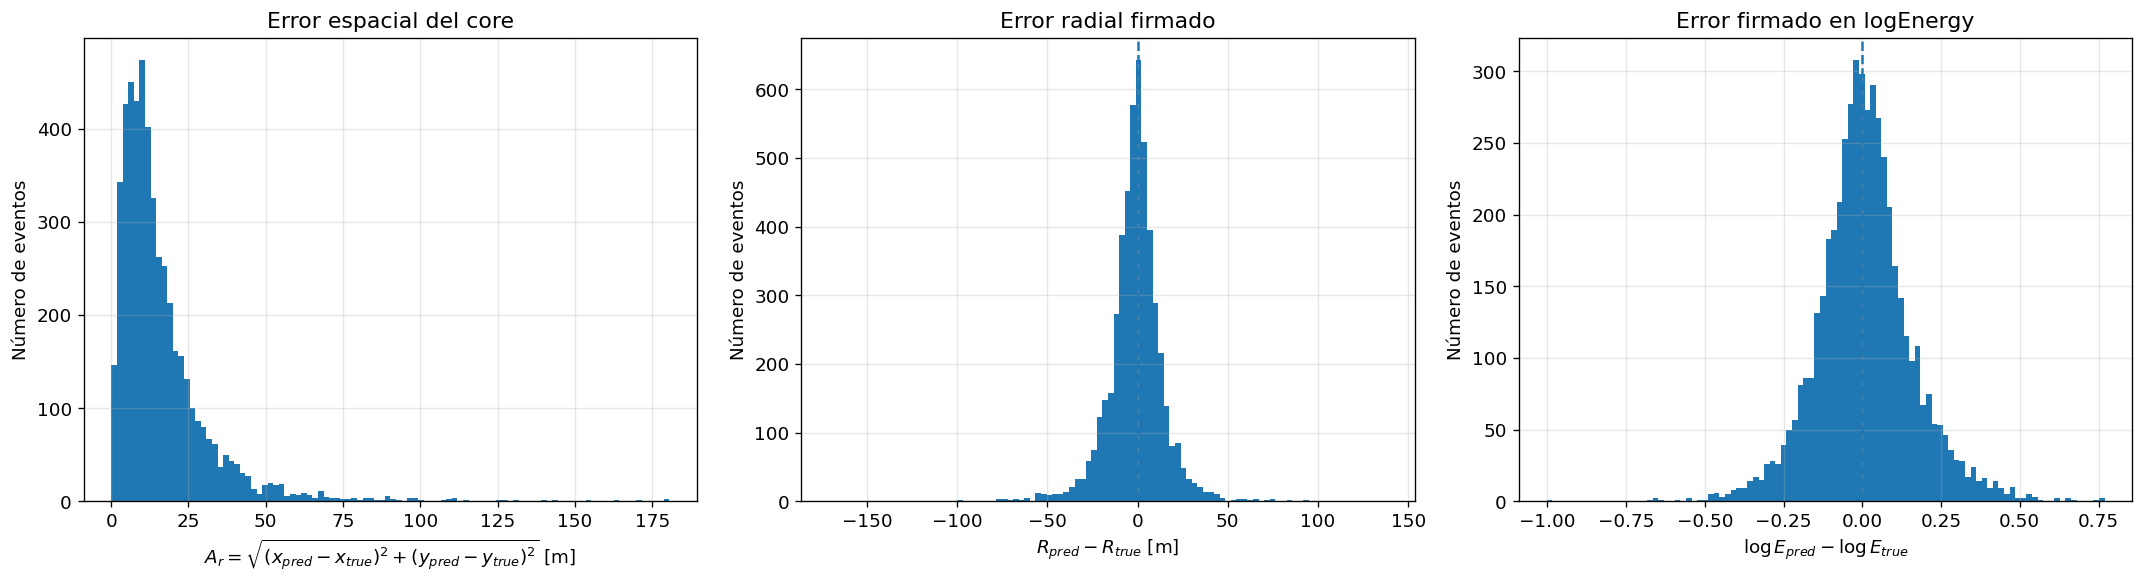


[OK] Core and energy plots use the 5 physical evaluation targets.
[OK] TARGET_NAMES from the internal 6D Flow representation is not used.
[OK] Ar is the 2D core-position error.
[OK] dR is the signed error in radial coordinate R.
[OK] Energy residual corresponds to Delta logEnergy.


In [ ]:
# ── Rpred - Rtrue, Ar y Epred - Etrue ─────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

## Y_TRUE, Y_PRED Y Y_PRED_MEDIAN ESTÁN EN EL ESPACIO FÍSICO:
##
## [
##     coreX,
##     coreY,
##     zenithAngle,
##     azimuthAngle,
##     logEnergy
## ]
##
## NO USAR TARGET_NAMES AQUÍ, YA QUE CONTIENE LOS 6 TARGETS INTERNOS
## DEL NORMALIZING FLOW.

PLOT_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


## COMPROBAR CONSISTENCIA CON LA EVALUACIÓN ##
if "PHYSICAL_TARGET_NAMES" in globals():

    if list(PHYSICAL_TARGET_NAMES) != PLOT_TARGET_NAMES:

        raise ValueError(
            "PHYSICAL_TARGET_NAMES does not match the expected "
            "physical target order.\n"
            f"Current : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Expected: {PLOT_TARGET_NAMES}"
        )


# ── SELECCIONAR PREDICCIÓN PUNTUAL ───────────────────────────────────────

## UTILIZAR MEDIANA POSTERIOR SI ESTÁ DISPONIBLE ##
PREDICTION_FOR_METRICS = (
    "median"
    if "Y_PRED_MEDIAN" in globals()
    else "mean"
)


Y_POINT = (
    Y_PRED_MEDIAN
    if PREDICTION_FOR_METRICS == "median"
    else Y_PRED
)


# ── COMPROBAR ARRAYS ─────────────────────────────────────────────────────

EXPECTED_TARGET_DIM = len(
    PLOT_TARGET_NAMES
)


for arr_name, arr in [
    ("Y_TRUE", Y_TRUE),
    ("Y_POINT", Y_POINT),
]:

    arr = np.asarray(
        arr
    )

    if arr.ndim != 2:

        raise ValueError(
            f"{arr_name} must be 2D, got shape {arr.shape}."
        )

    if arr.shape[1] != EXPECTED_TARGET_DIM:

        raise ValueError(
            f"{arr_name} has {arr.shape[1]} columns, "
            f"expected {EXPECTED_TARGET_DIM}."
        )

    if not np.all(
        np.isfinite(
            arr
        )
    ):

        raise ValueError(
            f"{arr_name} contains non-finite values."
        )


if len(Y_TRUE) != len(Y_POINT):

    raise ValueError(
        "Y_TRUE and Y_POINT must contain the same number of events."
    )


# ── ÍNDICES DE VARIABLES FÍSICAS ─────────────────────────────────────────

ix = PLOT_TARGET_NAMES.index(
    "coreX"
)

iy = PLOT_TARGET_NAMES.index(
    "coreY"
)

ie = PLOT_TARGET_NAMES.index(
    "logEnergy"
)


# ── EXTRAER VARIABLES ────────────────────────────────────────────────────

x_true = Y_TRUE[
    :,
    ix,
]

y_true = Y_TRUE[
    :,
    iy,
]

E_true = Y_TRUE[
    :,
    ie,
]


x_pred = Y_POINT[
    :,
    ix,
]

y_pred = Y_POINT[
    :,
    iy,
]

E_pred = Y_POINT[
    :,
    ie,
]


# ── RADIO DEL CORE ───────────────────────────────────────────────────────

R_true = np.sqrt(
    x_true ** 2
    +
    y_true ** 2
)


R_pred = np.sqrt(
    x_pred ** 2
    +
    y_pred ** 2
)


# ── RESIDUO RADIAL ───────────────────────────────────────────────────────

dR = (
    R_pred
    -
    R_true
)


# ── RESIDUO EN ENERGÍA ──────────────────────────────────────────────────

## IMPORTANTE:
##
## E_pred Y E_true REPRESENTAN logEnergy = log10(E/eV),
## NO LA ENERGÍA LINEAL EN eV.
##
## POR TANTO:
##
## dE = Delta logEnergy

dE = (
    E_pred
    -
    E_true
)


# ── ERROR ESPACIAL 2D DEL CORE ───────────────────────────────────────────

Ar = np.sqrt(

    (
        x_pred
        -
        x_true
    ) ** 2

    +

    (
        y_pred
        -
        y_true
    ) ** 2
)


# ── COMPROBACIONES ───────────────────────────────────────────────────────

for arr_name, arr in [
    ("R_true", R_true),
    ("R_pred", R_pred),
    ("dR", dR),
    ("dE", dE),
    ("Ar", Ar),
]:

    if not np.all(
        np.isfinite(
            arr
        )
    ):

        raise ValueError(
            f"{arr_name} contains non-finite values."
        )


# ── RESUMEN ──────────────────────────────────────────────────────────────

print(
    f"Usando predicción: "
    f"{PREDICTION_FOR_METRICS}"
)

print(
    f"N eventos = {len(dR)}"
)


print()

print(
    "===== ERROR ESPACIAL CORE ====="
)

print(
    f"<Ar> = "
    f"{np.mean(Ar):.4f} m"
)

print(
    f"σ(Ar) = "
    f"{np.std(Ar):.4f} m"
)

print(
    f"mediana(Ar) = "
    f"{np.median(Ar):.4f} m"
)

print(
    f"p68(Ar) = "
    f"{np.percentile(Ar, 68):.4f} m"
)

print(
    f"p95(Ar) = "
    f"{np.percentile(Ar, 95):.4f} m"
)


print()

print(
    "===== RADIO ====="
)

print(
    f"<Rpred - Rtrue> = "
    f"{np.mean(dR):.4f} m"
)

print(
    f"σ(Rpred - Rtrue) = "
    f"{np.std(dR):.4f} m"
)

print(
    f"<|Rpred - Rtrue|> = "
    f"{np.mean(np.abs(dR)):.4f} m"
)

print(
    f"mediana(|Rpred - Rtrue|) = "
    f"{np.median(np.abs(dR)):.4f} m"
)

print(
    f"p68(|Rpred - Rtrue|) = "
    f"{np.percentile(np.abs(dR), 68):.4f} m"
)

print(
    f"p95(|Rpred - Rtrue|) = "
    f"{np.percentile(np.abs(dR), 95):.4f} m"
)


print()

print(
    "===== ENERGÍA ====="
)

print(
    f"<Delta logEnergy> = "
    f"{np.mean(dE):.4f}"
)

print(
    f"σ(Delta logEnergy) = "
    f"{np.std(dE):.4f}"
)

print(
    f"<|Delta logEnergy|> = "
    f"{np.mean(np.abs(dE)):.4f}"
)

print(
    f"mediana(|Delta logEnergy|) = "
    f"{np.median(np.abs(dE)):.4f}"
)

print(
    f"p68(|Delta logEnergy|) = "
    f"{np.percentile(np.abs(dE), 68):.4f}"
)

print(
    f"p95(|Delta logEnergy|) = "
    f"{np.percentile(np.abs(dE), 95):.4f}"
)


# ── FIGURAS ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        18,
        5,
    ),
)


# ── ERROR ESPACIAL DEL CORE ──────────────────────────────────────────────

axes[
    0
].hist(
    Ar,
    bins=100,
)

axes[
    0
].set_xlabel(
    r"$A_r=\sqrt{(x_{pred}-x_{true})^2+(y_{pred}-y_{true})^2}$ [m]"
)

axes[
    0
].set_ylabel(
    "Número de eventos"
)

axes[
    0
].set_title(
    "Error espacial del core"
)

axes[
    0
].grid(
    alpha=0.3
)


# ── ERROR RADIAL FIRMADO ─────────────────────────────────────────────────

axes[
    1
].hist(
    dR,
    bins=100,
)

axes[
    1
].axvline(
    0.0,
    linestyle="--",
)

axes[
    1
].set_xlabel(
    r"$R_{pred}-R_{true}$ [m]"
)

axes[
    1
].set_ylabel(
    "Número de eventos"
)

axes[
    1
].set_title(
    "Error radial firmado"
)

axes[
    1
].grid(
    alpha=0.3
)


# ── ERROR EN logENERGY ───────────────────────────────────────────────────

axes[
    2
].hist(
    dE,
    bins=100,
)

axes[
    2
].axvline(
    0.0,
    linestyle="--",
)

axes[
    2
].set_xlabel(
    r"$\log E_{pred}-\log E_{true}$"
)

axes[
    2
].set_ylabel(
    "Número de eventos"
)

axes[
    2
].set_title(
    "Error firmado en logEnergy"
)

axes[
    2
].grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "[OK] Core and energy plots use the 5 physical evaluation targets."
)

print(
    "[OK] TARGET_NAMES from the internal 6D Flow representation is not used."
)

print(
    "[OK] Ar is the 2D core-position error."
)

print(
    "[OK] dR is the signed error in radial coordinate R."
)

print(
    "[OK] Energy residual corresponds to Delta logEnergy."
)

Eventos evaluados por la red: 5000

Template cache:
/content/gdrive/MyDrive/TFM/gamma_flow_outputs/test_template_reconstruction.csv

[INFO] Template cache found.
[INFO] Loading conventional reconstruction without scanning ROOT...

[OK] Templates loaded from cache: 5000 events.
[OK] ROOT scanning skipped.

[OK] Template rows are aligned 1:1 with Y_TRUE.

 TEMPLATE VS MONTE CARLO | MISMOS EVENTOS

===== ERROR ESPACIAL CORE =====
<Ar_template> = 12.3279 m
σ(Ar_template) = 15.6184 m
mediana(Ar_template) = 7.9266 m
p68(Ar_template) = 12.2309 m
p95(Ar_template) = 37.2193 m

===== RADIO =====
<Rtemp - Rtrue> = -1.1225 m
σ(Rtemp - Rtrue) = 15.0472 m
<|Rtemp - Rtrue|> = 8.2426 m

===== ENERGÍA =====
<Delta logEnergy template> = 0.0729
σ(Delta logEnergy template) = 0.1865
<|Delta logEnergy template|> = 0.1420


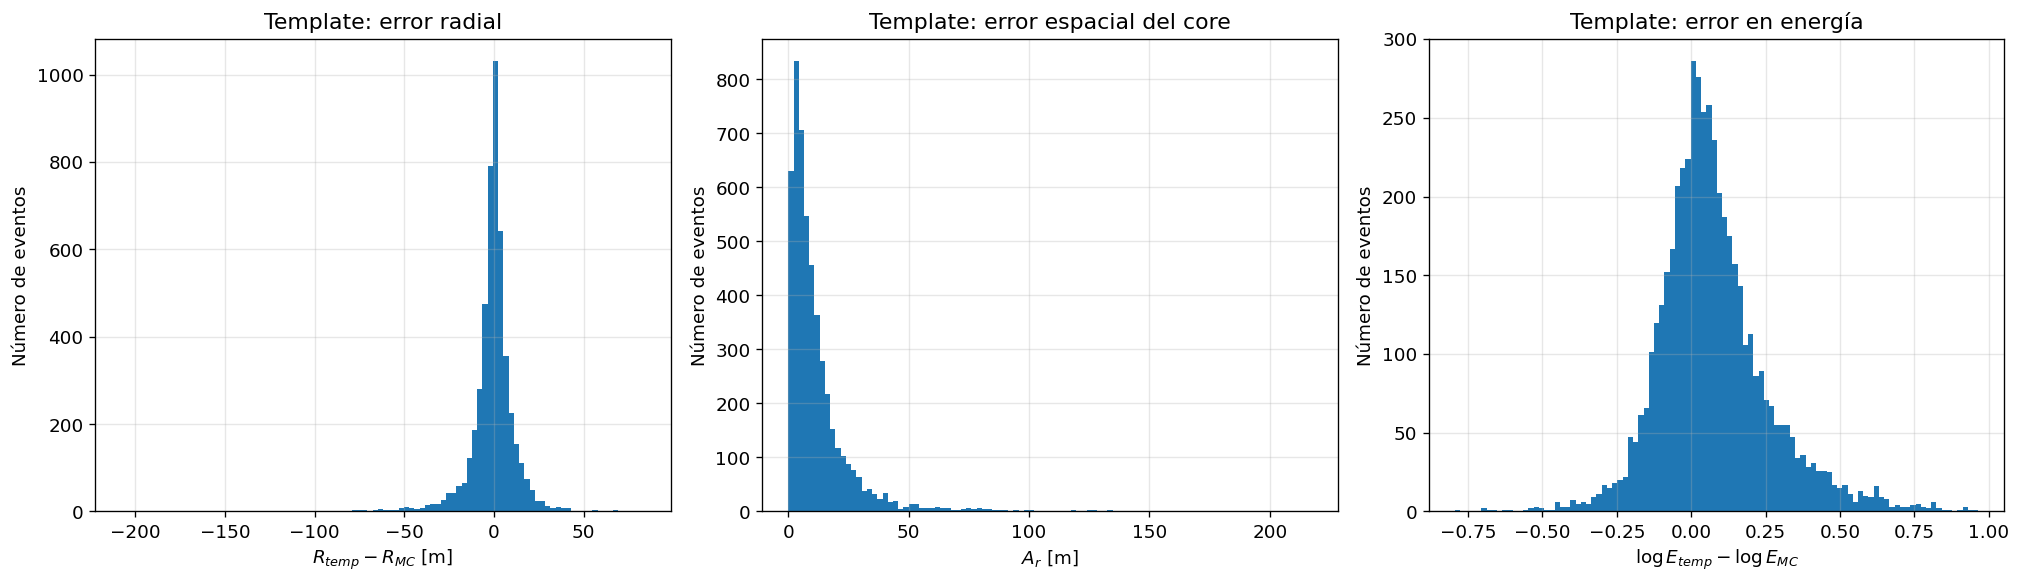


[OK] Comparison uses the exact neural-network test events.
[OK] Conventional reconstruction is never used as neural-network input.
[OK] Template reconstruction cache enabled.


In [ ]:
# ── Comparación Template vs Monte Carlo sobre los mismos eventos ─────────

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm


# ── TARGETS FÍSICOS DE LA EVALUACIÓN ─────────────────────────────────────

## Y_TRUE ESTÁ EN EL ESPACIO FÍSICO:
##
## [
##     coreX,
##     coreY,
##     zenithAngle,
##     azimuthAngle,
##     logEnergy
## ]
##
## NO UTILIZAR TARGET_NAMES AQUÍ.

TEMPLATE_PHYSICAL_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


if "PHYSICAL_TARGET_NAMES" in globals():

    if list(PHYSICAL_TARGET_NAMES) != TEMPLATE_PHYSICAL_TARGET_NAMES:

        raise ValueError(
            "PHYSICAL_TARGET_NAMES does not match the expected "
            "physical target order.\n"
            f"Current : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Expected: {TEMPLATE_PHYSICAL_TARGET_NAMES}"
        )


# ── COMPROBAR VARIABLES NECESARIAS ───────────────────────────────────────

for required_name in [
    "EVAL_EVENT_INDICES",
    "EVENT_IDS",
    "RUN_IDS",
    "Y_TRUE",
]:

    if required_name not in globals():

        raise NameError(
            f"{required_name} is not defined."
        )


idx_eval = np.asarray(
    EVAL_EVENT_INDICES,
    dtype=np.int64,
)


Y_TRUE = np.asarray(
    Y_TRUE
)


if (
    Y_TRUE.ndim != 2
    or
    Y_TRUE.shape[1] != len(TEMPLATE_PHYSICAL_TARGET_NAMES)
):

    raise ValueError(
        f"Y_TRUE has shape {Y_TRUE.shape}; expected "
        f"(*, {len(TEMPLATE_PHYSICAL_TARGET_NAMES)})."
    )


if len(idx_eval) != len(Y_TRUE):

    raise ValueError(
        f"EVAL_EVENT_INDICES contains {len(idx_eval)} events but "
        f"Y_TRUE contains {len(Y_TRUE)} events."
    )


# ── IDS DE LOS EVENTOS DEL TEST ──────────────────────────────────────────

run_ids_all = np.asarray(
    RUN_IDS
)


event_ids_all = np.asarray(
    EVENT_IDS
)


run_eval = run_ids_all[
    idx_eval
]


event_eval = event_ids_all[
    idx_eval
]


df_eval_ids = pd.DataFrame(
    {
        "eval_order":
            np.arange(
                len(idx_eval),
                dtype=np.int64,
            ),

        "runID":
            run_eval,

        "eventID":
            event_eval,
    }
)


if df_eval_ids.duplicated(
    subset=[
        "runID",
        "eventID",
    ]
).any():

    raise ValueError(
        "Duplicated (runID, eventID) found in evaluated events."
    )


print(
    f"Eventos evaluados por la red: {len(df_eval_ids)}"
)


# ── CACHE DE TEMPLATES DEL TEST ──────────────────────────────────────────

## ESTE CACHE EVITA RECORRER EL ROOT CADA VEZ QUE SE EJECUTA LA CELDA.

template_cache_path = Path(
    artifact_path(
        "test_template_reconstruction.csv",
        run_specific=False,
    )
)


print()

print(
    f"Template cache:\n{template_cache_path}"
)


# ── INTENTAR REUTILIZAR CACHE ────────────────────────────────────────────

USE_TEMPLATE_CACHE = (
    template_cache_path.exists()
)


df_templates = None


if USE_TEMPLATE_CACHE:

    print()

    print(
        "[INFO] Template cache found."
    )

    print(
        "[INFO] Loading conventional reconstruction without scanning ROOT..."
    )


    cached_templates = pd.read_csv(
        template_cache_path
    )


    required_template_columns = [
        "runID",
        "eventID",
        "rec.coreX",
        "rec.coreY",
        "rec.LHLatDistFitEnergy",
    ]


    missing_columns = [
        column
        for column in required_template_columns
        if column not in cached_templates.columns
    ]


    if missing_columns:

        print(
            "[WARNING] Existing template cache is incompatible."
        )

        print(
            f"[WARNING] Missing columns: {missing_columns}"
        )

        USE_TEMPLATE_CACHE = False


    else:

        ## BUSCAR EXACTAMENTE LOS EVENTOS DEL TEST ACTUAL ##
        df_templates = df_eval_ids.merge(

            cached_templates[
                required_template_columns
            ],

            on=[
                "runID",
                "eventID",
            ],

            how="left",

            validate="one_to_one",
        )


        template_missing = df_templates[
            [
                "rec.coreX",
                "rec.coreY",
                "rec.LHLatDistFitEnergy",
            ]
        ].isna().any(
            axis=1
        )


        if template_missing.any():

            print(
                "[WARNING] Cache does not contain all current test events."
            )

            print(
                f"[WARNING] Missing: "
                f"{int(template_missing.sum())} / {len(df_templates)}"
            )

            USE_TEMPLATE_CACHE = False

            df_templates = None


# ── SI EL CACHE ES VÁLIDO, NO TOCAR EL ROOT ──────────────────────────────

if USE_TEMPLATE_CACHE:

    print()

    print(
        f"[OK] Templates loaded from cache: {len(df_templates)} events."
    )

    print(
        "[OK] ROOT scanning skipped."
    )


# ── SI NO HAY CACHE VÁLIDO, BUSCAR UNA SOLA VEZ EN ROOT ─────────────────

else:

    print()

    print(
        "[INFO] No valid template cache available."
    )

    print(
        "[INFO] ROOT will be scanned once and the result will be cached."
    )


    ruta_root = Path(
        CFG[
            "root_file"
        ]
    )


    tree_name = CFG[
        "tree_name"
    ]


    if not ruta_root.exists():

        raise FileNotFoundError(
            f"ROOT file not found:\n{ruta_root}"
        )


    cols = [
        "event.runID",
        "event.eventID",
        "rec.coreX",
        "rec.coreY",
        "rec.LHLatDistFitEnergy",
    ]


    ## CREAR SET DE IDS PARA FILTRADO RÁPIDO ##
    ##
    ## Convertimos cada par:
    ##
    ##     (runID, eventID)
    ##
    ## en una clave Python para evitar hacer merge de Pandas
    ## sobre cada chunk del ROOT.

    wanted_event_keys = set(
        zip(
            run_eval.tolist(),
            event_eval.tolist(),
        )
    )


    found_rows = []


    print()

    print(
        f"ROOT file : {ruta_root}"
    )

    print(
        f"Tree      : {tree_name}"
    )


    with uproot.open(
        ruta_root
    ) as f:

        tree = f[
            tree_name
        ]


        for arr in tqdm(

            tree.iterate(
                cols,
                step_size="300 MB",
                library="np",
            ),

            desc="Buscando templates en ROOT",
        ):

            run_chunk = arr[
                "event.runID"
            ]

            event_chunk = arr[
                "event.eventID"
            ]


            ## FILTRO RÁPIDO SOLO POR LOS IDS NECESARIOS ##
            keep = np.fromiter(
                (
                    (
                        run_id,
                        event_id,
                    )
                    in wanted_event_keys

                    for run_id, event_id in zip(
                        run_chunk,
                        event_chunk,
                    )
                ),
                dtype=bool,
                count=len(run_chunk),
            )


            if not keep.any():

                continue


            selected_indices = np.where(
                keep
            )[
                0
            ]


            for j in selected_indices:

                found_rows.append(
                    {
                        "runID":
                            run_chunk[
                                j
                            ],

                        "eventID":
                            event_chunk[
                                j
                            ],

                        "rec.coreX":
                            arr[
                                "rec.coreX"
                            ][
                                j
                            ],

                        "rec.coreY":
                            arr[
                                "rec.coreY"
                            ][
                                j
                            ],

                        "rec.LHLatDistFitEnergy":
                            arr[
                                "rec.LHLatDistFitEnergy"
                            ][
                                j
                            ],
                    }
                )


            ## PARADA ANTICIPADA ##
            ##
            ## EN CUANTO HEMOS ENCONTRADO TODOS LOS EVENTOS DEL TEST,
            ## NO HAY NINGÚN MOTIVO PARA SEGUIR LEYENDO EL ROOT.

            if len(found_rows) >= len(
                df_eval_ids
            ):

                print()

                print(
                    "[OK] All evaluated events found."
                )

                print(
                    "[OK] ROOT scan stopped early."
                )

                break


    if len(found_rows) == 0:

        raise RuntimeError(
            "No evaluated events were found in the ROOT file."
        )


    df_templates_found = pd.DataFrame(
        found_rows
    )


    ## COMPROBAR DUPLICADOS ##
    if df_templates_found.duplicated(
        subset=[
            "runID",
            "eventID",
        ]
    ).any():

        raise ValueError(
            "Duplicated template reconstruction found for some events."
        )


    ## ORDENAR EXACTAMENTE COMO Y_TRUE ##
    df_templates = df_eval_ids.merge(

        df_templates_found,

        on=[
            "runID",
            "eventID",
        ],

        how="left",

        validate="one_to_one",
    )


    ## COMPROBAR EVENTOS FALTANTES ##
    missing_template = df_templates[
        [
            "rec.coreX",
            "rec.coreY",
            "rec.LHLatDistFitEnergy",
        ]
    ].isna().any(
        axis=1
    )


    n_missing_template = int(
        missing_template.sum()
    )


    if n_missing_template > 0:

        raise RuntimeError(
            f"{n_missing_template} / {len(df_templates)} evaluated "
            "events were not found in ROOT."
        )


    print()

    print(
        f"[OK] Templates found: {len(df_templates)} events."
    )


    # ── GUARDAR CACHE ────────────────────────────────────────────────────

    cache_to_save = df_templates[
        [
            "runID",
            "eventID",
            "rec.coreX",
            "rec.coreY",
            "rec.LHLatDistFitEnergy",
        ]
    ].copy()


    template_cache_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    cache_to_save.to_csv(
        template_cache_path,
        index=False,
    )


    print(
        f"[saved] {template_cache_path}"
    )

    print(
        "[OK] Future executions will not need to scan ROOT."
    )


# ── ORDEN FINAL ──────────────────────────────────────────────────────────

df_templates = df_templates.sort_values(
    "eval_order"
).reset_index(
    drop=True
)


if len(df_templates) != len(
    Y_TRUE
):

    raise ValueError(
        f"Template table has {len(df_templates)} rows but "
        f"Y_TRUE has {len(Y_TRUE)}."
    )


print()

print(
    "[OK] Template rows are aligned 1:1 with Y_TRUE."
)


# ── VARIABLES MONTE CARLO ────────────────────────────────────────────────

ix = TEMPLATE_PHYSICAL_TARGET_NAMES.index(
    "coreX"
)


iy = TEMPLATE_PHYSICAL_TARGET_NAMES.index(
    "coreY"
)


ie = TEMPLATE_PHYSICAL_TARGET_NAMES.index(
    "logEnergy"
)


x_true = Y_TRUE[
    :,
    ix,
]


y_true = Y_TRUE[
    :,
    iy,
]


logE_true = Y_TRUE[
    :,
    ie,
]


R_true = np.sqrt(
    x_true ** 2
    +
    y_true ** 2
)


# ── VARIABLES TEMPLATE ───────────────────────────────────────────────────

x_temp = df_templates[
    "rec.coreX"
].to_numpy(
    dtype=np.float64
)


y_temp = df_templates[
    "rec.coreY"
].to_numpy(
    dtype=np.float64
)


logE_temp = df_templates[
    "rec.LHLatDistFitEnergy"
].to_numpy(
    dtype=np.float64
)


R_temp = np.sqrt(
    x_temp ** 2
    +
    y_temp ** 2
)


# ── ERRORES ──────────────────────────────────────────────────────────────

dR_temp = (
    R_temp
    -
    R_true
)


dlogE_temp = (
    logE_temp
    -
    logE_true
)


Ar_temp = np.sqrt(

    (
        x_temp
        -
        x_true
    ) ** 2

    +

    (
        y_temp
        -
        y_true
    ) ** 2
)


# ── RESULTADOS ───────────────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " TEMPLATE VS MONTE CARLO | MISMOS EVENTOS"
)

print(
    "============================================================"
)


print()

print(
    "===== ERROR ESPACIAL CORE ====="
)


print(
    f"<Ar_template> = "
    f"{np.mean(Ar_temp):.4f} m"
)


print(
    f"σ(Ar_template) = "
    f"{np.std(Ar_temp):.4f} m"
)


print(
    f"mediana(Ar_template) = "
    f"{np.median(Ar_temp):.4f} m"
)


print(
    f"p68(Ar_template) = "
    f"{np.percentile(Ar_temp, 68):.4f} m"
)


print(
    f"p95(Ar_template) = "
    f"{np.percentile(Ar_temp, 95):.4f} m"
)


print()

print(
    "===== RADIO ====="
)


print(
    f"<Rtemp - Rtrue> = "
    f"{np.mean(dR_temp):.4f} m"
)


print(
    f"σ(Rtemp - Rtrue) = "
    f"{np.std(dR_temp):.4f} m"
)


print(
    f"<|Rtemp - Rtrue|> = "
    f"{np.mean(np.abs(dR_temp)):.4f} m"
)


print()

print(
    "===== ENERGÍA ====="
)


print(
    f"<Delta logEnergy template> = "
    f"{np.mean(dlogE_temp):.4f}"
)


print(
    f"σ(Delta logEnergy template) = "
    f"{np.std(dlogE_temp):.4f}"
)


print(
    f"<|Delta logEnergy template|> = "
    f"{np.mean(np.abs(dlogE_temp)):.4f}"
)


# ── GRÁFICAS ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        17,
        5,
    ),
)


axes[
    0
].hist(
    dR_temp,
    bins=100,
)


axes[
    0
].set_xlabel(
    r"$R_{temp}-R_{MC}$ [m]"
)


axes[
    0
].set_ylabel(
    "Número de eventos"
)


axes[
    0
].set_title(
    "Template: error radial"
)


axes[
    0
].grid(
    alpha=0.3
)


axes[
    1
].hist(
    Ar_temp,
    bins=100,
)


axes[
    1
].set_xlabel(
    r"$A_r$ [m]"
)


axes[
    1
].set_ylabel(
    "Número de eventos"
)


axes[
    1
].set_title(
    "Template: error espacial del core"
)


axes[
    1
].grid(
    alpha=0.3
)


axes[
    2
].hist(
    dlogE_temp,
    bins=100,
)


axes[
    2
].set_xlabel(
    r"$\log E_{temp}-\log E_{MC}$"
)


axes[
    2
].set_ylabel(
    "Número de eventos"
)


axes[
    2
].set_title(
    "Template: error en energía"
)


axes[
    2
].grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()


print()

print(
    "[OK] Comparison uses the exact neural-network test events."
)

print(
    "[OK] Conventional reconstruction is never used as neural-network input."
)

print(
    "[OK] Template reconstruction cache enabled."
)

## 9b. Bootstrap Evaluation: NN vs Template Baseline

This module estimates uncertainty on the test-set metrics using bootstrap resampling with replacement. It computes 95% confidence intervals for the neural-network reconstruction and includes placeholder template-baseline columns. If you later define `TEMPLATE_POINT` as a `(N_test, 6)` array in the same target order, the same cell will compute template confidence intervals and paired bootstrap p-values for NN improvement.


In [ ]:
# ── Build TEMPLATE_POINT for same evaluated events ───────────────────────

import uproot
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

TARGET_NAMES = ["coreX", "coreY", "zenithAngle", "azimuthAngle", "logEnergy"]
TARGET_UNITS = ["m", "m", "rad", "rad", "log10(eV)"]

idx_eval = np.asarray(EVAL_EVENT_INDICES)
run_eval = np.asarray(RUN_IDS)[idx_eval]
event_eval = np.asarray(EVENT_IDS)[idx_eval]

df_eval_ids = pd.DataFrame({
    "runID": run_eval,
    "eventID": event_eval,
})

cols = [
    "event.runID",
    "event.eventID",
    "rec.coreX",
    "rec.coreY",
    "rec.zenithAngle",
    "rec.azimuthAngle",
    "rec.LHLatDistFitEnergy",
]

chunks = []

with uproot.open(CFG["root_file"]) as f:
    tree = f[CFG["tree_name"]]

    for arr in tqdm(tree.iterate(cols, step_size="100 MB", library="np"),
                    desc="Leyendo templates del ROOT"):

        df_chunk = pd.DataFrame({
            "runID": arr["event.runID"],
            "eventID": arr["event.eventID"],
            "rec.coreX": arr["rec.coreX"],
            "rec.coreY": arr["rec.coreY"],
            "rec.zenithAngle": arr["rec.zenithAngle"],
            "rec.azimuthAngle": arr["rec.azimuthAngle"],
            "rec.LHLatDistFitEnergy": arr["rec.LHLatDistFitEnergy"],
        })

        df_match = df_chunk.merge(
            df_eval_ids,
            on=["runID", "eventID"],
            how="inner",
        )

        if len(df_match) > 0:
            chunks.append(df_match)

df_templates = pd.concat(chunks, ignore_index=True)

df_templates = df_eval_ids.merge(
    df_templates,
    on=["runID", "eventID"],
    how="left",
)

if df_templates.isna().any().any():
    print("[WARN] Hay templates no encontrados:")
    print(df_templates.isna().sum())

TEMPLATE_POINT = np.column_stack([
    df_templates["rec.coreX"].values,
    df_templates["rec.coreY"].values,
    df_templates["rec.zenithAngle"].values,
    df_templates["rec.azimuthAngle"].values,
    df_templates["rec.LHLatDistFitEnergy"].values,
]).astype(np.float64)

print("TEMPLATE_POINT shape:", TEMPLATE_POINT.shape)
print("Y_TRUE shape        :", Y_TRUE.shape)

assert TEMPLATE_POINT.shape == Y_TRUE.shape

Leyendo templates del ROOT: 0it [00:00, ?it/s]

TEMPLATE_POINT shape: (5000, 5)
Y_TRUE shape        : (5000, 5)


In [ ]:
# ── Bootstrap NN vs Template ──────────────────────────────────────────────

import numpy as np
import pandas as pd

from tqdm.auto import tqdm


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

## IMPORTANTE:
##
## Y_TRUE, Y_PRED, Y_PRED_MEDIAN Y TEMPLATE_POINT ESTÁN EN EL ESPACIO
## FÍSICO DE 5 VARIABLES:
##
## [
##     coreX,
##     coreY,
##     zenithAngle,
##     azimuthAngle,
##     logEnergy
## ]
##
## NO UTILIZAR TARGET_NAMES NI TARGET_UNITS AQUÍ, YA QUE ESAS VARIABLES
## REPRESENTAN LOS 6 TARGETS INTERNOS DEL NORMALIZING FLOW.

BOOTSTRAP_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


BOOTSTRAP_TARGET_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(eV)',
]


## COMPROBAR CONSISTENCIA CON LA EVALUACIÓN ##
if 'PHYSICAL_TARGET_NAMES' in globals():

    if list(
        PHYSICAL_TARGET_NAMES
    ) != BOOTSTRAP_TARGET_NAMES:

        raise ValueError(
            'PHYSICAL_TARGET_NAMES does not match the expected '
            'physical target order.\n'
            f'Current : {list(PHYSICAL_TARGET_NAMES)}\n'
            f'Expected: {BOOTSTRAP_TARGET_NAMES}'
        )


EXPECTED_BOOTSTRAP_DIM = len(
    BOOTSTRAP_TARGET_NAMES
)


# ── PREDICCIÓN PUNTUAL DE LA RED ─────────────────────────────────────────

## USAR LA MISMA ELECCIÓN QUE EN LAS MÉTRICAS:
## MEDIANA POSTERIOR SI ESTÁ DISPONIBLE.

PREDICTION_FOR_BOOTSTRAP = (
    'median'
    if 'Y_PRED_MEDIAN' in globals()
    else 'mean'
)


Y_NN_POINT = (
    Y_PRED_MEDIAN
    if PREDICTION_FOR_BOOTSTRAP == 'median'
    else Y_PRED
)


# ── COMPROBAR ARRAYS DE LA RED ───────────────────────────────────────────

Y_TRUE = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


Y_NN_POINT = np.asarray(
    Y_NN_POINT,
    dtype=np.float64,
)


if (
    Y_TRUE.ndim != 2
    or
    Y_TRUE.shape[1] != EXPECTED_BOOTSTRAP_DIM
):

    raise ValueError(
        f'Y_TRUE has shape {Y_TRUE.shape}; '
        f'expected (*, {EXPECTED_BOOTSTRAP_DIM}).'
    )


if Y_NN_POINT.shape != Y_TRUE.shape:

    raise ValueError(
        f'Y_NN_POINT shape {Y_NN_POINT.shape} does not match '
        f'Y_TRUE shape {Y_TRUE.shape}.'
    )


if not np.all(
    np.isfinite(
        Y_TRUE
    )
):

    raise ValueError(
        'Y_TRUE contains non-finite values.'
    )


if not np.all(
    np.isfinite(
        Y_NN_POINT
    )
):

    raise ValueError(
        'Y_NN_POINT contains non-finite values.'
    )


# ── TEMPLATE POINT ────────────────────────────────────────────────────────

## TEMPLATE_POINT DEBE HABER SIDO CREADO EN LA CELDA ANTERIOR CON:
##
## [
##     rec.coreX,
##     rec.coreY,
##     planeFit2.theta,
##     planeFit2.phi,
##     rec.LHLatDistFitEnergy
## ]
##
## Y TENER EXACTAMENTE EL MISMO ORDEN DE EVENTOS QUE Y_TRUE.
##
## SHAPE ESPERADO:
##
##     (len(Y_TRUE), 5)

if 'TEMPLATE_POINT' not in globals():

    TEMPLATE_POINT = None


# ── FUNCIONES DE RESIDUOS ────────────────────────────────────────────────

def _angular_residual(
    pred,
    true,
    target_name,
):
    """
    Residual pred - true.

    For azimuthAngle, return circular residual in [-pi, pi).
    """

    pred = np.asarray(
        pred,
        dtype=np.float64,
    )

    true = np.asarray(
        true,
        dtype=np.float64,
    )


    res = (
        pred
        -
        true
    )


    if target_name == 'azimuthAngle':

        res = np.arctan2(
            np.sin(
                res
            ),
            np.cos(
                res
            ),
        )


    return res


def _residual_matrix(
    y_pred,
    y_true,
    target_names,
):
    """
    Build residual matrix in physical target space.

    Azimuth residuals are circularly wrapped.
    """

    y_pred = np.asarray(
        y_pred,
        dtype=np.float64,
    )


    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    if y_pred.shape != y_true.shape:

        raise ValueError(
            f'Prediction shape {y_pred.shape} does not match '
            f'truth shape {y_true.shape}.'
        )


    if (
        y_true.ndim != 2
        or
        y_true.shape[1] != len(target_names)
    ):

        raise ValueError(
            f'Residual arrays have shape {y_true.shape}, but '
            f'{len(target_names)} target names were provided.'
        )


    residuals = np.empty_like(
        y_true,
        dtype=np.float64,
    )


    for j, name in enumerate(
        target_names
    ):

        residuals[
            :,
            j,
        ] = _angular_residual(
            y_pred[
                :,
                j,
            ],
            y_true[
                :,
                j,
            ],
            name,
        )


    return residuals


# ── MÉTRICAS A PARTIR DE RESIDUOS ────────────────────────────────────────

def _metric_values_from_residuals(
    residuals,
    target_names,
):
    """
    Return metrics per physical target.

    For linear targets:
        bias = mean(pred - true)

    For azimuthAngle:
        bias = circular mean of wrapped residuals

    Other error metrics use absolute or squared wrapped residuals.
    Lower is better.
    """

    residuals = np.asarray(
        residuals,
        dtype=np.float64,
    )


    abs_res = np.abs(
        residuals
    )


    bias = np.nanmean(
        residuals,
        axis=0,
    )


    ## CORREGIR BIAS DEL AZIMUT COMO MEDIA CIRCULAR ##
    if 'azimuthAngle' in target_names:

        iaz = target_names.index(
            'azimuthAngle'
        )


        az_res = residuals[
            :,
            iaz,
        ]


        finite_az = np.isfinite(
            az_res
        )


        if finite_az.any():

            bias[
                iaz
            ] = np.arctan2(
                np.nanmean(
                    np.sin(
                        az_res[
                            finite_az
                        ]
                    )
                ),
                np.nanmean(
                    np.cos(
                        az_res[
                            finite_az
                        ]
                    )
                ),
            )

        else:

            bias[
                iaz
            ] = np.nan


    return {
        'bias':
            bias,

        'mae':
            np.nanmean(
                abs_res,
                axis=0,
            ),

        'rmse':
            np.sqrt(
                np.nanmean(
                    residuals ** 2,
                    axis=0,
                )
            ),

        'median_error':
            np.nanmedian(
                abs_res,
                axis=0,
            ),

        'p68_error':
            np.nanpercentile(
                abs_res,
                68,
                axis=0,
            ),
    }


# ── BOOTSTRAP ────────────────────────────────────────────────────────────

def _bootstrap_metric_distributions(
    residuals,
    target_names,
    n_boot=1000,
    seed=123,
):
    """
    Bootstrap metrics by resampling test events with replacement.
    """

    residuals = np.asarray(
        residuals,
        dtype=np.float64,
    )


    finite_rows = np.all(
        np.isfinite(
            residuals
        ),
        axis=1,
    )


    residuals = residuals[
        finite_rows
    ]


    n = residuals.shape[
        0
    ]


    if n == 0:

        raise ValueError(
            'No finite residual rows available for bootstrap.'
        )


    rng = np.random.default_rng(
        seed
    )


    metric_names = [
        'bias',
        'mae',
        'rmse',
        'median_error',
        'p68_error',
    ]


    boot = {
        m:
            np.empty(
                (
                    n_boot,
                    residuals.shape[1],
                ),
                dtype=np.float64,
            )

        for m in metric_names
    }


    for b in tqdm(
        range(
            n_boot
        ),
        desc='Bootstrap iterations',
    ):

        idx = rng.integers(
            0,
            n,
            size=n,
        )


        vals = _metric_values_from_residuals(
            residuals[
                idx
            ],
            target_names,
        )


        for m in metric_names:

            boot[
                m
            ][
                b
            ] = vals[
                m
            ]


    point = _metric_values_from_residuals(
        residuals,
        target_names,
    )


    return (
        point,
        boot,
        n,
    )


# ── INTERVALOS DE CONFIANZA ──────────────────────────────────────────────

def _ci_from_bootstrap(
    samples,
    ci_level=0.95,
):
    """
    Percentile bootstrap confidence interval.
    """

    alpha = (
        1.0
        -
        ci_level
    )


    lo = (
        100.0
        *
        alpha
        /
        2.0
    )


    hi = (
        100.0
        *
        (
            1.0
            -
            alpha
            /
            2.0
        )
    )


    return np.nanpercentile(
        samples,
        [
            lo,
            hi,
        ],
        axis=0,
    )


def _format_ci(
    point,
    lo,
    hi,
    precision=4,
):
    """
    Format point estimate and confidence interval.
    """

    if not (
        np.isfinite(
            point
        )
        and
        np.isfinite(
            lo
        )
        and
        np.isfinite(
            hi
        )
    ):

        return 'not available'


    return (
        f'{point:.{precision}f} '
        f'[{lo:.{precision}f}, {hi:.{precision}f}]'
    )


# ── P-VALUE PAREADO ──────────────────────────────────────────────────────

def _paired_improvement_p_value(
    nn_boot,
    template_boot,
    metric_name,
):
    """
    One-sided paired bootstrap p-value for NN improvement.

    For:
        MAE
        RMSE
        median_error
        p68_error

    improvement =
        template_metric - nn_metric

    For bias:

        improvement =
            |template_bias| - |nn_bias|

    Positive improvement means NN is better.
    """

    nn_boot = np.asarray(
        nn_boot,
        dtype=np.float64,
    )


    template_boot = np.asarray(
        template_boot,
        dtype=np.float64,
    )


    if nn_boot.shape != template_boot.shape:

        raise ValueError(
            'NN and template bootstrap distributions must have '
            'the same shape for paired comparison.'
        )


    if metric_name == 'bias':

        improvement = (
            np.abs(
                template_boot
            )
            -
            np.abs(
                nn_boot
            )
        )


    else:

        improvement = (
            template_boot
            -
            nn_boot
        )


    ## ADD-ONE SMOOTHING PARA EVITAR p = 0 EXACTO ##
    return (
        np.sum(
            improvement <= 0.0,
            axis=0,
        )
        +
        1.0
    ) / (
        improvement.shape[0]
        +
        1.0
    )


# ── MÉTODO MEJOR ─────────────────────────────────────────────────────────

def _better_method(
    nn_point,
    template_point,
    metric_name,
):
    """
    Determine which method has lower error.

    For bias, compare absolute bias.
    """

    if not np.isfinite(
        template_point
    ):

        return 'Template placeholder'


    nn_compare = (
        abs(
            nn_point
        )
        if metric_name == 'bias'
        else nn_point
    )


    template_compare = (
        abs(
            template_point
        )
        if metric_name == 'bias'
        else template_point
    )


    if nn_compare < template_compare:

        return 'NN'


    if template_compare < nn_compare:

        return 'Template'


    return 'Tie'


# ── CONFIGURACIÓN BOOTSTRAP ──────────────────────────────────────────────

N_BOOT = int(
    CFG.get(
        'bootstrap_n_iterations',
        1000,
    )
)


CI_LEVEL = float(
    CFG.get(
        'bootstrap_ci_level',
        0.95,
    )
)


BOOT_SEED = int(
    CFG.get(
        'bootstrap_seed',
        123,
    )
)


print(
    f'Bootstrap point prediction: posterior '
    f'{PREDICTION_FOR_BOOTSTRAP}'
)


print(
    f'Bootstrap iterations      : '
    f'{N_BOOT:,}'
)


print(
    f'Confidence interval level : '
    f'{CI_LEVEL:.1%}'
)


print(
    f'Physical targets          : '
    f'{BOOTSTRAP_TARGET_NAMES}'
)


# ── RESIDUOS DE LA RED ───────────────────────────────────────────────────

NN_RESIDUALS = _residual_matrix(
    Y_NN_POINT,
    Y_TRUE,
    BOOTSTRAP_TARGET_NAMES,
)


NN_BOOT_POINT, NN_BOOT_DISTS, NN_BOOT_N = (
    _bootstrap_metric_distributions(
        NN_RESIDUALS,
        BOOTSTRAP_TARGET_NAMES,
        n_boot=N_BOOT,
        seed=BOOT_SEED,
    )
)


# ── RESIDUOS DEL TEMPLATE ────────────────────────────────────────────────

template_available = (
    TEMPLATE_POINT is not None
)


if template_available:

    TEMPLATE_POINT = np.asarray(
        TEMPLATE_POINT,
        dtype=np.float64,
    )


    if TEMPLATE_POINT.shape != Y_TRUE.shape:

        raise ValueError(
            f'TEMPLATE_POINT shape {TEMPLATE_POINT.shape} must match '
            f'Y_TRUE shape {Y_TRUE.shape}.'
        )


    if not np.all(
        np.isfinite(
            TEMPLATE_POINT
        )
    ):

        bad_by_target = (
            ~np.isfinite(
                TEMPLATE_POINT
            )
        ).sum(
            axis=0
        )


        raise ValueError(
            'TEMPLATE_POINT contains non-finite values.\n'
            f'Non-finite by target: '
            f'{dict(zip(BOOTSTRAP_TARGET_NAMES, bad_by_target.tolist()))}'
        )


    TEMPLATE_RESIDUALS = _residual_matrix(
        TEMPLATE_POINT,
        Y_TRUE,
        BOOTSTRAP_TARGET_NAMES,
    )


    TEMPLATE_BOOT_POINT, TEMPLATE_BOOT_DISTS, TEMPLATE_BOOT_N = (
        _bootstrap_metric_distributions(
            TEMPLATE_RESIDUALS,
            BOOTSTRAP_TARGET_NAMES,
            n_boot=N_BOOT,
            seed=BOOT_SEED,
        )
    )


    ## PARA UNA COMPARACIÓN PAREADA DEBEN USARSE LOS MISMOS EVENTOS ##
    if TEMPLATE_BOOT_N != NN_BOOT_N:

        raise ValueError(
            f'NN bootstrap uses {NN_BOOT_N} events but template '
            f'bootstrap uses {TEMPLATE_BOOT_N}. '
            'Paired comparison requires exactly the same events.'
        )


    print()

    print(
        f'[OK] Template comparison enabled for '
        f'{TEMPLATE_BOOT_N} events.'
    )


else:

    TEMPLATE_BOOT_POINT = None

    TEMPLATE_BOOT_DISTS = None


    print()

    print(
        'TEMPLATE_POINT is None.'
    )

    print(
        'Template columns and p-values will be placeholders.'
    )


# ── MÉTRICAS A MOSTRAR ───────────────────────────────────────────────────

metric_names = [
    'bias',
    'mae',
    'rmse',
    'median_error',
    'p68_error',
]


metric_labels = {
    'bias':
        'Bias',

    'mae':
        'MAE',

    'rmse':
        'RMSE',

    'median_error':
        'Median absolute error',

    'p68_error':
        '68th-percentile absolute error',
}


# ── PRECALCULAR INTERVALOS BOOTSTRAP ─────────────────────────────────────

NN_BOOT_CI = {
    metric_name:
        _ci_from_bootstrap(
            NN_BOOT_DISTS[
                metric_name
            ],
            CI_LEVEL,
        )

    for metric_name in metric_names
}


if template_available:

    TEMPLATE_BOOT_CI = {
        metric_name:
            _ci_from_bootstrap(
                TEMPLATE_BOOT_DISTS[
                    metric_name
                ],
                CI_LEVEL,
            )

        for metric_name in metric_names
    }


else:

    TEMPLATE_BOOT_CI = None


# ── CONSTRUIR TABLA FINAL ────────────────────────────────────────────────

rows = []


for j, (target, unit) in enumerate(
    zip(
        BOOTSTRAP_TARGET_NAMES,
        BOOTSTRAP_TARGET_UNITS,
    )
):

    for metric_name in metric_names:

        nn_ci = NN_BOOT_CI[
            metric_name
        ]


        nn_point = NN_BOOT_POINT[
            metric_name
        ][
            j
        ]


        nn_lo = nn_ci[
            0,
            j,
        ]


        nn_hi = nn_ci[
            1,
            j,
        ]


        # ── TEMPLATE DISPONIBLE ──────────────────────────────────────────

        if template_available:

            template_ci = TEMPLATE_BOOT_CI[
                metric_name
            ]


            template_point = TEMPLATE_BOOT_POINT[
                metric_name
            ][
                j
            ]


            template_lo = template_ci[
                0,
                j,
            ]


            template_hi = template_ci[
                1,
                j,
            ]


            p_value = _paired_improvement_p_value(
                NN_BOOT_DISTS[
                    metric_name
                ],
                TEMPLATE_BOOT_DISTS[
                    metric_name
                ],
                metric_name,
            )[
                j
            ]


            if metric_name == 'bias':

                improvement_point = (
                    abs(
                        template_point
                    )
                    -
                    abs(
                        nn_point
                    )
                )


            else:

                improvement_point = (
                    template_point
                    -
                    nn_point
                )


        # ── TEMPLATE NO DISPONIBLE ───────────────────────────────────────

        else:

            template_point = np.nan

            template_lo = np.nan

            template_hi = np.nan

            p_value = np.nan

            improvement_point = np.nan


        rows.append(
            {
                'target':
                    target,

                'unit':
                    unit,

                'metric':
                    metric_labels[
                        metric_name
                    ],

                'metric_key':
                    metric_name,

                'nn_point':
                    nn_point,

                'nn_ci_low':
                    nn_lo,

                'nn_ci_high':
                    nn_hi,

                'nn_95ci':
                    _format_ci(
                        nn_point,
                        nn_lo,
                        nn_hi,
                    ),

                'template_point':
                    template_point,

                'template_ci_low':
                    template_lo,

                'template_ci_high':
                    template_hi,

                'template_95ci':
                    _format_ci(
                        template_point,
                        template_lo,
                        template_hi,
                    ),

                'improvement_template_minus_nn':
                    improvement_point,

                'p_value_nn_improves_over_template':
                    p_value,

                'better_method':
                    _better_method(
                        nn_point,
                        template_point,
                        metric_name,
                    ),

                'n_test_events':
                    NN_BOOT_N,

                'n_bootstrap':
                    N_BOOT,

                'point_prediction':
                    PREDICTION_FOR_BOOTSTRAP,
            }
        )


BOOTSTRAP_SUMMARY_DF = pd.DataFrame(
    rows
)


# ── MOSTRAR RESULTADOS ───────────────────────────────────────────────────

display_cols = [
    'target',
    'unit',
    'metric',
    'nn_95ci',
    'template_95ci',
    'improvement_template_minus_nn',
    'p_value_nn_improves_over_template',
    'better_method',
]


print()

print(
    'Bootstrap summary: NN vs template baseline'
)


print(
    'For bias, better_method compares absolute bias.'
)


print(
    'For azimuthAngle, bias is calculated circularly.'
)


print(
    'For all other error metrics, lower is better.'
)


display(
    BOOTSTRAP_SUMMARY_DF[
        display_cols
    ].style.format(
        {
            'improvement_template_minus_nn':
                '{:.5g}',

            'p_value_nn_improves_over_template':
                '{:.4g}',
        }
    )
)


# ── GUARDAR RESULTADOS ───────────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    bootstrap_csv_latest = artifact_path(
        'bootstrap_nn_vs_template_summary_trig_angles.csv',
        run_specific=False,
    )


    bootstrap_csv_run = artifact_path(
        'bootstrap_nn_vs_template_summary_trig_angles.csv',
        run_specific=True,
    )


    BOOTSTRAP_SUMMARY_DF.to_csv(
        bootstrap_csv_latest,
        index=False,
    )


    BOOTSTRAP_SUMMARY_DF.to_csv(
        bootstrap_csv_run,
        index=False,
    )


    print()

    print(
        f'[saved] {bootstrap_csv_latest}'
    )


    print(
        f'[saved] {bootstrap_csv_run}'
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    '============================================================'
)

print(
    ' BOOTSTRAP NN VS TEMPLATE COMPLETED'
)

print(
    '============================================================'
)


print(
    '[OK] Bootstrap uses the 5 physical reconstruction targets.'
)


print(
    '[OK] Internal 6D trig targets are not used in the comparison.'
)


print(
    '[OK] Azimuth residuals are circularly wrapped.'
)


print(
    '[OK] Azimuth bias is calculated as a circular mean.'
)


if template_available:

    print(
        '[OK] NN and conventional reconstruction are compared '
        'on the same test events.'
    )


    print(
        '[OK] Paired bootstrap uses the same seed and resampling '
        'scheme for NN and template.'
    )


else:

    print(
        '[WARN] TEMPLATE_POINT is not available; template comparison '
        'was not performed.'
    )


print()

print(
    'Expected TEMPLATE_POINT shape:'
)

print(
    f'  ({len(Y_TRUE)}, 5)'
)


print(
    'Expected TEMPLATE_POINT order:'
)

print(
    f'  {BOOTSTRAP_TARGET_NAMES}'
)


Bootstrap point prediction: posterior median
Bootstrap iterations      : 1,000
Confidence interval level : 95.0%
Physical targets          : ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']


Bootstrap iterations:   0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrap iterations:   0%|          | 0/1000 [00:00<?, ?it/s]


[OK] Template comparison enabled for 5000 events.

Bootstrap summary: NN vs template baseline
For bias, better_method compares absolute bias.
For azimuthAngle, bias is calculated circularly.
For all other error metrics, lower is better.


,target,unit,metric,nn_95ci,template_95ci,improvement_template_minus_nn,p_value_nn_improves_over_template,better_method
0,coreX,m,Bias,"-0.6784 [-1.1049, -0.2587]","-0.1614 [-0.5725, 0.2626]",-0.51695,0.98,Template
1,coreX,m,MAE,"10.4451 [10.1311, 10.7699]","8.2399 [7.9011, 8.5722]",-2.2051,1,Template
2,coreX,m,RMSE,"15.7619 [15.1239, 16.4707]","14.9562 [13.9000, 16.0826]",-0.80569,0.9471,Template
3,coreX,m,Median absolute error,"7.0262 [6.7849, 7.2982]","4.4700 [4.2700, 4.7151]",-2.5562,1,Template
4,coreX,m,68th-percentile absolute error,"11.0644 [10.7403, 11.5348]","7.8300 [7.5497, 8.1700]",-3.2344,1,Template
5,coreY,m,Bias,"-2.3514 [-2.7465, -1.9154]","0.0588 [-0.3147, 0.4472]",-2.2926,1,Template
6,coreY,m,MAE,"10.1187 [9.8059, 10.4243]","7.4484 [7.1615, 7.7377]",-2.6703,1,Template
7,coreY,m,RMSE,"15.4572 [14.6912, 16.2957]","13.1234 [12.2060, 14.0511]",-2.3338,1,Template
8,coreY,m,Median absolute error,"6.8361 [6.6089, 7.1085]","4.2200 [4.0649, 4.3900]",-2.6161,1,Template
9,coreY,m,68th-percentile absolute error,"10.6694 [10.3998, 11.0692]","7.2100 [6.8800, 7.5234]",-3.4594,1,Template



[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/bootstrap_nn_vs_template_summary_trig_angles.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/20260826_232231_bootstrap_nn_vs_template_summary_trig_angles.csv

 BOOTSTRAP NN VS TEMPLATE COMPLETED
[OK] Bootstrap uses the 5 physical reconstruction targets.
[OK] Internal 6D trig targets are not used in the comparison.
[OK] Azimuth residuals are circularly wrapped.
[OK] Azimuth bias is calculated as a circular mean.
[OK] NN and conventional reconstruction are compared on the same test events.
[OK] Paired bootstrap uses the same seed and resampling scheme for NN and template.

Expected TEMPLATE_POINT shape:
  (5000, 5)
Expected TEMPLATE_POINT order:
  ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']


In [ ]:
# ── Rebuild TEMPLATE_POINT from current df_templates ─────────────────────

import numpy as np


## ESTA CELDA NO LEE EL ROOT ##
## SOLO REUTILIZA df_templates YA CARGADO EN MEMORIA ##


if "df_templates" not in globals() or df_templates is None:

    raise RuntimeError(
        "df_templates no está disponible en memoria."
    )


required_columns = [
    "rec.coreX",
    "rec.coreY",
    "rec.LHLatDistFitEnergy",
]


missing_columns = [
    col
    for col in required_columns
    if col not in df_templates.columns
]


if missing_columns:

    raise RuntimeError(
        f"df_templates no contiene las columnas necesarias: {missing_columns}"
    )


template_coreX = df_templates[
    "rec.coreX"
].to_numpy(
    dtype=np.float64
)


template_coreY = df_templates[
    "rec.coreY"
].to_numpy(
    dtype=np.float64
)


template_logEnergy = df_templates[
    "rec.LHLatDistFitEnergy"
].to_numpy(
    dtype=np.float64
)


## PARA ESTAS 4 GRÁFICAS NO SE USAN LOS ÁNGULOS ##
## RELLENAMOS TEMPORALMENTE ESAS DOS COLUMNAS CON LOS TRUE,
## SOLO PARA MANTENER EL FORMATO FÍSICO DE 5 COLUMNAS.

Y_TRUE_PHYS = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


if (
    Y_TRUE_PHYS.ndim != 2
    or
    Y_TRUE_PHYS.shape[1] != 5
):

    raise ValueError(
        f"Y_TRUE tiene shape {Y_TRUE_PHYS.shape}; esperaba (*, 5)."
    )


template_zenith = Y_TRUE_PHYS[
    :,
    2
]


template_azimuth = Y_TRUE_PHYS[
    :,
    3
]


TEMPLATE_POINT = np.column_stack(
    [
        template_coreX,
        template_coreY,
        template_zenith,
        template_azimuth,
        template_logEnergy,
    ]
).astype(
    np.float64
)


print(
    "TEMPLATE_POINT reconstruido:",
    TEMPLATE_POINT.shape
)


print(
    "[OK] No se ha leído el ROOT."
)


print(
    "[OK] Core y energía proceden del template."
)


print(
    "[INFO] Zenith y azimuth se han rellenado temporalmente "
    "con Y_TRUE porque NO se usan en las 4 gráficas."
)

TEMPLATE_POINT reconstruido: (5000, 5)
[OK] No se ha leído el ROOT.
[OK] Core y energía proceden del template.
[INFO] Zenith y azimuth se han rellenado temporalmente con Y_TRUE porque NO se usan en las 4 gráficas.


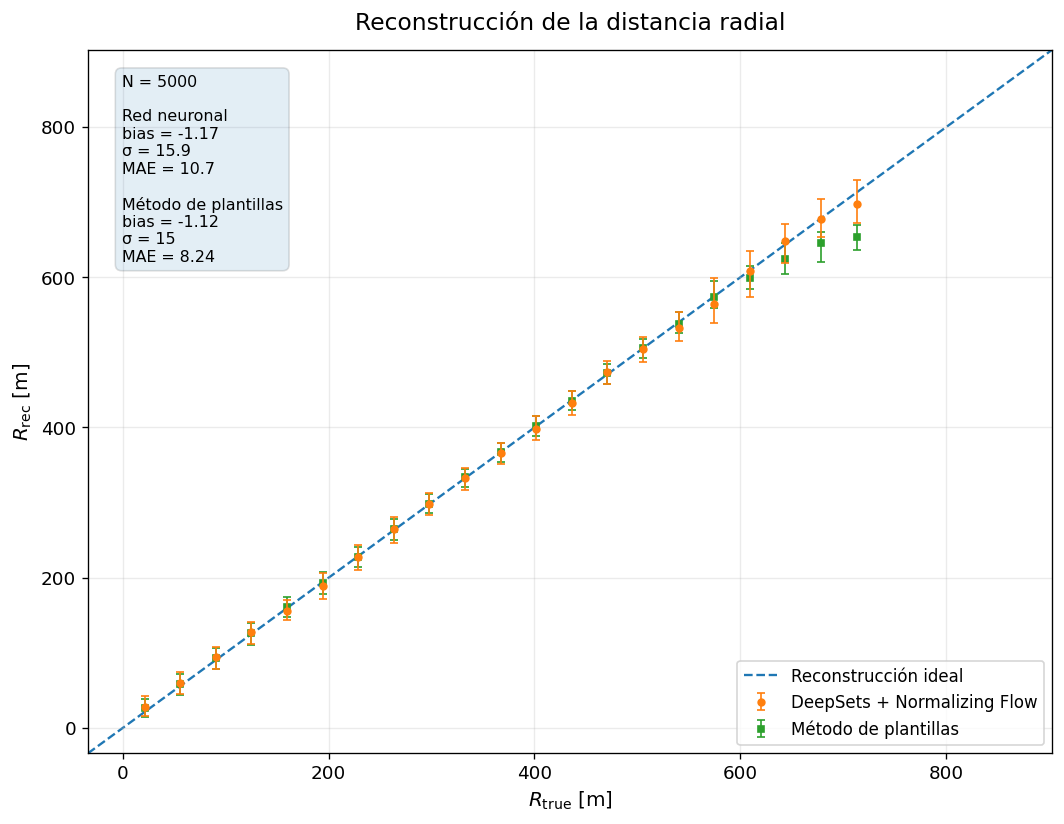

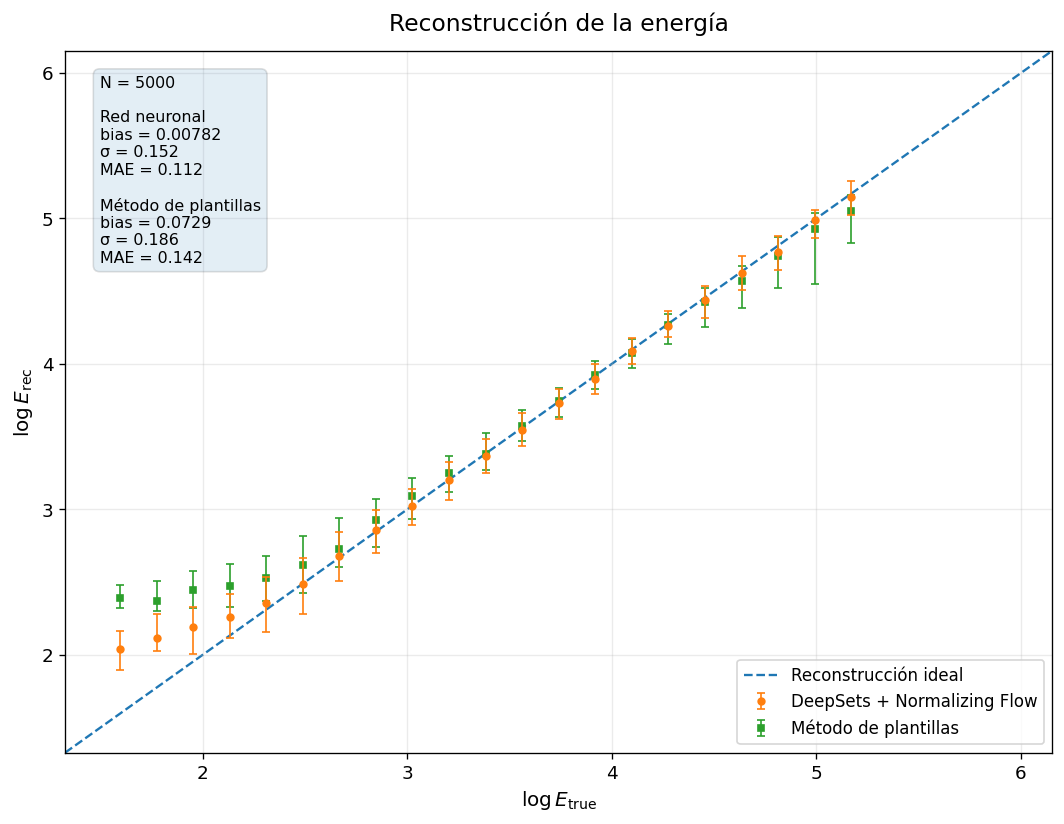


 COMPARACIÓN DE LA DISTANCIA RADIAL

DeepSets + Normalizing Flow:
  bias = -1.1738 m
  sigma = 15.8626 m
  MAE = 10.6617 m

Método de plantillas:
  bias = -1.1225 m
  sigma = 15.0472 m
  MAE = 8.2426 m

 COMPARACIÓN DE LA ENERGÍA

DeepSets + Normalizing Flow:
  bias = 0.0078
  sigma = 0.1517
  MAE = 0.1122

Método de plantillas:
  bias = 0.0729
  sigma = 0.1865
  MAE = 0.1420

[OK] Red neuronal y método de plantillas utilizan exactamente los mismos eventos.
[OK] La comparación radial contiene ambos métodos en una única gráfica.
[OK] La comparación de energía contiene ambos métodos en una única gráfica.
[OK] La distancia radial utiliza R = sqrt(coreX² + coreY²).
[OK] La energía representada corresponde a logEnergy.
[OK] Las barras representan el intervalo p16-p84 y los puntos la mediana dentro de cada bin.


In [ ]:
# ── DIBUJAR COMPARACIÓN RED + MÉTODO DE PLANTILLAS ──────────────────────

def plot_binned_comparison(
    ax,
    x_true,
    y_red,
    y_plantillas,
    title,
    xlabel,
    ylabel,
    n_bins=25,
    min_count=20,
):

    # ── ESTADÍSTICOS DE LA RED ───────────────────────────────────────────

    (
        x_red_bin,
        red_med,
        red_low,
        red_high,
    ) = binned_p16_p50_p84(
        x_true,
        y_red,
        n_bins=n_bins,
        min_count=min_count,
    )


    # ── ESTADÍSTICOS DEL MÉTODO DE PLANTILLAS ────────────────────────────

    (
        x_plantillas_bin,
        plantillas_med,
        plantillas_low,
        plantillas_high,
    ) = binned_p16_p50_p84(
        x_true,
        y_plantillas,
        n_bins=n_bins,
        min_count=min_count,
    )


    # ── EVENTOS FINITOS COMUNES ──────────────────────────────────────────

    finite = (
        np.isfinite(
            x_true
        )
        &
        np.isfinite(
            y_red
        )
        &
        np.isfinite(
            y_plantillas
        )
    )


    x = np.asarray(
        x_true,
        dtype=np.float64,
    )[
        finite
    ]


    red = np.asarray(
        y_red,
        dtype=np.float64,
    )[
        finite
    ]


    plantillas = np.asarray(
        y_plantillas,
        dtype=np.float64,
    )[
        finite
    ]


    # ── LÍMITES COMUNES ──────────────────────────────────────────────────

    lo = min(
        np.nanmin(
            x
        ),
        np.nanmin(
            red
        ),
        np.nanmin(
            plantillas
        ),
    )


    hi = max(
        np.nanmax(
            x
        ),
        np.nanmax(
            red
        ),
        np.nanmax(
            plantillas
        ),
    )


    pad = (
        0.04
        *
        (
            hi
            -
            lo
        )
        if hi > lo
        else 1.0
    )


    lo -= pad
    hi += pad


    # ── LÍNEA IDEAL y = x ────────────────────────────────────────────────

    ax.plot(
        [
            lo,
            hi,
        ],
        [
            lo,
            hi,
        ],
        "--",
        linewidth=1.4,
        label="Reconstrucción ideal",
        zorder=1,
    )


    # ── RED NEURONAL ─────────────────────────────────────────────────────

    ax.errorbar(
        x_red_bin,
        red_med,
        yerr=[
            red_low,
            red_high,
        ],
        fmt="o",
        markersize=4,
        capsize=2.5,
        elinewidth=1.0,
        linewidth=1.0,
        label="DeepSets + Normalizing Flow",
        zorder=3,
    )


    # ── MÉTODO DE PLANTILLAS ─────────────────────────────────────────────

    ax.errorbar(
        x_plantillas_bin,
        plantillas_med,
        yerr=[
            plantillas_low,
            plantillas_high,
        ],
        fmt="s",
        markersize=3.5,
        capsize=2.5,
        elinewidth=1.0,
        linewidth=1.0,
        label="Método de plantillas",
        zorder=2,
    )


    # ── CONFIGURACIÓN DEL EJE ────────────────────────────────────────────

    ax.set_xlim(
        lo,
        hi
    )


    ax.set_ylim(
        lo,
        hi
    )


    ax.set_xlabel(
        xlabel,
        fontsize=12,
    )


    ax.set_ylabel(
        ylabel,
        fontsize=12,
    )


    ax.set_title(
        title,
        fontsize=14,
        pad=12,
    )


    ax.grid(
        alpha=0.25
    )


    ax.tick_params(
        axis="both",
        labelsize=11,
    )


    # ── LEYENDA ──────────────────────────────────────────────────────────

    ax.legend(
        loc="lower right",
        fontsize=10,
        frameon=True,
    )


    # ── MÉTRICAS GLOBALES ────────────────────────────────────────────────

    residual_red = (
        red
        -
        x
    )


    residual_plantillas = (
        plantillas
        -
        x
    )


    red_bias = np.mean(
        residual_red
    )


    red_std = np.std(
        residual_red
    )


    red_mae = np.mean(
        np.abs(
            residual_red
        )
    )


    plantillas_bias = np.mean(
        residual_plantillas
    )


    plantillas_std = np.std(
        residual_plantillas
    )


    plantillas_mae = np.mean(
        np.abs(
            residual_plantillas
        )
    )


    txt = (
        f"N = {len(x)}\n"
        "\n"
        "Red neuronal\n"
        f"bias = {red_bias:.3g}\n"
        f"σ = {red_std:.3g}\n"
        f"MAE = {red_mae:.3g}\n"
        "\n"
        "Método de plantillas\n"
        f"bias = {plantillas_bias:.3g}\n"
        f"σ = {plantillas_std:.3g}\n"
        f"MAE = {plantillas_mae:.3g}"
    )


    ax.text(
        0.035,
        0.965,
        txt,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.4",
            alpha=0.12,
        ),
    )


# ── FIGURA 1: DISTANCIA RADIAL ───────────────────────────────────────────

fig_radial, ax_radial = plt.subplots(
    figsize=(
        9,
        7,
    ),
)


plot_binned_comparison(
    ax_radial,
    R_true,
    R_red,
    R_temp,
    "Reconstrucción de la distancia radial",
    r"$R_{\mathrm{true}}$ [m]",
    r"$R_{\mathrm{rec}}$ [m]",
)


plt.tight_layout()


plt.show()


# ── FIGURA 2: ENERGÍA ────────────────────────────────────────────────────

fig_energy, ax_energy = plt.subplots(
    figsize=(
        9,
        7,
    ),
)


plot_binned_comparison(
    ax_energy,
    logE_true,
    logE_red,
    logE_temp,
    "Reconstrucción de la energía",
    r"$\log E_{\mathrm{true}}$",
    r"$\log E_{\mathrm{rec}}$",
)


plt.tight_layout()


plt.show()


# ── RESUMEN NUMÉRICO PARA DISTANCIA RADIAL ───────────────────────────────

radial_residual_red = (
    R_red
    -
    R_true
)


radial_residual_plantillas = (
    R_temp
    -
    R_true
)


print()

print(
    "============================================================"
)

print(
    " COMPARACIÓN DE LA DISTANCIA RADIAL"
)

print(
    "============================================================"
)


print()

print(
    "DeepSets + Normalizing Flow:"
)

print(
    f"  bias = {np.mean(radial_residual_red):.4f} m"
)

print(
    f"  sigma = {np.std(radial_residual_red):.4f} m"
)

print(
    f"  MAE = {np.mean(np.abs(radial_residual_red)):.4f} m"
)


print()

print(
    "Método de plantillas:"
)

print(
    f"  bias = {np.mean(radial_residual_plantillas):.4f} m"
)

print(
    f"  sigma = {np.std(radial_residual_plantillas):.4f} m"
)

print(
    f"  MAE = {np.mean(np.abs(radial_residual_plantillas)):.4f} m"
)


# ── RESUMEN NUMÉRICO PARA ENERGÍA ────────────────────────────────────────

energy_residual_red = (
    logE_red
    -
    logE_true
)


energy_residual_plantillas = (
    logE_temp
    -
    logE_true
)


print()

print(
    "============================================================"
)

print(
    " COMPARACIÓN DE LA ENERGÍA"
)

print(
    "============================================================"
)


print()

print(
    "DeepSets + Normalizing Flow:"
)

print(
    f"  bias = {np.mean(energy_residual_red):.4f}"
)

print(
    f"  sigma = {np.std(energy_residual_red):.4f}"
)

print(
    f"  MAE = {np.mean(np.abs(energy_residual_red)):.4f}"
)


print()

print(
    "Método de plantillas:"
)

print(
    f"  bias = {np.mean(energy_residual_plantillas):.4f}"
)

print(
    f"  sigma = {np.std(energy_residual_plantillas):.4f}"
)

print(
    f"  MAE = {np.mean(np.abs(energy_residual_plantillas)):.4f}"
)


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "[OK] Red neuronal y método de plantillas utilizan "
    "exactamente los mismos eventos."
)

print(
    "[OK] La comparación radial contiene ambos métodos "
    "en una única gráfica."
)

print(
    "[OK] La comparación de energía contiene ambos métodos "
    "en una única gráfica."
)

print(
    "[OK] La distancia radial utiliza "
    "R = sqrt(coreX² + coreY²)."
)

print(
    "[OK] La energía representada corresponde a logEnergy."
)

print(
    "[OK] Las barras representan el intervalo p16-p84 "
    "y los puntos la mediana dentro de cada bin."
)

In [ ]:
###############################################################################
## TABLA RESUMEN FINAL DE RESULTADOS
##
## COMPARACIÓN:
##     DEEPSETS + NORMALIZING FLOW
##     VS
##     MÉTODO DE PLANTILLAS
##
## IMPORTANTE:
## - UTILIZA EXACTAMENTE LOS MISMOS EVENTOS PARA AMBOS MÉTODOS.
## - UTILIZA LA MEDIANA POSTERIOR DE LA RED.
## - TODAS LAS MÉTRICAS SE CALCULAN DE NUEVO.
## - NO SE REUTILIZA NINGÚN VALOR DE ENTRENAMIENTOS ANTERIORES.
###############################################################################

import numpy as np
import pandas as pd


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

SUMMARY_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


## COMPROBAR ORDEN ##
if "PHYSICAL_TARGET_NAMES" in globals():

    if list(
        PHYSICAL_TARGET_NAMES
    ) != SUMMARY_TARGET_NAMES:

        raise ValueError(
            "PHYSICAL_TARGET_NAMES does not match the expected "
            "physical target order.\n"
            f"Current : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Expected: {SUMMARY_TARGET_NAMES}"
        )


# ── RECUPERAR ARRAYS ─────────────────────────────────────────────────────

## VERDAD MONTE CARLO ##
if (
    "Y_TRUE_TEMPLATE" in globals()
    and
    Y_TRUE_TEMPLATE is not None
):

    Y_TRUE_SUMMARY = np.asarray(
        Y_TRUE_TEMPLATE,
        dtype=np.float64,
    )

elif "Y_TRUE" in globals():

    Y_TRUE_SUMMARY = np.asarray(
        Y_TRUE,
        dtype=np.float64,
    )

else:

    raise RuntimeError(
        "No se encuentra Y_TRUE ni Y_TRUE_TEMPLATE."
    )


## RED NEURONAL ##
##
## PRIORIZAR LA MEDIANA YA ALINEADA CON LOS EVENTOS DE PLANTILLAS.

if (
    "Y_PRED_MEDIAN_TEMPLATE" in globals()
    and
    Y_PRED_MEDIAN_TEMPLATE is not None
):

    Y_RED_SUMMARY = np.asarray(
        Y_PRED_MEDIAN_TEMPLATE,
        dtype=np.float64,
    )

    SUMMARY_PREDICTION_KIND = "Mediana posterior"


elif (
    "Y_PRED_MEDIAN" in globals()
    and
    Y_PRED_MEDIAN is not None
):

    Y_RED_SUMMARY = np.asarray(
        Y_PRED_MEDIAN,
        dtype=np.float64,
    )

    SUMMARY_PREDICTION_KIND = "Mediana posterior"


elif (
    "Y_PRED_TEMPLATE" in globals()
    and
    Y_PRED_TEMPLATE is not None
):

    Y_RED_SUMMARY = np.asarray(
        Y_PRED_TEMPLATE,
        dtype=np.float64,
    )

    SUMMARY_PREDICTION_KIND = "Media posterior"


elif "Y_PRED" in globals():

    Y_RED_SUMMARY = np.asarray(
        Y_PRED,
        dtype=np.float64,
    )

    SUMMARY_PREDICTION_KIND = "Media posterior"


else:

    raise RuntimeError(
        "No se encuentran las predicciones de la red."
    )


## MÉTODO DE PLANTILLAS ##
if (
    "TEMPLATE_POINT" in globals()
    and
    TEMPLATE_POINT is not None
):

    Y_PLANTILLAS_SUMMARY = np.asarray(
        TEMPLATE_POINT,
        dtype=np.float64,
    )


elif (
    "Y_TEMP" in globals()
    and
    Y_TEMP is not None
):

    Y_PLANTILLAS_SUMMARY = np.asarray(
        Y_TEMP,
        dtype=np.float64,
    )


else:

    raise RuntimeError(
        "No se encuentra TEMPLATE_POINT ni Y_TEMP."
    )


# ── COMPROBAR DIMENSIONES ────────────────────────────────────────────────

for arr_name, arr in [

    (
        "Y_TRUE_SUMMARY",
        Y_TRUE_SUMMARY,
    ),

    (
        "Y_RED_SUMMARY",
        Y_RED_SUMMARY,
    ),

    (
        "Y_PLANTILLAS_SUMMARY",
        Y_PLANTILLAS_SUMMARY,
    ),

]:

    if (
        arr.ndim != 2
        or arr.shape[1] != 5
    ):

        raise ValueError(
            f"{arr_name} has shape {arr.shape}; "
            "expected (N, 5)."
        )


    if not np.all(
        np.isfinite(
            arr
        )
    ):

        raise ValueError(
            f"{arr_name} contains non-finite values."
        )


## MISMO NÚMERO DE EVENTOS ##
if not (
    len(Y_TRUE_SUMMARY)
    ==
    len(Y_RED_SUMMARY)
    ==
    len(Y_PLANTILLAS_SUMMARY)
):

    raise ValueError(
        "Red, plantillas y Monte Carlo no contienen "
        "el mismo número de eventos."
    )


N_SUMMARY_EVENTS = len(
    Y_TRUE_SUMMARY
)


print()

print(
    "============================================================"
)

print(
    " TABLA RESUMEN DEL NUEVO ENTRENAMIENTO"
)

print(
    "============================================================"
)

print(
    f"Eventos comparados       : {N_SUMMARY_EVENTS}"
)

print(
    f"Predicción puntual red   : {SUMMARY_PREDICTION_KIND}"
)

print(
    "Método convencional      : Método de plantillas"
)


# ── ÍNDICES ──────────────────────────────────────────────────────────────

ix_coreX = SUMMARY_TARGET_NAMES.index(
    "coreX"
)

ix_coreY = SUMMARY_TARGET_NAMES.index(
    "coreY"
)

ix_zenith = SUMMARY_TARGET_NAMES.index(
    "zenithAngle"
)

ix_azimuth = SUMMARY_TARGET_NAMES.index(
    "azimuthAngle"
)

ix_logE = SUMMARY_TARGET_NAMES.index(
    "logEnergy"
)


# ── FUNCIONES AUXILIARES ─────────────────────────────────────────────────

def circular_difference_summary(
    predicted,
    true,
):

    ## DIFERENCIA CIRCULAR EN [-pi, pi) ##
    return np.arctan2(
        np.sin(
            predicted
            -
            true
        ),
        np.cos(
            predicted
            -
            true
        ),
    )


def angular_separation_summary(
    theta_true,
    phi_true,
    theta_pred,
    phi_pred,
):

    ## DIFERENCIA CIRCULAR DE AZIMUT ##
    delta_phi = circular_difference_summary(
        phi_pred,
        phi_true,
    )


    ## PRODUCTO ESCALAR DE LOS VECTORES DIRECCIÓN ##
    cos_delta = (

        np.cos(
            theta_true
        )

        *

        np.cos(
            theta_pred
        )

        +

        np.sin(
            theta_true
        )

        *

        np.sin(
            theta_pred
        )

        *

        np.cos(
            delta_phi
        )
    )


    ## SEGURIDAD NUMÉRICA ##
    cos_delta = np.clip(
        cos_delta,
        -1.0,
        1.0,
    )


    return np.rad2deg(
        np.arccos(
            cos_delta
        )
    )


def standard_metrics(
    residual,
):

    residual = np.asarray(
        residual,
        dtype=np.float64,
    )


    return {
        "Bias":
            float(
                np.mean(
                    residual
                )
            ),

        "Sigma":
            float(
                np.std(
                    residual
                )
            ),

        "MAE":
            float(
                np.mean(
                    np.abs(
                        residual
                    )
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        residual ** 2
                    )
                )
            ),

        "Mediana |error|":
            float(
                np.median(
                    np.abs(
                        residual
                    )
                )
            ),

        "P68 |error|":
            float(
                np.percentile(
                    np.abs(
                        residual
                    ),
                    68,
                )
            ),

        "P95 |error|":
            float(
                np.percentile(
                    np.abs(
                        residual
                    ),
                    95,
                )
            ),
    }


# ── CORE X ────────────────────────────────────────────────────────────────

delta_coreX_red = (

    Y_RED_SUMMARY[
        :,
        ix_coreX,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_coreX,
    ]
)


delta_coreX_plantillas = (

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_coreX,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_coreX,
    ]
)


# ── CORE Y ────────────────────────────────────────────────────────────────

delta_coreY_red = (

    Y_RED_SUMMARY[
        :,
        ix_coreY,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_coreY,
    ]
)


delta_coreY_plantillas = (

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_coreY,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_coreY,
    ]
)


# ── ERROR ESPACIAL DEL CORE ──────────────────────────────────────────────

core_error_red = np.sqrt(

    delta_coreX_red ** 2

    +

    delta_coreY_red ** 2
)


core_error_plantillas = np.sqrt(

    delta_coreX_plantillas ** 2

    +

    delta_coreY_plantillas ** 2
)


# ── DISTANCIA RADIAL R ───────────────────────────────────────────────────

R_true_summary = np.sqrt(

    Y_TRUE_SUMMARY[
        :,
        ix_coreX,
    ] ** 2

    +

    Y_TRUE_SUMMARY[
        :,
        ix_coreY,
    ] ** 2
)


R_red_summary = np.sqrt(

    Y_RED_SUMMARY[
        :,
        ix_coreX,
    ] ** 2

    +

    Y_RED_SUMMARY[
        :,
        ix_coreY,
    ] ** 2
)


R_plantillas_summary = np.sqrt(

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_coreX,
    ] ** 2

    +

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_coreY,
    ] ** 2
)


delta_R_red = (
    R_red_summary
    -
    R_true_summary
)


delta_R_plantillas = (
    R_plantillas_summary
    -
    R_true_summary
)


# ── ZENITH ────────────────────────────────────────────────────────────────

delta_zenith_red_deg = np.rad2deg(

    Y_RED_SUMMARY[
        :,
        ix_zenith,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_zenith,
    ]
)


delta_zenith_plantillas_deg = np.rad2deg(

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_zenith,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_zenith,
    ]
)


# ── AZIMUT ────────────────────────────────────────────────────────────────

delta_azimuth_red_deg = np.rad2deg(

    circular_difference_summary(

        Y_RED_SUMMARY[
            :,
            ix_azimuth,
        ],

        Y_TRUE_SUMMARY[
            :,
            ix_azimuth,
        ],
    )
)


delta_azimuth_plantillas_deg = np.rad2deg(

    circular_difference_summary(

        Y_PLANTILLAS_SUMMARY[
            :,
            ix_azimuth,
        ],

        Y_TRUE_SUMMARY[
            :,
            ix_azimuth,
        ],
    )
)


# ── SEPARACIÓN ANGULAR FÍSICA ────────────────────────────────────────────

angular_error_red = angular_separation_summary(

    Y_TRUE_SUMMARY[
        :,
        ix_zenith,
    ],

    Y_TRUE_SUMMARY[
        :,
        ix_azimuth,
    ],

    Y_RED_SUMMARY[
        :,
        ix_zenith,
    ],

    Y_RED_SUMMARY[
        :,
        ix_azimuth,
    ],
)


angular_error_plantillas = angular_separation_summary(

    Y_TRUE_SUMMARY[
        :,
        ix_zenith,
    ],

    Y_TRUE_SUMMARY[
        :,
        ix_azimuth,
    ],

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_zenith,
    ],

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_azimuth,
    ],
)


# ── ENERGÍA ──────────────────────────────────────────────────────────────

delta_logE_red = (

    Y_RED_SUMMARY[
        :,
        ix_logE,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_logE,
    ]
)


delta_logE_plantillas = (

    Y_PLANTILLAS_SUMMARY[
        :,
        ix_logE,
    ]

    -

    Y_TRUE_SUMMARY[
        :,
        ix_logE,
    ]
)


# ── CONSTRUIR TABLA RESUMEN ─────────────────────────────────────────────

summary_rows = []


def add_standard_rows(
    variable,
    unit,
    residual_red,
    residual_plantillas,
):

    ## MÉTRICAS DE AMBOS MÉTODOS ##
    metrics_red = standard_metrics(
        residual_red
    )


    metrics_plantillas = standard_metrics(
        residual_plantillas
    )


    ## AÑADIR FILAS ##
    for metric_name in [
        "Bias",
        "Sigma",
        "MAE",
        "RMSE",
        "Mediana |error|",
        "P68 |error|",
        "P95 |error|",
    ]:

        summary_rows.append(
            {
                "Variable":
                    variable,

                "Métrica":
                    metric_name,

                "Red neuronal":
                    metrics_red[
                        metric_name
                    ],

                "Método de plantillas":
                    metrics_plantillas[
                        metric_name
                    ],

                "Unidad":
                    unit,
            }
        )


# ── MÉTRICAS CORE X ──────────────────────────────────────────────────────

add_standard_rows(
    "coreX",
    "m",
    delta_coreX_red,
    delta_coreX_plantillas,
)


# ── MÉTRICAS CORE Y ──────────────────────────────────────────────────────

add_standard_rows(
    "coreY",
    "m",
    delta_coreY_red,
    delta_coreY_plantillas,
)


# ── MÉTRICAS DE R ────────────────────────────────────────────────────────

add_standard_rows(
    "Distancia radial R",
    "m",
    delta_R_red,
    delta_R_plantillas,
)


# ── MÉTRICAS DE ZENITH ───────────────────────────────────────────────────

add_standard_rows(
    "Zenith",
    "deg",
    delta_zenith_red_deg,
    delta_zenith_plantillas_deg,
)


# ── MÉTRICAS DE AZIMUT ───────────────────────────────────────────────────

add_standard_rows(
    "Azimuth",
    "deg",
    delta_azimuth_red_deg,
    delta_azimuth_plantillas_deg,
)


# ── MÉTRICAS DE ENERGÍA ──────────────────────────────────────────────────

add_standard_rows(
    "logEnergy",
    "log10(eV)",
    delta_logE_red,
    delta_logE_plantillas,
)


# ── ERROR ESPACIAL DEL CORE ──────────────────────────────────────────────

summary_rows.extend(
    [
        {
            "Variable":
                "Error espacial del core",

            "Métrica":
                "Media",

            "Red neuronal":
                float(
                    np.mean(
                        core_error_red
                    )
                ),

            "Método de plantillas":
                float(
                    np.mean(
                        core_error_plantillas
                    )
                ),

            "Unidad":
                "m",
        },

        {
            "Variable":
                "Error espacial del core",

            "Métrica":
                "Mediana",

            "Red neuronal":
                float(
                    np.median(
                        core_error_red
                    )
                ),

            "Método de plantillas":
                float(
                    np.median(
                        core_error_plantillas
                    )
                ),

            "Unidad":
                "m",
        },

        {
            "Variable":
                "Error espacial del core",

            "Métrica":
                "P68",

            "Red neuronal":
                float(
                    np.percentile(
                        core_error_red,
                        68,
                    )
                ),

            "Método de plantillas":
                float(
                    np.percentile(
                        core_error_plantillas,
                        68,
                    )
                ),

            "Unidad":
                "m",
        },

        {
            "Variable":
                "Error espacial del core",

            "Métrica":
                "P95",

            "Red neuronal":
                float(
                    np.percentile(
                        core_error_red,
                        95,
                    )
                ),

            "Método de plantillas":
                float(
                    np.percentile(
                        core_error_plantillas,
                        95,
                    )
                ),

            "Unidad":
                "m",
        },
    ]
)


# ── SEPARACIÓN ANGULAR deltaPsi ──────────────────────────────────────────

summary_rows.extend(
    [
        {
            "Variable":
                "Separación angular deltaPsi",

            "Métrica":
                "Media",

            "Red neuronal":
                float(
                    np.mean(
                        angular_error_red
                    )
                ),

            "Método de plantillas":
                float(
                    np.mean(
                        angular_error_plantillas
                    )
                ),

            "Unidad":
                "deg",
        },

        {
            "Variable":
                "Separación angular deltaPsi",

            "Métrica":
                "Mediana",

            "Red neuronal":
                float(
                    np.median(
                        angular_error_red
                    )
                ),

            "Método de plantillas":
                float(
                    np.median(
                        angular_error_plantillas
                    )
                ),

            "Unidad":
                "deg",
        },

        {
            "Variable":
                "Separación angular deltaPsi",

            "Métrica":
                "P68",

            "Red neuronal":
                float(
                    np.percentile(
                        angular_error_red,
                        68,
                    )
                ),

            "Método de plantillas":
                float(
                    np.percentile(
                        angular_error_plantillas,
                        68,
                    )
                ),

            "Unidad":
                "deg",
        },

        {
            "Variable":
                "Separación angular deltaPsi",

            "Métrica":
                "P95",

            "Red neuronal":
                float(
                    np.percentile(
                        angular_error_red,
                        95,
                    )
                ),

            "Método de plantillas":
                float(
                    np.percentile(
                        angular_error_plantillas,
                        95,
                    )
                ),

            "Unidad":
                "deg",
        },
    ]
)


# ── DATAFRAME COMPLETO ───────────────────────────────────────────────────

RESULTS_SUMMARY_DF = pd.DataFrame(
    summary_rows
)


## REDONDEAR SOLO PARA VISUALIZACIÓN ##
RESULTS_SUMMARY_DISPLAY = RESULTS_SUMMARY_DF.copy()


RESULTS_SUMMARY_DISPLAY[
    "Red neuronal"
] = RESULTS_SUMMARY_DISPLAY[
    "Red neuronal"
].round(
    4
)


RESULTS_SUMMARY_DISPLAY[
    "Método de plantillas"
] = RESULTS_SUMMARY_DISPLAY[
    "Método de plantillas"
].round(
    4
)


# ── MOSTRAR TABLA COMPLETA ───────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " RESULTADOS COMPLETOS"
)

print(
    "============================================================"
)

print()


display(
    RESULTS_SUMMARY_DISPLAY
)


# ── TABLA COMPACTA PARA COMENTAR EN EL TFM ───────────────────────────────

## SELECCIONAMOS LAS MÉTRICAS MÁS REPRESENTATIVAS PARA EL TEXTO FINAL.

compact_rows = [

    {
        "Magnitud":
            "Error espacial del core",

        "Métrica":
            "Mediana",

        "Red neuronal":
            np.median(
                core_error_red
            ),

        "Método de plantillas":
            np.median(
                core_error_plantillas
            ),

        "Unidad":
            "m",
    },

    {
        "Magnitud":
            "Error espacial del core",

        "Métrica":
            "P68",

        "Red neuronal":
            np.percentile(
                core_error_red,
                68,
            ),

        "Método de plantillas":
            np.percentile(
                core_error_plantillas,
                68,
            ),

        "Unidad":
            "m",
    },

    {
        "Magnitud":
            "Distancia radial R",

        "Métrica":
            "Bias",

        "Red neuronal":
            np.mean(
                delta_R_red
            ),

        "Método de plantillas":
            np.mean(
                delta_R_plantillas
            ),

        "Unidad":
            "m",
    },

    {
        "Magnitud":
            "Distancia radial R",

        "Métrica":
            "MAE",

        "Red neuronal":
            np.mean(
                np.abs(
                    delta_R_red
                )
            ),

        "Método de plantillas":
            np.mean(
                np.abs(
                    delta_R_plantillas
                )
            ),

        "Unidad":
            "m",
    },

    {
        "Magnitud":
            "Separación angular deltaPsi",

        "Métrica":
            "Mediana",

        "Red neuronal":
            np.median(
                angular_error_red
            ),

        "Método de plantillas":
            np.median(
                angular_error_plantillas
            ),

        "Unidad":
            "deg",
    },

    {
        "Magnitud":
            "Separación angular deltaPsi",

        "Métrica":
            "P68",

        "Red neuronal":
            np.percentile(
                angular_error_red,
                68,
            ),

        "Método de plantillas":
            np.percentile(
                angular_error_plantillas,
                68,
            ),

        "Unidad":
            "deg",
    },

    {
        "Magnitud":
            "Separación angular deltaPsi",

        "Métrica":
            "P95",

        "Red neuronal":
            np.percentile(
                angular_error_red,
                95,
            ),

        "Método de plantillas":
            np.percentile(
                angular_error_plantillas,
                95,
            ),

        "Unidad":
            "deg",
    },

    {
        "Magnitud":
            "logEnergy",

        "Métrica":
            "Bias",

        "Red neuronal":
            np.mean(
                delta_logE_red
            ),

        "Método de plantillas":
            np.mean(
                delta_logE_plantillas
            ),

        "Unidad":
            "log10(eV)",
    },

    {
        "Magnitud":
            "logEnergy",

        "Métrica":
            "MAE",

        "Red neuronal":
            np.mean(
                np.abs(
                    delta_logE_red
                )
            ),

        "Método de plantillas":
            np.mean(
                np.abs(
                    delta_logE_plantillas
                )
            ),

        "Unidad":
            "log10(eV)",
    },

    {
        "Magnitud":
            "logEnergy",

        "Métrica":
            "RMSE",

        "Red neuronal":
            np.sqrt(
                np.mean(
                    delta_logE_red ** 2
                )
            ),

        "Método de plantillas":
            np.sqrt(
                np.mean(
                    delta_logE_plantillas ** 2
                )
            ),

        "Unidad":
            "log10(eV)",
    },
]


RESULTS_COMPACT_DF = pd.DataFrame(
    compact_rows
)


RESULTS_COMPACT_DF[
    "Red neuronal"
] = RESULTS_COMPACT_DF[
    "Red neuronal"
].round(
    4
)


RESULTS_COMPACT_DF[
    "Método de plantillas"
] = RESULTS_COMPACT_DF[
    "Método de plantillas"
].round(
    4
)


print()

print(
    "============================================================"
)

print(
    " TABLA COMPACTA PARA EL ANÁLISIS DEL TFM"
)

print(
    "============================================================"
)

print()


display(
    RESULTS_COMPACT_DF
)


# ── GUARDAR RESULTADOS ───────────────────────────────────────────────────

if (
    "CFG" in globals()
    and
    CFG.get(
        "save_artifacts",
        True,
    )
    and
    "artifact_path" in globals()
):

    summary_csv = artifact_path(
        "final_results_summary.csv",
        run_specific=False,
    )


    summary_csv_run = artifact_path(
        "final_results_summary.csv",
        run_specific=True,
    )


    compact_csv = artifact_path(
        "final_results_summary_compact.csv",
        run_specific=False,
    )


    compact_csv_run = artifact_path(
        "final_results_summary_compact.csv",
        run_specific=True,
    )


    RESULTS_SUMMARY_DF.to_csv(
        summary_csv,
        index=False,
    )


    RESULTS_SUMMARY_DF.to_csv(
        summary_csv_run,
        index=False,
    )


    RESULTS_COMPACT_DF.to_csv(
        compact_csv,
        index=False,
    )


    RESULTS_COMPACT_DF.to_csv(
        compact_csv_run,
        index=False,
    )


    print()

    print(
        f"[saved] {summary_csv}"
    )

    print(
        f"[saved] {summary_csv_run}"
    )

    print(
        f"[saved] {compact_csv}"
    )

    print(
        f"[saved] {compact_csv_run}"
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " RESUMEN FINAL CALCULADO CORRECTAMENTE"
)

print(
    "============================================================"
)


print(
    f"[OK] {N_SUMMARY_EVENTS} eventos utilizados."
)

print(
    "[OK] Red neuronal y método de plantillas comparados "
    "sobre exactamente los mismos eventos."
)

print(
    f"[OK] Predicción puntual de la red: "
    f"{SUMMARY_PREDICTION_KIND}."
)

print(
    "[OK] Core evaluado en coreX, coreY, error espacial y distancia radial."
)

print(
    "[OK] Zenith evaluado en grados."
)

print(
    "[OK] Azimuth evaluado mediante diferencia circular."
)

print(
    "[OK] Dirección evaluada mediante separación angular física deltaPsi."
)

print(
    "[OK] Energía evaluada mediante logEnergy."
)

print(
    "[OK] Todos los resultados se han recalculado con el entrenamiento actual."
)


 TABLA RESUMEN DEL NUEVO ENTRENAMIENTO
Eventos comparados       : 5000
Predicción puntual red   : Mediana posterior
Método convencional      : Método de plantillas

 RESULTADOS COMPLETOS



,Variable,Métrica,Red neuronal,Método de plantillas,Unidad
0,coreX,Bias,-0.6784,-0.1614,m
1,coreX,Sigma,15.7473,14.9553,m
2,coreX,MAE,10.4451,8.2399,m
3,coreX,RMSE,15.7619,14.9562,m
4,coreX,Mediana |error|,7.0262,4.4700,m
5,coreX,P68 |error|,11.0644,7.8300,m
6,coreX,P95 |error|,32.2055,27.0505,m
7,coreY,Bias,-2.3514,0.0588,m
8,coreY,Sigma,15.2773,13.1233,m
9,coreY,MAE,10.1187,7.4484,m



 TABLA COMPACTA PARA EL ANÁLISIS DEL TFM



,Magnitud,Métrica,Red neuronal,Método de plantillas,Unidad
0,Error espacial del core,Mediana,11.9952,7.9266,m
1,Error espacial del core,P68,17.3567,12.2309,m
2,Distancia radial R,Bias,-1.1738,-1.1225,m
3,Distancia radial R,MAE,10.6617,8.2426,m
4,Separación angular deltaPsi,Mediana,0.8661,0.0000,deg
5,Separación angular deltaPsi,P68,1.1786,0.0000,deg
6,Separación angular deltaPsi,P95,2.3781,0.0000,deg
7,logEnergy,Bias,0.0078,0.0729,log10(eV)
8,logEnergy,MAE,0.1122,0.1420,log10(eV)
9,logEnergy,RMSE,0.1519,0.2002,log10(eV)



[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_results_summary.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/20260826_232231_final_results_summary.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_results_summary_compact.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/20260826_232231_final_results_summary_compact.csv

 RESUMEN FINAL CALCULADO CORRECTAMENTE
[OK] 5000 eventos utilizados.
[OK] Red neuronal y método de plantillas comparados sobre exactamente los mismos eventos.
[OK] Predicción puntual de la red: Mediana posterior.
[OK] Core evaluado en coreX, coreY, error espacial y distancia radial.
[OK] Zenith evaluado en grados.
[OK] Azimuth evaluado mediante diferencia circular.
[OK] Dirección evaluada mediante separación angular física deltaPsi.
[OK] Energía evaluada mediante logEnergy.
[OK] Todos los resultados se han recalculado con el entrenamiento actual.


In [ ]:
###############################################################################
## ANÁLISIS ESPECÍFICO DE EVENTOS PERIFÉRICOS
##
## OBJETIVO:
##
## Comprobar cuantitativamente el comportamiento de:
##
##     - DeepSets + Normalizing Flow
##     - Método de plantillas
##
## para cascadas cuyo núcleo verdadero se encuentra a radios elevados.
##
## MOTIVACIÓN:
##
## La comparación gráfica sugiere que, aunque el método de plantillas
## presenta mejores métricas globales, la red neuronal podría comportarse
## mejor para eventos periféricos.
##
## Se estudian los cortes:
##
##     R_true >= 550 m
##     R_true >= 600 m
##     R_true >= 650 m
##
## El corte principal para el análisis del TFM será R_true >= 600 m.
###############################################################################

import numpy as np
import pandas as pd


# ── CONFIGURACIÓN ────────────────────────────────────────────────────────

## CORTES RADIALES QUE SE QUIEREN ESTUDIAR ##
PERIPHERAL_RADIAL_THRESHOLDS = [
    550.0,
    600.0,
    650.0,
]


## CORTE PRINCIPAL PARA EL TEXTO DEL TFM ##
PERIPHERAL_MAIN_THRESHOLD = 600.0


# ── COMPROBAR VARIABLES NECESARIAS ───────────────────────────────────────

required_variables = [
    "R_true",
    "R_red",
    "R_temp",
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Faltan variables necesarias para el análisis periférico:\n"
        f"{missing_variables}\n\n"
        "Ejecuta primero la celda de comparación radial "
        "Red + Método de plantillas."
    )


# ── CONVERTIR A ARRAYS ───────────────────────────────────────────────────

R_TRUE_PERIPHERAL = np.asarray(
    R_true,
    dtype=np.float64,
)


R_RED_PERIPHERAL = np.asarray(
    R_red,
    dtype=np.float64,
)


R_PLANTILLAS_PERIPHERAL = np.asarray(
    R_temp,
    dtype=np.float64,
)


# ── COMPROBAR CONSISTENCIA ───────────────────────────────────────────────

if not (
    R_TRUE_PERIPHERAL.ndim
    ==
    R_RED_PERIPHERAL.ndim
    ==
    R_PLANTILLAS_PERIPHERAL.ndim
    ==
    1
):

    raise ValueError(
        "R_true, R_red y R_temp deben ser arrays unidimensionales."
    )


if not (
    len(R_TRUE_PERIPHERAL)
    ==
    len(R_RED_PERIPHERAL)
    ==
    len(R_PLANTILLAS_PERIPHERAL)
):

    raise ValueError(
        "R_true, R_red y R_temp no contienen el mismo número de eventos."
    )


finite_mask = (
    np.isfinite(
        R_TRUE_PERIPHERAL
    )
    &
    np.isfinite(
        R_RED_PERIPHERAL
    )
    &
    np.isfinite(
        R_PLANTILLAS_PERIPHERAL
    )
)


if not np.all(
    finite_mask
):

    print(
        f"[WARNING] Se excluirán "
        f"{np.sum(~finite_mask)} eventos no finitos."
    )


R_TRUE_PERIPHERAL = R_TRUE_PERIPHERAL[
    finite_mask
]


R_RED_PERIPHERAL = R_RED_PERIPHERAL[
    finite_mask
]


R_PLANTILLAS_PERIPHERAL = R_PLANTILLAS_PERIPHERAL[
    finite_mask
]


print()

print(
    "============================================================"
)

print(
    " ANÁLISIS DE EVENTOS PERIFÉRICOS"
)

print(
    "============================================================"
)

print(
    f"Eventos finitos disponibles : "
    f"{len(R_TRUE_PERIPHERAL)}"
)


# ── FUNCIÓN DE MÉTRICAS RADIALES ─────────────────────────────────────────

def compute_radial_metrics(
    r_true,
    r_rec,
):

    ## RESIDUO CON SIGNO ##
    residual = (
        r_rec
        -
        r_true
    )


    ## ERROR ABSOLUTO ##
    abs_error = np.abs(
        residual
    )


    return {

        "N":
            int(
                len(
                    residual
                )
            ),

        "Bias":
            float(
                np.mean(
                    residual
                )
            ),

        "Sigma":
            float(
                np.std(
                    residual
                )
            ),

        "MAE":
            float(
                np.mean(
                    abs_error
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        residual ** 2
                    )
                )
            ),

        "Mediana_error_abs":
            float(
                np.median(
                    abs_error
                )
            ),

        "P68_error_abs":
            float(
                np.percentile(
                    abs_error,
                    68,
                )
            ),

        "P95_error_abs":
            float(
                np.percentile(
                    abs_error,
                    95,
                )
            ),

        "Mediana_residuo":
            float(
                np.median(
                    residual
                )
            ),
    }


# ── CALCULAR RESULTADOS PARA CADA CORTE ──────────────────────────────────

peripheral_rows = []


for threshold in PERIPHERAL_RADIAL_THRESHOLDS:

    ## SELECCIONAR EVENTOS PERIFÉRICOS ##
    mask = (
        R_TRUE_PERIPHERAL
        >=
        threshold
    )


    n_events = int(
        np.sum(
            mask
        )
    )


    if n_events == 0:

        print(
            f"[WARNING] No hay eventos con "
            f"R_true >= {threshold:.0f} m."
        )

        continue


    ## ARRAYS DEL SUBCONJUNTO ##
    r_true_subset = R_TRUE_PERIPHERAL[
        mask
    ]


    r_red_subset = R_RED_PERIPHERAL[
        mask
    ]


    r_plantillas_subset = R_PLANTILLAS_PERIPHERAL[
        mask
    ]


    ## MÉTRICAS DE LA RED ##
    metrics_red = compute_radial_metrics(
        r_true_subset,
        r_red_subset,
    )


    ## MÉTRICAS DEL MÉTODO DE PLANTILLAS ##
    metrics_plantillas = compute_radial_metrics(
        r_true_subset,
        r_plantillas_subset,
    )


    # ── GUARDAR RESULTADOS ───────────────────────────────────────────────

    for metric_name in [
        "Bias",
        "Sigma",
        "MAE",
        "RMSE",
        "Mediana_error_abs",
        "P68_error_abs",
        "P95_error_abs",
        "Mediana_residuo",
    ]:

        red_value = metrics_red[
            metric_name
        ]


        plantillas_value = metrics_plantillas[
            metric_name
        ]


        ## DIFERENCIA RED - PLANTILLAS ##
        difference = (
            red_value
            -
            plantillas_value
        )


        ## PARA MÉTRICAS DE ERROR POSITIVAS:
        ## VALOR NEGATIVO = RED MEJOR.
        if metric_name in [
            "Sigma",
            "MAE",
            "RMSE",
            "Mediana_error_abs",
            "P68_error_abs",
            "P95_error_abs",
        ]:

            if plantillas_value != 0.0:

                improvement_red_percent = (
                    (
                        plantillas_value
                        -
                        red_value
                    )
                    /
                    plantillas_value
                    *
                    100.0
                )

            else:

                improvement_red_percent = np.nan


        else:

            improvement_red_percent = np.nan


        peripheral_rows.append(
            {
                "R_true_min_m":
                    threshold,

                "N_eventos":
                    n_events,

                "Metrica":
                    metric_name,

                "Red_neuronal":
                    red_value,

                "Metodo_plantillas":
                    plantillas_value,

                "Diferencia_red_menos_plantillas":
                    difference,

                "Mejora_red_percent":
                    improvement_red_percent,
            }
        )


# ── DATAFRAME COMPLETO ───────────────────────────────────────────────────

PERIPHERAL_RESULTS_DF = pd.DataFrame(
    peripheral_rows
)


## REDONDEAR PARA VISUALIZACIÓN ##
PERIPHERAL_RESULTS_DISPLAY = PERIPHERAL_RESULTS_DF.copy()


numeric_columns = [
    "Red_neuronal",
    "Metodo_plantillas",
    "Diferencia_red_menos_plantillas",
    "Mejora_red_percent",
]


for column_name in numeric_columns:

    PERIPHERAL_RESULTS_DISPLAY[
        column_name
    ] = PERIPHERAL_RESULTS_DISPLAY[
        column_name
    ].round(
        4
    )


print()

print(
    "============================================================"
)

print(
    " RESULTADOS PARA LOS DISTINTOS CORTES RADIALES"
)

print(
    "============================================================"
)

print()


display(
    PERIPHERAL_RESULTS_DISPLAY
)


# ── TABLA PRINCIPAL R_true >= 600 m ──────────────────────────────────────

MAIN_PERIPHERAL_DF = PERIPHERAL_RESULTS_DF[
    np.isclose(
        PERIPHERAL_RESULTS_DF[
            "R_true_min_m"
        ],
        PERIPHERAL_MAIN_THRESHOLD,
    )
].copy()


MAIN_PERIPHERAL_DISPLAY = MAIN_PERIPHERAL_DF.copy()


for column_name in numeric_columns:

    MAIN_PERIPHERAL_DISPLAY[
        column_name
    ] = MAIN_PERIPHERAL_DISPLAY[
        column_name
    ].round(
        4
    )


print()

print(
    "============================================================"
)

print(
    f" RESULTADOS PRINCIPALES: "
    f"R_true >= {PERIPHERAL_MAIN_THRESHOLD:.0f} m"
)

print(
    "============================================================"
)

print()


display(
    MAIN_PERIPHERAL_DISPLAY
)


# ── RESUMEN DIRECTO DEL CORTE DE 600 m ───────────────────────────────────

main_mask = (
    R_TRUE_PERIPHERAL
    >=
    PERIPHERAL_MAIN_THRESHOLD
)


main_true = R_TRUE_PERIPHERAL[
    main_mask
]


main_red = R_RED_PERIPHERAL[
    main_mask
]


main_plantillas = R_PLANTILLAS_PERIPHERAL[
    main_mask
]


main_red_metrics = compute_radial_metrics(
    main_true,
    main_red,
)


main_plantillas_metrics = compute_radial_metrics(
    main_true,
    main_plantillas,
)


print()

print(
    "============================================================"
)

print(
    f" COMPARACIÓN DIRECTA PARA R_true >= "
    f"{PERIPHERAL_MAIN_THRESHOLD:.0f} m"
)

print(
    "============================================================"
)

print()

print(
    f"N eventos periféricos : {len(main_true)}"
)


print()

print(
    "DeepSets + Normalizing Flow"
)

print(
    f"  Bias                 : "
    f"{main_red_metrics['Bias']:.4f} m"
)

print(
    f"  Sigma                : "
    f"{main_red_metrics['Sigma']:.4f} m"
)

print(
    f"  MAE                  : "
    f"{main_red_metrics['MAE']:.4f} m"
)

print(
    f"  RMSE                 : "
    f"{main_red_metrics['RMSE']:.4f} m"
)

print(
    f"  Mediana |error|      : "
    f"{main_red_metrics['Mediana_error_abs']:.4f} m"
)

print(
    f"  P68 |error|          : "
    f"{main_red_metrics['P68_error_abs']:.4f} m"
)

print(
    f"  P95 |error|          : "
    f"{main_red_metrics['P95_error_abs']:.4f} m"
)

print(
    f"  Mediana residuo      : "
    f"{main_red_metrics['Mediana_residuo']:.4f} m"
)


print()

print(
    "Método de plantillas"
)

print(
    f"  Bias                 : "
    f"{main_plantillas_metrics['Bias']:.4f} m"
)

print(
    f"  Sigma                : "
    f"{main_plantillas_metrics['Sigma']:.4f} m"
)

print(
    f"  MAE                  : "
    f"{main_plantillas_metrics['MAE']:.4f} m"
)

print(
    f"  RMSE                 : "
    f"{main_plantillas_metrics['RMSE']:.4f} m"
)

print(
    f"  Mediana |error|      : "
    f"{main_plantillas_metrics['Mediana_error_abs']:.4f} m"
)

print(
    f"  P68 |error|          : "
    f"{main_plantillas_metrics['P68_error_abs']:.4f} m"
)

print(
    f"  P95 |error|          : "
    f"{main_plantillas_metrics['P95_error_abs']:.4f} m"
)

print(
    f"  Mediana residuo      : "
    f"{main_plantillas_metrics['Mediana_residuo']:.4f} m"
)


# ── MEJORA RELATIVA DE LA RED ────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " MEJORA RELATIVA DE LA RED EN LA REGIÓN PERIFÉRICA"
)

print(
    "============================================================"
)


for metric_name, metric_label in [

    (
        "MAE",
        "MAE",
    ),

    (
        "RMSE",
        "RMSE",
    ),

    (
        "Mediana_error_abs",
        "Mediana |error|",
    ),

    (
        "P68_error_abs",
        "P68 |error|",
    ),

    (
        "P95_error_abs",
        "P95 |error|",
    ),

]:

    red_value = main_red_metrics[
        metric_name
    ]


    plantillas_value = main_plantillas_metrics[
        metric_name
    ]


    improvement = (
        (
            plantillas_value
            -
            red_value
        )
        /
        plantillas_value
        *
        100.0
    )


    print(
        f"{metric_label:20s}: "
        f"{improvement:+.2f} %"
    )


print()

print(
    "Interpretación:"
)

print(
    "  valor positivo  -> la red presenta menor error"
)

print(
    "  valor negativo  -> el método de plantillas presenta menor error"
)


# ── FRACCIÓN DEL TEST EN LA REGIÓN PERIFÉRICA ────────────────────────────

peripheral_fraction = (
    len(
        main_true
    )
    /
    len(
        R_TRUE_PERIPHERAL
    )
    *
    100.0
)


print()

print(
    f"Eventos con R_true >= "
    f"{PERIPHERAL_MAIN_THRESHOLD:.0f} m: "
    f"{len(main_true)} / {len(R_TRUE_PERIPHERAL)} "
    f"({peripheral_fraction:.2f} %)"
)


# ── GUARDAR RESULTADOS ───────────────────────────────────────────────────

if (
    "CFG" in globals()
    and
    CFG.get(
        "save_artifacts",
        True,
    )
    and
    "artifact_path" in globals()
):

    peripheral_csv = artifact_path(
        "peripheral_radial_comparison.csv",
        run_specific=False,
    )


    peripheral_csv_run = artifact_path(
        "peripheral_radial_comparison.csv",
        run_specific=True,
    )


    PERIPHERAL_RESULTS_DF.to_csv(
        peripheral_csv,
        index=False,
    )


    PERIPHERAL_RESULTS_DF.to_csv(
        peripheral_csv_run,
        index=False,
    )


    print()

    print(
        f"[saved] {peripheral_csv}"
    )

    print(
        f"[saved] {peripheral_csv_run}"
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " ANÁLISIS PERIFÉRICO COMPLETADO"
)

print(
    "============================================================"
)


print(
    "[OK] Red neuronal y método de plantillas utilizan "
    "exactamente los mismos eventos."
)

print(
    "[OK] El corte principal utilizado es R_true >= 600 m."
)

print(
    "[OK] Se calculan Bias, Sigma, MAE, RMSE, mediana, P68 y P95."
)

print(
    "[OK] Los resultados permiten comprobar cuantitativamente "
    "si la red mejora en la periferia."
)


 ANÁLISIS DE EVENTOS PERIFÉRICOS
Eventos finitos disponibles : 5000

 RESULTADOS PARA LOS DISTINTOS CORTES RADIALES



,R_true_min_m,N_eventos,Metrica,Red_neuronal,Metodo_plantillas,Diferencia_red_menos_plantillas,Mejora_red_percent
0,550.0,393,Bias,-5.0257,-19.1876,14.1620,NaN
1,550.0,393,Sigma,33.4382,35.3590,-1.9208,5.4323
2,550.0,393,MAE,25.0453,26.6036,-1.5583,5.8574
3,550.0,393,RMSE,33.8138,40.2297,-6.4159,15.9482
4,550.0,393,Mediana_error_abs,18.8161,15.0579,3.7581,-24.9579
5,550.0,393,P68_error_abs,29.0487,26.2894,2.7592,-10.4956
6,550.0,393,P95_error_abs,69.0209,89.0241,-20.0032,22.4694
7,550.0,393,Mediana_residuo,-5.0259,-10.3935,5.3676,NaN
8,600.0,221,Bias,-5.8909,-34.7300,28.8391,NaN
9,600.0,221,Sigma,36.9265,37.9547,-1.0283,2.7092



 RESULTADOS PRINCIPALES: R_true >= 600 m



,R_true_min_m,N_eventos,Metrica,Red_neuronal,Metodo_plantillas,Diferencia_red_menos_plantillas,Mejora_red_percent
8,600.0,221,Bias,-5.8909,-34.7300,28.8391,NaN
9,600.0,221,Sigma,36.9265,37.9547,-1.0283,2.7092
10,600.0,221,MAE,27.3288,38.3962,-11.0674,28.8242
11,600.0,221,RMSE,37.3934,51.4464,-14.0530,27.3158
12,600.0,221,Mediana_error_abs,19.1360,28.0034,-8.8673,31.6653
13,600.0,221,P68_error_abs,31.8673,44.7403,-12.8730,28.7727
14,600.0,221,P95_error_abs,75.5312,109.8653,-34.3341,31.2511
15,600.0,221,Mediana_residuo,-3.8414,-26.0461,22.2048,NaN



 COMPARACIÓN DIRECTA PARA R_true >= 600 m

N eventos periféricos : 221

DeepSets + Normalizing Flow
  Bias                 : -5.8909 m
  Sigma                : 36.9265 m
  MAE                  : 27.3288 m
  RMSE                 : 37.3934 m
  Mediana |error|      : 19.1360 m
  P68 |error|          : 31.8673 m
  P95 |error|          : 75.5312 m
  Mediana residuo      : -3.8414 m

Método de plantillas
  Bias                 : -34.7300 m
  Sigma                : 37.9547 m
  MAE                  : 38.3962 m
  RMSE                 : 51.4464 m
  Mediana |error|      : 28.0034 m
  P68 |error|          : 44.7403 m
  P95 |error|          : 109.8653 m
  Mediana residuo      : -26.0461 m

 MEJORA RELATIVA DE LA RED EN LA REGIÓN PERIFÉRICA
MAE                 : +28.82 %
RMSE                : +27.32 %
Mediana |error|     : +31.67 %
P68 |error|         : +28.77 %
P95 |error|         : +31.25 %

Interpretación:
  valor positivo  -> la red presenta menor error
  valor negativo  -> el método de plantil

In [ ]:
###############################################################################
## ANÁLISIS DE ENERGÍA PARA EVENTOS PERIFÉRICOS: R_true >= 600 m
##
## OBJETIVO:
##
## Comparar la reconstrucción de logEnergy entre:
##
##     - DeepSets + Normalizing Flow
##     - Método de plantillas
##
## exclusivamente para eventos cuyo núcleo verdadero se encuentra a:
##
##     R_true >= 600 m
##
## Esto permite estudiar si el comportamiento energético de la red cambia
## para cascadas periféricas, donde una fracción importante de la cascada
## puede quedar fuera de la superficie instrumentada.
###############################################################################

import numpy as np
import pandas as pd


# ── CONFIGURACIÓN ────────────────────────────────────────────────────────

R_THRESHOLD_ENERGY = 600.0


## EN EL ESPACIO FÍSICO DE EVALUACIÓN:
##
## 0 -> coreX
## 1 -> coreY
## 2 -> zenithAngle
## 3 -> azimuthAngle
## 4 -> logEnergy
##
LOGENERGY_INDEX = 4


# ── COMPROBAR VARIABLES ──────────────────────────────────────────────────

required_variables = [
    "R_true",
    "Y_TRUE",
    "Y_POINT",
    "TEMPLATE_POINT",
]


missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]


if missing_variables:

    raise RuntimeError(
        "Faltan variables necesarias para el análisis:\n"
        f"{missing_variables}\n\n"
        "Ejecuta primero las celdas de evaluación y comparación "
        "con el método de plantillas."
    )


# ── CONVERTIR A ARRAYS ───────────────────────────────────────────────────

R_TRUE_ENERGY = np.asarray(
    R_true,
    dtype=np.float64,
)


Y_TRUE_ENERGY = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


Y_RED_ENERGY = np.asarray(
    Y_POINT,
    dtype=np.float64,
)


Y_PLANTILLAS_ENERGY = np.asarray(
    TEMPLATE_POINT,
    dtype=np.float64,
)


# ── COMPROBAR DIMENSIONES ────────────────────────────────────────────────

if Y_TRUE_ENERGY.ndim != 2:

    raise ValueError(
        "Y_TRUE debe tener forma (N, 5)."
    )


if Y_RED_ENERGY.ndim != 2:

    raise ValueError(
        "Y_POINT debe tener forma (N, 5)."
    )


if Y_PLANTILLAS_ENERGY.ndim != 2:

    raise ValueError(
        "TEMPLATE_POINT debe tener forma (N, 5)."
    )


if not (
    len(R_TRUE_ENERGY)
    ==
    len(Y_TRUE_ENERGY)
    ==
    len(Y_RED_ENERGY)
    ==
    len(Y_PLANTILLAS_ENERGY)
):

    raise ValueError(
        "R_true, Y_TRUE, Y_POINT y TEMPLATE_POINT "
        "no contienen el mismo número de eventos."
    )


# ── EXTRAER logEnergy ────────────────────────────────────────────────────

LOGE_TRUE = Y_TRUE_ENERGY[
    :,
    LOGENERGY_INDEX
]


LOGE_RED = Y_RED_ENERGY[
    :,
    LOGENERGY_INDEX
]


LOGE_PLANTILLAS = Y_PLANTILLAS_ENERGY[
    :,
    LOGENERGY_INDEX
]


# ── MÁSCARA DE EVENTOS VÁLIDOS ───────────────────────────────────────────

finite_mask = (
    np.isfinite(
        R_TRUE_ENERGY
    )
    &
    np.isfinite(
        LOGE_TRUE
    )
    &
    np.isfinite(
        LOGE_RED
    )
    &
    np.isfinite(
        LOGE_PLANTILLAS
    )
)


peripheral_mask = (
    finite_mask
    &
    (
        R_TRUE_ENERGY
        >=
        R_THRESHOLD_ENERGY
    )
)


N_TOTAL = int(
    np.sum(
        finite_mask
    )
)


N_PERIPHERAL = int(
    np.sum(
        peripheral_mask
    )
)


if N_PERIPHERAL == 0:

    raise RuntimeError(
        f"No hay eventos con R_true >= {R_THRESHOLD_ENERGY:.0f} m."
    )


# ── EXTRAER EVENTOS PERIFÉRICOS ──────────────────────────────────────────

loge_true_peripheral = LOGE_TRUE[
    peripheral_mask
]


loge_red_peripheral = LOGE_RED[
    peripheral_mask
]


loge_plantillas_peripheral = LOGE_PLANTILLAS[
    peripheral_mask
]


# ── FUNCIÓN DE MÉTRICAS ──────────────────────────────────────────────────

def compute_logenergy_metrics(
    y_true,
    y_pred,
):

    ## RESIDUOS ##
    residual = (
        y_pred
        -
        y_true
    )


    ## ERROR ABSOLUTO ##
    abs_error = np.abs(
        residual
    )


    return {

        "N":
            int(
                len(
                    residual
                )
            ),

        "Bias":
            float(
                np.mean(
                    residual
                )
            ),

        "Sigma":
            float(
                np.std(
                    residual
                )
            ),

        "MAE":
            float(
                np.mean(
                    abs_error
                )
            ),

        "RMSE":
            float(
                np.sqrt(
                    np.mean(
                        residual ** 2
                    )
                )
            ),

        "Mediana_error_abs":
            float(
                np.median(
                    abs_error
                )
            ),

        "P68_error_abs":
            float(
                np.percentile(
                    abs_error,
                    68,
                )
            ),

        "P95_error_abs":
            float(
                np.percentile(
                    abs_error,
                    95,
                )
            ),

        "Mediana_residuo":
            float(
                np.median(
                    residual
                )
            ),
    }


# ── CALCULAR MÉTRICAS ────────────────────────────────────────────────────

energy_red_metrics = compute_logenergy_metrics(
    loge_true_peripheral,
    loge_red_peripheral,
)


energy_plantillas_metrics = compute_logenergy_metrics(
    loge_true_peripheral,
    loge_plantillas_peripheral,
)


# ── TABLA COMPARATIVA ────────────────────────────────────────────────────

energy_peripheral_rows = []


for metric_name, metric_label in [

    (
        "Bias",
        "Sesgo",
    ),

    (
        "Sigma",
        "Desviación estándar",
    ),

    (
        "MAE",
        "MAE",
    ),

    (
        "RMSE",
        "RMSE",
    ),

    (
        "Mediana_error_abs",
        "Mediana |error|",
    ),

    (
        "P68_error_abs",
        "P68 |error|",
    ),

    (
        "P95_error_abs",
        "P95 |error|",
    ),

]:

    red_value = energy_red_metrics[
        metric_name
    ]


    plantillas_value = energy_plantillas_metrics[
        metric_name
    ]


    ## PARA MÉTRICAS POSITIVAS DE ERROR:
    ## VALOR POSITIVO = RED MEJOR.
    if metric_name in [
        "Sigma",
        "MAE",
        "RMSE",
        "Mediana_error_abs",
        "P68_error_abs",
        "P95_error_abs",
    ]:

        if plantillas_value != 0.0:

            improvement = (
                (
                    plantillas_value
                    -
                    red_value
                )
                /
                plantillas_value
                *
                100.0
            )

        else:

            improvement = np.nan


    else:

        improvement = np.nan


    energy_peripheral_rows.append(
        {
            "Métrica":
                metric_label,

            "Red neuronal":
                red_value,

            "Método de plantillas":
                plantillas_value,

            "Diferencia red - plantillas":
                (
                    red_value
                    -
                    plantillas_value
                ),

            "Mejora red [%]":
                improvement,
        }
    )


ENERGY_PERIPHERAL_DF = pd.DataFrame(
    energy_peripheral_rows
)


ENERGY_PERIPHERAL_DISPLAY = ENERGY_PERIPHERAL_DF.copy()


for column_name in [
    "Red neuronal",
    "Método de plantillas",
    "Diferencia red - plantillas",
    "Mejora red [%]",
]:

    ENERGY_PERIPHERAL_DISPLAY[
        column_name
    ] = ENERGY_PERIPHERAL_DISPLAY[
        column_name
    ].round(
        4
    )


# ── MOSTRAR RESULTADOS ───────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    f" ENERGÍA PARA EVENTOS CON R_true >= {R_THRESHOLD_ENERGY:.0f} m"
)

print(
    "============================================================"
)

print()

print(
    f"N eventos periféricos : {N_PERIPHERAL}"
)

print(
    f"N eventos totales     : {N_TOTAL}"
)

print(
    f"Fracción periférica   : "
    f"{100.0 * N_PERIPHERAL / N_TOTAL:.2f} %"
)

print()


display(
    ENERGY_PERIPHERAL_DISPLAY
)


# ── RESUMEN DIRECTO ──────────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " DEEPSETS + NORMALIZING FLOW"
)

print(
    "============================================================"
)

print(
    f"Bias             : {energy_red_metrics['Bias']:.4f}"
)

print(
    f"Sigma            : {energy_red_metrics['Sigma']:.4f}"
)

print(
    f"MAE              : {energy_red_metrics['MAE']:.4f}"
)

print(
    f"RMSE             : {energy_red_metrics['RMSE']:.4f}"
)

print(
    f"Mediana |error|  : "
    f"{energy_red_metrics['Mediana_error_abs']:.4f}"
)

print(
    f"P68 |error|      : "
    f"{energy_red_metrics['P68_error_abs']:.4f}"
)

print(
    f"P95 |error|      : "
    f"{energy_red_metrics['P95_error_abs']:.4f}"
)


print()

print(
    "============================================================"
)

print(
    " MÉTODO DE PLANTILLAS"
)

print(
    "============================================================"
)

print(
    f"Bias             : {energy_plantillas_metrics['Bias']:.4f}"
)

print(
    f"Sigma            : {energy_plantillas_metrics['Sigma']:.4f}"
)

print(
    f"MAE              : {energy_plantillas_metrics['MAE']:.4f}"
)

print(
    f"RMSE             : {energy_plantillas_metrics['RMSE']:.4f}"
)

print(
    f"Mediana |error|  : "
    f"{energy_plantillas_metrics['Mediana_error_abs']:.4f}"
)

print(
    f"P68 |error|      : "
    f"{energy_plantillas_metrics['P68_error_abs']:.4f}"
)

print(
    f"P95 |error|      : "
    f"{energy_plantillas_metrics['P95_error_abs']:.4f}"
)


# ── MEJORAS RELATIVAS ────────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " MEJORA RELATIVA DE LA RED"
)

print(
    "============================================================"
)


for metric_name, metric_label in [

    (
        "MAE",
        "MAE",
    ),

    (
        "RMSE",
        "RMSE",
    ),

    (
        "Mediana_error_abs",
        "Mediana |error|",
    ),

    (
        "P68_error_abs",
        "P68 |error|",
    ),

    (
        "P95_error_abs",
        "P95 |error|",
    ),

]:

    red_value = energy_red_metrics[
        metric_name
    ]


    plantillas_value = energy_plantillas_metrics[
        metric_name
    ]


    improvement = (
        (
            plantillas_value
            -
            red_value
        )
        /
        plantillas_value
        *
        100.0
    )


    print(
        f"{metric_label:20s}: "
        f"{improvement:+.2f} %"
    )


print()

print(
    "Interpretación:"
)

print(
    "  valor positivo  -> la red presenta menor error"
)

print(
    "  valor negativo  -> el método de plantillas presenta menor error"
)


# ── SESGO ABSOLUTO ───────────────────────────────────────────────────────

bias_red_abs = np.abs(
    energy_red_metrics[
        "Bias"
    ]
)


bias_plantillas_abs = np.abs(
    energy_plantillas_metrics[
        "Bias"
    ]
)


if bias_plantillas_abs > 0.0:

    bias_improvement = (
        (
            bias_plantillas_abs
            -
            bias_red_abs
        )
        /
        bias_plantillas_abs
        *
        100.0
    )


    print()

    print(
        f"Reducción de |bias| de la red : "
        f"{bias_improvement:+.2f} %"
    )


# ── GUARDAR RESULTADOS ───────────────────────────────────────────────────

if (
    "CFG" in globals()
    and
    CFG.get(
        "save_artifacts",
        True,
    )
    and
    "artifact_path" in globals()
):

    energy_peripheral_csv = artifact_path(
        "peripheral_energy_comparison.csv",
        run_specific=False,
    )


    energy_peripheral_csv_run = artifact_path(
        "peripheral_energy_comparison.csv",
        run_specific=True,
    )


    ENERGY_PERIPHERAL_DF.to_csv(
        energy_peripheral_csv,
        index=False,
    )


    ENERGY_PERIPHERAL_DF.to_csv(
        energy_peripheral_csv_run,
        index=False,
    )


    print()

    print(
        f"[saved] {energy_peripheral_csv}"
    )

    print(
        f"[saved] {energy_peripheral_csv_run}"
    )


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "============================================================"
)

print(
    " ANÁLISIS DE ENERGÍA PERIFÉRICA COMPLETADO"
)

print(
    "============================================================"
)

print(
    "[OK] Se utilizan exactamente los mismos eventos para ambos métodos."
)

print(
    "[OK] Solo se consideran eventos con R_true >= 600 m."
)

print(
    "[OK] La comparación se realiza sobre logEnergy."
)

print(
    "[OK] No se utiliza información del conjunto de test para modificar "
    "o calibrar las predicciones."
)


 ENERGÍA PARA EVENTOS CON R_true >= 600 m

N eventos periféricos : 221
N eventos totales     : 5000
Fracción periférica   : 4.42 %



,Métrica,Red neuronal,Método de plantillas,Diferencia red - plantillas,Mejora red [%]
0,Sesgo,-0.0258,-0.1643,0.1386,NaN
1,Desviación estándar,0.1702,0.1821,-0.0118,6.5003
2,MAE,0.1294,0.1889,-0.0595,31.5017
3,RMSE,0.1722,0.2453,-0.0731,29.7985
4,Mediana |error|,0.0972,0.1445,-0.0473,32.7369
5,P68 |error|,0.1532,0.2281,-0.0749,32.8285
6,P95 |error|,0.3445,0.4957,-0.1512,30.4957



 DEEPSETS + NORMALIZING FLOW
Bias             : -0.0258
Sigma            : 0.1702
MAE              : 0.1294
RMSE             : 0.1722
Mediana |error|  : 0.0972
P68 |error|      : 0.1532
P95 |error|      : 0.3445

 MÉTODO DE PLANTILLAS
Bias             : -0.1643
Sigma            : 0.1821
MAE              : 0.1889
RMSE             : 0.2453
Mediana |error|  : 0.1445
P68 |error|      : 0.2281
P95 |error|      : 0.4957

 MEJORA RELATIVA DE LA RED
MAE                 : +31.50 %
RMSE                : +29.80 %
Mediana |error|     : +32.74 %
P68 |error|         : +32.83 %
P95 |error|         : +30.50 %

Interpretación:
  valor positivo  -> la red presenta menor error
  valor negativo  -> el método de plantillas presenta menor error

Reducción de |bias| de la red : +84.31 %

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/peripheral_energy_comparison.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/20260826_232231_peripheral_energy_comparison.csv

 ANÁLISIS DE ENERGÍA PERIFÉRIC

Predicción red utilizada : median
N eventos               : 5000
Y_TRUE shape             : (5000, 5)
Y_RED shape              : (5000, 5)
TEMPLATE_POINT shape     : (5000, 5)


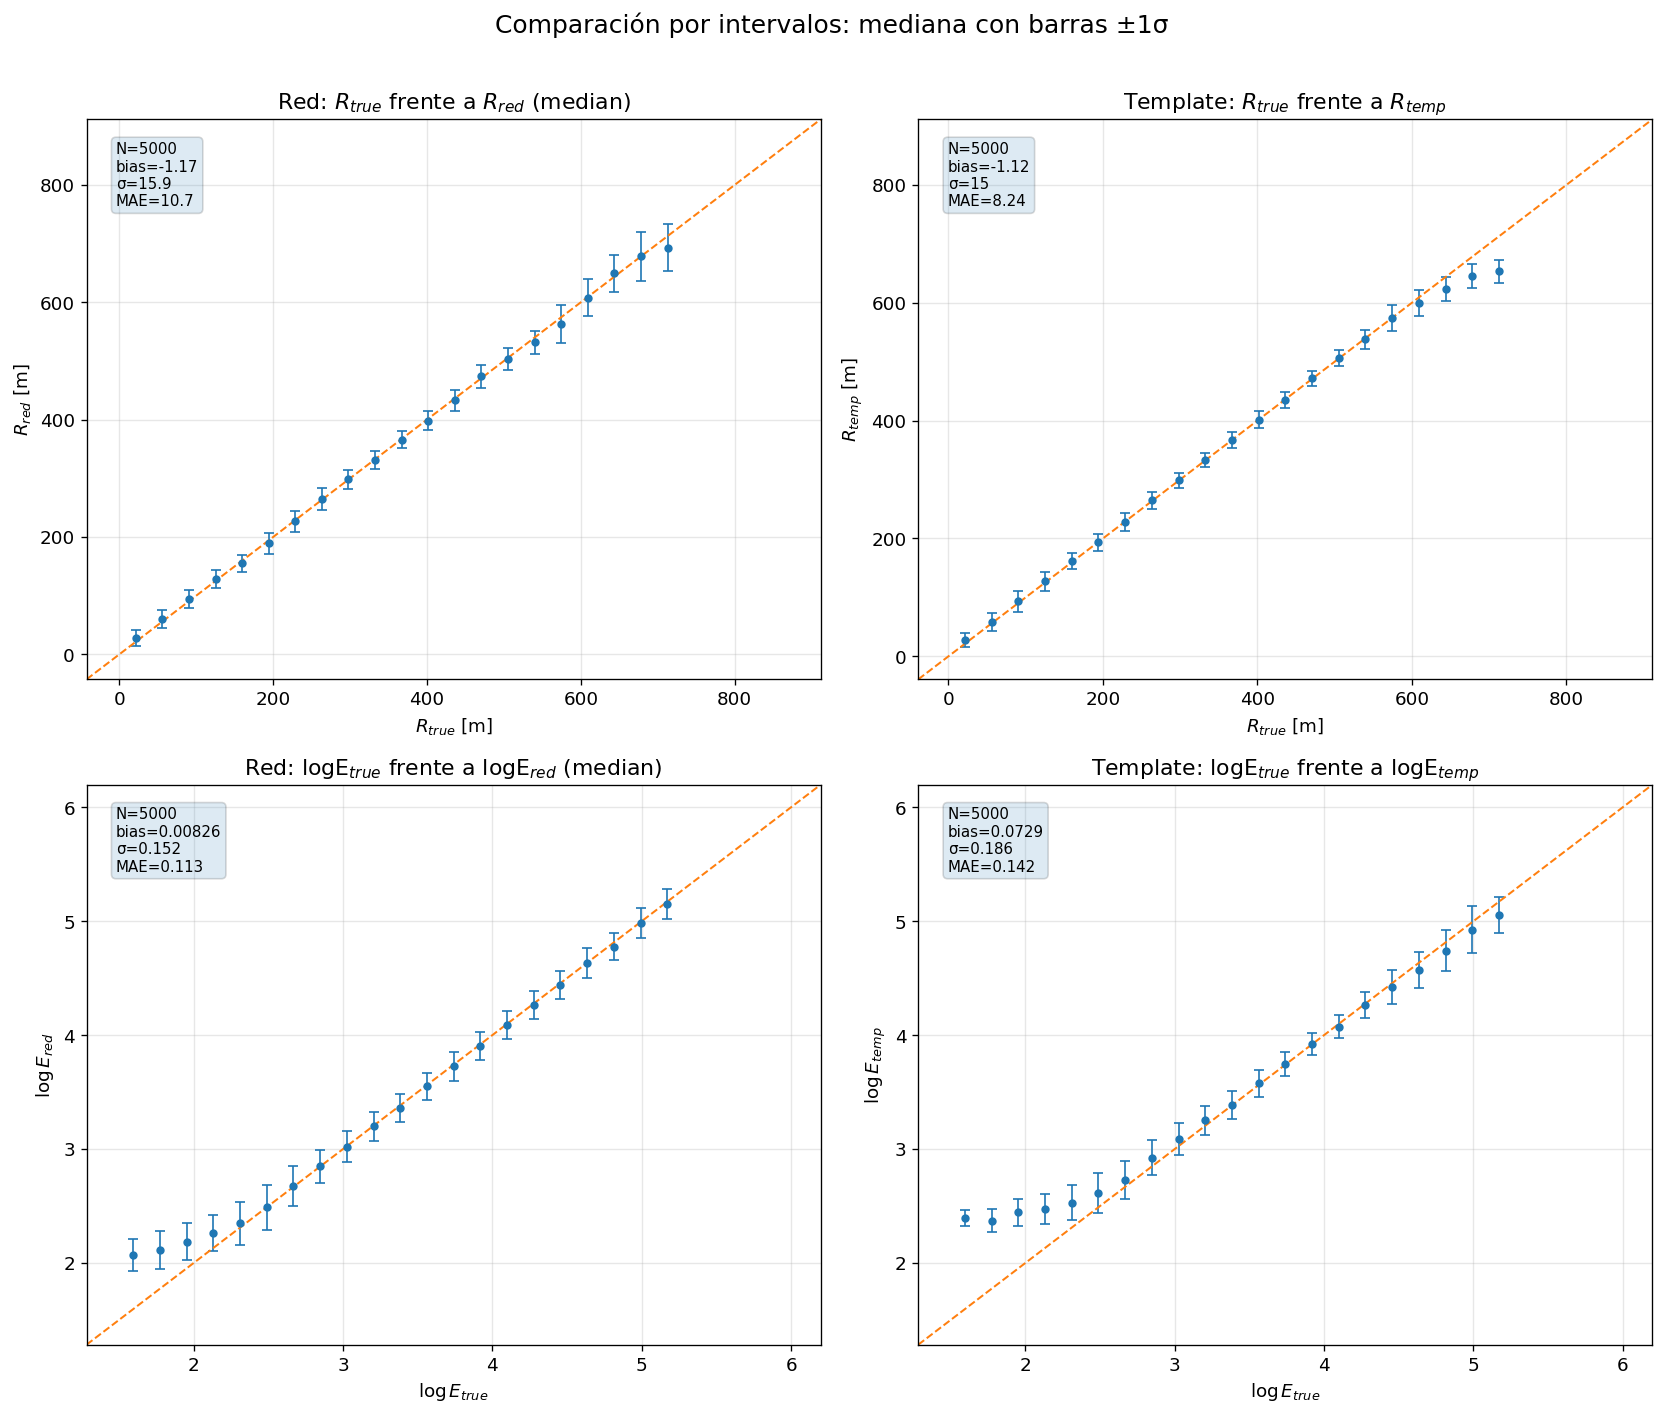


[OK] Red y template utilizan exactamente los mismos eventos.
[OK] La comparación trabaja en el espacio físico de 5 variables.
[OK] No se utiliza ningún [:, :5] silencioso.
[OK] Estas gráficas solo utilizan coreX, coreY y logEnergy.
[OK] Las barras representan ±1σ de los valores reconstruidos dentro de cada bin de la variable verdadera.


In [ ]:
#### 4 GRAFICAS: CORE Y ENERGIA | RED VS TEMPLATE ####
#### USA LOS MISMOS EVENTOS PARA RED Y TEMPLATE ####
#### MEDIANA POR INTERVALOS + BARRAS ±1σ ####

import numpy as np
import matplotlib.pyplot as plt


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

## Y_TRUE, Y_RED Y TEMPLATE_POINT DEBEN ESTAR EN EL ESPACIO FÍSICO:
##
## [
##     coreX,
##     coreY,
##     zenithAngle,
##     azimuthAngle,
##     logEnergy
## ]
##
## NO UTILIZAR TARGET_NAMES GLOBAL AQUÍ, PORQUE CONTIENE
## LOS 6 TARGETS INTERNOS DEL FLOW.

PLOT_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


EXPECTED_PLOT_DIM = len(
    PLOT_TARGET_NAMES
)


## COMPROBAR CONSISTENCIA CON LA EVALUACIÓN ##
if "PHYSICAL_TARGET_NAMES" in globals():

    if list(PHYSICAL_TARGET_NAMES) != PLOT_TARGET_NAMES:

        raise ValueError(
            "PHYSICAL_TARGET_NAMES does not match the expected "
            "physical target order.\n"
            f"Current : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Expected: {PLOT_TARGET_NAMES}"
        )


# ── SELECCIÓN DE PREDICCIÓN DE LA RED ────────────────────────────────────

if (
    "Y_PRED_MEDIAN_TEMPLATE" in globals()
    and
    Y_PRED_MEDIAN_TEMPLATE is not None
):

    Y_RED = np.asarray(
        Y_PRED_MEDIAN_TEMPLATE,
        dtype=np.float64,
    )

    PRED_KIND = "median"


elif (
    "Y_PRED_TEMPLATE" in globals()
    and
    Y_PRED_TEMPLATE is not None
):

    Y_RED = np.asarray(
        Y_PRED_TEMPLATE,
        dtype=np.float64,
    )

    PRED_KIND = "mean"


else:

    PRED_KIND = (
        "median"
        if "Y_PRED_MEDIAN" in globals()
        else "mean"
    )


    if PRED_KIND == "median":

        if "Y_PRED_MEDIAN" not in globals():

            raise RuntimeError(
                "Y_PRED_MEDIAN no existe."
            )

        Y_RED = np.asarray(
            Y_PRED_MEDIAN,
            dtype=np.float64,
        )


    else:

        if "Y_PRED" not in globals():

            raise RuntimeError(
                "Y_PRED no existe."
            )

        Y_RED = np.asarray(
            Y_PRED,
            dtype=np.float64,
        )


# ── TRUE ─────────────────────────────────────────────────────────────────

if (
    "Y_TRUE_TEMPLATE" in globals()
    and
    Y_TRUE_TEMPLATE is not None
):

    Y_TRUE_PLOT = np.asarray(
        Y_TRUE_TEMPLATE,
        dtype=np.float64,
    )


else:

    if "Y_TRUE" not in globals():

        raise RuntimeError(
            "Y_TRUE no existe. Ejecuta primero la evaluación."
        )

    Y_TRUE_PLOT = np.asarray(
        Y_TRUE,
        dtype=np.float64,
    )


# ── TEMPLATE ──────────────────────────────────────────────────────────────

if (
    "TEMPLATE_POINT" not in globals()
    or
    TEMPLATE_POINT is None
):

    raise RuntimeError(
        "TEMPLATE_POINT no está disponible. "
        "Ejecuta primero la celda que lo construye/reconstruye."
    )


Y_TEMP = np.asarray(
    TEMPLATE_POINT,
    dtype=np.float64,
)


# ── COMPROBACIÓN DE DIMENSIONES ──────────────────────────────────────────

for arr_name, arr in [
    (
        "Y_TRUE_PLOT",
        Y_TRUE_PLOT,
    ),
    (
        "Y_RED",
        Y_RED,
    ),
    (
        "Y_TEMP",
        Y_TEMP,
    ),
]:

    if arr.ndim != 2:

        raise ValueError(
            f"{arr_name} must be 2D, got shape {arr.shape}."
        )


    if arr.shape[1] != EXPECTED_PLOT_DIM:

        raise ValueError(
            f"{arr_name} has {arr.shape[1]} columns; "
            f"expected {EXPECTED_PLOT_DIM} physical targets."
        )


if Y_TRUE_PLOT.shape != Y_RED.shape:

    raise ValueError(
        f"Y_TRUE_PLOT {Y_TRUE_PLOT.shape} no coincide con "
        f"Y_RED {Y_RED.shape}"
    )


if Y_TRUE_PLOT.shape != Y_TEMP.shape:

    raise ValueError(
        f"Y_TRUE_PLOT {Y_TRUE_PLOT.shape} no coincide con "
        f"Y_TEMP {Y_TEMP.shape}"
    )


# ── COMPROBAR FINITOS SOLO EN VARIABLES QUE USAMOS ───────────────────────

ix = PLOT_TARGET_NAMES.index(
    "coreX"
)

iy = PLOT_TARGET_NAMES.index(
    "coreY"
)

ie = PLOT_TARGET_NAMES.index(
    "logEnergy"
)


for arr_name, arr in [
    (
        "Y_TRUE_PLOT",
        Y_TRUE_PLOT,
    ),
    (
        "Y_RED",
        Y_RED,
    ),
    (
        "Y_TEMP",
        Y_TEMP,
    ),
]:

    used_values = arr[
        :,
        [
            ix,
            iy,
            ie,
        ],
    ]


    if not np.all(
        np.isfinite(
            used_values
        )
    ):

        raise ValueError(
            f"{arr_name} contains non-finite values in "
            "coreX/coreY/logEnergy."
        )


print(
    f"Predicción red utilizada : {PRED_KIND}"
)

print(
    f"N eventos               : {len(Y_TRUE_PLOT)}"
)

print(
    f"Y_TRUE shape             : {Y_TRUE_PLOT.shape}"
)

print(
    f"Y_RED shape              : {Y_RED.shape}"
)

print(
    f"TEMPLATE_POINT shape     : {Y_TEMP.shape}"
)


# ── CORE RADIAL ──────────────────────────────────────────────────────────

R_true = np.sqrt(
    Y_TRUE_PLOT[
        :,
        ix,
    ] ** 2
    +
    Y_TRUE_PLOT[
        :,
        iy,
    ] ** 2
)


R_red = np.sqrt(
    Y_RED[
        :,
        ix,
    ] ** 2
    +
    Y_RED[
        :,
        iy,
    ] ** 2
)


R_temp = np.sqrt(
    Y_TEMP[
        :,
        ix,
    ] ** 2
    +
    Y_TEMP[
        :,
        iy,
    ] ** 2
)


# ── ENERGÍA ──────────────────────────────────────────────────────────────

## ESTAS VARIABLES REPRESENTAN logEnergy, NO ENERGÍA LINEAL.

logE_true = Y_TRUE_PLOT[
    :,
    ie,
]


logE_red = Y_RED[
    :,
    ie,
]


logE_temp = Y_TEMP[
    :,
    ie,
]


# ── CALCULAR MEDIANA Y DESVIACIÓN TÍPICA POR BINS ────────────────────────

def binned_median_sigma(
    x_true,
    y_rec,
    n_bins=25,
    min_count=20,
):

    x_true = np.asarray(
        x_true,
        dtype=np.float64,
    )


    y_rec = np.asarray(
        y_rec,
        dtype=np.float64,
    )


    finite = (
        np.isfinite(
            x_true
        )
        &
        np.isfinite(
            y_rec
        )
    )


    x = x_true[
        finite
    ]


    y = y_rec[
        finite
    ]


    if len(
        x
    ) == 0:

        raise ValueError(
            "No finite events available for binned plot."
        )


    edges = np.linspace(
        np.nanmin(
            x
        ),
        np.nanmax(
            x
        ),
        n_bins + 1,
    )


    centers = 0.5 * (
        edges[
            :-1
        ]
        +
        edges[
            1:
        ]
    )


    x_out = []
    y_med = []
    y_sig = []


    for bin_index, (
        lo,
        hi,
        cen,
    ) in enumerate(
        zip(
            edges[
                :-1
            ],
            edges[
                1:
            ],
            centers,
        )
    ):

        ## INCLUIR EXTREMO SUPERIOR SOLO EN EL ÚLTIMO BIN ##
        if bin_index == len(
            centers
        ) - 1:

            mask = (
                (x >= lo)
                &
                (x <= hi)
            )


        else:

            mask = (
                (x >= lo)
                &
                (x < hi)
            )


        if mask.sum() < min_count:

            continue


        values = y[
            mask
        ]


        x_out.append(
            cen
        )


        y_med.append(
            np.median(
                values
            )
        )


        y_sig.append(
            np.std(
                values,
                ddof=0,
            )
        )


    return (
        np.asarray(
            x_out,
            dtype=np.float64,
        ),
        np.asarray(
            y_med,
            dtype=np.float64,
        ),
        np.asarray(
            y_sig,
            dtype=np.float64,
        ),
    )


# ── DIBUJAR MEDIANA CON BARRAS ±1σ ──────────────────────────────────────

def plot_binned_sigma(
    ax,
    x_true,
    y_rec,
    title,
    xlabel,
    ylabel,
    n_bins=25,
    min_count=20,
):

    x_bin, y_med, y_sigma = binned_median_sigma(
        x_true,
        y_rec,
        n_bins=n_bins,
        min_count=min_count,
    )


    ax.errorbar(
        x_bin,
        y_med,
        yerr=y_sigma,
        fmt="o",
        markersize=4,
        capsize=3,
        linewidth=1,
    )


    finite = (
        np.isfinite(
            x_true
        )
        &
        np.isfinite(
            y_rec
        )
    )


    x = np.asarray(
        x_true,
        dtype=np.float64,
    )[
        finite
    ]


    y = np.asarray(
        y_rec,
        dtype=np.float64,
    )[
        finite
    ]


    lo = min(
        np.nanmin(
            x
        ),
        np.nanmin(
            y
        ),
    )


    hi = max(
        np.nanmax(
            x
        ),
        np.nanmax(
            y
        ),
    )


    pad = (
        0.05
        *
        (
            hi
            -
            lo
        )
        if hi > lo
        else 1.0
    )


    ## LÍNEA IDEAL y=x ##
    ax.plot(
        [
            lo - pad,
            hi + pad,
        ],
        [
            lo - pad,
            hi + pad,
        ],
        "--",
        linewidth=1.2,
    )


    ax.set_xlim(
        lo - pad,
        hi + pad,
    )


    ax.set_ylim(
        lo - pad,
        hi + pad,
    )


    ax.set_xlabel(
        xlabel
    )


    ax.set_ylabel(
        ylabel
    )


    ax.set_title(
        title
    )


    ax.grid(
        alpha=0.3
    )


    # ── MÉTRICAS GLOBALES ────────────────────────────────────────────────

    residual = (
        y
        -
        x
    )


    txt = (
        f"N={finite.sum()}\n"
        f"bias={np.mean(residual):.3g}\n"
        f"σ={np.std(residual):.3g}\n"
        f"MAE={np.mean(np.abs(residual)):.3g}"
    )


    ax.text(
        0.04,
        0.96,
        txt,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(
            boxstyle="round",
            alpha=0.15,
        ),
    )


# ── FIGURA FINAL ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    2,
    figsize=(
        14,
        12,
    ),
)


# ── RED: CORE RADIAL ─────────────────────────────────────────────────────

plot_binned_sigma(
    axes[
        0,
        0,
    ],
    R_true,
    R_red,
    f"Red: $R_{{true}}$ frente a $R_{{red}}$ ({PRED_KIND})",
    r"$R_{true}$ [m]",
    r"$R_{red}$ [m]",
)


# ── TEMPLATE: CORE RADIAL ────────────────────────────────────────────────

plot_binned_sigma(
    axes[
        0,
        1,
    ],
    R_true,
    R_temp,
    "Template: $R_{true}$ frente a $R_{temp}$",
    r"$R_{true}$ [m]",
    r"$R_{temp}$ [m]",
)


# ── RED: ENERGÍA ────────────────────────────────────────────────────────

plot_binned_sigma(
    axes[
        1,
        0,
    ],
    logE_true,
    logE_red,
    f"Red: logE$_{{true}}$ frente a logE$_{{red}}$ ({PRED_KIND})",
    r"$\log E_{true}$",
    r"$\log E_{red}$",
)


# ── TEMPLATE: ENERGÍA ───────────────────────────────────────────────────

plot_binned_sigma(
    axes[
        1,
        1,
    ],
    logE_true,
    logE_temp,
    "Template: logE$_{true}$ frente a logE$_{temp}$",
    r"$\log E_{true}$",
    r"$\log E_{temp}$",
)


plt.suptitle(
    "Comparación por intervalos: mediana con barras ±1σ",
    fontsize=15,
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.97,
    ]
)


plt.show()


# ── CONFIRMACIÓN FINAL ───────────────────────────────────────────────────

print()

print(
    "[OK] Red y template utilizan exactamente los mismos eventos."
)

print(
    "[OK] La comparación trabaja en el espacio físico de 5 variables."
)

print(
    "[OK] No se utiliza ningún [:, :5] silencioso."
)

print(
    "[OK] Estas gráficas solo utilizan coreX, coreY y logEnergy."
)

print(
    "[OK] Las barras representan ±1σ de los valores reconstruidos "
    "dentro de cada bin de la variable verdadera."
)

In [ ]:
# ── Scatter plots: predicted vs true ─────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt


# ── TARGETS FÍSICOS ──────────────────────────────────────────────────────

## Y_TRUE, Y_PRED, Y_PRED_MEDIAN Y Y_STD ESTÁN EN:
##
## [
##     coreX,
##     coreY,
##     zenithAngle,
##     azimuthAngle,
##     logEnergy
## ]
##
## NO UTILIZAR TARGET_NAMES GLOBAL AQUÍ, PORQUE CONTIENE
## LOS 6 TARGETS INTERNOS DEL FLOW.

PLOT_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


PLOT_TARGET_UNITS = [
    "m",
    "m",
    "rad",
    "rad",
    "log10(eV)",
]


EXPECTED_PLOT_DIM = len(
    PLOT_TARGET_NAMES
)


# ── COMPROBAR CONSISTENCIA ───────────────────────────────────────────────

if "PHYSICAL_TARGET_NAMES" in globals():

    if list(PHYSICAL_TARGET_NAMES) != PLOT_TARGET_NAMES:

        raise ValueError(
            "PHYSICAL_TARGET_NAMES does not match the expected "
            "physical target order.\n"
            f"Current : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Expected: {PLOT_TARGET_NAMES}"
        )


# ── OPCIONES DE GRÁFICA ──────────────────────────────────────────────────

## SI False, SOLO OCULTA OUTLIERS EXTREMOS EN LAS GRÁFICAS DEL CORE.
## NO MODIFICA MÉTRICAS, PREDICCIONES NI ENTRENAMIENTO.

plot_core_outliers = False


core_abs_limit_for_plot = 10_000  # meters


# ── SELECCIÓN DE PREDICCIÓN PUNTUAL ──────────────────────────────────────

PREDICTION_FOR_PLOT = (
    "median"
    if "Y_PRED_MEDIAN" in globals()
    else "mean"
)


if PREDICTION_FOR_PLOT == "median":

    Y_POINT_FOR_PLOT = np.asarray(
        Y_PRED_MEDIAN,
        dtype=np.float64,
    )


else:

    if "Y_PRED" not in globals():

        raise RuntimeError(
            "Neither Y_PRED_MEDIAN nor Y_PRED is available."
        )


    Y_POINT_FOR_PLOT = np.asarray(
        Y_PRED,
        dtype=np.float64,
    )


# ── ARRAYS DE EVALUACIÓN ─────────────────────────────────────────────────

Y_TRUE_PLOT = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


Y_STD_PLOT = np.asarray(
    Y_STD,
    dtype=np.float64,
)


# ── COMPROBAR DIMENSIONES ────────────────────────────────────────────────

for arr_name, arr in [
    (
        "Y_TRUE",
        Y_TRUE_PLOT,
    ),
    (
        "Y_POINT_FOR_PLOT",
        Y_POINT_FOR_PLOT,
    ),
    (
        "Y_STD",
        Y_STD_PLOT,
    ),
]:

    if arr.ndim != 2:

        raise ValueError(
            f"{arr_name} must be 2D, got shape {arr.shape}."
        )


    if arr.shape[1] != EXPECTED_PLOT_DIM:

        raise ValueError(
            f"{arr_name} has {arr.shape[1]} columns; "
            f"expected {EXPECTED_PLOT_DIM} physical targets."
        )


if Y_POINT_FOR_PLOT.shape != Y_TRUE_PLOT.shape:

    raise ValueError(
        f"Prediction shape {Y_POINT_FOR_PLOT.shape} does not match "
        f"Y_TRUE shape {Y_TRUE_PLOT.shape}."
    )


if Y_STD_PLOT.shape != Y_TRUE_PLOT.shape:

    raise ValueError(
        f"Y_STD shape {Y_STD_PLOT.shape} does not match "
        f"Y_TRUE shape {Y_TRUE_PLOT.shape}."
    )


# ── COMPROBAR VALORES FINITOS ────────────────────────────────────────────

if not np.all(
    np.isfinite(
        Y_TRUE_PLOT
    )
):

    raise ValueError(
        "Y_TRUE contains non-finite values."
    )


if not np.all(
    np.isfinite(
        Y_POINT_FOR_PLOT
    )
):

    raise ValueError(
        "Point predictions contain non-finite values."
    )


if not np.all(
    np.isfinite(
        Y_STD_PLOT
    )
):

    raise ValueError(
        "Y_STD contains non-finite values."
    )


# ── ÍNDICES FÍSICOS ──────────────────────────────────────────────────────

ix = PLOT_TARGET_NAMES.index(
    "coreX"
)


iy = PLOT_TARGET_NAMES.index(
    "coreY"
)


iaz = PLOT_TARGET_NAMES.index(
    "azimuthAngle"
)


# ── MÁSCARA DE PLOTTING ──────────────────────────────────────────────────

plot_mask = np.ones(
    len(
        Y_TRUE_PLOT
    ),
    dtype=bool,
)


if not plot_core_outliers:

    plot_mask &= (
        np.abs(
            Y_TRUE_PLOT[
                :,
                ix,
            ]
        )
        <=
        core_abs_limit_for_plot
    )


    plot_mask &= (
        np.abs(
            Y_TRUE_PLOT[
                :,
                iy,
            ]
        )
        <=
        core_abs_limit_for_plot
    )


    ## TAMBIÉN EVITAR QUE UNA PREDICCIÓN EXTREMA DEL CORE
    ## DEFORME COMPLETAMENTE LOS EJES DE LA FIGURA.
    ##
    ## ESTO SIGUE SIENDO SOLO UNA MÁSCARA DE VISUALIZACIÓN.

    plot_mask &= (
        np.abs(
            Y_POINT_FOR_PLOT[
                :,
                ix,
            ]
        )
        <=
        core_abs_limit_for_plot
    )


    plot_mask &= (
        np.abs(
            Y_POINT_FOR_PLOT[
                :,
                iy,
            ]
        )
        <=
        core_abs_limit_for_plot
    )


if plot_mask.sum() == 0:

    print(
        "[WARN] No events left after plot mask. "
        "Set plot_core_outliers=True or increase "
        "core_abs_limit_for_plot."
    )


    plot_mask[
        :
    ] = True


else:

    print(
        f"Plotting {plot_mask.sum()} / {len(plot_mask)} events."
    )


    if plot_mask.sum() < len(
        plot_mask
    ):

        print(
            f"Hidden only for plotting: "
            f"{len(plot_mask) - plot_mask.sum()} "
            "core-coordinate outlier events."
        )


# ── FIGURA ────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        14,
        9,
    ),
)


axes = axes.ravel()


# ── PLOT DE CADA TARGET FÍSICO ───────────────────────────────────────────

for i, (
    name,
    unit,
) in enumerate(
    zip(
        PLOT_TARGET_NAMES,
        PLOT_TARGET_UNITS,
    )
):

    ax = axes[
        i
    ]


    x = Y_TRUE_PLOT[
        plot_mask,
        i,
    ]


    y = Y_POINT_FOR_PLOT[
        plot_mask,
        i,
    ]


    yerr = Y_STD_PLOT[
        plot_mask,
        i,
    ]


    # ── SCATTER + INCERTIDUMBRE ─────────────────────────────────────────

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        alpha=0.3,
        ms=3,
        elinewidth=0.5,
        label="pred ± 1σ",
    )


    # ── LÍNEA y = x ─────────────────────────────────────────────────────

    ## PARA AZIMUT USAMOS LOS LÍMITES FÍSICOS [-pi, pi].
    ## ESTO EVITA QUE EL WRAP DE ±pi DISTORSIONE LOS EJES.

    if name == "azimuthAngle":

        lo = -np.pi

        hi = np.pi


        ax.plot(
            [
                lo,
                hi,
            ],
            [
                lo,
                hi,
            ],
            "--",
            linewidth=1.5,
            label="y=x",
        )


        ax.set_xlim(
            lo,
            hi,
        )


        ax.set_ylim(
            lo,
            hi,
        )


        ax.set_xticks(
            [
                -np.pi,
                -np.pi / 2,
                0,
                np.pi / 2,
                np.pi,
            ]
        )


        ax.set_yticks(
            [
                -np.pi,
                -np.pi / 2,
                0,
                np.pi / 2,
                np.pi,
            ]
        )


        ax.set_xticklabels(
            [
                r"$-\pi$",
                r"$-\pi/2$",
                "0",
                r"$\pi/2$",
                r"$\pi$",
            ]
        )


        ax.set_yticklabels(
            [
                r"$-\pi$",
                r"$-\pi/2$",
                "0",
                r"$\pi/2$",
                r"$\pi$",
            ]
        )


    else:

        lo = min(
            np.nanmin(
                x
            ),
            np.nanmin(
                y
            ),
        )


        hi = max(
            np.nanmax(
                x
            ),
            np.nanmax(
                y
            ),
        )


        if (
            np.isfinite(
                lo
            )
            and
            np.isfinite(
                hi
            )
            and
            hi > lo
        ):

            pad = (
                0.05
                *
                (
                    hi
                    -
                    lo
                )
            )


            ax.plot(
                [
                    lo,
                    hi,
                ],
                [
                    lo,
                    hi,
                ],
                "--",
                linewidth=1.5,
                label="y=x",
            )


            ax.set_xlim(
                lo - pad,
                hi + pad,
            )


            ax.set_ylim(
                lo - pad,
                hi + pad,
            )


    # ── ETIQUETAS ────────────────────────────────────────────────────────

    ax.set_xlabel(
        f"True {name} ({unit})"
    )


    ax.set_ylabel(
        f"Predicted {name} ({unit})"
    )


    ax.set_title(
        name
    )


    ax.legend(
        fontsize=8
    )


    ax.grid(
        True,
        alpha=0.3,
    )


# ── ELIMINAR SEXTO PANEL VACÍO ───────────────────────────────────────────

axes[
    5
].axis(
    "off"
)


# ── TÍTULO FINAL ─────────────────────────────────────────────────────────

plt.suptitle(
    f"Predicted vs. True – Test Set "
    f"(posterior {PREDICTION_FOR_PLOT})",
    fontsize=14,
)


plt.tight_layout()


plt.show()


# ── CONFIRMACIÓN ─────────────────────────────────────────────────────────

print()

print(
    "[OK] Scatter plots use the 5 physical reconstruction targets."
)

print(
    "[OK] Internal 6D trig targets are not used for plotting."
)

print(
    "[OK] Azimuth axes are shown in the physical range [-π, π]."
)

print(
    "[OK] Core outlier masking affects visualization only."
)

ValueError: Y_STD contains non-finite values.

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/01_training_validation_loss.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/01_training_validation_loss.pdf


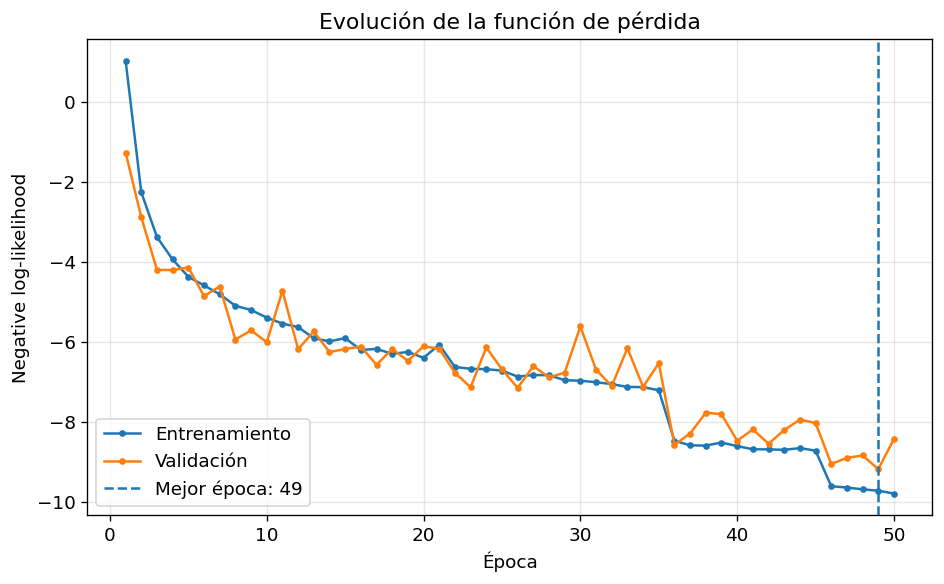

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_coreX.pdf


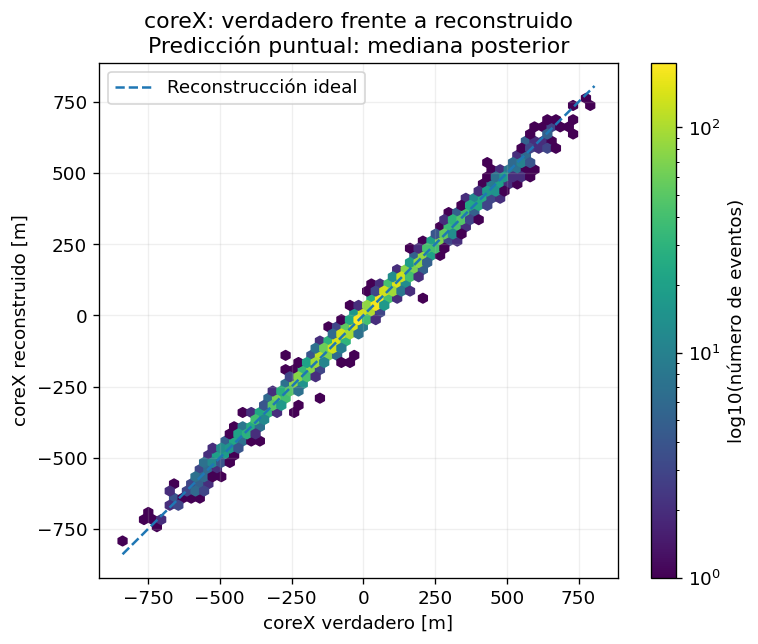

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_coreY.pdf


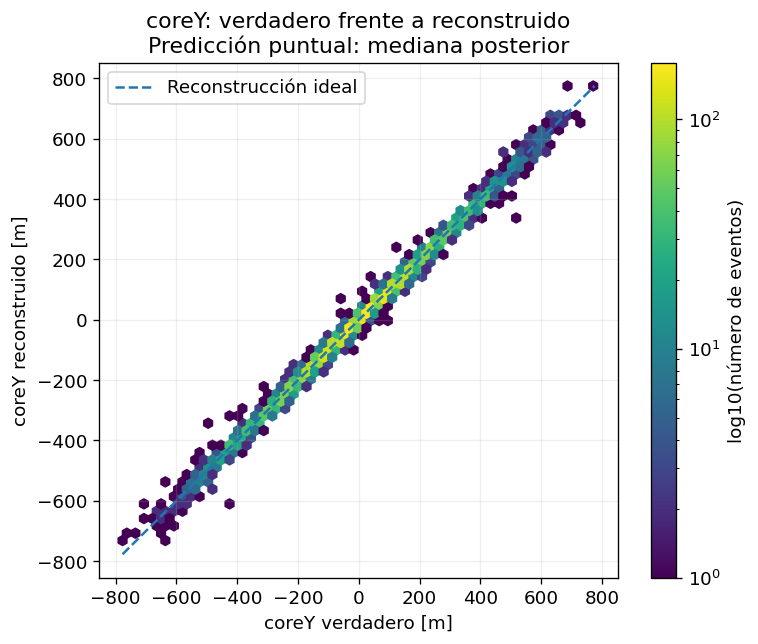

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_zenithAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_zenithAngle.pdf


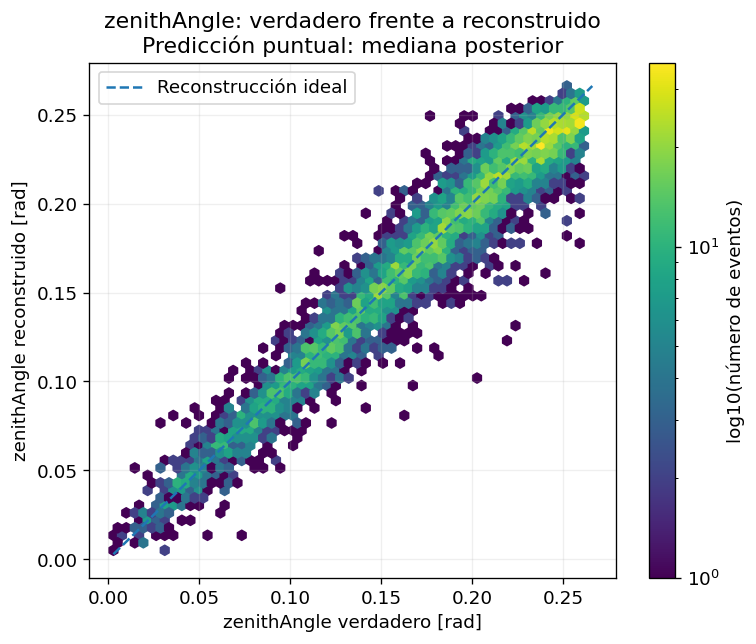

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_azimuthAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_azimuthAngle.pdf


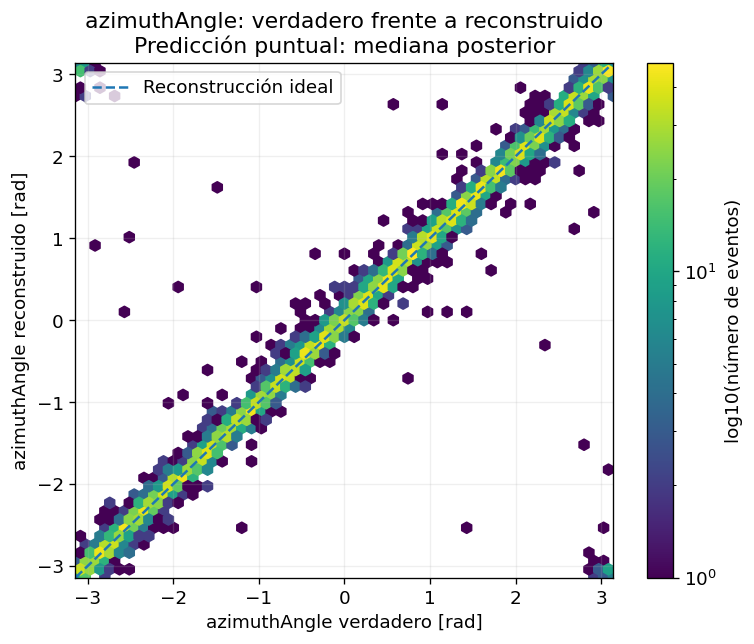

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/02_true_vs_pred_logEnergy.pdf


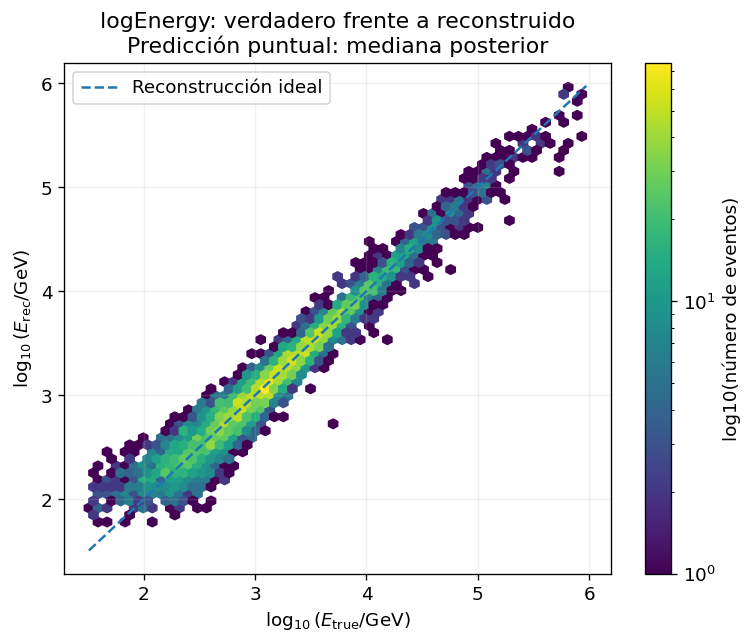

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_coreX.pdf


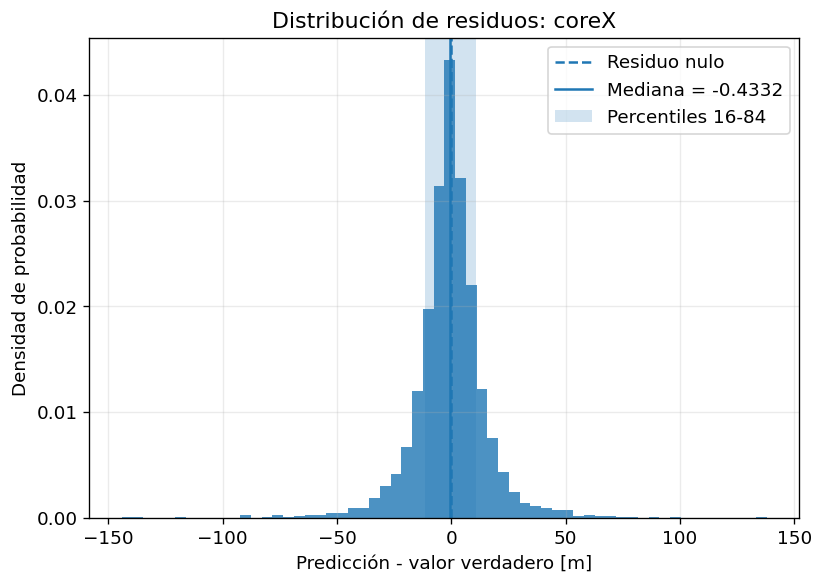

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_coreY.pdf


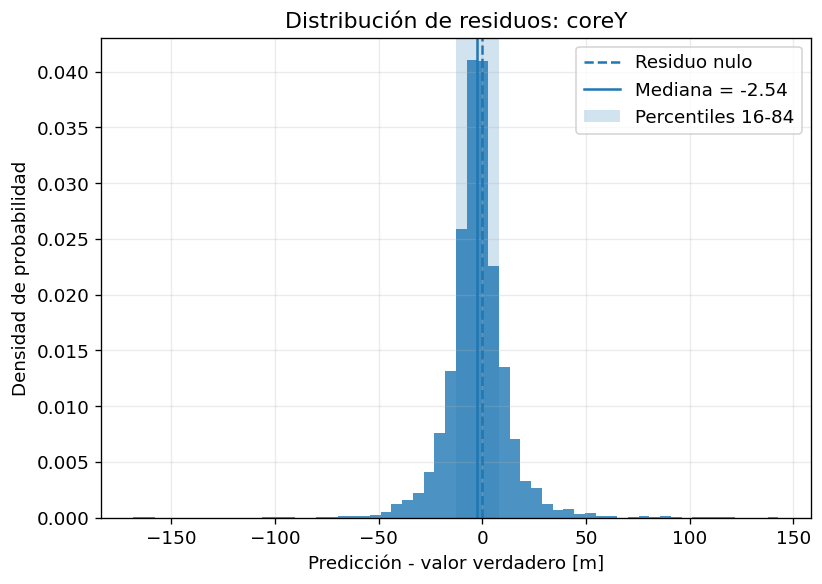

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_zenithAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_zenithAngle.pdf


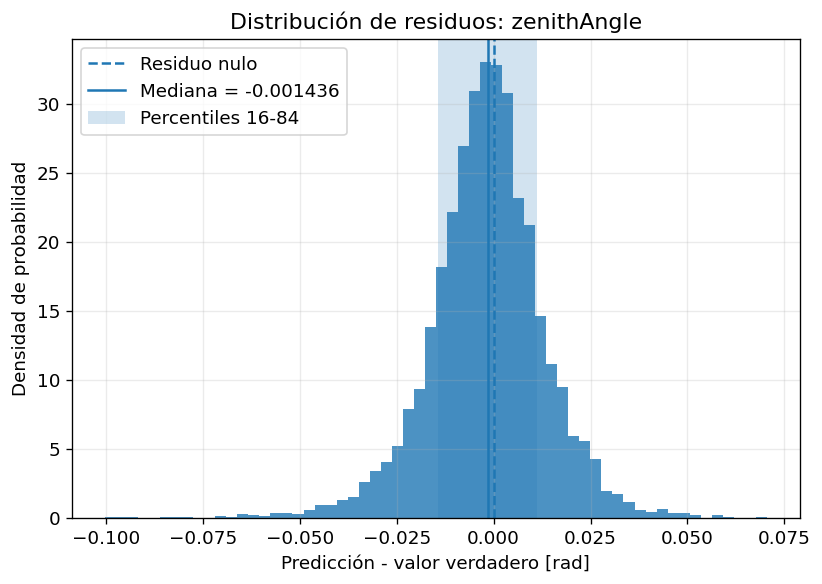

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_azimuthAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_azimuthAngle.pdf


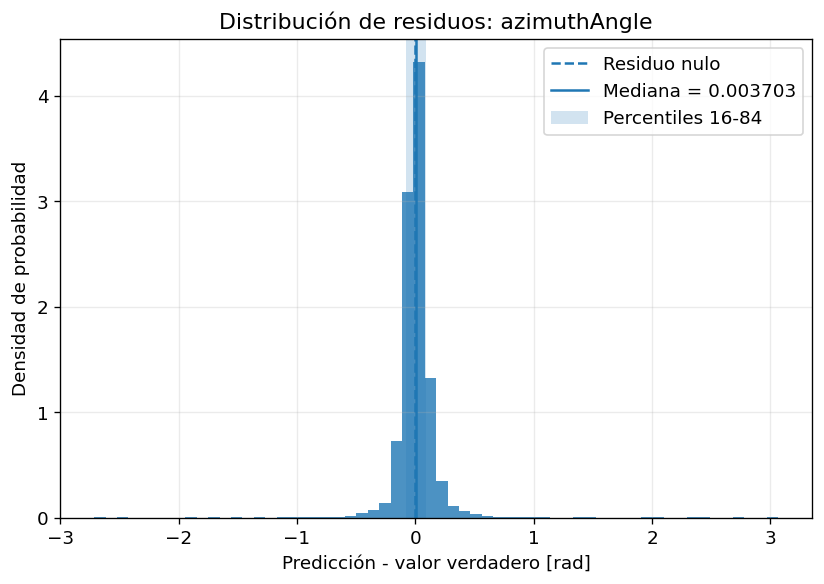

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/03_residual_logEnergy.pdf


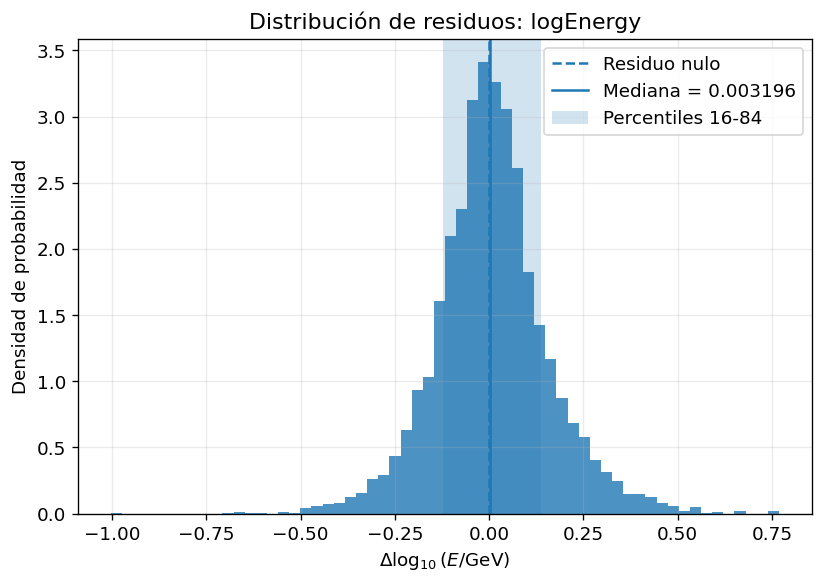

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/04_core_resolution_vs_energy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/04_core_resolution_vs_energy.pdf


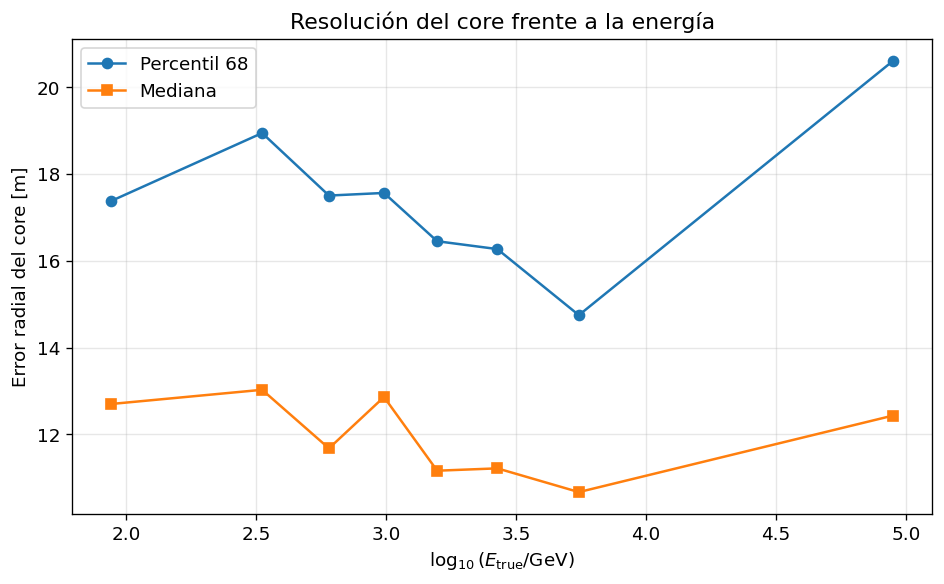

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/05_angular_resolution_vs_energy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/05_angular_resolution_vs_energy.pdf


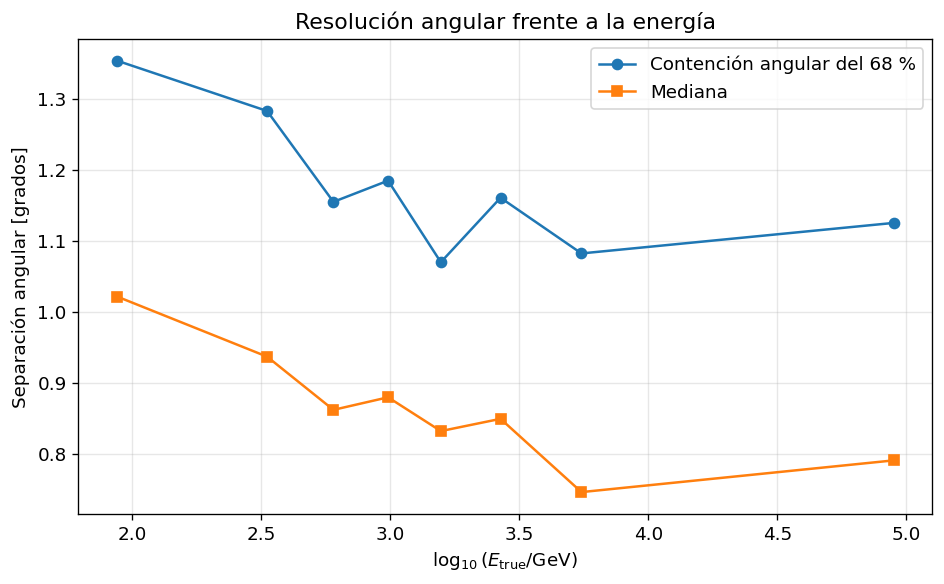

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/06_energy_bias_vs_energy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/06_energy_bias_vs_energy.pdf


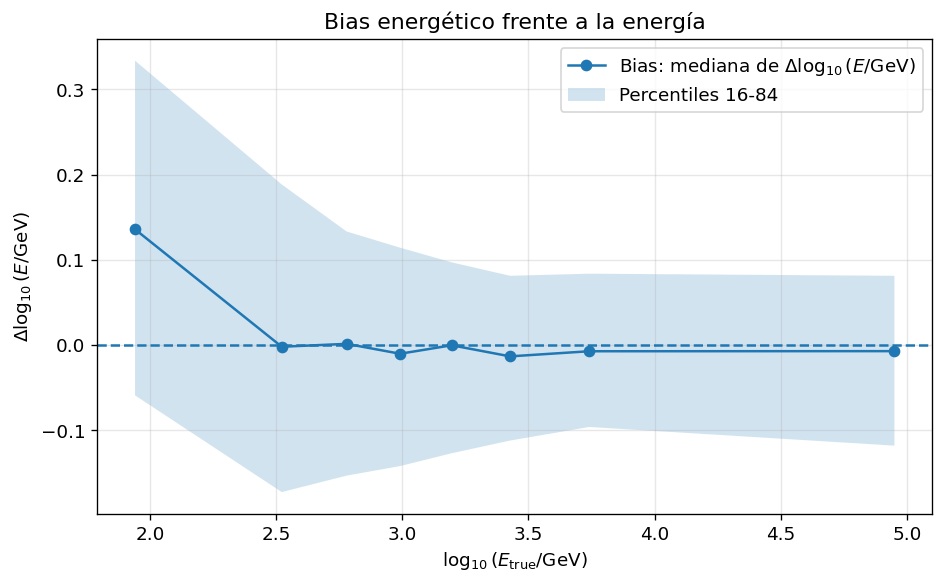

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/07_energy_resolution_vs_energy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/07_energy_resolution_vs_energy.pdf


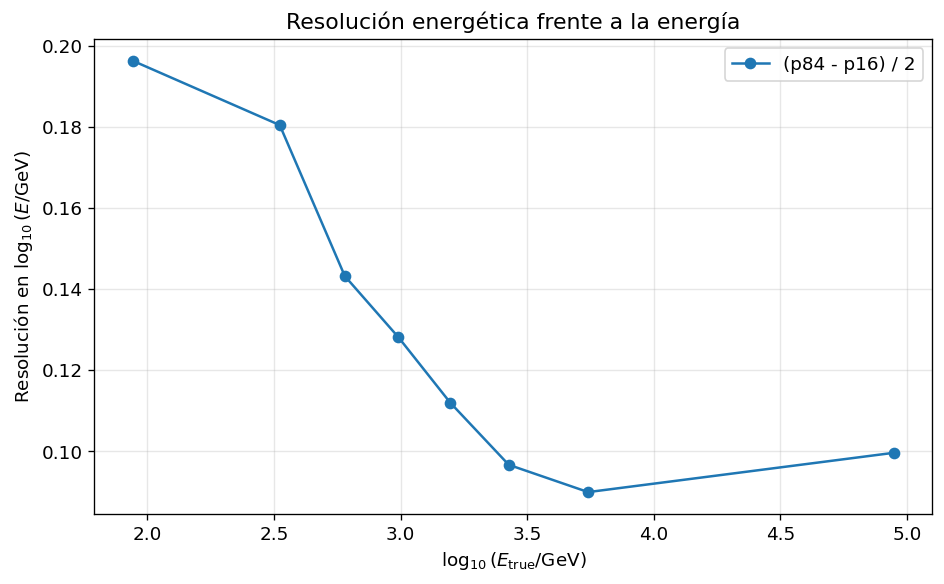

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_coreX.pdf


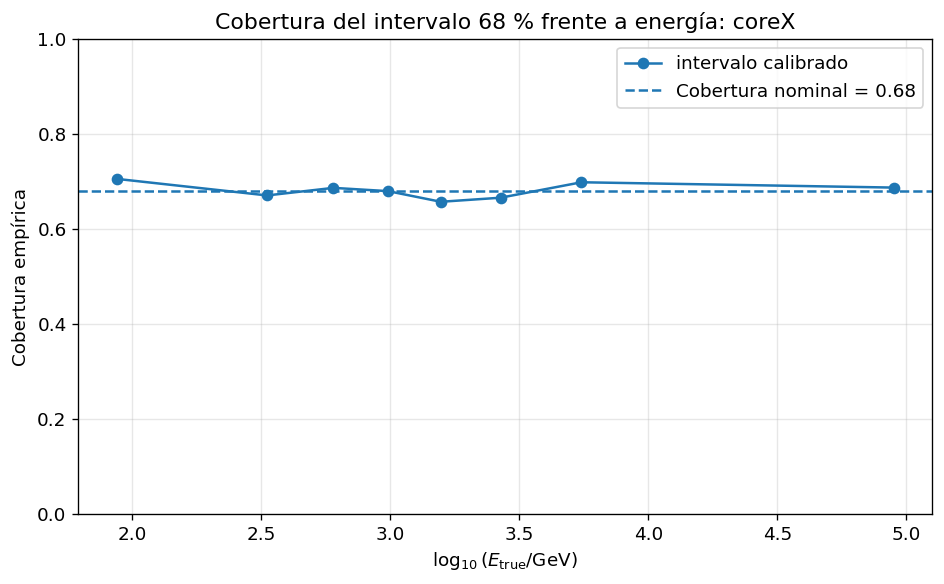

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_coreY.pdf


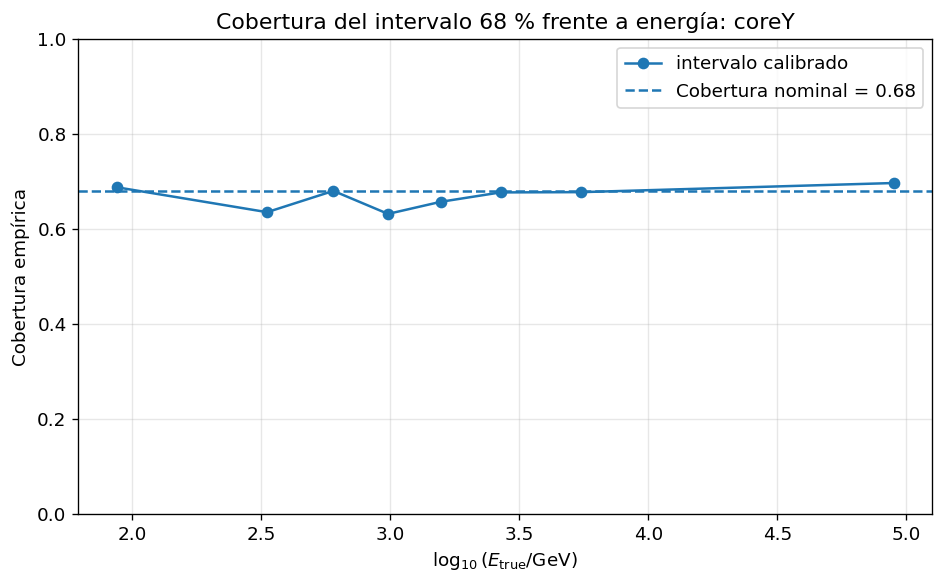

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_zenithAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_zenithAngle.pdf


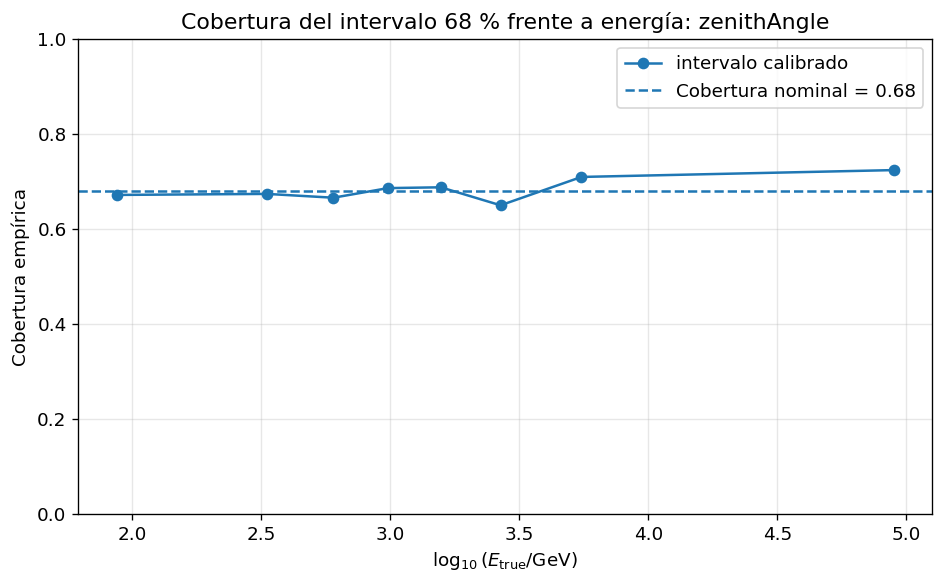

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/08_coverage_vs_energy_logEnergy.pdf


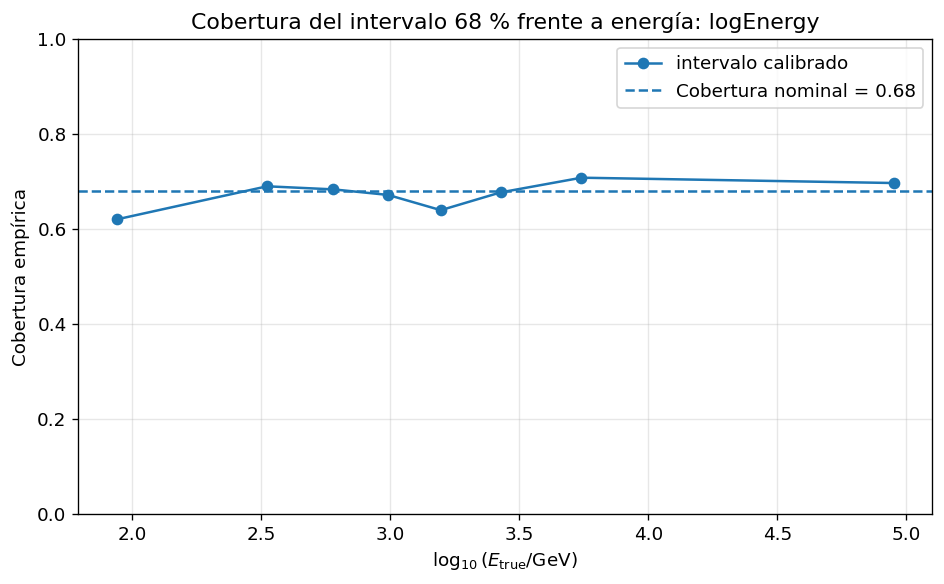


Generando muestras para las curvas de calibración...
[INFO] Validation se utiliza para ajustar los factores.
[INFO] Test se utiliza únicamente para comprobar la cobertura.


Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:208: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_coreX.pdf


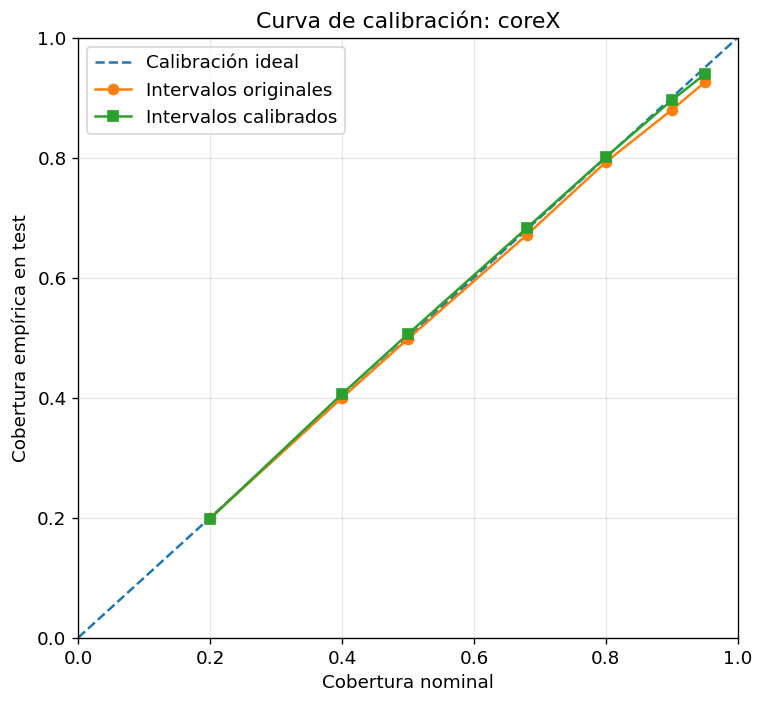

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_coreY.pdf


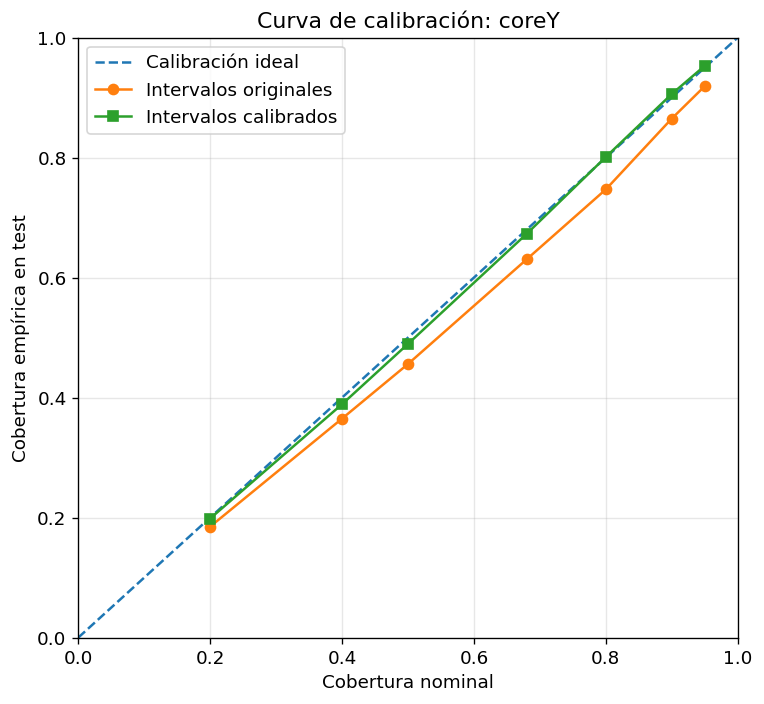

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_zenithAngle.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_zenithAngle.pdf


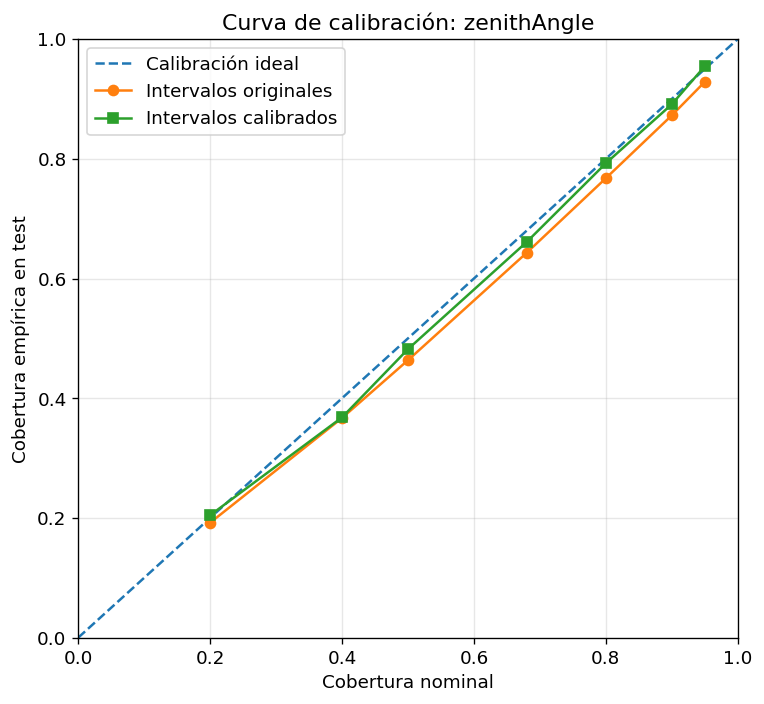

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/09_calibration_curve_logEnergy.pdf


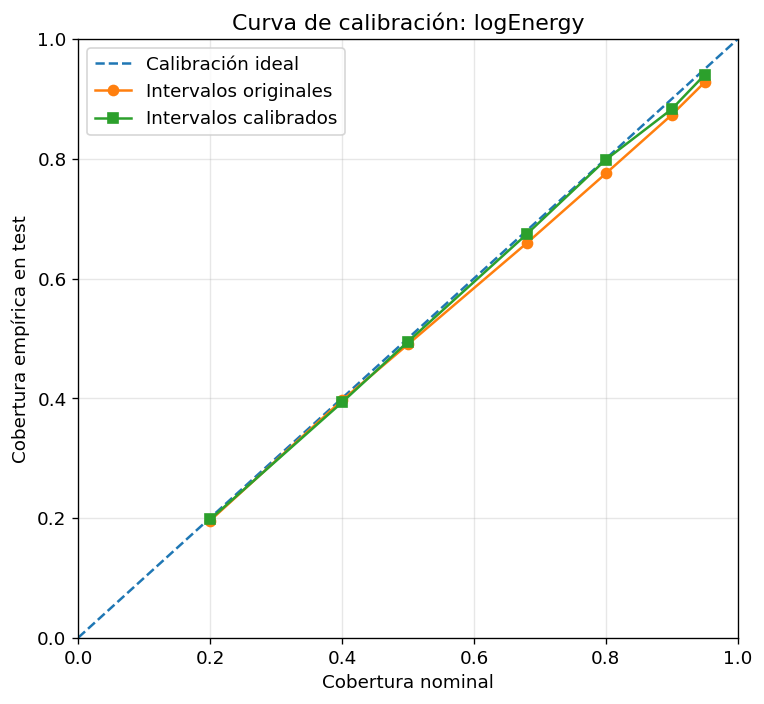

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/calibration_curve_values.csv


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/10_event_1_posterior_marginals.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/10_event_1_posterior_marginals.pdf


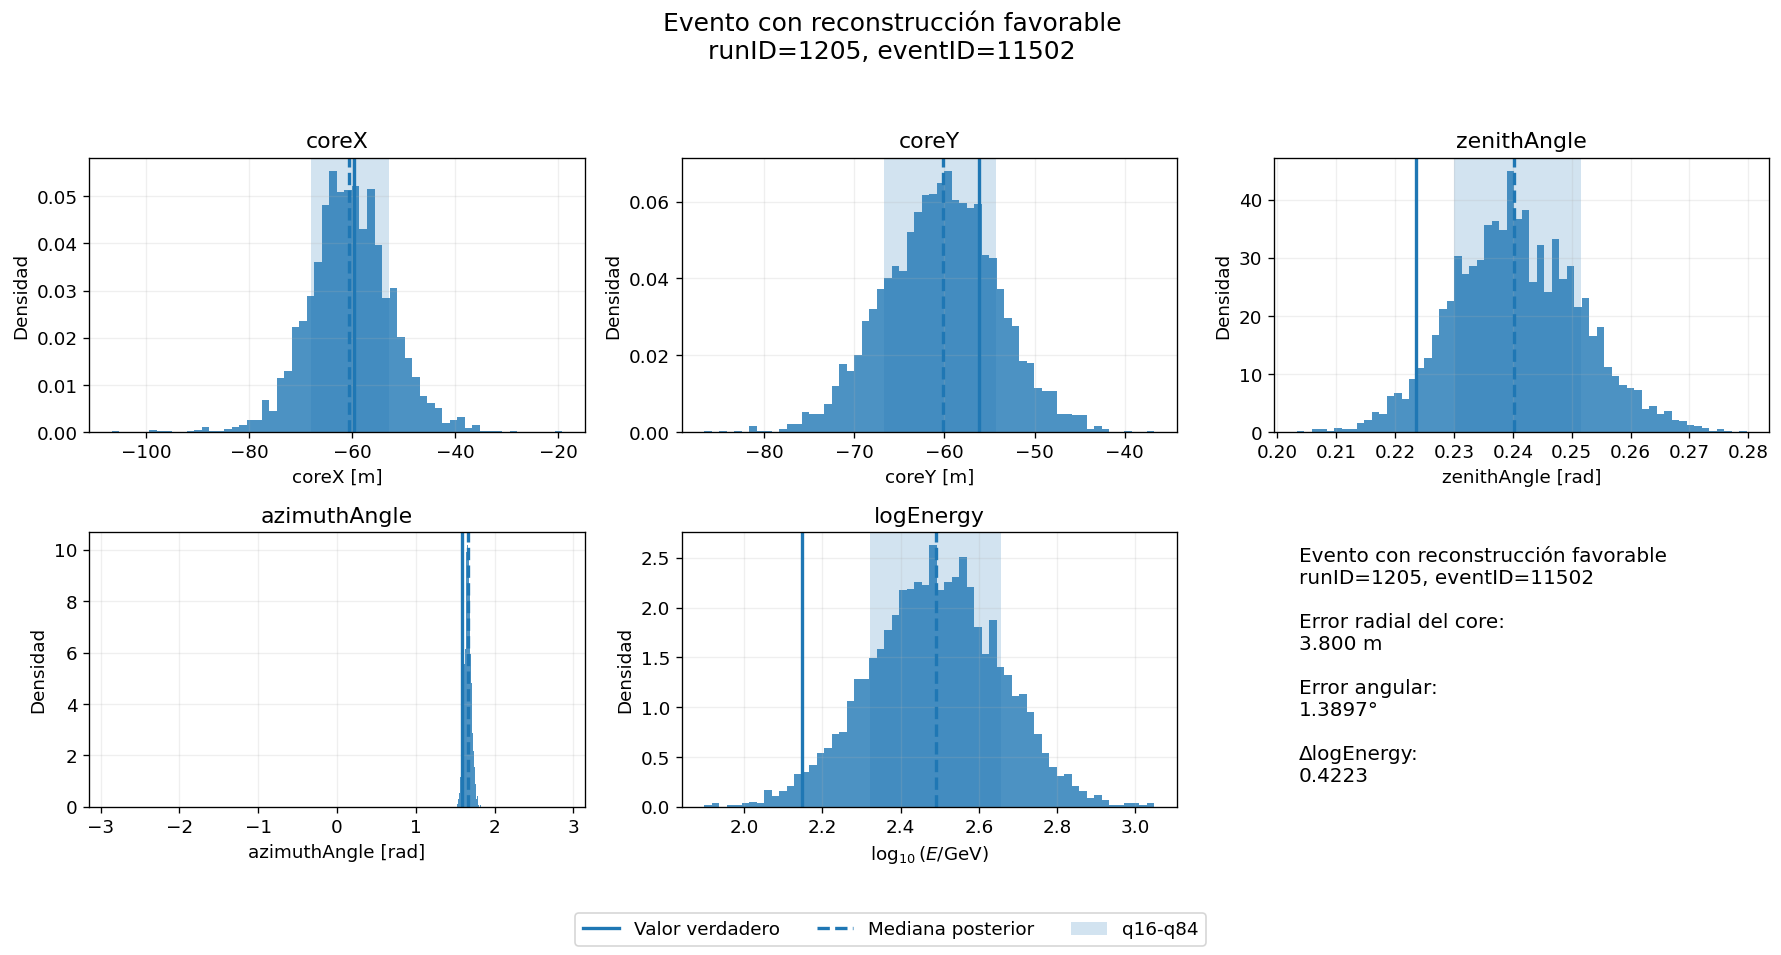

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/10_event_2_posterior_marginals.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/10_event_2_posterior_marginals.pdf


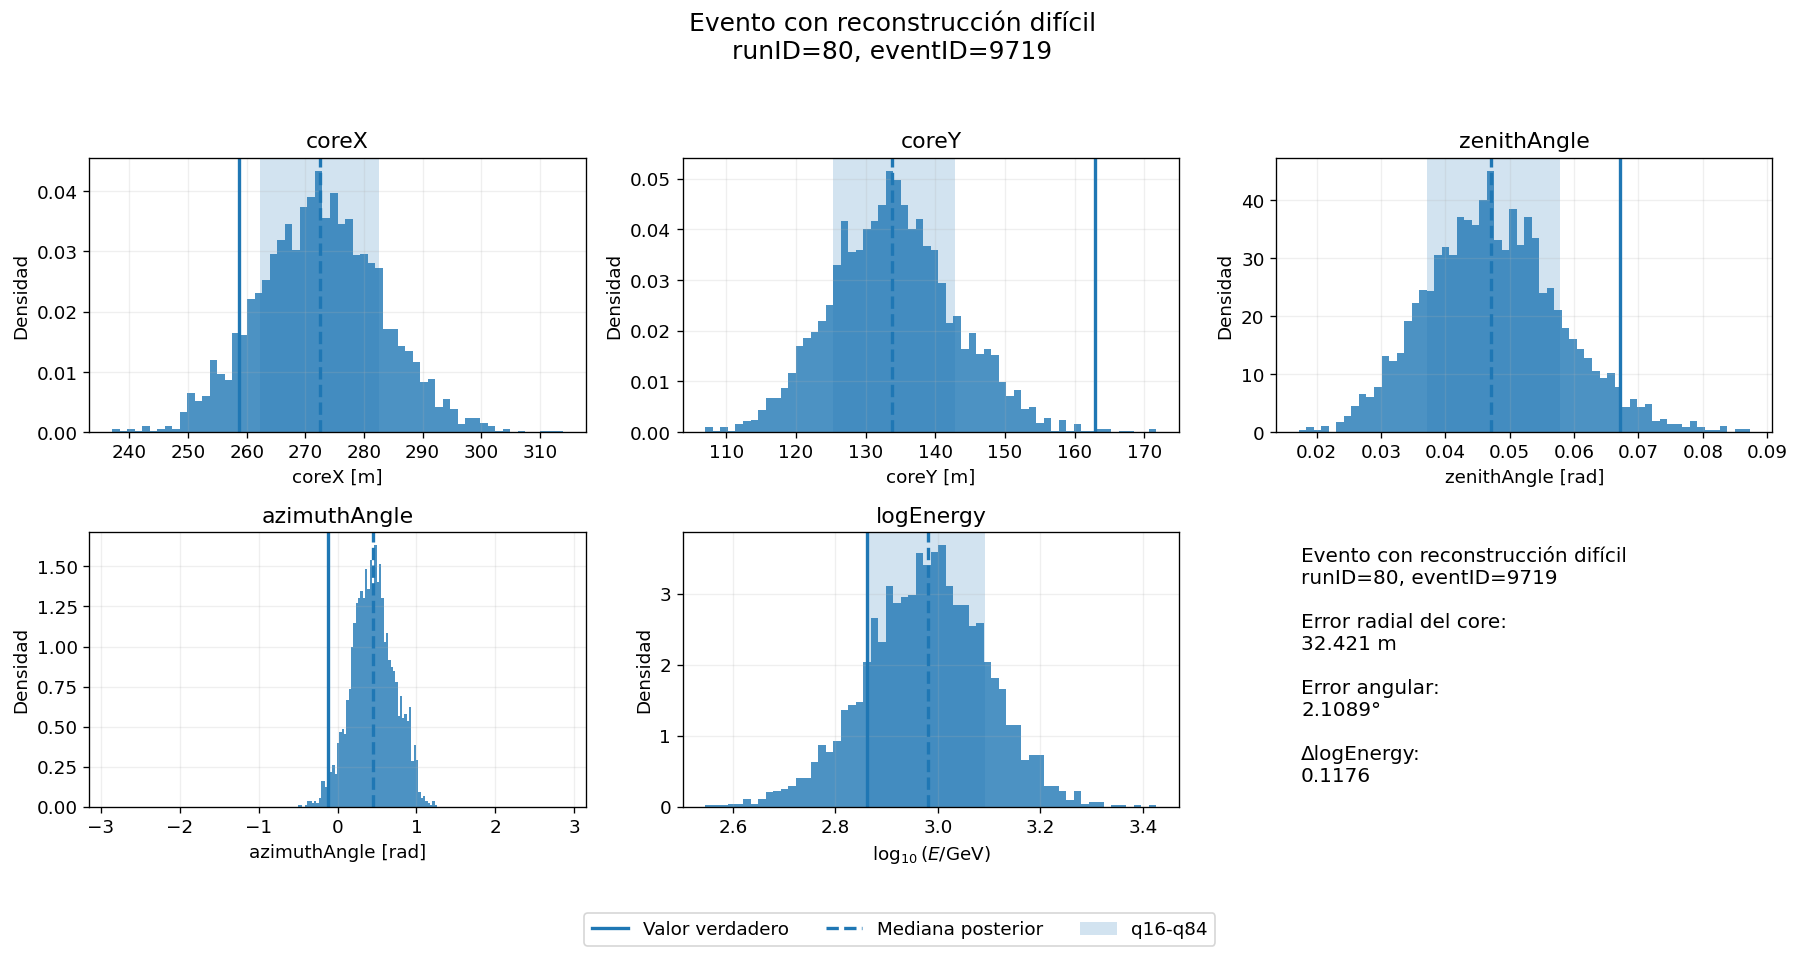

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/11_event_1_core_posterior.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/11_event_1_core_posterior.pdf


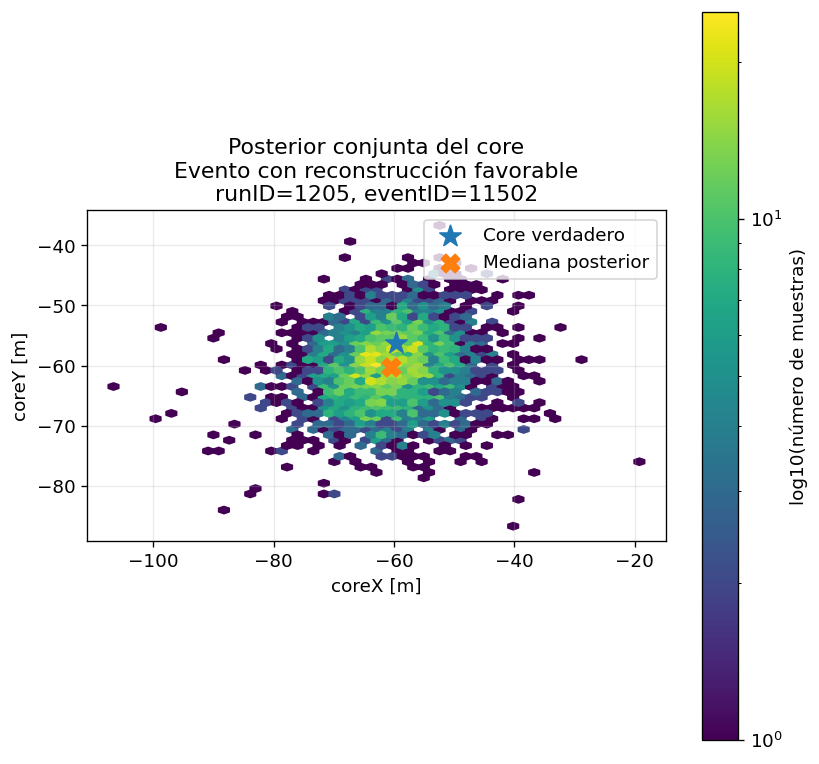

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/11_event_2_core_posterior.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures/11_event_2_core_posterior.pdf


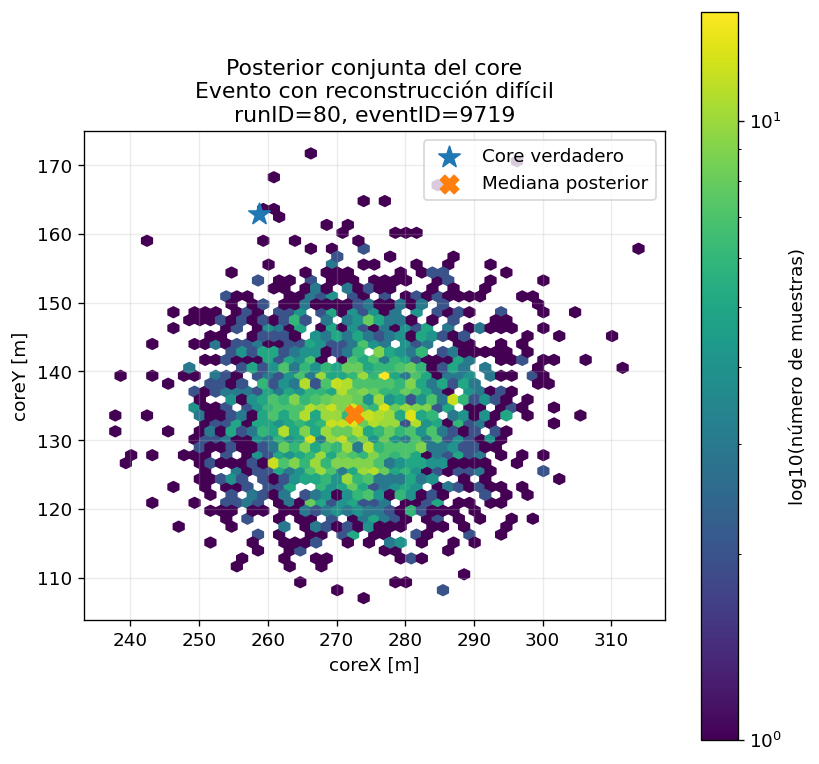


Resumen de los dos eventos representativos:


,event_type,test_local_index,core_radial_error_m,angular_error_deg,delta_logEnergy,true_logEnergy,pred_logEnergy
0,Evento con reconstrucción favorable,424,3.800245,1.389686,0.422251,2.147,2.569252
1,Evento con reconstrucción difícil,2225,32.421341,2.108948,0.117581,2.861,2.978581



[saved] Resultados y figuras en: /content/gdrive/MyDrive/TFM/gamma_flow_outputs/final_figures

Gráficas finales generadas correctamente.
Predicción puntual utilizada: mediana posterior.
Intervalos utilizados: intervalo calibrado.
[OK] Todas las gráficas utilizan los 5 targets físicos.
[OK] Los 6 targets trigonométricos internos del Flow no se mezclan con los arrays físicos.
[OK] El residuo de azimuthAngle se calcula circularmente.
[OK] La resolución angular utiliza separación esférica deltaPsi.
[OK] AzimuthAngle queda excluido de la calibración lineal.
[OK] La energía se representa como log10(E / GeV).
[OK] No se ha aplicado clipping artificial al zenith reconstruido.


In [ ]:
# ── Gráficas finales del modelo DeepSets + Normalizing Flow ──────────────
#
# ESTE BLOQUE GENERA:
#
# 1. Curvas de entrenamiento y validación.
# 2. Valor reconstruido frente al valor verdadero para cada target físico.
# 3. Distribuciones de residuos.
# 4. Resolución del core frente a energía.
# 5. Resolución angular frente a energía.
# 6. Bias y resolución energética frente a energía.
# 7. Cobertura de los intervalos frente a energía.
# 8. Curvas de calibración de incertidumbres.
# 9. Distribuciones posteriores de dos eventos:
#       - un evento bien reconstruido;
#       - un evento difícil.
# 10. Distribución posterior conjunta coreX-coreY para esos dos eventos.
#
# El código no vuelve a entrenar el modelo.
#
# IMPORTANTE:
#
# El Flow trabaja internamente con 6 targets:
#
#     coreX
#     coreY
#     sinZenith
#     sinAzimuth
#     cosAzimuth
#     logEnergy
#
# Pero evaluate_on_loader convierte las predicciones al espacio físico:
#
#     coreX
#     coreY
#     zenithAngle
#     azimuthAngle
#     logEnergy
#
# Por tanto, TODAS las gráficas de este bloque trabajan exclusivamente
# con los 5 targets físicos.
#
# La energía se representa mediante:
#
#     logEnergy = log10(E / GeV)
#
# Para las gráficas globales utiliza:
#
#     Y_TRUE
#     Y_PRED_MEDIAN o Y_PRED
#     Y_STD
#     Y_Q16
#     Y_Q84
#
# Si existen:
#
#     Y_Q16_CALIBRATED
#     Y_Q84_CALIBRATED
#
# se utilizan como intervalos finales calibrados.
#
# Para la curva de calibración completa se vuelven a generar muestras
# posteriores únicamente sobre subconjuntos limitados de validation y test.
# Esto evita guardar muestras para todos los eventos y controla la memoria.


import math
import warnings
from pathlib import Path
from typing import Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch.utils.data import DataLoader, Subset


# ── Targets físicos utilizados en TODAS las gráficas ─────────────────────

FINAL_TARGET_NAMES = [
    'coreX',
    'coreY',
    'zenithAngle',
    'azimuthAngle',
    'logEnergy',
]


FINAL_TARGET_UNITS = [
    'm',
    'm',
    'rad',
    'rad',
    'log10(E / GeV)',
]


EXPECTED_FINAL_TARGET_DIM = len(
    FINAL_TARGET_NAMES
)


## COMPROBAR CONSISTENCIA CON LOS TARGETS FÍSICOS DE EVALUACIÓN ##
if 'PHYSICAL_TARGET_NAMES' in globals():

    if list(PHYSICAL_TARGET_NAMES) != FINAL_TARGET_NAMES:

        raise ValueError(
            'PHYSICAL_TARGET_NAMES no coincide con el orden físico '
            'esperado.\n'
            f'Actual   : {list(PHYSICAL_TARGET_NAMES)}\n'
            f'Esperado : {FINAL_TARGET_NAMES}'
        )


# ── Configuración general de las figuras ─────────────────────────────────

FINAL_PLOTS_DPI = CFG.get(
    'final_plots_dpi',
    150,
)


FINAL_N_ENERGY_BINS = CFG.get(
    'final_n_energy_bins',
    8,
)


FINAL_RESIDUAL_BINS = CFG.get(
    'final_residual_bins',
    60,
)


CALIBRATION_CURVE_MAX_EVENTS = CFG.get(
    'calibration_curve_max_events',
    2000,
)


CALIBRATION_CURVE_N_SAMPLES = CFG.get(
    'calibration_curve_n_samples',
    200,
)


CALIBRATION_CURVE_SAMPLE_CHUNK = CFG.get(
    'calibration_curve_sample_chunk',
    20,
)


POSTERIOR_EVENT_N_SAMPLES = CFG.get(
    'posterior_event_n_samples',
    3000,
)


POSTERIOR_EVENT_SAMPLE_CHUNK = CFG.get(
    'posterior_event_sample_chunk',
    100,
)


CALIBRATION_LEVELS = np.array(
    [
        0.20,
        0.40,
        0.50,
        0.68,
        0.80,
        0.90,
        0.95,
    ],
    dtype=np.float64,
)


# ── Targets calibrables linealmente ──────────────────────────────────────

## AZIMUTH SE EXCLUYE POR SER CIRCULAR.
##
## Sus intervalos no deben tratarse mediante:
##
##     low <= true <= high
##
## porque pueden cruzar ±pi.

LINEAR_CALIBRATION_TARGETS = [
    'coreX',
    'coreY',
    'zenithAngle',
    'logEnergy',
]


# ── Seleccionar predicción puntual ────────────────────────────────────────

if (
    'Y_PRED_MEDIAN' in globals()
    and
    Y_PRED_MEDIAN is not None
):

    Y_POINT_FINAL = np.asarray(
        Y_PRED_MEDIAN,
        dtype=np.float64,
    )

    FINAL_POINT_LABEL = 'mediana posterior'


else:

    if 'Y_PRED' not in globals():

        raise RuntimeError(
            'No existen Y_PRED_MEDIAN ni Y_PRED.'
        )

    Y_POINT_FINAL = np.asarray(
        Y_PRED,
        dtype=np.float64,
    )

    FINAL_POINT_LABEL = 'media posterior'


# ── Arrays principales ────────────────────────────────────────────────────

Y_TRUE_FINAL = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


Y_STD_FINAL = np.asarray(
    Y_STD,
    dtype=np.float64,
)


Y_Q16_ORIGINAL = np.asarray(
    Y_Q16,
    dtype=np.float64,
)


Y_Q84_ORIGINAL = np.asarray(
    Y_Q84,
    dtype=np.float64,
)


# ── Utilizar intervalos calibrados si existen ────────────────────────────

if (
    'Y_Q16_CALIBRATED' in globals()
    and
    'Y_Q84_CALIBRATED' in globals()
    and
    Y_Q16_CALIBRATED is not None
    and
    Y_Q84_CALIBRATED is not None
):

    Y_Q16_FINAL = np.asarray(
        Y_Q16_CALIBRATED,
        dtype=np.float64,
    )

    Y_Q84_FINAL = np.asarray(
        Y_Q84_CALIBRATED,
        dtype=np.float64,
    )

    FINAL_INTERVAL_LABEL = 'intervalo calibrado'


else:

    Y_Q16_FINAL = Y_Q16_ORIGINAL.copy()
    Y_Q84_FINAL = Y_Q84_ORIGINAL.copy()

    FINAL_INTERVAL_LABEL = 'intervalo original'


# ── Comprobar dimensiones ─────────────────────────────────────────────────

for array_name, array_value in [
    (
        'Y_TRUE_FINAL',
        Y_TRUE_FINAL,
    ),
    (
        'Y_POINT_FINAL',
        Y_POINT_FINAL,
    ),
    (
        'Y_STD_FINAL',
        Y_STD_FINAL,
    ),
    (
        'Y_Q16_FINAL',
        Y_Q16_FINAL,
    ),
    (
        'Y_Q84_FINAL',
        Y_Q84_FINAL,
    ),
]:

    if array_value.ndim != 2:

        raise ValueError(
            f'{array_name} debe ser bidimensional y tiene '
            f'forma {array_value.shape}.'
        )


    if array_value.shape[1] != EXPECTED_FINAL_TARGET_DIM:

        raise ValueError(
            f'{array_name} tiene {array_value.shape[1]} columnas; '
            f'se esperaban {EXPECTED_FINAL_TARGET_DIM} targets físicos.'
        )


# ── Comprobar mismo número de eventos ────────────────────────────────────

n_final_events = len(
    Y_TRUE_FINAL
)


for array_name, array_value in [
    (
        'Y_POINT_FINAL',
        Y_POINT_FINAL,
    ),
    (
        'Y_STD_FINAL',
        Y_STD_FINAL,
    ),
    (
        'Y_Q16_FINAL',
        Y_Q16_FINAL,
    ),
    (
        'Y_Q84_FINAL',
        Y_Q84_FINAL,
    ),
]:

    if len(array_value) != n_final_events:

        raise ValueError(
            f'{array_name} contiene {len(array_value)} eventos, '
            f'pero Y_TRUE_FINAL contiene {n_final_events}.'
        )


# ── Directorio de figuras ─────────────────────────────────────────────────

if 'artifact_path' in globals():

    FINAL_FIGURE_DIR = Path(
        artifact_path(
            'final_figures',
            run_specific=False,
        )
    )


else:

    FINAL_FIGURE_DIR = Path(
        'final_figures'
    )


FINAL_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ── Función de guardado ──────────────────────────────────────────────────

def save_final_figure(
    fig: plt.Figure,
    filename: str,
) -> None:

    if not CFG.get(
        'save_artifacts',
        True,
    ):

        return


    png_path = (
        FINAL_FIGURE_DIR
        /
        f'{filename}.png'
    )


    pdf_path = (
        FINAL_FIGURE_DIR
        /
        f'{filename}.pdf'
    )


    fig.savefig(
        png_path,
        dpi=FINAL_PLOTS_DPI,
        bbox_inches='tight',
    )


    fig.savefig(
        pdf_path,
        bbox_inches='tight',
    )


    print(
        f'[saved] {png_path}'
    )

    print(
        f'[saved] {pdf_path}'
    )


# ── Eliminar pares no finitos ────────────────────────────────────────────

def finite_xy(
    x: np.ndarray,
    y: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:

    x = np.asarray(
        x,
        dtype=np.float64,
    )


    y = np.asarray(
        y,
        dtype=np.float64,
    )


    mask = (
        np.isfinite(x)
        &
        np.isfinite(y)
    )


    return (
        x[mask],
        y[mask],
    )


# ── Separación angular esférica ──────────────────────────────────────────

def angular_separation(
    true_zenith: np.ndarray,
    true_azimuth: np.ndarray,
    pred_zenith: np.ndarray,
    pred_azimuth: np.ndarray,
) -> np.ndarray:

    true_zenith = np.asarray(
        true_zenith,
        dtype=np.float64,
    )


    true_azimuth = np.asarray(
        true_azimuth,
        dtype=np.float64,
    )


    pred_zenith = np.asarray(
        pred_zenith,
        dtype=np.float64,
    )


    pred_azimuth = np.asarray(
        pred_azimuth,
        dtype=np.float64,
    )


    delta_phi = np.arctan2(
        np.sin(
            pred_azimuth
            -
            true_azimuth
        ),
        np.cos(
            pred_azimuth
            -
            true_azimuth
        ),
    )


    cos_angle = (
        np.cos(
            true_zenith
        )
        *
        np.cos(
            pred_zenith
        )
        +
        np.sin(
            true_zenith
        )
        *
        np.sin(
            pred_zenith
        )
        *
        np.cos(
            delta_phi
        )
    )


    cos_angle = np.clip(
        cos_angle,
        -1.0,
        1.0,
    )


    return np.arccos(
        cos_angle
    )


# ── Bins equipoblados ────────────────────────────────────────────────────

def make_quantile_bin_edges(
    values: np.ndarray,
    n_bins: int,
) -> np.ndarray:

    values = np.asarray(
        values,
        dtype=np.float64,
    )


    values = values[
        np.isfinite(
            values
        )
    ]


    if len(values) == 0:

        raise ValueError(
            'No hay valores finitos para construir los bins.'
        )


    quantiles = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )


    edges = np.quantile(
        values,
        quantiles,
    )


    edges = np.unique(
        edges
    )


    if len(edges) < 3:

        raise ValueError(
            'No hay suficientes valores distintos para construir bins.'
        )


    return edges


# ── Estadísticas por bins ─────────────────────────────────────────────────

def compute_binned_statistics(
    x: np.ndarray,
    y: np.ndarray,
    bin_edges: np.ndarray,
) -> pd.DataFrame:

    x = np.asarray(
        x,
        dtype=np.float64,
    )


    y = np.asarray(
        y,
        dtype=np.float64,
    )


    bin_edges = np.asarray(
        bin_edges,
        dtype=np.float64,
    )


    rows = []


    for i in range(
        len(bin_edges) - 1
    ):

        low = bin_edges[
            i
        ]


        high = bin_edges[
            i + 1
        ]


        if i == len(
            bin_edges
        ) - 2:

            mask = (
                (x >= low)
                &
                (x <= high)
                &
                np.isfinite(x)
                &
                np.isfinite(y)
            )


        else:

            mask = (
                (x >= low)
                &
                (x < high)
                &
                np.isfinite(x)
                &
                np.isfinite(y)
            )


        y_bin = y[
            mask
        ]


        if len(
            y_bin
        ) == 0:

            continue


        rows.append(
            {
                'bin_low': low,
                'bin_high': high,
                'bin_center': 0.5 * (
                    low
                    +
                    high
                ),
                'n_events': len(
                    y_bin
                ),
                'mean': np.mean(
                    y_bin
                ),
                'median': np.median(
                    y_bin
                ),
                'p16': np.percentile(
                    y_bin,
                    16,
                ),
                'p68': np.percentile(
                    y_bin,
                    68,
                ),
                'p84': np.percentile(
                    y_bin,
                    84,
                ),
                'std': np.std(
                    y_bin
                ),
            }
        )


    return pd.DataFrame(
        rows
    )


# ── Intervalo central desde muestras ─────────────────────────────────────

def central_interval_from_samples(
    samples: np.ndarray,
    coverage: float,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    samples = np.asarray(
        samples,
        dtype=np.float64,
    )


    if samples.ndim != 3:

        raise ValueError(
            f'samples debe tener forma '
            f'(n_samples, n_events, 5), got {samples.shape}.'
        )


    if samples.shape[2] != EXPECTED_FINAL_TARGET_DIM:

        raise ValueError(
            f'samples contiene {samples.shape[2]} targets; '
            f'se esperaban {EXPECTED_FINAL_TARGET_DIM} físicos.'
        )


    alpha = (
        1.0
        -
        coverage
    )


    lower_percentile = (
        100.0
        *
        alpha
        /
        2.0
    )


    upper_percentile = (
        100.0
        *
        (
            1.0
            -
            alpha
            /
            2.0
        )
    )


    median = np.median(
        samples,
        axis=0,
    )


    low = np.percentile(
        samples,
        lower_percentile,
        axis=0,
    )


    high = np.percentile(
        samples,
        upper_percentile,
        axis=0,
    )


    return (
        median,
        low,
        high,
    )


# ── Factor conformal ─────────────────────────────────────────────────────

def fit_scale_factor_for_interval(
    y_true: np.ndarray,
    median: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
    coverage: float,
    eps: float = 1e-8,
) -> float:

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    median = np.asarray(
        median,
        dtype=np.float64,
    )


    low = np.asarray(
        low,
        dtype=np.float64,
    )


    high = np.asarray(
        high,
        dtype=np.float64,
    )


    finite = (
        np.isfinite(
            y_true
        )
        &
        np.isfinite(
            median
        )
        &
        np.isfinite(
            low
        )
        &
        np.isfinite(
            high
        )
    )


    y_true = y_true[
        finite
    ]


    median = median[
        finite
    ]


    low = low[
        finite
    ]


    high = high[
        finite
    ]


    if len(
        y_true
    ) == 0:

        return np.nan


    lower_width = np.maximum(
        median
        -
        low,
        eps,
    )


    upper_width = np.maximum(
        high
        -
        median,
        eps,
    )


    score = np.where(
        y_true < median,
        (
            median
            -
            y_true
        )
        /
        lower_width,
        (
            y_true
            -
            median
        )
        /
        upper_width,
    )


    n = len(
        score
    )


    quantile_level = min(
        1.0,
        np.ceil(
            (n + 1)
            *
            coverage
        )
        /
        n,
    )


    factor = np.quantile(
        score,
        quantile_level,
        method='higher',
    )


    return float(
        factor
    )


# ── Aplicar factor conformal ─────────────────────────────────────────────

def apply_scale_factor_to_interval(
    median: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
    factor: float,
) -> Tuple[np.ndarray, np.ndarray]:

    lower_width = (
        median
        -
        low
    )


    upper_width = (
        high
        -
        median
    )


    calibrated_low = (
        median
        -
        factor
        *
        lower_width
    )


    calibrated_high = (
        median
        +
        factor
        *
        upper_width
    )


    return (
        calibrated_low,
        calibrated_high,
    )


# ── Cobertura lineal ─────────────────────────────────────────────────────

def interval_coverage(
    y_true: np.ndarray,
    low: np.ndarray,
    high: np.ndarray,
) -> float:

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    low = np.asarray(
        low,
        dtype=np.float64,
    )


    high = np.asarray(
        high,
        dtype=np.float64,
    )


    finite = (
        np.isfinite(
            y_true
        )
        &
        np.isfinite(
            low
        )
        &
        np.isfinite(
            high
        )
    )


    if finite.sum() == 0:

        return np.nan


    inside = (
        (
            y_true[
                finite
            ]
            >=
            low[
                finite
            ]
        )
        &
        (
            y_true[
                finite
            ]
            <=
            high[
                finite
            ]
        )
    )


    return float(
        inside.mean()
    )


# ── Índices de targets físicos ───────────────────────────────────────────

ix_coreX = FINAL_TARGET_NAMES.index(
    'coreX'
)


ix_coreY = FINAL_TARGET_NAMES.index(
    'coreY'
)


ix_zenith = FINAL_TARGET_NAMES.index(
    'zenithAngle'
)


ix_azimuth = FINAL_TARGET_NAMES.index(
    'azimuthAngle'
)


ix_logE = FINAL_TARGET_NAMES.index(
    'logEnergy'
)


# ── Cantidades físicas derivadas ─────────────────────────────────────────

delta_coreX = (
    Y_POINT_FINAL[
        :,
        ix_coreX,
    ]
    -
    Y_TRUE_FINAL[
        :,
        ix_coreX,
    ]
)


delta_coreY = (
    Y_POINT_FINAL[
        :,
        ix_coreY,
    ]
    -
    Y_TRUE_FINAL[
        :,
        ix_coreY,
    ]
)


core_radial_error = np.sqrt(
    delta_coreX ** 2
    +
    delta_coreY ** 2
)


delta_logE = (
    Y_POINT_FINAL[
        :,
        ix_logE,
    ]
    -
    Y_TRUE_FINAL[
        :,
        ix_logE,
    ]
)


delta_zenith = (
    Y_POINT_FINAL[
        :,
        ix_zenith,
    ]
    -
    Y_TRUE_FINAL[
        :,
        ix_zenith,
    ]
)


delta_azimuth_wrapped = np.arctan2(
    np.sin(
        Y_POINT_FINAL[
            :,
            ix_azimuth,
        ]
        -
        Y_TRUE_FINAL[
            :,
            ix_azimuth,
        ]
    ),
    np.cos(
        Y_POINT_FINAL[
            :,
            ix_azimuth,
        ]
        -
        Y_TRUE_FINAL[
            :,
            ix_azimuth,
        ]
    ),
)


angular_error_rad = angular_separation(
    Y_TRUE_FINAL[
        :,
        ix_zenith,
    ],
    Y_TRUE_FINAL[
        :,
        ix_azimuth,
    ],
    Y_POINT_FINAL[
        :,
        ix_zenith,
    ],
    Y_POINT_FINAL[
        :,
        ix_azimuth,
    ],
)


angular_error_deg = np.rad2deg(
    angular_error_rad
)


true_log_energy = Y_TRUE_FINAL[
    :,
    ix_logE,
]


# ── Bins de energía equipoblados ─────────────────────────────────────────

energy_bin_edges = make_quantile_bin_edges(
    true_log_energy,
    FINAL_N_ENERGY_BINS,
)


# ── 1. Curvas de entrenamiento y validación ──────────────────────────────

if 'HISTORY' in globals():

    history_train = np.asarray(
        HISTORY.get(
            'train_loss',
            [],
        )
    )


    history_val = np.asarray(
        HISTORY.get(
            'val_loss',
            [],
        )
    )


    if (
        len(history_train) > 0
        and
        len(history_val) > 0
    ):

        epochs_axis = np.arange(
            1,
            len(history_train) + 1,
        )


        fig, ax = plt.subplots(
            figsize=(
                8,
                5,
            )
        )


        ax.plot(
            epochs_axis,
            history_train,
            marker='o',
            markersize=3,
            label='Entrenamiento',
        )


        ax.plot(
            epochs_axis,
            history_val,
            marker='o',
            markersize=3,
            label='Validación',
        )


        best_epoch = (
            int(
                np.nanargmin(
                    history_val
                )
            )
            +
            1
        )


        ax.axvline(
            best_epoch,
            linestyle='--',
            label=f'Mejor época: {best_epoch}',
        )


        ax.set_xlabel(
            'Época'
        )


        ax.set_ylabel(
            'Negative log-likelihood'
        )


        ax.set_title(
            'Evolución de la función de pérdida'
        )


        ax.grid(
            alpha=0.3
        )


        ax.legend()


        fig.tight_layout()


        save_final_figure(
            fig,
            '01_training_validation_loss',
        )


        plt.show()


# ── 2. Reconstruido frente a verdadero ───────────────────────────────────

for i, (
    target_name,
    target_unit,
) in enumerate(
    zip(
        FINAL_TARGET_NAMES,
        FINAL_TARGET_UNITS,
    )
):

    true_i, pred_i = finite_xy(
        Y_TRUE_FINAL[
            :,
            i,
        ],
        Y_POINT_FINAL[
            :,
            i,
        ],
    )


    fig, ax = plt.subplots(
        figsize=(
            6.5,
            5.5,
        )
    )


    hb = ax.hexbin(
        true_i,
        pred_i,
        gridsize=55,
        mincnt=1,
        bins='log',
    )


    ## PARA AZIMUT FIJAMOS EL RANGO FÍSICO [-pi, pi].
    ##
    ## La nube puede presentar visualmente dos esquinas cerca de ±pi
    ## aunque el error circular sea pequeño. Eso es normal por el wrap.

    if target_name == 'azimuthAngle':

        low = -np.pi
        high = np.pi

        ax.set_xlim(
            low,
            high,
        )

        ax.set_ylim(
            low,
            high,
        )


    else:

        low = min(
            np.min(
                true_i
            ),
            np.min(
                pred_i
            ),
        )


        high = max(
            np.max(
                true_i
            ),
            np.max(
                pred_i
            ),
        )


    ax.plot(
        [
            low,
            high,
        ],
        [
            low,
            high,
        ],
        linestyle='--',
        linewidth=1.5,
        label='Reconstrucción ideal',
    )


    fig.colorbar(
        hb,
        ax=ax,
        label='log10(número de eventos)',
    )


    ## ETIQUETAS ESPECÍFICAS PARA LA ENERGÍA ##
    if target_name == 'logEnergy':

        ax.set_xlabel(
            r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
        )


        ax.set_ylabel(
            r'$\log_{10}(E_{\mathrm{rec}}/\mathrm{GeV})$'
        )


    else:

        ax.set_xlabel(
            f'{target_name} verdadero [{target_unit}]'
        )


        ax.set_ylabel(
            f'{target_name} reconstruido [{target_unit}]'
        )


    ax.set_title(
        f'{target_name}: verdadero frente a reconstruido\n'
        f'Predicción puntual: {FINAL_POINT_LABEL}'
    )


    ax.grid(
        alpha=0.2
    )


    ax.legend()


    fig.tight_layout()


    save_final_figure(
        fig,
        f'02_true_vs_pred_{target_name}',
    )


    plt.show()


# ── 3. Histogramas de residuos ───────────────────────────────────────────

## AZIMUT UTILIZA RESIDUO CIRCULAR.

residual_arrays = {
    'coreX': delta_coreX,
    'coreY': delta_coreY,
    'zenithAngle': delta_zenith,
    'azimuthAngle': delta_azimuth_wrapped,
    'logEnergy': delta_logE,
}


for target_name, target_unit in zip(
    FINAL_TARGET_NAMES,
    FINAL_TARGET_UNITS,
):

    residual = np.asarray(
        residual_arrays[
            target_name
        ],
        dtype=np.float64,
    )


    residual = residual[
        np.isfinite(
            residual
        )
    ]


    fig, ax = plt.subplots(
        figsize=(
            7,
            5,
        )
    )


    ax.hist(
        residual,
        bins=FINAL_RESIDUAL_BINS,
        density=True,
        alpha=0.8,
    )


    median_residual = np.median(
        residual
    )


    p16 = np.percentile(
        residual,
        16,
    )


    p84 = np.percentile(
        residual,
        84,
    )


    ax.axvline(
        0.0,
        linestyle='--',
        linewidth=1.5,
        label='Residuo nulo',
    )


    ax.axvline(
        median_residual,
        linewidth=1.5,
        label=f'Mediana = {median_residual:.4g}',
    )


    ax.axvspan(
        p16,
        p84,
        alpha=0.2,
        label='Percentiles 16-84',
    )


    ## ETIQUETA ESPECÍFICA DEL RESIDUO EN ENERGÍA ##
    if target_name == 'logEnergy':

        ax.set_xlabel(
            r'$\Delta\log_{10}(E/\mathrm{GeV})$'
        )


    else:

        ax.set_xlabel(
            f'Predicción - valor verdadero [{target_unit}]'
        )


    ax.set_ylabel(
        'Densidad de probabilidad'
    )


    ax.set_title(
        f'Distribución de residuos: {target_name}'
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    save_final_figure(
        fig,
        f'03_residual_{target_name}',
    )


    plt.show()


# ── 4. Resolución del core frente a energía ───────────────────────────────

core_energy_stats = compute_binned_statistics(
    true_log_energy,
    core_radial_error,
    energy_bin_edges,
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.plot(
    core_energy_stats[
        'bin_center'
    ],
    core_energy_stats[
        'p68'
    ],
    marker='o',
    label='Percentil 68',
)


ax.plot(
    core_energy_stats[
        'bin_center'
    ],
    core_energy_stats[
        'median'
    ],
    marker='s',
    label='Mediana',
)


ax.set_xlabel(
    r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
)


ax.set_ylabel(
    'Error radial del core [m]'
)


ax.set_title(
    'Resolución del core frente a la energía'
)


ax.grid(
    alpha=0.3
)


ax.legend()


fig.tight_layout()


save_final_figure(
    fig,
    '04_core_resolution_vs_energy',
)


plt.show()


# ── 5. Resolución angular frente a energía ────────────────────────────────

angular_energy_stats = compute_binned_statistics(
    true_log_energy,
    angular_error_deg,
    energy_bin_edges,
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.plot(
    angular_energy_stats[
        'bin_center'
    ],
    angular_energy_stats[
        'p68'
    ],
    marker='o',
    label='Contención angular del 68 %',
)


ax.plot(
    angular_energy_stats[
        'bin_center'
    ],
    angular_energy_stats[
        'median'
    ],
    marker='s',
    label='Mediana',
)


ax.set_xlabel(
    r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
)


ax.set_ylabel(
    'Separación angular [grados]'
)


ax.set_title(
    'Resolución angular frente a la energía'
)


ax.grid(
    alpha=0.3
)


ax.legend()


fig.tight_layout()


save_final_figure(
    fig,
    '05_angular_resolution_vs_energy',
)


plt.show()


# ── 6. Bias y resolución energética frente a energía ─────────────────────

energy_residual_stats = compute_binned_statistics(
    true_log_energy,
    delta_logE,
    energy_bin_edges,
)


energy_residual_stats[
    'resolution_68'
] = (
    energy_residual_stats[
        'p84'
    ]
    -
    energy_residual_stats[
        'p16'
    ]
) / 2.0


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.plot(
    energy_residual_stats[
        'bin_center'
    ],
    energy_residual_stats[
        'median'
    ],
    marker='o',
    label=r'Bias: mediana de $\Delta\log_{10}(E/\mathrm{GeV})$',
)


ax.axhline(
    0.0,
    linestyle='--',
    linewidth=1.5,
)


ax.fill_between(
    energy_residual_stats[
        'bin_center'
    ],
    energy_residual_stats[
        'p16'
    ],
    energy_residual_stats[
        'p84'
    ],
    alpha=0.2,
    label='Percentiles 16-84',
)


ax.set_xlabel(
    r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
)


ax.set_ylabel(
    r'$\Delta\log_{10}(E/\mathrm{GeV})$'
)


ax.set_title(
    'Bias energético frente a la energía'
)


ax.grid(
    alpha=0.3
)


ax.legend()


fig.tight_layout()


save_final_figure(
    fig,
    '06_energy_bias_vs_energy',
)


plt.show()


fig, ax = plt.subplots(
    figsize=(
        8,
        5,
    )
)


ax.plot(
    energy_residual_stats[
        'bin_center'
    ],
    energy_residual_stats[
        'resolution_68'
    ],
    marker='o',
    label='(p84 - p16) / 2',
)


ax.set_xlabel(
    r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
)


ax.set_ylabel(
    r'Resolución en $\log_{10}(E/\mathrm{GeV})$'
)


ax.set_title(
    'Resolución energética frente a la energía'
)


ax.grid(
    alpha=0.3
)


ax.legend()


fig.tight_layout()


save_final_figure(
    fig,
    '07_energy_resolution_vs_energy',
)


plt.show()


# ── 7. Cobertura q16-q84 frente a energía ────────────────────────────────

## SOLO TARGETS LINEALES.
##
## AZIMUTH NO SE INCLUYE PORQUE SUS INTERVALOS SON CIRCULARES.

coverage_rows = []


for target_name in LINEAR_CALIBRATION_TARGETS:

    target_idx = FINAL_TARGET_NAMES.index(
        target_name
    )


    for bin_idx in range(
        len(
            energy_bin_edges
        )
        -
        1
    ):

        low_energy = energy_bin_edges[
            bin_idx
        ]


        high_energy = energy_bin_edges[
            bin_idx + 1
        ]


        if bin_idx == len(
            energy_bin_edges
        ) - 2:

            energy_mask = (
                (true_log_energy >= low_energy)
                &
                (true_log_energy <= high_energy)
            )


        else:

            energy_mask = (
                (true_log_energy >= low_energy)
                &
                (true_log_energy < high_energy)
            )


        true_bin = Y_TRUE_FINAL[
            energy_mask,
            target_idx,
        ]


        q16_bin = Y_Q16_FINAL[
            energy_mask,
            target_idx,
        ]


        q84_bin = Y_Q84_FINAL[
            energy_mask,
            target_idx,
        ]


        coverage_value = interval_coverage(
            true_bin,
            q16_bin,
            q84_bin,
        )


        coverage_rows.append(
            {
                'target': target_name,
                'bin_center': 0.5
                *
                (
                    low_energy
                    +
                    high_energy
                ),
                'coverage': coverage_value,
                'n_events': int(
                    energy_mask.sum()
                ),
            }
        )


COVERAGE_VS_ENERGY_DF = pd.DataFrame(
    coverage_rows
)


for target_name in LINEAR_CALIBRATION_TARGETS:

    target_df = COVERAGE_VS_ENERGY_DF[
        COVERAGE_VS_ENERGY_DF[
            'target'
        ]
        ==
        target_name
    ]


    fig, ax = plt.subplots(
        figsize=(
            8,
            5,
        )
    )


    ax.plot(
        target_df[
            'bin_center'
        ],
        target_df[
            'coverage'
        ],
        marker='o',
        label=FINAL_INTERVAL_LABEL,
    )


    ax.axhline(
        0.68,
        linestyle='--',
        linewidth=1.5,
        label='Cobertura nominal = 0.68',
    )


    ax.set_ylim(
        0.0,
        1.0,
    )


    ax.set_xlabel(
        r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
    )


    ax.set_ylabel(
        'Cobertura empírica'
    )


    ax.set_title(
        f'Cobertura del intervalo 68 % frente a energía: '
        f'{target_name}'
    )


    ax.grid(
        alpha=0.3
    )


    ax.legend()


    fig.tight_layout()


    save_final_figure(
        fig,
        f'08_coverage_vs_energy_{target_name}',
    )


    plt.show()


# ── 8. Curvas completas de calibración ───────────────────────────────────

def evaluate_subset_with_samples(
    dataset,
    max_events: int,
    n_samples: int,
    sample_chunk_size: int,
):

    n_events = min(
        int(
            max_events
        ),
        len(
            dataset
        ),
    )


    subset = Subset(
        dataset,
        np.arange(
            n_events
        ),
    )


    loader = DataLoader(
        subset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )


    results = evaluate_on_loader(
        MODEL,
        loader,
        TARGET_SCALER,
        n_samples=n_samples,
        sample_chunk_size=sample_chunk_size,
        keep_samples=True,
    )


    if len(
        results
    ) != 7:

        raise ValueError(
            'evaluate_on_loader con keep_samples=True debe devolver '
            '7 elementos.'
        )


    (
        true_values,
        mean_values,
        std_values,
        samples_values,
        median_values,
        q16_values,
        q84_values,
    ) = results


    true_values = np.asarray(
        true_values,
        dtype=np.float64,
    )


    mean_values = np.asarray(
        mean_values,
        dtype=np.float64,
    )


    std_values = np.asarray(
        std_values,
        dtype=np.float64,
    )


    samples_values = np.asarray(
        samples_values,
        dtype=np.float64,
    )


    median_values = np.asarray(
        median_values,
        dtype=np.float64,
    )


    q16_values = np.asarray(
        q16_values,
        dtype=np.float64,
    )


    q84_values = np.asarray(
        q84_values,
        dtype=np.float64,
    )


    ## evaluate_on_loader DEBE HABER CONVERTIDO YA LAS MUESTRAS
    ## DEL ESPACIO INTERNO 6D AL ESPACIO FÍSICO 5D.

    if true_values.shape[1] != EXPECTED_FINAL_TARGET_DIM:

        raise ValueError(
            f'evaluate_on_loader devolvió true_values con '
            f'{true_values.shape[1]} columnas; se esperaban 5 físicas.'
        )


    if samples_values.ndim != 3:

        raise ValueError(
            f'Las muestras deben ser 3D y tienen forma '
            f'{samples_values.shape}.'
        )


    if samples_values.shape[2] != EXPECTED_FINAL_TARGET_DIM:

        raise ValueError(
            f'Las muestras posteriores tienen '
            f'{samples_values.shape[2]} columnas; '
            f'se esperaban 5 targets físicos.'
        )


    return (
        true_values,
        mean_values,
        std_values,
        samples_values,
        median_values,
        q16_values,
        q84_values,
    )


can_make_calibration_curve = (
    'val_ds' in globals()
    and
    'test_ds' in globals()
    and
    'evaluate_on_loader' in globals()
)


if can_make_calibration_curve:

    print(
        '\nGenerando muestras para las curvas de calibración...'
    )


    print(
        '[INFO] Validation se utiliza para ajustar los factores.'
    )


    print(
        '[INFO] Test se utiliza únicamente para comprobar la cobertura.'
    )


    (
        CURVE_CAL_TRUE,
        CURVE_CAL_MEAN,
        CURVE_CAL_STD,
        CURVE_CAL_SAMPLES,
        CURVE_CAL_MEDIAN,
        CURVE_CAL_Q16,
        CURVE_CAL_Q84,
    ) = evaluate_subset_with_samples(
        val_ds,
        CALIBRATION_CURVE_MAX_EVENTS,
        CALIBRATION_CURVE_N_SAMPLES,
        CALIBRATION_CURVE_SAMPLE_CHUNK,
    )


    (
        CURVE_TEST_TRUE,
        CURVE_TEST_MEAN,
        CURVE_TEST_STD,
        CURVE_TEST_SAMPLES,
        CURVE_TEST_MEDIAN,
        CURVE_TEST_Q16,
        CURVE_TEST_Q84,
    ) = evaluate_subset_with_samples(
        test_ds,
        CALIBRATION_CURVE_MAX_EVENTS,
        CALIBRATION_CURVE_N_SAMPLES,
        CALIBRATION_CURVE_SAMPLE_CHUNK,
    )


    calibration_curve_rows = []


    ## LOS INTERVALOS DEPENDEN SOLO DEL NIVEL NOMINAL,
    ## NO DEL TARGET. SE CALCULAN UNA VEZ POR NIVEL.

    for nominal_coverage in CALIBRATION_LEVELS:

        (
            cal_median,
            cal_low,
            cal_high,
        ) = central_interval_from_samples(
            CURVE_CAL_SAMPLES,
            nominal_coverage,
        )


        (
            test_median,
            test_low,
            test_high,
        ) = central_interval_from_samples(
            CURVE_TEST_SAMPLES,
            nominal_coverage,
        )


        for target_name in LINEAR_CALIBRATION_TARGETS:

            target_idx = FINAL_TARGET_NAMES.index(
                target_name
            )


            factor = fit_scale_factor_for_interval(
                CURVE_CAL_TRUE[
                    :,
                    target_idx,
                ],
                cal_median[
                    :,
                    target_idx,
                ],
                cal_low[
                    :,
                    target_idx,
                ],
                cal_high[
                    :,
                    target_idx,
                ],
                nominal_coverage,
            )


            original_test_coverage = interval_coverage(
                CURVE_TEST_TRUE[
                    :,
                    target_idx,
                ],
                test_low[
                    :,
                    target_idx,
                ],
                test_high[
                    :,
                    target_idx,
                ],
            )


            (
                calibrated_test_low,
                calibrated_test_high,
            ) = apply_scale_factor_to_interval(
                test_median[
                    :,
                    target_idx,
                ],
                test_low[
                    :,
                    target_idx,
                ],
                test_high[
                    :,
                    target_idx,
                ],
                factor,
            )


            calibrated_test_coverage = interval_coverage(
                CURVE_TEST_TRUE[
                    :,
                    target_idx,
                ],
                calibrated_test_low,
                calibrated_test_high,
            )


            calibration_curve_rows.append(
                {
                    'target': target_name,
                    'nominal_coverage': nominal_coverage,
                    'original_test_coverage': original_test_coverage,
                    'calibrated_test_coverage': calibrated_test_coverage,
                    'scale_factor': factor,
                }
            )


    CALIBRATION_CURVE_DF = pd.DataFrame(
        calibration_curve_rows
    )


    for target_name in LINEAR_CALIBRATION_TARGETS:

        target_df = CALIBRATION_CURVE_DF[
            CALIBRATION_CURVE_DF[
                'target'
            ]
            ==
            target_name
        ].sort_values(
            'nominal_coverage'
        )


        fig, ax = plt.subplots(
            figsize=(
                6.5,
                6,
            )
        )


        ax.plot(
            [
                0.0,
                1.0,
            ],
            [
                0.0,
                1.0,
            ],
            linestyle='--',
            linewidth=1.5,
            label='Calibración ideal',
        )


        ax.plot(
            target_df[
                'nominal_coverage'
            ],
            target_df[
                'original_test_coverage'
            ],
            marker='o',
            label='Intervalos originales',
        )


        ax.plot(
            target_df[
                'nominal_coverage'
            ],
            target_df[
                'calibrated_test_coverage'
            ],
            marker='s',
            label='Intervalos calibrados',
        )


        ax.set_xlim(
            0.0,
            1.0,
        )


        ax.set_ylim(
            0.0,
            1.0,
        )


        ax.set_xlabel(
            'Cobertura nominal'
        )


        ax.set_ylabel(
            'Cobertura empírica en test'
        )


        ax.set_title(
            f'Curva de calibración: {target_name}'
        )


        ax.grid(
            alpha=0.3
        )


        ax.legend()


        fig.tight_layout()


        save_final_figure(
            fig,
            f'09_calibration_curve_{target_name}',
        )


        plt.show()


    if CFG.get(
        'save_artifacts',
        True,
    ):

        calibration_curve_csv = (
            FINAL_FIGURE_DIR
            /
            'calibration_curve_values.csv'
        )


        CALIBRATION_CURVE_DF.to_csv(
            calibration_curve_csv,
            index=False,
        )


        print(
            f'[saved] {calibration_curve_csv}'
        )


else:

    warnings.warn(
        'No se pudo construir la curva de calibración completa porque '
        'no existen val_ds, test_ds o evaluate_on_loader.'
    )


# ── 9. Selección de dos eventos representativos ──────────────────────────

finite_event_mask = (
    np.isfinite(
        core_radial_error
    )
    &
    np.isfinite(
        angular_error_deg
    )
    &
    np.isfinite(
        delta_logE
    )
)


valid_event_positions = np.where(
    finite_event_mask
)[0]


if len(
    valid_event_positions
) < 2:

    raise ValueError(
        'No existen suficientes eventos válidos para seleccionar '
        'dos posteriores.'
    )


valid_core_errors = core_radial_error[
    valid_event_positions
]


easy_target_error = np.percentile(
    valid_core_errors,
    10,
)


hard_target_error = np.percentile(
    valid_core_errors,
    90,
)


easy_local_idx = valid_event_positions[
    np.argmin(
        np.abs(
            valid_core_errors
            -
            easy_target_error
        )
    )
]


hard_local_idx = valid_event_positions[
    np.argmin(
        np.abs(
            valid_core_errors
            -
            hard_target_error
        )
    )
]


SELECTED_EVENT_LOCAL_INDICES = np.array(
    [
        easy_local_idx,
        hard_local_idx,
    ],
    dtype=int,
)


# ── Verificar correspondencia con test_ds ────────────────────────────────

if len(
    test_ds
) != len(
    Y_TRUE_FINAL
):

    raise ValueError(
        f'test_ds contiene {len(test_ds)} eventos pero Y_TRUE contiene '
        f'{len(Y_TRUE_FINAL)}. No se puede seleccionar de forma segura '
        f'los eventos posteriores.'
    )


selected_event_subset = Subset(
    test_ds,
    SELECTED_EVENT_LOCAL_INDICES,
)


selected_event_loader = DataLoader(
    selected_event_subset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


(
    SELECTED_TRUE,
    SELECTED_MEAN,
    SELECTED_STD,
    SELECTED_SAMPLES,
    SELECTED_MEDIAN,
    SELECTED_Q16,
    SELECTED_Q84,
) = evaluate_on_loader(
    MODEL,
    selected_event_loader,
    TARGET_SCALER,
    n_samples=POSTERIOR_EVENT_N_SAMPLES,
    sample_chunk_size=POSTERIOR_EVENT_SAMPLE_CHUNK,
    keep_samples=True,
)


# ── Convertir y validar resultados seleccionados ─────────────────────────

SELECTED_TRUE = np.asarray(
    SELECTED_TRUE,
    dtype=np.float64,
)


SELECTED_MEAN = np.asarray(
    SELECTED_MEAN,
    dtype=np.float64,
)


SELECTED_STD = np.asarray(
    SELECTED_STD,
    dtype=np.float64,
)


SELECTED_SAMPLES = np.asarray(
    SELECTED_SAMPLES,
    dtype=np.float64,
)


SELECTED_MEDIAN = np.asarray(
    SELECTED_MEDIAN,
    dtype=np.float64,
)


SELECTED_Q16 = np.asarray(
    SELECTED_Q16,
    dtype=np.float64,
)


SELECTED_Q84 = np.asarray(
    SELECTED_Q84,
    dtype=np.float64,
)


if SELECTED_TRUE.shape != (
    2,
    EXPECTED_FINAL_TARGET_DIM,
):

    raise ValueError(
        f'SELECTED_TRUE tiene forma {SELECTED_TRUE.shape}; '
        f'se esperaba (2, {EXPECTED_FINAL_TARGET_DIM}).'
    )


if (
    SELECTED_SAMPLES.ndim != 3
    or
    SELECTED_SAMPLES.shape[1] != 2
    or
    SELECTED_SAMPLES.shape[2] != EXPECTED_FINAL_TARGET_DIM
):

    raise ValueError(
        f'SELECTED_SAMPLES tiene forma {SELECTED_SAMPLES.shape}; '
        f'se esperaba (n_samples, 2, {EXPECTED_FINAL_TARGET_DIM}).'
    )


selected_event_labels = [
    'Evento con reconstrucción favorable',
    'Evento con reconstrucción difícil',
]


# ── Recuperar runID y eventID ─────────────────────────────────────────────

selected_event_descriptions = []


for selected_position, event_label in zip(
    SELECTED_EVENT_LOCAL_INDICES,
    selected_event_labels,
):

    description = event_label


    if (
        'EVAL_EVENT_INDICES' in globals()
        and
        selected_position < len(
            EVAL_EVENT_INDICES
        )
    ):

        global_idx = int(
            EVAL_EVENT_INDICES[
                selected_position
            ]
        )


        event_id_value = (
            np.asarray(
                EVENT_IDS
            )[
                global_idx
            ]
            if 'EVENT_IDS' in globals()
            else global_idx
        )


        run_id_value = (
            np.asarray(
                RUN_IDS
            )[
                global_idx
            ]
            if 'RUN_IDS' in globals()
            else -1
        )


        description = (
            f'{event_label}\n'
            f'runID={run_id_value}, '
            f'eventID={event_id_value}'
        )


    selected_event_descriptions.append(
        description
    )


# ── 10. Distribuciones marginales de los dos eventos ─────────────────────

## IMPORTANTE:
##
## Para azimuthAngle la posterior puede cruzar ±pi.
## En ese caso un histograma lineal puede aparecer dividido en ambos
## extremos. Esto es una consecuencia de la representación angular,
## no necesariamente una posterior multimodal físicamente.

for event_number in range(
    2
):

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            15,
            8,
        ),
    )


    axes = axes.flatten()


    for target_idx, (
        target_name,
        target_unit,
    ) in enumerate(
        zip(
            FINAL_TARGET_NAMES,
            FINAL_TARGET_UNITS,
        )
    ):

        ax = axes[
            target_idx
        ]


        posterior_values = SELECTED_SAMPLES[
            :,
            event_number,
            target_idx,
        ]


        true_value = SELECTED_TRUE[
            event_number,
            target_idx,
        ]


        median_value = SELECTED_MEDIAN[
            event_number,
            target_idx,
        ]


        q16_value = SELECTED_Q16[
            event_number,
            target_idx,
        ]


        q84_value = SELECTED_Q84[
            event_number,
            target_idx,
        ]


        ax.hist(
            posterior_values,
            bins=60,
            density=True,
            alpha=0.8,
        )


        ax.axvline(
            true_value,
            linewidth=2,
            label='Valor verdadero',
        )


        ax.axvline(
            median_value,
            linestyle='--',
            linewidth=2,
            label='Mediana posterior',
        )


        ## PARA TARGETS LINEALES MOSTRAMOS q16-q84.
        ##
        ## PARA AZIMUT NO DIBUJAMOS axvspan LINEAL PORQUE EL INTERVALO
        ## PUEDE CRUZAR ±pi Y SER VISUALMENTE INCORRECTO.

        if target_name != 'azimuthAngle':

            ax.axvspan(
                q16_value,
                q84_value,
                alpha=0.2,
                label='q16-q84',
            )


        else:

            ax.set_xlim(
                -np.pi,
                np.pi,
            )


        ## ETIQUETA ESPECÍFICA PARA logEnergy ##
        if target_name == 'logEnergy':

            ax.set_xlabel(
                r'$\log_{10}(E/\mathrm{GeV})$'
            )


        else:

            ax.set_xlabel(
                f'{target_name} [{target_unit}]'
            )


        ax.set_ylabel(
            'Densidad'
        )


        ax.set_title(
            target_name
        )


        ax.grid(
            alpha=0.2
        )


    # ── Panel resumen ─────────────────────────────────────────────────────

    summary_ax = axes[
        -1
    ]


    summary_ax.axis(
        'off'
    )


    selected_global_position = (
        SELECTED_EVENT_LOCAL_INDICES[
            event_number
        ]
    )


    summary_text = (
        f'{selected_event_descriptions[event_number]}\n\n'
        f'Error radial del core:\n'
        f'{core_radial_error[selected_global_position]:.3f} m\n\n'
        f'Error angular:\n'
        f'{angular_error_deg[selected_global_position]:.4f}°\n\n'
        f'ΔlogEnergy:\n'
        f'{delta_logE[selected_global_position]:.4f}'
    )


    summary_ax.text(
        0.05,
        0.95,
        summary_text,
        va='top',
        fontsize=12,
    )


    handles, labels = axes[
        0
    ].get_legend_handles_labels()


    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=3,
    )


    fig.suptitle(
        selected_event_descriptions[
            event_number
        ],
        fontsize=15,
    )


    fig.tight_layout(
        rect=[
            0.0,
            0.07,
            1.0,
            0.95,
        ]
    )


    save_final_figure(
        fig,
        f'10_event_{event_number + 1}_posterior_marginals',
    )


    plt.show()


# ── 11. Posterior conjunta coreX-coreY ────────────────────────────────────

for event_number in range(
    2
):

    posterior_coreX = SELECTED_SAMPLES[
        :,
        event_number,
        ix_coreX,
    ]


    posterior_coreY = SELECTED_SAMPLES[
        :,
        event_number,
        ix_coreY,
    ]


    true_coreX = SELECTED_TRUE[
        event_number,
        ix_coreX,
    ]


    true_coreY = SELECTED_TRUE[
        event_number,
        ix_coreY,
    ]


    median_coreX = SELECTED_MEDIAN[
        event_number,
        ix_coreX,
    ]


    median_coreY = SELECTED_MEDIAN[
        event_number,
        ix_coreY,
    ]


    fig, ax = plt.subplots(
        figsize=(
            7,
            6.5,
        )
    )


    hb = ax.hexbin(
        posterior_coreX,
        posterior_coreY,
        gridsize=50,
        mincnt=1,
        bins='log',
    )


    ax.scatter(
        true_coreX,
        true_coreY,
        marker='*',
        s=180,
        label='Core verdadero',
        zorder=5,
    )


    ax.scatter(
        median_coreX,
        median_coreY,
        marker='X',
        s=120,
        label='Mediana posterior',
        zorder=5,
    )


    fig.colorbar(
        hb,
        ax=ax,
        label='log10(número de muestras)',
    )


    ax.set_xlabel(
        'coreX [m]'
    )


    ax.set_ylabel(
        'coreY [m]'
    )


    ax.set_title(
        f'Posterior conjunta del core\n'
        f'{selected_event_descriptions[event_number]}'
    )


    ax.set_aspect(
        'equal',
        adjustable='box',
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    save_final_figure(
        fig,
        f'11_event_{event_number + 1}_core_posterior',
    )


    plt.show()


# ── Tabla resumen de los dos eventos ──────────────────────────────────────

SELECTED_EVENTS_SUMMARY_DF = pd.DataFrame(
    {
        'event_type': selected_event_labels,

        'test_local_index':
            SELECTED_EVENT_LOCAL_INDICES,

        'core_radial_error_m':
            core_radial_error[
                SELECTED_EVENT_LOCAL_INDICES
            ],

        'angular_error_deg':
            angular_error_deg[
                SELECTED_EVENT_LOCAL_INDICES
            ],

        'delta_logEnergy':
            delta_logE[
                SELECTED_EVENT_LOCAL_INDICES
            ],

        'true_logEnergy':
            Y_TRUE_FINAL[
                SELECTED_EVENT_LOCAL_INDICES,
                ix_logE,
            ],

        'pred_logEnergy':
            Y_POINT_FINAL[
                SELECTED_EVENT_LOCAL_INDICES,
                ix_logE,
            ],
    }
)


print(
    '\nResumen de los dos eventos representativos:'
)


display(
    SELECTED_EVENTS_SUMMARY_DF
)


# ── Guardar tablas y posteriores ──────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    core_energy_stats.to_csv(
        FINAL_FIGURE_DIR
        /
        'core_resolution_vs_energy.csv',
        index=False,
    )


    angular_energy_stats.to_csv(
        FINAL_FIGURE_DIR
        /
        'angular_resolution_vs_energy.csv',
        index=False,
    )


    energy_residual_stats.to_csv(
        FINAL_FIGURE_DIR
        /
        'energy_performance_vs_energy.csv',
        index=False,
    )


    COVERAGE_VS_ENERGY_DF.to_csv(
        FINAL_FIGURE_DIR
        /
        'coverage_vs_energy.csv',
        index=False,
    )


    SELECTED_EVENTS_SUMMARY_DF.to_csv(
        FINAL_FIGURE_DIR
        /
        'selected_events_summary.csv',
        index=False,
    )


    np.savez_compressed(
        FINAL_FIGURE_DIR
        /
        'selected_event_posteriors_trig_angles.npz',

        selected_local_indices=
            SELECTED_EVENT_LOCAL_INDICES,

        selected_true=
            SELECTED_TRUE,

        selected_mean=
            SELECTED_MEAN,

        selected_median=
            SELECTED_MEDIAN,

        selected_std=
            SELECTED_STD,

        selected_q16=
            SELECTED_Q16,

        selected_q84=
            SELECTED_Q84,

        selected_samples=
            SELECTED_SAMPLES,

        target_names=np.asarray(
            FINAL_TARGET_NAMES
        ),

        target_units=np.asarray(
            FINAL_TARGET_UNITS
        ),
    )


    print(
        f'\n[saved] Resultados y figuras en: '
        f'{FINAL_FIGURE_DIR}'
    )


# ── Resumen final ─────────────────────────────────────────────────────────

print(
    '\nGráficas finales generadas correctamente.'
)


print(
    f'Predicción puntual utilizada: '
    f'{FINAL_POINT_LABEL}.'
)


print(
    f'Intervalos utilizados: '
    f'{FINAL_INTERVAL_LABEL}.'
)


print(
    '[OK] Todas las gráficas utilizan los 5 targets físicos.'
)


print(
    '[OK] Los 6 targets trigonométricos internos del Flow '
    'no se mezclan con los arrays físicos.'
)


print(
    '[OK] El residuo de azimuthAngle se calcula circularmente.'
)


print(
    '[OK] La resolución angular utiliza separación esférica deltaPsi.'
)


print(
    '[OK] AzimuthAngle queda excluido de la calibración lineal.'
)


print(
    '[OK] La energía se representa como log10(E / GeV).'
)


print(
    '[OK] No se ha aplicado clipping artificial al zenith reconstruido.'
)


 CONFIGURACIÓN DE CURVAS DE CALIBRACIÓN
Muestras posteriores por evento : 200
Chunk de muestreo                : 20
Niveles nominales                : [0.2  0.4  0.5  0.6  0.68 0.8  0.9  0.95]

 MUESTREANDO POSTERIORES DE VALIDACIÓN


Calibration curve - validation 6D:   0%|          | 0/2500 [00:00<?, ?it/s]


[OK] Validación
     Y_true  : (5000, 6)
     samples : (5000, 200, 6)

 MUESTREANDO POSTERIORES DE TEST


Calibration curve - test 6D:   0%|          | 0/2500 [00:00<?, ?it/s]


[OK] Test
     Y_true  : (5000, 6)
     samples : (5000, 200, 6)

 CURVAS DE CALIBRACIÓN CALCULADAS


,target,nominal_coverage,lower_percentile,upper_percentile,scale_factor_validation,original_coverage,calibrated_coverage
0,coreX,0.20,40.0,60.0,1.009978,0.2046,0.2074
1,coreY,0.20,40.0,60.0,1.045699,0.1810,0.1890
2,sinZenith,0.20,40.0,60.0,1.046278,0.1962,0.2074
3,sinAzimuth,0.20,40.0,60.0,1.012887,0.1856,0.1876
4,cosAzimuth,0.20,40.0,60.0,1.026871,0.1892,0.1942
5,logEnergy,0.20,40.0,60.0,1.062018,0.1940,0.2056
6,coreX,0.40,30.0,70.0,0.987533,0.4080,0.4044
7,coreY,0.40,30.0,70.0,1.091139,0.3656,0.3966
8,sinZenith,0.40,30.0,70.0,1.020649,0.3796,0.3882
9,sinAzimuth,0.40,30.0,70.0,1.072404,0.3774,0.4040


[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/figura_19_curvas_calibracion_reales_6_targets.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/figura_19_curvas_calibracion_reales_6_targets.pdf


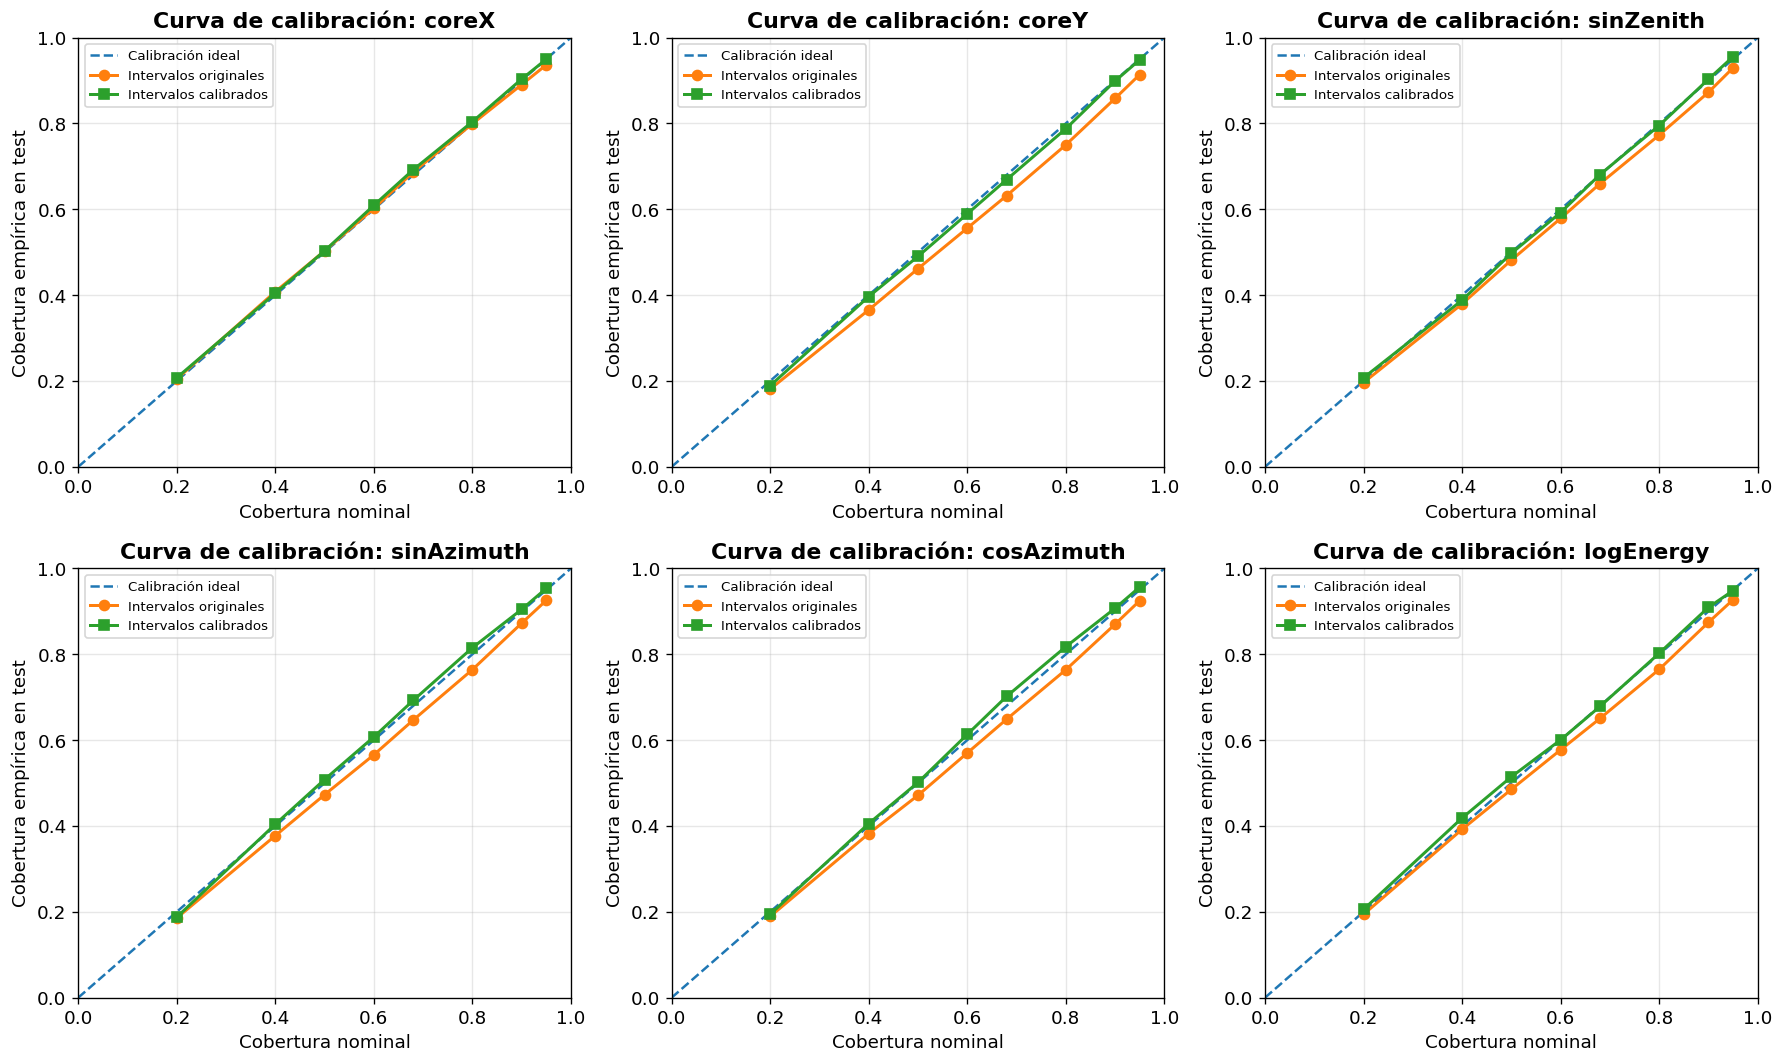


 RESUMEN DE COBERTURAS


,target,nominal_coverage,original_coverage,calibrated_coverage
0,coreX,0.20,0.2046,0.2074
1,coreY,0.20,0.1810,0.1890
2,sinZenith,0.20,0.1962,0.2074
3,sinAzimuth,0.20,0.1856,0.1876
4,cosAzimuth,0.20,0.1892,0.1942
5,logEnergy,0.20,0.1940,0.2056
6,coreX,0.40,0.4080,0.4044
7,coreY,0.40,0.3656,0.3966
8,sinZenith,0.40,0.3796,0.3882
9,sinAzimuth,0.40,0.3774,0.4040



 CALIDAD GLOBAL DE LAS CURVAS


,target,mean_abs_calibration_error_original,mean_abs_calibration_error_calibrated,original_error_pp,calibrated_error_pp,improvement_percent
0,coreX,0.006025,0.005525,0.6025,0.5525,8.298755
1,coreY,0.039000,0.007650,3.9000,0.7650,80.384615
2,sinZenith,0.019850,0.005475,1.9850,0.5475,72.418136
3,sinAzimuth,0.027425,0.008500,2.7425,0.8500,69.006381
4,cosAzimuth,0.026225,0.009925,2.6225,0.9925,62.154433
5,logEnergy,0.020525,0.006775,2.0525,0.6775,66.991474



[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/internal_calibration_curves_real_6_targets.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/internal_calibration_curve_quality_6_targets.csv

 FIGURA 19 REAL FINALIZADA
[OK] Los niveles nominales se obtienen mediante cuantiles reales del posterior.
[OK] No se reescala artificialmente el intervalo del 68 % para construir los demás niveles.
[OK] Los factores de calibración se ajustan únicamente con validación.
[OK] Los factores aprendidos en validación se aplican al test.
[OK] El test no interviene en el ajuste.
[OK] Se analizan los 6 targets internos.
[OK] coreX, coreY, sinZenith, sinAzimuth, cosAzimuth y logEnergy.


In [ ]:
###############################################################################
## FIGURA 19 - CURVAS DE CALIBRACIÓN REALES PARA LOS 6 TARGETS INTERNOS
##
## OBJETIVO:
##
## Reproducir la misma metodología de la antigua Figura 19, pero utilizando
## ahora los 6 targets internos realmente empleados por el Normalizing Flow:
##
##     coreX
##     coreY
##     sinZenith
##     sinAzimuth
##     cosAzimuth
##     logEnergy
##
## Para cada nivel nominal:
##
##     20 %, 40 %, 50 %, 60 %, 68 %, 80 %, 90 %, 95 %
##
## se obtienen DIRECTAMENTE los cuantiles correspondientes de las muestras
## posteriores del Flow.
##
## Ejemplo:
##
##     cobertura nominal = 68 %
##
##     q_low  = 16 %
##     q_high = 84 %
##
##     cobertura nominal = 90 %
##
##     q_low  = 5 %
##     q_high = 95 %
##
## CALIBRACIÓN:
##
## 1. Se generan posteriores sobre VALIDACIÓN.
## 2. Para cada target y nivel nominal se obtiene un factor de escala.
## 3. Ese factor se ajusta EXCLUSIVAMENTE con validación.
## 4. Se generan los mismos intervalos posteriores en TEST.
## 5. Se aplica al TEST el factor aprendido en validación.
##
## Por tanto:
##
##     TEST NO se utiliza para ajustar la calibración.
##
## No existe leakage.
##
## IMPORTANTE:
##
## Esta celda vuelve a muestrear VALIDACIÓN y TEST porque para construir una
## curva de calibración real hacen falta los cuantiles correspondientes a
## varios niveles nominales.
##
## La energía se representa mediante:
##
##     logEnergy = log10(E / GeV)
###############################################################################


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path
from tqdm.auto import tqdm


###############################################################################
## 1. TARGETS INTERNOS
###############################################################################

INTERNAL_CURVE_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


INTERNAL_CURVE_TARGET_UNITS = [
    'm',
    'm',
    'adimensional',
    'adimensional',
    'adimensional',
    'log10(E / GeV)',
]


N_INTERNAL_CURVE_TARGETS = len(
    INTERNAL_CURVE_TARGET_NAMES
)


###############################################################################
## 2. NIVELES NOMINALES DE LA CURVA
###############################################################################

INTERNAL_CALIBRATION_LEVELS = np.asarray(
    [
        0.20,
        0.40,
        0.50,
        0.60,
        0.68,
        0.80,
        0.90,
        0.95,
    ],
    dtype=np.float64,
)


###############################################################################
## 3. COMPROBAR VARIABLES NECESARIAS
###############################################################################

REQUIRED_INTERNAL_CURVE_VARIABLES = [
    'MODEL',
    'TARGET_SCALER',
    'calibration_loader',
    'eval_loader',
    'DEVICE',
    'CFG',
]


MISSING_INTERNAL_CURVE_VARIABLES = [
    variable_name
    for variable_name in REQUIRED_INTERNAL_CURVE_VARIABLES
    if variable_name not in globals()
]


if MISSING_INTERNAL_CURVE_VARIABLES:

    raise NameError(
        'Faltan variables necesarias para generar '
        'las curvas de calibración:\n'
        +
        '\n'.join(
            f'  - {variable_name}'
            for variable_name
            in MISSING_INTERNAL_CURVE_VARIABLES
        )
    )


###############################################################################
## 4. COMPROBAR TARGET_SCALER
###############################################################################

if not hasattr(
    TARGET_SCALER,
    'mean_',
):

    raise ValueError(
        'TARGET_SCALER no parece estar ajustado.'
    )


if len(
    TARGET_SCALER.mean_
) != N_INTERNAL_CURVE_TARGETS:

    raise ValueError(
        'TARGET_SCALER no contiene 6 variables.\n'
        f'Dimensión encontrada: {len(TARGET_SCALER.mean_)}'
    )


###############################################################################
## 5. CONFIGURACIÓN
###############################################################################

## Para una curva de calibración es conveniente utilizar más muestras que
## para una simple estimación q16-q84.
##
## Si ya existía CALIBRATION_CURVE_N_SAMPLES en el notebook se conserva.

INTERNAL_CURVE_N_SAMPLES = (
    CALIBRATION_CURVE_N_SAMPLES
    if 'CALIBRATION_CURVE_N_SAMPLES' in globals()
    else CFG.get(
        'calibration_curve_n_samples',
        200,
    )
)


INTERNAL_CURVE_SAMPLE_CHUNK = (
    CALIBRATION_CURVE_SAMPLE_CHUNK
    if 'CALIBRATION_CURVE_SAMPLE_CHUNK' in globals()
    else CFG.get(
        'eval_sample_chunk',
        10,
    )
)


INTERNAL_CURVE_DPI = CFG.get(
    'coverage_plot_dpi',
    160,
)


print()

print(
    '============================================================'
)

print(
    ' CONFIGURACIÓN DE CURVAS DE CALIBRACIÓN'
)

print(
    '============================================================'
)


print(
    f'Muestras posteriores por evento : '
    f'{INTERNAL_CURVE_N_SAMPLES}'
)


print(
    f'Chunk de muestreo                : '
    f'{INTERNAL_CURVE_SAMPLE_CHUNK}'
)


print(
    f'Niveles nominales                : '
    f'{INTERNAL_CALIBRATION_LEVELS}'
)


###############################################################################
## 6. DIRECTORIO DE SALIDA
###############################################################################

if 'artifact_path' in globals():

    INTERNAL_CURVE_OUTPUT_DIR = Path(
        artifact_path(
            'internal_calibration_curves',
            run_specific=False,
        )
    )


else:

    INTERNAL_CURVE_OUTPUT_DIR = Path(
        'internal_calibration_curves'
    )


INTERNAL_CURVE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


###############################################################################
## 7. FUNCIÓN PARA GUARDAR FIGURAS
###############################################################################

def save_internal_curve_figure(
    figure,
    filename,
):

    if not CFG.get(
        'save_artifacts',
        True,
    ):

        return


    png_path = (
        INTERNAL_CURVE_OUTPUT_DIR
        /
        f'{filename}.png'
    )


    pdf_path = (
        INTERNAL_CURVE_OUTPUT_DIR
        /
        f'{filename}.pdf'
    )


    figure.savefig(
        png_path,
        dpi=INTERNAL_CURVE_DPI,
        bbox_inches='tight',
    )


    figure.savefig(
        pdf_path,
        bbox_inches='tight',
    )


    print(
        f'[saved] {png_path}'
    )


    print(
        f'[saved] {pdf_path}'
    )


###############################################################################
## 8. FUNCIÓN PARA OBTENER LAS MUESTRAS POSTERIORES INTERNAS
###############################################################################

def collect_internal_posterior_samples(
    model,
    loader,
    target_scaler,
    n_samples,
    sample_chunk_size,
    description,
):

    model.eval()


    all_true = []

    all_samples = []


    if DEVICE.type == 'cuda':

        torch.cuda.empty_cache()


    with torch.no_grad():

        for hits, mask, targets in tqdm(
            loader,
            desc=description,
        ):

            hits = hits.to(
                DEVICE,
                non_blocking=False,
            )


            mask = mask.to(
                DEVICE,
                non_blocking=False,
            )


            ###################################################################
            ## TARGET VERDADERO INTERNO
            ###################################################################

            targets_scaled = (
                targets
                .detach()
                .cpu()
                .numpy()
            )


            if (
                targets_scaled.ndim != 2
                or
                targets_scaled.shape[1] != 6
            ):

                raise ValueError(
                    f'{description}: el DataLoader no devuelve '
                    '6 targets internos.\n'
                    f'Forma encontrada: {targets_scaled.shape}'
                )


            targets_internal = target_scaler.inverse_transform(
                targets_scaled
            )


            all_true.append(
                np.asarray(
                    targets_internal,
                    dtype=np.float64,
                )
            )


            ###################################################################
            ## MUESTREO DEL FLOW
            ###################################################################

            batch_samples = []


            remaining = int(
                n_samples
            )


            while remaining > 0:

                n_now = min(
                    sample_chunk_size,
                    remaining,
                )


                samples_scaled = model.sample(
                    hits,
                    mask,
                    n_samples=n_now,
                )


                samples_scaled = (
                    samples_scaled
                    .detach()
                    .cpu()
                    .numpy()
                )


                if (
                    samples_scaled.ndim != 3
                    or
                    samples_scaled.shape[2] != 6
                ):

                    raise ValueError(
                        'El Flow no devuelve muestras con '
                        'forma (n_samples, batch, 6).\n'
                        f'Forma encontrada: {samples_scaled.shape}'
                    )


                ns = samples_scaled.shape[0]

                batch_size = samples_scaled.shape[1]

                n_targets = samples_scaled.shape[2]


                samples_internal = target_scaler.inverse_transform(
                    samples_scaled.reshape(
                        ns * batch_size,
                        n_targets,
                    )
                ).reshape(
                    ns,
                    batch_size,
                    n_targets,
                )


                ## Guardar como float32 es suficiente para cuantiles y
                ## reduce considerablemente el consumo de memoria.

                batch_samples.append(
                    np.asarray(
                        samples_internal,
                        dtype=np.float32,
                    )
                )


                remaining -= n_now


                del samples_scaled
                del samples_internal


            ###################################################################
            ## UNIR MUESTRAS DEL BATCH
            ###################################################################

            batch_samples = np.concatenate(
                batch_samples,
                axis=0,
            )


            ## Cambiar:
            ##
            ##     (n_samples, batch, 6)
            ##
            ## a:
            ##
            ##     (batch, n_samples, 6)

            batch_samples = np.transpose(
                batch_samples,
                (
                    1,
                    0,
                    2,
                ),
            )


            all_samples.append(
                batch_samples
            )


            del hits
            del mask
            del targets
            del batch_samples


    ###########################################################################
    ## CONCATENAR EVENTOS
    ###########################################################################

    y_true = np.concatenate(
        all_true,
        axis=0,
    )


    posterior_samples = np.concatenate(
        all_samples,
        axis=0,
    )


    return (
        y_true,
        posterior_samples,
    )


###############################################################################
## 9. MUESTREAR VALIDACIÓN
###############################################################################

print()

print(
    '============================================================'
)

print(
    ' MUESTREANDO POSTERIORES DE VALIDACIÓN'
)

print(
    '============================================================'
)


(
    CURVE_VAL_TRUE_INTERNAL,
    CURVE_VAL_SAMPLES_INTERNAL,
) = collect_internal_posterior_samples(
    MODEL,
    calibration_loader,
    TARGET_SCALER,
    INTERNAL_CURVE_N_SAMPLES,
    INTERNAL_CURVE_SAMPLE_CHUNK,
    description='Calibration curve - validation 6D',
)


print()

print(
    '[OK] Validación'
)


print(
    f'     Y_true  : {CURVE_VAL_TRUE_INTERNAL.shape}'
)


print(
    f'     samples : {CURVE_VAL_SAMPLES_INTERNAL.shape}'
)


###############################################################################
## 10. MUESTREAR TEST
###############################################################################

print()

print(
    '============================================================'
)

print(
    ' MUESTREANDO POSTERIORES DE TEST'
)

print(
    '============================================================'
)


(
    CURVE_TEST_TRUE_INTERNAL,
    CURVE_TEST_SAMPLES_INTERNAL,
) = collect_internal_posterior_samples(
    MODEL,
    eval_loader,
    TARGET_SCALER,
    INTERNAL_CURVE_N_SAMPLES,
    INTERNAL_CURVE_SAMPLE_CHUNK,
    description='Calibration curve - test 6D',
)


print()

print(
    '[OK] Test'
)


print(
    f'     Y_true  : {CURVE_TEST_TRUE_INTERNAL.shape}'
)


print(
    f'     samples : {CURVE_TEST_SAMPLES_INTERNAL.shape}'
)


###############################################################################
## 11. MEDIANAS POSTERIORES
###############################################################################

CURVE_VAL_MEDIAN_INTERNAL = np.median(
    CURVE_VAL_SAMPLES_INTERNAL,
    axis=1,
)


CURVE_TEST_MEDIAN_INTERNAL = np.median(
    CURVE_TEST_SAMPLES_INTERNAL,
    axis=1,
)


###############################################################################
## 12. FUNCIÓN PARA COBERTURA
###############################################################################

def calculate_single_target_coverage(
    y_true,
    y_low,
    y_high,
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    y_low = np.asarray(
        y_low,
        dtype=np.float64,
    )


    y_high = np.asarray(
        y_high,
        dtype=np.float64,
    )


    valid = (
        np.isfinite(
            y_true
        )
        &
        np.isfinite(
            y_low
        )
        &
        np.isfinite(
            y_high
        )
    )


    if valid.sum() == 0:

        return np.nan


    inside = (
        (y_true[valid] >= y_low[valid])
        &
        (y_true[valid] <= y_high[valid])
    )


    return float(
        np.mean(
            inside
        )
    )


###############################################################################
## 13. FUNCIÓN PARA AJUSTAR EL FACTOR DE CALIBRACIÓN
##
## Para cada evento se calcula qué factor mínimo sería necesario para que
## el valor verdadero quedase dentro del intervalo.
##
## Después se toma el cuantil correspondiente al nivel nominal deseado.
###############################################################################

def fit_interval_scale_factor_for_level(
    y_true,
    y_median,
    y_low,
    y_high,
    nominal_level,
):

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    y_median = np.asarray(
        y_median,
        dtype=np.float64,
    )


    y_low = np.asarray(
        y_low,
        dtype=np.float64,
    )


    y_high = np.asarray(
        y_high,
        dtype=np.float64,
    )


    finite = (
        np.isfinite(
            y_true
        )
        &
        np.isfinite(
            y_median
        )
        &
        np.isfinite(
            y_low
        )
        &
        np.isfinite(
            y_high
        )
    )


    y_true = y_true[
        finite
    ]


    y_median = y_median[
        finite
    ]


    y_low = y_low[
        finite
    ]


    y_high = y_high[
        finite
    ]


    lower_width = (
        y_median
        -
        y_low
    )


    upper_width = (
        y_high
        -
        y_median
    )


    required_factor = np.full(
        len(
            y_true
        ),
        np.nan,
        dtype=np.float64,
    )


    lower_side = (
        y_true
        <
        y_median
    )


    upper_side = ~lower_side


    valid_lower = (
        lower_side
        &
        np.isfinite(
            lower_width
        )
        &
        (lower_width > 0.0)
    )


    valid_upper = (
        upper_side
        &
        np.isfinite(
            upper_width
        )
        &
        (upper_width > 0.0)
    )


    required_factor[
        valid_lower
    ] = (
        (
            y_median[
                valid_lower
            ]
            -
            y_true[
                valid_lower
            ]
        )
        /
        lower_width[
            valid_lower
        ]
    )


    required_factor[
        valid_upper
    ] = (
        (
            y_true[
                valid_upper
            ]
            -
            y_median[
                valid_upper
            ]
        )
        /
        upper_width[
            valid_upper
        ]
    )


    required_factor = required_factor[
        np.isfinite(
            required_factor
        )
    ]


    if len(
        required_factor
    ) == 0:

        return np.nan


    return float(
        np.quantile(
            required_factor,
            nominal_level,
        )
    )


###############################################################################
## 14. CONSTRUIR LAS CURVAS REALES
###############################################################################

curve_rows = []


for nominal_level in INTERNAL_CALIBRATION_LEVELS:

    ###########################################################################
    ## CUANTILES CORRESPONDIENTES AL NIVEL NOMINAL
    ##
    ## Ejemplo:
    ##
    ##     68 % -> 16 % / 84 %
    ##     90 % ->  5 % / 95 %
    ###########################################################################

    lower_percentile = (
        100.0
        *
        (
            1.0
            -
            nominal_level
        )
        /
        2.0
    )


    upper_percentile = (
        100.0
        -
        lower_percentile
    )


    ###########################################################################
    ## CUANTILES REALES EN VALIDACIÓN
    ###########################################################################

    val_low = np.percentile(
        CURVE_VAL_SAMPLES_INTERNAL,
        lower_percentile,
        axis=1,
    )


    val_high = np.percentile(
        CURVE_VAL_SAMPLES_INTERNAL,
        upper_percentile,
        axis=1,
    )


    ###########################################################################
    ## CUANTILES REALES EN TEST
    ###########################################################################

    test_low = np.percentile(
        CURVE_TEST_SAMPLES_INTERNAL,
        lower_percentile,
        axis=1,
    )


    test_high = np.percentile(
        CURVE_TEST_SAMPLES_INTERNAL,
        upper_percentile,
        axis=1,
    )


    ###########################################################################
    ## PROCESAR CADA TARGET
    ###########################################################################

    for target_index, target_name in enumerate(
        INTERNAL_CURVE_TARGET_NAMES
    ):

        #######################################################################
        ## COBERTURA ORIGINAL EN TEST
        #######################################################################

        original_test_coverage = (
            calculate_single_target_coverage(
                CURVE_TEST_TRUE_INTERNAL[
                    :,
                    target_index,
                ],
                test_low[
                    :,
                    target_index,
                ],
                test_high[
                    :,
                    target_index,
                ],
            )
        )


        #######################################################################
        ## FACTOR APRENDIDO EXCLUSIVAMENTE EN VALIDACIÓN
        #######################################################################

        scale_factor = fit_interval_scale_factor_for_level(
            CURVE_VAL_TRUE_INTERNAL[
                :,
                target_index,
            ],
            CURVE_VAL_MEDIAN_INTERNAL[
                :,
                target_index,
            ],
            val_low[
                :,
                target_index,
            ],
            val_high[
                :,
                target_index,
            ],
            nominal_level,
        )


        #######################################################################
        ## APLICAR FACTOR AL INTERVALO DE TEST
        #######################################################################

        calibrated_test_low = (
            CURVE_TEST_MEDIAN_INTERNAL[
                :,
                target_index,
            ]
            -
            scale_factor
            *
            (
                CURVE_TEST_MEDIAN_INTERNAL[
                    :,
                    target_index,
                ]
                -
                test_low[
                    :,
                    target_index,
                ]
            )
        )


        calibrated_test_high = (
            CURVE_TEST_MEDIAN_INTERNAL[
                :,
                target_index,
            ]
            +
            scale_factor
            *
            (
                test_high[
                    :,
                    target_index,
                ]
                -
                CURVE_TEST_MEDIAN_INTERNAL[
                    :,
                    target_index,
                ]
            )
        )


        #######################################################################
        ## COBERTURA CALIBRADA EN TEST
        #######################################################################

        calibrated_test_coverage = (
            calculate_single_target_coverage(
                CURVE_TEST_TRUE_INTERNAL[
                    :,
                    target_index,
                ],
                calibrated_test_low,
                calibrated_test_high,
            )
        )


        #######################################################################
        ## GUARDAR RESULTADO
        #######################################################################

        curve_rows.append(
            {
                'target':
                    target_name,

                'nominal_coverage':
                    nominal_level,

                'lower_percentile':
                    lower_percentile,

                'upper_percentile':
                    upper_percentile,

                'scale_factor_validation':
                    scale_factor,

                'original_coverage':
                    original_test_coverage,

                'calibrated_coverage':
                    calibrated_test_coverage,
            }
        )


###############################################################################
## 15. DATAFRAME FINAL
###############################################################################

INTERNAL_CALIBRATION_CURVES_DF = pd.DataFrame(
    curve_rows
)


print()

print(
    '============================================================'
)

print(
    ' CURVAS DE CALIBRACIÓN CALCULADAS'
)

print(
    '============================================================'
)


display(
    INTERNAL_CALIBRATION_CURVES_DF
)


###############################################################################
## 16. FIGURA 19
##
## MISMO FORMATO QUE LA FIGURA ANTIGUA, AHORA EN 2 x 3
###############################################################################

fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        15,
        9,
    ),
)


axes = axes.ravel()


for target_index, target_name in enumerate(
    INTERNAL_CURVE_TARGET_NAMES
):

    ax = axes[
        target_index
    ]


    target_df = INTERNAL_CALIBRATION_CURVES_DF[
        INTERNAL_CALIBRATION_CURVES_DF[
            'target'
        ]
        ==
        target_name
    ].sort_values(
        'nominal_coverage'
    )


    ###########################################################################
    ## CALIBRACIÓN IDEAL
    ###########################################################################

    ax.plot(
        [
            0.0,
            1.0,
        ],
        [
            0.0,
            1.0,
        ],
        linestyle='--',
        label='Calibración ideal',
    )


    ###########################################################################
    ## INTERVALOS ORIGINALES
    ###########################################################################

    ax.plot(
        target_df[
            'nominal_coverage'
        ],
        target_df[
            'original_coverage'
        ],
        marker='o',
        linewidth=1.8,
        label='Intervalos originales',
    )


    ###########################################################################
    ## INTERVALOS CALIBRADOS
    ###########################################################################

    ax.plot(
        target_df[
            'nominal_coverage'
        ],
        target_df[
            'calibrated_coverage'
        ],
        marker='s',
        linewidth=1.8,
        label='Intervalos calibrados',
    )


    ###########################################################################
    ## FORMATO
    ###########################################################################

    ax.set_xlim(
        0.0,
        1.0,
    )


    ax.set_ylim(
        0.0,
        1.0,
    )


    ax.set_xlabel(
        'Cobertura nominal'
    )


    ax.set_ylabel(
        'Cobertura empírica en test'
    )


    ax.set_title(
        f'Curva de calibración: {target_name}',
        fontweight='bold',
    )


    ax.grid(
        alpha=0.3,
    )


    ax.legend(
        fontsize=8,
    )


fig.tight_layout()


save_internal_curve_figure(
    fig,
    'figura_19_curvas_calibracion_reales_6_targets',
)


plt.show()


###############################################################################
## 17. TABLA RESUMIDA POR NIVEL NOMINAL
###############################################################################

INTERNAL_CALIBRATION_CURVES_PIVOT = (
    INTERNAL_CALIBRATION_CURVES_DF[
        [
            'target',
            'nominal_coverage',
            'original_coverage',
            'calibrated_coverage',
        ]
    ]
    .copy()
)


print()

print(
    '============================================================'
)

print(
    ' RESUMEN DE COBERTURAS'
)

print(
    '============================================================'
)


display(
    INTERNAL_CALIBRATION_CURVES_PIVOT
)


###############################################################################
## 18. ERROR ABSOLUTO MEDIO DE CALIBRACIÓN
##
## Métrica adicional para comprobar objetivamente si la calibración mejora
## la curva completa.
###############################################################################

curve_quality_rows = []


for target_name in INTERNAL_CURVE_TARGET_NAMES:

    target_df = INTERNAL_CALIBRATION_CURVES_DF[
        INTERNAL_CALIBRATION_CURVES_DF[
            'target'
        ]
        ==
        target_name
    ]


    original_mae = float(
        np.mean(
            np.abs(
                target_df[
                    'original_coverage'
                ].to_numpy()
                -
                target_df[
                    'nominal_coverage'
                ].to_numpy()
            )
        )
    )


    calibrated_mae = float(
        np.mean(
            np.abs(
                target_df[
                    'calibrated_coverage'
                ].to_numpy()
                -
                target_df[
                    'nominal_coverage'
                ].to_numpy()
            )
        )
    )


    curve_quality_rows.append(
        {
            'target':
                target_name,

            'mean_abs_calibration_error_original':
                original_mae,

            'mean_abs_calibration_error_calibrated':
                calibrated_mae,

            'original_error_pp':
                original_mae
                *
                100.0,

            'calibrated_error_pp':
                calibrated_mae
                *
                100.0,

            'improvement_percent':
                (
                    (
                        original_mae
                        -
                        calibrated_mae
                    )
                    /
                    original_mae
                    *
                    100.0
                )
                if original_mae > 0.0
                else np.nan,
        }
    )


INTERNAL_CALIBRATION_CURVE_QUALITY_DF = pd.DataFrame(
    curve_quality_rows
)


print()

print(
    '============================================================'
)

print(
    ' CALIDAD GLOBAL DE LAS CURVAS'
)

print(
    '============================================================'
)


display(
    INTERNAL_CALIBRATION_CURVE_QUALITY_DF
)


###############################################################################
## 19. GUARDAR RESULTADOS
###############################################################################

if CFG.get(
    'save_artifacts',
    True,
):

    curves_csv_path = (
        INTERNAL_CURVE_OUTPUT_DIR
        /
        'internal_calibration_curves_real_6_targets.csv'
    )


    quality_csv_path = (
        INTERNAL_CURVE_OUTPUT_DIR
        /
        'internal_calibration_curve_quality_6_targets.csv'
    )


    INTERNAL_CALIBRATION_CURVES_DF.to_csv(
        curves_csv_path,
        index=False,
    )


    INTERNAL_CALIBRATION_CURVE_QUALITY_DF.to_csv(
        quality_csv_path,
        index=False,
    )


    print()

    print(
        f'[saved] {curves_csv_path}'
    )


    print(
        f'[saved] {quality_csv_path}'
    )


###############################################################################
## 20. RESUMEN FINAL
###############################################################################

print()

print(
    '============================================================'
)

print(
    ' FIGURA 19 REAL FINALIZADA'
)

print(
    '============================================================'
)


print(
    '[OK] Los niveles nominales se obtienen mediante '
    'cuantiles reales del posterior.'
)


print(
    '[OK] No se reescala artificialmente el intervalo del 68 % '
    'para construir los demás niveles.'
)


print(
    '[OK] Los factores de calibración se ajustan únicamente '
    'con validación.'
)


print(
    '[OK] Los factores aprendidos en validación se aplican al test.'
)


print(
    '[OK] El test no interviene en el ajuste.'
)


print(
    '[OK] Se analizan los 6 targets internos.'
)


print(
    '[OK] coreX, coreY, sinZenith, sinAzimuth, cosAzimuth y logEnergy.'
)



[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/figura_19_curvas_calibracion_6_targets.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_calibration_curves/figura_19_curvas_calibracion_6_targets.pdf


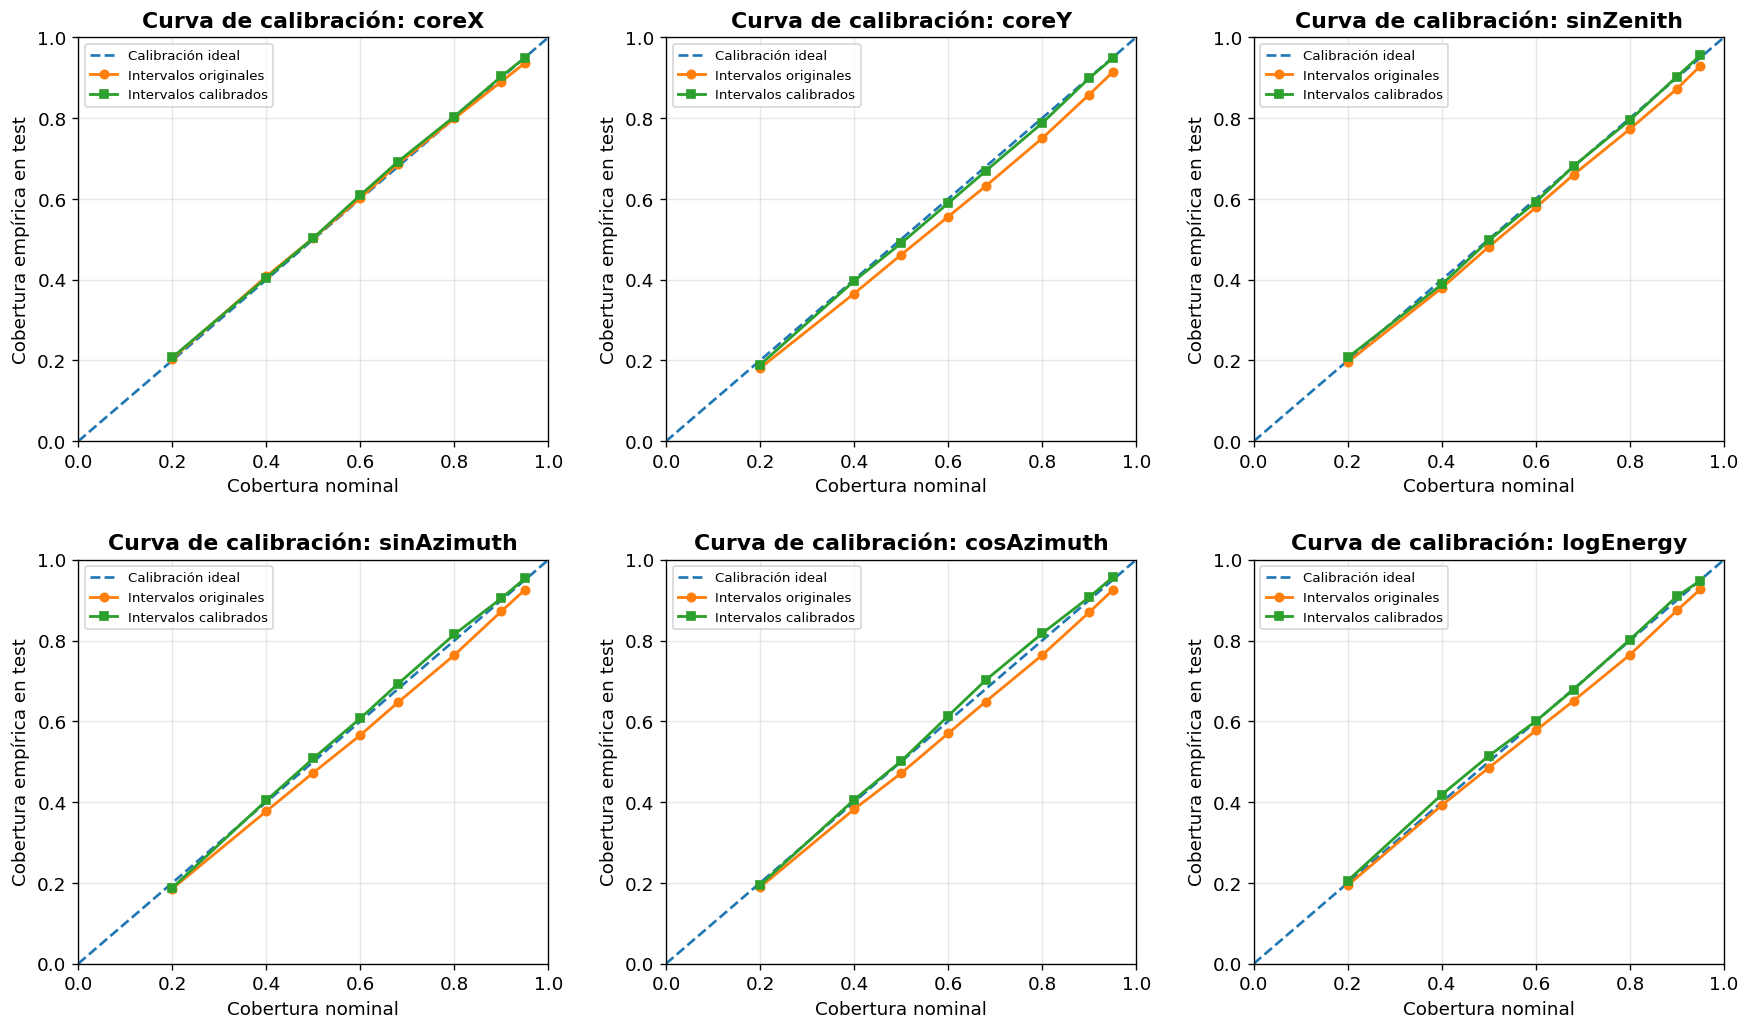


 FIGURA 19 GENERADA
[OK] coreX
[OK] coreY
[OK] sinZenith
[OK] sinAzimuth
[OK] cosAzimuth
[OK] logEnergy


In [ ]:
###############################################################################
## CURVAS DE CALIBRACIÓN DE LOS 6 TARGETS INTERNOS
##
## Esta celda utiliza los resultados ya calculados en:
##
##     INTERNAL_CALIBRATION_CURVES_DF
##
## No vuelve a muestrear el Flow.
##
## Se representan:
##
##     coreX
##     coreY
##     sinZenith
##     sinAzimuth
##     cosAzimuth
##     logEnergy
###############################################################################


import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path


###############################################################################
## 1. TARGETS
###############################################################################

INTERNAL_CURVE_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


###############################################################################
## 2. COMPROBAR QUE EXISTEN LOS RESULTADOS
###############################################################################

if 'INTERNAL_CALIBRATION_CURVES_DF' not in globals():

    raise NameError(
        'No existe INTERNAL_CALIBRATION_CURVES_DF.\n'
        'Ejecuta primero la celda que calcula las curvas reales '
        'de calibración.'
    )


required_columns = [
    'target',
    'nominal_coverage',
    'original_coverage',
    'calibrated_coverage',
]


missing_columns = [
    column_name
    for column_name in required_columns
    if column_name
    not in INTERNAL_CALIBRATION_CURVES_DF.columns
]


if missing_columns:

    raise ValueError(
        'Faltan columnas en INTERNAL_CALIBRATION_CURVES_DF:\n'
        +
        '\n'.join(
            f'  - {column_name}'
            for column_name
            in missing_columns
        )
    )


###############################################################################
## 3. DIRECTORIO DE SALIDA
###############################################################################

if 'artifact_path' in globals():

    FIGURE_19_OUTPUT_DIR = Path(
        artifact_path(
            'internal_calibration_curves',
            run_specific=False,
        )
    )


else:

    FIGURE_19_OUTPUT_DIR = Path(
        'internal_calibration_curves'
    )


FIGURE_19_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


PLOT_DPI = (
    CFG.get(
        'coverage_plot_dpi',
        160,
    )
    if 'CFG' in globals()
    else 160
)


###############################################################################
## 4. CREAR FIGURA 2 x 3
###############################################################################

fig, axes = plt.subplots(
    2,
    3,
    figsize=(
        15,
        9,
    ),
)


axes = axes.ravel()


###############################################################################
## 5. GRAFICAR CADA TARGET
###############################################################################

for target_index, target_name in enumerate(
    INTERNAL_CURVE_TARGET_NAMES
):

    ax = axes[
        target_index
    ]


    target_df = (
        INTERNAL_CALIBRATION_CURVES_DF[
            INTERNAL_CALIBRATION_CURVES_DF[
                'target'
            ]
            ==
            target_name
        ]
        .sort_values(
            'nominal_coverage'
        )
    )


    if len(
        target_df
    ) == 0:

        raise ValueError(
            f'No existen datos para {target_name}.'
        )


    ## CALIBRACIÓN IDEAL ##
    ax.plot(
        [
            0.0,
            1.0,
        ],
        [
            0.0,
            1.0,
        ],
        linestyle='--',
        linewidth=1.6,
        label='Calibración ideal',
    )


    ## INTERVALOS ORIGINALES ##
    ax.plot(
        target_df[
            'nominal_coverage'
        ],
        target_df[
            'original_coverage'
        ],
        marker='o',
        markersize=5,
        linewidth=1.7,
        label='Intervalos originales',
    )


    ## INTERVALOS CALIBRADOS ##
    ax.plot(
        target_df[
            'nominal_coverage'
        ],
        target_df[
            'calibrated_coverage'
        ],
        marker='s',
        markersize=5,
        linewidth=1.7,
        label='Intervalos calibrados',
    )


    ## FORMATO ##
    ax.set_xlim(
        0.0,
        1.0,
    )


    ax.set_ylim(
        0.0,
        1.0,
    )


    ax.set_xticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )


    ax.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )


    ax.set_xlabel(
        'Cobertura nominal'
    )


    ax.set_ylabel(
        'Cobertura empírica en test'
    )


    ax.set_title(
        f'Curva de calibración: {target_name}',
        fontweight='bold',
    )


    ax.grid(
        alpha=0.3,
    )


    ax.legend(
        loc='upper left',
        fontsize=8,
    )


###############################################################################
## 6. AJUSTAR DISEÑO
###############################################################################

fig.tight_layout(
    pad=2.0,
)


###############################################################################
## 7. GUARDAR PNG Y PDF
###############################################################################

if (
    CFG.get(
        'save_artifacts',
        True,
    )
    if 'CFG' in globals()
    else True
):

    png_path = (
        FIGURE_19_OUTPUT_DIR
        /
        'figura_19_curvas_calibracion_6_targets.png'
    )


    pdf_path = (
        FIGURE_19_OUTPUT_DIR
        /
        'figura_19_curvas_calibracion_6_targets.pdf'
    )


    fig.savefig(
        png_path,
        dpi=PLOT_DPI,
        bbox_inches='tight',
    )


    fig.savefig(
        pdf_path,
        bbox_inches='tight',
    )


    print(
        f'[saved] {png_path}'
    )


    print(
        f'[saved] {pdf_path}'
    )


###############################################################################
## 8. MOSTRAR
###############################################################################

plt.show()


###############################################################################
## 9. RESUMEN
###############################################################################

print()

print(
    '============================================================'
)


print(
    ' FIGURA 19 GENERADA'
)


print(
    '============================================================'
)


print(
    '[OK] coreX'
)


print(
    '[OK] coreY'
)


print(
    '[OK] sinZenith'
)


print(
    '[OK] sinAzimuth'
)


print(
    '[OK] cosAzimuth'
)


print(
    '[OK] logEnergy'
)




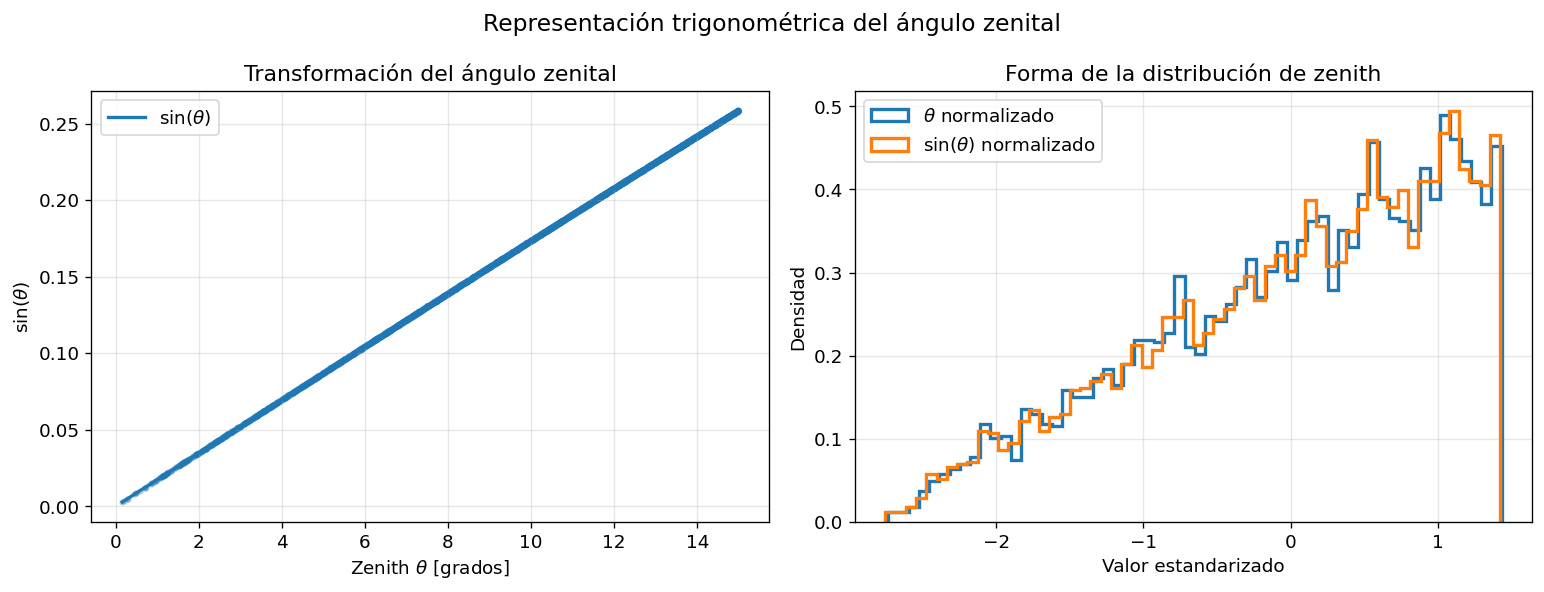

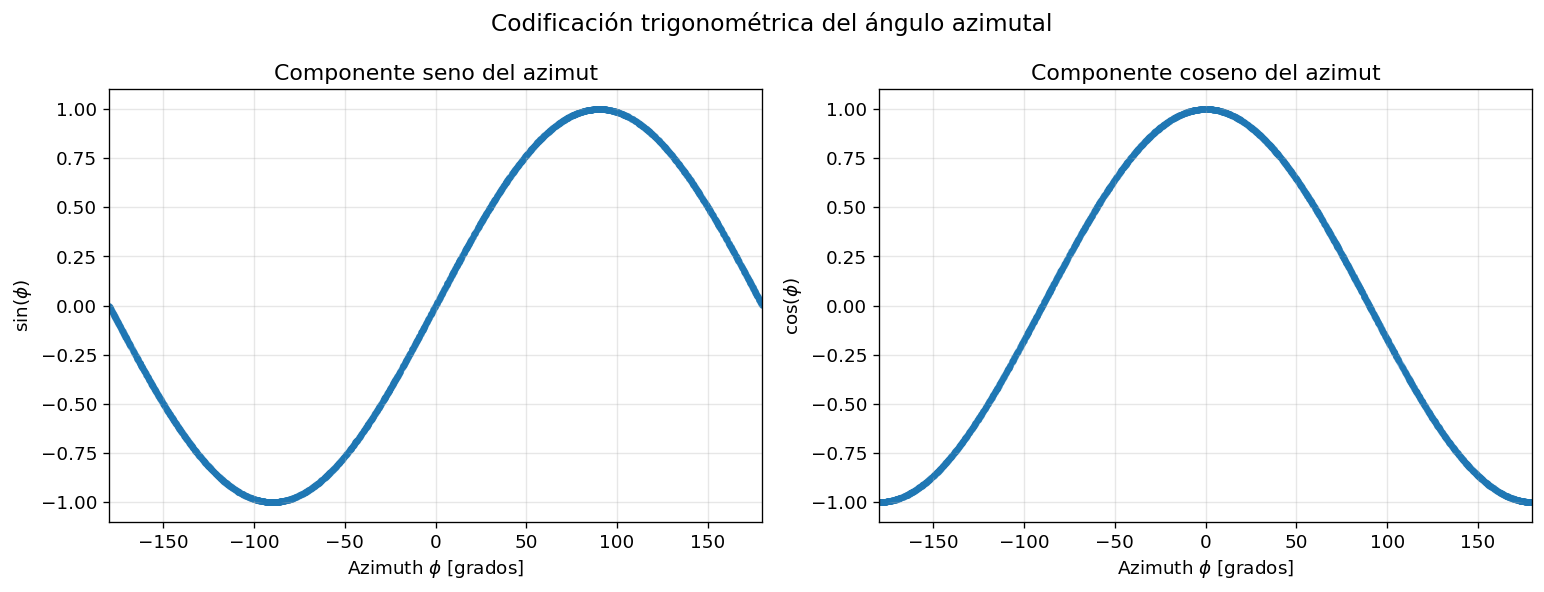

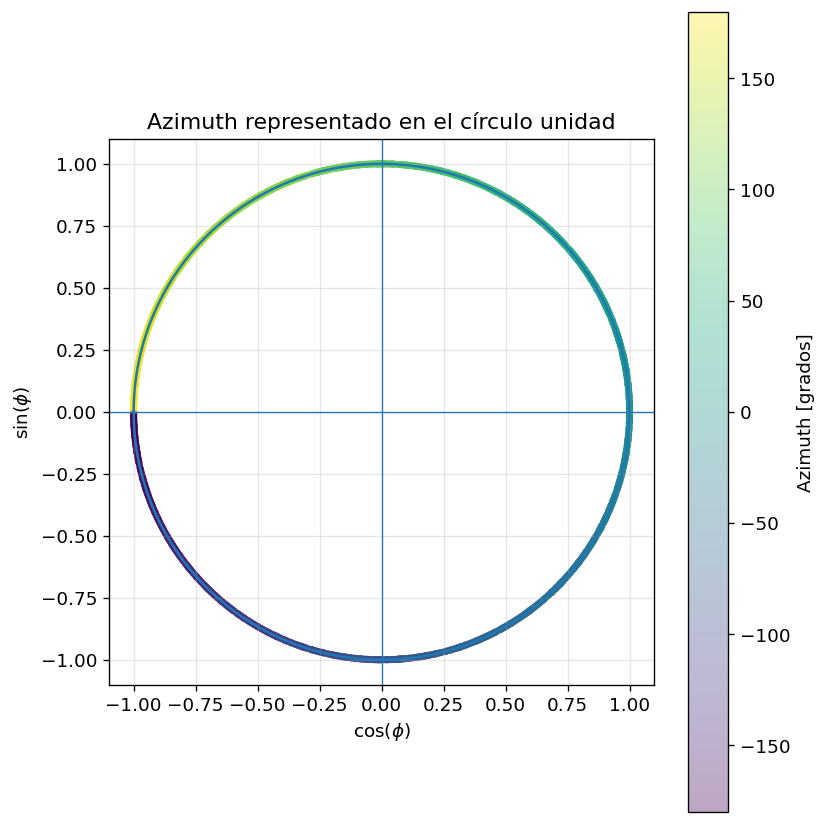

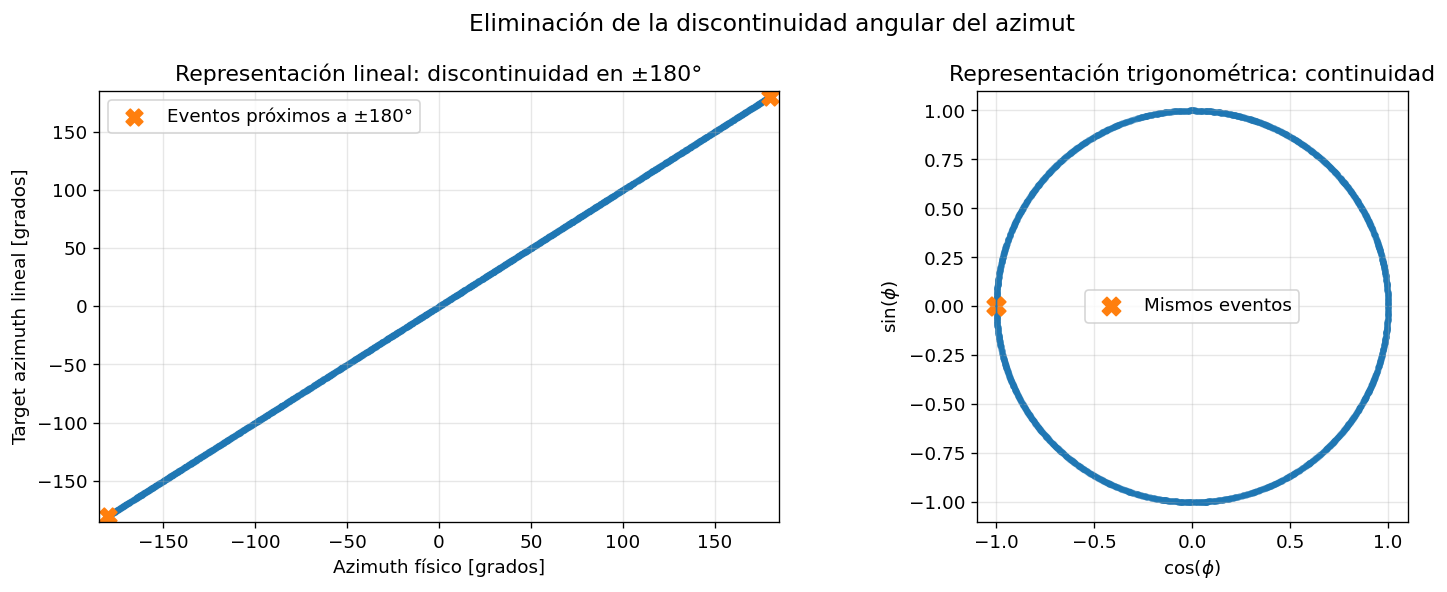

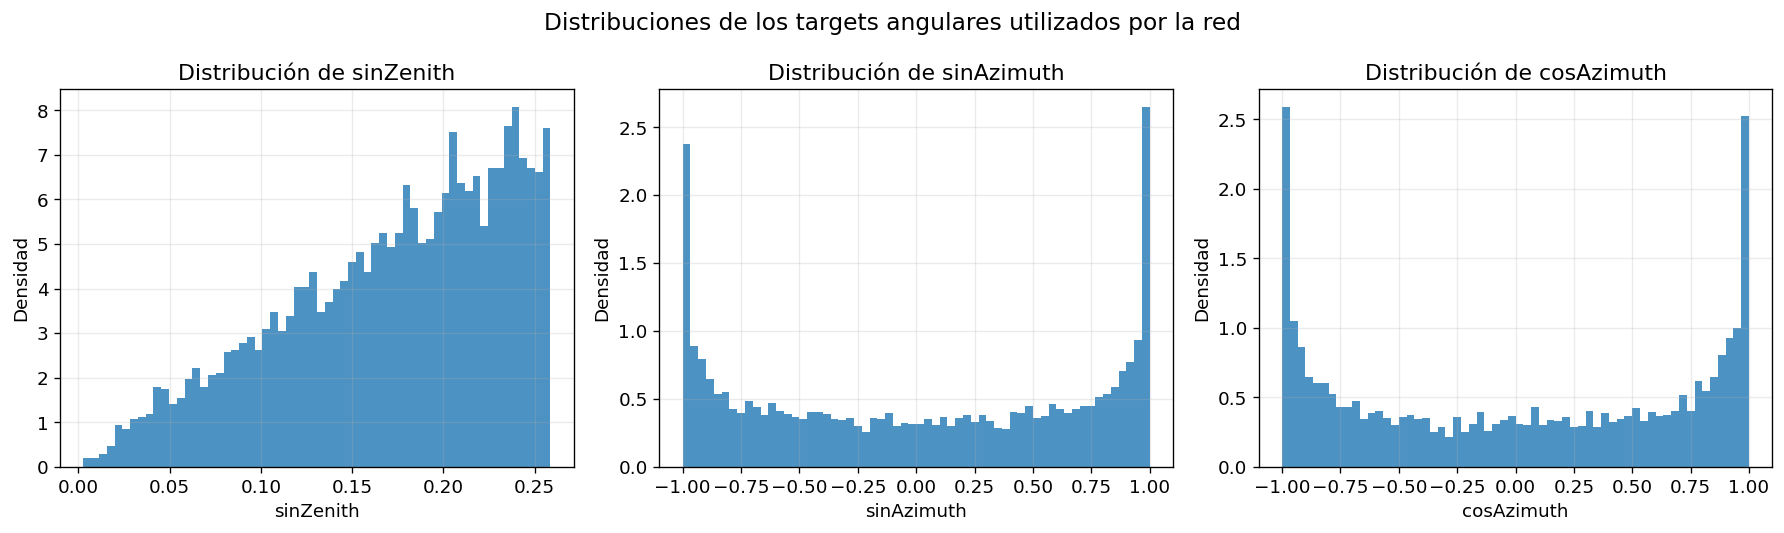


[INFO] TARGETS internos 6D detectados.
[INFO] Orden esperado:
       coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy

RESULTADOS PARA EL APARTADO 9.3

ZENITH
Rango zenith       : 0.1604° → 14.9886°
Rango sinZenith    : 0.002800 → 0.258626
Corr(theta,sinθ)   : 0.9999881650
Error máximo de la transformación inversa: 5.551e-17 rad

AZIMUTH
Rango azimuth      : -179.9660° → 179.9660°
Rango sinAzimuth   : -0.999999 → 1.000000
Rango cosAzimuth   : -1.000000 → 1.000000
Media norma círculo: 1.0000000000
Máxima desviación de norma=1: 1.110e-16
Error máximo reconstrucción atan2: 5.551e-17 rad

DISCONTINUIDAD EN ±pi
Evento cercano a -pi : -179.966045°
Evento cercano a +pi : 179.966045°
Distancia lineal     : 359.932091°
Distancia circular   : 0.067909°
Distancia en (sin,cos): 0.00118524

INTERPRETACIÓN
1. Para el rango zenital utilizado, sin(zenith) mantiene una relación monótona y prácticamente lineal con zenith.
2. La transformación zenith = arcsin(sinZenith) es unívoca en el rango 

In [ ]:
#### 9.3 REPRESENTACIÓN TRIGONOMÉTRICA DE LOS ÁNGULOS ####
#### COMPARACIÓN: ÁNGULOS FÍSICOS VS TARGETS TRIGONOMÉTRICOS ####
####
#### OBJETIVO:
####
#### 1. Mostrar la transformación zenith -> sin(zenith).
#### 2. Mostrar la transformación azimuth -> sin(azimuth), cos(azimuth).
#### 3. Visualizar la eliminación de la discontinuidad de azimuth en ±pi.
#### 4. Mostrar la representación circular de azimuth en el círculo unidad.
#### 5. Obtener valores cuantitativos para justificar la elección de targets.
####
#### ESTE BLOQUE:
####
#### - NO ENTRENA.
#### - NO LEE EL ROOT.
#### - NO MODIFICA TARGETS.
#### - NO UTILIZA rec.* COMO INPUT.
#### - TRABAJA SOLO CON LOS VALORES FÍSICOS TRUE YA CARGADOS.
####


import numpy as np
import matplotlib.pyplot as plt


# ── Targets físicos ──────────────────────────────────────────────────────

PHYSICAL_NAMES_93 = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


## COMPROBAR QUE Y_TRUE ESTÁ EN ESPACIO FÍSICO 5D ##
Y_TRUE_93 = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


if Y_TRUE_93.ndim != 2:

    raise ValueError(
        f"Y_TRUE debe ser 2D, pero tiene shape {Y_TRUE_93.shape}."
    )


if Y_TRUE_93.shape[1] != 5:

    raise ValueError(
        f"Y_TRUE tiene {Y_TRUE_93.shape[1]} columnas; "
        "se esperaban los 5 targets físicos."
    )


if "PHYSICAL_TARGET_NAMES" in globals():

    if list(PHYSICAL_TARGET_NAMES) != PHYSICAL_NAMES_93:

        raise ValueError(
            "El orden de PHYSICAL_TARGET_NAMES no coincide.\n"
            f"Actual   : {list(PHYSICAL_TARGET_NAMES)}\n"
            f"Esperado : {PHYSICAL_NAMES_93}"
        )


# ── Índices ──────────────────────────────────────────────────────────────

ix_zenith_93 = PHYSICAL_NAMES_93.index(
    "zenithAngle"
)


ix_azimuth_93 = PHYSICAL_NAMES_93.index(
    "azimuthAngle"
)


# ── Ángulos físicos ──────────────────────────────────────────────────────

zenith_rad_93 = Y_TRUE_93[
    :,
    ix_zenith_93,
]


azimuth_rad_93 = Y_TRUE_93[
    :,
    ix_azimuth_93,
]


## ASEGURAR AZIMUT EN [-pi, pi) ##
azimuth_rad_93 = np.arctan2(
    np.sin(
        azimuth_rad_93
    ),
    np.cos(
        azimuth_rad_93
    ),
)


zenith_deg_93 = np.rad2deg(
    zenith_rad_93
)


azimuth_deg_93 = np.rad2deg(
    azimuth_rad_93
)


# ── Transformaciones trigonométricas ─────────────────────────────────────

sin_zenith_93 = np.sin(
    zenith_rad_93
)


sin_azimuth_93 = np.sin(
    azimuth_rad_93
)


cos_azimuth_93 = np.cos(
    azimuth_rad_93
)


azimuth_norm_93 = np.sqrt(
    sin_azimuth_93 ** 2
    +
    cos_azimuth_93 ** 2
)


# ── Comprobaciones matemáticas ───────────────────────────────────────────

if not np.all(
    np.isfinite(
        sin_zenith_93
    )
):

    raise ValueError(
        "sinZenith contiene valores no finitos."
    )


if not np.all(
    np.isfinite(
        sin_azimuth_93
    )
):

    raise ValueError(
        "sinAzimuth contiene valores no finitos."
    )


if not np.all(
    np.isfinite(
        cos_azimuth_93
    )
):

    raise ValueError(
        "cosAzimuth contiene valores no finitos."
    )


# ── Reconstrucción inversa ───────────────────────────────────────────────

zenith_reconstructed_93 = np.arcsin(
    np.clip(
        sin_zenith_93,
        -1.0,
        1.0,
    )
)


azimuth_reconstructed_93 = np.arctan2(
    sin_azimuth_93,
    cos_azimuth_93,
)


zenith_inverse_error_93 = (
    zenith_reconstructed_93
    -
    zenith_rad_93
)


azimuth_inverse_error_93 = np.arctan2(
    np.sin(
        azimuth_reconstructed_93
        -
        azimuth_rad_93
    ),
    np.cos(
        azimuth_reconstructed_93
        -
        azimuth_rad_93
    ),
)


# ── Correlación zenith vs sinZenith ──────────────────────────────────────

zenith_sin_corr_93 = np.corrcoef(
    zenith_rad_93,
    sin_zenith_93,
)[
    0,
    1,
]


# ── Analizar discontinuidad de azimuth en ±pi ────────────────────────────

## TOMAMOS EL EVENTO MÁS CERCANO A -pi Y EL MÁS CERCANO A +pi.
##
## FÍSICAMENTE AMBAS DIRECCIONES SON CASI LA MISMA DIRECCIÓN AZIMUTAL,
## PERO EN REPRESENTACIÓN LINEAL SUS VALORES ESTÁN SEPARADOS CASI 2*pi.

idx_minus_pi_93 = np.argmin(
    np.abs(
        azimuth_rad_93
        +
        np.pi
    )
)


idx_plus_pi_93 = np.argmin(
    np.abs(
        azimuth_rad_93
        -
        np.pi
    )
)


phi_minus_93 = azimuth_rad_93[
    idx_minus_pi_93
]


phi_plus_93 = azimuth_rad_93[
    idx_plus_pi_93
]


## DIFERENCIA SI AZIMUT SE TRATA COMO VARIABLE LINEAL ##
linear_boundary_distance_93 = np.abs(
    phi_plus_93
    -
    phi_minus_93
)


## DISTANCIA ANGULAR FÍSICA CORRECTA ##
circular_boundary_distance_93 = np.abs(
    np.arctan2(
        np.sin(
            phi_plus_93
            -
            phi_minus_93
        ),
        np.cos(
            phi_plus_93
            -
            phi_minus_93
        ),
    )
)


## DISTANCIA EN LA REPRESENTACIÓN (sin phi, cos phi) ##
trig_boundary_distance_93 = np.sqrt(
    (
        np.sin(
            phi_plus_93
        )
        -
        np.sin(
            phi_minus_93
        )
    ) ** 2
    +
    (
        np.cos(
            phi_plus_93
        )
        -
        np.cos(
            phi_minus_93
        )
    ) ** 2
)


# ── FIGURA 1: Zenith y sinZenith ─────────────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        13,
        5,
    ),
)


## ZENITH VS SINZENITH ##
axes[
    0
].scatter(
    zenith_deg_93,
    sin_zenith_93,
    s=8,
    alpha=0.25,
)


theta_grid_93 = np.linspace(
    np.nanmin(
        zenith_rad_93
    ),
    np.nanmax(
        zenith_rad_93
    ),
    500,
)


axes[
    0
].plot(
    np.rad2deg(
        theta_grid_93
    ),
    np.sin(
        theta_grid_93
    ),
    linewidth=2,
    label=r"$\sin(\theta)$",
)


axes[
    0
].set_xlabel(
    r"Zenith $\theta$ [grados]"
)


axes[
    0
].set_ylabel(
    r"$\sin(\theta)$"
)


axes[
    0
].set_title(
    "Transformación del ángulo zenital"
)


axes[
    0
].grid(
    alpha=0.3
)


axes[
    0
].legend()


## DISTRIBUCIONES NORMALIZADAS PARA COMPARAR FORMA ##
zenith_norm_93 = (
    zenith_rad_93
    -
    np.mean(
        zenith_rad_93
    )
) / np.std(
    zenith_rad_93
)


sin_zenith_norm_93 = (
    sin_zenith_93
    -
    np.mean(
        sin_zenith_93
    )
) / np.std(
    sin_zenith_93
)


axes[
    1
].hist(
    zenith_norm_93,
    bins=60,
    density=True,
    histtype="step",
    linewidth=2,
    label=r"$\theta$ normalizado",
)


axes[
    1
].hist(
    sin_zenith_norm_93,
    bins=60,
    density=True,
    histtype="step",
    linewidth=2,
    label=r"$\sin(\theta)$ normalizado",
)


axes[
    1
].set_xlabel(
    "Valor estandarizado"
)


axes[
    1
].set_ylabel(
    "Densidad"
)


axes[
    1
].set_title(
    "Forma de la distribución de zenith"
)


axes[
    1
].grid(
    alpha=0.3
)


axes[
    1
].legend()


plt.suptitle(
    "Representación trigonométrica del ángulo zenital",
    fontsize=14,
)


plt.tight_layout()


plt.show()


# ── FIGURA 2: Azimuth vs seno y coseno ───────────────────────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        13,
        5,
    ),
)


## SIN AZIMUTH ##
axes[
    0
].scatter(
    azimuth_deg_93,
    sin_azimuth_93,
    s=8,
    alpha=0.25,
)


phi_grid_93 = np.linspace(
    -np.pi,
    np.pi,
    1000,
)


axes[
    0
].plot(
    np.rad2deg(
        phi_grid_93
    ),
    np.sin(
        phi_grid_93
    ),
    linewidth=2,
)


axes[
    0
].set_xlabel(
    r"Azimuth $\phi$ [grados]"
)


axes[
    0
].set_ylabel(
    r"$\sin(\phi)$"
)


axes[
    0
].set_title(
    "Componente seno del azimut"
)


axes[
    0
].set_xlim(
    -180,
    180,
)


axes[
    0
].grid(
    alpha=0.3
)


## COS AZIMUTH ##
axes[
    1
].scatter(
    azimuth_deg_93,
    cos_azimuth_93,
    s=8,
    alpha=0.25,
)


axes[
    1
].plot(
    np.rad2deg(
        phi_grid_93
    ),
    np.cos(
        phi_grid_93
    ),
    linewidth=2,
)


axes[
    1
].set_xlabel(
    r"Azimuth $\phi$ [grados]"
)


axes[
    1
].set_ylabel(
    r"$\cos(\phi)$"
)


axes[
    1
].set_title(
    "Componente coseno del azimut"
)


axes[
    1
].set_xlim(
    -180,
    180,
)


axes[
    1
].grid(
    alpha=0.3
)


plt.suptitle(
    "Codificación trigonométrica del ángulo azimutal",
    fontsize=14,
)


plt.tight_layout()


plt.show()


# ── FIGURA 3: Representación de azimuth sobre círculo unidad ─────────────

fig, ax = plt.subplots(
    figsize=(
        7,
        7,
    )
)


scatter_93 = ax.scatter(
    cos_azimuth_93,
    sin_azimuth_93,
    c=azimuth_deg_93,
    s=10,
    alpha=0.35,
)


circle_phi_93 = np.linspace(
    -np.pi,
    np.pi,
    1000,
)


ax.plot(
    np.cos(
        circle_phi_93
    ),
    np.sin(
        circle_phi_93
    ),
    linewidth=1.5,
)


fig.colorbar(
    scatter_93,
    ax=ax,
    label="Azimuth [grados]",
)


ax.set_xlabel(
    r"$\cos(\phi)$"
)


ax.set_ylabel(
    r"$\sin(\phi)$"
)


ax.set_title(
    "Azimuth representado en el círculo unidad"
)


ax.set_aspect(
    "equal",
    adjustable="box",
)


ax.set_xlim(
    -1.1,
    1.1,
)


ax.set_ylim(
    -1.1,
    1.1,
)


ax.axhline(
    0,
    linewidth=0.8,
)


ax.axvline(
    0,
    linewidth=0.8,
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ── FIGURA 4: Problema de la discontinuidad de azimuth ───────────────────

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        13,
        5,
    ),
)


## REPRESENTACIÓN LINEAL ##
axes[
    0
].scatter(
    azimuth_deg_93,
    azimuth_deg_93,
    s=8,
    alpha=0.2,
)


axes[
    0
].scatter(
    [
        np.rad2deg(
            phi_minus_93
        ),
        np.rad2deg(
            phi_plus_93
        ),
    ],
    [
        np.rad2deg(
            phi_minus_93
        ),
        np.rad2deg(
            phi_plus_93
        ),
    ],
    s=100,
    marker="X",
    label="Eventos próximos a ±180°",
)


axes[
    0
].set_xlabel(
    "Azimuth físico [grados]"
)


axes[
    0
].set_ylabel(
    "Target azimuth lineal [grados]"
)


axes[
    0
].set_title(
    "Representación lineal: discontinuidad en ±180°"
)


axes[
    0
].set_xlim(
    -185,
    185,
)


axes[
    0
].set_ylim(
    -185,
    185,
)


axes[
    0
].grid(
    alpha=0.3
)


axes[
    0
].legend()


## REPRESENTACIÓN TRIGONOMÉTRICA ##
axes[
    1
].scatter(
    cos_azimuth_93,
    sin_azimuth_93,
    s=8,
    alpha=0.2,
)


axes[
    1
].scatter(
    [
        np.cos(
            phi_minus_93
        ),
        np.cos(
            phi_plus_93
        ),
    ],
    [
        np.sin(
            phi_minus_93
        ),
        np.sin(
            phi_plus_93
        ),
    ],
    s=120,
    marker="X",
    label="Mismos eventos",
)


axes[
    1
].plot(
    np.cos(
        circle_phi_93
    ),
    np.sin(
        circle_phi_93
    ),
    linewidth=1,
)


axes[
    1
].set_xlabel(
    r"$\cos(\phi)$"
)


axes[
    1
].set_ylabel(
    r"$\sin(\phi)$"
)


axes[
    1
].set_title(
    "Representación trigonométrica: continuidad"
)


axes[
    1
].set_aspect(
    "equal",
    adjustable="box",
)


axes[
    1
].set_xlim(
    -1.1,
    1.1,
)


axes[
    1
].set_ylim(
    -1.1,
    1.1,
)


axes[
    1
].grid(
    alpha=0.3
)


axes[
    1
].legend()


plt.suptitle(
    "Eliminación de la discontinuidad angular del azimut",
    fontsize=14,
)


plt.tight_layout()


plt.show()


# ── FIGURA 5: Distribuciones de los tres targets trigonométricos ─────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        15,
        4.5,
    ),
)


axes[
    0
].hist(
    sin_zenith_93,
    bins=60,
    density=True,
    alpha=0.8,
)


axes[
    0
].set_xlabel(
    "sinZenith"
)


axes[
    0
].set_ylabel(
    "Densidad"
)


axes[
    0
].set_title(
    "Distribución de sinZenith"
)


axes[
    0
].grid(
    alpha=0.25
)


axes[
    1
].hist(
    sin_azimuth_93,
    bins=60,
    density=True,
    alpha=0.8,
)


axes[
    1
].set_xlabel(
    "sinAzimuth"
)


axes[
    1
].set_ylabel(
    "Densidad"
)


axes[
    1
].set_title(
    "Distribución de sinAzimuth"
)


axes[
    1
].grid(
    alpha=0.25
)


axes[
    2
].hist(
    cos_azimuth_93,
    bins=60,
    density=True,
    alpha=0.8,
)


axes[
    2
].set_xlabel(
    "cosAzimuth"
)


axes[
    2
].set_ylabel(
    "Densidad"
)


axes[
    2
].set_title(
    "Distribución de cosAzimuth"
)


axes[
    2
].grid(
    alpha=0.25
)


plt.suptitle(
    "Distribuciones de los targets angulares utilizados por la red",
    fontsize=14,
)


plt.tight_layout()


plt.show()


# ── Comprobación opcional con TARGETS internos ────────────────────────────

## SI TARGETS SIGUE EN MEMORIA Y CONTIENE LOS 6 TARGETS INTERNOS,
## COMPROBAMOS QUE LA TRANSFORMACIÓN UTILIZADA ES EXACTAMENTE LA ESPERADA.
##
## NO ES NECESARIO PARA GENERAR LAS GRÁFICAS.

if (
    "TARGETS" in globals()
    and
    TARGETS is not None
):

    TARGETS_93 = np.asarray(
        TARGETS,
        dtype=np.float64,
    )


    if (
        TARGETS_93.ndim == 2
        and
        TARGETS_93.shape[1] == 6
    ):

        print(
            "\n[INFO] TARGETS internos 6D detectados."
        )


        print(
            "[INFO] Orden esperado:"
        )


        print(
            "       coreX, coreY, sinZenith, "
            "sinAzimuth, cosAzimuth, logEnergy"
        )


    else:

        print(
            "\n[INFO] TARGETS existe, pero no tiene formato 6D. "
            "No se utiliza para esta comprobación."
        )


# ── Resultados cuantitativos ─────────────────────────────────────────────

print(
    "\n"
    +
    "=" * 72
)


print(
    "RESULTADOS PARA EL APARTADO 9.3"
)


print(
    "=" * 72
)


print(
    "\nZENITH"
)


print(
    f"Rango zenith       : "
    f"{np.nanmin(zenith_deg_93):.4f}° "
    f"→ {np.nanmax(zenith_deg_93):.4f}°"
)


print(
    f"Rango sinZenith    : "
    f"{np.nanmin(sin_zenith_93):.6f} "
    f"→ {np.nanmax(sin_zenith_93):.6f}"
)


print(
    f"Corr(theta,sinθ)   : "
    f"{zenith_sin_corr_93:.10f}"
)


print(
    f"Error máximo de la transformación inversa:"
    f" {np.nanmax(np.abs(zenith_inverse_error_93)):.3e} rad"
)


print(
    "\nAZIMUTH"
)


print(
    f"Rango azimuth      : "
    f"{np.nanmin(azimuth_deg_93):.4f}° "
    f"→ {np.nanmax(azimuth_deg_93):.4f}°"
)


print(
    f"Rango sinAzimuth   : "
    f"{np.nanmin(sin_azimuth_93):.6f} "
    f"→ {np.nanmax(sin_azimuth_93):.6f}"
)


print(
    f"Rango cosAzimuth   : "
    f"{np.nanmin(cos_azimuth_93):.6f} "
    f"→ {np.nanmax(cos_azimuth_93):.6f}"
)


print(
    f"Media norma círculo: "
    f"{np.mean(azimuth_norm_93):.10f}"
)


print(
    f"Máxima desviación de norma=1: "
    f"{np.max(np.abs(azimuth_norm_93 - 1.0)):.3e}"
)


print(
    f"Error máximo reconstrucción atan2: "
    f"{np.nanmax(np.abs(azimuth_inverse_error_93)):.3e} rad"
)


print(
    "\nDISCONTINUIDAD EN ±pi"
)


print(
    f"Evento cercano a -pi : "
    f"{np.rad2deg(phi_minus_93):.6f}°"
)


print(
    f"Evento cercano a +pi : "
    f"{np.rad2deg(phi_plus_93):.6f}°"
)


print(
    f"Distancia lineal     : "
    f"{np.rad2deg(linear_boundary_distance_93):.6f}°"
)


print(
    f"Distancia circular   : "
    f"{np.rad2deg(circular_boundary_distance_93):.6f}°"
)


print(
    f"Distancia en (sin,cos): "
    f"{trig_boundary_distance_93:.8f}"
)


print(
    "\n"
    +
    "=" * 72
)


print(
    "INTERPRETACIÓN"
)


print(
    "=" * 72
)


print(
    "1. Para el rango zenital utilizado, sin(zenith) mantiene una "
    "relación monótona y prácticamente lineal con zenith."
)


print(
    "2. La transformación zenith = arcsin(sinZenith) es unívoca "
    "en el rango angular utilizado."
)


print(
    "3. Un azimuth escalar presenta una discontinuidad artificial "
    "entre -pi y +pi."
)


print(
    "4. Dos direcciones físicamente próximas a ambos lados de esa "
    "frontera parecen separadas casi 2*pi si azimuth se trata linealmente."
)


print(
    "5. La codificación (sinAzimuth, cosAzimuth) sitúa esas mismas "
    "direcciones próximas entre sí sobre el círculo unidad."
)


print(
    "6. atan2(sinAzimuth, cosAzimuth) permite recuperar el ángulo "
    "azimutal completo sin ambigüedad."
)


print(
    "7. Esto elimina una discontinuidad no física del espacio de targets "
    "que el Normalizing Flow tendría que aprender artificialmente."
)


print(
    "\n[OK] Análisis 9.3 terminado."
)

In [ ]:
#### BUILD TEMPLATE_POINT REAL: CORE + ANGULOS + ENERGIA ####
#### DETECCION AUTOMATICA DE runID / eventID EN EL ROOT ####
#### USA EXACTAMENTE LOS MISMOS EVENTOS EVALUADOS ####
####
#### TEMPLATE:
####
#### coreX         -> rec.coreX
#### coreY         -> rec.coreY
#### zenithAngle   -> planeFit2.theta
#### azimuthAngle  -> planeFit2.phi
#### logEnergy     -> rec.LHLatDistFitEnergy
####
#### IMPORTANTE:
####
#### - NO USA Y_TRUE COMO TEMPLATE.
#### - NO RELLENA LOS ANGULOS CON MC TRUTH.
#### - BUSCA AUTOMATICAMENTE LOS NOMBRES DE run/event EN EL ROOT.
#### - ALINEA LOS EVENTOS ANTES DE CREAR TEMPLATE_POINT.
#### - GUARDA CACHE PARA NO REPETIR EL ESCANEO.
####


import numpy as np
import pandas as pd
import uproot

from pathlib import Path


# ── Configuración ────────────────────────────────────────────────────────

ROOT_PATH_TEMPLATE = Path(
    "/content/gdrive/MyDrive/TFM/gamma3201.root"
)


TREE_NAME_TEMPLATE = "XCDF"


TEMPLATE_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


EXPECTED_TEMPLATE_DIM = len(
    TEMPLATE_TARGET_NAMES
)


# ── Comprobar variables necesarias ───────────────────────────────────────

for variable_name in [
    "Y_TRUE",
    "EVENT_IDS",
]:

    if variable_name not in globals():

        raise RuntimeError(
            f"{variable_name} no existe."
        )


# ── True físico ──────────────────────────────────────────────────────────

Y_TRUE_TEMPLATE_REAL = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


if Y_TRUE_TEMPLATE_REAL.ndim != 2:

    raise ValueError(
        f"Y_TRUE debe ser 2D y tiene shape "
        f"{Y_TRUE_TEMPLATE_REAL.shape}."
    )


if Y_TRUE_TEMPLATE_REAL.shape[1] != EXPECTED_TEMPLATE_DIM:

    raise ValueError(
        f"Y_TRUE tiene {Y_TRUE_TEMPLATE_REAL.shape[1]} columnas; "
        f"se esperaban {EXPECTED_TEMPLATE_DIM} targets físicos."
    )


# ── Índices exactos utilizados en evaluación ─────────────────────────────

if (
    "EVAL_EVENT_INDICES" in globals()
    and
    EVAL_EVENT_INDICES is not None
):

    TEMPLATE_EVAL_INDICES = np.asarray(
        EVAL_EVENT_INDICES,
        dtype=np.int64,
    )


elif (
    "test_idx" in globals()
    and
    test_idx is not None
):

    TEMPLATE_EVAL_INDICES = np.asarray(
        test_idx,
        dtype=np.int64,
    )


else:

    raise RuntimeError(
        "No existen EVAL_EVENT_INDICES ni test_idx."
    )


if len(
    TEMPLATE_EVAL_INDICES
) != len(
    Y_TRUE_TEMPLATE_REAL
):

    raise ValueError(
        f"Hay {len(TEMPLATE_EVAL_INDICES)} índices de evaluación "
        f"pero Y_TRUE contiene {len(Y_TRUE_TEMPLATE_REAL)} eventos."
    )


# ── EVENT_IDS y RUN_IDS guardados en dataset/checkpoint ──────────────────

EVENT_IDS_ARRAY = np.asarray(
    EVENT_IDS
)


if np.max(
    TEMPLATE_EVAL_INDICES
) >= len(
    EVENT_IDS_ARRAY
):

    raise ValueError(
        "Los índices de evaluación exceden EVENT_IDS."
    )


EVAL_EVENT_IDS_TEMPLATE = EVENT_IDS_ARRAY[
    TEMPLATE_EVAL_INDICES
]


## RUN_IDS PUEDE EXISTIR O NO ##
HAS_SAVED_RUN_IDS = (
    "RUN_IDS" in globals()
    and
    RUN_IDS is not None
)


if HAS_SAVED_RUN_IDS:

    RUN_IDS_ARRAY = np.asarray(
        RUN_IDS
    )


    if len(
        RUN_IDS_ARRAY
    ) != len(
        EVENT_IDS_ARRAY
    ):

        raise ValueError(
            "RUN_IDS y EVENT_IDS no tienen la misma longitud."
        )


    EVAL_RUN_IDS_TEMPLATE = RUN_IDS_ARRAY[
        TEMPLATE_EVAL_INDICES
    ]


else:

    RUN_IDS_ARRAY = None
    EVAL_RUN_IDS_TEMPLATE = None


N_TEMPLATE_EVENTS = len(
    EVAL_EVENT_IDS_TEMPLATE
)


print(
    f"Eventos template requeridos: {N_TEMPLATE_EVENTS}"
)


# ── Abrir ROOT e inspeccionar ramas ──────────────────────────────────────

if not ROOT_PATH_TEMPLATE.exists():

    raise FileNotFoundError(
        f"No se encuentra el ROOT:\n{ROOT_PATH_TEMPLATE}"
    )


root_file_template = uproot.open(
    ROOT_PATH_TEMPLATE
)


if TREE_NAME_TEMPLATE not in root_file_template:

    raise KeyError(
        f"No existe el árbol {TREE_NAME_TEMPLATE}."
    )


tree_template = root_file_template[
    TREE_NAME_TEMPLATE
]


ROOT_BRANCHES_TEMPLATE = list(
    tree_template.keys()
)


print(
    f"Ramas disponibles en {TREE_NAME_TEMPLATE}: "
    f"{len(ROOT_BRANCHES_TEMPLATE)}"
)


# ── Mostrar ramas relacionadas con ID/run/event ──────────────────────────

id_related_branches = [
    branch
    for branch in ROOT_BRANCHES_TEMPLATE
    if (
        "event" in branch.lower()
        or
        "run" in branch.lower()
        or
        branch.lower().endswith("id")
    )
]


print(
    "\nRamas candidatas relacionadas con ID/event/run:"
)


if len(
    id_related_branches
) == 0:

    print(
        "  [ninguna detectada por nombre]"
    )


else:

    for branch in id_related_branches:

        print(
            f"  {branch}"
        )


# ── Función de detección de ramas ────────────────────────────────────────

def detect_branch(
    available_branches,
    candidates,
):

    ## PRIMERO COINCIDENCIA EXACTA ##
    for candidate in candidates:

        if candidate in available_branches:

            return candidate


    ## DESPUÉS COINCIDENCIA IGNORANDO MAYÚSCULAS ##
    lower_map = {
        branch.lower(): branch
        for branch in available_branches
    }


    for candidate in candidates:

        if candidate.lower() in lower_map:

            return lower_map[
                candidate.lower()
            ]


    return None


# ── Posibles nombres de las ramas ────────────────────────────────────────

EVENT_BRANCH_CANDIDATES = [
    "eventID",
    "eventId",
    "event_id",
    "event.id",
    "EventID",
    "EventId",
    "Event",
    "event",
    "id.event",
    "header.eventID",
    "header.eventId",
    "header.event",
    "mc.eventID",
]


RUN_BRANCH_CANDIDATES = [
    "runID",
    "runId",
    "run_id",
    "run.id",
    "RunID",
    "RunId",
    "Run",
    "run",
    "id.run",
    "header.runID",
    "header.runId",
    "header.run",
    "mc.runID",
]


ROOT_EVENT_BRANCH = detect_branch(
    ROOT_BRANCHES_TEMPLATE,
    EVENT_BRANCH_CANDIDATES,
)


ROOT_RUN_BRANCH = detect_branch(
    ROOT_BRANCHES_TEMPLATE,
    RUN_BRANCH_CANDIDATES,
)


print(
    "\nDetección automática:"
)


print(
    f"  rama eventID -> {ROOT_EVENT_BRANCH}"
)


print(
    f"  rama runID   -> {ROOT_RUN_BRANCH}"
)


# ── Comprobar ramas físicas necesarias ───────────────────────────────────

PHYSICAL_TEMPLATE_BRANCHES = [
    "rec.coreX",
    "rec.coreY",
    "planeFit2.theta",
    "planeFit2.phi",
    "planeFit2.status",
    "rec.LHLatDistFitEnergy",
]


missing_physical_branches = [
    branch
    for branch in PHYSICAL_TEMPLATE_BRANCHES
    if branch not in ROOT_BRANCHES_TEMPLATE
]


if missing_physical_branches:

    raise KeyError(
        "Faltan ramas físicas necesarias:\n"
        f"{missing_physical_branches}"
    )


print(
    "\n[OK] Ramas físicas encontradas:"
)


for branch in PHYSICAL_TEMPLATE_BRANCHES:

    print(
        f"  {branch}"
    )


# ── Decidir método de identificación ─────────────────────────────────────

## MÉTODO PREFERIDO:
##
## runID + eventID
##
## SI NO EXISTE runID EN EL ROOT:
##
## eventID solamente, PERO ÚNICAMENTE SI ES UNÍVOCO.

if ROOT_EVENT_BRANCH is None:

    raise RuntimeError(
        "\nNo he encontrado automáticamente la rama eventID del ROOT.\n\n"
        "Mira la lista impresa arriba de ramas relacionadas con "
        "event/run/id. Si aparece una rama equivalente, añádela a "
        "EVENT_BRANCH_CANDIDATES.\n\n"
        "NO se construye TEMPLATE_POINT sin identificar los eventos "
        "porque podríamos comparar eventos distintos."
    )


USE_RUN_AND_EVENT = (
    ROOT_RUN_BRANCH is not None
    and
    HAS_SAVED_RUN_IDS
)


if USE_RUN_AND_EVENT:

    print(
        "\nMétodo de alineación: runID + eventID"
    )


else:

    print(
        "\n[WARN] No hay runID disponible en ambos lados."
    )


    print(
        "[INFO] Se intentará alinear mediante eventID."
    )


# ── Cache ────────────────────────────────────────────────────────────────

if "artifact_path" in globals():

    TEMPLATE_CACHE_PATH = Path(
        artifact_path(
            "test_template_point_reconstruction_real_angles.csv",
            run_specific=False,
        )
    )


else:

    TEMPLATE_CACHE_PATH = Path(
        "test_template_point_reconstruction_real_angles.csv"
    )


print(
    f"\nCache template:\n{TEMPLATE_CACHE_PATH}"
)


# ── Función para construir las claves solicitadas ────────────────────────

if USE_RUN_AND_EVENT:

    wanted_key_tuples = [
        (
            int(
                run_id
            ),
            int(
                event_id
            ),
        )
        for run_id, event_id in zip(
            EVAL_RUN_IDS_TEMPLATE,
            EVAL_EVENT_IDS_TEMPLATE,
        )
    ]


else:

    wanted_key_tuples = [
        int(
            event_id
        )
        for event_id in EVAL_EVENT_IDS_TEMPLATE
    ]


if len(
    set(
        wanted_key_tuples
    )
) != len(
    wanted_key_tuples
):

    if USE_RUN_AND_EVENT:

        raise ValueError(
            "Hay claves runID+eventID duplicadas en los eventos "
            "evaluados."
        )


    else:

        raise ValueError(
            "EVENT_IDS contiene eventID duplicados y no tenemos runID "
            "para desambiguarlos.\n"
            "No es seguro continuar únicamente con eventID."
        )


wanted_key_set = set(
    wanted_key_tuples
)


# ── Validar cache existente ──────────────────────────────────────────────

def validate_real_template_cache(
    df,
):

    required_columns = [
        "eventID",
        "rec.coreX",
        "rec.coreY",
        "planeFit2.theta",
        "planeFit2.phi",
        "planeFit2.status",
        "rec.LHLatDistFitEnergy",
    ]


    if USE_RUN_AND_EVENT:

        required_columns.append(
            "runID"
        )


    missing = [
        column
        for column in required_columns
        if column not in df.columns
    ]


    if missing:

        return False


    if len(
        df
    ) != N_TEMPLATE_EVENTS:

        return False


    cache_event_ids = df[
        "eventID"
    ].to_numpy()


    if not np.array_equal(
        cache_event_ids.astype(
            EVAL_EVENT_IDS_TEMPLATE.dtype,
            copy=False,
        ),
        EVAL_EVENT_IDS_TEMPLATE,
    ):

        return False


    if USE_RUN_AND_EVENT:

        cache_run_ids = df[
            "runID"
        ].to_numpy()


        if not np.array_equal(
            cache_run_ids.astype(
                EVAL_RUN_IDS_TEMPLATE.dtype,
                copy=False,
            ),
            EVAL_RUN_IDS_TEMPLATE,
        ):

            return False


    return True


# ── Intentar cache ───────────────────────────────────────────────────────

df_template_real = None


if TEMPLATE_CACHE_PATH.exists():

    print(
        "\n[CACHE] Cache encontrada. Validando..."
    )


    cached_template_df = pd.read_csv(
        TEMPLATE_CACHE_PATH
    )


    if validate_real_template_cache(
        cached_template_df
    ):

        df_template_real = cached_template_df


        print(
            "[CACHE] Cache válida."
        )


        print(
            "[OK] ROOT scanning skipped."
        )


    else:

        print(
            "[CACHE] Cache antigua o incompatible."
        )


        print(
            "[INFO] Se reconstruirá con planeFit2.theta/phi reales."
        )


# ── Escanear ROOT si no existe cache válida ──────────────────────────────

if df_template_real is None:

    branches_to_read = [
        ROOT_EVENT_BRANCH,
        *PHYSICAL_TEMPLATE_BRANCHES,
    ]


    if USE_RUN_AND_EVENT:

        branches_to_read.insert(
            0,
            ROOT_RUN_BRANCH,
        )


    ## ELIMINAR POSIBLES DUPLICADOS ##
    branches_to_read = list(
        dict.fromkeys(
            branches_to_read
        )
    )


    print(
        "\nRamas que se leerán:"
    )


    for branch in branches_to_read:

        print(
            f"  {branch}"
        )


    print(
        "\nEscaneando ROOT para recuperar template real..."
    )


    found_rows = {}


    for chunk in tree_template.iterate(
        branches_to_read,
        step_size="300 MB",
        library="np",
    ):

        event_chunk = np.asarray(
            chunk[
                ROOT_EVENT_BRANCH
            ]
        )


        if USE_RUN_AND_EVENT:

            run_chunk = np.asarray(
                chunk[
                    ROOT_RUN_BRANCH
                ]
            )


            chunk_keys = [
                (
                    int(
                        run_id
                    ),
                    int(
                        event_id
                    ),
                )
                for run_id, event_id in zip(
                    run_chunk,
                    event_chunk,
                )
            ]


        else:

            chunk_keys = [
                int(
                    event_id
                )
                for event_id in event_chunk
            ]


        ## SELECCIONAR SOLO LOS EVENTOS DE TEST ##
        selected_local_indices = [
            local_idx
            for local_idx, key in enumerate(
                chunk_keys
            )
            if key in wanted_key_set
        ]


        if len(
            selected_local_indices
        ) == 0:

            continue


        for local_idx in selected_local_indices:

            key = chunk_keys[
                local_idx
            ]


            ## EVITAR DOBLE INSERCIÓN ##
            if key in found_rows:

                continue


            row = {
                "eventID":
                    event_chunk[
                        local_idx
                    ],

                "rec.coreX":
                    chunk[
                        "rec.coreX"
                    ][
                        local_idx
                    ],

                "rec.coreY":
                    chunk[
                        "rec.coreY"
                    ][
                        local_idx
                    ],

                "planeFit2.theta":
                    chunk[
                        "planeFit2.theta"
                    ][
                        local_idx
                    ],

                "planeFit2.phi":
                    chunk[
                        "planeFit2.phi"
                    ][
                        local_idx
                    ],

                "planeFit2.status":
                    chunk[
                        "planeFit2.status"
                    ][
                        local_idx
                    ],

                "rec.LHLatDistFitEnergy":
                    chunk[
                        "rec.LHLatDistFitEnergy"
                    ][
                        local_idx
                    ],
            }


            if USE_RUN_AND_EVENT:

                row[
                    "runID"
                ] = run_chunk[
                    local_idx
                ]


            found_rows[
                key
            ] = row


        print(
            f"\rEncontrados: "
            f"{len(found_rows)} / {N_TEMPLATE_EVENTS}",
            end="",
        )


        if len(
            found_rows
        ) == N_TEMPLATE_EVENTS:

            break


    print()


    # ── Comprobar eventos encontrados ────────────────────────────────────

    if len(
        found_rows
    ) != N_TEMPLATE_EVENTS:

        missing_keys = [
            key
            for key in wanted_key_tuples
            if key not in found_rows
        ]


        print(
            f"\nFaltan {len(missing_keys)} eventos."
        )


        print(
            "Primeras claves no encontradas:"
        )


        print(
            missing_keys[
                :10
            ]
        )


        raise RuntimeError(
            "No se encontraron todos los eventos evaluados dentro del ROOT."
        )


    # ── Orden EXACTO de Y_TRUE ───────────────────────────────────────────

    ordered_rows = [
        found_rows[
            key
        ]
        for key in wanted_key_tuples
    ]


    df_template_real = pd.DataFrame(
        ordered_rows
    )


    # ── Guardar nombres normalizados de ID ───────────────────────────────

    ## Aunque el ROOT use otro nombre, la cache siempre tendrá
    ## columnas estándar eventID/runID.

    # ── Validar antes de guardar ─────────────────────────────────────────

    if not validate_real_template_cache(
        df_template_real
    ):

        raise RuntimeError(
            "El template reconstruido no coincide con el orden "
            "de los eventos evaluados."
        )


    TEMPLATE_CACHE_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    df_template_real.to_csv(
        TEMPLATE_CACHE_PATH,
        index=False,
    )


    print(
        f"\n[saved] {TEMPLATE_CACHE_PATH}"
    )


# ── Cerrar ROOT ──────────────────────────────────────────────────────────

root_file_template.close()


# ── Comprobar estado planeFit2 ───────────────────────────────────────────

plane_status = df_template_real[
    "planeFit2.status"
].to_numpy()


n_bad_status = int(
    np.count_nonzero(
        plane_status != 0
    )
)


print(
    f"\nplaneFit2.status != 0: "
    f"{n_bad_status} / {len(plane_status)}"
)


if n_bad_status > 0:

    raise ValueError(
        "Hay eventos con planeFit2.status != 0. "
        "No se utilizarán silenciosamente en la comparación angular."
    )


# ── Extraer reconstrucción convencional ──────────────────────────────────

template_coreX = df_template_real[
    "rec.coreX"
].to_numpy(
    dtype=np.float64
)


template_coreY = df_template_real[
    "rec.coreY"
].to_numpy(
    dtype=np.float64
)


template_zenith = df_template_real[
    "planeFit2.theta"
].to_numpy(
    dtype=np.float64
)


template_azimuth = df_template_real[
    "planeFit2.phi"
].to_numpy(
    dtype=np.float64
)


template_logEnergy = df_template_real[
    "rec.LHLatDistFitEnergy"
].to_numpy(
    dtype=np.float64
)


# ── Wrap azimuth a [-pi, pi] ─────────────────────────────────────────────

template_azimuth = np.arctan2(
    np.sin(
        template_azimuth
    ),
    np.cos(
        template_azimuth
    ),
)


# ── TEMPLATE_POINT REAL 5D ───────────────────────────────────────────────

TEMPLATE_POINT = np.column_stack(
    [
        template_coreX,
        template_coreY,
        template_zenith,
        template_azimuth,
        template_logEnergy,
    ]
).astype(
    np.float64
)


# ── Validación final ─────────────────────────────────────────────────────

if TEMPLATE_POINT.shape != Y_TRUE_TEMPLATE_REAL.shape:

    raise ValueError(
        f"TEMPLATE_POINT tiene shape {TEMPLATE_POINT.shape}, "
        f"Y_TRUE tiene {Y_TRUE_TEMPLATE_REAL.shape}."
    )


if not np.all(
    np.isfinite(
        TEMPLATE_POINT
    )
):

    raise ValueError(
        "TEMPLATE_POINT contiene NaN o infinito."
    )


# ── Comprobar que NO hemos copiado los ángulos TRUE ──────────────────────

delta_theta_template = (
    TEMPLATE_POINT[
        :,
        2
    ]
    -
    Y_TRUE_TEMPLATE_REAL[
        :,
        2
    ]
)


delta_phi_template = np.arctan2(
    np.sin(
        TEMPLATE_POINT[
            :,
            3
        ]
        -
        Y_TRUE_TEMPLATE_REAL[
            :,
            3
        ]
    ),
    np.cos(
        TEMPLATE_POINT[
            :,
            3
        ]
        -
        Y_TRUE_TEMPLATE_REAL[
            :,
            3
        ]
    ),
)


if (
    np.allclose(
        delta_theta_template,
        0.0,
        atol=1e-12,
    )
    and
    np.allclose(
        delta_phi_template,
        0.0,
        atol=1e-12,
    )
):

    raise RuntimeError(
        "Los ángulos TEMPLATE coinciden exactamente con Y_TRUE. "
        "Esto indicaría contaminación."
    )


# ── Separación angular física deltaPsi ───────────────────────────────────

theta_true_template = Y_TRUE_TEMPLATE_REAL[
    :,
    2
]


phi_true_template = Y_TRUE_TEMPLATE_REAL[
    :,
    3
]


theta_rec_template = TEMPLATE_POINT[
    :,
    2
]


phi_rec_template = TEMPLATE_POINT[
    :,
    3
]


delta_phi_for_psi = np.arctan2(
    np.sin(
        phi_rec_template
        -
        phi_true_template
    ),
    np.cos(
        phi_rec_template
        -
        phi_true_template
    ),
)


cos_delta_psi = (
    np.cos(
        theta_true_template
    )
    *
    np.cos(
        theta_rec_template
    )
    +
    np.sin(
        theta_true_template
    )
    *
    np.sin(
        theta_rec_template
    )
    *
    np.cos(
        delta_phi_for_psi
    )
)


cos_delta_psi = np.clip(
    cos_delta_psi,
    -1.0,
    1.0,
)


TEMPLATE_DELTA_PSI_RAD = np.arccos(
    cos_delta_psi
)


TEMPLATE_DELTA_PSI_DEG = np.rad2deg(
    TEMPLATE_DELTA_PSI_RAD
)


# ── Alias para las siguientes celdas ─────────────────────────────────────

Y_TRUE_TEMPLATE = Y_TRUE_TEMPLATE_REAL.copy()


# ── Resumen ──────────────────────────────────────────────────────────────

print(
    "\n"
    +
    "=" * 78
)


print(
    "TEMPLATE REAL RECUPERADO DEL ROOT"
)


print(
    "=" * 78
)


print(
    f"N eventos                  : {len(TEMPLATE_POINT)}"
)


print(
    f"Rama event utilizada       : {ROOT_EVENT_BRANCH}"
)


print(
    f"Rama run utilizada         : {ROOT_RUN_BRANCH}"
)


print(
    f"Zenith template MAE        : "
    f"{np.rad2deg(np.mean(np.abs(delta_theta_template))):.6f}°"
)


print(
    f"Azimuth template MAE circ. : "
    f"{np.rad2deg(np.mean(np.abs(delta_phi_template))):.6f}°"
)


print(
    f"deltaPsi mediana           : "
    f"{np.median(TEMPLATE_DELTA_PSI_DEG):.6f}°"
)


print(
    f"deltaPsi P68               : "
    f"{np.percentile(TEMPLATE_DELTA_PSI_DEG, 68):.6f}°"
)


print(
    f"deltaPsi P95               : "
    f"{np.percentile(TEMPLATE_DELTA_PSI_DEG, 95):.6f}°"
)


print(
    "\nPrimeros 5 eventos:"
)


comparison_check_df = pd.DataFrame(
    {
        "true_theta_deg":
            np.rad2deg(
                Y_TRUE_TEMPLATE_REAL[
                    :5,
                    2
                ]
            ),

        "template_theta_deg":
            np.rad2deg(
                TEMPLATE_POINT[
                    :5,
                    2
                ]
            ),

        "true_phi_deg":
            np.rad2deg(
                Y_TRUE_TEMPLATE_REAL[
                    :5,
                    3
                ]
            ),

        "template_phi_deg":
            np.rad2deg(
                TEMPLATE_POINT[
                    :5,
                    3
                ]
            ),
    }
)


display(
    comparison_check_df
)


print(
    "\n[OK] TEMPLATE_POINT contiene ahora reconstrucción convencional real."
)


print(
    "[OK] zenithAngle = planeFit2.theta."
)


print(
    "[OK] azimuthAngle = planeFit2.phi."
)


print(
    "[OK] No se han utilizado ángulos de MC para rellenar TEMPLATE_POINT."
)


print(
    "[OK] Ya puedes volver a ejecutar la tabla RED vs TEMPLATE."
)

Eventos template requeridos: 5000
Ramas disponibles en XCDF: 174

Ramas candidatas relacionadas con ID/event/run:
  event.eventID
  event.runID
  event.timeSliceID
  event.gpsSecond
  event.gpsNanosecond
  event.mjd
  event.secondOfDay
  event.nHit
  event.nCh
  event.nTank
  event.eventFlags
  event.triggerFlags
  event.gtcFlags
  event.hit.gridId
  event.hit.tankId
  event.hit.channelIsGood
  SimEvent.particleId
  SimEvent.nGroundTrue
  SimEvent.nPondTrue
  SimEvent.nEMParticles
  SimEvent.nMuonParticles
  SimEvent.nHadronParticles
  SimEvent.nHit
  SimEvent.nTank
  SimEvent.nPE
  SimEvent.nPETimeSlots
  SimEvent.petrace.gridId
  SimEvent.petrace.tankId
  SimEvent.petrace.npe
  smc.MuChId
  mc.corsikaParticleId
  event.laserTStart
  event.laserTStop
  event.laserLightToTanksStart
  event.laserLightToTanksStop
  ptail.station_Id
  event.sumPE
  event.maxPE
  event.hit.xPMT
  event.hit.yPMT
  event.hit.zPMT
  event.hit.time
  event.hit.charge
  event.hit.effcharge
  event.hit.loTOTChar

RuntimeError: 
No he encontrado automáticamente la rama eventID del ROOT.

Mira la lista impresa arriba de ramas relacionadas con event/run/id. Si aparece una rama equivalente, añádela a EVENT_BRANCH_CANDIDATES.

NO se construye TEMPLATE_POINT sin identificar los eventos porque podríamos comparar eventos distintos.

In [ ]:
#### BUILD TEMPLATE_POINT REAL: CORE + ANGULOS + ENERGIA ####
#### USA EXACTAMENTE LOS MISMOS EVENTOS DEL TEST ####
####
#### IDENTIFICADORES CONFIRMADOS EN EL ROOT:
####
#### event.eventID
#### event.runID
####
#### TEMPLATE:
####
#### coreX         -> rec.coreX
#### coreY         -> rec.coreY
#### zenithAngle   -> planeFit2.theta
#### azimuthAngle  -> planeFit2.phi
#### logEnergy     -> rec.LHLatDistFitEnergy
####
#### IMPORTANTE:
####
#### - NO USA Y_TRUE COMO TEMPLATE.
#### - NO RELLENA ANGULOS CON MC TRUTH.
#### - ALINEA EXACTAMENTE POR runID + eventID.
#### - USA planeFit2.theta Y planeFit2.phi REALES.
#### - GUARDA CACHE PARA NO ESCANEAR EL ROOT OTRA VEZ.
#### - TEMPLATE_POINT QUEDA EN ESPACIO FISICO 5D.
####


import numpy as np
import pandas as pd
import uproot

from pathlib import Path


# ── Configuración ────────────────────────────────────────────────────────

ROOT_PATH_TEMPLATE = Path(
    "/content/gdrive/MyDrive/TFM/gamma3201.root"
)


TREE_NAME_TEMPLATE = "XCDF"


## NOMBRES CONFIRMADOS DIRECTAMENTE INSPECCIONANDO EL ROOT ##
ROOT_EVENT_BRANCH = "event.eventID"
ROOT_RUN_BRANCH = "event.runID"


TEMPLATE_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


EXPECTED_TEMPLATE_DIM = len(
    TEMPLATE_TARGET_NAMES
)


# ── Comprobar variables necesarias ───────────────────────────────────────

required_globals = [
    "Y_TRUE",
    "EVENT_IDS",
    "RUN_IDS",
]


for variable_name in required_globals:

    if variable_name not in globals():

        raise RuntimeError(
            f"{variable_name} no existe."
        )


# ── Y_TRUE físico ────────────────────────────────────────────────────────

Y_TRUE_TEMPLATE_REAL = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


if Y_TRUE_TEMPLATE_REAL.ndim != 2:

    raise ValueError(
        f"Y_TRUE debe ser 2D, "
        f"pero tiene shape {Y_TRUE_TEMPLATE_REAL.shape}."
    )


if Y_TRUE_TEMPLATE_REAL.shape[1] != EXPECTED_TEMPLATE_DIM:

    raise ValueError(
        f"Y_TRUE tiene {Y_TRUE_TEMPLATE_REAL.shape[1]} columnas; "
        f"se esperaban {EXPECTED_TEMPLATE_DIM} targets físicos."
    )


# ── Índices exactos utilizados durante la evaluación ────────────────────

if (
    "EVAL_EVENT_INDICES" in globals()
    and
    EVAL_EVENT_INDICES is not None
):

    TEMPLATE_EVAL_INDICES = np.asarray(
        EVAL_EVENT_INDICES,
        dtype=np.int64,
    )


elif (
    "test_idx" in globals()
    and
    test_idx is not None
):

    TEMPLATE_EVAL_INDICES = np.asarray(
        test_idx,
        dtype=np.int64,
    )


else:

    raise RuntimeError(
        "No existen EVAL_EVENT_INDICES ni test_idx. "
        "No se puede garantizar la alineación exacta."
    )


if len(
    TEMPLATE_EVAL_INDICES
) != len(
    Y_TRUE_TEMPLATE_REAL
):

    raise ValueError(
        f"Los índices de evaluación contienen "
        f"{len(TEMPLATE_EVAL_INDICES)} eventos, "
        f"pero Y_TRUE contiene {len(Y_TRUE_TEMPLATE_REAL)}."
    )


# ── EVENT_IDS / RUN_IDS del dataset evaluado ─────────────────────────────

EVENT_IDS_ARRAY = np.asarray(
    EVENT_IDS
)


RUN_IDS_ARRAY = np.asarray(
    RUN_IDS
)


if len(
    EVENT_IDS_ARRAY
) != len(
    RUN_IDS_ARRAY
):

    raise ValueError(
        "EVENT_IDS y RUN_IDS no tienen la misma longitud."
    )


if np.min(
    TEMPLATE_EVAL_INDICES
) < 0:

    raise ValueError(
        "Hay índices negativos en TEMPLATE_EVAL_INDICES."
    )


if np.max(
    TEMPLATE_EVAL_INDICES
) >= len(
    EVENT_IDS_ARRAY
):

    raise ValueError(
        "Algún índice de evaluación queda fuera de EVENT_IDS/RUN_IDS."
    )


EVAL_EVENT_IDS_TEMPLATE = np.asarray(
    EVENT_IDS_ARRAY[
        TEMPLATE_EVAL_INDICES
    ],
    dtype=np.int64,
)


EVAL_RUN_IDS_TEMPLATE = np.asarray(
    RUN_IDS_ARRAY[
        TEMPLATE_EVAL_INDICES
    ],
    dtype=np.int64,
)


N_TEMPLATE_EVENTS = len(
    EVAL_EVENT_IDS_TEMPLATE
)


print(
    f"Eventos template requeridos: {N_TEMPLATE_EVENTS}"
)


# ── Crear claves estructuradas runID + eventID ───────────────────────────

KEY_DTYPE = np.dtype(
    [
        (
            "runID",
            np.int64,
        ),
        (
            "eventID",
            np.int64,
        ),
    ]
)


wanted_keys = np.empty(
    N_TEMPLATE_EVENTS,
    dtype=KEY_DTYPE,
)


wanted_keys[
    "runID"
] = EVAL_RUN_IDS_TEMPLATE


wanted_keys[
    "eventID"
] = EVAL_EVENT_IDS_TEMPLATE


# ── Comprobar que las claves solicitadas son únicas ──────────────────────

unique_wanted_keys = np.unique(
    wanted_keys
)


if len(
    unique_wanted_keys
) != N_TEMPLATE_EVENTS:

    raise ValueError(
        "Existen claves runID + eventID duplicadas entre "
        "los eventos evaluados."
    )


# ── Cache ────────────────────────────────────────────────────────────────

if "artifact_path" in globals():

    TEMPLATE_CACHE_PATH = Path(
        artifact_path(
            "test_template_point_reconstruction_real_angles.csv",
            run_specific=False,
        )
    )


else:

    TEMPLATE_CACHE_PATH = Path(
        "test_template_point_reconstruction_real_angles.csv"
    )


print(
    f"Cache template:\n{TEMPLATE_CACHE_PATH}"
)


# ── Ramas necesarias ────────────────────────────────────────────────────

TEMPLATE_BRANCHES = [
    ROOT_RUN_BRANCH,
    ROOT_EVENT_BRANCH,
    "rec.coreX",
    "rec.coreY",
    "planeFit2.theta",
    "planeFit2.phi",
    "planeFit2.status",
    "rec.LHLatDistFitEnergy",
]


# ── Validar cache ────────────────────────────────────────────────────────

def validate_template_cache(
    df,
):

    required_columns = [
        "runID",
        "eventID",
        "rec.coreX",
        "rec.coreY",
        "planeFit2.theta",
        "planeFit2.phi",
        "planeFit2.status",
        "rec.LHLatDistFitEnergy",
    ]


    missing_columns = [
        column
        for column in required_columns
        if column not in df.columns
    ]


    if missing_columns:

        print(
            f"[CACHE] Faltan columnas: "
            f"{missing_columns}"
        )

        return False


    if len(
        df
    ) != N_TEMPLATE_EVENTS:

        print(
            f"[CACHE] Eventos: {len(df)} "
            f"!= {N_TEMPLATE_EVENTS}"
        )

        return False


    cache_run_ids = df[
        "runID"
    ].to_numpy(
        dtype=np.int64
    )


    cache_event_ids = df[
        "eventID"
    ].to_numpy(
        dtype=np.int64
    )


    if not np.array_equal(
        cache_run_ids,
        EVAL_RUN_IDS_TEMPLATE,
    ):

        print(
            "[CACHE] runID no coincide exactamente "
            "con los eventos evaluados."
        )

        return False


    if not np.array_equal(
        cache_event_ids,
        EVAL_EVENT_IDS_TEMPLATE,
    ):

        print(
            "[CACHE] eventID no coincide exactamente "
            "con los eventos evaluados."
        )

        return False


    return True


# ── Intentar cargar cache ────────────────────────────────────────────────

df_template_real = None


if TEMPLATE_CACHE_PATH.exists():

    print(
        "\n[CACHE] Cache encontrada. Validando..."
    )


    cached_template_df = pd.read_csv(
        TEMPLATE_CACHE_PATH
    )


    if validate_template_cache(
        cached_template_df
    ):

        df_template_real = cached_template_df


        print(
            "[CACHE] Cache válida."
        )


        print(
            "[OK] ROOT scanning skipped."
        )


    else:

        print(
            "[CACHE] Cache antigua o incompatible."
        )


        print(
            "[INFO] Se reconstruirá desde ROOT."
        )


# ── Escanear ROOT únicamente si hace falta ──────────────────────────────

if df_template_real is None:

    if not ROOT_PATH_TEMPLATE.exists():

        raise FileNotFoundError(
            f"No se encuentra el ROOT:\n"
            f"{ROOT_PATH_TEMPLATE}"
        )


    print(
        "\nAbriendo ROOT..."
    )


    with uproot.open(
        ROOT_PATH_TEMPLATE
    ) as root_file:

        if TREE_NAME_TEMPLATE not in root_file:

            raise KeyError(
                f"No existe el árbol "
                f"{TREE_NAME_TEMPLATE}."
            )


        tree = root_file[
            TREE_NAME_TEMPLATE
        ]


        available_branches = set(
            tree.keys()
        )


        # ── Comprobar todas las ramas ────────────────────────────────────

        missing_branches = [
            branch
            for branch in TEMPLATE_BRANCHES
            if branch not in available_branches
        ]


        if missing_branches:

            raise KeyError(
                "Faltan ramas necesarias en el ROOT:\n"
                f"{missing_branches}"
            )


        print(
            "\n[OK] Todas las ramas necesarias existen."
        )


        print(
            f"  eventID       -> {ROOT_EVENT_BRANCH}"
        )


        print(
            f"  runID         -> {ROOT_RUN_BRANCH}"
        )


        print(
            "  zenith        -> planeFit2.theta"
        )


        print(
            "  azimuth       -> planeFit2.phi"
        )


        print(
            "\nEscaneando ROOT para recuperar "
            "los 5000 eventos del test..."
        )


        found_rows = {}


        # ── Iterar por chunks ────────────────────────────────────────────

        for chunk in tree.iterate(
            TEMPLATE_BRANCHES,
            step_size="300 MB",
            library="np",
        ):

            run_chunk = np.asarray(
                chunk[
                    ROOT_RUN_BRANCH
                ],
                dtype=np.int64,
            )


            event_chunk = np.asarray(
                chunk[
                    ROOT_EVENT_BRANCH
                ],
                dtype=np.int64,
            )


            # ── Claves estructuradas del chunk ──────────────────────────

            chunk_keys = np.empty(
                len(
                    event_chunk
                ),
                dtype=KEY_DTYPE,
            )


            chunk_keys[
                "runID"
            ] = run_chunk


            chunk_keys[
                "eventID"
            ] = event_chunk


            # ── Búsqueda vectorizada ────────────────────────────────────

            keep_mask = np.isin(
                chunk_keys,
                wanted_keys,
            )


            if not np.any(
                keep_mask
            ):

                continue


            selected_indices = np.flatnonzero(
                keep_mask
            )


            # ── Guardar únicamente eventos deseados ────────────────────

            for local_idx in selected_indices:

                run_value = int(
                    run_chunk[
                        local_idx
                    ]
                )


                event_value = int(
                    event_chunk[
                        local_idx
                    ]
                )


                key = (
                    run_value,
                    event_value,
                )


                ## Si apareciese duplicado en ROOT, conservar solo uno ##
                if key in found_rows:

                    continue


                found_rows[
                    key
                ] = {
                    "runID":
                        run_value,

                    "eventID":
                        event_value,

                    "rec.coreX":
                        float(
                            chunk[
                                "rec.coreX"
                            ][
                                local_idx
                            ]
                        ),

                    "rec.coreY":
                        float(
                            chunk[
                                "rec.coreY"
                            ][
                                local_idx
                            ]
                        ),

                    "planeFit2.theta":
                        float(
                            chunk[
                                "planeFit2.theta"
                            ][
                                local_idx
                            ]
                        ),

                    "planeFit2.phi":
                        float(
                            chunk[
                                "planeFit2.phi"
                            ][
                                local_idx
                            ]
                        ),

                    "planeFit2.status":
                        int(
                            chunk[
                                "planeFit2.status"
                            ][
                                local_idx
                            ]
                        ),

                    "rec.LHLatDistFitEnergy":
                        float(
                            chunk[
                                "rec.LHLatDistFitEnergy"
                            ][
                                local_idx
                            ]
                        ),
                }


            print(
                f"\rEncontrados: "
                f"{len(found_rows)} / "
                f"{N_TEMPLATE_EVENTS}",
                end="",
            )


            if len(
                found_rows
            ) >= N_TEMPLATE_EVENTS:

                break


        print()


    # ── Comprobar que se encontraron todos ──────────────────────────────

    if len(
        found_rows
    ) != N_TEMPLATE_EVENTS:

        missing_keys = []


        for run_id, event_id in zip(
            EVAL_RUN_IDS_TEMPLATE,
            EVAL_EVENT_IDS_TEMPLATE,
        ):

            key = (
                int(
                    run_id
                ),
                int(
                    event_id
                ),
            )


            if key not in found_rows:

                missing_keys.append(
                    key
                )


        print(
            f"\nFaltan {len(missing_keys)} eventos."
        )


        if len(
            missing_keys
        ) > 0:

            print(
                "Primeras claves no encontradas:"
            )


            print(
                missing_keys[
                    :10
                ]
            )


        raise RuntimeError(
            "No se encontraron todos los eventos evaluados "
            "dentro del ROOT."
        )


    # ── Ordenar EXACTAMENTE como Y_TRUE ─────────────────────────────────

    ordered_rows = []


    for run_id, event_id in zip(
        EVAL_RUN_IDS_TEMPLATE,
        EVAL_EVENT_IDS_TEMPLATE,
    ):

        key = (
            int(
                run_id
            ),
            int(
                event_id
            ),
        )


        if key not in found_rows:

            raise RuntimeError(
                f"No existe el evento {key}."
            )


        ordered_rows.append(
            found_rows[
                key
            ]
        )


    df_template_real = pd.DataFrame(
        ordered_rows
    )


    # ── Validación del orden ────────────────────────────────────────────

    if not validate_template_cache(
        df_template_real
    ):

        raise RuntimeError(
            "El DataFrame template no coincide exactamente "
            "con el orden de Y_TRUE."
        )


    # ── Guardar cache ───────────────────────────────────────────────────

    TEMPLATE_CACHE_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )


    df_template_real.to_csv(
        TEMPLATE_CACHE_PATH,
        index=False,
    )


    print(
        f"\n[saved] {TEMPLATE_CACHE_PATH}"
    )


# ── Comprobar planeFit2.status ───────────────────────────────────────────

plane_status = df_template_real[
    "planeFit2.status"
].to_numpy(
    dtype=np.int64
)


n_bad_status = int(
    np.count_nonzero(
        plane_status != 0
    )
)


print(
    f"\nplaneFit2.status != 0: "
    f"{n_bad_status} / {len(plane_status)}"
)


if n_bad_status > 0:

    raise ValueError(
        "Existen eventos con planeFit2.status != 0. "
        "La comparación angular no sería válida."
    )


# ── Extraer reconstrucción convencional real ─────────────────────────────

template_coreX = df_template_real[
    "rec.coreX"
].to_numpy(
    dtype=np.float64
)


template_coreY = df_template_real[
    "rec.coreY"
].to_numpy(
    dtype=np.float64
)


template_zenith = df_template_real[
    "planeFit2.theta"
].to_numpy(
    dtype=np.float64
)


template_azimuth = df_template_real[
    "planeFit2.phi"
].to_numpy(
    dtype=np.float64
)


template_logEnergy = df_template_real[
    "rec.LHLatDistFitEnergy"
].to_numpy(
    dtype=np.float64
)


# ── Wrap correcto de azimuth a [-pi, pi] ─────────────────────────────────

template_azimuth = np.arctan2(
    np.sin(
        template_azimuth
    ),
    np.cos(
        template_azimuth
    ),
)


# ── Construir TEMPLATE_POINT REAL 5D ─────────────────────────────────────

TEMPLATE_POINT = np.column_stack(
    [
        template_coreX,
        template_coreY,
        template_zenith,
        template_azimuth,
        template_logEnergy,
    ]
).astype(
    np.float64
)


# ── Validación de dimensiones ─────────────────────────────────────────────

if TEMPLATE_POINT.shape != Y_TRUE_TEMPLATE_REAL.shape:

    raise ValueError(
        f"TEMPLATE_POINT tiene shape {TEMPLATE_POINT.shape}, "
        f"pero Y_TRUE tiene {Y_TRUE_TEMPLATE_REAL.shape}."
    )


if not np.all(
    np.isfinite(
        TEMPLATE_POINT
    )
):

    raise ValueError(
        "TEMPLATE_POINT contiene NaN o infinito."
    )


# ── Diferencias angulares reales del template ────────────────────────────

delta_theta_template = (
    TEMPLATE_POINT[
        :,
        2
    ]
    -
    Y_TRUE_TEMPLATE_REAL[
        :,
        2
    ]
)


delta_phi_template = np.arctan2(
    np.sin(
        TEMPLATE_POINT[
            :,
            3
        ]
        -
        Y_TRUE_TEMPLATE_REAL[
            :,
            3
        ]
    ),
    np.cos(
        TEMPLATE_POINT[
            :,
            3
        ]
        -
        Y_TRUE_TEMPLATE_REAL[
            :,
            3
        ]
    ),
)


# ── Protección contra ángulos dummy / MC copiado ─────────────────────────

if (
    np.allclose(
        delta_theta_template,
        0.0,
        atol=1e-12,
    )
    and
    np.allclose(
        delta_phi_template,
        0.0,
        atol=1e-12,
    )
):

    raise RuntimeError(
        "Los ángulos TEMPLATE coinciden exactamente con Y_TRUE.\n"
        "Esto indicaría que se está usando MC truth en lugar de "
        "planeFit2.theta/phi."
    )


# ── Separación angular esférica deltaPsi ─────────────────────────────────

theta_true_template = Y_TRUE_TEMPLATE_REAL[
    :,
    2
]


phi_true_template = Y_TRUE_TEMPLATE_REAL[
    :,
    3
]


theta_rec_template = TEMPLATE_POINT[
    :,
    2
]


phi_rec_template = TEMPLATE_POINT[
    :,
    3
]


delta_phi_for_psi = np.arctan2(
    np.sin(
        phi_rec_template
        -
        phi_true_template
    ),
    np.cos(
        phi_rec_template
        -
        phi_true_template
    ),
)


cos_delta_psi = (
    np.cos(
        theta_true_template
    )
    *
    np.cos(
        theta_rec_template
    )
    +
    np.sin(
        theta_true_template
    )
    *
    np.sin(
        theta_rec_template
    )
    *
    np.cos(
        delta_phi_for_psi
    )
)


cos_delta_psi = np.clip(
    cos_delta_psi,
    -1.0,
    1.0,
)


TEMPLATE_DELTA_PSI_RAD = np.arccos(
    cos_delta_psi
)


TEMPLATE_DELTA_PSI_DEG = np.rad2deg(
    TEMPLATE_DELTA_PSI_RAD
)


# ── Alias para otras celdas ──────────────────────────────────────────────

Y_TRUE_TEMPLATE = Y_TRUE_TEMPLATE_REAL.copy()


# ── Mostrar primeros eventos para verificar ──────────────────────────────

comparison_check_df = pd.DataFrame(
    {
        "runID":
            EVAL_RUN_IDS_TEMPLATE[
                :5
            ],

        "eventID":
            EVAL_EVENT_IDS_TEMPLATE[
                :5
            ],

        "true_zenith_deg":
            np.rad2deg(
                Y_TRUE_TEMPLATE_REAL[
                    :5,
                    2
                ]
            ),

        "template_zenith_deg":
            np.rad2deg(
                TEMPLATE_POINT[
                    :5,
                    2
                ]
            ),

        "true_azimuth_deg":
            np.rad2deg(
                Y_TRUE_TEMPLATE_REAL[
                    :5,
                    3
                ]
            ),

        "template_azimuth_deg":
            np.rad2deg(
                TEMPLATE_POINT[
                    :5,
                    3
                ]
            ),

        "deltaPsi_deg":
            TEMPLATE_DELTA_PSI_DEG[
                :5
            ],
    }
)


print(
    "\nPrimeros 5 eventos:"
)


display(
    comparison_check_df
)


# ── Resumen angular convencional ─────────────────────────────────────────

print(
    "\n"
    +
    "=" * 80
)


print(
    "RECONSTRUCCION ANGULAR TEMPLATE REAL - planeFit2"
)


print(
    "=" * 80
)


print(
    f"N eventos                   : "
    f"{len(TEMPLATE_POINT)}"
)


print(
    f"Rama runID                  : "
    f"{ROOT_RUN_BRANCH}"
)


print(
    f"Rama eventID                : "
    f"{ROOT_EVENT_BRANCH}"
)


print(
    f"Zenith MAE                  : "
    f"{np.rad2deg(np.mean(np.abs(delta_theta_template))):.6f}°"
)


print(
    f"Azimuth MAE circular        : "
    f"{np.rad2deg(np.mean(np.abs(delta_phi_template))):.6f}°"
)


print(
    f"deltaPsi media              : "
    f"{np.mean(TEMPLATE_DELTA_PSI_DEG):.6f}°"
)


print(
    f"deltaPsi mediana            : "
    f"{np.median(TEMPLATE_DELTA_PSI_DEG):.6f}°"
)


print(
    f"deltaPsi P68                : "
    f"{np.percentile(TEMPLATE_DELTA_PSI_DEG, 68):.6f}°"
)


print(
    f"deltaPsi P95                : "
    f"{np.percentile(TEMPLATE_DELTA_PSI_DEG, 95):.6f}°"
)


print(
    "\n"
    +
    "=" * 80
)


print(
    "[OK] TEMPLATE_POINT reconstruido con datos convencionales reales."
)


print(
    "[OK] coreX        = rec.coreX."
)


print(
    "[OK] coreY        = rec.coreY."
)


print(
    "[OK] zenithAngle  = planeFit2.theta."
)


print(
    "[OK] azimuthAngle = planeFit2.phi."
)


print(
    "[OK] logEnergy    = rec.LHLatDistFitEnergy."
)


print(
    "[OK] Alineación exacta mediante event.runID + event.eventID."
)


print(
    "[OK] No se ha utilizado MC truth para rellenar los ángulos."
)


print(
    "\nYA PUEDES VOLVER A EJECUTAR LA TABLA RED VS TEMPLATE."
)

Eventos template requeridos: 5000
Cache template:
/content/gdrive/MyDrive/TFM/gamma_flow_outputs/test_template_point_reconstruction_real_angles.csv

Abriendo ROOT...

[OK] Todas las ramas necesarias existen.
  eventID       -> event.eventID
  runID         -> event.runID
  zenith        -> planeFit2.theta
  azimuth       -> planeFit2.phi

Escaneando ROOT para recuperar los 5000 eventos del test...
Encontrados: 5000 / 5000

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/test_template_point_reconstruction_real_angles.csv

planeFit2.status != 0: 0 / 5000

Primeros 5 eventos:


,runID,eventID,true_zenith_deg,template_zenith_deg,true_azimuth_deg,template_azimuth_deg,deltaPsi_deg
0,2656,46163,10.920575,10.996,-121.770716,-121.273,0.120997
1,3080,19703,12.370159,12.178,149.335720,146.599,0.612641
2,397,32343,10.805984,11.266,-155.162705,-156.611,0.537066
3,329,1020,11.596666,12.333,156.119546,155.273,0.756940
4,2111,6669,14.089032,12.868,-126.256989,-131.462,1.720123



RECONSTRUCCION ANGULAR TEMPLATE REAL - planeFit2
N eventos                   : 5000
Rama runID                  : event.runID
Rama eventID                : event.eventID
Zenith MAE                  : 0.422421°
Azimuth MAE circular        : 3.395273°
deltaPsi media              : 0.674282°
deltaPsi mediana            : 0.450589°
deltaPsi P68                : 0.665880°
deltaPsi P95                : 1.707766°

[OK] TEMPLATE_POINT reconstruido con datos convencionales reales.
[OK] coreX        = rec.coreX.
[OK] coreY        = rec.coreY.
[OK] zenithAngle  = planeFit2.theta.
[OK] azimuthAngle = planeFit2.phi.
[OK] logEnergy    = rec.LHLatDistFitEnergy.
[OK] Alineación exacta mediante event.runID + event.eventID.
[OK] No se ha utilizado MC truth para rellenar los ángulos.

YA PUEDES VOLVER A EJECUTAR LA TABLA RED VS TEMPLATE.


Eventos comparados: 5000
Predicción RED: mediana posterior

TABLA ANGULAR RED VS TEMPLATE


,Métrica,RED,TEMPLATE,Unidad,Mejora_RED_%
0,Zenith MAE,0.63686,0.42242,deg,-50.76324
1,Zenith P68 |error|,0.74368,0.41404,deg,-79.61483
2,Azimuth MAE circular,5.07422,3.39527,deg,-49.44943
3,Azimuth P68 circular,4.88604,2.69691,deg,-81.17159
4,deltaPsi mediana,0.86021,0.45059,deg,-90.90854
5,deltaPsi P68,1.18755,0.66588,deg,-78.34241
6,deltaPsi P95,2.38171,1.70777,deg,-39.46342


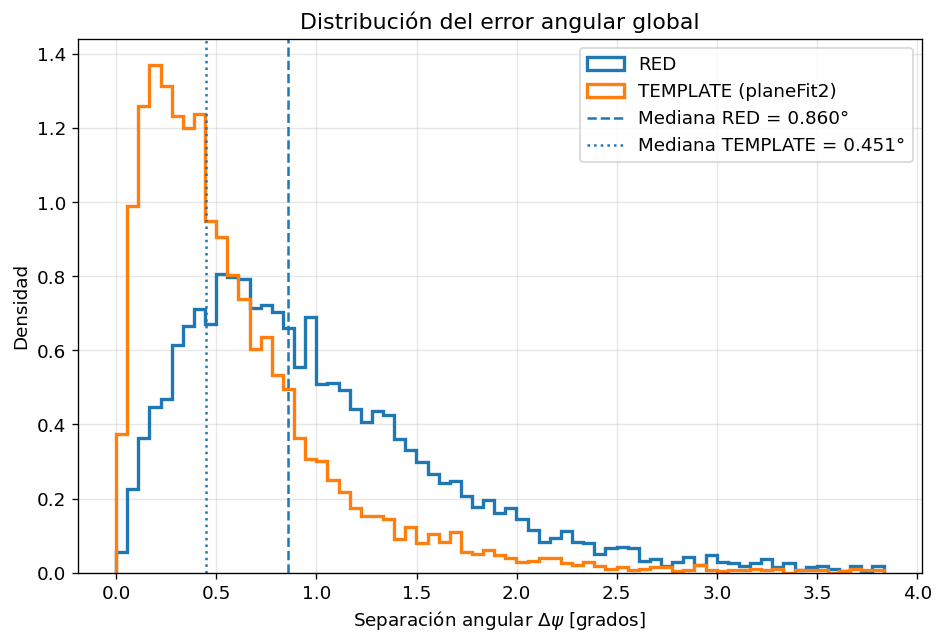

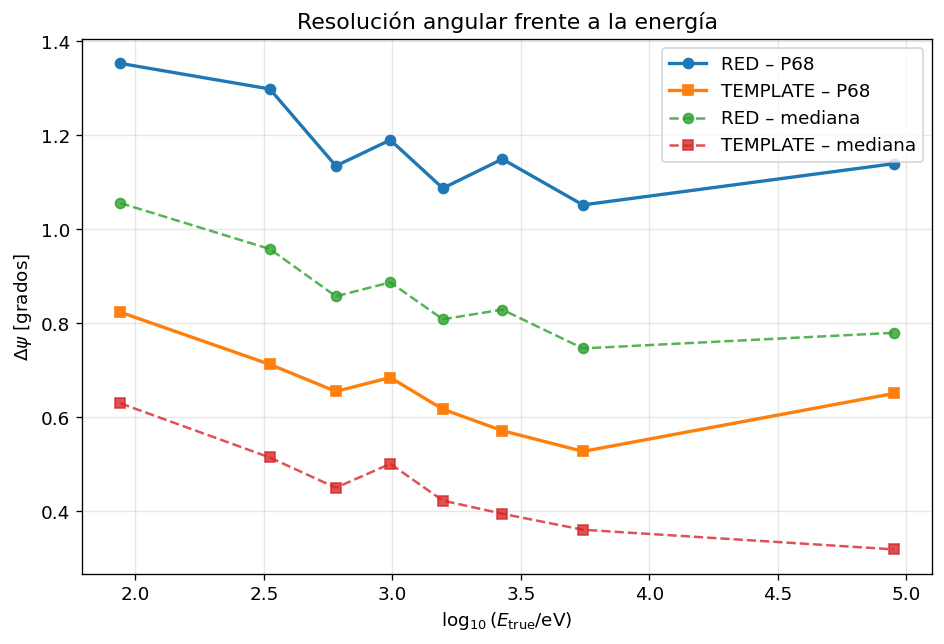

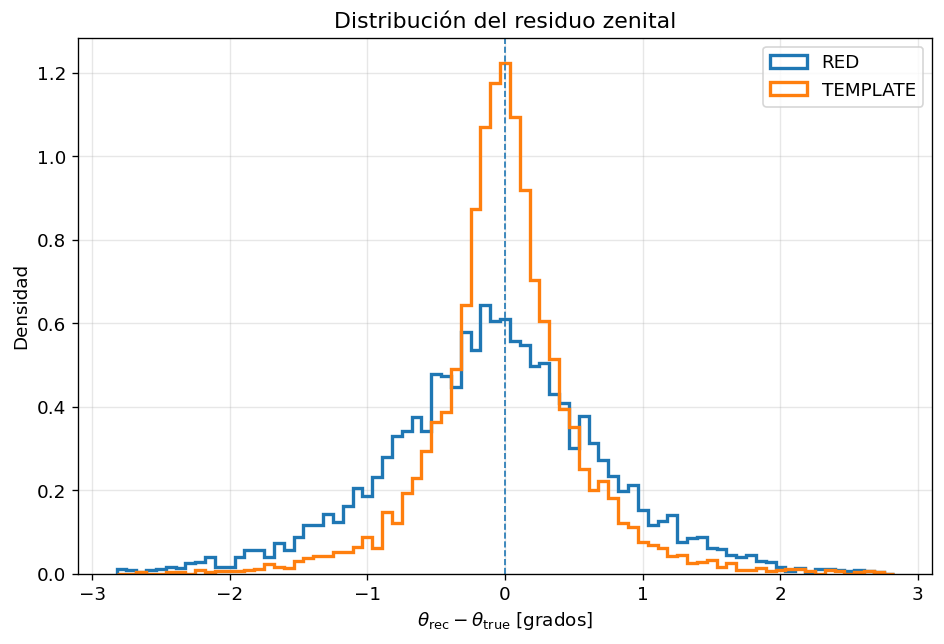

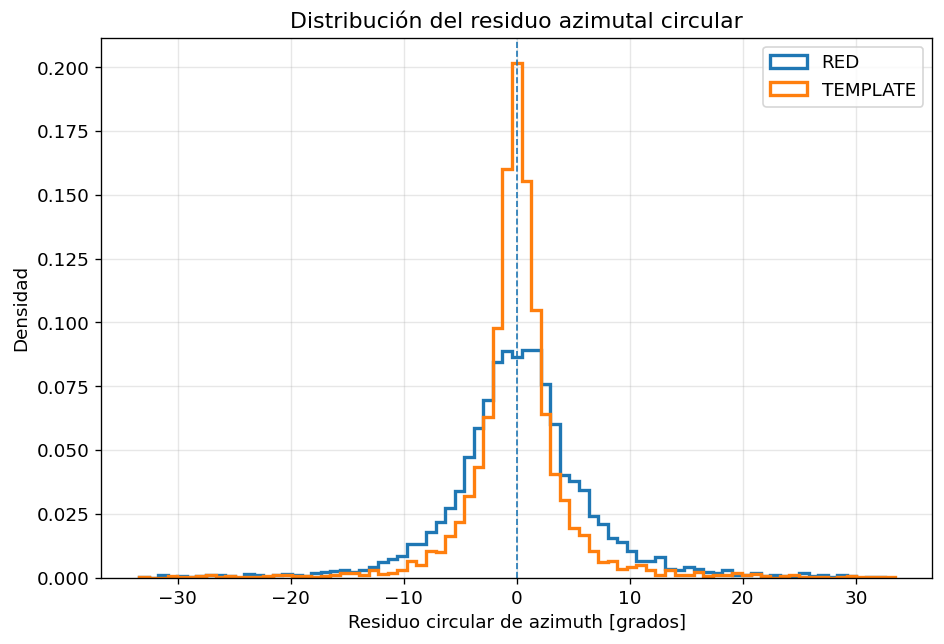

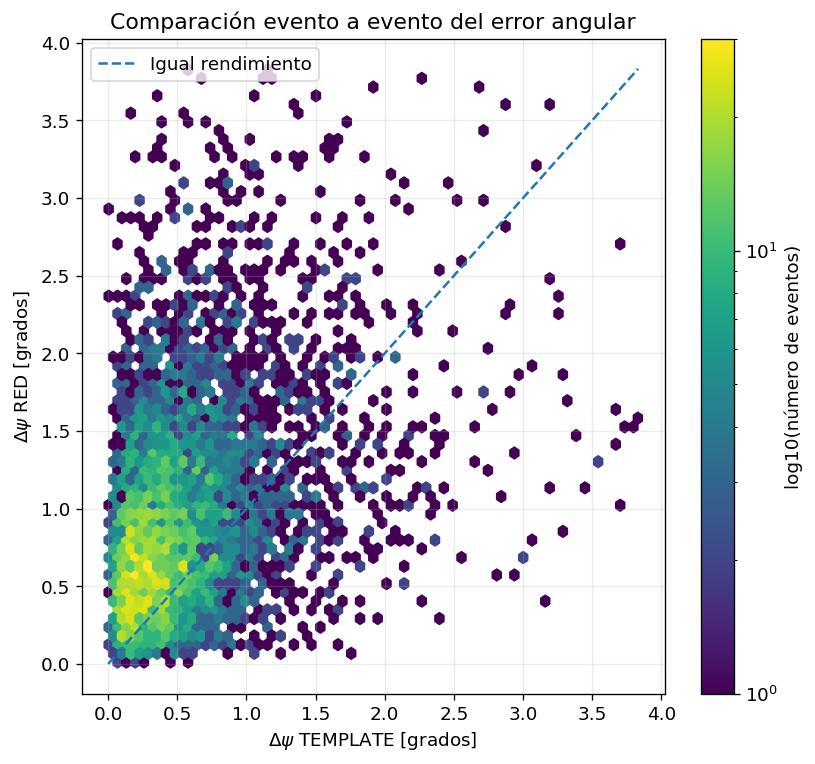

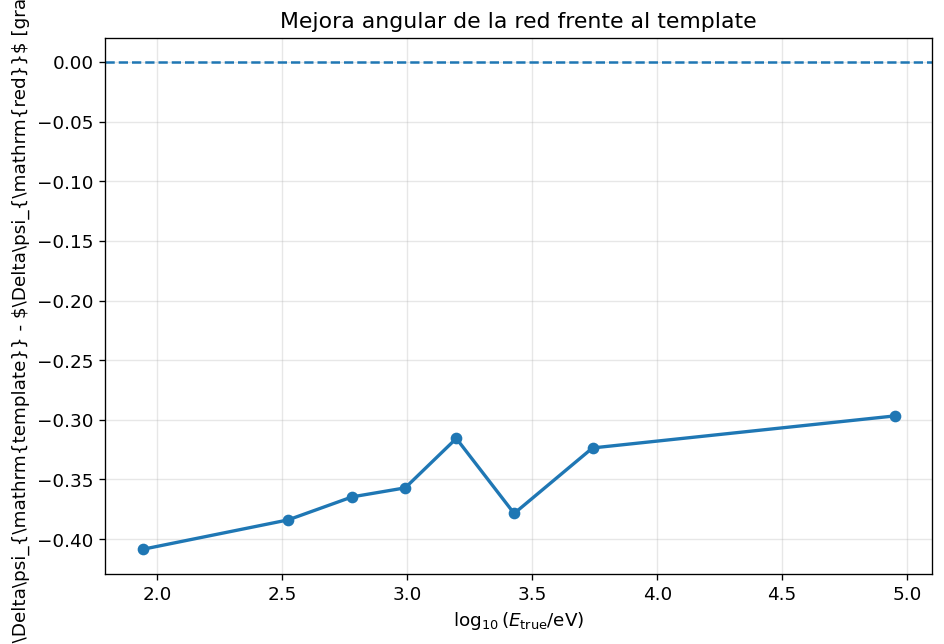

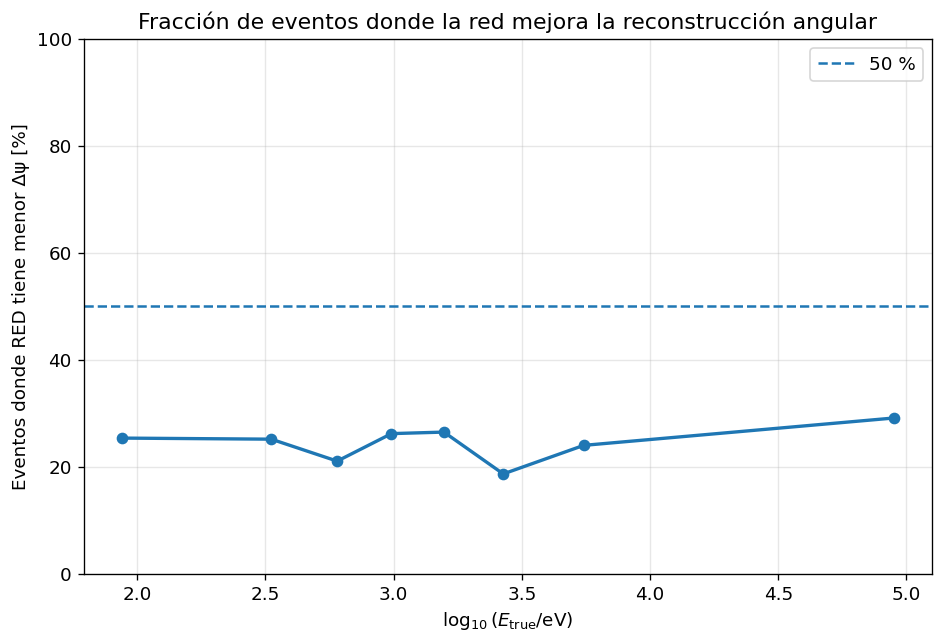


RESUMEN ANGULAR FINAL: RED VS TEMPLATE
N eventos                  : 5000

RED
  deltaPsi mediana         : 0.860213°
  deltaPsi P68             : 1.187547°
  deltaPsi P95             : 2.381709°

TEMPLATE
  deltaPsi mediana         : 0.450589°
  deltaPsi P68             : 0.665880°
  deltaPsi P95             : 1.707766°

COMPARACION
  Mejora en mediana        : -90.91 %
  Mejora en P68            : -78.34 %
  Mediana mejora/evento    : -0.354220°
  RED mejor evento a evento: 24.50 %

[OK] Comparación angular RED vs TEMPLATE terminada.

[saved] Tablas en: /content/gdrive/MyDrive/TFM/gamma_flow_outputs/angular_comparison


In [ ]:
#### COMPARACION ANGULAR FINAL: RED VS TEMPLATE ####
#### GRAFICAS PARA RESULTADOS Y CONCLUSIONES DEL APARTADO 9.3 ####
####
#### REQUIERE QUE LA CELDA ANTERIOR HAYA CREADO:
####
####     TEMPLATE_POINT
####
#### CON LOS VALORES REALES:
####
####     planeFit2.theta
####     planeFit2.phi
####
#### ESTA CELDA:
####
#### - NO LEE EL ROOT.
#### - NO ENTRENA.
#### - NO GENERA NUEVAS MUESTRAS DEL FLOW.
#### - USA EXACTAMENTE LOS EVENTOS YA EVALUADOS.
#### - USA RESIDUO CIRCULAR PARA AZIMUTH.
#### - USA deltaPsi COMO METRICA ANGULAR PRINCIPAL.
####


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


# ── Targets físicos ──────────────────────────────────────────────────────

ANGLE_COMPARE_TARGET_NAMES = [
    "coreX",
    "coreY",
    "zenithAngle",
    "azimuthAngle",
    "logEnergy",
]


EXPECTED_ANGLE_DIM = len(
    ANGLE_COMPARE_TARGET_NAMES
)


# ── Comprobar variables necesarias ───────────────────────────────────────

if "Y_TRUE" not in globals():

    raise RuntimeError(
        "Y_TRUE no existe."
    )


if (
    "TEMPLATE_POINT" not in globals()
    or
    TEMPLATE_POINT is None
):

    raise RuntimeError(
        "TEMPLATE_POINT no existe.\n"
        "La celda anterior debe terminar correctamente antes "
        "de ejecutar esta comparación."
    )


# ── Seleccionar predicción puntual de la red ─────────────────────────────

if (
    "Y_PRED_MEDIAN" in globals()
    and
    Y_PRED_MEDIAN is not None
):

    Y_RED_ANGLE = np.asarray(
        Y_PRED_MEDIAN,
        dtype=np.float64,
    )

    RED_POINT_LABEL = "mediana posterior"


elif (
    "Y_PRED" in globals()
    and
    Y_PRED is not None
):

    Y_RED_ANGLE = np.asarray(
        Y_PRED,
        dtype=np.float64,
    )

    RED_POINT_LABEL = "media posterior"


else:

    raise RuntimeError(
        "No existen Y_PRED_MEDIAN ni Y_PRED."
    )


Y_TRUE_ANGLE = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)


Y_TEMPLATE_ANGLE = np.asarray(
    TEMPLATE_POINT,
    dtype=np.float64,
)


# ── Comprobar dimensiones ────────────────────────────────────────────────

for array_name, array_value in [
    (
        "Y_TRUE_ANGLE",
        Y_TRUE_ANGLE,
    ),
    (
        "Y_RED_ANGLE",
        Y_RED_ANGLE,
    ),
    (
        "Y_TEMPLATE_ANGLE",
        Y_TEMPLATE_ANGLE,
    ),
]:

    if array_value.ndim != 2:

        raise ValueError(
            f"{array_name} debe ser 2D y tiene "
            f"shape {array_value.shape}."
        )


    if array_value.shape[1] != EXPECTED_ANGLE_DIM:

        raise ValueError(
            f"{array_name} tiene {array_value.shape[1]} columnas; "
            f"se esperaban 5 targets físicos."
        )


if Y_TRUE_ANGLE.shape != Y_RED_ANGLE.shape:

    raise ValueError(
        f"Y_TRUE {Y_TRUE_ANGLE.shape} y RED "
        f"{Y_RED_ANGLE.shape} no coinciden."
    )


if Y_TRUE_ANGLE.shape != Y_TEMPLATE_ANGLE.shape:

    raise ValueError(
        f"Y_TRUE {Y_TRUE_ANGLE.shape} y TEMPLATE "
        f"{Y_TEMPLATE_ANGLE.shape} no coinciden."
    )


# ── Máscara conjunta ─────────────────────────────────────────────────────

## SOLO SE ELIMINAN EVENTOS NO FINITOS.
##
## RED Y TEMPLATE SE COMPARAN SIEMPRE SOBRE LA MISMA MÁSCARA.

joint_mask_angle = (
    np.all(
        np.isfinite(
            Y_TRUE_ANGLE
        ),
        axis=1,
    )
    &
    np.all(
        np.isfinite(
            Y_RED_ANGLE
        ),
        axis=1,
    )
    &
    np.all(
        np.isfinite(
            Y_TEMPLATE_ANGLE
        ),
        axis=1,
    )
)


if joint_mask_angle.sum() == 0:

    raise ValueError(
        "No existen eventos válidos comunes."
    )


Y_TRUE_ANGLE = Y_TRUE_ANGLE[
    joint_mask_angle
]


Y_RED_ANGLE = Y_RED_ANGLE[
    joint_mask_angle
]


Y_TEMPLATE_ANGLE = Y_TEMPLATE_ANGLE[
    joint_mask_angle
]


N_ANGLE_COMPARE = len(
    Y_TRUE_ANGLE
)


print(
    f"Eventos comparados: {N_ANGLE_COMPARE}"
)


print(
    f"Predicción RED: {RED_POINT_LABEL}"
)


# ── Índices ──────────────────────────────────────────────────────────────

ix_zenith = ANGLE_COMPARE_TARGET_NAMES.index(
    "zenithAngle"
)


ix_azimuth = ANGLE_COMPARE_TARGET_NAMES.index(
    "azimuthAngle"
)


ix_logE = ANGLE_COMPARE_TARGET_NAMES.index(
    "logEnergy"
)


# ── Funciones angulares ──────────────────────────────────────────────────

def wrap_angle_difference(
    predicted,
    true,
):

    return np.arctan2(
        np.sin(
            predicted
            -
            true
        ),
        np.cos(
            predicted
            -
            true
        ),
    )


def spherical_angular_separation(
    true_theta,
    true_phi,
    pred_theta,
    pred_phi,
):

    delta_phi = wrap_angle_difference(
        pred_phi,
        true_phi,
    )


    cos_psi = (
        np.cos(
            true_theta
        )
        *
        np.cos(
            pred_theta
        )
        +
        np.sin(
            true_theta
        )
        *
        np.sin(
            pred_theta
        )
        *
        np.cos(
            delta_phi
        )
    )


    cos_psi = np.clip(
        cos_psi,
        -1.0,
        1.0,
    )


    return np.arccos(
        cos_psi
    )


def quantile_bins(
    x,
    n_bins=8,
):

    x = np.asarray(
        x,
        dtype=np.float64,
    )


    edges = np.quantile(
        x,
        np.linspace(
            0.0,
            1.0,
            n_bins + 1,
        ),
    )


    return np.unique(
        edges
    )


def binned_percentiles(
    x,
    values,
    edges,
):

    rows = []


    for i in range(
        len(edges) - 1
    ):

        lo = edges[
            i
        ]


        hi = edges[
            i + 1
        ]


        if i == len(
            edges
        ) - 2:

            mask = (
                (x >= lo)
                &
                (x <= hi)
            )


        else:

            mask = (
                (x >= lo)
                &
                (x < hi)
            )


        v = values[
            mask
        ]


        v = v[
            np.isfinite(
                v
            )
        ]


        if len(
            v
        ) == 0:

            continue


        rows.append(
            {
                "center":
                    0.5
                    *
                    (
                        lo
                        +
                        hi
                    ),

                "n":
                    len(
                        v
                    ),

                "median":
                    np.median(
                        v
                    ),

                "p68":
                    np.percentile(
                        v,
                        68,
                    ),

                "p95":
                    np.percentile(
                        v,
                        95,
                    ),
            }
        )


    return pd.DataFrame(
        rows
    )


# ── Variables angulares ──────────────────────────────────────────────────

theta_true = Y_TRUE_ANGLE[
    :,
    ix_zenith,
]


phi_true = Y_TRUE_ANGLE[
    :,
    ix_azimuth,
]


theta_red = Y_RED_ANGLE[
    :,
    ix_zenith,
]


phi_red = Y_RED_ANGLE[
    :,
    ix_azimuth,
]


theta_template = Y_TEMPLATE_ANGLE[
    :,
    ix_zenith,
]


phi_template = Y_TEMPLATE_ANGLE[
    :,
    ix_azimuth,
]


true_logE = Y_TRUE_ANGLE[
    :,
    ix_logE,
]


# ── Residuos zenith ──────────────────────────────────────────────────────

delta_theta_red_deg = np.rad2deg(
    theta_red
    -
    theta_true
)


delta_theta_template_deg = np.rad2deg(
    theta_template
    -
    theta_true
)


# ── Residuos azimuth circulares ──────────────────────────────────────────

delta_phi_red_deg = np.rad2deg(
    wrap_angle_difference(
        phi_red,
        phi_true,
    )
)


delta_phi_template_deg = np.rad2deg(
    wrap_angle_difference(
        phi_template,
        phi_true,
    )
)


# ── Separación angular deltaPsi ──────────────────────────────────────────

delta_psi_red_deg = np.rad2deg(
    spherical_angular_separation(
        theta_true,
        phi_true,
        theta_red,
        phi_red,
    )
)


delta_psi_template_deg = np.rad2deg(
    spherical_angular_separation(
        theta_true,
        phi_true,
        theta_template,
        phi_template,
    )
)


# ── Resumen numérico ─────────────────────────────────────────────────────

def angular_summary(
    values,
):

    values = np.asarray(
        values,
        dtype=np.float64,
    )


    return {
        "Media":
            np.mean(
                values
            ),

        "Mediana":
            np.median(
                values
            ),

        "P68":
            np.percentile(
                values,
                68,
            ),

        "P95":
            np.percentile(
                values,
                95,
            ),
    }


red_psi_stats = angular_summary(
    delta_psi_red_deg
)


template_psi_stats = angular_summary(
    delta_psi_template_deg
)


# ── Tabla resumen principal ───────────────────────────────────────────────

ANGLE_COMPARISON_SUMMARY = pd.DataFrame(
    [
        {
            "Métrica":
                "Zenith MAE",

            "RED":
                np.mean(
                    np.abs(
                        delta_theta_red_deg
                    )
                ),

            "TEMPLATE":
                np.mean(
                    np.abs(
                        delta_theta_template_deg
                    )
                ),

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "Zenith P68 |error|",

            "RED":
                np.percentile(
                    np.abs(
                        delta_theta_red_deg
                    ),
                    68,
                ),

            "TEMPLATE":
                np.percentile(
                    np.abs(
                        delta_theta_template_deg
                    ),
                    68,
                ),

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "Azimuth MAE circular",

            "RED":
                np.mean(
                    np.abs(
                        delta_phi_red_deg
                    )
                ),

            "TEMPLATE":
                np.mean(
                    np.abs(
                        delta_phi_template_deg
                    )
                ),

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "Azimuth P68 circular",

            "RED":
                np.percentile(
                    np.abs(
                        delta_phi_red_deg
                    ),
                    68,
                ),

            "TEMPLATE":
                np.percentile(
                    np.abs(
                        delta_phi_template_deg
                    ),
                    68,
                ),

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "deltaPsi mediana",

            "RED":
                red_psi_stats[
                    "Mediana"
                ],

            "TEMPLATE":
                template_psi_stats[
                    "Mediana"
                ],

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "deltaPsi P68",

            "RED":
                red_psi_stats[
                    "P68"
                ],

            "TEMPLATE":
                template_psi_stats[
                    "P68"
                ],

            "Unidad":
                "deg",
        },

        {
            "Métrica":
                "deltaPsi P95",

            "RED":
                red_psi_stats[
                    "P95"
                ],

            "TEMPLATE":
                template_psi_stats[
                    "P95"
                ],

            "Unidad":
                "deg",
        },
    ]
)


ANGLE_COMPARISON_SUMMARY[
    "Mejora_RED_%"
] = (
    (
        ANGLE_COMPARISON_SUMMARY[
            "TEMPLATE"
        ]
        -
        ANGLE_COMPARISON_SUMMARY[
            "RED"
        ]
    )
    /
    ANGLE_COMPARISON_SUMMARY[
        "TEMPLATE"
    ]
    *
    100.0
)


print(
    "\nTABLA ANGULAR RED VS TEMPLATE"
)


display(
    ANGLE_COMPARISON_SUMMARY.round(
        5
    )
)


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 1
# DISTRIBUCIÓN DE deltaPsi RED VS TEMPLATE
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


## LIMITAR SOLO LA VISUALIZACIÓN AL P99 PARA QUE LAS COLAS
## EXTREMAS NO OCULTEN LA DISTRIBUCIÓN PRINCIPAL.

psi_display_limit = max(
    np.percentile(
        delta_psi_red_deg,
        99,
    ),
    np.percentile(
        delta_psi_template_deg,
        99,
    ),
)


bins_psi = np.linspace(
    0.0,
    psi_display_limit,
    70,
)


ax.hist(
    delta_psi_red_deg[
        delta_psi_red_deg <= psi_display_limit
    ],
    bins=bins_psi,
    density=True,
    histtype="step",
    linewidth=2,
    label="RED",
)


ax.hist(
    delta_psi_template_deg[
        delta_psi_template_deg <= psi_display_limit
    ],
    bins=bins_psi,
    density=True,
    histtype="step",
    linewidth=2,
    label="TEMPLATE (planeFit2)",
)


ax.axvline(
    np.median(
        delta_psi_red_deg
    ),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mediana RED = "
        f"{np.median(delta_psi_red_deg):.3f}°"
    ),
)


ax.axvline(
    np.median(
        delta_psi_template_deg
    ),
    linestyle=":",
    linewidth=1.5,
    label=(
        f"Mediana TEMPLATE = "
        f"{np.median(delta_psi_template_deg):.3f}°"
    ),
)


ax.set_xlabel(
    r"Separación angular $\Delta\psi$ [grados]"
)


ax.set_ylabel(
    "Densidad"
)


ax.set_title(
    "Distribución del error angular global"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 2
# RESOLUCIÓN ANGULAR VS ENERGÍA
# ══════════════════════════════════════════════════════════════════════════

energy_edges = quantile_bins(
    true_logE,
    n_bins=8,
)


red_energy_stats = binned_percentiles(
    true_logE,
    delta_psi_red_deg,
    energy_edges,
)


template_energy_stats = binned_percentiles(
    true_logE,
    delta_psi_template_deg,
    energy_edges,
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


ax.plot(
    red_energy_stats[
        "center"
    ],
    red_energy_stats[
        "p68"
    ],
    marker="o",
    linewidth=2,
    label="RED – P68",
)


ax.plot(
    template_energy_stats[
        "center"
    ],
    template_energy_stats[
        "p68"
    ],
    marker="s",
    linewidth=2,
    label="TEMPLATE – P68",
)


ax.plot(
    red_energy_stats[
        "center"
    ],
    red_energy_stats[
        "median"
    ],
    marker="o",
    linestyle="--",
    alpha=0.8,
    label="RED – mediana",
)


ax.plot(
    template_energy_stats[
        "center"
    ],
    template_energy_stats[
        "median"
    ],
    marker="s",
    linestyle="--",
    alpha=0.8,
    label="TEMPLATE – mediana",
)


ax.set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}}/\mathrm{eV})$"
)


ax.set_ylabel(
    r"$\Delta\psi$ [grados]"
)


ax.set_title(
    "Resolución angular frente a la energía"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 3
# ZENITH: RESIDUOS RED VS TEMPLATE
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


zenith_limit = max(
    np.percentile(
        np.abs(
            delta_theta_red_deg
        ),
        99,
    ),
    np.percentile(
        np.abs(
            delta_theta_template_deg
        ),
        99,
    ),
)


zenith_bins = np.linspace(
    -zenith_limit,
    zenith_limit,
    80,
)


ax.hist(
    delta_theta_red_deg[
        np.abs(
            delta_theta_red_deg
        )
        <=
        zenith_limit
    ],
    bins=zenith_bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="RED",
)


ax.hist(
    delta_theta_template_deg[
        np.abs(
            delta_theta_template_deg
        )
        <=
        zenith_limit
    ],
    bins=zenith_bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="TEMPLATE",
)


ax.axvline(
    0.0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    r"$\theta_{\mathrm{rec}}-\theta_{\mathrm{true}}$ [grados]"
)


ax.set_ylabel(
    "Densidad"
)


ax.set_title(
    "Distribución del residuo zenital"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 4
# AZIMUTH: RESIDUOS CIRCULARES RED VS TEMPLATE
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


azimuth_limit = max(
    np.percentile(
        np.abs(
            delta_phi_red_deg
        ),
        99,
    ),
    np.percentile(
        np.abs(
            delta_phi_template_deg
        ),
        99,
    ),
)


azimuth_bins = np.linspace(
    -azimuth_limit,
    azimuth_limit,
    80,
)


ax.hist(
    delta_phi_red_deg[
        np.abs(
            delta_phi_red_deg
        )
        <=
        azimuth_limit
    ],
    bins=azimuth_bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="RED",
)


ax.hist(
    delta_phi_template_deg[
        np.abs(
            delta_phi_template_deg
        )
        <=
        azimuth_limit
    ],
    bins=azimuth_bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="TEMPLATE",
)


ax.axvline(
    0.0,
    linestyle="--",
    linewidth=1,
)


ax.set_xlabel(
    r"Residuo circular de azimuth [grados]"
)


ax.set_ylabel(
    "Densidad"
)


ax.set_title(
    "Distribución del residuo azimutal circular"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 5
# COMPARACIÓN EVENTO A EVENTO DE deltaPsi
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(
        7,
        6.5,
    )
)


display_limit_event = max(
    np.percentile(
        delta_psi_red_deg,
        99,
    ),
    np.percentile(
        delta_psi_template_deg,
        99,
    ),
)


event_display_mask = (
    (delta_psi_red_deg <= display_limit_event)
    &
    (delta_psi_template_deg <= display_limit_event)
)


hb = ax.hexbin(
    delta_psi_template_deg[
        event_display_mask
    ],
    delta_psi_red_deg[
        event_display_mask
    ],
    gridsize=60,
    mincnt=1,
    bins="log",
)


ax.plot(
    [
        0.0,
        display_limit_event,
    ],
    [
        0.0,
        display_limit_event,
    ],
    "--",
    linewidth=1.5,
    label="Igual rendimiento",
)


fig.colorbar(
    hb,
    ax=ax,
    label="log10(número de eventos)",
)


ax.set_xlabel(
    r"$\Delta\psi$ TEMPLATE [grados]"
)


ax.set_ylabel(
    r"$\Delta\psi$ RED [grados]"
)


ax.set_title(
    "Comparación evento a evento del error angular"
)


ax.grid(
    alpha=0.25
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 6
# MEJORA RELATIVA DE LA RED FRENTE AL TEMPLATE VS ENERGÍA
# ══════════════════════════════════════════════════════════════════════════

## VALOR POSITIVO:
##
##     TEMPLATE tiene más error -> RED mejora.
##
## VALOR NEGATIVO:
##
##     RED tiene más error -> TEMPLATE mejora.

delta_improvement_deg = (
    delta_psi_template_deg
    -
    delta_psi_red_deg
)


improvement_energy_rows = []


for i in range(
    len(
        energy_edges
    ) - 1
):

    lo = energy_edges[
        i
    ]


    hi = energy_edges[
        i + 1
    ]


    if i == len(
        energy_edges
    ) - 2:

        mask = (
            (true_logE >= lo)
            &
            (true_logE <= hi)
        )


    else:

        mask = (
            (true_logE >= lo)
            &
            (true_logE < hi)
        )


    improvement_values = delta_improvement_deg[
        mask
    ]


    if len(
        improvement_values
    ) == 0:

        continue


    improvement_energy_rows.append(
        {
            "center":
                0.5
                *
                (
                    lo
                    +
                    hi
                ),

            "median_improvement_deg":
                np.median(
                    improvement_values
                ),

            "fraction_red_better":
                np.mean(
                    improvement_values
                    >
                    0
                ),
        }
    )


IMPROVEMENT_VS_ENERGY_DF = pd.DataFrame(
    improvement_energy_rows
)


fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


ax.plot(
    IMPROVEMENT_VS_ENERGY_DF[
        "center"
    ],
    IMPROVEMENT_VS_ENERGY_DF[
        "median_improvement_deg"
    ],
    marker="o",
    linewidth=2,
)


ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.5,
)


ax.set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}}/\mathrm{eV})$"
)


ax.set_ylabel(
    r"$\Delta\psi_{\mathrm{template}}"
    r" - "
    r"$\Delta\psi_{\mathrm{red}}$ [grados]"
)


ax.set_title(
    "Mejora angular de la red frente al template"
)


ax.grid(
    alpha=0.3
)


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# FIGURA 7
# FRACCIÓN DE EVENTOS EN LOS QUE LA RED SUPERA AL TEMPLATE
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


ax.plot(
    IMPROVEMENT_VS_ENERGY_DF[
        "center"
    ],
    100.0
    *
    IMPROVEMENT_VS_ENERGY_DF[
        "fraction_red_better"
    ],
    marker="o",
    linewidth=2,
)


ax.axhline(
    50.0,
    linestyle="--",
    linewidth=1.5,
    label="50 %",
)


ax.set_ylim(
    0,
    100,
)


ax.set_xlabel(
    r"$\log_{10}(E_{\mathrm{true}}/\mathrm{eV})$"
)


ax.set_ylabel(
    "Eventos donde RED tiene menor Δψ [%]"
)


ax.set_title(
    "Fracción de eventos donde la red mejora la reconstrucción angular"
)


ax.grid(
    alpha=0.3
)


ax.legend()


plt.tight_layout()


plt.show()


# ══════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL PARA SACAR CONCLUSIONES
# ══════════════════════════════════════════════════════════════════════════

fraction_red_better_global = np.mean(
    delta_psi_red_deg
    <
    delta_psi_template_deg
)


median_improvement_deg = np.median(
    delta_psi_template_deg
    -
    delta_psi_red_deg
)


p68_improvement_percent = (
    (
        np.percentile(
            delta_psi_template_deg,
            68,
        )
        -
        np.percentile(
            delta_psi_red_deg,
            68,
        )
    )
    /
    np.percentile(
        delta_psi_template_deg,
        68,
    )
    *
    100.0
)


median_improvement_percent = (
    (
        np.median(
            delta_psi_template_deg
        )
        -
        np.median(
            delta_psi_red_deg
        )
    )
    /
    np.median(
        delta_psi_template_deg
    )
    *
    100.0
)


print(
    "\n"
    +
    "=" * 86
)


print(
    "RESUMEN ANGULAR FINAL: RED VS TEMPLATE"
)


print(
    "=" * 86
)


print(
    f"N eventos                  : "
    f"{N_ANGLE_COMPARE}"
)


print(
    "\nRED"
)


print(
    f"  deltaPsi mediana         : "
    f"{np.median(delta_psi_red_deg):.6f}°"
)


print(
    f"  deltaPsi P68             : "
    f"{np.percentile(delta_psi_red_deg, 68):.6f}°"
)


print(
    f"  deltaPsi P95             : "
    f"{np.percentile(delta_psi_red_deg, 95):.6f}°"
)


print(
    "\nTEMPLATE"
)


print(
    f"  deltaPsi mediana         : "
    f"{np.median(delta_psi_template_deg):.6f}°"
)


print(
    f"  deltaPsi P68             : "
    f"{np.percentile(delta_psi_template_deg, 68):.6f}°"
)


print(
    f"  deltaPsi P95             : "
    f"{np.percentile(delta_psi_template_deg, 95):.6f}°"
)


print(
    "\nCOMPARACION"
)


print(
    f"  Mejora en mediana        : "
    f"{median_improvement_percent:.2f} %"
)


print(
    f"  Mejora en P68            : "
    f"{p68_improvement_percent:.2f} %"
)


print(
    f"  Mediana mejora/evento    : "
    f"{median_improvement_deg:.6f}°"
)


print(
    f"  RED mejor evento a evento: "
    f"{100.0 * fraction_red_better_global:.2f} %"
)


print(
    "\n[OK] Comparación angular RED vs TEMPLATE terminada."
)


# ── Guardar tablas ────────────────────────────────────────────────────────

if "artifact_path" in globals():

    ANGLE_COMPARE_DIR = Path(
        artifact_path(
            "angular_comparison",
            run_specific=False,
        )
    )


else:

    ANGLE_COMPARE_DIR = Path(
        "angular_comparison"
    )


ANGLE_COMPARE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


ANGLE_COMPARISON_SUMMARY.to_csv(
    ANGLE_COMPARE_DIR
    /
    "angular_red_vs_template_summary.csv",
    index=False,
)


red_energy_stats.to_csv(
    ANGLE_COMPARE_DIR
    /
    "angular_resolution_red_vs_energy.csv",
    index=False,
)


template_energy_stats.to_csv(
    ANGLE_COMPARE_DIR
    /
    "angular_resolution_template_vs_energy.csv",
    index=False,
)


IMPROVEMENT_VS_ENERGY_DF.to_csv(
    ANGLE_COMPARE_DIR
    /
    "angular_improvement_vs_energy.csv",
    index=False,
)


print(
    f"\n[saved] Tablas en: {ANGLE_COMPARE_DIR}"
)

In [ ]:
###############################################################################
## CÁLCULO DE DESVIACIONES TÍPICAS
###############################################################################

import numpy as np


## ARRAYS FÍSICOS ##
Y_TRUE_STD = np.asarray(
    Y_TRUE,
    dtype=np.float64,
)

Y_RED_STD = np.asarray(
    Y_POINT,
    dtype=np.float64,
)

Y_PLANTILLAS_STD = np.asarray(
    TEMPLATE_POINT,
    dtype=np.float64,
)


## ÍNDICES FÍSICOS:
##
## 0 -> coreX
## 1 -> coreY
## 2 -> zenithAngle
## 3 -> azimuthAngle
## 4 -> logEnergy


# ── Error espacial bidimensional del core ────────────────────────────────

core_error_red = np.sqrt(
    (
        Y_RED_STD[:, 0]
        -
        Y_TRUE_STD[:, 0]
    ) ** 2
    +
    (
        Y_RED_STD[:, 1]
        -
        Y_TRUE_STD[:, 1]
    ) ** 2
)


core_error_plantillas = np.sqrt(
    (
        Y_PLANTILLAS_STD[:, 0]
        -
        Y_TRUE_STD[:, 0]
    ) ** 2
    +
    (
        Y_PLANTILLAS_STD[:, 1]
        -
        Y_TRUE_STD[:, 1]
    ) ** 2
)


# ── Radio verdadero y reconstruido ───────────────────────────────────────

R_TRUE_STD = np.sqrt(
    Y_TRUE_STD[:, 0] ** 2
    +
    Y_TRUE_STD[:, 1] ** 2
)


R_RED_STD = np.sqrt(
    Y_RED_STD[:, 0] ** 2
    +
    Y_RED_STD[:, 1] ** 2
)


R_PLANTILLAS_STD = np.sqrt(
    Y_PLANTILLAS_STD[:, 0] ** 2
    +
    Y_PLANTILLAS_STD[:, 1] ** 2
)


radial_residual_red = (
    R_RED_STD
    -
    R_TRUE_STD
)


radial_residual_plantillas = (
    R_PLANTILLAS_STD
    -
    R_TRUE_STD
)


# ── Residuo energético ────────────────────────────────────────────────────

energy_residual_red = (
    Y_RED_STD[:, 4]
    -
    Y_TRUE_STD[:, 4]
)


energy_residual_plantillas = (
    Y_PLANTILLAS_STD[:, 4]
    -
    Y_TRUE_STD[:, 4]
)


# ── Máscara de eventos periféricos ───────────────────────────────────────

mask_600 = (
    R_TRUE_STD
    >=
    600.0
)


# ── RESULTADOS ────────────────────────────────────────────────────────────

print(
    "============================================================"
)

print(
    " DESVIACIONES TÍPICAS - CONJUNTO COMPLETO"
)

print(
    "============================================================"
)


print(
    f"Error espacial core - Red        : "
    f"{np.std(core_error_red):.4f} m"
)

print(
    f"Error espacial core - Plantillas : "
    f"{np.std(core_error_plantillas):.4f} m"
)


print()

print(
    f"Residuo radial - Red             : "
    f"{np.std(radial_residual_red):.4f} m"
)

print(
    f"Residuo radial - Plantillas      : "
    f"{np.std(radial_residual_plantillas):.4f} m"
)


print()

print(
    f"Residuo logEnergy - Red          : "
    f"{np.std(energy_residual_red):.4f}"
)

print(
    f"Residuo logEnergy - Plantillas   : "
    f"{np.std(energy_residual_plantillas):.4f}"
)


print()

print(
    "============================================================"
)

print(
    " DESVIACIONES TÍPICAS - R_true >= 600 m"
)

print(
    "============================================================"
)


print(
    f"N eventos                           : "
    f"{np.sum(mask_600)}"
)


print()

print(
    f"Error espacial core - Red           : "
    f"{np.std(core_error_red[mask_600]):.4f} m"
)

print(
    f"Error espacial core - Plantillas    : "
    f"{np.std(core_error_plantillas[mask_600]):.4f} m"
)


print()

print(
    f"Residuo radial - Red                : "
    f"{np.std(radial_residual_red[mask_600]):.4f} m"
)

print(
    f"Residuo radial - Plantillas         : "
    f"{np.std(radial_residual_plantillas[mask_600]):.4f} m"
)


print()

print(
    f"Residuo logEnergy - Red             : "
    f"{np.std(energy_residual_red[mask_600]):.4f}"
)

print(
    f"Residuo logEnergy - Plantillas      : "
    f"{np.std(energy_residual_plantillas[mask_600]):.4f}"
)

 DESVIACIONES TÍPICAS - CONJUNTO COMPLETO
Error espacial core - Red        : 15.0966 m
Error espacial core - Plantillas : 15.6184 m

Residuo radial - Red             : 15.8626 m
Residuo radial - Plantillas      : 15.0472 m

Residuo logEnergy - Red          : 0.1517
Residuo logEnergy - Plantillas   : 0.1865

 DESVIACIONES TÍPICAS - R_true >= 600 m
N eventos                           : 221

Error espacial core - Red           : 32.8051 m
Error espacial core - Plantillas    : 37.8956 m

Residuo radial - Red                : 36.9265 m
Residuo radial - Plantillas         : 37.9547 m

Residuo logEnergy - Red             : 0.1702
Residuo logEnergy - Plantillas      : 0.1821


[INFO] TARGET_NAMES actual del notebook: ['coreX', 'coreY', 'zenithAngle', 'azimuthAngle', 'logEnergy']
[INFO] Para esta celda se utilizarán independientemente los 6 targets internos: ['coreX', 'coreY', 'sinZenith', 'sinAzimuth', 'cosAzimuth', 'logEnergy']

[OK] TARGET_SCALER contiene 6 variables.


Evaluating internal 6D coverage:   0%|          | 0/2500 [00:00<?, ?it/s]


 COBERTURA DE LOS 6 TARGETS INTERNOS
Eventos evaluados : 5000
Muestras/evento   : 50
Targets internos  : coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy

Cobertura nominal esperada: 68.0 %


,target,unit,nominal_coverage,empirical_coverage,coverage_percent,calibration_error,absolute_calibration_error,n_valid_events,n_inside,n_outside,mean_interval_width,median_interval_width,p16_interval_width,p84_interval_width
0,coreX,m,0.68,0.6606,66.06,-0.0194,0.0194,5000,3303,1697,24.014331,20.748117,12.058325,34.426843
1,coreY,m,0.68,0.6118,61.18,-0.0682,0.0682,5000,3059,1941,21.754900,18.899307,10.990760,31.013418
2,sinZenith,adimensional,0.68,0.6408,64.08,-0.0392,0.0392,5000,3204,1796,0.024839,0.023208,0.015843,0.033245
3,sinAzimuth,adimensional,0.68,0.6242,62.42,-0.0558,0.0558,5000,3121,1879,0.123360,0.091267,0.032852,0.189873
4,cosAzimuth,adimensional,0.68,0.6258,62.58,-0.0542,0.0542,5000,3129,1871,0.116799,0.089554,0.032239,0.179692
5,logEnergy,log10(E / GeV),0.68,0.6346,63.46,-0.0454,0.0454,5000,3173,1827,0.251395,0.233479,0.158087,0.350541



RESUMEN DE COBERTURA DE LOS 6 TARGETS
  coreX           :  66.06 % (3303 de 5000); error= -1.94 puntos; cobertura próxima al nivel nominal.
  coreY           :  61.18 % (3059 de 5000); error= -6.82 puntos; intervalo demasiado estrecho; modelo demasiado seguro.
  sinZenith       :  64.08 % (3204 de 5000); error= -3.92 puntos; cobertura próxima al nivel nominal.
  sinAzimuth      :  62.42 % (3121 de 5000); error= -5.58 puntos; intervalo demasiado estrecho; modelo demasiado seguro.
  cosAzimuth      :  62.58 % (3129 de 5000); error= -5.42 puntos; intervalo demasiado estrecho; modelo demasiado seguro.
  logEnergy       :  63.46 % (3173 de 5000); error= -4.54 puntos; cobertura próxima al nivel nominal.
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/01_internal_coverage_by_target.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/01_internal_coverage_by_target.pdf


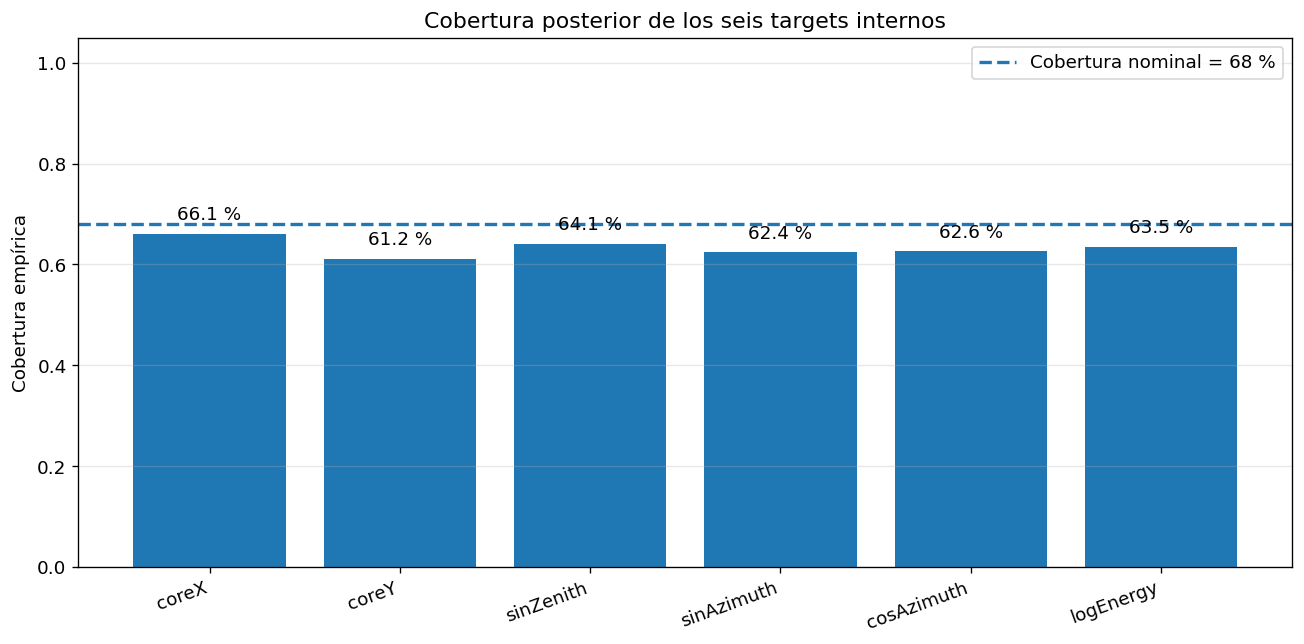

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/02_internal_calibration_error.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/02_internal_calibration_error.pdf


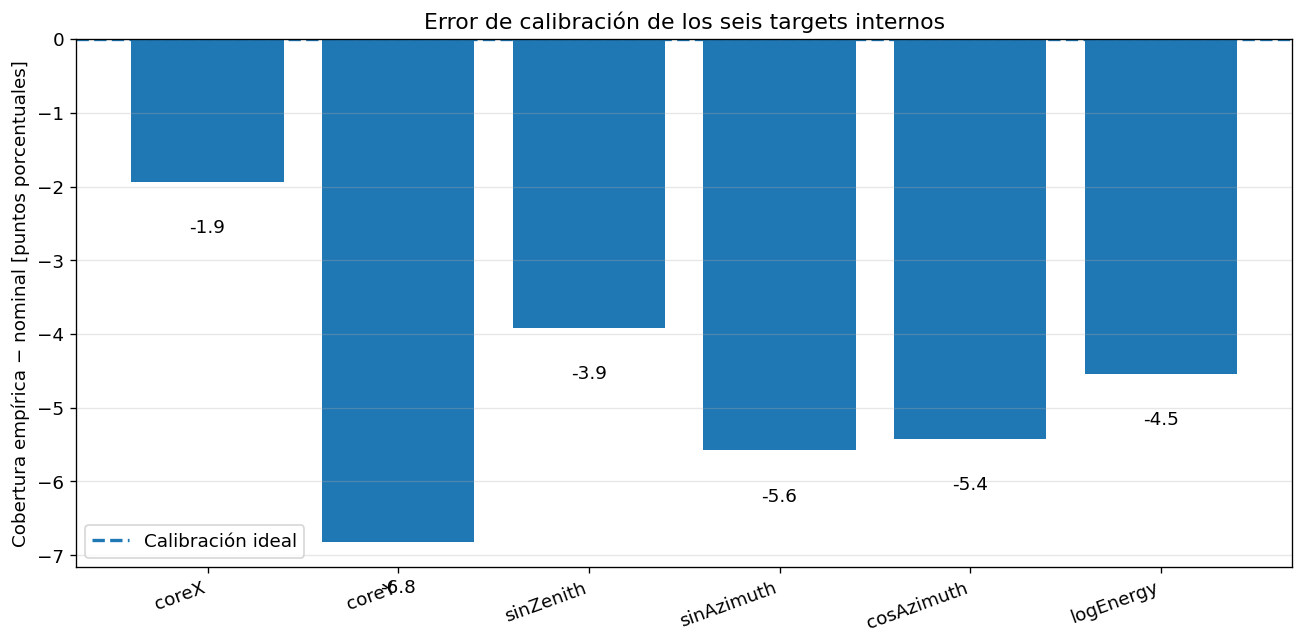

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/03_internal_event_target_matrix.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/03_internal_event_target_matrix.pdf


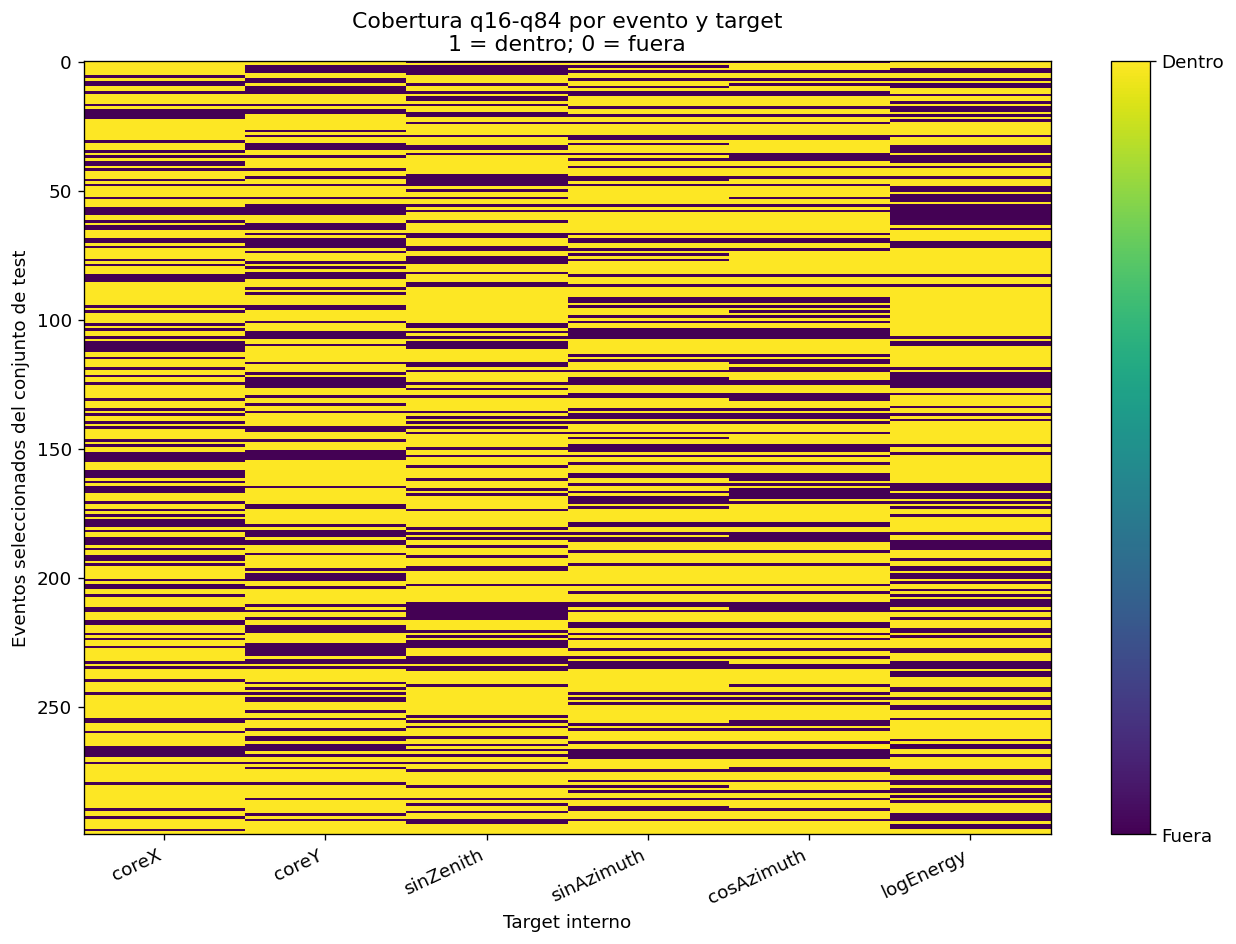

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_coreX.pdf


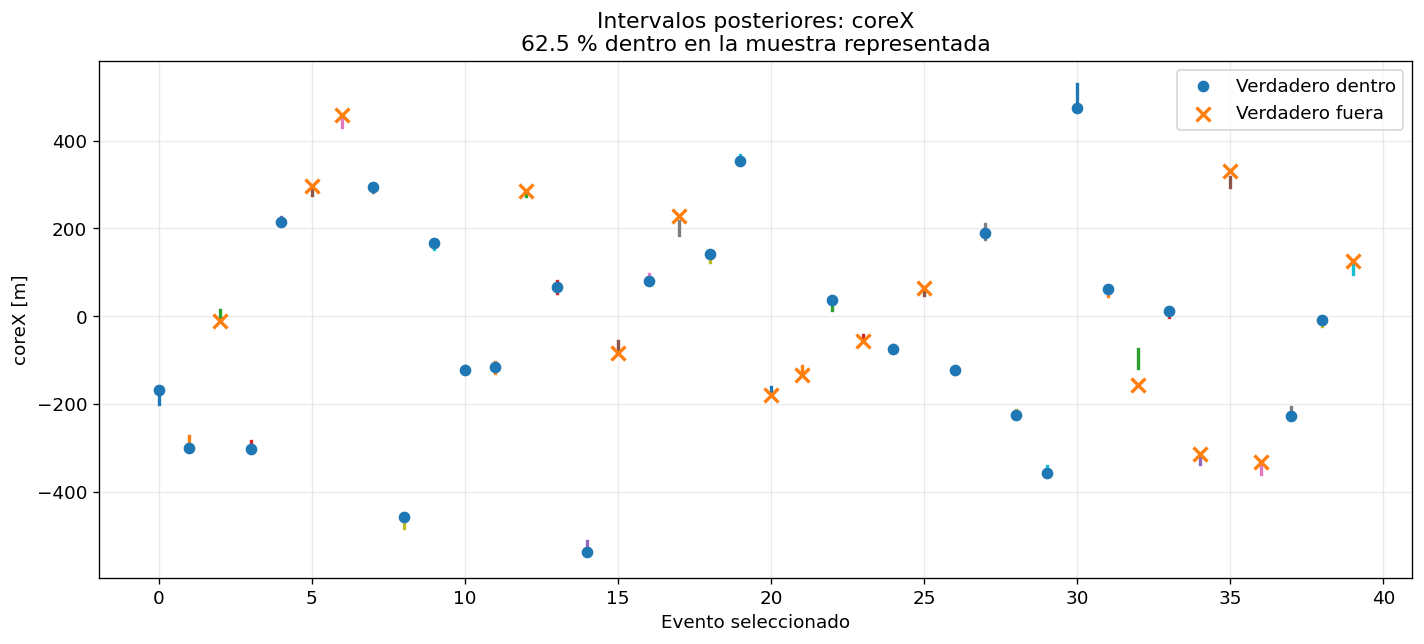

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_coreY.pdf


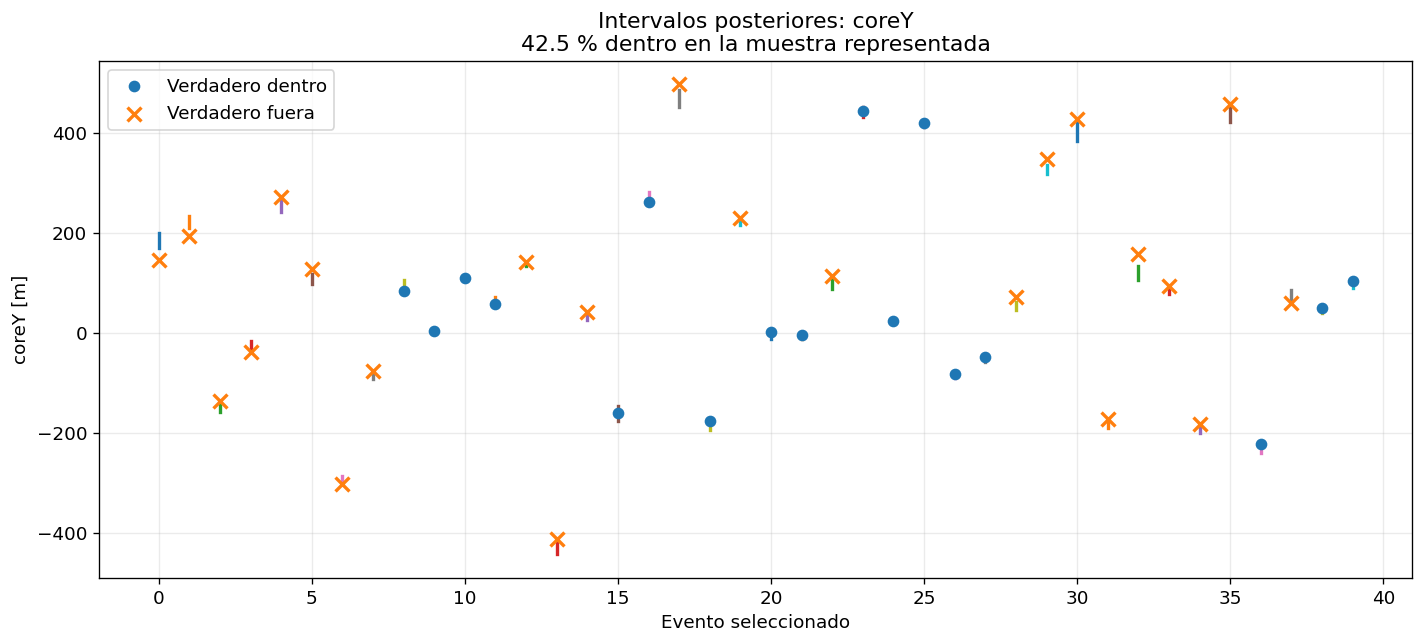

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_sinZenith.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_sinZenith.pdf


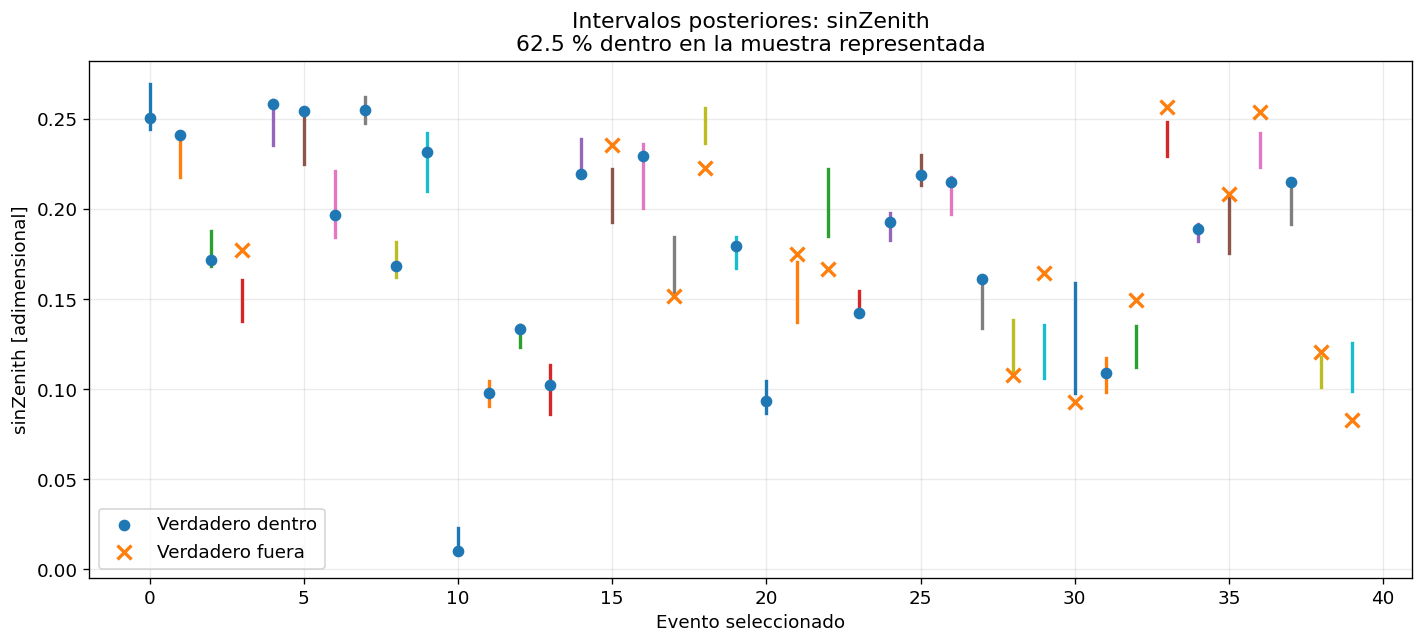

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_sinAzimuth.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_sinAzimuth.pdf


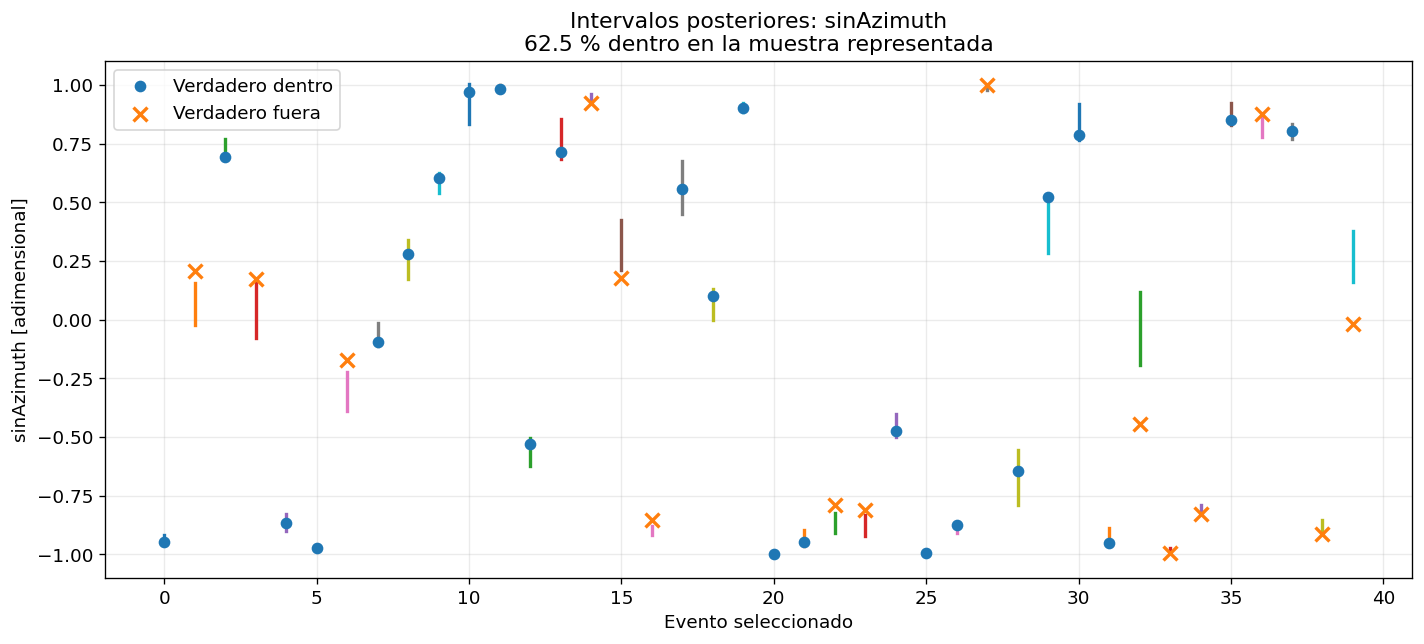

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_cosAzimuth.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_cosAzimuth.pdf


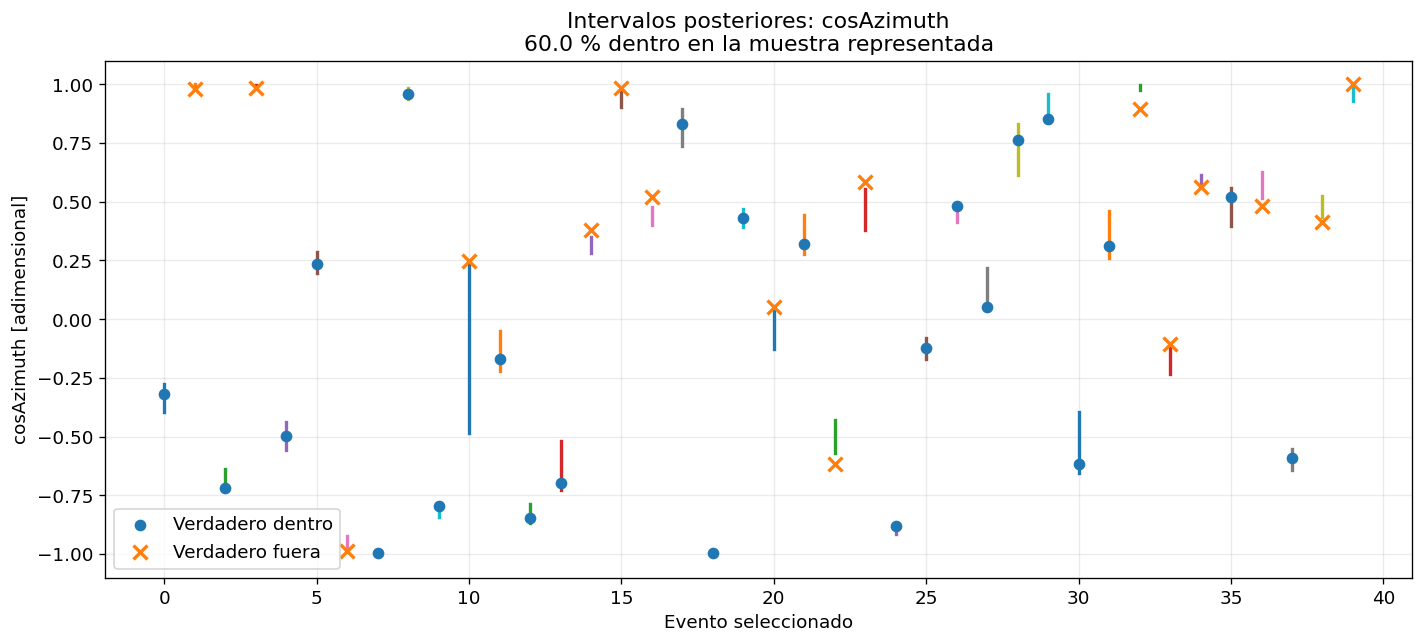

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/04_internal_intervals_logEnergy.pdf


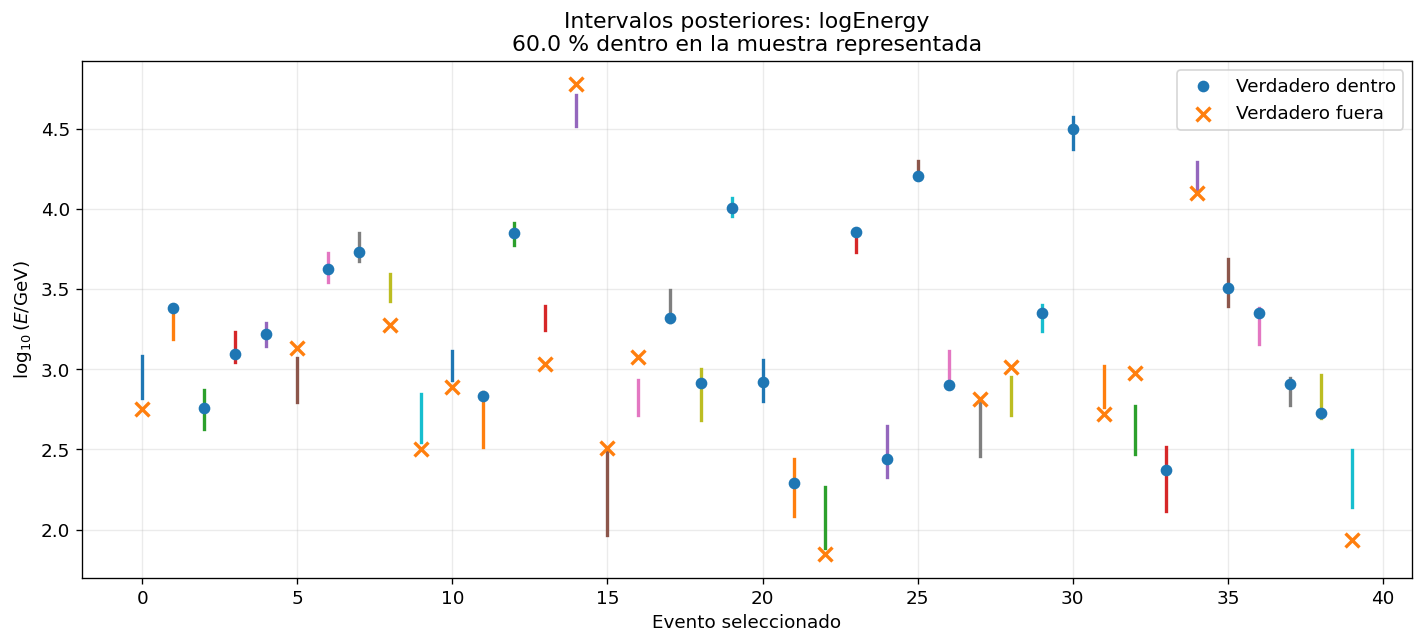

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_coreX.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_coreX.pdf


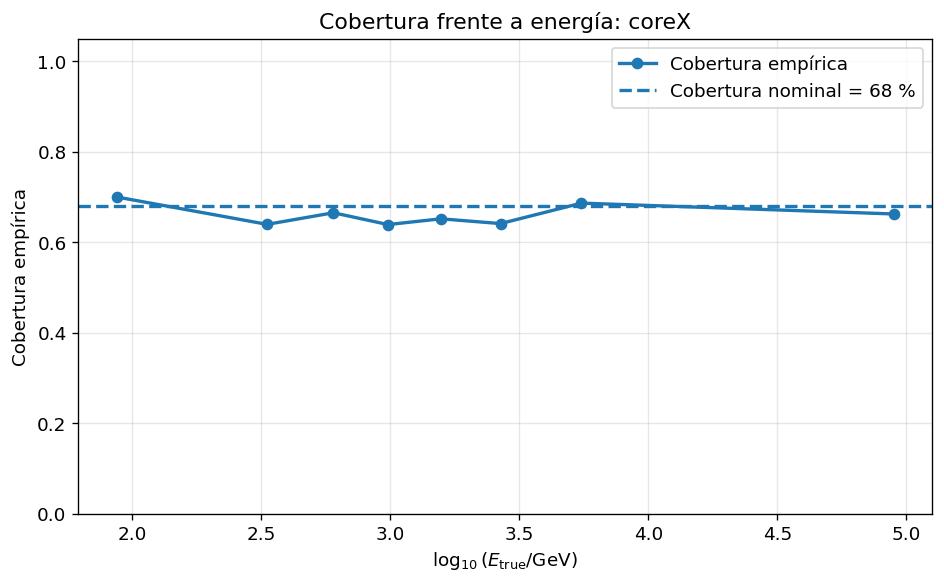

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_coreY.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_coreY.pdf


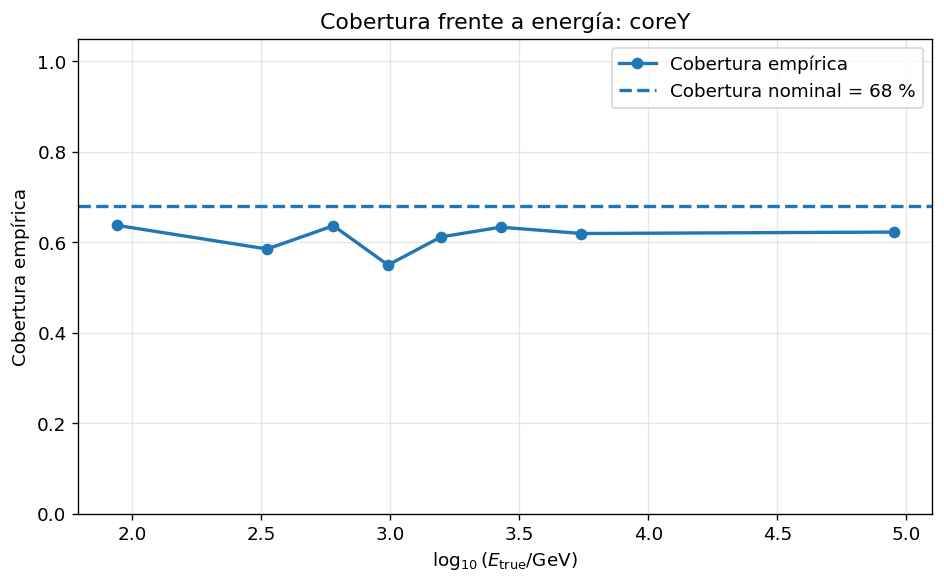

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_sinZenith.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_sinZenith.pdf


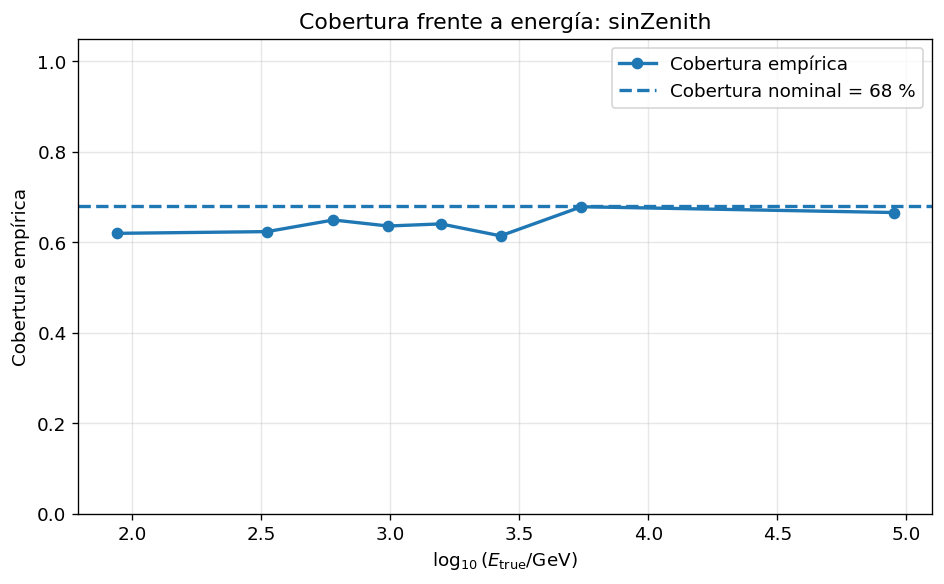

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_sinAzimuth.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_sinAzimuth.pdf


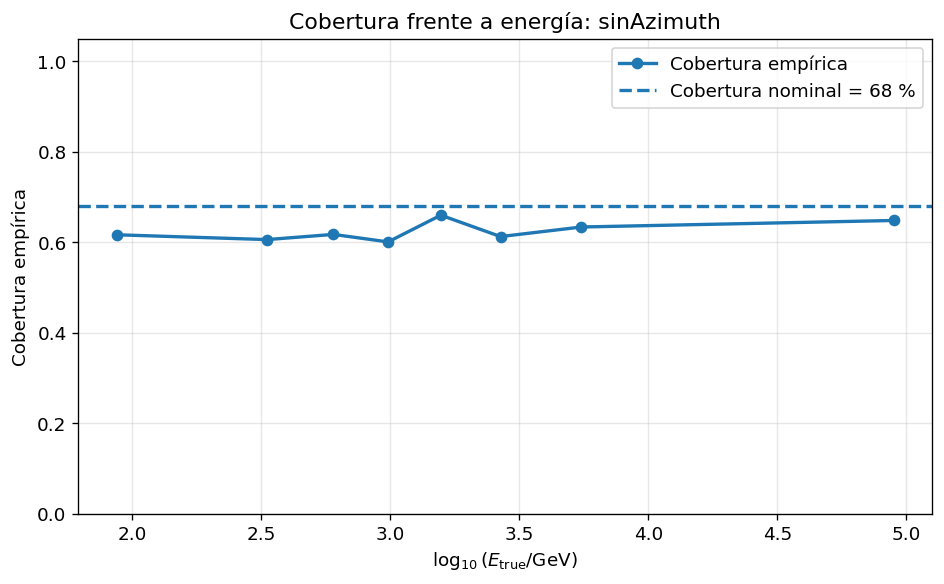

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_cosAzimuth.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_cosAzimuth.pdf


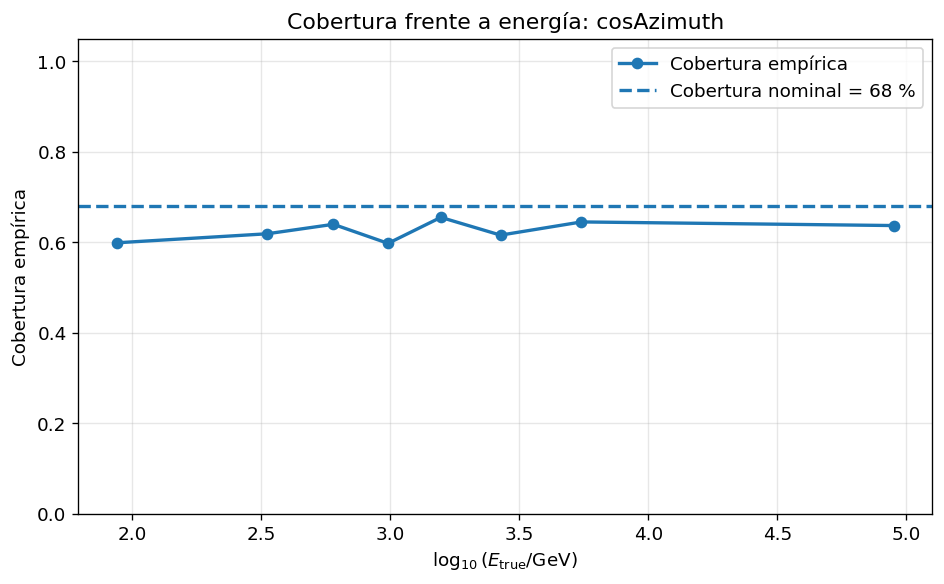

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_logEnergy.png
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/05_internal_coverage_vs_energy_logEnergy.pdf


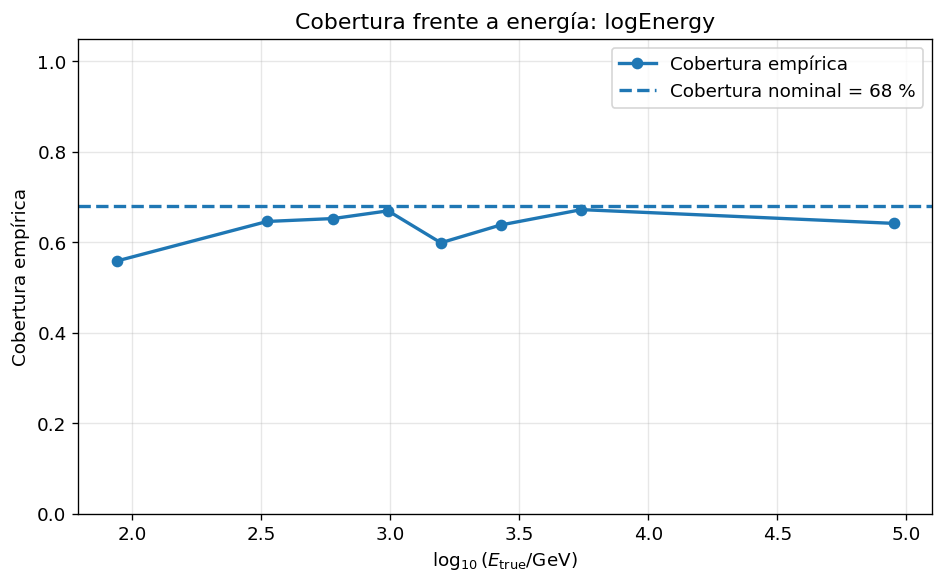


 COBERTURA CONJUNTA
Eventos con los seis targets simultáneamente dentro: 11.72 %

IMPORTANTE: este valor NO debe compararse directamente con 68 %.
El 68 % corresponde a la cobertura marginal de cada target.

[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/internal_6d_coverage_summary.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/internal_6d_coverage_by_event.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/internal_6d_coverage_vs_energy.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/internal_uncertainty_coverage/internal_6d_posterior_statistics.npz

 ANÁLISIS DE COBERTURA INTERNA FINALIZADO
[OK] Se han evaluado los 6 targets internos del Flow.
[OK] Targets: coreX, coreY, sinZenith, sinAzimuth, cosAzimuth y logEnergy.
[OK] TARGET_NAMES físico no se utiliza para determinar la dimensionalidad interna.
[OK] La dimensionalidad interna se comprueba directamente

In [ ]:
###############################################################################
## COMPROBACIÓN DE COBERTURA DE INCERTIDUMBRE EN LOS 6 TARGETS INTERNOS
##
## OBJETIVO:
##
## Comprobar directamente la calibración de las seis variables que aprende
## el Normalizing Flow:
##
##     coreX
##     coreY
##     sinZenith
##     sinAzimuth
##     cosAzimuth
##     logEnergy
##
## A diferencia de la evaluación física final:
##
##     [coreX, coreY, zenithAngle, azimuthAngle, logEnergy]
##
## este bloque NO transforma las muestras mediante trig_to_physical().
##
## Se trabaja directamente en la representación interna del Flow:
##
##     [coreX, coreY, sinZenith, sinAzimuth, cosAzimuth, logEnergy]
##
## Esto permite analizar correctamente la cobertura marginal q16-q84
## de las SEIS variables utilizadas durante el entrenamiento.
##
## IMPORTANTE:
##
## - TARGET_NAMES puede contener los 5 targets físicos de evaluación.
## - Por ello NO se utiliza TARGET_NAMES para identificar los targets internos.
## - Los targets internos se definen de forma independiente en este bloque.
## - Los targets verdaderos proceden exclusivamente del conjunto de test.
## - No se ajusta ni modifica el modelo.
## - No se utilizan reconstrucciones convencionales como entrada.
## - No existe leakage.
## - Los intervalos estudiados son los intervalos posteriores originales.
##
## La energía se representa como:
##
##     logEnergy = log10(E / GeV)
###############################################################################


import warnings
from pathlib import Path
from typing import Dict, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm


###############################################################################
## 1. DEFINICIÓN DE LOS 6 TARGETS INTERNOS
###############################################################################

INTERNAL_COVERAGE_TARGET_NAMES = [
    'coreX',
    'coreY',
    'sinZenith',
    'sinAzimuth',
    'cosAzimuth',
    'logEnergy',
]


INTERNAL_COVERAGE_TARGET_UNITS = [
    'm',
    'm',
    'adimensional',
    'adimensional',
    'adimensional',
    'log10(E / GeV)',
]


N_INTERNAL_COVERAGE_TARGETS = len(
    INTERNAL_COVERAGE_TARGET_NAMES
)


## IMPORTANTE:
##
## TARGET_NAMES NO SE COMPRUEBA AQUÍ.
##
## En el notebook actual TARGET_NAMES puede contener:
##
##     coreX
##     coreY
##     zenithAngle
##     azimuthAngle
##     logEnergy
##
## porque corresponde al espacio FÍSICO utilizado para evaluación.
##
## Este bloque trabaja, en cambio, directamente con los seis targets
## INTERNOS que salen del dataset y utiliza el Flow.


if 'TARGET_NAMES' in globals():

    print(
        '[INFO] TARGET_NAMES actual del notebook: '
        f'{list(TARGET_NAMES)}'
    )


    print(
        '[INFO] Para esta celda se utilizarán independientemente '
        'los 6 targets internos: '
        f'{INTERNAL_COVERAGE_TARGET_NAMES}'
    )


###############################################################################
## 2. COMPROBAR VARIABLES NECESARIAS
###############################################################################

REQUIRED_INTERNAL_COVERAGE_VARIABLES = [
    'MODEL',
    'TARGET_SCALER',
    'eval_loader',
    'DEVICE',
    'CFG',
]


MISSING_INTERNAL_COVERAGE_VARIABLES = [
    variable_name
    for variable_name in REQUIRED_INTERNAL_COVERAGE_VARIABLES
    if variable_name not in globals()
]


if MISSING_INTERNAL_COVERAGE_VARIABLES:

    raise NameError(
        'Faltan variables necesarias para calcular la cobertura '
        'de los targets internos:\n'
        +
        '\n'.join(
            f'  - {variable_name}'
            for variable_name
            in MISSING_INTERNAL_COVERAGE_VARIABLES
        )
    )


###############################################################################
## 3. COMPROBAR QUE TARGET_SCALER ES DE 6 DIMENSIONES
###############################################################################

if not hasattr(
    TARGET_SCALER,
    'mean_',
):

    raise ValueError(
        'TARGET_SCALER no parece estar ajustado: '
        'no contiene el atributo mean_.'
    )


if len(
    TARGET_SCALER.mean_
) != N_INTERNAL_COVERAGE_TARGETS:

    raise ValueError(
        'TARGET_SCALER no contiene los seis targets internos.\n'
        f'Dimensión encontrada: {len(TARGET_SCALER.mean_)}\n'
        f'Dimensión esperada  : {N_INTERNAL_COVERAGE_TARGETS}'
    )


print()

print(
    '[OK] TARGET_SCALER contiene 6 variables.'
)


###############################################################################
## 4. CONFIGURACIÓN
###############################################################################

## COBERTURA NOMINAL q16-q84 ##
NOMINAL_INTERNAL_COVERAGE = 0.68


## UTILIZAR EL MISMO NÚMERO DE MUESTRAS QUE EN LA EVALUACIÓN PRINCIPAL ##
INTERNAL_COVERAGE_N_SAMPLES = CFG.get(
    'eval_n_samples',
    50,
)


## TAMAÑO DE CHUNK DE MUESTREO ##
INTERNAL_COVERAGE_SAMPLE_CHUNK = CFG.get(
    'eval_sample_chunk',
    10,
)


## MÁXIMO DE EVENTOS PARA MATRIZ VISUAL ##
INTERNAL_COVERAGE_MATRIX_MAX_EVENTS = CFG.get(
    'coverage_matrix_max_events',
    300,
)


## EVENTOS REPRESENTADOS CON INTERVALOS ##
INTERNAL_INTERVAL_PLOT_N_EVENTS = CFG.get(
    'interval_plot_n_events',
    40,
)


## BINS DE ENERGÍA ##
INTERNAL_COVERAGE_ENERGY_BINS = CFG.get(
    'coverage_energy_bins',
    8,
)


## DPI ##
INTERNAL_COVERAGE_PLOT_DPI = CFG.get(
    'coverage_plot_dpi',
    160,
)


## SEMILLA ##
INTERNAL_COVERAGE_RANDOM_SEED = CFG.get(
    'random_seed',
    42,
)


###############################################################################
## 5. DIRECTORIO DE SALIDA
###############################################################################

if 'artifact_path' in globals():

    INTERNAL_COVERAGE_OUTPUT_DIR = Path(
        artifact_path(
            'internal_uncertainty_coverage',
            run_specific=False,
        )
    )


else:

    INTERNAL_COVERAGE_OUTPUT_DIR = Path(
        'internal_uncertainty_coverage'
    )


INTERNAL_COVERAGE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


###############################################################################
## 6. FUNCIÓN DE GUARDADO
###############################################################################

def save_internal_coverage_figure(
    figure: plt.Figure,
    filename: str,
) -> None:

    if not CFG.get(
        'save_artifacts',
        True,
    ):

        return


    png_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        f'{filename}.png'
    )


    pdf_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        f'{filename}.pdf'
    )


    figure.savefig(
        png_path,
        dpi=INTERNAL_COVERAGE_PLOT_DPI,
        bbox_inches='tight',
    )


    figure.savefig(
        pdf_path,
        bbox_inches='tight',
    )


    print(
        f'[saved] {png_path}'
    )


    print(
        f'[saved] {pdf_path}'
    )


###############################################################################
## 7. EVALUACIÓN DEL FLOW EN SU ESPACIO INTERNO 6D
###############################################################################

def evaluate_internal_posterior(
    model,
    loader,
    target_scaler,
    n_samples: int,
    sample_chunk_size: int,
):

    ## MODO EVALUACIÓN ##
    model.eval()


    all_true_internal = []

    all_mean_internal = []

    all_median_internal = []

    all_std_internal = []

    all_q16_internal = []

    all_q84_internal = []


    if DEVICE.type == 'cuda':

        torch.cuda.empty_cache()


    with torch.no_grad():

        for hits, mask, targets in tqdm(
            loader,
            desc='Evaluating internal 6D coverage',
        ):

            hits = hits.to(
                DEVICE,
                non_blocking=False,
            )


            mask = mask.to(
                DEVICE,
                non_blocking=False,
            )


            ###################################################################
            ## TARGET VERDADERO INTERNO
            ###################################################################

            targets_scaled = targets.detach().cpu().numpy()


            if (
                targets_scaled.ndim != 2
                or
                targets_scaled.shape[1]
                !=
                N_INTERNAL_COVERAGE_TARGETS
            ):

                raise ValueError(
                    'Los targets que devuelve eval_loader no tienen '
                    'dimensión 6.\n'
                    f'Forma encontrada : {targets_scaled.shape}\n'
                    f'Forma esperada   : (batch, 6)\n\n'
                    'Esto indicaría que eval_loader está utilizando '
                    'targets físicos en lugar de los targets internos '
                    'empleados durante el entrenamiento.'
                )


            targets_internal = target_scaler.inverse_transform(
                targets_scaled
            )


            all_true_internal.append(
                targets_internal
            )


            ###################################################################
            ## MUESTREAR POSTERIOR INTERNA
            ###################################################################

            batch_samples_internal = []


            remaining = int(
                n_samples
            )


            while remaining > 0:

                n_now = min(
                    sample_chunk_size,
                    remaining,
                )


                samples_scaled = model.sample(
                    hits,
                    mask,
                    n_samples=n_now,
                )


                samples_scaled = (
                    samples_scaled
                    .detach()
                    .cpu()
                    .numpy()
                )


                if (
                    samples_scaled.ndim != 3
                    or
                    samples_scaled.shape[2]
                    !=
                    N_INTERNAL_COVERAGE_TARGETS
                ):

                    raise ValueError(
                        'Las muestras generadas por el Flow no tienen '
                        'forma (n_samples, batch, 6).\n'
                        f'Forma encontrada: {samples_scaled.shape}'
                    )


                ns = samples_scaled.shape[0]

                batch_size = samples_scaled.shape[1]

                n_targets = samples_scaled.shape[2]


                ################################################################
                ## DESESCALAR PERO NO PASAR A VARIABLES FÍSICAS
                ################################################################

                samples_internal = target_scaler.inverse_transform(
                    samples_scaled.reshape(
                        ns
                        *
                        batch_size,
                        n_targets,
                    )
                ).reshape(
                    ns,
                    batch_size,
                    n_targets,
                )


                batch_samples_internal.append(
                    samples_internal
                )


                remaining -= n_now


                del samples_scaled
                del samples_internal


            ###################################################################
            ## UNIR CHUNKS
            ###################################################################

            batch_samples_internal = np.concatenate(
                batch_samples_internal,
                axis=0,
            )


            ###################################################################
            ## ESTADÍSTICOS DE LOS 6 TARGETS INTERNOS
            ###################################################################

            batch_mean = np.mean(
                batch_samples_internal,
                axis=0,
            )


            batch_median = np.median(
                batch_samples_internal,
                axis=0,
            )


            ## std EN float64 PARA EVITAR OVERFLOW NUMÉRICO ##
            batch_std = np.std(
                np.asarray(
                    batch_samples_internal,
                    dtype=np.float64,
                ),
                axis=0,
            )


            batch_q16 = np.percentile(
                batch_samples_internal,
                16,
                axis=0,
            )


            batch_q84 = np.percentile(
                batch_samples_internal,
                84,
                axis=0,
            )


            all_mean_internal.append(
                batch_mean
            )


            all_median_internal.append(
                batch_median
            )


            all_std_internal.append(
                batch_std
            )


            all_q16_internal.append(
                batch_q16
            )


            all_q84_internal.append(
                batch_q84
            )


            del hits
            del mask
            del targets
            del batch_samples_internal


    ###########################################################################
    ## CONCATENAR TODOS LOS EVENTOS
    ###########################################################################

    y_true_internal = np.concatenate(
        all_true_internal,
        axis=0,
    )


    y_mean_internal = np.concatenate(
        all_mean_internal,
        axis=0,
    )


    y_median_internal = np.concatenate(
        all_median_internal,
        axis=0,
    )


    y_std_internal = np.concatenate(
        all_std_internal,
        axis=0,
    )


    y_q16_internal = np.concatenate(
        all_q16_internal,
        axis=0,
    )


    y_q84_internal = np.concatenate(
        all_q84_internal,
        axis=0,
    )


    return (
        y_true_internal,
        y_mean_internal,
        y_median_internal,
        y_std_internal,
        y_q16_internal,
        y_q84_internal,
    )


###############################################################################
## 8. CALCULAR POSTERIORES INTERNAS
###############################################################################

(
    Y_TRUE_INTERNAL,
    Y_MEAN_INTERNAL,
    Y_MEDIAN_INTERNAL,
    Y_STD_INTERNAL,
    Y_Q16_INTERNAL,
    Y_Q84_INTERNAL,
) = evaluate_internal_posterior(
    MODEL,
    eval_loader,
    TARGET_SCALER,
    n_samples=INTERNAL_COVERAGE_N_SAMPLES,
    sample_chunk_size=INTERNAL_COVERAGE_SAMPLE_CHUNK,
)


###############################################################################
## 9. COMPROBAR DIMENSIONES
###############################################################################

for array_name, array_value in [
    (
        'Y_TRUE_INTERNAL',
        Y_TRUE_INTERNAL,
    ),
    (
        'Y_MEAN_INTERNAL',
        Y_MEAN_INTERNAL,
    ),
    (
        'Y_MEDIAN_INTERNAL',
        Y_MEDIAN_INTERNAL,
    ),
    (
        'Y_STD_INTERNAL',
        Y_STD_INTERNAL,
    ),
    (
        'Y_Q16_INTERNAL',
        Y_Q16_INTERNAL,
    ),
    (
        'Y_Q84_INTERNAL',
        Y_Q84_INTERNAL,
    ),
]:

    if (
        array_value.ndim != 2
        or
        array_value.shape[1]
        !=
        N_INTERNAL_COVERAGE_TARGETS
    ):

        raise ValueError(
            f'{array_name} tiene forma {array_value.shape}; '
            'se esperaba (N, 6).'
        )


if not (
    len(
        Y_TRUE_INTERNAL
    )
    ==
    len(
        Y_Q16_INTERNAL
    )
    ==
    len(
        Y_Q84_INTERNAL
    )
):

    raise ValueError(
        'Los arrays internos no contienen '
        'el mismo número de eventos.'
    )


print()

print(
    '============================================================'
)


print(
    ' COBERTURA DE LOS 6 TARGETS INTERNOS'
)


print(
    '============================================================'
)


print(
    f'Eventos evaluados : '
    f'{len(Y_TRUE_INTERNAL)}'
)


print(
    f'Muestras/evento   : '
    f'{INTERNAL_COVERAGE_N_SAMPLES}'
)


print(
    'Targets internos  : '
    +
    ', '.join(
        INTERNAL_COVERAGE_TARGET_NAMES
    )
)


###############################################################################
## 10. FUNCIÓN PARA CALCULAR COBERTURA
###############################################################################

def calculate_internal_coverage_table(
    y_true: np.ndarray,
    y_low: np.ndarray,
    y_high: np.ndarray,
    target_names: Sequence[str],
    target_units: Sequence[str],
    nominal_coverage: float,
) -> Tuple[pd.DataFrame, np.ndarray]:

    y_true = np.asarray(
        y_true,
        dtype=np.float64,
    )


    y_low = np.asarray(
        y_low,
        dtype=np.float64,
    )


    y_high = np.asarray(
        y_high,
        dtype=np.float64,
    )


    inside_matrix = (
        (y_true >= y_low)
        &
        (y_true <= y_high)
        &
        np.isfinite(
            y_true
        )
        &
        np.isfinite(
            y_low
        )
        &
        np.isfinite(
            y_high
        )
    )


    rows = []


    for target_index, (
        target_name,
        target_unit,
    ) in enumerate(
        zip(
            target_names,
            target_units,
        )
    ):

        true_values = y_true[
            :,
            target_index,
        ]


        low_values = y_low[
            :,
            target_index,
        ]


        high_values = y_high[
            :,
            target_index,
        ]


        finite = (
            np.isfinite(
                true_values
            )
            &
            np.isfinite(
                low_values
            )
            &
            np.isfinite(
                high_values
            )
        )


        n_valid = int(
            finite.sum()
        )


        if n_valid == 0:

            rows.append(
                {
                    'target':
                        target_name,

                    'unit':
                        target_unit,

                    'nominal_coverage':
                        nominal_coverage,

                    'empirical_coverage':
                        np.nan,

                    'coverage_percent':
                        np.nan,

                    'calibration_error':
                        np.nan,

                    'absolute_calibration_error':
                        np.nan,

                    'n_valid_events':
                        0,

                    'n_inside':
                        0,

                    'n_outside':
                        0,

                    'mean_interval_width':
                        np.nan,

                    'median_interval_width':
                        np.nan,

                    'p16_interval_width':
                        np.nan,

                    'p84_interval_width':
                        np.nan,
                }
            )


            continue


        inside_values = (
            (
                true_values[
                    finite
                ]
                >=
                low_values[
                    finite
                ]
            )
            &
            (
                true_values[
                    finite
                ]
                <=
                high_values[
                    finite
                ]
            )
        )


        n_inside = int(
            inside_values.sum()
        )


        n_outside = int(
            n_valid
            -
            n_inside
        )


        empirical_coverage = (
            n_inside
            /
            n_valid
        )


        interval_width = (
            high_values[
                finite
            ]
            -
            low_values[
                finite
            ]
        )


        rows.append(
            {
                'target':
                    target_name,

                'unit':
                    target_unit,

                'nominal_coverage':
                    nominal_coverage,

                'empirical_coverage':
                    empirical_coverage,

                'coverage_percent':
                    empirical_coverage
                    *
                    100.0,

                'calibration_error':
                    empirical_coverage
                    -
                    nominal_coverage,

                'absolute_calibration_error':
                    abs(
                        empirical_coverage
                        -
                        nominal_coverage
                    ),

                'n_valid_events':
                    n_valid,

                'n_inside':
                    n_inside,

                'n_outside':
                    n_outside,

                'mean_interval_width':
                    float(
                        np.mean(
                            interval_width
                        )
                    ),

                'median_interval_width':
                    float(
                        np.median(
                            interval_width
                        )
                    ),

                'p16_interval_width':
                    float(
                        np.percentile(
                            interval_width,
                            16,
                        )
                    ),

                'p84_interval_width':
                    float(
                        np.percentile(
                            interval_width,
                            84,
                        )
                    ),
            }
        )


    return (
        pd.DataFrame(
            rows
        ),
        inside_matrix,
    )


###############################################################################
## 11. COBERTURA DE LOS 6 TARGETS
###############################################################################

(
    INTERNAL_COVERAGE_DF,
    INTERNAL_INSIDE_MATRIX,
) = calculate_internal_coverage_table(
    Y_TRUE_INTERNAL,
    Y_Q16_INTERNAL,
    Y_Q84_INTERNAL,
    INTERNAL_COVERAGE_TARGET_NAMES,
    INTERNAL_COVERAGE_TARGET_UNITS,
    NOMINAL_INTERNAL_COVERAGE,
)


print()

print(
    f'Cobertura nominal esperada: '
    f'{NOMINAL_INTERNAL_COVERAGE * 100:.1f} %'
)


display(
    INTERNAL_COVERAGE_DF
)


###############################################################################
## 12. RESUMEN TEXTUAL
###############################################################################

print()

print(
    'RESUMEN DE COBERTURA DE LOS 6 TARGETS'
)


for _, row in INTERNAL_COVERAGE_DF.iterrows():

    coverage_percent = row[
        'coverage_percent'
    ]


    error_percent = (
        row[
            'calibration_error'
        ]
        *
        100.0
    )


    if not np.isfinite(
        coverage_percent
    ):

        interpretation = (
            'sin eventos válidos'
        )


    elif error_percent < -5.0:

        interpretation = (
            'intervalo demasiado estrecho; '
            'modelo demasiado seguro'
        )


    elif error_percent > 5.0:

        interpretation = (
            'intervalo demasiado ancho; '
            'modelo conservador'
        )


    else:

        interpretation = (
            'cobertura próxima al nivel nominal'
        )


    print(
        f'  {row["target"]:16s}: '
        f'{coverage_percent:6.2f} % '
        f'({int(row["n_inside"])} de '
        f'{int(row["n_valid_events"])}); '
        f'error={error_percent:+6.2f} puntos; '
        f'{interpretation}.'
    )


###############################################################################
## 13. GRÁFICO 1: COBERTURA DE LOS 6 TARGETS
###############################################################################

fig, ax = plt.subplots(
    figsize=(
        11,
        5.5,
    )
)


x_positions = np.arange(
    N_INTERNAL_COVERAGE_TARGETS
)


coverage_values = INTERNAL_COVERAGE_DF[
    'empirical_coverage'
].to_numpy()


bars = ax.bar(
    x_positions,
    coverage_values,
)


ax.axhline(
    NOMINAL_INTERNAL_COVERAGE,
    linestyle='--',
    linewidth=2,
    label='Cobertura nominal = 68 %',
)


for bar, coverage_value in zip(
    bars,
    coverage_values,
):

    if np.isfinite(
        coverage_value
    ):

        ax.text(
            bar.get_x()
            +
            bar.get_width()
            /
            2.0,
            coverage_value
            +
            0.02,
            f'{coverage_value * 100:.1f} %',
            ha='center',
            va='bottom',
        )


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(
    INTERNAL_COVERAGE_TARGET_NAMES,
    rotation=20,
    ha='right',
)


ax.set_ylim(
    0.0,
    1.05,
)


ax.set_ylabel(
    'Cobertura empírica'
)


ax.set_title(
    'Cobertura posterior de los seis targets internos'
)


ax.grid(
    axis='y',
    alpha=0.3,
)


ax.legend()


fig.tight_layout()


save_internal_coverage_figure(
    fig,
    '01_internal_coverage_by_target',
)


plt.show()


###############################################################################
## 14. GRÁFICO 2: ERROR DE CALIBRACIÓN
###############################################################################

calibration_error_percent = (
    INTERNAL_COVERAGE_DF[
        'calibration_error'
    ].to_numpy()
    *
    100.0
)


fig, ax = plt.subplots(
    figsize=(
        11,
        5.5,
    )
)


bars = ax.bar(
    x_positions,
    calibration_error_percent,
)


ax.axhline(
    0.0,
    linestyle='--',
    linewidth=2,
    label='Calibración ideal',
)


for bar, error_value in zip(
    bars,
    calibration_error_percent,
):

    if np.isfinite(
        error_value
    ):

        offset = (
            0.5
            if error_value >= 0.0
            else -0.5
        )


        ax.text(
            bar.get_x()
            +
            bar.get_width()
            /
            2.0,
            error_value
            +
            offset,
            f'{error_value:+.1f}',
            ha='center',
            va=(
                'bottom'
                if error_value >= 0.0
                else 'top'
            ),
        )


ax.set_xticks(
    x_positions
)


ax.set_xticklabels(
    INTERNAL_COVERAGE_TARGET_NAMES,
    rotation=20,
    ha='right',
)


ax.set_ylabel(
    'Cobertura empírica − nominal [puntos porcentuales]'
)


ax.set_title(
    'Error de calibración de los seis targets internos'
)


ax.grid(
    axis='y',
    alpha=0.3,
)


ax.legend()


fig.tight_layout()


save_internal_coverage_figure(
    fig,
    '02_internal_calibration_error',
)


plt.show()


###############################################################################
## 15. GRÁFICO 3: MATRIZ EVENTO-TARGET
###############################################################################

n_matrix_events = min(
    INTERNAL_COVERAGE_MATRIX_MAX_EVENTS,
    len(
        Y_TRUE_INTERNAL
    ),
)


matrix_event_indices = np.linspace(
    0,
    len(
        Y_TRUE_INTERNAL
    )
    -
    1,
    n_matrix_events,
    dtype=int,
)


matrix_to_plot = INTERNAL_INSIDE_MATRIX[
    matrix_event_indices
].astype(
    int
)


fig, ax = plt.subplots(
    figsize=(
        11,
        8,
    )
)


image = ax.imshow(
    matrix_to_plot,
    aspect='auto',
    interpolation='nearest',
    vmin=0,
    vmax=1,
)


ax.set_xticks(
    np.arange(
        N_INTERNAL_COVERAGE_TARGETS
    )
)


ax.set_xticklabels(
    INTERNAL_COVERAGE_TARGET_NAMES,
    rotation=25,
    ha='right',
)


ax.set_xlabel(
    'Target interno'
)


ax.set_ylabel(
    'Eventos seleccionados del conjunto de test'
)


ax.set_title(
    'Cobertura q16-q84 por evento y target\n'
    '1 = dentro; 0 = fuera'
)


colorbar = fig.colorbar(
    image,
    ax=ax,
    ticks=[
        0,
        1,
    ],
)


colorbar.ax.set_yticklabels(
    [
        'Fuera',
        'Dentro',
    ]
)


fig.tight_layout()


save_internal_coverage_figure(
    fig,
    '03_internal_event_target_matrix',
)


plt.show()


###############################################################################
## 16. GRÁFICO 4: INTERVALOS DE EVENTOS INDIVIDUALES
###############################################################################

rng = np.random.default_rng(
    INTERNAL_COVERAGE_RANDOM_SEED
)


n_interval_events = min(
    INTERNAL_INTERVAL_PLOT_N_EVENTS,
    len(
        Y_TRUE_INTERNAL
    ),
)


interval_event_indices = np.sort(
    rng.choice(
        len(
            Y_TRUE_INTERNAL
        ),
        size=n_interval_events,
        replace=False,
    )
)


for target_index, (
    target_name,
    target_unit,
) in enumerate(
    zip(
        INTERNAL_COVERAGE_TARGET_NAMES,
        INTERNAL_COVERAGE_TARGET_UNITS,
    )
):

    true_values = Y_TRUE_INTERNAL[
        interval_event_indices,
        target_index,
    ]


    low_values = Y_Q16_INTERNAL[
        interval_event_indices,
        target_index,
    ]


    high_values = Y_Q84_INTERNAL[
        interval_event_indices,
        target_index,
    ]


    inside_values = (
        (true_values >= low_values)
        &
        (true_values <= high_values)
    )


    x = np.arange(
        n_interval_events
    )


    fig, ax = plt.subplots(
        figsize=(
            12,
            5.5,
        )
    )


    for event_position in x:

        ax.plot(
            [
                event_position,
                event_position,
            ],
            [
                low_values[
                    event_position
                ],
                high_values[
                    event_position
                ],
            ],
            linewidth=2,
        )


    ax.scatter(
        x[
            inside_values
        ],
        true_values[
            inside_values
        ],
        marker='o',
        label='Verdadero dentro',
        zorder=4,
    )


    ax.scatter(
        x[
            ~inside_values
        ],
        true_values[
            ~inside_values
        ],
        marker='x',
        s=70,
        linewidth=2,
        label='Verdadero fuera',
        zorder=5,
    )


    ax.set_xlabel(
        'Evento seleccionado'
    )


    if target_name == 'logEnergy':

        ax.set_ylabel(
            r'$\log_{10}(E/\mathrm{GeV})$'
        )


    else:

        ax.set_ylabel(
            f'{target_name} [{target_unit}]'
        )


    ax.set_title(
        f'Intervalos posteriores: {target_name}\n'
        f'{inside_values.mean() * 100:.1f} % dentro '
        f'en la muestra representada'
    )


    ax.grid(
        alpha=0.25,
    )


    ax.legend()


    fig.tight_layout()


    save_internal_coverage_figure(
        fig,
        f'04_internal_intervals_{target_name}',
    )


    plt.show()


###############################################################################
## 17. COBERTURA DE LOS 6 TARGETS FRENTE A ENERGÍA
###############################################################################

ix_internal_logE = INTERNAL_COVERAGE_TARGET_NAMES.index(
    'logEnergy'
)


true_log_energy_internal = Y_TRUE_INTERNAL[
    :,
    ix_internal_logE,
]


finite_energy = np.isfinite(
    true_log_energy_internal
)


if finite_energy.sum() == 0:

    raise ValueError(
        'No existen valores finitos de logEnergy.'
    )


energy_bin_edges = np.unique(
    np.quantile(
        true_log_energy_internal[
            finite_energy
        ],
        np.linspace(
            0.0,
            1.0,
            INTERNAL_COVERAGE_ENERGY_BINS
            +
            1,
        ),
    )
)


if len(
    energy_bin_edges
) < 3:

    raise ValueError(
        'No existen suficientes valores distintos de logEnergy '
        'para construir los bins.'
    )


internal_energy_coverage_rows = []


for target_index, target_name in enumerate(
    INTERNAL_COVERAGE_TARGET_NAMES
):

    for bin_index in range(
        len(
            energy_bin_edges
        )
        -
        1
    ):

        energy_low = energy_bin_edges[
            bin_index
        ]


        energy_high = energy_bin_edges[
            bin_index
            +
            1
        ]


        if (
            bin_index
            ==
            len(
                energy_bin_edges
            )
            -
            2
        ):

            bin_mask = (
                (true_log_energy_internal >= energy_low)
                &
                (true_log_energy_internal <= energy_high)
            )


        else:

            bin_mask = (
                (true_log_energy_internal >= energy_low)
                &
                (true_log_energy_internal < energy_high)
            )


        valid_mask = (
            bin_mask
            &
            np.isfinite(
                Y_TRUE_INTERNAL[
                    :,
                    target_index,
                ]
            )
            &
            np.isfinite(
                Y_Q16_INTERNAL[
                    :,
                    target_index,
                ]
            )
            &
            np.isfinite(
                Y_Q84_INTERNAL[
                    :,
                    target_index,
                ]
            )
        )


        n_valid = int(
            valid_mask.sum()
        )


        if n_valid == 0:

            empirical_coverage = np.nan


        else:

            empirical_coverage = float(
                INTERNAL_INSIDE_MATRIX[
                    valid_mask,
                    target_index,
                ].mean()
            )


        internal_energy_coverage_rows.append(
            {
                'target':
                    target_name,

                'energy_low':
                    energy_low,

                'energy_high':
                    energy_high,

                'energy_center':
                    0.5
                    *
                    (
                        energy_low
                        +
                        energy_high
                    ),

                'empirical_coverage':
                    empirical_coverage,

                'n_events':
                    n_valid,
            }
        )


INTERNAL_COVERAGE_VS_ENERGY_DF = pd.DataFrame(
    internal_energy_coverage_rows
)


for target_name in INTERNAL_COVERAGE_TARGET_NAMES:

    target_df = INTERNAL_COVERAGE_VS_ENERGY_DF[
        INTERNAL_COVERAGE_VS_ENERGY_DF[
            'target'
        ]
        ==
        target_name
    ].sort_values(
        'energy_center'
    )


    fig, ax = plt.subplots(
        figsize=(
            8,
            5,
        )
    )


    ax.plot(
        target_df[
            'energy_center'
        ],
        target_df[
            'empirical_coverage'
        ],
        marker='o',
        linewidth=2,
        label='Cobertura empírica',
    )


    ax.axhline(
        NOMINAL_INTERNAL_COVERAGE,
        linestyle='--',
        linewidth=2,
        label='Cobertura nominal = 68 %',
    )


    ax.set_ylim(
        0.0,
        1.05,
    )


    ax.set_xlabel(
        r'$\log_{10}(E_{\mathrm{true}}/\mathrm{GeV})$'
    )


    ax.set_ylabel(
        'Cobertura empírica'
    )


    ax.set_title(
        f'Cobertura frente a energía: '
        f'{target_name}'
    )


    ax.grid(
        alpha=0.3,
    )


    ax.legend()


    fig.tight_layout()


    save_internal_coverage_figure(
        fig,
        f'05_internal_coverage_vs_energy_{target_name}',
    )


    plt.show()


###############################################################################
## 18. COBERTURA CONJUNTA
###############################################################################

n_targets_inside = INTERNAL_INSIDE_MATRIX.sum(
    axis=1
)


all_six_inside = (
    n_targets_inside
    ==
    N_INTERNAL_COVERAGE_TARGETS
)


joint_six_target_coverage = float(
    np.mean(
        all_six_inside
    )
)


print()

print(
    '============================================================'
)


print(
    ' COBERTURA CONJUNTA'
)


print(
    '============================================================'
)


print(
    f'Eventos con los seis targets simultáneamente dentro: '
    f'{joint_six_target_coverage * 100:.2f} %'
)


print()

print(
    'IMPORTANTE: este valor NO debe compararse directamente con 68 %.'
)


print(
    'El 68 % corresponde a la cobertura marginal de cada target.'
)


###############################################################################
## 19. TABLA EVENTO A EVENTO
###############################################################################

internal_event_data: Dict[
    str,
    np.ndarray,
] = {
    'test_row':
        np.arange(
            len(
                Y_TRUE_INTERNAL
            )
        )
}


if (
    'EVAL_EVENT_INDICES' in globals()
    and
    len(
        EVAL_EVENT_INDICES
    )
    ==
    len(
        Y_TRUE_INTERNAL
    )
):

    internal_event_data[
        'global_index'
    ] = np.asarray(
        EVAL_EVENT_INDICES
    )


    if 'EVENT_IDS' in globals():

        internal_event_data[
            'eventID'
        ] = np.asarray(
            EVENT_IDS
        )[
            np.asarray(
                EVAL_EVENT_INDICES
            )
        ]


    if 'RUN_IDS' in globals():

        internal_event_data[
            'runID'
        ] = np.asarray(
            RUN_IDS
        )[
            np.asarray(
                EVAL_EVENT_INDICES
            )
        ]


for target_index, target_name in enumerate(
    INTERNAL_COVERAGE_TARGET_NAMES
):

    internal_event_data[
        f'true_{target_name}'
    ] = Y_TRUE_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'mean_{target_name}'
    ] = Y_MEAN_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'median_{target_name}'
    ] = Y_MEDIAN_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'std_{target_name}'
    ] = Y_STD_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'q16_{target_name}'
    ] = Y_Q16_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'q84_{target_name}'
    ] = Y_Q84_INTERNAL[
        :,
        target_index,
    ]


    internal_event_data[
        f'inside_{target_name}'
    ] = INTERNAL_INSIDE_MATRIX[
        :,
        target_index,
    ]


INTERNAL_EVENT_COVERAGE_DF = pd.DataFrame(
    internal_event_data
)


INTERNAL_EVENT_COVERAGE_DF[
    'n_targets_inside'
] = n_targets_inside


INTERNAL_EVENT_COVERAGE_DF[
    'all_six_targets_inside'
] = all_six_inside


###############################################################################
## 20. GUARDAR RESULTADOS
###############################################################################

if CFG.get(
    'save_artifacts',
    True,
):

    summary_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        'internal_6d_coverage_summary.csv'
    )


    event_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        'internal_6d_coverage_by_event.csv'
    )


    energy_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        'internal_6d_coverage_vs_energy.csv'
    )


    npz_path = (
        INTERNAL_COVERAGE_OUTPUT_DIR
        /
        'internal_6d_posterior_statistics.npz'
    )


    INTERNAL_COVERAGE_DF.to_csv(
        summary_path,
        index=False,
    )


    INTERNAL_EVENT_COVERAGE_DF.to_csv(
        event_path,
        index=False,
    )


    INTERNAL_COVERAGE_VS_ENERGY_DF.to_csv(
        energy_path,
        index=False,
    )


    np.savez_compressed(
        npz_path,

        Y_TRUE_INTERNAL=
            Y_TRUE_INTERNAL,

        Y_MEAN_INTERNAL=
            Y_MEAN_INTERNAL,

        Y_MEDIAN_INTERNAL=
            Y_MEDIAN_INTERNAL,

        Y_STD_INTERNAL=
            Y_STD_INTERNAL,

        Y_Q16_INTERNAL=
            Y_Q16_INTERNAL,

        Y_Q84_INTERNAL=
            Y_Q84_INTERNAL,

        target_names=np.asarray(
            INTERNAL_COVERAGE_TARGET_NAMES
        ),

        target_units=np.asarray(
            INTERNAL_COVERAGE_TARGET_UNITS
        ),
    )


    print()

    print(
        f'[saved] {summary_path}'
    )


    print(
        f'[saved] {event_path}'
    )


    print(
        f'[saved] {energy_path}'
    )


    print(
        f'[saved] {npz_path}'
    )


###############################################################################
## 21. RESUMEN FINAL
###############################################################################

print()

print(
    '============================================================'
)


print(
    ' ANÁLISIS DE COBERTURA INTERNA FINALIZADO'
)


print(
    '============================================================'
)


print(
    '[OK] Se han evaluado los 6 targets internos del Flow.'
)


print(
    '[OK] Targets: coreX, coreY, sinZenith, sinAzimuth, '
    'cosAzimuth y logEnergy.'
)


print(
    '[OK] TARGET_NAMES físico no se utiliza para determinar '
    'la dimensionalidad interna.'
)


print(
    '[OK] La dimensionalidad interna se comprueba directamente '
    'con TARGET_SCALER y los targets de eval_loader.'
)


print(
    '[OK] Los percentiles q16-q84 se calculan directamente '
    'sobre las muestras internas 6D.'
)


print(
    '[OK] No se han reconstruido sinAzimuth ni cosAzimuth '
    'a partir de percentiles físicos de azimuth.'
)


print(
    '[OK] La energía se representa como log10(E / GeV).'
)


print(
    '[OK] No se modifica el modelo ni se utiliza el test '
    'para entrenamiento o ajuste.'
)

In [ ]:
# ── COSTE COMPUTACIONAL DEL MODELO ENTRENADO ─────────────────────────────
#
# OBJETIVO GENERAL:
#
# Este bloque mide el coste computacional del modelo DeepSets +
# Normalizing Flow una vez entrenado.
#
# NO modifica los pesos del modelo.
#
# El bloque calcula:
#
#   1. Número de parámetros.
#   2. Tamaño del modelo en memoria.
#   3. Tamaño del state_dict y del checkpoint.
#   4. Tiempo del encoder DeepSets.
#   5. Tiempo del modelo para diferentes números de muestras.
#   6. Tiempo del modelo para diferentes batch sizes.
#   7. Tiempo completo de reconstrucción de UN EVENTO.
#   8. Tiempo end-to-end sobre un conjunto de eventos.
#   9. Memoria máxima utilizada en GPU.
#  10. Incremento aproximado de memoria RAM.
#  11. FLOPs aproximados calculados por torch.profiler.
#
# La medida principal para comparar con los templates es:
#
#     benchmark = single_event_value_and_uncertainty
#
# porque mide para un único evento:
#
#     hits
#       ↓
#     transferencia al dispositivo
#       ↓
#     DeepSets
#       ↓
#     Normalizing Flow
#       ↓
#     muestras posteriores
#       ↓
#     transferencia a CPU
#       ↓
#     inverse_transform
#       ↓
#     media, mediana, std, q16 y q84
#
# Por tanto, esta medida representa el tiempo necesario para obtener:
#
#     predicción puntual + incertidumbre posterior
#
# IMPORTANTE:
#
# No incluye:
#
#     - lectura inicial del archivo ROOT;
#     - creación inicial de las features;
#     - construcción del Dataset;
#     - escritura de resultados en disco.
#
# Para comparar con los templates, estos deben recibir igualmente
# el evento ya preparado, salvo que se quiera comparar todo el pipeline.


import gc
import json
import os
import tempfile
import time

from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader, Subset


# psutil permite medir la memoria RAM del proceso.
#
# Si no está disponible, el resto del benchmark continúa funcionando.

try:

    import psutil

    PSUTIL_OK = True

except ImportError:

    PSUTIL_OK = False

    print(
        '[WARN] psutil no está instalado. '
        'No se medirá la memoria RAM.'
    )


# ── COMPROBACIONES PREVIAS ───────────────────────────────────────────────

REQUIRED_GLOBALS = [
    'MODEL',
    'test_ds',
    'TARGET_SCALER',
    'TARGET_NAMES',
    'TARGET_UNITS',
    'CFG',
    'DEVICE',
]


MISSING_GLOBALS = [
    name
    for name in REQUIRED_GLOBALS
    if name not in globals()
]


if MISSING_GLOBALS:

    raise NameError(
        'Faltan variables necesarias para ejecutar el benchmark: '
        + ', '.join(MISSING_GLOBALS)
    )


# El modelo debe estar en modo evaluación.

MODEL.eval()


# ── CONFIGURACIÓN DEL BENCHMARK ─────────────────────────────────────────

# Número máximo de eventos utilizados para el benchmark general.
#
# No es necesario utilizar todo el test para medir tiempos.

BENCHMARK_MAX_EVENTS = CFG.get(
    'benchmark_max_events',
    1000,
)


# Batch sizes que se probarán.

BENCHMARK_BATCH_SIZES = CFG.get(
    'benchmark_batch_sizes',
    [1, 2, 4, 8, 16, 32],
)


# Números de muestras posteriores que se probarán.

BENCHMARK_N_SAMPLES_LIST = CFG.get(
    'benchmark_n_samples_list',
    [1, 10, 50, 100],
)


# Número de muestras de referencia.
#
# Debe coincidir idealmente con el utilizado durante la evaluación.

BENCHMARK_REFERENCE_N_SAMPLES = CFG.get(
    'benchmark_reference_n_samples',
    50,
)


# Batch size usado como referencia.

BENCHMARK_REFERENCE_BATCH_SIZE = CFG.get(
    'benchmark_reference_batch_size',
    2,
)


# Número de repeticiones cronometradas.

BENCHMARK_REPETITIONS = CFG.get(
    'benchmark_repetitions',
    100,
)


# Número de ejecuciones iniciales no cronometradas.

BENCHMARK_WARMUP = CFG.get(
    'benchmark_warmup',
    20,
)


# Número de repeticiones para el benchmark de un único evento.

SINGLE_EVENT_REPETITIONS = CFG.get(
    'single_event_benchmark_repetitions',
    100,
)


# Número de warmups para el benchmark de un único evento.

SINGLE_EVENT_WARMUP = CFG.get(
    'single_event_benchmark_warmup',
    20,
)


# Número de batches utilizados en la evaluación end-to-end.

END_TO_END_MAX_BATCHES = CFG.get(
    'benchmark_end_to_end_batches',
    100,
)


# Activar o no el cálculo aproximado de FLOPs.

COMPUTE_APPROXIMATE_FLOPS = CFG.get(
    'benchmark_compute_flops',
    True,
)


# Crear carpeta donde se guardarán los resultados.

if 'artifact_path' in globals():

    COMPUTATIONAL_COST_DIR = Path(
        artifact_path(
            'computational_cost',
            run_specific=False,
        )
    )

else:

    COMPUTATIONAL_COST_DIR = Path(
        'computational_cost'
    )


COMPUTATIONAL_COST_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ── FUNCIONES AUXILIARES ─────────────────────────────────────────────────

def synchronize_device() -> None:
    """
    Sincroniza las operaciones CUDA.

    CUDA ejecuta operaciones de forma asíncrona.

    Si no se llama a synchronize(), el cronómetro puede detenerse
    antes de que la GPU haya terminado realmente el cálculo.
    """

    if DEVICE.type == 'cuda':

        torch.cuda.synchronize(
            DEVICE
        )


def clear_memory() -> None:
    """
    Libera memoria temporal antes o después de cada benchmark.
    """

    gc.collect()

    if DEVICE.type == 'cuda':

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats(
            DEVICE
        )

        synchronize_device()


def get_ram_mb() -> float:
    """
    Devuelve la memoria RAM utilizada por el proceso actual en MB.

    Si psutil no está disponible, devuelve NaN.
    """

    if not PSUTIL_OK:

        return np.nan

    process = psutil.Process(
        os.getpid()
    )

    return (
        process.memory_info().rss
        / (1024.0 ** 2)
    )


def tensor_memory_bytes(
    tensor: torch.Tensor,
) -> int:
    """
    Calcula los bytes ocupados por un tensor.
    """

    return (
        tensor.numel()
        * tensor.element_size()
    )


def model_size_statistics(
    model: torch.nn.Module,
) -> Dict[str, float]:
    """
    Calcula parámetros y memoria ocupada por el modelo.
    """

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    parameter_bytes = sum(
        tensor_memory_bytes(parameter)
        for parameter in model.parameters()
    )

    buffer_bytes = sum(
        tensor_memory_bytes(buffer)
        for buffer in model.buffers()
    )

    total_model_bytes = (
        parameter_bytes
        + buffer_bytes
    )

    return {
        'total_parameters': int(
            total_parameters
        ),
        'trainable_parameters': int(
            trainable_parameters
        ),
        'parameter_memory_mb': float(
            parameter_bytes
            / (1024.0 ** 2)
        ),
        'buffer_memory_mb': float(
            buffer_bytes
            / (1024.0 ** 2)
        ),
        'total_model_memory_mb': float(
            total_model_bytes
            / (1024.0 ** 2)
        ),
    }


def serialized_state_dict_size_mb(
    model: torch.nn.Module,
) -> float:
    """
    Guarda temporalmente el state_dict para medir su tamaño.
    """

    with tempfile.NamedTemporaryFile(
        suffix='.pt',
        delete=False,
    ) as temporary_file:

        temporary_path = Path(
            temporary_file.name
        )

    try:

        torch.save(
            model.state_dict(),
            temporary_path,
        )

        size_mb = (
            temporary_path.stat().st_size
            / (1024.0 ** 2)
        )

    finally:

        if temporary_path.exists():

            temporary_path.unlink()

    return float(
        size_mb
    )


def checkpoint_size_mb(
    checkpoint_path: Optional[str],
) -> float:
    """
    Devuelve el tamaño del checkpoint completo.
    """

    if checkpoint_path is None:

        return np.nan

    path = Path(
        checkpoint_path
    )

    if not path.exists():

        return np.nan

    return float(
        path.stat().st_size
        / (1024.0 ** 2)
    )


def latency_statistics(
    times_seconds: Sequence[float],
) -> Dict[str, float]:
    """
    Calcula estadísticas de latencia en milisegundos.
    """

    times_ms = (
        np.asarray(
            times_seconds,
            dtype=np.float64,
        )
        * 1000.0
    )

    if len(times_ms) == 0:

        raise ValueError(
            'No se han recibido tiempos para calcular estadísticas.'
        )

    return {
        'latency_mean_ms': float(
            np.mean(times_ms)
        ),
        'latency_std_ms': float(
            np.std(times_ms)
        ),
        'latency_p50_ms': float(
            np.percentile(times_ms, 50)
        ),
        'latency_p90_ms': float(
            np.percentile(times_ms, 90)
        ),
        'latency_p95_ms': float(
            np.percentile(times_ms, 95)
        ),
        'latency_p99_ms': float(
            np.percentile(times_ms, 99)
        ),
        'latency_min_ms': float(
            np.min(times_ms)
        ),
        'latency_max_ms': float(
            np.max(times_ms)
        ),
    }


def make_benchmark_dataset(
    dataset,
    max_events: Optional[int],
):
    """
    Crea un subconjunto para el benchmark.
    """

    if max_events is None:

        return dataset

    n_events = min(
        int(max_events),
        len(dataset),
    )

    return Subset(
        dataset,
        np.arange(
            n_events
        ),
    )


def get_first_batch(
    dataset,
    batch_size: int,
) -> Tuple[
    torch.Tensor,
    torch.Tensor,
    torch.Tensor,
]:
    """
    Obtiene el primer batch de un dataset.
    """

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    try:

        return next(
            iter(loader)
        )

    except StopIteration as exc:

        raise ValueError(
            'El dataset está vacío.'
        ) from exc


def get_cuda_peak_memory() -> Tuple[float, float]:
    """
    Devuelve memoria CUDA máxima asignada y reservada en MB.
    """

    if DEVICE.type != 'cuda':

        return np.nan, np.nan

    allocated_mb = (
        torch.cuda.max_memory_allocated(
            DEVICE
        )
        / (1024.0 ** 2)
    )

    reserved_mb = (
        torch.cuda.max_memory_reserved(
            DEVICE
        )
        / (1024.0 ** 2)
    )

    return (
        float(allocated_mb),
        float(reserved_mb),
    )


# ── BENCHMARK DEL ENCODER DEEPSETS ──────────────────────────────────────

def benchmark_encoder_only(
    model: torch.nn.Module,
    dataset,
    batch_size: int,
    repetitions: int,
    warmup: int,
) -> Dict[str, float]:
    """
    Mide exclusivamente el coste del encoder DeepSets.

    No incluye el Normalizing Flow.
    """

    clear_memory()

    hits_cpu, mask_cpu, _ = get_first_batch(
        dataset,
        batch_size,
    )

    actual_batch_size = int(
        hits_cpu.shape[0]
    )

    hits = hits_cpu.to(
        DEVICE
    )

    mask = mask_cpu.to(
        DEVICE
    )

    ram_before = get_ram_mb()

    with torch.inference_mode():

        for _ in range(warmup):

            context = model.encoder(
                hits,
                mask,
            )

        synchronize_device()

        measured_times = []

        for _ in range(repetitions):

            synchronize_device()

            start = time.perf_counter()

            context = model.encoder(
                hits,
                mask,
            )

            synchronize_device()

            measured_times.append(
                time.perf_counter()
                - start
            )

    ram_after = get_ram_mb()

    statistics = latency_statistics(
        measured_times
    )

    latency_per_event = (
        statistics['latency_mean_ms']
        / actual_batch_size
    )

    throughput = (
        1000.0
        / latency_per_event
        if latency_per_event > 0
        else np.nan
    )

    peak_allocated, peak_reserved = (
        get_cuda_peak_memory()
    )

    result = {
        'benchmark': 'encoder_only',
        'device': str(
            DEVICE
        ),
        'requested_batch_size': int(
            batch_size
        ),
        'actual_batch_size': int(
            actual_batch_size
        ),
        'n_samples': 0,
        'repetitions': int(
            repetitions
        ),
        'warmup': int(
            warmup
        ),
        'latency_per_event_mean_ms': float(
            latency_per_event
        ),
        'throughput_events_per_second': float(
            throughput
        ),
        'peak_cuda_allocated_mb': peak_allocated,
        'peak_cuda_reserved_mb': peak_reserved,
        'ram_delta_mb': (
            ram_after - ram_before
        )
        if np.isfinite(ram_before)
        and np.isfinite(ram_after)
        else np.nan,
        'output_shape': str(
            tuple(context.shape)
        ),
    }

    result.update(
        statistics
    )

    del hits
    del mask
    del context

    clear_memory()

    return result


# ── BENCHMARK DEL MODELO SIN POSTPROCESADO ──────────────────────────────

def benchmark_model_sampling(
    model: torch.nn.Module,
    dataset,
    batch_size: int,
    n_samples: int,
    repetitions: int,
    warmup: int,
    benchmark_name: str,
) -> Dict[str, float]:
    """
    Mide DeepSets + Normalizing Flow.

    Incluye:

        - encoder;
        - generación de muestras posteriores.

    No incluye:

        - transferencia de las muestras a CPU;
        - inverse_transform;
        - media;
        - mediana;
        - std;
        - q16;
        - q84.
    """

    clear_memory()

    hits_cpu, mask_cpu, _ = get_first_batch(
        dataset,
        batch_size,
    )

    actual_batch_size = int(
        hits_cpu.shape[0]
    )

    hits = hits_cpu.to(
        DEVICE
    )

    mask = mask_cpu.to(
        DEVICE
    )

    ram_before = get_ram_mb()

    with torch.inference_mode():

        for _ in range(warmup):

            samples = model.sample(
                hits,
                mask,
                n_samples=n_samples,
            )

        synchronize_device()

        measured_times = []

        for _ in range(repetitions):

            synchronize_device()

            start = time.perf_counter()

            samples = model.sample(
                hits,
                mask,
                n_samples=n_samples,
            )

            synchronize_device()

            measured_times.append(
                time.perf_counter()
                - start
            )

    ram_after = get_ram_mb()

    statistics = latency_statistics(
        measured_times
    )

    latency_per_event = (
        statistics['latency_mean_ms']
        / actual_batch_size
    )

    throughput = (
        1000.0
        / latency_per_event
        if latency_per_event > 0
        else np.nan
    )

    peak_allocated, peak_reserved = (
        get_cuda_peak_memory()
    )

    result = {
        'benchmark': benchmark_name,
        'device': str(
            DEVICE
        ),
        'requested_batch_size': int(
            batch_size
        ),
        'actual_batch_size': int(
            actual_batch_size
        ),
        'n_samples': int(
            n_samples
        ),
        'repetitions': int(
            repetitions
        ),
        'warmup': int(
            warmup
        ),
        'latency_per_event_mean_ms': float(
            latency_per_event
        ),
        'throughput_events_per_second': float(
            throughput
        ),
        'peak_cuda_allocated_mb': peak_allocated,
        'peak_cuda_reserved_mb': peak_reserved,
        'ram_delta_mb': (
            ram_after - ram_before
        )
        if np.isfinite(ram_before)
        and np.isfinite(ram_after)
        else np.nan,
        'output_shape': str(
            tuple(samples.shape)
        ),
    }

    result.update(
        statistics
    )

    del hits
    del mask
    del samples

    clear_memory()

    return result


# ── BENCHMARK PRINCIPAL: UN EVENTO + INCERTIDUMBRE ──────────────────────

def benchmark_single_event_value_and_uncertainty(
    model: torch.nn.Module,
    dataset,
    target_scaler,
    n_samples: int,
    repetitions: int,
    warmup: int,
) -> Tuple[
    Dict[str, float],
    Dict[str, np.ndarray],
]:
    """
    Mide el tiempo completo necesario para reconstruir un único evento.

    Incluye:

        1. Transferencia CPU → DEVICE.
        2. Encoder DeepSets.
        3. Generación de muestras con el flow.
        4. Sincronización CUDA.
        5. Transferencia DEVICE → CPU.
        6. Conversión a NumPy.
        7. inverse_transform.
        8. Media posterior.
        9. Mediana posterior.
       10. Desviación estándar.
       11. Percentil 16.
       12. Percentil 84.

    Esta es la medida recomendada para comparar con templates cuando
    se quiere comparar el coste de obtener:

        valor reconstruido + incertidumbre
    """

    if len(dataset) == 0:

        raise ValueError(
            'El dataset está vacío.'
        )

    if n_samples <= 0:

        raise ValueError(
            'n_samples debe ser mayor que cero.'
        )

    single_event_dataset = Subset(
        dataset,
        [0],
    )

    loader = DataLoader(
        single_event_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    hits_cpu, mask_cpu, targets_cpu = next(
        iter(loader)
    )

    clear_memory()

    ram_before = get_ram_mb()

    def execute_complete_inference():
        """
        Ejecuta todo el proceso que se desea cronometrar.
        """

        hits = hits_cpu.to(
            DEVICE
        )

        mask = mask_cpu.to(
            DEVICE
        )

        samples_scaled = model.sample(
            hits,
            mask,
            n_samples=n_samples,
        )

        synchronize_device()

        samples_numpy = (
            samples_scaled
            .detach()
            .cpu()
            .numpy()
        )

        n_generated, batch_size, n_target = (
            samples_numpy.shape
        )

        samples_physical = (
            target_scaler
            .inverse_transform(
                samples_numpy.reshape(
                    n_generated * batch_size,
                    n_target,
                )
            )
            .reshape(
                n_generated,
                batch_size,
                n_target,
            )
        )

        posterior_mean = np.mean(
            samples_physical,
            axis=0,
        )

        posterior_median = np.median(
            samples_physical,
            axis=0,
        )

        posterior_std = np.std(
            samples_physical,
            axis=0,
        )

        posterior_q16 = np.percentile(
            samples_physical,
            16,
            axis=0,
        )

        posterior_q84 = np.percentile(
            samples_physical,
            84,
            axis=0,
        )

        return {
            'mean': posterior_mean,
            'median': posterior_median,
            'std': posterior_std,
            'q16': posterior_q16,
            'q84': posterior_q84,
        }

    with torch.inference_mode():

        # Warm-up.

        for _ in range(warmup):

            last_output = execute_complete_inference()

        synchronize_device()

        measured_times = []

        for _ in range(repetitions):

            synchronize_device()

            start = time.perf_counter()

            last_output = execute_complete_inference()

            synchronize_device()

            measured_times.append(
                time.perf_counter()
                - start
            )

    ram_after = get_ram_mb()

    statistics = latency_statistics(
        measured_times
    )

    latency_per_event = (
        statistics['latency_mean_ms']
    )

    throughput = (
        1000.0
        / latency_per_event
        if latency_per_event > 0
        else np.nan
    )

    peak_allocated, peak_reserved = (
        get_cuda_peak_memory()
    )

    result = {
        'benchmark': 'single_event_value_and_uncertainty',
        'device': str(
            DEVICE
        ),
        'requested_batch_size': 1,
        'actual_batch_size': 1,
        'n_samples': int(
            n_samples
        ),
        'repetitions': int(
            repetitions
        ),
        'warmup': int(
            warmup
        ),
        'latency_per_event_mean_ms': float(
            latency_per_event
        ),
        'throughput_events_per_second': float(
            throughput
        ),
        'peak_cuda_allocated_mb': peak_allocated,
        'peak_cuda_reserved_mb': peak_reserved,
        'ram_delta_mb': (
            ram_after - ram_before
        )
        if np.isfinite(ram_before)
        and np.isfinite(ram_after)
        else np.nan,
        'includes_cpu_to_device': True,
        'includes_encoder': True,
        'includes_flow_sampling': True,
        'includes_device_to_cpu': True,
        'includes_inverse_transform': True,
        'includes_mean': True,
        'includes_median': True,
        'includes_std': True,
        'includes_q16': True,
        'includes_q84': True,
        'includes_root_reading': False,
        'includes_feature_construction': False,
        'output_shape': (
            f'(1, {len(TARGET_NAMES)})'
        ),
    }

    result.update(
        statistics
    )

    physical_result = {
        'mean': last_output['mean'][0],
        'median': last_output['median'][0],
        'std': last_output['std'][0],
        'q16': last_output['q16'][0],
        'q84': last_output['q84'][0],
        'target_names': np.asarray(
            TARGET_NAMES
        ),
        'target_units': np.asarray(
            TARGET_UNITS
        ),
    }

    clear_memory()

    return (
        result,
        physical_result,
    )


# ── BENCHMARK END-TO-END MULTIEVENTO ────────────────────────────────────

def benchmark_end_to_end(
    model: torch.nn.Module,
    dataset,
    target_scaler,
    batch_size: int,
    n_samples: int,
    max_batches: int,
) -> Dict[str, float]:
    """
    Mide el pipeline completo sobre varios eventos.

    Incluye:

        - recorrido del DataLoader;
        - transferencia al dispositivo;
        - encoder;
        - Normalizing Flow;
        - transferencia a CPU;
        - inverse_transform;
        - media;
        - mediana;
        - std;
        - q16;
        - q84.
    """

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    clear_memory()

    ram_before = get_ram_mb()

    total_events = 0
    batch_times = []

    synchronize_device()

    total_start = time.perf_counter()

    with torch.inference_mode():

        for batch_index, (
            hits,
            mask,
            targets,
        ) in enumerate(loader):

            if batch_index >= max_batches:

                break

            synchronize_device()

            batch_start = time.perf_counter()

            hits = hits.to(
                DEVICE
            )

            mask = mask.to(
                DEVICE
            )

            samples_scaled = model.sample(
                hits,
                mask,
                n_samples=n_samples,
            )

            synchronize_device()

            samples_numpy = (
                samples_scaled
                .detach()
                .cpu()
                .numpy()
            )

            n_generated, current_batch, n_target = (
                samples_numpy.shape
            )

            samples_physical = (
                target_scaler
                .inverse_transform(
                    samples_numpy.reshape(
                        n_generated * current_batch,
                        n_target,
                    )
                )
                .reshape(
                    n_generated,
                    current_batch,
                    n_target,
                )
            )

            posterior_mean = np.mean(
                samples_physical,
                axis=0,
            )

            posterior_median = np.median(
                samples_physical,
                axis=0,
            )

            posterior_std = np.std(
                samples_physical,
                axis=0,
            )

            posterior_q16 = np.percentile(
                samples_physical,
                16,
                axis=0,
            )

            posterior_q84 = np.percentile(
                samples_physical,
                84,
                axis=0,
            )

            synchronize_device()

            batch_times.append(
                time.perf_counter()
                - batch_start
            )

            total_events += int(
                current_batch
            )

            del hits
            del mask
            del samples_scaled
            del samples_numpy
            del samples_physical
            del posterior_mean
            del posterior_median
            del posterior_std
            del posterior_q16
            del posterior_q84

    synchronize_device()

    total_time = (
        time.perf_counter()
        - total_start
    )

    ram_after = get_ram_mb()

    statistics = latency_statistics(
        batch_times
    )

    latency_per_event = (
        1000.0
        * total_time
        / total_events
        if total_events > 0
        else np.nan
    )

    throughput = (
        total_events
        / total_time
        if total_time > 0
        else np.nan
    )

    peak_allocated, peak_reserved = (
        get_cuda_peak_memory()
    )

    result = {
        'benchmark': 'end_to_end_value_and_uncertainty',
        'device': str(
            DEVICE
        ),
        'requested_batch_size': int(
            batch_size
        ),
        'actual_batch_size': int(
            batch_size
        ),
        'n_samples': int(
            n_samples
        ),
        'repetitions': int(
            len(batch_times)
        ),
        'warmup': 0,
        'total_events': int(
            total_events
        ),
        'total_time_seconds': float(
            total_time
        ),
        'latency_per_event_mean_ms': float(
            latency_per_event
        ),
        'throughput_events_per_second': float(
            throughput
        ),
        'peak_cuda_allocated_mb': peak_allocated,
        'peak_cuda_reserved_mb': peak_reserved,
        'ram_delta_mb': (
            ram_after - ram_before
        )
        if np.isfinite(ram_before)
        and np.isfinite(ram_after)
        else np.nan,
        'includes_mean': True,
        'includes_median': True,
        'includes_std': True,
        'includes_q16': True,
        'includes_q84': True,
        'output_shape': (
            f'({total_events}, {len(TARGET_NAMES)})'
        ),
    }

    result.update(
        statistics
    )

    clear_memory()

    return result


# ── FLOPs APROXIMADOS ────────────────────────────────────────────────────

def approximate_flops(
    model: torch.nn.Module,
    dataset,
    batch_size: int,
    n_samples: int,
) -> Dict[str, float]:
    """
    Calcula FLOPs aproximados mediante torch.profiler.

    IMPORTANTE:

    torch.profiler puede no contabilizar todas las operaciones internas
    de nflows. El valor debe interpretarse como una aproximación.
    """

    if not COMPUTE_APPROXIMATE_FLOPS:

        return {
            'profiler_flops_total': np.nan,
            'profiler_flops_per_event': np.nan,
        }

    hits_cpu, mask_cpu, _ = get_first_batch(
        dataset,
        batch_size,
    )

    hits = hits_cpu.to(
        DEVICE
    )

    mask = mask_cpu.to(
        DEVICE
    )

    actual_batch_size = int(
        hits.shape[0]
    )

    activities = [
        torch.profiler.ProfilerActivity.CPU
    ]

    if DEVICE.type == 'cuda':

        activities.append(
            torch.profiler.ProfilerActivity.CUDA
        )

    try:

        with torch.inference_mode():

            with torch.profiler.profile(
                activities=activities,
                record_shapes=True,
                profile_memory=True,
                with_flops=True,
            ) as profiler:

                samples = model.sample(
                    hits,
                    mask,
                    n_samples=n_samples,
                )

                synchronize_device()

        total_flops = 0

        for event in profiler.key_averages():

            event_flops = getattr(
                event,
                'flops',
                0,
            )

            if event_flops is not None:

                total_flops += int(
                    event_flops
                )

        flops_per_event = (
            total_flops
            / actual_batch_size
        )

    except Exception as exc:

        print(
            '[WARN] No se pudieron calcular FLOPs: '
            f'{exc}'
        )

        total_flops = np.nan
        flops_per_event = np.nan

    del hits
    del mask

    clear_memory()

    return {
        'profiler_flops_total': float(
            total_flops
        ),
        'profiler_flops_per_event': float(
            flops_per_event
        ),
    }


# ── CREAR DATASET DEL BENCHMARK ─────────────────────────────────────────

BENCHMARK_DATASET = make_benchmark_dataset(
    test_ds,
    BENCHMARK_MAX_EVENTS,
)


print(
    f'Eventos utilizados para el benchmark: '
    f'{len(BENCHMARK_DATASET)}'
)

print(
    f'Dispositivo: {DEVICE}'
)


# ── INFORMACIÓN DEL HARDWARE Y DEL MODELO ───────────────────────────────

device_information = {
    'device': str(
        DEVICE
    ),
    'torch_version': torch.__version__,
    'cuda_available': bool(
        torch.cuda.is_available()
    ),
}


if DEVICE.type == 'cuda':

    device_information.update(
        {
            'gpu_name': torch.cuda.get_device_name(
                DEVICE
            ),
            'cuda_runtime_version': torch.version.cuda,
            'gpu_total_memory_mb': float(
                torch.cuda.get_device_properties(
                    DEVICE
                ).total_memory
                / (1024.0 ** 2)
            ),
        }
    )

else:

    device_information.update(
        {
            'gpu_name': None,
            'cuda_runtime_version': None,
            'gpu_total_memory_mb': np.nan,
        }
    )


model_information = model_size_statistics(
    MODEL
)


model_information[
    'serialized_state_dict_mb'
] = serialized_state_dict_size_mb(
    MODEL
)


model_information[
    'checkpoint_size_mb'
] = checkpoint_size_mb(
    CFG.get(
        'checkpoint_path',
        None,
    )
)


MODEL_INFORMATION_DF = pd.DataFrame(
    [
        {
            **device_information,
            **model_information,
        }
    ]
)


print('\nInformación del modelo y del dispositivo:')

display(
    MODEL_INFORMATION_DF
)


# ── EJECUTAR TODOS LOS BENCHMARKS ───────────────────────────────────────

BENCHMARK_ROWS: List[Dict[str, float]] = []


# Medir el encoder.

try:

    encoder_result = benchmark_encoder_only(
        MODEL,
        BENCHMARK_DATASET,
        batch_size=BENCHMARK_REFERENCE_BATCH_SIZE,
        repetitions=BENCHMARK_REPETITIONS,
        warmup=BENCHMARK_WARMUP,
    )

    BENCHMARK_ROWS.append(
        encoder_result
    )

except RuntimeError as exc:

    print(
        '[WARN] No se pudo medir el encoder: '
        f'{exc}'
    )


# Medir dependencia con el número de muestras.

for n_samples in BENCHMARK_N_SAMPLES_LIST:

    try:

        result = benchmark_model_sampling(
            MODEL,
            BENCHMARK_DATASET,
            batch_size=BENCHMARK_REFERENCE_BATCH_SIZE,
            n_samples=int(
                n_samples
            ),
            repetitions=BENCHMARK_REPETITIONS,
            warmup=BENCHMARK_WARMUP,
            benchmark_name='model_only_vs_n_samples',
        )

        BENCHMARK_ROWS.append(
            result
        )

    except RuntimeError as exc:

        print(
            f'[WARN] Error con n_samples={n_samples}: '
            f'{exc}'
        )

        clear_memory()


# Medir dependencia con el batch size.

for batch_size in BENCHMARK_BATCH_SIZES:

    try:

        result = benchmark_model_sampling(
            MODEL,
            BENCHMARK_DATASET,
            batch_size=int(
                batch_size
            ),
            n_samples=BENCHMARK_REFERENCE_N_SAMPLES,
            repetitions=BENCHMARK_REPETITIONS,
            warmup=BENCHMARK_WARMUP,
            benchmark_name='model_only_vs_batch_size',
        )

        BENCHMARK_ROWS.append(
            result
        )

    except RuntimeError as exc:

        error_text = str(
            exc
        ).lower()

        if (
            'out of memory' in error_text
            or 'cuda' in error_text
        ):

            print(
                f'[WARN] batch_size={batch_size} no ejecutado: '
                f'{exc}'
            )

            clear_memory()

            continue

        raise


# Medir un único evento con valor e incertidumbre.

(
    SINGLE_EVENT_RESULT,
    SINGLE_EVENT_PHYSICAL_RESULT,
) = benchmark_single_event_value_and_uncertainty(
    MODEL,
    BENCHMARK_DATASET,
    TARGET_SCALER,
    n_samples=BENCHMARK_REFERENCE_N_SAMPLES,
    repetitions=SINGLE_EVENT_REPETITIONS,
    warmup=SINGLE_EVENT_WARMUP,
)


BENCHMARK_ROWS.append(
    SINGLE_EVENT_RESULT
)


# Medir pipeline completo multievento.

END_TO_END_RESULT = benchmark_end_to_end(
    MODEL,
    BENCHMARK_DATASET,
    TARGET_SCALER,
    batch_size=BENCHMARK_REFERENCE_BATCH_SIZE,
    n_samples=BENCHMARK_REFERENCE_N_SAMPLES,
    max_batches=END_TO_END_MAX_BATCHES,
)


BENCHMARK_ROWS.append(
    END_TO_END_RESULT
)


# Calcular FLOPs.

FLOPS_RESULT = approximate_flops(
    MODEL,
    BENCHMARK_DATASET,
    batch_size=BENCHMARK_REFERENCE_BATCH_SIZE,
    n_samples=BENCHMARK_REFERENCE_N_SAMPLES,
)


FLOPS_DF = pd.DataFrame(
    [
        {
            'batch_size': BENCHMARK_REFERENCE_BATCH_SIZE,
            'n_samples': BENCHMARK_REFERENCE_N_SAMPLES,
            **FLOPS_RESULT,
            'note': (
                'FLOPs aproximados: torch.profiler puede no '
                'contabilizar todas las operaciones de nflows.'
            ),
        }
    ]
)


# ── CREAR TABLAS DE RESULTADOS ──────────────────────────────────────────

COMPUTATIONAL_COST_DF = pd.DataFrame(
    BENCHMARK_ROWS
)


preferred_columns = [
    'benchmark',
    'device',
    'requested_batch_size',
    'actual_batch_size',
    'n_samples',
    'repetitions',
    'warmup',
    'latency_mean_ms',
    'latency_per_event_mean_ms',
    'latency_p50_ms',
    'latency_p90_ms',
    'latency_p95_ms',
    'latency_p99_ms',
    'throughput_events_per_second',
    'peak_cuda_allocated_mb',
    'peak_cuda_reserved_mb',
    'ram_delta_mb',
    'total_events',
    'total_time_seconds',
    'output_shape',
]


ordered_columns = [
    column
    for column in preferred_columns
    if column in COMPUTATIONAL_COST_DF.columns
]


remaining_columns = [
    column
    for column in COMPUTATIONAL_COST_DF.columns
    if column not in ordered_columns
]


COMPUTATIONAL_COST_DF = COMPUTATIONAL_COST_DF[
    ordered_columns
    + remaining_columns
]


print('\nResultados completos del coste computacional:')

display(
    COMPUTATIONAL_COST_DF
)


# Tabla física del evento utilizado.

SINGLE_EVENT_PREDICTION_DF = pd.DataFrame(
    {
        'target': SINGLE_EVENT_PHYSICAL_RESULT[
            'target_names'
        ],
        'unit': SINGLE_EVENT_PHYSICAL_RESULT[
            'target_units'
        ],
        'mean': SINGLE_EVENT_PHYSICAL_RESULT[
            'mean'
        ],
        'median': SINGLE_EVENT_PHYSICAL_RESULT[
            'median'
        ],
        'std': SINGLE_EVENT_PHYSICAL_RESULT[
            'std'
        ],
        'q16': SINGLE_EVENT_PHYSICAL_RESULT[
            'q16'
        ],
        'q84': SINGLE_EVENT_PHYSICAL_RESULT[
            'q84'
        ],
    }
)


print(
    '\nPredicción e incertidumbre producidas para '
    'el evento utilizado en el benchmark:'
)

display(
    SINGLE_EVENT_PREDICTION_DF
)


print('\nFLOPs aproximados:')

display(
    FLOPS_DF
)


# ── TABLA PRINCIPAL ─────────────────────────────────────────

summary_benchmarks = [
    'encoder_only',
    'single_event_value_and_uncertainty',
    'end_to_end_value_and_uncertainty',
]


summary_mask = (
    COMPUTATIONAL_COST_DF[
        'benchmark'
    ].isin(
        summary_benchmarks
    )
)


reference_model_mask = (
    (
        COMPUTATIONAL_COST_DF[
            'benchmark'
        ]
        == 'model_only_vs_n_samples'
    )
    & (
        COMPUTATIONAL_COST_DF[
            'n_samples'
        ]
        == BENCHMARK_REFERENCE_N_SAMPLES
    )
    & (
        COMPUTATIONAL_COST_DF[
            'actual_batch_size'
        ]
        == BENCHMARK_REFERENCE_BATCH_SIZE
    )
)


TFM_COMPUTATIONAL_SUMMARY_DF = (
    COMPUTATIONAL_COST_DF[
        summary_mask
        | reference_model_mask
    ]
    .copy()
)


summary_columns = [
    'benchmark',
    'actual_batch_size',
    'n_samples',
    'latency_per_event_mean_ms',
    'latency_p50_ms',
    'latency_p95_ms',
    'latency_p99_ms',
    'throughput_events_per_second',
    'peak_cuda_allocated_mb',
    'peak_cuda_reserved_mb',
    'ram_delta_mb',
]


summary_columns = [
    column
    for column in summary_columns
    if column in TFM_COMPUTATIONAL_SUMMARY_DF.columns
]


TFM_COMPUTATIONAL_SUMMARY_DF = (
    TFM_COMPUTATIONAL_SUMMARY_DF[
        summary_columns
    ]
)


print('\nResumen recomendado para el TFM:')

display(
    TFM_COMPUTATIONAL_SUMMARY_DF
)


# Mostrar explícitamente la cifra principal.

single_event_latency = float(
    SINGLE_EVENT_RESULT[
        'latency_per_event_mean_ms'
    ]
)


single_event_p95 = float(
    SINGLE_EVENT_RESULT[
        'latency_p95_ms'
    ]
)


single_event_throughput = float(
    SINGLE_EVENT_RESULT[
        'throughput_events_per_second'
    ]
)


print('\nRESULTADO PRINCIPAL PARA COMPARAR CON TEMPLATES')

print(
    f'  Método                  : DeepSets + Normalizing Flow'
)

print(
    f'  Batch size              : 1 evento'
)

print(
    f'  Muestras posteriores    : '
    f'{BENCHMARK_REFERENCE_N_SAMPLES}'
)

print(
    f'  Latencia media          : '
    f'{single_event_latency:.4f} ms/evento'
)

print(
    f'  Latencia p95            : '
    f'{single_event_p95:.4f} ms/evento'
)

print(
    f'  Throughput equivalente  : '
    f'{single_event_throughput:.4f} eventos/s'
)

print(
    '  Incluye                 : encoder, flow, desescalado, '
    'media, mediana, std, q16 y q84'
)

print(
    '  No incluye              : lectura ROOT ni creación inicial '
    'de features'
)


# ── GUARDAR LOS RESULTADOS ──────────────────────────────────────────────

if CFG.get(
    'save_artifacts',
    True,
):

    model_information_path = (
        COMPUTATIONAL_COST_DIR
        / 'model_device_information.csv'
    )

    computational_cost_path = (
        COMPUTATIONAL_COST_DIR
        / 'computational_cost_results.csv'
    )

    summary_path = (
        COMPUTATIONAL_COST_DIR
        / 'computational_cost_summary.csv'
    )

    single_event_prediction_path = (
        COMPUTATIONAL_COST_DIR
        / 'single_event_prediction.csv'
    )

    flops_path = (
        COMPUTATIONAL_COST_DIR
        / 'approximate_flops.csv'
    )

    configuration_path = (
        COMPUTATIONAL_COST_DIR
        / 'computational_cost_configuration.json'
    )


    MODEL_INFORMATION_DF.to_csv(
        model_information_path,
        index=False,
    )

    COMPUTATIONAL_COST_DF.to_csv(
        computational_cost_path,
        index=False,
    )

    TFM_COMPUTATIONAL_SUMMARY_DF.to_csv(
        summary_path,
        index=False,
    )

    SINGLE_EVENT_PREDICTION_DF.to_csv(
        single_event_prediction_path,
        index=False,
    )

    FLOPS_DF.to_csv(
        flops_path,
        index=False,
    )


    benchmark_configuration = {
        'benchmark_max_events': BENCHMARK_MAX_EVENTS,
        'benchmark_batch_sizes': list(
            BENCHMARK_BATCH_SIZES
        ),
        'benchmark_n_samples_list': list(
            BENCHMARK_N_SAMPLES_LIST
        ),
        'reference_batch_size': (
            BENCHMARK_REFERENCE_BATCH_SIZE
        ),
        'reference_n_samples': (
            BENCHMARK_REFERENCE_N_SAMPLES
        ),
        'benchmark_repetitions': (
            BENCHMARK_REPETITIONS
        ),
        'benchmark_warmup': (
            BENCHMARK_WARMUP
        ),
        'single_event_repetitions': (
            SINGLE_EVENT_REPETITIONS
        ),
        'single_event_warmup': (
            SINGLE_EVENT_WARMUP
        ),
        'end_to_end_max_batches': (
            END_TO_END_MAX_BATCHES
        ),
        'device_information': (
            device_information
        ),
        'single_event_measurement_includes': [
            'CPU to device transfer',
            'DeepSets encoder',
            'Normalizing Flow sampling',
            'device to CPU transfer',
            'inverse target scaling',
            'posterior mean',
            'posterior median',
            'posterior standard deviation',
            'posterior q16',
            'posterior q84',
        ],
        'single_event_measurement_excludes': [
            'ROOT file reading',
            'initial hit feature construction',
            'CSV writing',
        ],
    }


    with open(
        configuration_path,
        'w',
        encoding='utf-8',
    ) as file:

        json.dump(
            benchmark_configuration,
            file,
            indent=2,
            ensure_ascii=False,
            default=str,
        )


    print(
        f'[saved] {model_information_path}'
    )

    print(
        f'[saved] {computational_cost_path}'
    )

    print(
        f'[saved] {summary_path}'
    )

    print(
        f'[saved] {single_event_prediction_path}'
    )

    print(
        f'[saved] {flops_path}'
    )

    print(
        f'[saved] {configuration_path}'
    )


print('\nBenchmark computacional finalizado correctamente.')

Eventos utilizados para el benchmark: 1000
Dispositivo: cuda

Información del modelo y del dispositivo:


,device,torch_version,cuda_available,gpu_name,cuda_runtime_version,gpu_total_memory_mb,total_parameters,trainable_parameters,parameter_memory_mb,buffer_memory_mb,total_model_memory_mb,serialized_state_dict_mb,checkpoint_size_mb
0,cuda,2.11.0+cu128,True,Tesla T4,12.8,14912.6875,2982112,2982112,11.375854,8.196243,19.572098,19.683978,20.940158



Resultados completos del coste computacional:


,benchmark,device,requested_batch_size,actual_batch_size,n_samples,repetitions,warmup,latency_mean_ms,latency_per_event_mean_ms,latency_p50_ms,...,includes_flow_sampling,includes_device_to_cpu,includes_inverse_transform,includes_mean,includes_median,includes_std,includes_q16,includes_q84,includes_root_reading,includes_feature_construction
0,encoder_only,cuda,2,2,0,100,20,1.606416,0.803208,1.002448,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model_only_vs_n_samples,cuda,2,2,1,100,20,83.360265,41.680133,67.422342,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model_only_vs_n_samples,cuda,2,2,10,100,20,68.946971,34.473485,48.218767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model_only_vs_n_samples,cuda,2,2,50,100,20,35.779741,17.889871,34.606298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model_only_vs_n_samples,cuda,2,2,100,100,20,39.003303,19.501652,34.874068,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,model_only_vs_batch_size,cuda,1,1,50,100,20,45.657642,45.657642,40.337779,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,model_only_vs_batch_size,cuda,2,2,50,100,20,35.046835,17.523417,34.091627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,model_only_vs_batch_size,cuda,4,4,50,100,20,46.469670,11.617418,47.818750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,model_only_vs_batch_size,cuda,8,8,50,100,20,35.087825,4.385978,34.003049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,model_only_vs_batch_size,cuda,16,16,50,100,20,36.094160,2.255885,35.093637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Predicción e incertidumbre producidas para el evento utilizado en el benchmark:


...


FLOPs aproximados:


,batch_size,n_samples,profiler_flops_total,profiler_flops_per_event,note
0,2,50,3.032098e+09,1.516049e+09,FLOPs aproximados: torch.profiler puede no con...



Resumen recomendado para el TFM:


,benchmark,actual_batch_size,n_samples,latency_per_event_mean_ms,latency_p50_ms,latency_p95_ms,latency_p99_ms,throughput_events_per_second,peak_cuda_allocated_mb,peak_cuda_reserved_mb,ram_delta_mb
0,encoder_only,2,0,0.803208,1.002448,4.898921,6.084451,1245.007628,50.545410,64.0,0.0
3,model_only_vs_n_samples,2,50,17.889871,34.606298,41.303228,44.869991,55.897554,50.546387,64.0,0.0
11,single_event_value_and_uncertainty,1,50,41.222263,40.520084,47.333398,55.917231,24.258736,49.504395,64.0,0.0
12,end_to_end_value_and_uncertainty,2,50,20.453983,36.926712,56.744796,63.663794,48.890233,50.544434,64.0,0.0



RESULTADO PRINCIPAL PARA COMPARAR CON TEMPLATES
  Método                  : DeepSets + Normalizing Flow
  Batch size              : 1 evento
  Muestras posteriores    : 50
  Latencia media          : 41.2223 ms/evento
  Latencia p95            : 47.3334 ms/evento
  Throughput equivalente  : 24.2587 eventos/s
  Incluye                 : encoder, flow, desescalado, media, mediana, std, q16 y q84
  No incluye              : lectura ROOT ni creación inicial de features
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/computational_cost/model_device_information.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/computational_cost/computational_cost_results.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/computational_cost/computational_cost_summary.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/computational_cost/single_event_prediction.csv
[saved] /content/gdrive/MyDrive/TFM/gamma_flow_outputs/computational_cost/approximate_flops.csv
[saved] /content/g

## 10. Inference Function

`reconstruct_gamma_event` takes raw (unscaled) hit data for a single event and returns
the posterior mean, standard deviation, and full samples in physical units.


In [ ]:
# ── Inference function ───────────────────────────────────────────────────
def reconstruct_gamma_event(
    hits_input,
    run_id=None,
    event_id=None,
    n_samples: int = 1000,
    model: nn.Module = None,
    hit_scaler: StandardScaler = None,
    target_scaler: StandardScaler = None,
    max_hits: int = None,
    n_feat: int = None,
    hit_selection: str = None,
    use_tank_weights: bool = None,
    tank_map: dict = None,
    multiplicative_weight: bool = None,
    rec_coreX: Optional[float] = None,
    rec_coreY: Optional[float] = None,
    use_reco_core_features: bool = None,
    rec_zenith: Optional[float] = None,
    rec_azimuth: Optional[float] = None,
    use_reco_direction_features: bool = None,
) -> dict:
    """
    Reconstruct gamma-ray shower parameters from a set of PMT hits.

    Parameters
    ----------
    hits_input : np.ndarray, shape (n_hits, n_feat)  OR  pd.DataFrame
        Per-hit features in physical units (unscaled).
        Columns: [x, y, time, charge] (and optionally zone_area if not
        using multiplicative weighting).
        If a DataFrame is provided it must have columns named
        'xPMT', 'yPMT', 'time', 'charge' (and optionally 'tankId').
    run_id : optional, used only to filter DataFrame input.
    event_id : optional, used only to filter DataFrame input.
    n_samples : int
        Number of posterior samples to draw.
    model, hit_scaler, target_scaler, ... :
        Default to the global MODEL, HIT_SCALER, TARGET_SCALER, CFG values
        trained in this notebook.  Supply to use a different model.

    Returns
    -------
    dict with keys:
        'mean'    : np.ndarray (6,)  posterior mean in physical units
        'std'     : np.ndarray (6,)  posterior std
        'samples' : np.ndarray (n_samples, 6)  full posterior samples
        'names'   : list of str  target names
        'units'   : list of str  physical units
    """
    # ── Resolve defaults ─────────────────────────────────────────────────
    if model           is None: model            = MODEL
    if hit_scaler      is None: hit_scaler       = HIT_SCALER
    if target_scaler   is None: target_scaler    = TARGET_SCALER
    if max_hits        is None: max_hits         = CFG['max_hits']
    if n_feat          is None: n_feat           = N_FEAT
    if hit_selection   is None: hit_selection    = CFG['hit_selection']
    if use_tank_weights is None: use_tank_weights = CFG['use_tank_weights']
    if tank_map        is None: tank_map         = TANK_MAP
    if multiplicative_weight is None: multiplicative_weight = CFG['multiplicative_weight']
    if use_reco_core_features is None: use_reco_core_features = CFG.get('use_reco_core_features', False)
    if use_reco_direction_features is None: use_reco_direction_features = CFG.get('use_reco_direction_features', False)

    # ── Parse input ──────────────────────────────────────────────────────
    if isinstance(hits_input, pd.DataFrame):
        df = hits_input.copy()
        if run_id is not None:
            run_cols = ['runID', 'event.runID']
            for col in run_cols:
                if col in df.columns:
                    df = df[df[col] == run_id]
                    break
        if event_id is not None:
            event_cols = ['eventID', 'event.eventID']
            for col in event_cols:
                if col in df.columns:
                    df = df[df[col] == event_id]
                    break
        if len(df) == 0:
            raise ValueError('No hits found matching the specified runID/eventID.')

        hit_mat_cols = []
        for col in ['xPMT', 'yPMT', 'time', 'charge']:
            if col not in df.columns:
                raise ValueError(f'DataFrame must contain column "{col}".')
            hit_mat_cols.append(df[col].values.astype(np.float32))

        if use_tank_weights and tank_map is not None and 'tankId' in df.columns:
            median_area = float(np.median(list(tank_map.values())))
            areas = np.array(
                [tank_map.get(int(tid), median_area) for tid in df['tankId'].values],
                dtype=np.float32,
            )
            if multiplicative_weight:
                hit_mat_cols[3] = hit_mat_cols[3] * areas
            else:
                hit_mat_cols.append(areas)

        if use_reco_core_features:
            if rec_coreX is None:
                for col in ['rec_coreX', 'rec.coreX']:
                    if col in df.columns:
                        rec_coreX = float(df[col].iloc[0]); break
            if rec_coreY is None:
                for col in ['rec_coreY', 'rec.coreY']:
                    if col in df.columns:
                        rec_coreY = float(df[col].iloc[0]); break
            if rec_coreX is None or rec_coreY is None:
                raise ValueError('Model expects rec.coreX/rec.coreY features. Provide rec_coreX and rec_coreY or DataFrame columns rec.coreX/rec.coreY.')
            hit_mat_cols.append(np.full(len(df), rec_coreX, dtype=np.float32))
            hit_mat_cols.append(np.full(len(df), rec_coreY, dtype=np.float32))

        if use_reco_direction_features:
            if rec_zenith is None:
                for col in ['rec_zenith', 'rec.zenithAngle']:
                    if col in df.columns:
                        rec_zenith = float(df[col].iloc[0]); break
            if rec_azimuth is None:
                for col in ['rec_azimuth', 'rec.azimuthAngle']:
                    if col in df.columns:
                        rec_azimuth = float(df[col].iloc[0]); break
            if rec_zenith is None or rec_azimuth is None:
                raise ValueError('Model expects rec.zenithAngle/rec.azimuthAngle features. Provide rec_zenith and rec_azimuth or DataFrame columns rec.zenithAngle/rec.azimuthAngle.')
            hit_mat_cols.append(np.full(len(df), rec_zenith, dtype=np.float32))
            hit_mat_cols.append(np.full(len(df), np.sin(rec_azimuth), dtype=np.float32))
            hit_mat_cols.append(np.full(len(df), np.cos(rec_azimuth), dtype=np.float32))

        hit_mat = np.stack(hit_mat_cols, axis=1)  # (n_hits, n_feat)

    elif isinstance(hits_input, np.ndarray):
        hit_mat = hits_input.astype(np.float32)
        if hit_mat.ndim != 2:
            raise ValueError('hits_input array must be 2D: (n_hits, n_feat).')
        expected_missing_direction = 3 if use_reco_direction_features else 0
        if use_reco_core_features and hit_mat.shape[1] == n_feat - 2 - expected_missing_direction:
            if rec_coreX is None or rec_coreY is None:
                raise ValueError('Array input is missing rec.coreX/rec.coreY columns. Provide rec_coreX and rec_coreY, or pass an array with all expected features.')
            rec_cols = np.column_stack([
                np.full(len(hit_mat), rec_coreX, dtype=np.float32),
                np.full(len(hit_mat), rec_coreY, dtype=np.float32),
            ])
            hit_mat = np.concatenate([hit_mat, rec_cols], axis=1)

        if use_reco_direction_features and hit_mat.shape[1] == n_feat - 3:
            if rec_zenith is None or rec_azimuth is None:
                raise ValueError('Array input is missing rec.zenithAngle/rec.azimuthAngle columns. Provide rec_zenith and rec_azimuth, or pass an array with all expected features.')
            direction_cols = np.column_stack([
                np.full(len(hit_mat), rec_zenith, dtype=np.float32),
                np.full(len(hit_mat), np.sin(rec_azimuth), dtype=np.float32),
                np.full(len(hit_mat), np.cos(rec_azimuth), dtype=np.float32),
            ])
            hit_mat = np.concatenate([hit_mat, direction_cols], axis=1)
    else:
        raise TypeError('hits_input must be np.ndarray or pd.DataFrame.')

    if len(hit_mat) == 0:
        raise ValueError('Event has zero hits.')

    # ── Scale, select, and pad ────────────────────────────────────────────
    scaled = hit_scaler.transform(hit_mat).astype(np.float32)
    padded, mask = pad_hits(
        scaled,
        max_hits,
        n_feat,
        hit_selection=hit_selection,
        random_seed=CFG['random_seed'],
    )

    hits_t = torch.from_numpy(padded).unsqueeze(0).to(DEVICE)  # (1, max_hits, n_feat)
    mask_t = torch.from_numpy(mask).unsqueeze(0).to(DEVICE)    # (1, max_hits)

    # ── Sample from flow ──────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        samps_scaled = model.sample(hits_t, mask_t, n_samples=n_samples).cpu().numpy()
        # samps_scaled: (n_samples, 1, 6)
        samps_scaled = samps_scaled[:, 0, :]  # (n_samples, 6)

    # ── Inverse-transform ─────────────────────────────────────────────────
    samps = target_scaler.inverse_transform(samps_scaled)  # (n_samples, 6)

    return dict(
        mean    = samps.mean(axis=0),
        std     = samps.std(axis=0),
        samples = samps,
        names   = TARGET_NAMES,
        units   = TARGET_UNITS,
    )


# ── Quick demo (uses first test event) ───────────────────────────────────
demo_hits_raw = HIT_ARRAYS[test_idx[0]]  # raw physical-unit hit array
demo_result = reconstruct_gamma_event(demo_hits_raw, n_samples=500)

print('Reconstruction result for one test event:')
print(f'{"Target":20s}  {"Mean":>12s}  {"Std":>10s}  Unit')
print('-' * 60)
for name, unit, mu, sigma in zip(
    demo_result['names'], demo_result['units'],
    demo_result['mean'],  demo_result['std'],
):
    print(f'{name:20s}  {mu:12.4f}  {sigma:10.4f}  {unit}')


Reconstruction result for one test event:
Target                        Mean         Std  Unit
------------------------------------------------------------
coreX                      42.1225      4.1823  m
coreY                     -61.2327      3.9948  m
zenithAngle                 0.2046      0.0105  rad
azimuthAngle               -2.1593      0.1292  rad
logEnergy                   4.4464      0.1055  log10(eV)
